In [31]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ["OMP_NUM_THREADS"] = '1'
import torch
import pickle
from vmc_torch.experiment.vmap.vmap_torch_utils import RobustSVD
import autoray as ar
import symmray as sr
import quimb.tensor as qtn
from vmc_torch.experiment.vmap.GPU.GPU_vmap_utils import random_initial_config
from torch import nn
from vmc_torch.experiment.vmap.vmap_models import fPEPS_Model


# 设置默认精度
dtype = torch.float64
torch.set_default_dtype(dtype)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device_cpu = torch.device('cpu')

JITTER = 1e-10
# driver='gesvd' if device.type == 'cuda' else None
driver = None
ar.register_function('torch', 'linalg.svd', lambda x, **kwargs: RobustSVD.apply(x, JITTER, driver))
# ==========================================
# 2. 参数设置与模型加载
# ==========================================
Lx, Ly = 4, 4
nsites = Lx * Ly
N_f = nsites - 2 
D = 4
chi = -1

# 路径配置 (保持你的原样)
pwd = '/home/sijingdu/TNVMC/VMC_code/vmc_torch/vmc_torch/experiment/vmap/data'
u1z2 = True
appendix = '_U1SU' if u1z2 else ''

# 加载骨架 (这部分很快，可以在 CPU 做完再转 GPU)
# 注意：pickle load 最好只在 Rank 0 做然后广播，或者大家各自读文件(如果文件系统支持并发)
# 这里假设大家各自读文件没问题
params_pkl = pickle.load(open(pwd+f'/{Lx}x{Ly}/t=1.0_U=8.0/N={N_f}/Z2/D={D}/peps_su_params{appendix}.pkl', 'rb'))
skeleton = pickle.load(open(pwd+f'/{Lx}x{Ly}/t=1.0_U=8.0/N={N_f}/Z2/D={D}/peps_skeleton{appendix}.pkl', 'rb'))
peps = qtn.unpack(params_pkl, skeleton)

# 预处理 (CPU)
for ts in peps.tensors:
    ts.modify(data=ts.data.to_flat() * 4)
for site in peps.sites:
    peps[site].data._label = site
    peps[site].data.indices[-1]._linearmap = ((0, 0), (1, 0), (1, 1), (0, 1))


# 初始化模型并移动到 GPU
fpeps_model = fPEPS_Model(
    tn=peps, max_bond=chi, dtype=dtype,
    contract_boundary_opts={
        'mode': 'mps',
        'equalize_norms': 1.0,
        'canonize': True,
    }
)
fpeps_model.to(device) # <--- 关键：模型全在 GPU


# ==========================================
# 3. 采样配置
# ==========================================

# 并行运行的 Chain 数量 (Batch Size)
# 如果显存够，可以直接设为 samples_per_rank，这样一步到位
# 如果显存不够，可以设小一点，循环多次累积
batch_size_per_rank = 512
# 确保初始化 walkers 在 GPU 上
fxs_list = [random_initial_config(N_f, nsites, seed=42+_) for _ in range(batch_size_per_rank)]
fxs = torch.stack(fxs_list).to(device)

In [32]:
%%time
with torch.no_grad():
    amps = fpeps_model(fxs)

CPU times: user 165 ms, sys: 4.61 ms, total: 170 ms
Wall time: 165 ms


In [33]:
amps

tensor([ 8.0714e+02,  2.3921e+00, -2.8001e-01, -1.2670e+01, -3.9222e+00,
         1.2860e-02,  7.8524e+01, -1.0655e+00,  4.0112e+02, -8.9128e+00,
        -1.7447e+00, -4.9552e-02,  5.5652e+02,  4.0963e-02, -2.6232e+00,
        -1.0171e+01,  4.3000e+01, -1.0456e+03,  8.4757e+01,  1.0243e+03,
         2.3191e+01, -8.5548e-02, -2.9244e+02,  1.0224e-01,  2.9710e+01,
        -1.2155e+02, -7.1016e+00,  1.0118e+01,  9.6145e+00, -5.6416e-01,
        -3.4693e+00, -1.8247e+02, -2.2489e+02,  2.6625e+01,  1.4961e+02,
         1.2022e+02,  1.5027e+00,  6.3208e+00, -7.0998e+00, -1.9526e+02,
         1.4420e+02, -2.3442e+02, -2.2517e+01,  1.7018e+01, -2.6569e+02,
        -7.4843e+01,  5.1559e+00,  1.9097e+02,  2.6211e+01, -7.5521e+00,
        -9.2140e+01, -4.3086e+01, -8.0511e+02, -1.1668e+00, -6.0689e+02,
        -7.2792e-01,  2.2414e+02, -1.7193e+03, -1.6007e+02, -1.5613e+00,
         4.6244e-01,  4.1844e+01, -2.2348e+01, -1.3223e+02,  6.5734e+00,
        -7.0614e+00,  2.5809e+01,  3.2267e+01, -3.4

In [34]:
fpeps_model_cpu = fPEPS_Model(
    tn=peps, max_bond=chi, dtype=dtype,
    contract_boundary_opts={
        'mode': 'mps',
        'equalize_norms': 1.0,
        'canonize': True,
    }
)
fpeps_model_cpu.to(device_cpu) # <--- 关键：模型全在 CPU
fxs_cpu = fxs.to(device_cpu)

In [35]:
%%time
with torch.no_grad():
    amps_cpu = fpeps_model_cpu(fxs_cpu)

CPU times: user 86.5 ms, sys: 284 μs, total: 86.8 ms
Wall time: 83.7 ms


In [30]:
amps_cpu

tensor([ 8.0714e+02,  2.3921e+00, -2.8001e-01,  ...,  2.8830e+00,
         1.0372e+02, -1.0406e+01])

In [4]:
# 尝试编译模型
c_fpeps_model = fPEPS_Model(
    tn=peps, max_bond=chi, dtype=dtype, compile=True
)

In [5]:
with torch.no_grad():
    c_fpeps_model(fxs)

In [6]:
%%time
with torch.no_grad():
    c_fpeps_model(fxs)

CPU times: user 10.6 s, sys: 4.07 s, total: 14.7 s
Wall time: 16.4 s


In [12]:
As = torch.tensor([[[[ 4.0669e-01, -1.8187e-02, -7.6481e-02,  3.3751e-02, -3.1534e-03,
               -1.4049e-01, -2.0024e-02,  1.9637e-02,  7.4968e-03,  4.0345e-02,
                5.0513e-02,  1.4389e-02, -3.2770e-02,  2.7589e-03, -7.0575e-04,
                1.2495e-04, -7.4149e-04,  5.9087e-03,  4.8442e-04,  3.6356e-05,
                1.2617e-04,  4.4651e-05, -2.4758e-05, -1.3121e-05, -1.8624e-05,
                2.6360e-05,  5.4498e-05, -5.0984e-05,  5.1002e-06, -9.6794e-05,
               -4.1121e-06,  4.8473e-09],
              [-2.8986e-03, -9.2514e-03,  2.6295e-03,  1.0562e-03,  1.2827e-03,
                1.2916e-03, -3.9127e-05, -4.3993e-05,  2.1352e-04,  1.7868e-03,
               -9.6546e-04,  1.9235e-04, -1.4904e-04, -2.9879e-04,  7.9429e-05,
                1.4713e-04, -3.6557e-05, -1.3608e-04, -2.7106e-04, -2.5515e-04,
                6.2212e-05, -1.0342e-04,  1.2378e-05,  8.1920e-06, -1.3184e-05,
                1.2209e-05, -3.9526e-06,  4.2233e-06, -5.9054e-07,  7.8676e-06,
                3.3717e-07,  4.6449e-09],
              [ 1.5726e+00, -6.2413e-02, -2.8786e-01,  1.2644e-01, -1.1818e-02,
               -5.1762e-01, -7.4444e-02,  7.5442e-02,  5.4008e-02,  1.4559e-01,
                1.8156e-01,  5.3664e-02, -1.2121e-01,  1.0260e-02, -2.8033e-03,
                2.9370e-04, -2.7329e-03,  2.1886e-02,  1.8375e-03,  9.4651e-05,
                5.4137e-05,  9.2334e-05, -9.9457e-06, -8.6738e-06, -5.3596e-05,
                1.3759e-04,  1.2627e-04, -1.1925e-04,  2.5858e-06, -2.3680e-04,
               -1.0084e-05, -6.5974e-09],
              [ 1.6720e-02,  1.6670e-01, -2.8377e-02, -2.1614e-02, -2.1012e-02,
               -1.2818e-02,  2.7154e-03, -2.9139e-03, -4.2767e-03, -3.5394e-02,
                1.3461e-02, -4.0449e-03,  4.6157e-03,  4.8090e-03, -1.1785e-03,
               -2.4693e-03,  3.8369e-04,  1.5122e-03,  4.9160e-03,  4.3904e-03,
               -1.3320e-03,  1.6540e-03,  9.0029e-05,  3.6422e-06, -7.4572e-06,
                1.8098e-05,  7.7773e-06, -6.1930e-06,  1.6224e-06, -1.0651e-05,
               -4.3976e-07,  5.0591e-09],
              [-4.9075e-02,  1.6799e-03,  9.1480e-03, -4.2246e-03,  4.3933e-04,
                1.7759e-02,  2.5470e-03, -2.6234e-03, -2.1389e-03, -4.9226e-03,
               -6.1408e-03, -1.8533e-03,  4.2027e-03, -3.4622e-04,  8.9557e-05,
               -1.0617e-05,  8.3493e-05, -7.3613e-04, -7.6906e-05, -1.5202e-05,
                3.0800e-06, -1.0579e-05, -2.2490e-07,  2.0141e-07,  4.4014e-06,
               -1.4393e-05, -1.0932e-05,  1.0455e-05,  2.6721e-07,  2.1308e-05,
                9.1038e-07,  3.1376e-09],
              [ 4.0888e-04,  2.3700e-02, -4.1662e-03, -3.2623e-03, -2.9688e-03,
               -1.1522e-03,  4.9495e-04, -5.2784e-04, -6.6803e-04, -5.2240e-03,
                1.6389e-03, -6.0610e-04,  7.3090e-04,  6.7408e-04, -1.6626e-04,
               -3.5203e-04,  5.2864e-05,  1.9776e-04,  6.9523e-04,  6.2411e-04,
               -1.8472e-04,  2.3611e-04,  1.0815e-05, -1.1874e-07, -5.0047e-07,
                3.3876e-07,  6.9093e-07, -6.8547e-07, -1.5380e-08, -1.3928e-06,
               -6.2040e-08, -2.5613e-09],
              [ 2.9219e-02, -3.6986e-04, -6.3995e-03,  1.9952e-03, -2.8247e-04,
               -8.5067e-03, -1.2266e-03,  1.2428e-03,  8.7308e-04,  2.2770e-03,
                2.9968e-03,  8.8261e-04, -2.0093e-03,  1.7670e-04, -3.8370e-05,
               -6.4864e-05, -8.7469e-05,  3.9101e-04, -1.1611e-05,  3.7735e-05,
                1.4676e-05,  3.5525e-05, -4.7909e-05, -1.9478e-05,  8.5702e-06,
               -5.4900e-05,  1.0742e-06, -3.6525e-06, -2.4487e-07, -7.6049e-06,
               -3.2596e-07, -1.8623e-09],
              [ 1.6360e-03,  4.0950e-03, -1.0251e-03, -4.1565e-04, -5.2556e-04,
               -7.6241e-04, -8.3621e-06,  5.2190e-06, -6.4224e-05, -7.4720e-04,
                5.1224e-04, -7.8008e-05,  5.5022e-05,  1.2469e-04, -1.9242e-05,
               -6.3121e-05,  7.4660e-06,  5.4926e-05,  1.2186e-04,  1.1169e-04,
               -3.1047e-05,  4.3568e-05, -7.8325e-07, -1.4951e-06,  9.3885e-07,
               -1.5201e-06,  1.9431e-06, -1.7925e-06,  4.5680e-07, -3.0979e-06,
               -1.3053e-07,  1.0130e-09],
              [-3.2822e-04,  5.6730e-04, -1.0018e-04, -9.7826e-05, -9.1956e-05,
                1.1472e-04,  2.2816e-05,  5.8234e-05, -1.2951e-05, -1.5199e-04,
               -2.6159e-05, -2.6772e-05,  4.6301e-05,  2.4730e-05, -1.4119e-05,
               -2.8763e-06,  2.3399e-05, -4.5894e-07,  1.8201e-05,  1.3158e-05,
               -4.7835e-06,  6.1955e-06,  2.8129e-07,  1.0273e-06,  8.1197e-07,
                2.3826e-06, -2.1535e-06,  1.2650e-06, -2.0344e-06,  2.8076e-07,
                5.5387e-09, -6.7440e-09],
              [-1.0862e-03, -5.3301e-04,  2.9777e-04, -3.2011e-05,  9.2251e-05,
                4.8298e-04,  3.6825e-05,  2.0558e-05,  5.4365e-04, -2.5083e-05,
               -3.1888e-04, -9.4106e-06,  6.0018e-05, -2.9766e-05,  9.0327e-06,
                1.3600e-05,  3.6228e-06, -3.0340e-05, -2.0213e-05, -1.8186e-05,
                9.8495e-06, -6.9011e-06,  4.1689e-07,  2.6630e-07, -4.2106e-07,
                1.2027e-06,  4.8786e-07, -3.9606e-07,  7.9800e-08, -7.0703e-07,
               -2.9844e-08,  2.6344e-10],
              [ 8.8423e-05, -1.3689e-04,  1.7736e-04,  1.8153e-04, -1.6934e-04,
                6.2161e-05, -1.1003e-04,  9.7872e-04,  4.4497e-06,  2.3099e-04,
               -1.6476e-04,  4.8117e-06, -1.4907e-05,  1.1466e-04, -9.0415e-05,
                5.4357e-05,  2.2543e-04,  2.1962e-06, -3.7431e-06, -1.0538e-05,
                6.3759e-06,  5.4187e-06, -8.0740e-06,  1.6039e-06,  6.5478e-06,
                4.2589e-06, -9.2991e-06,  4.6312e-06, -9.9293e-06, -1.7269e-06,
               -1.1000e-07, -3.2653e-08],
              [ 1.9536e-02, -5.4243e-04, -4.0879e-03,  1.4425e-03, -1.7873e-04,
               -6.7049e-03, -9.1684e-04,  9.3920e-04,  6.4346e-04,  1.8416e-03,
                2.2372e-03,  8.0375e-04, -1.7571e-03,  1.2051e-04, -1.8461e-05,
                1.5392e-05, -2.1705e-05,  2.2899e-04,  3.6271e-05,  7.9156e-06,
                2.8747e-05,  3.3500e-06,  2.4859e-06,  6.0008e-07, -1.5683e-06,
                4.7920e-06,  3.3343e-06, -2.7018e-06,  8.6872e-07, -4.4660e-06,
               -1.8699e-07,  2.4948e-09],
              [ 1.3776e-03,  7.9803e-05, -3.2201e-04,  6.6142e-05, -2.8111e-05,
               -3.8908e-04, -5.0318e-05,  3.3610e-05, -1.1908e-04,  8.8079e-05,
                1.7988e-04,  3.1079e-05, -7.1151e-05,  1.2130e-05, -1.0794e-06,
               -3.9146e-06, -3.8111e-06,  1.6729e-05,  2.9036e-06,  3.8472e-06,
                1.5097e-06,  1.5707e-06, -1.3971e-06, -5.9856e-07,  6.0469e-07,
               -3.3751e-06, -1.0493e-06,  9.6276e-07,  1.2403e-07,  2.0728e-06,
                8.9311e-08,  9.0759e-10],
              [ 2.6468e-04,  4.1052e-03, -8.5564e-04, -5.5510e-04, -5.1899e-04,
               -2.7418e-04,  7.8691e-05, -8.3522e-05, -1.0754e-04, -8.9102e-04,
                3.0450e-04, -9.1401e-05,  9.6513e-05,  1.2014e-04, -3.1645e-05,
               -6.0673e-05,  8.8804e-06,  3.8846e-05,  1.2198e-04,  1.0839e-04,
               -3.2171e-05,  4.0671e-05,  2.4651e-06,  2.0236e-07, -2.2228e-07,
                4.8688e-07,  2.9572e-08,  1.4883e-08,  4.6450e-08,  8.2443e-08,
                2.6733e-09, -7.3212e-10],
              [-7.1754e-04,  1.8004e-04, -2.9528e-04, -2.6308e-04,  5.7644e-06,
                1.1693e-03,  1.6051e-04, -1.6377e-04, -1.1163e-04, -3.6241e-04,
               -3.8281e-04, -1.4678e-04,  3.1522e-04, -1.8029e-05,  4.2107e-06,
               -1.4331e-05, -2.5827e-06, -3.7501e-05, -1.0402e-05,  8.0121e-06,
                1.9952e-06,  7.0593e-06, -9.1981e-06, -3.7117e-06,  1.7600e-06,
               -1.0825e-05, -1.1275e-07, -4.2217e-07, -1.0431e-07, -9.6315e-07,
               -4.0642e-08,  3.2361e-10],
              [ 6.5638e-05, -1.5085e-03,  3.3262e-04,  2.2095e-04,  1.9155e-04,
                4.8676e-05, -3.8286e-05,  4.1223e-05,  4.5856e-05,  3.4434e-04,
               -8.9596e-05,  3.2945e-05, -3.7215e-05, -4.3455e-05,  1.0427e-05,
                2.2185e-05, -3.3365e-06, -1.2366e-05, -4.4868e-05, -3.9256e-05,
                1.2089e-05, -1.4447e-05, -1.3638e-06, -3.5127e-07,  9.3667e-08,
               -2.8950e-07,  5.2828e-07, -4.9273e-07,  1.0192e-07, -8.7798e-07,
               -3.6736e-08,  4.7940e-10],
              [ 3.1277e-01, -1.1579e-03, -6.1096e-02,  2.4671e-02, -3.9788e-03,
               -1.1035e-01, -1.5599e-02,  1.5588e-02,  8.8732e-03,  2.8559e-02,
                4.0039e-02,  1.0629e-02, -2.4620e-02,  2.4998e-03, -6.4524e-04,
               -5.6449e-05, -5.3892e-04,  4.7166e-03,  7.5465e-04,  3.6454e-04,
                2.7727e-05,  1.7099e-04, -1.7437e-05, -1.2366e-05, -1.8691e-05,
                3.6871e-05,  5.8854e-05, -5.5477e-05,  3.9064e-06, -1.0715e-04,
               -4.5634e-06, -1.0732e-09],
              [ 1.3037e-01, -1.9055e-03, -2.4134e-02,  1.0428e-02, -1.3887e-03,
               -4.5222e-02, -6.4444e-03,  6.4881e-03,  4.6343e-03,  1.2004e-02,
                1.6076e-02,  4.5314e-03, -1.0332e-02,  9.5302e-04, -2.3679e-04,
               -3.0407e-05, -2.4487e-04,  1.9090e-03,  2.4447e-04,  9.8305e-05,
                3.4608e-06,  5.4391e-05, -1.6554e-05, -6.2617e-06,  1.8800e-06,
                4.8877e-06,  1.2770e-05, -1.4360e-05, -3.5939e-06, -3.2864e-05,
               -1.4156e-06, -1.5160e-08],
              [ 1.3932e-02,  9.6500e-04, -3.1573e-03,  1.0749e-03, -3.2373e-04,
               -5.0883e-03, -7.4942e-04,  1.0731e-03,  4.5692e-04,  1.1552e-03,
                1.8816e-03,  4.0445e-04, -9.9273e-04,  1.8326e-04, -7.0779e-05,
                7.5882e-06,  6.5554e-05,  2.1414e-04,  6.9391e-05,  4.4098e-05,
               -5.4165e-06,  2.0596e-05,  1.7583e-07,  7.4896e-07, -1.7523e-06,
                8.8048e-06,  3.4057e-06, -4.0910e-06, -2.1618e-06, -1.0628e-05,
               -4.5891e-07, -9.7180e-09],
              [ 1.0041e-03,  4.6979e-03, -2.2743e-03, -5.6317e-04, -6.4412e-04,
               -6.1736e-04,  5.1454e-05,  8.0384e-06, -1.0465e-04, -1.0066e-03,
                4.8972e-04, -1.1245e-04,  1.0989e-04,  1.6563e-04, -7.0806e-05,
               -5.3511e-05,  3.8838e-05,  5.0614e-05,  1.6773e-04,  1.2483e-04,
               -5.3177e-05,  4.1302e-05,  1.9182e-05,  8.0074e-06, -6.3906e-06,
                2.0881e-05, -1.5710e-06,  1.6397e-06, -1.7652e-06,  1.3478e-06,
                5.0244e-08, -5.5626e-09],
              [ 1.6991e-02, -1.2391e-01,  1.6764e-02,  1.8504e-02,  1.5267e-02,
               -8.0473e-04, -3.5144e-03,  3.6677e-03,  4.0096e-03,  2.9027e-02,
               -6.1584e-03,  3.8825e-03, -5.5009e-03, -3.3521e-03,  7.8564e-04,
                1.8250e-03, -3.2989e-04, -7.0548e-04, -3.5903e-03, -3.2276e-03,
                9.7608e-04, -1.2122e-03, -6.8971e-05, -4.5903e-06,  9.7516e-07,
               -8.6051e-06,  3.3025e-06, -3.6889e-06,  1.7995e-08, -7.4022e-06,
               -3.0558e-07,  9.2941e-09],
              [ 1.1208e-02, -1.7604e-02,  1.0826e-04,  3.3294e-03,  2.0510e-03,
               -3.2541e-03, -9.4439e-04,  9.6926e-04,  9.1766e-04,  4.9046e-03,
                2.5915e-04,  8.4160e-04, -1.4556e-03, -4.0762e-04,  9.0439e-05,
                2.5519e-04, -6.2469e-05,  2.7124e-05, -4.8536e-04, -4.4484e-04,
                1.3625e-04, -1.6533e-04, -1.0222e-05, -7.2621e-07, -1.1552e-06,
                1.4883e-06,  2.5527e-06, -2.7045e-06, -4.2807e-07, -5.9110e-06,
               -2.5152e-07, -2.4531e-11],
              [-1.4235e-01,  6.0117e-03,  2.6425e-02, -1.2221e-02,  1.1127e-03,
                5.0870e-02,  7.3458e-03, -7.4244e-03, -5.2815e-03, -1.4415e-02,
               -1.7877e-02, -5.2411e-03,  1.1848e-02, -9.9318e-04,  2.5600e-04,
               -2.6035e-05,  2.8152e-04, -2.1556e-03, -1.5791e-04, -4.5553e-06,
               -1.7743e-05, -1.2263e-05,  1.1487e-05,  5.1381e-06,  4.6797e-06,
               -2.6068e-06, -1.4158e-05,  1.3823e-05, -5.3317e-07,  2.7180e-05,
                1.1599e-06,  2.5117e-09],
              [-2.8980e-05, -2.6369e-04, -4.2314e-04,  1.7330e-05,  1.9176e-05,
                3.7779e-06,  5.1631e-06,  5.9947e-06, -1.1798e-06,  2.9228e-05,
               -2.3859e-05,  2.2642e-05, -3.9754e-05,  2.3390e-06, -8.1557e-06,
                9.2557e-06,  5.8120e-06,  1.2122e-06,  1.7796e-06, -8.4262e-06,
               -2.7602e-06, -6.3487e-06,  6.5458e-06,  2.9747e-06, -1.4588e-06,
                6.1412e-06, -1.7459e-06,  1.8614e-06, -3.3391e-07,  3.3719e-06,
                1.4301e-07, -2.9919e-10],
              [-3.0047e-02,  1.8098e-03,  4.9404e-03, -2.6887e-03,  2.1551e-04,
                9.5645e-03,  1.1719e-03, -1.1803e-03, -2.4577e-04, -2.8720e-03,
               -2.7813e-03, -1.6442e-03,  3.4079e-03, -9.5402e-05,  1.9566e-05,
                9.3004e-05,  4.3659e-05, -2.8732e-04,  2.4295e-05,  1.7234e-05,
                1.4909e-04,  1.6132e-05, -1.7890e-06, -6.0388e-07, -4.1095e-06,
                1.0172e-05,  1.1252e-05, -1.0604e-05,  4.5978e-07, -2.0803e-05,
               -8.8304e-07,  1.1741e-09],
              [ 6.7424e-02, -3.2477e-03, -1.2594e-02,  5.4879e-03, -4.3785e-04,
               -2.2238e-02, -3.2644e-03,  3.3070e-03,  2.3294e-03,  6.3787e-03,
                7.9493e-03,  2.1543e-03, -4.9423e-03,  4.5571e-04, -1.3243e-04,
                3.8241e-05, -1.2056e-04,  9.8284e-04,  7.0003e-05, -7.3806e-06,
                2.8683e-05,  1.7475e-07, -9.0799e-07, -1.2584e-06, -4.4755e-06,
                5.9355e-06,  9.4474e-06, -8.2732e-06,  1.9071e-06, -1.4506e-05,
               -6.1133e-07,  5.3336e-09],
              [ 5.2818e-04, -5.0068e-04, -7.2212e-05,  2.1306e-04, -1.3666e-04,
               -5.2940e-05, -1.0835e-04,  8.7733e-04,  3.4244e-05,  2.9169e-04,
               -1.4873e-04,  6.0580e-05, -1.1702e-04,  1.0141e-04, -8.6514e-05,
                5.2680e-05,  1.9583e-04,  1.5074e-05, -1.0061e-05, -2.2266e-05,
                5.0175e-06, -9.2570e-07, -5.0306e-06,  3.3891e-06,  6.4147e-06,
                5.2162e-06, -1.2645e-05,  7.6991e-06, -1.0610e-05,  3.6871e-06,
                1.1748e-07, -3.3950e-08],
              [-2.4816e-04,  2.9687e-03, -8.1282e-05, -4.3382e-04, -3.4695e-04,
               -6.2839e-07,  7.5974e-05, -9.9432e-05, -9.4240e-05, -6.6760e-04,
                1.5445e-04, -9.1777e-05,  1.3203e-04,  7.0868e-05, -7.4812e-06,
               -4.7361e-05,  1.0324e-06,  1.3444e-05,  8.0219e-05,  7.7880e-05,
               -1.7288e-05,  3.1304e-05, -3.2017e-06, -2.2598e-06,  2.6516e-06,
               -4.1855e-06,  1.1252e-06, -1.1165e-06,  4.0444e-07, -1.8018e-06,
               -7.5352e-08,  1.1633e-09],
              [-7.7499e-04, -1.2021e-02, -2.0708e-03,  1.5313e-03,  1.4075e-03,
                4.8789e-04, -2.1423e-04,  2.6787e-04,  3.8523e-04,  2.5185e-03,
               -8.5345e-04,  3.6294e-04, -5.1032e-04, -3.0227e-04,  1.3885e-05,
                1.7412e-04, -2.3551e-05, -7.4231e-05, -3.3102e-04, -3.0189e-04,
                9.3393e-05, -1.1380e-04, -4.3976e-06,  1.0799e-06, -1.1050e-07,
                1.2738e-06, -1.8679e-06,  1.3964e-06, -1.0870e-06,  1.5922e-06,
                6.9017e-08,  8.8022e-10],
              [-3.4844e-04,  9.0999e-04, -1.4060e-03, -1.4284e-04, -1.2687e-04,
               -5.5121e-05,  1.8819e-05, -2.4913e-05, -4.1038e-05, -2.3824e-04,
                9.0752e-05, -4.4848e-05,  6.4633e-05,  2.7892e-05, -6.8420e-06,
               -1.6604e-05,  1.4956e-06,  4.7247e-06,  3.1132e-05,  3.0370e-05,
               -8.5903e-06,  1.2638e-05, -2.7093e-07, -9.6864e-08, -1.7605e-06,
                2.8780e-07,  9.3662e-07, -1.0464e-06, -2.4363e-07, -2.3709e-06,
               -9.9459e-08,  8.6808e-10],
              [ 4.9267e-03,  1.4860e-04, -1.0663e-03,  2.7495e-04, -8.9697e-05,
               -1.5094e-03, -1.5704e-04,  1.6903e-04,  1.0130e-04,  3.6904e-04,
                3.5189e-04,  3.3140e-04, -6.5736e-04,  6.5646e-06,  1.8190e-05,
               -1.7967e-05, -2.0674e-06,  7.1260e-06,  3.3890e-06,  9.8611e-06,
               -4.7561e-06,  5.0198e-06, -4.2522e-06, -1.7777e-06,  1.8285e-06,
               -6.2036e-06, -1.1509e-06,  8.3091e-07, -9.2819e-08,  1.5688e-06,
                6.4612e-08, -1.2360e-09],
              [-1.8467e-03, -3.6072e-04,  5.1058e-05, -1.2987e-04,  5.9255e-05,
                6.8655e-04,  1.0413e-04, -1.0203e-04, -6.9600e-05, -1.2097e-04,
               -2.8678e-04, -2.3757e-05,  7.6025e-05, -1.4139e-05, -5.3802e-06,
                9.5741e-06,  4.7041e-06, -2.2887e-05, -8.2296e-06, -1.4268e-05,
               -7.3518e-07, -9.1012e-06,  5.8468e-06,  2.5613e-06, -7.6069e-07,
                3.4227e-06, -2.6559e-06,  2.8405e-06,  4.7518e-08,  5.7641e-06,
                2.4551e-07,  5.0138e-10]],

             [[ 3.7397e-03,  3.4387e-01,  1.2983e-02, -2.7228e-02,  2.8385e-03,
               -4.3441e-02,  5.7031e-02,  3.8982e-01, -4.6303e-02,  2.8371e-01,
                3.7334e-03,  1.4803e-04, -3.2617e-03,  7.0835e-03,  4.3030e-03,
                3.1281e-03, -5.1015e-03, -3.1857e-03, -1.6670e-03,  4.0434e-03,
               -1.8897e-02, -1.9604e-04,  1.2555e-04, -2.4899e-04, -1.3915e-05,
                2.2368e-07, -1.8467e-06, -2.3560e-06, -1.1394e-06, -4.3998e-07,
               -7.9706e-07, -6.0657e-09],
              [-1.6466e-03,  9.9204e-02,  1.1552e-03, -2.3346e-03,  2.0904e-04,
               -4.2272e-03,  5.5486e-03,  3.4833e-02, -4.3038e-03,  2.5323e-02,
                5.7672e-04, -1.0628e-04, -5.5479e-04,  8.4898e-04,  6.5195e-04,
                4.9976e-04, -7.8540e-04, -5.1303e-04, -2.4544e-04,  6.4479e-04,
               -3.0025e-03, -3.1904e-05,  2.1004e-05, -3.9665e-05,  7.7633e-07,
               -7.5724e-08,  3.0579e-07, -1.5546e-07, -8.6170e-08, -1.9002e-07,
               -3.8553e-07, -3.5907e-08],
              [ 9.0959e-03, -7.3057e-03, -1.4534e-03, -1.9826e-03, -1.6674e-03,
               -6.4724e-05,  8.2229e-04, -3.6955e-04,  2.1990e-02,  6.2774e-03,
               -5.5310e-03,  1.7037e-02, -1.0072e-03,  6.2619e-04,  2.1641e-03,
               -8.1433e-04, -3.6281e-03, -1.1817e-04,  2.7292e-05, -3.6709e-04,
                3.8968e-06, -2.5137e-05, -9.6940e-06, -2.5160e-05,  2.9001e-05,
                4.2251e-05,  2.2482e-05,  7.2814e-06,  3.4853e-05, -5.1558e-07,
               -1.4005e-06,  1.8571e-06],
              [ 1.0184e-03,  3.4212e-02, -1.9662e-04, -3.6065e-05,  9.1431e-05,
                1.1912e-04,  4.5014e-04, -1.3362e-04, -1.7180e-05, -2.1979e-04,
               -2.5180e-05, -4.0733e-05, -3.3208e-05,  1.3275e-04,  4.9837e-06,
                1.8275e-06,  1.0747e-07,  1.1893e-07, -5.4353e-08,  2.5027e-06,
               -1.2944e-05, -1.9613e-06,  1.9346e-06, -1.4736e-06,  2.9301e-06,
               -3.2787e-07,  1.5376e-07,  2.2504e-07, -1.2935e-07, -2.1214e-08,
                2.5621e-09,  3.3185e-09],
              [-1.5839e-03, -8.2607e-02,  2.1137e-03,  1.1981e-03, -2.0902e-03,
                1.6582e-03, -1.0594e-02,  6.1754e-03, -1.5576e-03,  7.0858e-03,
                9.0640e-04,  2.0411e-05, -1.4789e-04, -3.5171e-03,  1.2407e-04,
                1.7686e-04, -2.4817e-04, -1.5342e-04, -6.0601e-05,  2.1796e-04,
               -9.5114e-04, -5.0730e-05,  6.3232e-05, -6.2787e-06, -2.3020e-07,
               -1.0298e-06,  2.7480e-07,  1.4988e-07,  2.2666e-07,  4.2747e-07,
                7.4759e-07, -5.5832e-09],
              [-4.0706e-04, -5.8565e-02,  3.8345e-04,  2.3266e-04, -4.2670e-04,
                2.5631e-04, -2.1155e-03,  1.4975e-03, -3.6721e-04,  1.6121e-03,
                1.7980e-04, -9.9016e-06, -7.8215e-06, -7.0310e-04,  1.9204e-05,
                2.9135e-05, -3.2577e-05, -1.5812e-05, -2.5324e-05,  3.3022e-05,
               -1.4420e-04, -6.8237e-06,  8.4411e-06, -9.2950e-07, -2.2509e-07,
               -2.5613e-07, -9.3979e-08,  3.7141e-08, -1.1639e-08,  1.4220e-07,
                2.4240e-07, -6.7328e-10],
              [-1.6823e-03, -4.5715e-04,  1.9007e-04,  5.8867e-06, -1.5992e-04,
               -3.3598e-04, -2.2769e-04, -2.1333e-04,  9.6322e-04,  1.4534e-04,
               -2.5402e-04,  7.6556e-04, -9.2241e-05, -4.8251e-06,  6.0818e-05,
               -3.9132e-05, -1.6279e-04, -3.6341e-05,  6.9306e-05, -4.1229e-06,
                6.6995e-07, -1.0048e-06, -6.5469e-08, -9.6348e-07,  1.1086e-06,
                1.9050e-06,  1.2091e-06,  1.8331e-07,  1.1935e-06, -4.0107e-07,
               -7.0800e-07,  8.6758e-09],
              [-1.8387e-04, -1.2031e-06,  2.6024e-05, -5.2053e-06, -4.9598e-06,
               -4.0514e-05,  7.0362e-06,  1.3553e-04, -1.3334e-05,  1.0151e-04,
                5.3468e-07,  4.2933e-06,  2.5957e-06,  6.3344e-06,  5.8623e-07,
               -1.6152e-07, -6.6939e-07, -6.4844e-07, -1.6713e-06,  8.8337e-09,
               -2.3551e-06,  1.1459e-06, -1.7043e-06, -1.0671e-07,  4.8830e-08,
                2.1487e-07,  9.6090e-08,  2.8812e-08,  1.5667e-07, -8.6188e-09,
               -1.4239e-08,  3.1401e-09],
              [-5.4577e-04,  4.3907e-04,  4.7433e-05,  3.6012e-04,  2.9205e-04,
                3.7655e-04, -1.9851e-04, -5.4792e-04, -3.5332e-03, -1.3556e-03,
                9.9190e-04, -3.1325e-03,  2.0341e-04, -1.3672e-04, -3.8653e-04,
                1.4602e-04,  6.7115e-04,  5.6874e-05, -3.1772e-05,  5.8222e-05,
                5.2983e-05,  7.4514e-06,  2.1747e-06,  6.5696e-06, -5.9136e-06,
               -1.2869e-05, -7.1007e-06, -1.7260e-06, -1.0581e-05,  4.1205e-07,
                8.7045e-07, -5.4645e-07],
              [ 1.5575e-04,  8.3024e-05, -2.3691e-05,  1.2875e-04,  1.3246e-04,
                2.3748e-04, -9.4932e-05, -1.3793e-04, -1.4869e-03, -5.3824e-04,
                3.8887e-04, -1.1802e-03,  7.6453e-05, -5.5616e-05, -1.4430e-04,
                5.6439e-05,  2.5022e-04,  1.2478e-05, -1.2207e-05,  2.3340e-05,
               -2.7031e-06,  1.4226e-06,  5.8784e-07,  1.2213e-06, -1.1431e-06,
               -2.7427e-06, -1.5070e-06, -3.6035e-07, -2.2511e-06,  8.4430e-08,
                1.7943e-07, -1.1002e-07],
              [-6.0114e-05,  5.7974e-04, -3.8410e-05, -2.1794e-05,  4.2850e-05,
               -5.8655e-05,  2.3769e-04, -2.7338e-05, -8.1946e-06, -8.2582e-05,
               -3.8628e-06, -2.5288e-05, -3.2219e-08,  7.0949e-05,  3.0550e-07,
                1.6556e-06,  4.2147e-06, -7.9355e-07, -1.9336e-06,  1.1315e-06,
               -5.6484e-06, -3.7911e-07,  1.8164e-08, -4.1520e-07,  5.3866e-07,
                3.6374e-07,  1.9252e-07,  9.8087e-08,  2.8751e-07, -5.1359e-09,
               -1.7889e-08,  1.6729e-08],
              [ 1.5029e-04, -1.3143e-03, -5.2399e-05,  3.9184e-05,  1.6819e-05,
                1.1374e-04, -3.7641e-05, -9.1896e-04,  1.1761e-04, -6.9917e-04,
               -2.7574e-05,  3.4241e-07,  2.3647e-05,  1.0282e-05, -2.5992e-05,
               -2.0083e-05,  3.2300e-05,  1.9814e-05,  1.0344e-05, -2.5849e-05,
                1.1975e-04,  1.6588e-06, -1.4565e-06,  1.4598e-06, -2.7007e-08,
                1.0807e-07,  5.0625e-08,  1.0082e-08,  8.3416e-08, -1.8661e-09,
               -1.6195e-09,  2.8077e-09],
              [-3.4582e-04,  6.4439e-03,  2.8932e-04,  2.4514e-04, -3.2947e-04,
                3.3984e-04, -1.6814e-03,  2.1753e-04, -1.7159e-04,  5.7052e-04,
                1.9645e-04, -2.6096e-06, -8.0082e-05, -5.4515e-04,  8.1557e-05,
                7.8639e-05, -1.1738e-04, -7.5710e-05, -2.7380e-05,  9.8937e-05,
               -4.4426e-04, -1.4841e-05,  1.7852e-05, -3.1233e-06, -2.2764e-07,
               -2.8054e-07,  6.3218e-08, -7.5836e-10,  2.0515e-08,  8.4356e-08,
                1.4675e-07, -2.7592e-09],
              [-1.0068e-04, -8.6759e-03,  1.2567e-04,  4.3543e-05, -1.1655e-04,
                4.7258e-05, -5.4526e-04,  7.2273e-04, -1.3887e-04,  6.7285e-04,
                5.4999e-05, -2.7019e-06, -7.3578e-06, -1.9060e-04,  1.0922e-05,
                1.2403e-05, -1.6004e-05, -8.8943e-06, -8.8840e-06,  1.4758e-05,
               -6.5760e-05, -2.3255e-06,  2.7408e-06, -5.1103e-07, -3.4841e-08,
               -1.9118e-08, -7.3092e-08,  7.9019e-09,  7.3867e-09,  5.2217e-08,
                8.8333e-08,  2.1295e-09],
              [-1.2928e-04,  8.0538e-04, -3.2502e-05, -4.9667e-05, -1.1549e-05,
               -8.8301e-05,  1.7473e-04, -1.7223e-04,  5.0594e-04, -3.2355e-05,
               -1.3962e-04,  3.7879e-04, -3.4726e-05,  7.4161e-05,  3.9921e-05,
               -1.8207e-05, -7.9741e-05, -1.0559e-05,  1.8320e-05, -3.3676e-06,
                6.9919e-07, -4.7953e-07, -1.9505e-07, -5.2654e-07,  5.6876e-07,
                9.8476e-07,  5.6897e-07,  1.2832e-07,  6.9021e-07, -1.1962e-07,
               -2.1388e-07,  1.1069e-08],
              [ 9.0191e-06,  3.4105e-04, -8.6562e-06, -8.1589e-06,  9.1047e-06,
               -1.0938e-05,  5.2057e-05,  2.2041e-05, -4.3136e-07,  4.8705e-06,
               -2.5468e-06, -7.7929e-08, -3.9281e-08,  1.5367e-05,  8.4723e-07,
                1.8239e-07, -3.0218e-07, -4.8934e-08, -6.5697e-07,  1.2973e-07,
               -1.3284e-06,  1.2457e-07, -1.6627e-07,  1.1845e-08,  2.4405e-08,
               -2.5100e-08,  4.7427e-08,  1.5192e-08,  2.6668e-08,  5.4236e-09,
                9.5461e-09,  2.1406e-09],
              [-1.0397e-03, -8.2984e-04, -3.8551e-05,  1.5373e-04,  1.3107e-05,
                2.1964e-05, -1.6779e-05, -3.0384e-03,  6.5892e-04, -2.2712e-03,
               -1.1040e-04,  3.0550e-04,  3.4877e-06,  1.0563e-04,  2.5711e-05,
               -2.3365e-05, -5.4702e-05, -1.0296e-05,  1.5782e-05, -1.6370e-05,
                2.3224e-05, -7.4136e-07, -2.2175e-06, -1.7780e-06,  2.5120e-06,
                3.5431e-06,  2.0852e-06,  4.5233e-07,  2.8606e-06, -2.1689e-07,
               -4.3699e-07,  1.5331e-07],
              [ 1.4774e-03, -9.2003e-03, -1.5588e-03,  1.9763e-03,  4.3669e-05,
                3.5052e-03, -3.1151e-03, -3.1176e-02,  3.7252e-03, -2.2950e-02,
               -2.3645e-04, -4.3015e-05,  1.0167e-04, -8.1360e-05, -1.6890e-04,
               -1.1812e-04,  1.9435e-04,  1.1227e-04,  8.1229e-05, -1.5137e-04,
                7.1014e-04,  9.6711e-06, -6.5175e-06,  1.0239e-05, -2.4973e-07,
               -9.9605e-07, -5.2579e-07, -1.5986e-07, -8.9026e-07, -5.3915e-08,
               -4.2349e-08, -5.0332e-08],
              [-1.2564e-02,  2.0849e-02,  1.8434e-03,  6.3411e-04,  3.6122e-04,
               -2.4408e-03,  3.5709e-04,  1.3708e-03, -6.3827e-03, -1.0338e-03,
                1.5635e-03, -4.8405e-03,  3.1940e-04,  1.3484e-05, -6.5963e-04,
                2.2953e-04,  1.0516e-03, -3.0380e-06,  6.0984e-05,  1.1521e-04,
                1.6032e-05,  8.7373e-06,  9.2768e-07,  9.3188e-06, -1.2875e-05,
               -9.8082e-06, -4.6613e-06, -2.6643e-06, -7.9441e-06, -2.6619e-07,
               -3.2871e-07, -4.7152e-07],
              [-1.4725e-03, -2.1727e-02, -1.3121e-03,  1.0767e-04,  1.0989e-03,
               -2.6894e-04,  4.3804e-03, -1.3622e-02,  1.9929e-03, -1.1426e-02,
               -6.2229e-04, -1.1041e-04,  2.0785e-04,  1.5683e-03, -2.7028e-04,
               -2.2680e-04,  3.8655e-04,  2.3296e-04,  1.3296e-04, -2.9559e-04,
                1.3958e-03,  8.8517e-06, -1.3673e-06,  1.9317e-05,  4.1882e-07,
               -2.1952e-08, -1.5190e-07,  1.0262e-07, -7.3556e-08,  5.6633e-08,
                8.7972e-08,  1.4885e-08],
              [ 7.4317e-05, -2.7439e-02,  1.4104e-03, -1.8854e-03,  8.3051e-06,
               -3.0116e-03,  2.6588e-03,  2.9002e-02, -3.5033e-03,  2.1283e-02,
                5.6777e-05, -7.9464e-06,  5.8748e-05, -6.7587e-05, -7.2966e-05,
               -5.4180e-05,  9.2082e-05,  5.8426e-05,  3.1094e-05, -7.0743e-05,
                3.3884e-04, -2.4368e-06,  5.2685e-06,  4.0048e-06,  3.7790e-07,
                1.2055e-08,  2.2759e-07,  6.0426e-08,  1.4153e-07, -5.6061e-09,
               -3.1098e-08,  1.3108e-08],
              [ 2.6514e-04, -3.0699e-03, -1.2394e-04,  2.2526e-04, -4.6523e-05,
                4.1263e-04, -5.5680e-04, -2.9648e-03,  3.2154e-04, -2.1225e-03,
               -5.2554e-06, -1.7409e-05,  1.5952e-05, -5.2298e-05, -1.9074e-05,
               -1.1907e-05,  2.2647e-05,  1.1761e-05, -2.6298e-07, -1.6114e-05,
                6.6268e-05,  6.3805e-06, -8.0306e-06,  7.7371e-07,  1.1547e-07,
                2.7113e-07, -1.1963e-07, -2.3751e-08,  1.0955e-08, -3.0591e-08,
               -4.3604e-08, -6.9583e-09],
              [-1.7206e-03, -2.5459e-01, -8.8558e-05,  4.1461e-04, -2.2003e-04,
               -4.5172e-05, -1.3953e-03, -1.9288e-03, -5.3107e-04, -1.3395e-03,
                2.5384e-04, -5.2182e-04,  6.5519e-05, -3.7664e-04, -5.1802e-05,
                3.7481e-05,  1.0587e-04,  1.2108e-05, -4.1155e-05,  2.2169e-05,
               -4.8300e-05,  2.0994e-06, -1.6041e-06,  3.0345e-07, -1.2636e-06,
               -1.9440e-06, -2.4617e-07, -1.8224e-07, -8.4881e-07,  1.8394e-07,
                3.3588e-07, -6.1593e-08],
              [-1.7761e-04, -1.3808e-03, -3.7598e-05,  6.5446e-05,  2.9738e-05,
                5.3759e-05,  8.4917e-06, -1.2724e-03,  1.5567e-04, -9.7768e-04,
               -3.7854e-05, -1.2406e-05,  3.4439e-05,  5.3255e-05, -3.2932e-05,
               -2.5611e-05,  4.4735e-05,  2.7141e-05,  6.2546e-06, -3.3643e-05,
                1.5231e-04,  5.6550e-06, -6.5586e-06,  1.8684e-06,  1.2902e-07,
                1.5533e-07,  9.4826e-09,  5.1957e-08,  9.2684e-08,  1.3155e-08,
                2.4797e-08,  8.4782e-09],
              [-5.8257e-05,  2.1840e-04,  1.3355e-04, -3.0357e-05, -2.2651e-05,
               -1.5803e-04, -6.9273e-05,  2.2987e-04,  3.2408e-05,  1.1960e-04,
               -7.3766e-05,  3.1289e-04, -3.0416e-06, -1.1991e-05,  3.1258e-05,
               -1.6540e-05, -6.0425e-05, -1.6514e-05,  6.4105e-06, -1.0432e-05,
               -9.2838e-06, -1.6197e-06, -1.4100e-06, -1.1897e-06, -1.3166e-07,
                4.5696e-06,  2.5274e-06,  3.1258e-07,  3.8760e-06, -1.4323e-07,
               -3.0607e-07,  2.2205e-07],
              [-1.1389e-03, -4.8891e-04, -7.2348e-04,  1.2154e-03,  4.0003e-05,
                1.7233e-03, -1.6732e-03, -1.9238e-02,  2.3765e-03, -1.4234e-02,
               -2.2705e-04,  1.7974e-06,  1.3887e-04,  1.1925e-05, -1.6790e-04,
               -1.3054e-04,  2.0940e-04,  1.3216e-04,  6.3521e-05, -1.6799e-04,
                7.8021e-04,  1.0479e-05, -8.9639e-06,  9.3845e-06,  4.5368e-07,
                3.4667e-07,  1.9200e-07,  9.7003e-08,  2.7662e-07, -3.7838e-09,
               -2.1024e-08,  1.7367e-08],
              [-7.6331e-03,  5.0192e-04,  1.7321e-03,  6.9227e-05, -3.7227e-04,
               -2.5792e-03, -1.8039e-04, -2.6262e-04,  1.7291e-03,  3.3667e-04,
               -3.5479e-04,  1.3072e-03,  9.4757e-05, -1.3976e-05,  1.6069e-04,
               -5.3830e-05, -2.6479e-04, -3.4987e-06, -6.6649e-06, -2.8735e-05,
                1.2096e-05,  4.5431e-06, -2.1440e-06,  5.8969e-06, -1.1327e-05,
               -6.1394e-07, -1.0001e-07, -1.5652e-06,  2.6796e-07,  1.0507e-07,
                1.7084e-07,  3.8464e-08],
              [ 5.9949e-04,  1.3149e-02,  5.1964e-04,  5.7494e-05, -4.6949e-04,
                3.0896e-04, -2.0953e-03,  4.1303e-03, -6.5486e-04,  3.6344e-03,
                2.2896e-04,  4.0127e-05, -5.7986e-05, -7.0888e-04,  7.2467e-05,
                6.6244e-05, -1.1352e-04, -6.7260e-05, -3.7369e-05,  8.6205e-05,
               -4.0490e-04, -2.9462e-06,  1.3854e-06, -5.2149e-06, -6.3178e-07,
               -3.9736e-07, -1.7847e-07, -1.3312e-07, -3.0096e-07, -8.9202e-09,
               -1.3003e-08, -1.4523e-08],
              [ 2.1271e-03,  5.4219e-03, -5.6027e-04, -1.3629e-04,  3.3156e-04,
                2.9897e-04,  1.2979e-03, -2.3619e-03,  4.1634e-04, -2.1267e-03,
               -1.8994e-04,  2.1184e-06,  2.9409e-05,  4.7936e-04, -9.4731e-05,
               -7.4184e-05,  9.9860e-05,  4.5598e-05,  7.7889e-05, -8.7861e-05,
                4.0053e-04,  8.6759e-06, -8.6038e-06,  4.6749e-06,  1.9733e-07,
                1.3659e-07,  1.7054e-07, -1.2441e-07, -2.3941e-07, -3.4123e-07,
               -6.0251e-07,  4.7326e-09],
              [ 8.8256e-05, -5.4335e-03,  4.6123e-05,  2.7977e-05, -6.3280e-05,
                5.0231e-05, -2.8537e-04,  2.6516e-04, -6.5143e-05,  2.6787e-04,
                1.9378e-05, -1.0941e-05,  7.1802e-06, -4.7796e-05, -4.2610e-06,
               -1.0004e-06,  4.4833e-06,  5.0464e-07, -8.4325e-06, -1.7280e-06,
               -1.9577e-06,  7.4371e-06, -9.8719e-06, -6.7996e-08,  1.0231e-07,
                8.9161e-08,  2.0235e-07,  6.6683e-08,  1.5596e-07, -1.2346e-08,
               -1.8746e-08,  4.8682e-09],
              [ 1.2089e-03,  1.8174e-03, -9.2713e-04, -7.7159e-04,  9.0276e-04,
               -1.0758e-03,  5.0544e-03,  1.0308e-03,  3.8432e-04, -2.9267e-04,
               -3.3153e-04,  1.2425e-04, -5.8081e-05,  1.4796e-03,  6.2997e-05,
                1.7682e-06, -5.4716e-05, -2.2262e-05,  1.9216e-05,  1.2060e-05,
               -6.7657e-05, -8.4253e-07,  1.4882e-06, -4.2350e-07, -1.1627e-07,
               -1.0981e-06,  5.0204e-07, -1.0246e-07, -2.3897e-07, -7.1225e-08,
               -1.2836e-07, -2.0130e-09],
              [-1.3076e-04,  2.4017e-03,  4.1236e-05, -7.3384e-05,  3.9693e-05,
               -1.5801e-04,  2.5492e-04,  8.3936e-04, -9.6049e-05,  5.7153e-04,
                9.0258e-06, -2.0781e-06, -7.0297e-06,  3.5194e-05,  1.0578e-05,
                9.0093e-06, -1.2824e-05, -1.0516e-05,  1.1488e-06,  1.1664e-05,
               -5.0091e-05, -4.3054e-06,  4.9764e-06, -6.9560e-07,  2.3383e-07,
                3.9801e-07,  2.6658e-07,  1.0134e-07,  3.5075e-07, -1.1759e-08,
               -1.4125e-08,  8.6771e-09]]],


            [[[ 7.9813e+00,  7.1957e+01, -2.1615e+01, -8.4222e+00,  5.6002e+03,
               -1.7202e+01, -2.1759e+02,  8.5609e+01,  6.8713e+00,  1.2224e+01,
                1.2131e+00,  5.9103e+01, -2.4118e+01, -9.2176e+00,  1.8551e+01,
                4.2806e+01, -1.1564e+02,  4.5261e-02,  5.2605e-01,  8.5192e-02,
               -4.3051e-02, -6.2075e-01,  3.6485e-01,  1.5741e-01, -6.6795e-01,
               -4.3055e-02,  2.5772e-01, -1.2175e-01,  2.5010e-01,  7.3168e-05,
               -1.3262e-04,  2.2194e-04],
              [-7.1743e+01, -7.1125e-01, -1.4385e-01, -1.0614e+01, -3.0462e+01,
                7.6809e-01,  7.8429e-01, -5.1309e-01, -1.1949e-01, -1.2230e-01,
               -3.2789e-01, -5.6338e-01, -3.9483e-02, -2.1928e-01,  6.6540e-02,
               -6.2046e-01,  5.1360e-01,  1.2022e-01, -1.3238e-01, -2.8793e-02,
               -1.7690e-01,  1.2276e-02, -9.2623e-03, -3.5189e-03,  1.1734e-02,
                1.5736e-03, -6.0342e-03,  2.9126e-03, -5.8868e-03, -3.7986e-04,
               -7.4131e-05, -4.1845e-06],
              [-3.7730e-01, -3.7584e+00,  1.5615e+00,  5.9047e-01, -4.1371e+02,
                2.6902e+00,  1.3103e+01, -5.9907e+00, -6.7682e-01, -8.7723e-01,
                2.7433e-02, -3.9076e+00,  1.7956e+00,  5.2164e-01, -1.3647e+00,
               -3.2349e+00,  8.6201e+00, -1.6245e-02, -1.1773e-01,  1.8431e-01,
                6.7594e-04,  8.0223e-02,  1.2029e-01, -4.1746e-02,  2.4416e-01,
               -9.6877e-03,  5.7919e-02, -2.7305e-02,  5.6406e-02, -1.8791e-06,
               -3.4836e-05,  5.1872e-05],
              [ 8.4063e+00, -8.5097e-01, -1.2944e+00,  1.1621e+00, -7.1553e+00,
               -9.0398e-02,  2.4259e-02, -1.9728e-01, -4.7039e-03,  3.8868e-02,
                3.6816e-02, -3.6302e-02, -5.5613e-02, -4.6414e-02,  6.0788e-02,
                1.3981e-01, -1.8221e-01, -1.4894e-02, -3.4987e-03, -5.6238e-04,
                2.0504e-02,  1.9545e-02, -1.1341e-02, -4.9659e-03,  2.1311e-02,
                1.3665e-03, -8.0058e-03,  3.7840e-03, -7.7751e-03,  1.0368e-05,
                6.8271e-06, -7.1071e-06],
              [ 1.9130e-01,  7.8397e-03,  8.2251e-03,  3.2416e-02, -2.9492e+00,
                2.0826e-02,  8.8888e-02, -3.9941e-02, -3.3925e-03, -7.8339e-03,
                3.8116e-04, -2.7903e-02,  1.6528e-02,  6.6901e-03, -1.2998e-02,
               -2.7284e-02,  7.3403e-02, -3.9533e-04, -6.4038e-05,  1.7846e-03,
                4.1998e-04, -6.0714e-05,  1.4801e-03, -1.6737e-04,  1.3026e-03,
               -1.4882e-04,  8.1067e-04, -3.8399e-04,  7.8891e-04,  8.3141e-06,
                1.1504e-06,  7.9983e-07],
              [-9.9654e-01, -7.6981e+00,  2.1745e+00,  8.1869e-01, -5.6749e+02,
                1.7863e+00,  2.1765e+01, -8.7128e+00, -7.0205e-01, -1.2046e+00,
               -1.2336e-01, -5.9558e+00,  2.3860e+00,  8.8129e-01, -1.8279e+00,
               -4.2508e+00,  1.1518e+01, -5.6326e-03, -6.6409e-02, -4.5098e-03,
                4.6820e-03,  7.6224e-02, -3.9251e-02, -2.0041e-02,  8.7260e-02,
                4.7832e-03, -2.8622e-02,  1.3524e-02, -2.7768e-02, -1.1010e-05,
                1.4272e-05, -2.4842e-05],
              [ 2.2738e-01,  9.4768e-02, -8.8416e-03,  2.9362e-02,  2.7209e+00,
               -1.0656e-02, -7.5123e-02,  4.6476e-02,  4.4431e-03,  1.9247e-03,
                2.1010e-03,  2.6256e-02, -4.0320e-03,  2.0746e-03,  2.2220e-03,
                1.0676e-02, -3.0379e-02, -2.0207e-04,  1.9373e-03,  2.6496e-04,
                4.2241e-04, -1.7963e-03,  9.6366e-04,  4.7314e-04, -2.0440e-03,
               -1.1856e-04,  6.9341e-04, -3.2779e-04,  6.7341e-04,  1.9680e-06,
                1.2522e-07,  4.0914e-07],
              [ 1.5380e-01,  2.2961e-01, -9.1752e-02, -2.0116e-02,  2.2503e+01,
               -4.3989e-02, -9.6185e-01,  3.4380e-01,  2.4323e-02,  5.5635e-02,
                6.2169e-03,  2.5124e-01, -1.0671e-01, -4.7872e-02,  8.3500e-02,
                1.8756e-01, -4.9987e-01, -4.7604e-04, -9.9456e-04,  3.7954e-03,
                2.0962e-04,  2.5701e-04,  3.1739e-03, -4.8641e-04,  3.3978e-03,
               -2.9230e-04,  1.7038e-03, -8.0462e-04,  1.6576e-03,  6.2761e-06,
                1.9403e-07,  1.6199e-06],
              [ 1.2951e-01, -1.0664e+00,  7.3508e-02,  4.3530e-02, -2.2403e+01,
                7.8491e-02,  5.2911e-01, -4.0538e-01, -2.9612e-02,  6.2777e-03,
               -3.1086e-04, -1.9254e-01,  1.7623e-03, -4.1224e-02,  9.7924e-03,
               -2.2770e-02,  1.2727e-01, -1.9934e-03, -1.9317e-02, -6.0643e-04,
                1.8113e-03,  2.2410e-02, -1.0553e-02, -6.0204e-03,  2.6603e-02,
                1.3145e-03, -7.8746e-03,  3.7218e-03, -7.6342e-03, -1.5427e-06,
                5.3337e-06, -8.4965e-06],
              [-9.8354e+00,  5.0903e-02,  1.3464e-02, -1.3282e+00, -1.2990e-03,
                8.8253e-02, -3.5134e-03,  6.5510e-03, -1.3403e-02, -1.2434e-02,
               -7.9507e-04, -3.7553e-02, -1.2631e-02, -1.6610e-02,  7.5562e-03,
               -6.0156e-02,  2.8281e-02,  1.2124e-02, -1.5371e-02, -3.5615e-03,
               -2.2304e-02, -1.4960e-03,  2.2139e-04,  4.0007e-04, -2.1968e-03,
               -5.4023e-05,  2.7276e-04, -1.3003e-04,  2.6429e-04,  2.7370e-06,
                3.0904e-07,  3.6460e-07],
              [ 4.3940e-02,  2.1788e-01, -3.1099e-02, -4.4903e-03,  7.3327e+00,
                4.7909e-02, -4.0996e-01,  1.3354e-01, -8.1620e-04,  1.3926e-02,
                6.5487e-03,  9.8666e-02, -2.4973e-02, -1.5044e-02,  1.9193e-02,
                4.3717e-02, -1.2694e-01, -5.9069e-04, -2.2154e-03,  9.8865e-03,
               -1.6531e-04, -3.6957e-04,  8.5605e-03, -9.9961e-04,  7.5896e-03,
               -7.5979e-04,  4.7124e-03, -2.2203e-03,  4.5814e-03, -1.6609e-05,
               -5.8728e-06,  3.7779e-06],
              [ 4.8902e-01,  8.9480e-02, -1.3867e-02,  7.5061e-02, -6.1397e+00,
                1.3060e-02,  3.1663e-01, -7.9254e-02, -8.8271e-03, -2.5313e-02,
               -9.8284e-04, -7.2076e-02,  4.8214e-02,  2.8279e-02, -3.9304e-02,
               -7.6921e-02,  2.0029e-01, -3.4573e-04,  3.9198e-03,  4.4909e-04,
                8.1565e-04, -3.6784e-03,  1.8394e-03,  9.7154e-04, -4.2608e-03,
               -2.0821e-04,  1.3575e-03, -6.3952e-04,  1.3152e-03, -5.9444e-06,
               -1.9394e-06,  1.1047e-06],
              [ 2.1550e-03,  6.3652e-02,  2.2504e-03,  1.7524e-03, -5.7642e-02,
                3.1151e-03,  1.6324e-02, -1.0700e-02, -1.5190e-03, -1.2985e-03,
               -4.9900e-04, -6.9935e-03,  2.5832e-03,  6.4320e-04, -1.8747e-03,
               -4.7731e-03,  1.2813e-02,  3.5274e-05, -1.5380e-04,  5.2438e-05,
               -6.4246e-07,  1.7382e-04, -5.1981e-05, -5.0021e-05,  2.3169e-04,
                6.6165e-06, -4.4519e-05,  2.1112e-05, -4.2436e-05,  1.0870e-06,
                4.3966e-07, -3.2647e-07],
              [ 8.8396e-01, -1.0310e-02, -1.7076e-02, -2.6107e-04,  7.7116e-03,
               -5.6137e-03, -5.7537e-03, -3.8092e-03,  2.2823e-03, -1.2464e-03,
               -3.9865e-02,  4.4709e-03,  4.2011e-03, -1.1821e-02,  4.9627e-03,
               -9.1611e-03, -5.4753e-03,  4.9905e-03,  2.0031e-03, -6.0123e-05,
               -1.4262e-04,  1.8841e-04, -1.4540e-04, -7.8106e-05,  2.7994e-04,
                1.0631e-04, -7.8130e-05,  4.7173e-05, -8.0765e-05, -5.9919e-05,
               -1.2073e-05, -8.5770e-08],
              [-1.6199e-03, -3.0865e-03, -5.5842e-04, -1.2712e-03,  1.3468e-01,
               -1.0194e-03, -2.6947e-03,  2.8700e-03, -1.2356e-04,  2.9471e-04,
               -2.3645e-05,  1.7564e-03, -6.4219e-04, -1.1689e-04,  4.5896e-04,
                1.1420e-03, -3.1750e-03, -7.1985e-06,  4.9111e-05, -2.2149e-05,
               -1.1065e-05, -5.3617e-05,  1.3528e-05,  1.8966e-05, -9.0791e-05,
               -3.9864e-06,  1.1293e-05, -5.6205e-06,  1.0842e-05,  1.7436e-06,
                3.0872e-07,  6.5598e-08],
              [-8.4740e-02, -5.7540e-03, -8.1332e-03, -3.4662e-04,  1.4207e-01,
               -4.3874e-04, -8.2405e-03,  1.6693e-03,  4.9839e-04,  7.8806e-04,
                2.1186e-03,  1.6442e-03, -1.6748e-03, -3.6711e-04,  1.0984e-03,
                3.0704e-03, -5.9894e-03, -2.7910e-04, -2.4702e-04, -3.4828e-05,
                2.4476e-05,  1.6159e-04, -1.0170e-04, -4.1909e-05,  1.6349e-04,
                1.2667e-05, -6.7344e-05,  3.1776e-05, -6.6203e-05,  3.5221e-06,
                7.5749e-07, -6.3555e-08],
              [ 1.4572e+00,  7.3740e+00, -2.3810e+00, -8.3657e-01,  6.2840e+02,
               -2.6828e+00, -2.3036e+01,  9.4259e+00,  8.6174e-01,  1.3549e+00,
                8.1303e-02,  6.3813e+00, -2.7070e+00, -9.4198e-01,  2.0728e+00,
                4.8369e+00, -1.2997e+01,  1.1220e-02,  1.0354e-01, -9.3447e-02,
               -2.1903e-03, -8.9194e-02, -3.8293e-02,  3.4235e-02, -1.8160e-01,
                2.0848e-03, -1.2396e-02,  5.8254e-03, -1.2141e-02,  9.1145e-06,
                9.7183e-06, -1.1849e-05],
              [ 2.0733e-02, -3.2953e-01,  1.5545e-01,  7.8273e-02, -3.8081e+01,
               -8.6668e-03,  1.8463e+00, -5.8840e-01, -3.1628e-02, -1.0568e-01,
               -2.5155e-02, -4.5672e-01,  1.9822e-01,  1.0488e-01, -1.5770e-01,
               -3.3921e-01,  9.0350e-01,  1.4916e-03,  9.7811e-03, -1.6627e-02,
                2.6087e-04, -6.0385e-03, -1.1714e-02,  3.4653e-03, -2.0808e-02,
                9.8977e-04, -5.8001e-03,  2.7368e-03, -5.6490e-03, -1.1852e-05,
                7.9438e-07, -4.8033e-06],
              [ 2.8710e-01, -1.7205e-01,  1.0950e-02,  4.2755e-02, -2.2452e+00,
                8.5794e-03,  1.7498e-02, -4.5094e-02, -4.2267e-03,  5.6572e-03,
               -6.9829e-04, -1.3264e-02, -7.5943e-03, -9.8216e-03,  7.6161e-03,
                1.2657e-02, -1.6460e-02, -1.0348e-03, -3.1988e-03,  4.1802e-04,
                9.9418e-04,  4.0409e-03, -1.4935e-03, -1.1304e-03,  5.1587e-03,
                2.1330e-04, -1.2019e-03,  5.6965e-04, -1.1653e-03, -1.3316e-05,
               -2.1083e-06, -8.8128e-07],
              [ 1.5161e-01,  6.9280e-02,  1.0432e-01,  4.3964e-02, -2.1023e+00,
                6.5050e-03,  1.2183e-01, -2.3465e-02,  7.5912e-04, -1.0453e-02,
               -9.1563e-04, -2.4278e-02,  2.1763e-02,  1.4468e-02, -1.8859e-02,
               -3.1795e-02,  8.3696e-02, -4.4690e-04,  2.1745e-03,  3.9964e-04,
                5.8083e-04, -2.0375e-03,  1.1499e-03,  5.3325e-04, -2.2561e-03,
               -1.5002e-04,  8.1189e-04, -3.8474e-04,  7.9016e-04,  3.6212e-06,
                2.9841e-07,  6.5381e-07],
              [ 1.7237e+00, -1.0501e+00,  6.2988e-01,  5.4886e-01, -1.3881e+02,
               -8.2639e-01,  8.4546e+00, -2.2468e+00, -2.0233e-02, -4.6433e-01,
               -1.2929e-01, -1.9671e+00,  8.3139e-01,  5.7284e-01, -6.8241e-01,
               -1.3638e+00,  3.6520e+00,  1.1792e-02,  1.0384e-01, -1.6678e-01,
                4.3881e-03, -6.5671e-02, -1.1417e-01,  3.6210e-02, -2.1480e-01,
                9.3778e-03, -5.5969e-02,  2.6389e-02, -5.4503e-02,  2.4978e-06,
                3.3291e-05, -4.9353e-05],
              [ 9.0009e-01, -5.0556e-01,  1.7504e-01,  1.9672e-01, -4.1032e+01,
               -1.1767e-01,  2.1916e+00, -6.5856e-01, -2.3439e-02, -1.1258e-01,
               -2.2533e-02, -5.2067e-01,  2.1002e-01,  1.2361e-01, -1.6806e-01,
               -3.4998e-01,  9.5360e-01,  1.3649e-03,  1.6926e-02, -3.1516e-02,
                2.2825e-03, -8.2462e-03, -2.3634e-02,  5.7379e-03, -3.5737e-02,
                2.0128e-03, -1.2089e-02,  5.7002e-03, -1.1765e-02,  1.4892e-05,
                1.0585e-05, -1.1382e-05],
              [ 5.9429e-02, -2.8346e-01, -2.8615e-03,  3.1598e-03,  2.0575e+00,
                1.0241e-03, -2.3101e-01,  7.1603e-03,  2.0543e-03,  2.6917e-02,
                7.0369e-03,  4.0481e-02, -4.7471e-02, -3.4386e-02,  4.0528e-02,
                7.6421e-02, -1.7818e-01, -1.0183e-03, -6.9636e-03,  2.0513e-04,
                6.7475e-04,  7.8935e-03, -3.2731e-03, -2.1699e-03,  9.7376e-03,
                4.6025e-04, -2.5362e-03,  1.2028e-03, -2.4608e-03, -2.9000e-05,
               -4.5543e-06, -1.9757e-06],
              [-1.6021e+00,  6.0530e-02,  2.0053e-01, -2.1986e-01, -9.4228e+00,
                5.4606e-02,  4.1752e-01, -1.2547e-01, -1.7552e-02, -3.3017e-02,
               -4.4845e-03, -1.0950e-01,  5.9553e-02,  2.8376e-02, -4.9370e-02,
               -1.1514e-01,  2.7040e-01,  2.7708e-03, -2.6993e-04,  4.8830e-04,
               -4.1732e-03, -3.1079e-03,  2.2148e-03,  7.4209e-04, -3.0307e-03,
               -2.6104e-04,  1.4946e-03, -7.0667e-04,  1.4534e-03,  2.3828e-06,
               -1.8087e-07,  1.0032e-06],
              [ 1.0162e+00,  2.8684e-03,  1.3582e+00,  4.1701e-02, -2.8135e-02,
               -6.6025e-03, -8.9934e-03, -4.8075e-03, -7.8482e-04, -1.5083e-03,
               -2.3984e-02, -7.9678e-04,  1.6680e-03, -6.4148e-03,  3.7285e-03,
               -4.3587e-03,  9.9972e-04,  1.7122e-03,  1.2872e-03,  8.2490e-04,
                4.1796e-04, -3.7653e-04,  7.7829e-04,  1.3702e-04,  5.7885e-04,
               -2.6220e-04,  2.2518e-04, -1.1748e-04,  2.8532e-04, -1.6022e-04,
               -3.2625e-05,  2.7535e-07],
              [-7.2134e-02,  1.3096e-01,  1.6582e-01, -7.2014e-03, -2.1805e+00,
                1.2059e-02,  1.5358e-01, -1.7421e-02, -2.6408e-03, -1.5307e-02,
               -2.9026e-03, -2.8335e-02,  2.9469e-02,  1.7843e-02, -2.4927e-02,
               -4.9663e-02,  1.1381e-01,  1.2619e-03,  3.2793e-03,  7.8085e-04,
               -5.4010e-04, -3.7150e-03,  2.3294e-03,  9.4491e-04, -3.8873e-03,
               -2.4840e-04,  1.5940e-03, -7.4925e-04,  1.5535e-03, -4.5775e-05,
               -9.8729e-06,  9.1172e-07],
              [ 3.8633e-03, -1.3021e-01,  5.9238e-03,  3.5316e-03, -2.4825e+00,
                1.4721e-02, -4.4941e-02, -4.8690e-02,  2.8764e-05,  3.4844e-03,
               -6.7283e-04, -1.9924e-02, -4.7283e-03, -8.2150e-03,  5.2680e-03,
                5.0233e-03, -2.8870e-03, -2.9210e-04, -2.9608e-03, -3.8795e-04,
                2.2441e-04,  3.4420e-03, -1.8612e-03, -8.9690e-04,  3.8636e-03,
                2.2781e-04, -1.3361e-03,  6.3194e-04, -1.2973e-03,  6.2626e-07,
                1.0664e-06, -1.4110e-06],
              [-1.6088e-02, -4.2128e-02, -8.8051e-03, -9.0089e-03,  1.7493e+00,
                6.0363e-04, -1.0866e-01,  2.1906e-02,  5.1464e-04,  9.0060e-03,
                3.6614e-03,  2.3364e-02, -1.6381e-02, -1.0623e-02,  1.3643e-02,
                2.6325e-02, -6.6374e-02, -1.1524e-04, -1.7153e-03,  5.1727e-04,
                7.0691e-06,  1.7747e-03, -2.9347e-04, -5.3879e-04,  2.5358e-03,
                6.1757e-05, -3.2457e-04,  1.5448e-04, -3.1642e-04,  5.9079e-06,
                1.4765e-06, -4.2338e-07],
              [ 5.8825e+00,  6.6215e-03, -1.6676e-01, -1.1004e-01,  1.1732e-02,
               -8.3362e-03, -5.1510e-03, -9.0022e-03,  3.5693e-03, -2.7600e-03,
               -1.3190e-01,  5.5466e-03,  9.2098e-03, -3.5659e-02,  1.3058e-02,
               -3.9454e-02, -1.9126e-03,  1.6591e-02,  5.4630e-03, -3.4709e-04,
               -2.4188e-03, -1.2466e-04, -1.6330e-05, -4.7942e-05, -3.7267e-05,
                2.2274e-04,  6.5068e-05, -6.1739e-06,  4.6652e-05, -1.2469e-04,
               -2.5294e-05,  6.7307e-08],
              [ 5.6402e-01, -6.0449e-03, -1.7839e-02, -1.2199e-02,  1.9360e-01,
                1.1016e-03, -1.1602e-02,  1.9213e-03,  7.5223e-03,  2.6397e-03,
               -1.1421e-03,  5.4305e-04, -4.9307e-03, -1.5407e-03,  2.0126e-03,
                3.0254e-03, -8.3559e-03,  5.6614e-05, -4.2361e-04, -9.2528e-05,
               -2.3858e-04,  2.3593e-04, -1.5463e-04, -6.2425e-05,  2.4874e-04,
                1.9197e-05, -1.0363e-04,  4.9019e-05, -1.0126e-04,  1.6738e-06,
                2.3720e-07, -2.8962e-08],
              [-3.2406e-03,  1.8319e-02, -1.9926e-02, -8.4787e-03,  4.7706e+00,
               -1.7607e-02, -1.8759e-01,  8.2361e-02,  6.1509e-03,  1.0487e-02,
                1.3470e-03,  5.5088e-02, -2.0928e-02, -7.0847e-03,  1.5825e-02,
                3.7588e-02, -1.0273e-01,  7.2081e-05,  8.5509e-04,  4.8429e-05,
               -7.2226e-05, -1.0187e-03,  5.1112e-04,  2.6247e-04, -1.1420e-03,
               -5.9014e-05,  3.7752e-04, -1.7798e-04,  3.6580e-04, -3.5680e-06,
               -4.8474e-07,  4.9606e-07],
              [-3.7944e-04,  1.3943e-02,  6.8511e-04,  1.2790e-03, -9.0184e-02,
               -4.1302e-04,  1.1509e-02, -4.0105e-04,  6.3681e-04, -1.2727e-03,
               -7.3459e-04, -1.9152e-03,  2.3253e-03,  1.6042e-03, -1.9876e-03,
               -3.6183e-03,  8.4468e-03,  8.4768e-05,  3.4508e-04, -6.3364e-05,
               -3.6185e-05, -4.3286e-04,  1.0662e-04,  1.1082e-04, -5.0370e-04,
               -2.0021e-05,  1.0541e-04, -5.0067e-05,  1.0241e-04,  2.5064e-07,
               -4.9070e-08,  7.1882e-07]],

             [[-2.4771e+03, -2.6550e+00,  1.7881e+00, -1.5693e+00, -1.5124e-02,
               -2.0634e+01, -4.2926e+00, -1.6298e+00,  1.2957e+01,  2.3435e+00,
               -4.0429e-01, -2.7882e+00, -1.5729e+00, -9.0401e-01,  2.2976e-02,
                5.3814e-02, -1.3522e-01, -1.6737e-01, -7.7492e-01, -2.4662e-02,
                1.1079e-02, -1.1883e-02, -1.8635e-03,  1.4077e-02, -3.5341e-03,
               -3.5633e-03, -1.6253e-02,  7.4365e-04, -6.7982e-03,  2.8375e-04,
                1.4375e-02, -7.0282e-06],
              [-1.9763e+02, -2.6522e+00, -1.7188e-01,  3.4082e+00, -2.3015e+00,
               -4.2234e+00,  1.5507e+00,  1.2800e+00, -1.8284e+01,  1.9402e-01,
               -2.0926e-01,  4.1431e-01,  8.1244e-01,  1.0328e-02, -1.0072e-03,
                8.5135e-03,  1.2327e-02, -5.1273e-03, -4.2075e-03,  1.0049e-02,
                6.3731e-05,  6.2060e-03,  6.5480e-05,  1.2326e-03,  1.9917e-03,
               -6.8927e-04, -1.1449e-04,  5.3278e-05, -1.3009e-03,  9.7116e-06,
                4.7549e-04, -2.3840e-06],
              [ 3.8669e+00,  7.8794e+01, -3.5050e+01, -5.9992e+00,  8.1099e+00,
                2.7525e-01, -8.8947e-02, -4.4501e-02,  7.2467e-01,  3.2130e-04,
               -3.7003e-03,  8.8910e-03,  1.5156e-02,  5.5784e-04, -1.6165e-03,
                2.7349e-04,  5.2133e-04, -1.3784e-03,  1.4706e-03,  3.4180e-04,
               -1.1661e-03, -1.6249e-04,  2.2421e-03,  3.3617e-04,  7.0004e-05,
               -2.7018e-05, -3.8871e-04,  1.7481e-05, -7.3005e-05,  6.9494e-06,
                3.7198e-04, -8.2581e-09],
              [ 1.3795e+00, -1.5593e+00,  5.7173e-01,  1.3927e-01, -2.9896e-01,
               -5.4585e-01,  1.8584e-01,  1.0031e-01, -1.4801e+00,  7.7911e-03,
                7.5852e-03, -5.1350e-03, -3.2551e-03, -3.1969e-03,  3.1220e-03,
                2.1257e-03, -1.6302e-04, -4.0964e-03, -2.0698e-03,  5.9446e-04,
                7.6289e-04, -4.0552e-04,  5.7223e-03, -1.5652e-04,  1.1715e-04,
                7.4491e-05,  2.0266e-04, -7.7935e-06,  1.2317e-04, -2.7693e-06,
               -1.3757e-04,  1.1137e-07],
              [-1.5438e-01, -4.5718e+01,  2.0269e+01,  3.5168e+00, -4.7902e+00,
               -4.2249e-01,  1.4874e-01,  8.2183e-02, -1.2602e+00,  5.0959e-04,
                5.4065e-05, -1.3328e-03, -2.8772e-03,  1.0540e-03, -1.7060e-04,
                4.5600e-04,  6.0570e-04, -2.0435e-04,  1.7039e-04,  8.7982e-04,
               -1.0918e-05,  5.6639e-04, -3.0001e-04,  6.2288e-05,  1.8133e-04,
               -2.6409e-05,  3.7844e-05,  2.2959e-06, -6.0518e-05,  2.8914e-07,
                2.4689e-05,  3.3534e-09],
              [ 2.2608e-01, -5.1950e+00,  2.2935e+00,  3.9890e-01, -5.5446e-01,
               -8.4957e-02,  3.7137e-02,  1.7978e-02, -2.5946e-01, -3.1852e-04,
                1.4630e-03,  1.2486e-03, -1.1593e-03,  1.2841e-03,  1.6852e-04,
                5.6714e-04,  4.9428e-04, -4.0673e-04,  4.4274e-04,  9.2361e-04,
                8.1544e-05,  5.3889e-04,  2.2965e-04,  7.4444e-05,  1.7727e-04,
               -3.5303e-05, -3.7044e-06,  2.6004e-06, -6.4925e-05,  2.1376e-07,
                1.8302e-05, -1.2820e-07],
              [ 8.0052e-01, -8.2944e-01,  3.7407e-01,  5.8417e-02, -7.7704e-02,
                1.9066e-02, -8.2779e-03, -4.6463e-03,  6.4713e-02, -7.8834e-04,
                2.1123e-04, -1.2111e-03, -1.1700e-03, -6.7309e-04, -1.4515e-05,
               -2.8272e-04, -3.4654e-04,  2.1215e-04,  3.1447e-06, -6.2604e-04,
               -4.5300e-06, -3.7589e-04,  2.9525e-05,  5.1789e-06, -1.2364e-04,
                1.9165e-05, -8.7589e-05,  6.3106e-07,  3.9959e-05,  9.5563e-07,
                4.2182e-05,  1.0751e-07],
              [ 1.6604e+01,  9.0998e-02,  1.6311e-02, -2.1084e-01,  9.8516e-02,
                1.9732e-01, -5.4400e-02, -5.4711e-02,  7.3809e-01, -1.6491e-02,
                1.3644e-02, -2.1867e-02, -5.0014e-02,  3.3485e-03, -2.1613e-04,
               -2.5690e-04,  5.4083e-04,  6.9461e-04,  2.7382e-03,  2.2165e-04,
               -1.0669e-04,  1.4440e-04, -2.1501e-04, -7.1933e-05,  3.8980e-05,
                1.4658e-05,  1.0403e-04, -3.6619e-06,  2.4751e-05, -1.6467e-06,
               -7.6350e-05,  1.3869e-08],
              [-5.2371e+01, -3.7483e-01,  1.7296e-01,  1.0085e+00, -9.7641e-02,
                5.3481e-01, -1.6286e-01,  2.8013e-02,  1.1772e-01,  5.7025e-02,
               -6.5750e-02,  1.4057e-01,  2.6943e-01, -6.4470e-03,  2.7176e-04,
                6.5346e-04, -4.0313e-04, -1.7060e-03, -6.4843e-03,  4.3625e-04,
               -8.5101e-05,  2.5835e-04,  1.2260e-04, -2.0754e-04,  4.5092e-05,
               -4.0017e-06,  2.4001e-04, -1.2968e-05,  2.6653e-05, -5.3864e-06,
               -2.8792e-04, -2.8764e-07],
              [ 1.1143e+01,  5.2725e-01, -4.1149e-01,  1.4981e-01, -1.8813e-01,
               -5.0505e-01,  2.9836e-01,  1.7385e-01, -2.4264e+00, -1.4530e-02,
               -6.5037e-03,  4.4486e-02,  5.1782e-02,  6.6152e-03, -7.7435e-04,
               -9.9241e-04,  7.4738e-04,  1.4963e-03,  5.9930e-03, -1.6724e-04,
               -5.1519e-04, -1.5813e-04,  8.6603e-05, -1.9878e-04, -5.2982e-05,
                4.1893e-05,  2.0049e-04, -1.0110e-05,  8.3637e-05, -4.2315e-06,
               -1.8816e-04,  4.5483e-08],
              [-5.1205e-01,  4.5118e+00, -2.0650e+00, -3.3754e-01,  3.8672e-01,
               -2.4149e-01,  8.6926e-02,  4.8905e-02, -7.4630e-01,  1.9355e-04,
                1.7675e-04, -7.5006e-04, -7.5589e-04,  2.7223e-04, -9.9868e-06,
                4.9233e-05,  1.2070e-04, -1.1361e-05,  2.5444e-04, -2.6368e-05,
               -3.5885e-06, -4.0043e-05,  1.5826e-04,  2.5935e-05,  5.1860e-07,
               -2.3689e-06, -2.0760e-05,  1.7836e-06, -1.0083e-05,  5.8838e-07,
                3.4063e-05, -4.4180e-08],
              [ 9.1674e-01,  2.2763e-01, -8.7384e-02, -2.5099e-02,  5.0499e-02,
                7.6780e-02, -2.1845e-02, -1.5939e-02,  2.6038e-01, -6.6526e-05,
                1.5317e-03,  1.6482e-04, -1.2506e-03, -1.7692e-05,  2.9377e-04,
                3.3512e-04, -8.5936e-05, -6.6024e-04,  1.5022e-04,  1.7171e-04,
                4.9432e-05, -1.3749e-05,  9.6846e-04,  1.0016e-04,  3.5472e-05,
               -2.0018e-05, -1.0928e-04,  4.6391e-06, -3.6892e-05,  1.6753e-06,
                9.0498e-05, -2.6139e-08],
              [-1.7351e-01, -3.2275e-02, -8.7732e-03,  7.8488e-03, -4.0032e-02,
               -2.1787e-01,  1.0791e-01,  3.0241e-02, -2.7803e-01,  7.2001e-03,
                2.6852e-04, -3.4286e-03, -6.7346e-03, -6.6580e-03,  9.9999e-04,
               -2.1149e-03, -4.5742e-03,  1.6856e-04, -3.9266e-03, -2.5067e-03,
                6.1243e-04, -1.4941e-03,  4.1090e-04,  5.2991e-05, -4.0816e-04,
               -1.3564e-04,  5.9836e-05,  8.6962e-06, -2.6931e-04,  1.5177e-06,
                7.4942e-05, -9.7919e-08],
              [-1.0183e-01, -1.2073e-02,  1.1007e-02, -2.8689e-03,  4.5534e-03,
                2.2781e-02, -2.3881e-02, -8.5918e-03,  7.9849e-02,  4.4087e-03,
               -1.3841e-03, -3.5284e-03, -4.8386e-04,  2.1929e-04,  1.6002e-04,
                2.2185e-05,  2.3075e-04,  4.4831e-05, -1.6098e-04, -1.6305e-04,
                1.1791e-04, -9.0497e-05,  5.0402e-05,  2.5648e-05, -1.8498e-05,
               -3.5230e-05,  2.0165e-05,  1.9866e-06, -6.8580e-05,  2.4216e-07,
                1.1552e-05, -3.5184e-08],
              [ 1.9848e-02, -2.8326e-02,  1.2869e-02,  2.9651e-03, -2.6607e-03,
                1.1040e-03,  3.4214e-05, -4.5362e-05,  1.8223e-03,  8.8462e-06,
                6.4749e-06,  4.3835e-04,  1.5321e-04,  3.4401e-04, -3.9604e-05,
                1.4621e-04,  1.7934e-04, -9.4409e-05,  9.2312e-05,  2.8396e-04,
               -1.8567e-05,  1.7464e-04, -1.5672e-05,  1.8725e-05,  5.3080e-05,
               -9.1175e-06,  6.9511e-07,  4.1758e-07, -1.6449e-05,  3.0699e-08,
                2.1048e-06,  6.6230e-09],
              [-2.7234e-02, -1.5123e-02,  9.7517e-03,  6.8614e-04, -1.8331e-03,
                3.9733e-04, -2.9706e-03, -8.1303e-04,  2.8839e-03,  4.0795e-04,
               -4.6737e-04, -7.3860e-04, -6.6532e-05, -3.1535e-04, -1.2102e-04,
               -1.0162e-04, -2.9891e-05,  3.5199e-05, -5.7508e-05, -1.5879e-04,
               -7.8575e-05, -1.0836e-04,  5.1036e-05, -1.2192e-05, -3.1528e-05,
                6.6280e-06, -1.0338e-06, -3.0628e-07,  1.2135e-05, -3.2137e-08,
               -1.7334e-06, -4.1504e-09],
              [-7.1863e-01, -5.4859e+01,  2.4447e+01,  4.1889e+00, -5.5805e+00,
                1.7847e-02, -5.6822e-03, -1.1220e-02,  1.7356e-01,  2.8227e-04,
                1.2458e-03,  4.4819e-04, -5.9528e-03,  2.9080e-03, -5.1864e-04,
                1.4060e-03,  1.5554e-03, -8.3448e-04, -1.3916e-04,  3.4014e-03,
               -2.1960e-04,  2.1747e-03, -7.5711e-04,  1.4652e-04,  6.3851e-04,
               -1.1562e-04,  1.3306e-04,  2.5714e-06, -2.0679e-04, -1.1411e-06,
               -7.0168e-05, -3.1482e-07],
              [-2.1472e+02,  6.4705e-01, -3.5359e-01, -1.5614e+00, -1.5873e-02,
               -4.5134e+00, -4.7748e-01, -2.0266e-01, -1.8753e-01,  3.1502e-01,
                1.2228e-02, -6.4740e-01, -5.9319e-01, -1.2242e-01,  2.1296e-03,
                1.3341e-02, -9.6270e-03, -2.5834e-02, -1.0964e-01,  7.7911e-04,
                1.0999e-03,  9.8777e-04, -6.8762e-04,  2.7001e-03,  2.4029e-04,
               -4.9341e-04, -3.2495e-03,  1.3016e-04, -9.1251e-04,  5.1891e-05,
                2.6410e-03, -2.4847e-07],
              [-1.7539e+00, -6.5664e-01,  4.2489e-01,  1.3867e-02,  1.0833e-01,
                5.8532e-01, -2.0916e-01, -1.1820e-01,  1.7739e+00, -8.3955e-04,
               -5.4327e-04,  1.0135e-03, -1.2786e-03,  1.9529e-03, -6.1891e-04,
                3.5242e-04,  8.9936e-04, -2.4850e-04,  4.3984e-04,  1.4273e-03,
               -3.8109e-04,  8.8968e-04, -2.6974e-04,  1.6328e-05,  2.5546e-04,
               -6.0861e-05,  1.1108e-04, -1.1587e-06, -9.9631e-05, -2.1548e-06,
               -9.6880e-05, -2.7604e-07],
              [ 5.8506e+01,  5.5596e-01, -2.8699e-01, -3.4735e-01,  3.3741e-02,
               -4.6323e-02,  1.8272e-01,  4.4998e-02, -6.3854e-01, -5.3624e-02,
                3.0372e-02, -7.9911e-03, -7.1774e-02,  1.3420e-02,  6.0226e-04,
               -1.3397e-03,  1.0634e-03,  3.0639e-03,  1.1927e-02, -2.1502e-04,
                3.4293e-04, -4.5662e-05, -5.1623e-04, -3.5958e-04, -9.1351e-05,
                6.3157e-05,  2.8757e-04, -2.0275e-05,  1.6376e-04, -7.5148e-06,
               -3.9550e-04,  1.5009e-07],
              [-2.7939e+00, -9.0615e+01,  4.0462e+01,  6.9266e+00, -9.1006e+00,
                4.5515e-01, -1.5802e-01, -9.5121e-02,  1.4766e+00,  1.9816e-03,
                1.2336e-03,  3.4751e-03, -4.2740e-04,  1.6500e-03,  2.7968e-04,
                1.3479e-03,  9.4817e-04, -1.6189e-03, -6.3011e-04,  2.7186e-03,
                4.2228e-05,  1.6533e-03,  1.7680e-04,  5.2309e-05,  5.1012e-04,
               -9.4267e-05,  1.9641e-04, -2.0809e-06, -1.6333e-04, -1.7086e-06,
               -1.3935e-04, -7.3549e-08],
              [-3.7358e+02,  1.5592e+00, -6.9040e-01, -2.5850e+00,  1.8186e-01,
               -7.3252e+00, -4.9598e-01, -3.4491e-01,  1.2450e+00,  4.7586e-01,
                4.4459e-02, -1.0218e+00, -9.9140e-01, -2.2888e-01,  5.0820e-03,
                1.5780e-02, -3.4726e-02, -4.3129e-02, -1.9224e-01, -3.9177e-03,
                2.7072e-03, -1.4667e-03, -1.1578e-03,  4.4870e-03, -5.6100e-04,
               -6.9144e-04, -5.8868e-03,  2.2569e-04, -1.2800e-03,  9.2634e-05,
                4.7000e-03, -7.5514e-07],
              [-5.5576e-01,  1.0803e+01, -4.7982e+00, -8.2853e-01,  1.1108e+00,
                4.7021e-02, -3.2424e-02, -1.1209e-02,  1.1475e-01,  1.9263e-03,
               -3.3851e-03, -1.3363e-03,  1.3484e-03,  1.4580e-03, -9.6103e-04,
                5.2811e-05,  1.0746e-03,  1.6343e-04,  1.2416e-04,  9.3543e-04,
               -5.2870e-04,  6.4189e-04, -7.2042e-04, -4.8458e-05,  1.5824e-04,
               -3.7492e-05,  1.4436e-04, -3.7533e-06, -5.8576e-05, -2.2512e-06,
               -1.3016e-04, -1.4032e-07],
              [-6.0596e+00,  6.3915e-01, -3.8792e-01,  2.2005e-01, -8.3807e-02,
               -1.6188e-01,  1.1697e-01,  1.0094e-01, -1.3996e+00,  6.2091e-03,
               -1.2757e-02,  4.4964e-02,  7.6062e-02,  2.0631e-03,  2.3266e-03,
               -7.6398e-04, -4.5734e-04,  1.5562e-03,  3.2401e-03, -3.0427e-03,
                1.3189e-03, -1.7682e-03,  4.6953e-04, -1.2801e-04, -6.1268e-04,
                3.1400e-05, -2.2344e-04, -6.7337e-06,  1.2365e-04, -9.3419e-07,
               -6.2523e-05,  2.4546e-07],
              [-1.6784e+01,  2.8674e-01, -1.9625e-01,  1.2821e-01, -1.3704e-01,
               -3.3120e+00, -1.2252e-01, -1.7686e-02, -3.5087e-01,  2.7286e-01,
               -5.0351e-02, -2.8461e-01, -1.3317e-01, -1.2796e-01,  2.6934e-03,
                6.3447e-03, -2.4252e-02, -2.2429e-02, -1.0328e-01, -3.3170e-03,
                1.5151e-03, -1.7009e-03, -7.8331e-04,  1.9107e-03, -4.6703e-04,
               -6.4428e-05, -2.6297e-03,  1.0433e-04, -2.2809e-04,  4.5761e-05,
                2.3452e-03,  1.0730e-07],
              [ 2.3768e-01, -1.0727e-01,  4.6486e-02,  3.7228e-03, -1.2970e-03,
                6.8049e-02, -4.4817e-03, -6.1148e-03,  1.1992e-01, -5.4119e-03,
               -2.1077e-03,  5.8008e-03, -1.0260e-03,  1.8304e-03, -1.2172e-03,
               -5.5921e-04,  4.4502e-04,  2.3272e-03,  9.0614e-04,  9.6407e-04,
                7.5683e-05,  1.1636e-03, -4.3291e-03, -5.5834e-05,  1.8417e-04,
               -1.3500e-05,  1.6228e-04, -3.9763e-06, -2.5689e-05, -2.1021e-06,
               -1.1391e-04, -5.0755e-08],
              [ 3.4271e+00,  2.1828e-01, -7.3950e-02, -2.4323e-02,  6.1331e-02,
                3.8662e-01, -1.2443e-02, -1.5765e-02,  3.0715e-01, -2.2591e-02,
                5.0123e-03,  2.8421e-02,  1.4688e-02,  1.1949e-02, -5.9780e-04,
                2.9288e-04,  2.4113e-03,  1.7731e-03,  9.3267e-03,  1.0831e-03,
                1.7820e-04,  2.3160e-04,  8.5240e-04, -5.8621e-06,  4.7699e-04,
                1.3399e-04,  7.7116e-04,  1.5155e-05, -4.5266e-05,  6.1048e-06,
                3.2206e-04, -5.4582e-08],
              [-3.4878e-02, -3.5541e-02, -6.3382e-03,  1.3481e-02, -2.7373e-02,
               -8.8116e-02,  2.2787e-02,  1.5218e-02, -2.3677e-01,  2.8364e-03,
               -6.3101e-04, -4.2528e-06,  1.9185e-03,  1.2674e-03, -4.8697e-05,
                7.3869e-04,  9.3691e-04, -1.1756e-03, -4.7434e-04,  1.5115e-03,
               -3.1663e-04,  7.8099e-04,  8.5997e-04, -5.3519e-05,  2.7123e-04,
               -4.6829e-05,  2.0799e-04, -4.5682e-06, -7.6439e-05, -3.2630e-06,
               -1.6736e-04, -2.0486e-07],
              [-3.8311e-01, -1.0901e-01, -3.4441e-01,  2.5040e-01, -4.7746e-01,
               -1.6367e+00,  2.2988e+00,  6.9044e-01, -5.4435e+00, -2.7227e-01,
                1.0197e-01,  2.8016e-01,  2.6480e-02, -3.9858e-02,  4.5428e-03,
               -2.6112e-02, -5.4918e-02,  9.2761e-03,  5.9113e-03, -2.0675e-02,
                2.0909e-03, -1.2745e-02,  1.4965e-03, -1.5506e-03, -3.8933e-03,
                8.1121e-04, -5.5115e-05, -4.4131e-05,  1.4877e-03, -5.4766e-06,
               -2.7156e-04,  2.9455e-07],
              [ 1.6864e-02, -1.4626e-02,  3.0434e-03,  1.1535e-03, -1.3214e-02,
               -3.8891e-03, -7.6811e-03, -4.8554e-03,  2.7976e-05, -1.4348e-02,
               -1.7918e-02, -1.9634e-03,  4.3393e-03,  2.3191e-04, -1.1331e-02,
               -3.8983e-03,  1.2603e-03,  3.1867e-04,  1.4109e-03,  9.6031e-04,
               -7.1756e-03,  1.2740e-04,  6.0133e-04,  3.3642e-05,  6.3952e-05,
               -1.8910e-05, -5.9755e-06,  1.1190e-06, -3.4217e-05,  4.2419e-07,
                1.0240e-05,  9.5825e-09],
              [-2.0050e+00, -1.1584e-02,  3.4959e-02, -1.2194e-02,  4.0344e-02,
                1.1741e-01, -1.7154e-01, -4.7618e-02,  3.7957e-01,  8.9639e-03,
               -3.7611e-03, -1.7320e-02, -1.6443e-03,  1.3083e-03, -5.9440e-04,
                2.5091e-03,  4.3598e-03, -8.7778e-04, -5.3346e-04,  1.6883e-03,
               -4.2268e-04,  1.0268e-03, -4.6882e-04, -6.6432e-05,  2.4287e-04,
                1.6888e-04, -1.7426e-04, -9.0732e-06,  3.4250e-04, -8.7826e-07,
               -4.2046e-05,  1.0666e-07],
              [ 4.6071e-03, -3.3859e-03, -1.2354e-02, -2.1834e-03,  9.4729e-03,
                2.3300e-02, -1.0219e-02, -4.1986e-03,  6.5350e-02,  5.9054e-04,
                2.4414e-03,  4.4342e-04, -3.9106e-04,  1.3978e-03,  1.1501e-03,
                6.6421e-04,  2.7362e-04, -1.2956e-04,  8.1034e-05,  3.7760e-04,
                7.1097e-04,  2.9274e-04, -1.6568e-04,  4.5348e-05,  8.4163e-05,
               -1.8780e-05, -1.3824e-05,  1.5180e-06, -3.4749e-05,  3.6569e-07,
                1.8538e-05,  2.5980e-07]]],


            [[[-9.8936e-02, -2.9389e-01, -9.8270e-02, -5.5257e-02,  1.9987e+00,
               -2.0224e-02, -7.4688e-02, -8.0373e-03, -1.4459e-02,  1.2718e-01,
                1.5022e-03,  3.0420e-02, -4.8048e-02, -3.4503e-02,  3.8176e-02,
               -3.6561e-02, -1.5066e-01, -8.2061e-03,  2.4981e-03, -1.9837e-02,
               -4.3082e-03,  3.1952e-02, -1.2228e-02, -3.5270e-03,  4.5403e-03,
                2.5297e-03,  1.3413e-03,  2.3914e-03, -6.5708e-03, -9.1604e-06,
               -1.4242e-05,  2.2064e-05],
              [ 3.3107e+00, -6.8244e+01, -4.8749e+01, -1.2687e+01,  1.0029e+03,
                2.6191e+00, -2.2502e+01,  7.3867e+00,  3.5942e-01,  3.2087e+01,
               -1.1415e-01,  1.3475e+00, -9.4793e+00, -1.5132e+00,  6.1129e+00,
               -4.8140e+00, -3.9765e+01, -2.9366e-01,  1.5253e-01, -2.7089e-01,
               -1.0373e-01,  6.3994e-01, -1.4527e-01, -1.0183e-01,  3.1051e-01,
                2.4475e-02,  1.3172e-02,  2.2946e-02, -6.3525e-02, -8.3220e-07,
               -6.7670e-05,  1.4494e-04],
              [-3.0629e-01, -2.8815e-02,  5.3866e-02, -1.6755e-02, -1.1102e+00,
                1.2314e-03,  2.5795e-03, -1.3525e-02,  8.4164e-03, -6.9618e-03,
               -6.5049e-04,  1.2058e-02, -7.7240e-05, -7.5157e-03,  8.8941e-03,
               -5.9581e-03,  1.2381e-02, -7.0065e-03,  4.1521e-03, -5.3282e-03,
               -3.1664e-03,  1.2005e-02, -2.2058e-03, -2.0634e-03,  6.9418e-03,
                3.1792e-04,  1.7362e-04,  3.0448e-04, -8.4417e-04,  3.5793e-07,
                4.2589e-08,  2.3705e-07],
              [-2.7812e-01,  3.4224e+00,  1.5600e+00,  3.7491e-01, -3.2757e+01,
               -4.3606e-01,  1.0251e+00, -3.1877e-01, -1.3875e-01, -1.1716e+00,
                2.5243e-02, -1.0700e-01,  3.0480e-01, -2.4118e-02, -3.1617e-01,
                1.7746e-01,  1.4384e+00,  1.0663e-01, -8.1319e-02, -2.9169e-02,
                2.3947e-02, -4.4449e-02, -4.6766e-02,  2.4747e-02, -1.4681e-01,
                1.3278e-02,  6.9030e-03,  1.2653e-02, -3.4400e-02,  5.1563e-07,
               -5.3449e-05,  1.1570e-04],
              [ 4.2203e-01, -4.5936e+00, -5.1145e+00, -1.2046e+00,  1.0467e+02,
                2.2170e-01, -1.8247e+00,  9.3020e-01,  1.8535e-02,  2.6308e+00,
               -1.5815e-02, -1.8597e-01, -7.1397e-01,  8.3948e-02,  2.8882e-01,
               -2.2352e-01, -3.3368e+00,  1.2737e-01, -7.0606e-02,  1.2786e-01,
                4.1909e-02, -2.5445e-01,  5.6628e-02,  4.0835e-02, -1.2594e-01,
               -9.4288e-03, -5.1200e-03, -8.8152e-03,  2.4489e-02, -5.1697e-06,
                3.8675e-05, -8.8173e-05],
              [-2.2364e+00, -2.1997e-02, -2.3588e-02, -5.2660e-01, -2.6131e-01,
               -2.2673e-03, -7.0511e-03,  1.8360e-05,  4.9869e-03,  1.0439e-02,
               -8.4309e-03,  7.7455e-03, -1.6771e-02, -1.2589e-02,  2.9289e-02,
               -1.0985e-02,  5.9780e-03, -1.1743e-02,  7.4912e-03, -2.5132e-04,
               -2.2445e-02,  6.9704e-03, -1.6560e-03, -9.1685e-04,  3.2329e-03,
                2.6817e-04,  1.5188e-04,  2.6202e-04, -7.1888e-04,  1.9270e-05,
                7.2179e-06,  2.4621e-06],
              [ 3.5142e-02,  9.6766e-03,  2.2724e-01,  6.0174e-02, -4.5544e+00,
                3.3633e-02,  3.4944e-02, -3.4633e-02,  1.4439e-02, -8.5709e-02,
               -1.7199e-03,  2.2307e-02,  2.6361e-02,  3.7026e-04,  8.2296e-03,
                1.7648e-03,  1.1257e-01, -2.0385e-02,  1.3971e-02, -4.2032e-03,
               -5.1661e-03,  2.0457e-02,  2.2786e-03, -5.4094e-03,  2.5174e-02,
               -1.0436e-03, -5.2747e-04, -1.0043e-03,  2.6932e-03, -1.8086e-06,
                3.8361e-06, -9.9578e-06],
              [ 1.1859e-01, -7.7723e-03,  3.8106e-03,  2.2077e-02, -4.8266e-02,
                4.9204e-04, -9.0073e-04, -9.0032e-04,  1.4815e-03,  8.2783e-04,
                4.3691e-04,  9.3751e-04,  1.1354e-04, -2.4059e-04, -3.5823e-05,
               -3.9362e-04, -1.4998e-03, -2.4664e-04,  1.0238e-04, -5.3227e-04,
                7.0429e-04,  9.4403e-04, -1.3570e-04, -1.8204e-04,  6.3048e-04,
                1.6272e-05,  8.8654e-06,  1.4548e-05, -4.0714e-05,  4.8091e-07,
                2.5191e-07, -9.4215e-08],
              [ 3.5083e-04,  1.2680e-02,  1.2058e-03,  5.6772e-04, -2.7562e-02,
               -2.1115e-04,  2.8715e-03,  4.6917e-04, -2.7598e-04, -3.9553e-03,
               -8.1917e-05, -1.4177e-03,  1.4396e-03,  1.0844e-03, -1.6375e-03,
                1.3246e-03,  4.6343e-03,  6.8966e-04, -3.5087e-04,  7.0444e-04,
                2.1217e-04, -1.3837e-03,  3.1973e-04,  2.1884e-04, -6.5851e-04,
               -5.4312e-05, -2.9786e-05, -5.0716e-05,  1.4113e-04, -1.1476e-06,
               -6.4473e-07,  3.0037e-07],
              [ 1.4830e-02, -2.6036e-01,  2.7898e-02, -4.6666e-03, -5.0627e-01,
                4.9478e-03, -4.8761e-02, -2.2857e-02,  1.6162e-03,  6.6616e-02,
                6.1071e-04,  3.7288e-02, -2.6237e-02, -2.7062e-02,  3.6670e-02,
               -2.9339e-02, -7.1588e-02, -1.7656e-02,  9.4926e-03, -1.6725e-02,
               -5.9499e-03,  3.6781e-02, -8.1731e-03, -5.9079e-03,  1.8234e-02,
                1.3609e-03,  7.3091e-04,  1.2763e-03, -3.5309e-03,  5.0950e-07,
               -2.4511e-06,  5.7578e-06],
              [-1.2688e-03, -5.2629e-03,  2.7983e-03,  5.8792e-04, -5.5529e-02,
                7.0728e-05, -5.7603e-04, -9.3979e-04, -3.2771e-04,  7.3816e-04,
                1.8020e-05,  1.0562e-03, -4.0972e-04, -7.4327e-04,  8.6061e-04,
               -6.9558e-04, -6.7130e-04, -5.3005e-04,  2.8500e-04, -5.2471e-04,
               -1.6340e-04,  1.0689e-03, -2.3724e-04, -1.7173e-04,  5.2995e-04,
                3.8584e-05,  2.0564e-05,  3.7347e-05, -1.0283e-04, -4.3359e-07,
               -2.6703e-08, -3.5149e-07],
              [-1.7980e-03,  1.5538e-01,  8.6135e-02,  2.0248e-02, -1.8019e+00,
               -2.0597e-02,  4.9279e-02, -1.8340e-02, -6.1079e-03, -5.6781e-02,
                1.1948e-03, -2.3726e-03,  1.4287e-02, -2.9182e-03, -1.3247e-02,
                7.0510e-03,  7.0497e-02,  3.6563e-03, -3.0471e-03, -2.6799e-03,
                6.8620e-04,  6.8380e-04, -2.7961e-03,  7.1254e-04, -5.4840e-03,
                7.2425e-04,  3.8116e-04,  6.8217e-04, -1.8707e-03, -4.4635e-07,
               -1.5021e-06,  2.8165e-06],
              [ 2.5953e-03,  3.9048e-03,  6.7040e-04,  3.3655e-04, -1.4302e-02,
               -9.2414e-05,  8.6649e-04,  3.9851e-05, -1.8348e-05, -1.2285e-03,
               -2.4289e-06, -3.4808e-04,  4.2106e-04,  2.6615e-04, -4.4526e-04,
                3.5421e-04,  1.4319e-03,  1.4885e-04, -9.2002e-05,  1.5225e-04,
                5.7848e-05, -3.2767e-04,  7.3933e-05,  5.1987e-05, -1.5986e-04,
               -1.2264e-05, -6.6943e-06, -1.1567e-05,  3.2418e-05,  7.3625e-07,
                5.9255e-07, -5.7898e-07],
              [ 2.0925e-03, -7.5449e-02,  3.6448e-03, -2.4759e-03, -5.7489e-02,
                1.7197e-03, -1.5231e-02, -4.7272e-03,  4.9883e-04,  2.0364e-02,
                9.5292e-05,  9.7242e-03, -8.1804e-03, -7.1617e-03,  1.0550e-02,
               -8.3850e-03, -2.3942e-02, -5.0272e-03,  2.8536e-03, -5.1883e-03,
               -1.5762e-03,  9.6665e-03, -2.1193e-03, -1.5619e-03,  4.8550e-03,
                3.4855e-04,  1.9305e-04,  3.2479e-04, -9.0834e-04,  9.9688e-07,
               -2.3919e-06,  6.0755e-06],
              [ 3.6855e-04,  3.8508e-03,  1.9979e-04,  4.9125e-04, -4.8150e-03,
               -1.4057e-04,  8.2417e-04,  1.3020e-04, -6.0442e-04, -1.0835e-03,
                1.1835e-05, -4.1998e-04,  3.9535e-04,  2.8264e-04, -5.0269e-04,
                3.7272e-04,  1.2386e-03,  2.2991e-04, -1.3069e-04,  1.7845e-04,
                8.0385e-05, -4.0018e-04,  7.1915e-05,  6.9553e-05, -2.3549e-04,
               -9.8061e-06, -5.4160e-06, -9.7973e-06,  2.6892e-05, -2.7106e-07,
               -1.7048e-07,  1.1559e-07],
              [-2.9916e-03, -2.1252e-02, -3.9932e-02, -9.3320e-03,  8.1327e-01,
               -1.4645e-03, -1.0966e-02,  6.7982e-03, -8.4413e-04,  1.8173e-02,
                6.3403e-05, -2.5253e-03, -5.1356e-03,  3.9740e-04,  6.4838e-04,
               -1.1085e-03, -2.3390e-02,  2.0915e-03, -1.3597e-03,  8.9630e-04,
                5.9853e-04, -2.6995e-03,  1.0033e-04,  5.8825e-04, -2.4372e-03,
                3.0470e-05,  1.2253e-05,  3.4128e-05, -8.1016e-05,  9.1312e-07,
               -6.0032e-07,  2.1491e-06],
              [ 1.3223e+00, -4.0606e+01, -2.0477e+01, -5.8628e+00,  4.2403e+02,
                1.4208e+00, -1.1996e+01,  2.3738e+00,  2.5751e-01,  1.6912e+01,
               -3.3363e-02,  2.1193e+00, -5.2844e+00, -1.7604e+00,  4.2405e+00,
               -3.3438e+00, -2.0597e+01, -8.8822e-01,  4.8753e-01, -8.4184e-01,
               -2.9493e-01,  1.7879e+00, -3.8845e-01, -2.8990e-01,  9.0572e-01,
                6.3781e-02,  3.4615e-02,  5.9621e-02, -1.6562e-01,  4.6484e-05,
               -2.2881e-04,  5.3633e-04],
              [-4.1116e-01,  6.2414e+00,  6.5870e+00,  1.5849e+00, -1.3484e+02,
               -2.8948e-01,  2.4165e+00, -1.1784e+00, -3.1560e-02, -3.4810e+00,
                2.0215e-02,  1.9874e-01,  9.5549e-01, -7.6890e-02, -4.1647e-01,
                3.2347e-01,  4.4026e+00, -1.4459e-01,  8.0324e-02, -1.4488e-01,
               -4.6795e-02,  2.8749e-01, -6.3575e-02, -4.6268e-02,  1.4318e-01,
                1.0547e-02,  5.7306e-03,  9.8588e-03, -2.7391e-02,  1.1856e-05,
               -4.0599e-05,  9.8550e-05],
              [ 1.6221e-02,  4.4494e-02,  6.5565e-03,  4.4620e-03, -1.4030e-01,
                6.2079e-04,  1.0250e-02,  1.9337e-03, -1.5451e-03, -1.5571e-02,
               -1.5641e-04, -5.2166e-03,  5.8506e-03,  4.5342e-03, -6.0060e-03,
                5.1389e-03,  1.8110e-02,  2.1265e-03, -1.0947e-03,  2.7855e-03,
                7.9733e-04, -5.2246e-03,  1.4451e-03,  7.4990e-04, -1.9518e-03,
               -2.6739e-04, -1.4306e-04, -2.5451e-04,  6.9750e-04, -4.6688e-06,
               -1.6771e-06, -7.4575e-07],
              [ 4.1166e+00, -9.9734e-02,  3.4965e-02,  9.7028e-01,  6.9688e-01,
                5.3940e-03, -1.7967e-02, -7.5131e-03, -6.5720e-03,  2.4640e-02,
                1.6587e-02,  3.0037e-03,  1.4590e-02,  9.7324e-03, -3.5191e-02,
                4.6620e-03, -6.1699e-02,  1.3798e-02, -9.7226e-03, -8.1529e-03,
                3.8966e-02,  4.2172e-03, -1.0850e-03, -9.4416e-04,  1.7446e-03,
                2.2478e-04,  1.1141e-04,  1.9255e-04, -5.4632e-04, -2.8720e-05,
               -1.3656e-05,  2.5830e-06],
              [ 2.5487e-01,  5.8541e-01, -7.9344e-03,  5.5843e-02,  6.4145e-03,
               -9.7226e-02,  1.3357e-01, -2.2238e-03, -3.1894e-02, -1.1202e-01,
                5.8129e-03, -5.3532e-02,  3.0686e-02,  8.9458e-03, -7.1997e-02,
                3.7234e-02,  1.2478e-01,  4.4061e-02, -3.0286e-02,  7.4080e-03,
                1.3528e-02, -4.2553e-02, -5.3004e-03,  1.1402e-02, -5.3592e-02,
                2.3150e-03,  1.1704e-03,  2.2311e-03, -5.9879e-03, -1.3095e-06,
               -8.7536e-06,  1.7660e-05],
              [-6.9565e-02,  1.1975e-01,  1.1274e-01,  1.4573e-02, -2.3395e+00,
               -1.7167e-02,  4.5279e-02, -2.5658e-02, -4.8435e-03, -5.5114e-02,
                1.0674e-03,  5.9455e-03,  1.2468e-02, -7.6566e-03, -6.0875e-03,
                2.2838e-03,  7.0811e-02, -1.4174e-03, -3.6909e-05, -6.0850e-03,
               -1.2376e-03,  8.7980e-03, -4.0286e-03, -7.6458e-04, -2.0449e-04,
                8.6975e-04,  4.5997e-04,  8.2455e-04, -2.2593e-03,  4.4877e-07,
               -3.2069e-06,  7.3315e-06],
              [-5.3269e-03,  3.0746e-02,  4.8645e-02,  1.1575e-02, -9.9082e-01,
               -1.6244e-03,  1.4339e-02, -9.8407e-03, -2.1427e-04, -2.1058e-02,
                2.1871e-04,  3.7045e-03,  5.2781e-03, -2.1580e-03, -7.2034e-04,
                5.2840e-04,  2.7249e-02, -2.1831e-03,  1.2085e-03, -2.1163e-03,
               -6.9760e-04,  4.3137e-03, -9.3200e-04, -6.9962e-04,  2.1961e-03,
                1.5174e-04,  8.2915e-05,  1.4204e-04, -3.9685e-04, -2.1789e-06,
               -1.8230e-06,  1.8913e-06],
              [-1.2871e-01, -2.7804e-02,  1.3399e-03, -2.6046e-02, -5.0588e-02,
                5.2208e-04, -5.6850e-03, -2.2027e-03,  8.1050e-04,  7.6948e-03,
               -4.3223e-04,  4.2642e-03, -3.6102e-03, -3.3729e-03,  5.3306e-03,
               -3.6591e-03, -7.7431e-03, -2.4866e-03,  1.4219e-03, -1.8567e-03,
               -1.7045e-03,  4.1653e-03, -9.0597e-04, -6.6429e-04,  2.1025e-03,
                1.5033e-04,  8.1356e-05,  1.3906e-04, -3.8673e-04,  2.5231e-07,
               -4.7936e-07,  1.2693e-06],
              [ 1.9583e-02, -6.2998e-03,  2.3861e-04,  3.1198e-03,  2.1876e-03,
                1.8512e-03, -1.5881e-03,  1.4612e-04, -1.4350e-05,  1.0434e-03,
               -3.3978e-05,  5.6682e-04, -1.1398e-04,  1.8466e-04,  6.8433e-04,
               -2.7600e-04, -1.2301e-03, -5.6927e-04,  3.8414e-04,  3.4870e-05,
               -1.9621e-05,  3.9582e-04,  1.8074e-04, -1.4786e-04,  7.8631e-04,
               -5.6663e-05, -2.8467e-05, -5.3876e-05,  1.4485e-04,  5.3938e-07,
                6.2214e-07, -7.8732e-07],
              [-2.9127e-03,  1.0870e-03,  4.0829e-04,  6.0855e-04, -8.2458e-03,
                6.2017e-05,  3.0765e-04,  1.6364e-05, -2.3425e-04, -4.7193e-04,
               -1.7288e-05, -1.0895e-04,  1.7592e-04,  1.1759e-04, -1.6230e-04,
                1.3364e-04,  5.4891e-04,  3.7473e-05, -1.7245e-05,  5.8631e-05,
                3.4935e-05, -1.0685e-04,  3.8294e-05,  1.2271e-05, -2.1842e-05,
               -8.2186e-06, -3.5807e-06, -7.6084e-06,  1.9999e-05,  5.7033e-07,
                1.3606e-07,  2.4750e-07],
              [ 1.6018e-02, -2.0155e-02,  1.2568e-03,  2.2366e-03, -1.6703e-02,
                2.2827e-04, -3.9064e-03, -1.4050e-03,  1.4106e-03,  5.3602e-03,
                9.1948e-05,  2.5966e-03, -2.0151e-03, -1.8962e-03,  2.5819e-03,
               -2.1485e-03, -6.1427e-03, -1.2011e-03,  6.4762e-04, -1.2821e-03,
               -2.9577e-04,  2.5681e-03, -5.8382e-04, -4.0865e-04,  1.2426e-03,
                9.8399e-05,  5.3255e-05,  9.2219e-05, -2.5625e-04, -9.0956e-07,
               -7.4126e-07,  7.5260e-07],
              [-4.4730e-02,  8.2396e-01,  8.8924e-01,  2.1373e-01, -1.8197e+01,
               -3.8298e-02,  3.2192e-01, -1.6052e-01, -3.0636e-03, -4.6461e-01,
                2.7374e-03,  2.9635e-02,  1.2682e-01, -1.2305e-02, -5.3197e-02,
                4.1336e-02,  5.8801e-01, -2.1060e-02,  1.1757e-02, -2.1033e-02,
               -6.7729e-03,  4.1575e-02, -9.1234e-03, -6.7123e-03,  2.0861e-02,
                1.5055e-03,  8.2342e-04,  1.4045e-03, -3.9135e-03,  1.3101e-06,
               -7.2478e-06,  1.6759e-05],
              [-6.4399e-03, -2.0645e-01,  5.3955e-02,  1.3025e-03, -1.0420e+00,
                4.5166e-03, -3.6389e-02, -2.6659e-02,  2.2278e-03,  4.7316e-02,
                4.9496e-04,  3.6689e-02, -2.1119e-02, -2.6056e-02,  3.4040e-02,
               -2.6982e-02, -4.9668e-02, -1.8412e-02,  1.0189e-02, -1.7654e-02,
               -6.0600e-03,  3.6704e-02, -7.9585e-03, -5.9562e-03,  1.8629e-02,
                1.3058e-03,  7.0816e-04,  1.2201e-03, -3.3888e-03,  1.0424e-06,
               -4.3882e-06,  1.0434e-05],
              [-6.2731e-03,  1.1898e-01,  1.0315e-01,  2.5818e-02, -2.1163e+00,
               -5.0206e-03,  4.2336e-02, -1.7143e-02, -6.3271e-04, -6.0638e-02,
                2.8818e-04,  3.5842e-04,  1.7301e-02,  8.2189e-04, -9.4840e-03,
                7.4237e-03,  7.5898e-02, -9.2413e-04,  5.1976e-04, -9.5805e-04,
               -2.8881e-04,  1.7986e-03, -3.9842e-04, -2.8909e-04,  8.9415e-04,
                6.6252e-05,  3.6164e-05,  6.1720e-05, -1.7182e-04,  2.2017e-07,
               -3.3033e-07,  8.1742e-07],
              [-3.5419e-04,  1.2726e-03,  6.0759e-04,  1.7375e-04, -1.2477e-02,
                2.3117e-05,  3.6280e-04, -3.2273e-05,  7.8699e-05, -5.6453e-04,
               -4.9396e-06, -8.9985e-05,  1.9329e-04,  9.9023e-05, -1.4309e-04,
                1.2986e-04,  6.8316e-04,  2.4894e-05, -8.3096e-06,  5.3714e-05,
                9.7168e-06, -8.8859e-05,  3.2067e-05,  1.0608e-05, -1.6826e-05,
               -6.4603e-06, -3.4963e-06, -6.1641e-06,  1.6970e-05, -7.0140e-08,
                1.0852e-07, -6.0127e-08],
              [ 7.0412e-02, -3.6141e-03,  1.2969e-03,  2.1430e-02,  5.9628e-03,
                5.3085e-04, -6.2518e-04, -1.7239e-04, -4.2664e-05,  5.6107e-04,
                3.1738e-04,  1.9618e-04,  3.2688e-04,  2.6014e-04, -6.0231e-04,
                5.3986e-05, -1.3529e-03,  1.5833e-04, -9.2694e-05, -1.7379e-04,
                8.1658e-04,  1.8866e-04,  2.2896e-05, -5.6598e-05,  2.3620e-04,
               -9.5613e-06, -5.2288e-06, -9.3458e-06,  2.5360e-05, -9.8801e-07,
               -6.5368e-07,  5.9601e-07]],

             [[-3.5047e-01,  1.1580e+02, -1.9848e+01, -3.4715e+00,  1.1032e+01,
                1.4757e-01,  1.2509e-02, -1.7344e-02,  2.0812e-01,  5.0184e-04,
               -2.0379e-03,  6.6289e-03,  3.5632e-03,  2.1374e-03, -4.7977e-03,
                8.3245e-04, -3.6202e-03,  1.9438e-04, -3.6943e-03, -4.9891e-03,
               -1.8707e-04, -2.0662e-03, -1.1081e-04, -1.2940e-03, -2.8359e-03,
                9.7244e-04,  3.8659e-04, -9.2734e-05,  1.0905e-03, -9.3557e-05,
                1.1941e-04, -1.6336e-06],
              [-5.2904e-01, -1.7029e+00,  2.4677e-01, -1.9668e-02, -1.6949e-01,
                2.5882e-01, -1.1424e-02, -2.0123e-02,  3.2550e-01,  7.1176e-04,
               -6.2067e-04,  2.5282e-03, -5.5387e-03, -5.8715e-04,  2.2839e-03,
               -7.7036e-06, -5.5477e-04, -1.0742e-04,  1.1173e-03,  2.3065e-03,
               -2.7449e-04,  9.7434e-04,  6.4397e-05,  6.2307e-04,  1.3253e-03,
               -5.4006e-04, -1.2914e-04,  3.9839e-05, -5.3222e-04,  2.6887e-05,
               -5.2486e-05,  9.4024e-07],
              [-3.0154e-01,  1.4221e-02,  1.6420e-02,  3.3606e-02,  3.9418e-04,
               -1.1010e-01,  1.6934e-02,  1.0538e-02, -1.3139e-01, -2.3314e-03,
               -2.0278e-03,  1.7091e-03,  3.0504e-03,  2.7235e-04, -1.7570e-03,
                2.6408e-04, -9.4939e-04,  5.6673e-04, -1.0749e-03, -2.1770e-03,
               -7.7674e-04, -8.6359e-04, -8.1684e-05, -5.5057e-04, -1.2123e-03,
                4.1802e-04,  1.0224e-04, -3.5090e-05,  4.3110e-04, -3.4023e-05,
                4.9444e-05, -6.8961e-07],
              [-1.1750e+02,  7.2801e-02,  9.8125e-02,  1.6316e-01,  1.0856e-02,
               -5.4950e-01, -2.7818e-02,  2.9744e-02, -9.7314e-01,  2.5016e-02,
               -3.4764e-02,  1.5197e-02,  4.5166e-02, -2.7751e-02,  6.9485e-03,
               -1.6174e-02,  5.9853e-03, -1.9049e-02,  5.8451e-02,  1.0469e-02,
               -4.1013e-04,  5.2427e-03,  1.8625e-03,  3.5070e-03,  6.0715e-03,
               -5.8759e-03, -1.2528e-03,  5.9609e-04, -6.1960e-03,  7.6148e-04,
               -1.1228e-03,  9.5014e-06],
              [-6.3378e+01,  9.2788e-02,  2.9342e-02,  5.0481e-02,  5.0163e-02,
               -9.4586e-02, -1.1136e-01, -2.3533e-02, -8.2275e-02,  9.4918e-03,
               -8.9858e-02,  8.7694e-02,  1.3427e-01, -8.9836e-03, -4.3819e-03,
               -6.4695e-03, -4.9487e-04, -6.1888e-03,  1.9513e-02, -3.2051e-03,
               -6.5296e-04, -4.9451e-04,  1.1433e-03, -2.1246e-04, -1.7995e-03,
               -2.3214e-03, -4.8443e-04,  2.5818e-04, -2.4560e-03,  3.3079e-04,
               -4.8836e-04,  3.7121e-06],
              [ 1.5930e+00,  3.5625e-02,  3.1664e-02,  6.1021e-02,  5.1260e-03,
               -2.2542e-01,  1.9205e-02,  1.9559e-02, -2.8714e-01, -9.2562e-04,
                3.6673e-03, -5.7942e-03, -3.8096e-03, -3.2594e-05,  9.2034e-04,
               -1.1237e-05,  1.2973e-03, -8.2869e-05, -7.5774e-06,  8.3601e-04,
                4.8144e-06,  3.6189e-04,  2.1063e-05,  2.3251e-04,  4.8011e-04,
               -1.9338e-04, -5.0563e-05,  1.3079e-05, -1.9207e-04, -1.4896e-06,
                2.4434e-06,  3.2034e-07],
              [-5.3384e-02,  2.4593e+00, -4.1569e-01, -6.3807e-02,  2.3481e-01,
               -3.1602e-02,  4.1765e-03,  2.7661e-03, -3.8831e-02, -9.9982e-05,
                1.6837e-04, -2.0349e-04,  5.0232e-04,  1.5714e-04, -6.8250e-04,
                5.8324e-05, -2.4579e-04,  1.5981e-04, -3.7240e-04, -7.0627e-04,
               -5.3375e-06, -2.9901e-04, -7.5473e-06, -1.9178e-04, -4.0369e-04,
                1.5147e-04,  3.9388e-05, -1.0429e-05,  1.5148e-04, -4.5637e-07,
                7.3370e-07, -2.5670e-07],
              [-7.7104e-02, -6.2990e-02,  1.1826e-02,  5.5909e-03, -6.5939e-03,
               -6.8658e-03,  5.6752e-03,  1.5459e-03, -5.7887e-03,  3.2107e-04,
               -4.5772e-04,  9.9521e-04, -1.6639e-04, -5.4247e-05,  4.4627e-05,
               -1.9928e-05, -2.6523e-04, -4.0319e-05,  1.5429e-04,  6.9266e-05,
               -1.9010e-05,  3.0942e-05,  3.5171e-05,  1.9567e-05,  3.7872e-05,
               -1.5335e-05, -4.5241e-06,  4.1528e-07, -1.4382e-05, -3.1796e-06,
                4.1682e-06,  2.6343e-08],
              [-3.5881e-02,  1.2425e+00, -2.1788e-01, -4.7930e-02,  1.1850e-01,
                3.0957e-02, -8.7610e-03, -4.1409e-03,  3.4467e-02, -4.9955e-04,
                5.1900e-04, -1.3334e-03, -2.5646e-04, -1.2499e-05,  8.6616e-07,
                4.7910e-05,  2.3019e-04,  3.0412e-04, -1.7575e-04, -8.3911e-05,
               -4.5272e-05, -2.9549e-05,  1.3685e-05, -1.3736e-05, -3.6288e-05,
               -8.0849e-06,  1.0655e-05,  4.3911e-06, -5.5603e-06,  8.0458e-06,
               -9.3002e-06, -3.2470e-07],
              [ 8.1680e-03, -5.9386e-01,  1.0635e-01,  2.6589e-02, -5.6685e-02,
               -2.7697e-02,  5.5186e-03,  2.9780e-03, -3.3024e-02,  4.8324e-05,
               -2.1245e-04,  4.2451e-04,  2.8450e-05, -3.0650e-05,  1.8958e-05,
               -1.3926e-05, -8.4642e-05, -1.1072e-04,  9.0945e-05,  3.0627e-05,
               -2.6865e-05,  9.8408e-06,  7.7871e-07,  6.8153e-06,  1.7533e-05,
               -5.4186e-06, -1.3421e-07,  1.4516e-06, -5.9494e-06,  3.2962e-06,
               -4.4877e-06, -6.0901e-08],
              [ 1.7545e-02, -1.5871e-02,  1.4972e-03, -1.8267e-03, -1.5580e-03,
                7.2442e-03, -1.2513e-03, -7.4839e-04,  8.5352e-03, -4.6899e-05,
               -4.4640e-06, -4.5753e-05,  1.7613e-04,  2.2653e-05, -1.6494e-04,
                4.4652e-06, -5.6610e-05,  3.4372e-05, -5.9902e-05, -1.7714e-04,
               -1.7096e-05, -7.0824e-05, -3.8329e-06, -4.5035e-05, -1.0062e-04,
                3.0577e-05,  7.6333e-06, -2.4035e-06,  3.1348e-05, -2.0188e-06,
                2.9849e-06, -5.3687e-08],
              [-2.3312e+00,  1.0560e-02, -4.8655e-03, -5.7684e-03,  2.6857e-03,
                2.8448e-02, -6.7537e-03, -3.8037e-03,  3.0645e-02,  1.3396e-03,
               -5.8655e-03,  6.3739e-03,  7.5561e-03, -1.3891e-03, -2.5220e-05,
               -7.4223e-04, -2.5234e-04, -8.7919e-04,  2.8679e-03,  1.8044e-04,
                1.0883e-05,  6.6830e-05,  5.3449e-05,  4.8570e-05,  1.0834e-04,
               -9.3657e-05, -9.9337e-06,  1.5170e-05, -1.1157e-04,  4.0603e-05,
               -5.9740e-05,  2.4427e-07],
              [-2.3517e-02,  1.6303e-01, -2.4967e-02,  2.2884e-03,  1.5118e-02,
               -1.7451e-02,  7.0224e-03,  2.5800e-03, -1.7831e-02,  3.5313e-04,
               -6.9329e-04,  1.3331e-03, -6.3197e-05, -8.8459e-05,  3.4535e-04,
               -3.9022e-05, -1.3780e-04, -1.6730e-04,  2.7730e-04,  3.9579e-04,
               -2.9200e-07,  1.6497e-04,  4.7759e-06,  1.0353e-04,  2.2111e-04,
               -7.8748e-05, -2.5767e-05,  4.1199e-06, -7.9192e-05, -7.5307e-07,
               -1.9765e-07,  2.8548e-07],
              [ 1.5171e-02, -1.0902e-01,  1.7919e-02,  1.6250e-03, -1.0429e-02,
                4.3089e-03, -1.3652e-03, -5.2325e-04,  4.6893e-03, -1.3304e-04,
                1.3670e-04, -2.6870e-04, -1.7113e-04, -7.2517e-06,  6.2299e-05,
                8.7893e-06,  7.1032e-05,  2.8472e-05, -1.5958e-05,  4.4721e-05,
               -1.7725e-05,  1.9155e-05, -3.7693e-06,  1.1985e-05,  2.7055e-05,
               -4.7061e-06, -2.0329e-06, -1.2681e-07, -4.7637e-06, -1.0969e-06,
                1.6387e-06,  4.0156e-08],
              [ 4.2772e-03, -1.3372e-02, -5.7253e-04, -4.9478e-03, -1.3186e-03,
                1.6908e-02, -2.9696e-03, -1.7338e-03,  2.0175e-02, -3.7357e-05,
                7.8776e-05, -1.6280e-04,  8.5206e-05,  2.4919e-05, -1.0191e-04,
                6.3664e-06, -4.8625e-06,  2.6020e-05, -6.1678e-05, -1.0771e-04,
               -8.7635e-07, -4.3774e-05, -9.5605e-07, -2.7932e-05, -6.1423e-05,
                1.7381e-05,  4.5061e-06, -1.0748e-06,  1.7203e-05,  4.2649e-07,
               -6.0133e-07, -2.3621e-08],
              [-4.9064e-01, -2.3838e-03,  2.1976e-03,  2.8947e-03,  4.1352e-04,
               -1.0624e-02,  1.1633e-04,  7.6018e-04, -9.0497e-03, -3.4339e-04,
                1.0498e-04, -5.8163e-05,  1.6925e-04,  3.5656e-04,  4.0596e-05,
                1.8653e-04,  1.0490e-04,  2.1082e-04, -7.2582e-04, -9.9296e-07,
                3.1385e-05, -3.8621e-06, -1.5981e-05, -4.6360e-06, -3.1087e-06,
                2.6861e-05,  4.0896e-06, -3.8571e-06,  3.0640e-05, -8.8137e-06,
                1.3005e-05, -8.5885e-08],
              [ 2.1259e-01, -2.5017e+00,  4.2994e-01,  7.6026e-02, -2.3966e-01,
               -1.0357e-02, -2.8640e-03,  3.0070e-03, -1.4574e-02,  2.2905e-04,
                3.7918e-03, -1.3659e-03, -1.5378e-03,  1.2082e-03,  1.1082e-03,
               -3.3205e-04,  1.6899e-03, -6.5788e-03,  3.9242e-04,  1.7375e-03,
                6.5568e-05,  7.1878e-04, -1.0755e-05,  4.6478e-04,  9.9511e-04,
               -3.1629e-04, -6.7498e-05,  2.6760e-05, -3.0334e-04,  2.2182e-05,
                1.1821e-05,  5.4361e-07],
              [ 8.1522e+00,  1.8902e-01,  1.0959e+00,  1.7591e+00,  1.1980e-01,
               -6.6668e+00,  3.2700e-01,  5.2804e-01, -8.6363e+00, -4.3446e-02,
                9.7791e-02, -1.8288e-01, -2.3026e-02,  2.5342e-03, -1.8967e-02,
                8.7750e-05,  3.1753e-02,  6.1872e-03, -1.3579e-02, -2.3935e-02,
               -8.4659e-04, -1.0043e-02, -3.7579e-04, -6.3150e-03, -1.3449e-02,
                4.8494e-03,  1.2558e-03, -3.4304e-04,  4.8675e-03, -6.0778e-05,
                9.4159e-05, -7.8798e-06],
              [-8.4080e-02, -1.0209e+01,  1.7557e+00,  3.1575e-01, -9.7217e-01,
               -4.9499e-02,  3.9928e-03,  4.9929e-03, -6.4889e-02, -2.8569e-04,
                1.0510e-03, -1.9102e-03,  9.8182e-04,  4.0148e-04, -2.2750e-03,
                1.4018e-04, -7.3225e-04,  9.2435e-04, -1.1315e-03, -2.3767e-03,
               -3.6454e-05, -9.8108e-04, -3.2396e-05, -6.2015e-04, -1.3490e-03,
                4.5477e-04,  1.1555e-04, -2.8464e-05,  4.2632e-04, -3.7113e-06,
                1.1702e-05, -7.1466e-07],
              [ 1.1418e+02, -1.6480e-01, -1.3690e-01, -2.3499e-01, -9.6169e-02,
                6.5893e-01,  1.4684e-01, -1.5341e-03,  7.4822e-01, -1.6700e-02,
                1.6290e-01, -1.5786e-01, -2.4381e-01,  1.6668e-02,  6.3824e-03,
                1.1896e-02, -4.9818e-04,  1.1556e-02, -3.6202e-02,  4.2678e-03,
                1.0858e-03,  2.6264e-04, -2.0587e-03, -2.5015e-05,  2.3790e-03,
                4.4493e-03,  9.4771e-04, -4.7727e-04,  4.6807e-03, -5.6745e-04,
                8.3817e-04, -7.1296e-06],
              [ 4.2394e-02, -5.4834e+00,  9.2742e-01,  1.4227e-01, -5.2335e-01,
                6.6860e-02, -1.0985e-02, -6.2953e-03,  8.0309e-02, -4.3697e-04,
               -2.2856e-04, -5.3327e-05,  4.0013e-05, -1.1475e-04,  2.8788e-04,
               -2.0307e-05,  1.6655e-04, -8.2225e-05,  1.7015e-04,  2.3284e-04,
               -1.2565e-04,  1.0585e-04,  1.0665e-05,  6.6364e-05,  1.3800e-04,
               -5.1848e-05, -1.4536e-05,  2.9644e-06, -5.1385e-05, -1.2986e-06,
                1.6577e-06,  1.3425e-07],
              [-2.8194e+01,  1.9285e-03, -2.3027e-02, -4.4070e-02,  3.9593e-03,
                1.7695e-01, -4.6395e-02, -2.3092e-02,  1.8260e-01,  5.7684e-03,
               -2.1803e-02,  2.0455e-02,  2.9225e-02, -5.8601e-03, -2.7994e-05,
               -3.4859e-03, -2.9580e-04, -3.9872e-03,  1.2368e-02,  7.4331e-04,
               -2.8158e-04,  5.2955e-04,  4.2852e-04,  3.7579e-04,  4.4957e-04,
               -1.0819e-03, -2.1115e-04,  1.2120e-04, -1.1611e-03,  1.8346e-04,
               -2.7090e-04,  1.7664e-06],
              [ 2.3523e-02,  4.3603e-01, -7.6056e-02, -1.6601e-02,  4.2152e-02,
                8.5541e-03, -4.1268e-03, -1.3778e-03,  8.2482e-03,  2.1704e-04,
                5.1022e-04, -7.8607e-04, -1.7350e-04, -1.6358e-05,  1.0233e-04,
               -4.2002e-05,  2.3112e-04, -2.6884e-05,  8.0611e-05,  1.4694e-04,
                1.2203e-04,  5.8736e-05,  1.0797e-05,  3.5784e-05,  7.7897e-05,
               -2.9776e-05, -9.0251e-06,  2.4172e-06, -3.0170e-05,  1.9771e-06,
               -3.1887e-06,  5.0483e-08],
              [-5.7866e-01, -1.1055e-02,  6.8449e-03,  8.7229e-03, -3.5617e-04,
               -2.5359e-02,  1.0041e-04,  1.5354e-03, -2.8281e-02, -4.0833e-04,
               -2.5693e-03,  2.4260e-03,  2.9475e-03, -2.6482e-04,  5.7996e-04,
               -1.0767e-04,  2.6214e-04, -2.1680e-04,  5.1014e-04,  5.2896e-04,
               -1.7608e-04,  2.4652e-04,  5.3273e-05,  1.5738e-04,  3.0590e-04,
               -1.6174e-04, -4.7157e-05,  1.1519e-05, -1.5970e-04,  2.8667e-07,
               -8.5003e-07,  2.7373e-07],
              [-2.0445e-02,  3.7213e-03,  2.8646e-03,  6.3920e-03,  5.9106e-04,
               -2.0772e-02,  3.9609e-03,  2.1745e-03, -2.4601e-02,  4.9428e-05,
               -6.4331e-05,  2.3323e-04,  4.5735e-04,  1.1213e-04, -5.1168e-04,
                3.7443e-05, -2.5884e-04,  9.8678e-05, -2.4180e-04, -5.1166e-04,
                9.9773e-06, -2.1817e-04, -1.2095e-05, -1.3976e-04, -2.9277e-04,
                1.1325e-04,  2.9558e-05, -7.7063e-06,  1.1240e-04,  1.8524e-07,
                7.5254e-07, -1.7150e-07],
              [ 3.0815e-02, -2.5710e-01,  4.4148e-02,  7.4158e-03, -2.3464e-02,
               -9.8209e-04, -7.3880e-04, -9.3908e-04, -1.6099e-03, -4.8788e-05,
               -6.7019e-04, -4.4470e-04, -2.5518e-04, -3.9567e-04,  1.8659e-05,
                1.1026e-04, -2.4882e-04,  2.2843e-03, -1.1842e-04, -1.6192e-04,
                6.2806e-05, -6.4961e-05,  2.0617e-07, -4.0094e-05, -9.6292e-05,
                1.8312e-05,  7.4697e-06,  1.5998e-07,  2.0681e-05,  5.2099e-06,
                1.9368e-06, -5.3810e-09],
              [ 1.0180e-02, -8.5983e-03,  7.2031e-04, -1.0021e-03, -1.5242e-03,
                4.1519e-03, -5.2473e-04, -4.0365e-04,  4.7953e-03, -5.6008e-04,
               -1.3394e-04, -7.0720e-05, -7.3821e-05, -1.4835e-05,  2.1767e-06,
                3.7596e-05, -1.6724e-05,  7.2774e-06, -7.7565e-05, -8.2108e-05,
               -1.8335e-04, -2.4845e-05,  2.9561e-06, -1.5542e-05, -3.9284e-05,
                2.4204e-06,  8.6723e-07,  2.0841e-07,  1.9088e-06,  1.0721e-06,
               -1.6875e-06, -6.4586e-09],
              [ 8.5888e-02, -1.5884e+00,  2.7444e-01,  5.2560e-02, -1.5186e-01,
               -1.5040e-02,  4.2760e-03,  1.9934e-03, -1.6363e-02, -2.6141e-04,
               -4.3641e-04,  6.5820e-04, -4.9627e-05, -2.6593e-05,  1.5432e-04,
                3.1772e-05, -7.9477e-05, -3.5440e-05,  4.5302e-06,  1.2595e-04,
               -1.1419e-04,  4.9497e-05, -7.8477e-06,  3.2325e-05,  7.8676e-05,
               -2.6928e-06, -3.4167e-06,  1.0842e-06, -1.3846e-05,  1.5870e-06,
                3.5753e-07,  6.2228e-08],
              [-1.8168e-04, -2.9788e-02,  4.4681e-03, -4.6510e-04, -2.8194e-03,
                3.6594e-03, -1.0895e-03, -4.2324e-04,  3.9811e-03, -6.2856e-05,
                1.4825e-04, -1.8289e-04, -2.8941e-05,  2.5896e-05, -3.7933e-05,
                3.5118e-06,  3.2686e-05, -6.4933e-05, -3.3280e-05, -3.7405e-05,
               -1.7997e-06, -1.8025e-05, -2.6936e-06, -1.1697e-05, -2.1085e-05,
                1.4609e-05,  3.9088e-06, -9.8273e-07,  1.4691e-05,  3.1310e-07,
                1.0933e-07, -2.5470e-08],
              [ 1.4789e-01,  9.9328e-02,  4.5961e-03,  1.9393e-02,  1.4312e-02,
               -1.2631e-01, -2.3772e-02,  4.4590e-03, -1.8665e-01, -2.7287e-03,
                5.6089e-03, -1.1181e-02, -1.1852e-03, -6.5976e-05, -2.7748e-04,
               -8.0801e-05,  2.4472e-03,  2.1711e-04, -3.5723e-04, -5.6043e-04,
               -1.4693e-05, -2.3225e-04, -8.6449e-06, -1.4563e-04, -3.0861e-04,
                1.1246e-04,  2.9546e-05, -7.8080e-06,  1.1246e-04, -2.9486e-07,
                7.1801e-07, -1.7242e-07],
              [ 2.0400e-03, -1.7014e-01,  2.8618e-02,  4.1639e-03, -1.6239e-02,
                2.9999e-03, -3.7186e-04, -2.6549e-04,  3.6958e-03,  1.4950e-05,
               -9.6158e-06,  1.1212e-05,  7.1675e-06,  1.1944e-07, -2.7979e-06,
               -1.0206e-06, -4.7788e-06,  5.9159e-06,  3.4946e-07, -1.1551e-06,
                1.7648e-06,  1.7532e-07,  2.3553e-07,  1.8332e-07, -7.1735e-07,
               -1.6509e-06, -6.9824e-07,  2.0374e-07, -2.1654e-06,  1.4303e-07,
               -7.6466e-08,  3.3403e-09],
              [ 1.2116e+00, -5.4298e-03, -1.2462e-03, -2.6522e-03, -1.7443e-03,
                8.2129e-03,  3.0324e-03,  2.4474e-04,  7.8464e-03, -1.2384e-04,
                2.3453e-03, -2.1659e-03, -3.6783e-03,  8.1713e-05,  1.2263e-04,
                1.0805e-04, -4.1793e-05,  7.2884e-05, -2.1447e-04,  1.1612e-04,
                2.7945e-05,  1.2426e-05, -3.5526e-05,  4.0939e-06,  6.5737e-05,
                8.4510e-05,  2.0200e-05, -7.5603e-06,  8.5416e-05, -3.1063e-06,
                4.7689e-06, -1.1625e-07]]],


            [[[ 5.6339e-02, -2.8979e-01,  9.6088e-02,  5.5996e-01, -1.4129e-01,
                2.3604e-03, -4.7349e-03, -1.2667e-03, -8.7961e-03,  4.1832e-06,
               -6.2421e-05, -4.1990e-05, -4.8387e-04,  9.5790e-05,  1.4325e-06,
                1.5160e-05, -5.7349e-05,  4.6772e-04, -1.9014e-04,  1.8326e-05,
               -8.2401e-06,  5.0823e-06,  4.1096e-06, -1.0633e-06, -1.0726e-05,
                2.6312e-05, -7.2567e-07,  3.2649e-07, -1.3046e-06, -1.7726e-05,
                2.1920e-06, -4.2300e-08],
              [ 2.4777e+00,  9.1898e-03, -7.3204e-02, -2.7042e-02, -1.5668e-01,
               -8.6506e-02, -3.4264e-01,  1.4547e-02, -3.4487e+00, -8.3720e-03,
                2.8462e-03, -2.6126e-03, -6.7448e-03, -2.6600e-03, -1.5426e-03,
                2.3020e-03,  1.0064e-02,  1.4671e-04,  2.7684e-03, -1.0130e-03,
               -2.6486e-04, -1.1945e-03, -5.0437e-04,  4.0826e-04, -9.4677e-04,
               -1.9170e-05,  1.5131e-04,  2.6819e-05,  2.2606e-04, -9.7632e-06,
               -1.0404e-04, -2.8876e-07],
              [ 1.8374e-02, -1.4316e+00,  4.7603e-01,  2.7673e+00, -7.0459e-01,
               -1.0835e-02,  6.5086e-03, -8.3823e-04,  2.5595e-02,  4.5138e-05,
               -5.2312e-06, -5.1917e-05, -2.2221e-04,  2.3752e-05,  1.5475e-05,
               -5.9781e-06,  4.0634e-05, -1.4361e-05, -1.4630e-04,  4.1232e-05,
               -2.1582e-06,  3.6980e-05,  2.9964e-05, -1.4931e-05,  2.8212e-05,
               -6.6190e-06,  5.7464e-06, -1.3066e-06,  3.4024e-06, -3.4880e-06,
               -1.0284e-05, -5.6636e-08],
              [ 3.0323e+01,  1.2711e-01, -4.8019e-02,  7.9721e-02,  4.9708e-02,
                1.8093e-01,  4.7516e-01, -4.1275e-03,  2.5595e-01, -2.9056e-02,
                7.1546e-04,  2.6842e-02, -2.4278e-02,  3.5135e-05,  2.1237e-03,
                1.9758e-03, -4.3502e-03, -1.0856e-03,  3.6993e-02,  9.1308e-04,
               -2.9875e-04,  3.9444e-04,  8.3761e-05, -5.7147e-04,  2.4070e-04,
               -1.0847e-04,  8.6851e-04, -2.9041e-05,  7.7741e-04, -8.8535e-05,
               -9.3961e-04, -5.0553e-07],
              [ 6.1379e-03, -2.6365e-02,  8.8173e-03,  5.0884e-02, -1.2848e-02,
               -1.2289e-04, -5.0898e-04, -5.3548e-05,  1.5550e-03, -4.7038e-05,
                2.0191e-05, -7.2091e-06, -1.5581e-04, -3.3807e-05, -2.1715e-05,
                1.1641e-05,  7.3967e-05,  2.0363e-05, -3.9765e-05, -2.1412e-05,
               -6.8783e-06, -2.4413e-05, -1.2150e-05,  7.9927e-06, -1.6252e-05,
                6.2432e-07,  1.9566e-07,  1.1879e-06,  3.2179e-06, -2.6249e-07,
                2.3962e-06, -8.2314e-09],
              [ 1.3257e-01,  2.2213e-03, -1.2833e-02, -8.8133e-03, -2.6674e-02,
               -1.4564e-02, -5.8719e-02,  1.7121e-03, -6.0338e-01, -3.8689e-03,
                2.5311e-03, -3.1052e-03,  7.7663e-04, -1.4871e-03, -8.3984e-04,
                1.9755e-03,  1.0157e-02,  1.6354e-05,  6.5329e-04, -1.6164e-04,
               -3.3261e-05, -1.8136e-04, -7.8908e-05,  6.5163e-05, -1.3933e-04,
               -1.5258e-06,  1.2073e-05,  4.9611e-06,  2.5963e-05, -2.8607e-07,
               -2.9373e-06, -4.8690e-08],
              [ 2.5887e-03, -1.5053e-01,  4.9880e-02,  2.9098e-01, -7.4338e-02,
               -9.2521e-04, -3.2804e-04, -1.6183e-05, -6.0891e-03,  1.3006e-05,
               -1.4924e-05,  3.5094e-06, -6.3453e-05,  1.6168e-05,  8.0178e-06,
               -4.9198e-06, -4.1503e-05, -1.3617e-06, -4.6641e-06,  7.5147e-06,
               -4.5593e-07,  7.8718e-06,  4.6752e-06, -2.4885e-06,  4.1207e-06,
               -3.6488e-07,  2.3449e-06, -3.0636e-07, -1.7421e-06, -1.8739e-07,
                2.7525e-07, -1.7398e-09],
              [ 1.8624e+00,  4.3344e-03, -1.8184e-03,  1.0718e-02,  1.6112e-03,
                1.0822e-02,  2.8828e-02, -8.1895e-05,  2.0307e-02, -2.6996e-03,
                1.1836e-04,  2.5320e-03, -7.4895e-03,  6.2068e-05,  2.0155e-04,
                5.2760e-05, -5.4371e-04, -7.6511e-05,  2.3443e-03,  1.0065e-04,
               -3.3555e-05,  5.7784e-05,  9.4125e-06, -6.3975e-05,  5.7091e-05,
               -7.8199e-06,  6.6864e-05,  4.5521e-07,  6.3399e-05, -5.9457e-06,
               -6.2654e-05, -7.5133e-08],
              [-2.9975e-03,  1.0579e-03, -2.8472e-04, -2.0667e-03,  6.6570e-04,
                4.3392e-05,  1.8486e-04, -1.2078e-05,  3.2210e-03,  2.0158e-05,
               -7.3560e-06, -1.2692e-05,  2.2372e-05,  2.8168e-05,  1.9743e-05,
               -3.9733e-06,  4.6774e-06, -4.7138e-06, -3.6067e-06,  2.2623e-05,
                2.3356e-06,  2.5714e-05,  1.0736e-05, -8.7762e-06,  2.0156e-05,
                3.0660e-07, -3.1741e-06, -6.0697e-07, -4.4440e-06,  1.8996e-07,
                1.6468e-06,  4.1262e-09],
              [ 2.3030e-02,  5.0599e-03, -1.8409e-03, -9.8667e-03,  1.9021e-03,
               -1.0634e-03, -1.7784e-03,  1.4286e-04, -6.9195e-03, -3.6565e-05,
                3.2171e-05, -3.3515e-05, -4.8314e-04, -2.5593e-05, -1.4840e-05,
                1.0782e-05,  1.0928e-04, -3.2247e-05, -9.8430e-05, -4.2463e-06,
               -4.2234e-06, -5.5826e-06, -1.1945e-06,  1.4185e-06, -2.8716e-06,
               -2.4981e-06,  1.3646e-06,  1.2876e-07,  1.6976e-06,  1.4052e-06,
               -1.0957e-06, -1.7512e-09],
              [ 2.0846e-03, -1.4116e-03,  3.4293e-04,  2.6079e-03, -9.2808e-04,
               -1.8455e-04, -6.2397e-04,  1.9055e-05, -5.2824e-03,  3.3292e-08,
                1.3767e-05, -2.1834e-05,  7.5983e-05,  1.3852e-06,  1.3450e-06,
                3.2566e-06,  2.7478e-05, -1.1965e-06, -1.6745e-06,  3.8003e-06,
                4.6698e-06,  5.1540e-06,  2.9926e-06, -1.8000e-06,  4.4226e-06,
                1.1652e-07, -9.8205e-07, -5.2532e-08, -1.0264e-06,  6.5254e-08,
                7.9805e-07,  1.2390e-10],
              [ 1.5434e-02,  1.6406e-01, -5.4610e-02, -3.1701e-01,  8.0857e-02,
                1.6067e-03, -2.7876e-04,  1.0030e-04, -2.4146e-03, -2.4261e-05,
                3.9219e-06,  1.7858e-05,  7.7168e-05,  4.6145e-06,  5.9245e-06,
                2.6690e-06,  1.8713e-06, -5.5282e-07,  5.0952e-05,  4.8246e-06,
                2.7166e-06,  5.4463e-06,  1.6872e-06, -2.1992e-06,  4.2900e-06,
               -7.7948e-08, -5.1393e-07, -1.9302e-07,  2.5619e-07, -1.7143e-07,
               -1.4326e-06, -2.6701e-08],
              [-5.6739e-04, -1.8007e-03,  5.8756e-04,  3.4911e-03, -8.4191e-04,
                1.6765e-04, -2.9498e-06,  1.0583e-05, -4.6169e-04,  2.1224e-06,
               -2.3838e-06,  4.0531e-06,  3.9389e-05,  1.9962e-06,  2.5142e-07,
                1.6930e-06, -8.4289e-06,  4.5865e-08,  1.0990e-05, -1.0978e-06,
               -2.8333e-07, -1.0429e-06, -1.6547e-07,  4.5090e-07, -1.5138e-06,
                1.4569e-07,  1.7471e-06,  1.6887e-07, -1.0801e-06,  1.7009e-07,
                1.8761e-06, -5.1710e-09],
              [-8.7068e-02,  2.2881e-03, -1.2700e-03,  2.5704e-03,  3.1833e-03,
                1.5730e-02,  4.0066e-02, -6.8885e-04, -6.6814e-03, -8.4879e-04,
               -1.2339e-04,  7.4547e-04,  1.0975e-02, -6.0258e-05,  1.1547e-04,
                2.5164e-04,  4.3321e-05, -9.4508e-05,  3.4845e-03, -1.1385e-05,
                1.5097e-07, -6.2460e-06, -3.3073e-06,  5.6612e-06, -1.2424e-06,
                1.4737e-06, -8.8840e-06,  1.1666e-06, -8.9653e-06,  1.4057e-06,
                1.4843e-05,  3.6082e-10],
              [ 3.3536e-04,  3.2632e-05, -1.2712e-05, -5.9752e-05,  2.0393e-05,
                5.2560e-07,  4.5968e-05, -2.4604e-06,  1.5125e-04, -2.3232e-06,
                6.2543e-07,  1.4260e-06,  7.1142e-06, -3.1454e-07,  4.6531e-07,
               -2.8664e-07,  1.0083e-06, -1.7798e-07,  4.9236e-06, -4.4625e-08,
                1.1194e-07,  1.2375e-07,  6.3979e-09,  5.4986e-08,  4.0731e-07,
                2.1253e-08, -7.4623e-07,  2.5728e-09, -8.0778e-08,  7.7733e-09,
                1.0479e-07, -5.5684e-10],
              [-1.1850e-03,  6.8378e-05,  3.8975e-05, -2.2337e-04, -5.8857e-05,
               -3.9382e-04, -9.9603e-04,  2.5350e-05,  9.5819e-05,  3.1780e-05,
                7.4197e-06, -3.6569e-05, -3.1476e-04,  2.5526e-05, -5.2422e-06,
                2.6691e-05,  1.9753e-05,  2.8827e-06, -1.1935e-04,  5.6349e-06,
               -2.2750e-06,  3.1488e-06,  5.2747e-06, -3.3132e-06, -8.5348e-06,
                4.7502e-07,  2.7290e-05,  6.8850e-07, -6.2525e-06,  9.2065e-07,
                9.7201e-06,  3.0809e-09],
              [ 2.8897e-02, -2.3545e+00,  7.8253e-01,  4.5514e+00, -1.1607e+00,
               -1.7707e-02,  5.4154e-03, -1.1237e-03, -8.6847e-03,  2.4764e-05,
               -1.0147e-05, -9.2124e-05, -9.3153e-05,  3.7536e-05,  8.5412e-06,
                4.0376e-05,  8.3674e-05, -1.3242e-05, -5.4654e-05,  1.1704e-05,
               -1.0137e-05,  1.8024e-05,  1.2304e-05, -2.9940e-06,  4.9786e-06,
               -8.3262e-07,  1.8758e-05,  1.6099e-06, -2.0664e-05,  7.1767e-07,
                2.7735e-05, -1.2701e-07],
              [-2.5494e-02,  1.7064e-02, -6.3742e-03, -3.3575e-02,  7.2631e-03,
               -5.7788e-05, -3.4079e-03,  1.5853e-04, -3.1864e-02,  1.1814e-05,
               -3.7632e-06, -3.0384e-05,  2.0972e-04,  4.3953e-06,  4.0228e-07,
                1.0929e-06, -5.5040e-06,  9.3654e-06, -2.2234e-05,  8.9067e-06,
                1.0080e-06,  4.5555e-06,  4.4741e-06, -4.1040e-06,  1.5755e-06,
               -1.1571e-06,  6.3149e-06, -5.4582e-07,  6.1002e-06, -1.5477e-06,
               -9.3865e-06, -5.6307e-08],
              [ 2.1127e-02,  1.0416e-03, -5.8823e-04, -1.8887e-03, -2.2794e-04,
               -5.2694e-04, -1.8428e-03,  7.3352e-05, -1.4022e-02, -4.7981e-05,
                3.4416e-05, -9.5845e-08, -3.8198e-04,  2.2592e-05,  1.5390e-05,
                7.5086e-06,  5.8391e-05, -4.0533e-06, -2.3427e-05,  2.1279e-05,
                1.1160e-05,  2.6190e-05,  7.2546e-06, -1.0094e-05,  1.9313e-05,
                5.8037e-09,  6.9450e-07, -7.2759e-07, -2.2347e-06, -1.1366e-07,
               -1.1942e-06,  5.0779e-09],
              [ 4.4877e+00,  2.0168e-02, -7.3686e-03,  4.8319e-03,  1.6527e-02,
                5.6000e-02,  1.4517e-01, -2.4783e-03,  4.9093e-02, -2.6989e-03,
               -6.3924e-04,  2.9789e-03,  3.5028e-02, -9.6006e-05,  3.7777e-04,
                7.1292e-04, -8.5043e-04, -2.8225e-04,  1.0493e-02,  1.1421e-04,
               -6.6487e-05, -1.0909e-05, -8.0493e-06, -8.1063e-05, -5.2792e-05,
               -2.6168e-05,  2.1324e-04, -9.2443e-06,  1.8245e-04, -2.2024e-05,
               -2.3247e-04, -1.4034e-07],
              [-1.9645e+00, -4.1517e-02,  1.9782e-02, -2.7107e-02, -3.9100e-02,
               -1.7740e-01, -4.5336e-01,  7.6889e-03,  5.2089e-02,  1.1771e-02,
                1.2379e-03, -1.0517e-02, -1.1527e-01,  7.9964e-04, -1.5125e-03,
               -2.6104e-03,  1.2314e-06,  1.1324e-03, -4.1448e-02,  3.0796e-04,
                5.4955e-06,  1.4809e-04,  1.0416e-04, -1.4731e-04, -6.4621e-05,
               -4.2747e-05,  3.7010e-04, -3.7035e-05,  2.4265e-04, -4.1174e-05,
               -4.2881e-04,  2.6238e-08],
              [ 2.2799e-02,  5.2125e-03, -3.0778e-03,  1.2212e-03,  5.2963e-03,
                2.6852e-02,  6.7645e-02, -1.0077e-03, -3.0194e-02, -1.5201e-03,
               -1.3023e-04,  1.1547e-03,  1.6652e-02, -4.3109e-05,  1.6959e-04,
                5.1012e-04,  3.0205e-04, -1.4995e-04,  5.1254e-03,  1.4214e-04,
               -5.0707e-06,  8.0137e-05,  4.4149e-05, -7.1039e-05,  1.3892e-05,
               -1.6019e-05,  1.2613e-04, -1.2023e-05,  9.5222e-05, -1.4784e-05,
               -1.5604e-04, -6.7812e-09],
              [-4.4887e-03,  5.2304e-02, -1.7271e-02, -1.0113e-01,  2.6131e-02,
                8.7609e-04, -1.4808e-04,  4.7106e-05,  3.9324e-03,  1.0940e-05,
               -5.5824e-06,  1.5467e-06, -5.1888e-05,  6.9854e-06,  4.5436e-06,
               -4.2759e-06, -9.8241e-06, -3.0405e-07, -1.8421e-05,  3.9284e-06,
               -5.8387e-07,  4.7263e-06, -3.6680e-07, -1.8434e-06,  3.9792e-06,
               -6.3856e-08, -7.6766e-07, -1.2819e-07, -3.8984e-08, -3.6668e-08,
               -6.2783e-07, -4.9277e-09],
              [ 5.0667e-03, -2.0290e-03, -2.8280e-03,  2.0202e-03, -9.3922e-04,
                9.3592e-06, -3.6886e-04,  5.4137e-05, -1.1531e-02, -1.9739e-05,
               -5.6923e-05,  1.3605e-04,  4.4016e-05, -6.1122e-05, -5.1102e-05,
               -5.9527e-05, -2.4591e-04,  7.7121e-06,  7.6966e-05,  3.7472e-05,
               -1.7237e-05, -2.0974e-05,  1.3580e-04,  3.7739e-06, -1.2999e-05,
               -6.7962e-07,  6.1109e-06,  7.1620e-08,  5.3102e-06, -4.5874e-07,
               -5.0740e-06,  7.0473e-10],
              [-4.5346e-01, -3.7359e-03,  2.4863e-03, -1.7756e-02, -6.6110e-03,
               -4.1862e-02, -1.0499e-01,  1.8902e-03,  7.8762e-03,  2.7058e-03,
                2.9849e-04, -2.4427e-03, -2.6713e-02,  1.8208e-04, -3.4501e-04,
               -6.0088e-04,  5.3274e-05,  2.1778e-04, -9.6140e-03,  8.5187e-05,
               -6.0969e-07,  4.6729e-05,  3.0114e-05, -4.1149e-05, -3.8389e-06,
               -1.4005e-05,  8.9613e-05, -9.1805e-06,  6.0017e-05, -7.8880e-06,
               -1.0605e-04,  1.1865e-08],
              [ 3.9959e-03,  1.2193e-03, -5.5376e-04,  2.4942e-04,  1.5763e-03,
                6.4043e-03,  1.6519e-02, -2.6736e-04,  3.7905e-04, -3.4344e-04,
               -2.1250e-05,  2.4013e-04,  3.9970e-03, -3.0871e-05,  2.4048e-05,
                1.2967e-04,  1.1531e-04, -3.5083e-05,  1.1827e-03,  2.0196e-05,
               -2.9288e-06,  4.5380e-06,  4.8656e-06, -1.1109e-05, -8.2403e-06,
               -3.9433e-06,  3.0768e-05, -2.4893e-06,  2.3365e-05, -3.3271e-06,
               -3.6045e-05, -8.7826e-10],
              [ 1.3836e-02,  1.2245e-02, -3.9593e-03, -2.3440e-02,  6.2947e-03,
                3.5559e-04,  5.1362e-04, -7.9283e-06,  5.5319e-03, -3.1613e-05,
                2.0222e-05,  1.5877e-05, -1.6298e-04, -1.2105e-05, -7.3982e-06,
                6.9245e-06,  3.0219e-05,  8.7624e-07,  7.0118e-06, -8.1091e-06,
                2.8484e-06, -7.5242e-06, -3.6924e-06,  2.9255e-06, -5.7306e-06,
                3.4253e-08,  1.6742e-07,  2.4592e-07,  4.1377e-07,  5.6556e-08,
                7.4710e-07, -2.1480e-09],
              [-3.1276e-02, -5.2861e-04, -3.6228e-04, -2.0907e-04, -1.2445e-04,
               -1.5620e-03, -3.7596e-03, -5.0533e-05,  6.3567e-03, -2.0455e-04,
                2.5586e-04, -3.9786e-04, -9.6687e-04, -8.2277e-05, -5.5525e-05,
                1.4622e-04,  9.9874e-04,  5.1474e-07, -3.2076e-04,  5.1143e-05,
                7.7360e-06,  4.8099e-05,  5.1614e-05, -1.6028e-05,  4.0645e-05,
                1.1592e-06, -9.8486e-06, -7.6899e-07, -1.1203e-05,  7.1136e-07,
                7.6867e-06, -2.9746e-09],
              [ 4.3199e-02, -1.9699e-03,  3.0035e-03,  1.1020e-03,  2.2614e-03,
               -4.9435e-03, -9.1434e-03, -1.0879e-03,  1.0223e-01, -3.4529e-03,
                2.7889e-03, -3.5543e-03, -6.6948e-03, -2.5882e-03, -1.7308e-03,
                2.1091e-03,  1.0986e-02,  2.6318e-04, -1.9932e-03, -9.7513e-04,
               -2.2238e-04, -1.1209e-03, -4.5577e-04,  4.0290e-04, -8.8144e-04,
               -1.1940e-05,  9.8041e-05,  2.4064e-05,  1.6577e-04, -4.8745e-06,
               -5.1546e-05,  1.8318e-07],
              [-1.3815e-02,  6.4549e-04, -9.1004e-04, -6.8276e-04, -5.9986e-04,
                1.3794e-03,  2.5089e-03,  2.8838e-04, -3.0223e-02,  7.2525e-04,
               -7.1581e-04,  9.8716e-04,  1.4871e-03,  1.5122e-04,  7.6844e-05,
               -4.7143e-04, -2.8315e-03,  2.1887e-05,  4.1398e-04, -1.5378e-04,
               -3.7384e-05, -1.7802e-04, -7.2662e-05,  6.3061e-05, -1.3901e-04,
               -2.0400e-06,  1.6069e-05,  3.9464e-06,  2.7798e-05, -8.6799e-07,
               -9.1961e-06,  1.7616e-08],
              [ 3.9202e-04,  1.2518e-04, -2.0122e-05, -2.2992e-04,  1.0474e-04,
                4.5205e-05,  1.0831e-05, -2.2059e-06,  7.2041e-04,  1.5430e-06,
                5.2262e-06, -5.2949e-06, -1.4139e-05, -1.2952e-06, -1.5820e-06,
                1.9014e-06,  8.7997e-06,  9.3730e-07, -3.1764e-06, -1.0348e-06,
                1.7519e-06, -4.4306e-07, -1.3289e-07,  4.4904e-07, -6.7213e-07,
                8.7299e-08, -1.2891e-07, -2.0657e-08, -4.0618e-07, -1.5360e-09,
                3.0923e-07, -1.5213e-09],
              [ 2.9761e-03, -1.9496e-04, -1.5862e-04,  2.9163e-04, -4.7392e-05,
                6.8559e-05,  1.9633e-04, -4.5620e-07,  3.9413e-04, -3.4030e-05,
               -1.9271e-04,  6.1330e-06,  1.3617e-05, -8.0333e-06, -1.5777e-06,
                1.7412e-05,  6.8192e-05, -1.9984e-07,  1.7908e-05,  2.4387e-05,
               -1.0136e-04, -4.7720e-06,  1.3696e-05,  1.3355e-06, -3.2218e-06,
               -7.4363e-08,  6.0364e-07,  8.2537e-08,  8.3668e-07, -4.2949e-08,
               -4.5440e-07,  3.4828e-09]],

             [[ 2.9640e-01, -2.8553e+00, -9.7091e-01,  1.2251e+00, -1.4000e+02,
                3.1212e-01,  6.6325e-01, -6.0658e+00,  3.3030e-01, -2.5374e+00,
               -4.6503e-02, -2.5501e+00, -2.8420e+00, -9.1889e+00, -4.6766e-01,
                1.3086e+00,  7.6692e+00,  3.9381e-02, -1.8217e-02,  1.4312e-01,
               -2.1831e-02, -1.3620e-01,  1.3383e-01,  7.6001e-02, -2.5488e-01,
               -3.1486e-02,  3.1496e-02, -5.0769e-02,  8.2056e-02,  1.6829e-03,
               -5.6129e-04,  2.7634e-04],
              [-1.0365e-01,  9.6828e-01,  2.6221e-01, -2.9961e-01,  3.6651e+01,
               -6.6699e-02, -1.0379e-01,  1.3320e+00, -7.2009e-02,  5.2936e-01,
                2.2342e-02,  5.1438e-01,  6.8524e-01,  1.8129e+00,  4.4629e-02,
               -3.2974e-01, -1.5123e+00, -1.0105e-03, -1.0069e-03,  2.1885e-02,
               -4.2763e-03, -2.6083e-02,  2.4982e-02,  1.3783e-02, -4.6591e-02,
               -5.9936e-03,  6.0262e-03, -9.7280e-03,  1.5750e-02,  2.8927e-04,
               -9.5285e-05,  4.7409e-05],
              [ 1.6346e-02, -6.1076e-04, -2.6923e-04,  1.0417e-03, -4.5039e-02,
               -1.0412e-04,  1.8988e-03, -2.0315e-03,  1.1955e-04, -8.0420e-04,
               -1.6447e-04, -1.0045e-03, -2.1641e-04, -3.2052e-03, -5.4613e-05,
                1.1450e-03,  3.1304e-03,  3.2557e-04,  7.6485e-05, -1.3462e-04,
                1.3492e-04,  1.0239e-04,  6.7814e-05,  1.4725e-04, -3.8588e-04,
                2.8143e-05, -2.6076e-05,  4.6170e-05, -7.4258e-05, -4.5707e-06,
                3.0903e-07, -6.4939e-07],
              [-1.2615e+00,  1.9356e-04, -5.1288e-03, -6.9620e-02, -1.4504e-02,
                4.2594e-03, -9.3936e-03, -1.1773e-03,  3.5143e-03, -1.8112e-03,
                4.9206e-03, -2.0372e-02, -2.7337e-02,  5.8522e-03, -1.1474e-02,
               -5.9866e-02,  5.2716e-03, -5.0704e-03, -8.0834e-03,  1.5365e-03,
               -1.0250e-02, -5.2087e-04,  4.5164e-04,  1.7212e-04, -8.0201e-04,
               -1.0955e-04,  1.2045e-04, -1.8233e-04,  2.9834e-04, -4.8580e-07,
               -6.4467e-06,  4.1848e-07],
              [-6.4399e-03,  9.8994e-02,  1.2063e-02, -5.5497e-03,  1.4191e+00,
                1.3685e-03,  1.5578e-02, -1.3993e-02,  1.1379e-03, -1.2816e-02,
                3.7979e-03, -2.3317e-02,  1.1533e-02, -9.4819e-02, -2.0043e-02,
               -9.3663e-03,  7.9779e-02,  2.3555e-03, -1.4591e-03,  1.7032e-02,
               -2.9001e-03, -1.8343e-02,  1.8014e-02,  1.0231e-02, -3.4267e-02,
               -4.1706e-03,  4.2142e-03, -6.8043e-03,  1.1035e-02,  1.6611e-04,
               -5.5192e-05,  2.7269e-05],
              [-1.0528e-02,  9.2829e-02,  2.6331e-02, -3.0846e-02,  3.7117e+00,
               -7.0681e-03, -1.2327e-02,  1.3958e-01, -7.6159e-03,  5.5796e-02,
                2.0631e-03,  5.5854e-02,  7.0777e-02,  1.9772e-01,  6.3109e-03,
               -3.3761e-02, -1.6496e-01, -2.1631e-04, -1.6634e-05,  9.5367e-04,
               -2.0047e-04, -1.2190e-03,  1.1247e-03,  5.9391e-04, -2.0266e-03,
               -2.6840e-04,  2.7810e-04, -4.5033e-04,  7.3603e-04,  2.5137e-06,
               -1.1862e-06,  4.4115e-07],
              [ 2.7389e-03, -1.7588e-04,  1.0766e-04,  5.1079e-05,  5.6522e-04,
               -4.2076e-05,  3.6650e-04,  3.2014e-04, -1.9105e-05,  1.7760e-04,
                1.6941e-05,  1.1989e-04,  2.4763e-04,  7.1900e-04,  1.0862e-04,
                1.0007e-04, -4.5363e-04,  7.2056e-05,  2.0173e-05, -1.2478e-04,
                3.8303e-05,  1.2006e-04, -6.8017e-05, -6.7927e-06,  5.3999e-05,
                2.8584e-05, -2.8382e-05,  4.6943e-05, -7.6001e-05, -2.0323e-06,
                2.5711e-07, -3.0069e-07],
              [-1.5871e-01,  3.4520e-04,  2.6778e-04, -9.8063e-03,  1.5746e-02,
                5.3546e-04, -1.3406e-03,  6.4803e-04,  4.9210e-04,  1.0265e-04,
                1.2221e-04, -2.4979e-03, -3.4249e-03,  2.0815e-03, -1.5369e-03,
               -8.5394e-03, -3.1175e-04, -7.1291e-04, -1.0936e-03,  1.8636e-04,
               -1.4345e-03, -4.3857e-05,  3.6758e-05,  1.3256e-05, -6.3071e-05,
               -7.1817e-06,  1.4405e-05, -1.3685e-05,  2.3846e-05, -2.6864e-06,
               -4.3951e-06, -4.2380e-08],
              [ 1.7587e-03,  7.7655e-04,  7.6449e-05,  1.5517e-04,  6.3140e-03,
                9.6768e-05, -6.1790e-04, -6.3199e-04, -1.3070e-06, -3.3690e-04,
                7.1831e-05, -1.9501e-04, -4.4661e-04, -1.9935e-03, -2.6142e-04,
                2.7510e-05,  1.1827e-03, -1.8529e-04, -1.0869e-05,  3.6051e-04,
               -4.9497e-05, -3.6748e-04,  2.1982e-04,  3.6195e-05, -2.0531e-04,
               -8.4558e-05,  8.7958e-05, -1.4170e-04,  2.3096e-04,  3.4766e-06,
               -1.9132e-06,  6.2216e-07],
              [ 3.4307e-03, -3.1359e-04,  4.0459e-05,  5.8502e-05,  6.4739e-03,
               -4.9489e-05, -1.0959e-04,  8.1879e-04, -4.7570e-05,  4.0091e-04,
               -1.4710e-05,  4.6788e-04,  3.4731e-04,  1.6556e-03,  2.0776e-04,
                5.2505e-05, -1.3736e-03,  6.8656e-06,  3.2059e-05, -1.4207e-04,
                4.6999e-05,  1.4405e-04, -1.3020e-04, -6.6582e-05,  2.3066e-04,
                3.3142e-05, -3.3198e-05,  5.4020e-05, -8.7515e-05, -1.6116e-06,
                3.4392e-07, -2.5045e-07],
              [-8.8874e-04,  1.4083e-04,  4.1260e-05, -1.0343e-04,  5.6823e-03,
               -6.7005e-06, -6.9764e-05,  2.2495e-04, -1.4461e-06,  9.3969e-05,
                6.8002e-05,  7.3456e-05,  7.7132e-05,  3.0784e-04,  1.8476e-06,
               -9.8145e-05, -2.5863e-04, -1.0391e-05, -6.6331e-06,  2.6919e-06,
               -8.5992e-06, -3.1425e-06,  1.1346e-07, -1.6736e-06,  3.9729e-06,
               -7.7177e-07,  8.4985e-07, -1.1918e-06,  1.9672e-06, -6.7001e-09,
               -1.9617e-07,  1.3721e-08],
              [ 8.8272e-03, -1.1159e-01, -3.0380e-02,  3.4292e-02, -4.2154e+00,
                7.6768e-03,  1.1544e-02, -1.5299e-01,  8.2906e-03, -6.0740e-02,
               -2.6491e-03, -5.9013e-02, -7.9047e-02, -2.0816e-01, -5.0906e-03,
                3.7777e-02,  1.7347e-01, -5.7362e-06,  1.0415e-04, -2.5163e-03,
                4.6458e-04,  3.0019e-03, -2.9328e-03, -1.6558e-03,  5.5593e-03,
                6.8874e-04, -6.9204e-04,  1.1170e-03, -1.8083e-03, -3.2502e-05,
                1.0663e-05, -5.3240e-06],
              [ 4.0078e-04,  6.8787e-04,  3.0348e-05,  1.0677e-03, -8.2132e-04,
               -8.3393e-05, -7.5583e-03, -9.4157e-05,  3.4771e-06, -6.0008e-05,
               -7.8707e-05,  3.5341e-05, -5.6434e-05,  2.0243e-05,  2.3440e-05,
                5.4006e-05, -4.6215e-05, -7.4148e-06,  9.4061e-06, -2.5186e-06,
                3.7574e-06,  1.0968e-05, -2.1108e-05, -2.0132e-05,  5.5470e-05,
               -9.1294e-07, -1.5161e-06,  2.6877e-06, -5.4224e-06, -1.0873e-06,
                1.1439e-06, -2.3713e-07],
              [-2.8337e-04,  5.8157e-05, -2.9098e-06, -4.0304e-05,  3.5791e-03,
               -6.5284e-06, -4.9663e-05,  1.4798e-04, -9.1729e-06,  5.5769e-05,
               -1.9553e-05,  8.4567e-05,  4.7084e-05,  2.5024e-04,  1.2281e-05,
               -4.5142e-05, -2.3489e-04, -1.3961e-05, -1.9674e-06,  5.9483e-06,
               -2.3232e-06, -3.8391e-06, -5.2408e-06, -8.9001e-06,  2.3515e-05,
               -1.2758e-06,  1.0672e-06, -1.7911e-06,  2.9200e-06, -4.0911e-07,
                2.6681e-07, -7.6805e-08],
              [ 3.7279e-05, -8.3042e-05, -5.5487e-06,  2.9366e-05, -3.1540e-03,
                5.4918e-06,  6.5872e-06, -1.1584e-04,  6.6799e-06, -4.6200e-05,
               -1.0971e-05, -4.3393e-05, -5.9594e-05, -1.5829e-04, -3.7259e-06,
                3.0632e-05,  1.3053e-04, -1.5088e-07,  4.0981e-07, -1.5581e-06,
                6.8957e-07,  1.8487e-06, -2.1786e-06, -1.4319e-06,  4.4742e-06,
                3.6582e-07, -5.4702e-07,  6.4345e-07, -1.0809e-06,  5.2543e-08,
                1.1096e-07, -1.0493e-09],
              [-1.1850e-04, -3.0840e-05,  4.8438e-03,  5.7451e-06, -5.0551e-04,
                1.3401e-06,  1.0365e-05, -1.6144e-05, -1.6142e-06, -3.6705e-06,
                3.4674e-05, -8.0373e-06, -9.9970e-06, -4.4809e-05, -1.0336e-06,
                1.0116e-05,  3.4017e-05, -1.9761e-06,  3.9972e-06,  2.5135e-06,
                4.3524e-08, -3.7162e-06,  1.9111e-06,  4.1366e-07, -1.0280e-06,
               -1.1121e-06,  4.0289e-07, -5.0678e-07,  1.0698e-06, -4.7838e-07,
               -1.1770e-06,  2.2331e-08],
              [ 9.0754e-04,  2.0358e-03,  6.3524e-04, -1.3233e-03,  1.0493e-01,
               -4.4069e-04,  3.2804e-03,  5.3244e-03, -1.5651e-04,  2.2651e-03,
                2.1787e-05,  1.4645e-03,  3.7006e-03,  9.2602e-03,  5.8412e-04,
               -9.3678e-04, -6.0212e-03,  7.3583e-04,  1.3248e-05, -8.1972e-04,
                1.3404e-04,  7.9229e-04, -2.7125e-04,  1.6740e-04, -2.5207e-04,
                1.8477e-04, -1.9041e-04,  3.1390e-04, -5.1267e-04, -7.9864e-06,
                1.3297e-06, -1.1935e-06],
              [-9.4482e-02,  1.0475e+00,  3.1440e-01, -3.7716e-01,  4.4623e+01,
               -9.0196e-02, -1.6258e-01,  1.7690e+00, -9.6298e-02,  7.2025e-01,
                2.1626e-02,  7.1737e-01,  8.7327e-01,  2.5654e+00,  1.0086e-01,
               -4.0885e-01, -2.1370e+00, -4.4258e-03,  2.0266e-03, -9.3552e-03,
                1.0499e-03,  6.1646e-03, -5.4566e-03, -2.7162e-03,  9.5041e-03,
                1.4725e-03, -1.4556e-03,  2.3409e-03, -3.7657e-03, -1.1315e-04,
                4.0017e-05, -1.8748e-05],
              [ 1.0089e-03,  7.3691e-05,  4.1364e-05, -2.1916e-04,  3.6795e-02,
               -1.1498e-04, -1.2297e-03,  2.2822e-03, -1.2140e-04,  1.0355e-03,
                9.4447e-05,  1.2751e-03,  6.7905e-04,  3.8549e-03,  3.4427e-04,
               -3.1264e-04, -3.5682e-03, -1.8280e-04,  3.2958e-05, -9.4281e-05,
                2.7696e-05,  1.0395e-04, -1.9843e-04, -1.7359e-04,  5.2262e-04,
                2.2214e-05, -2.0803e-05,  3.4234e-05, -5.5245e-05,  5.5794e-08,
               -3.3271e-07,  3.3844e-08],
              [ 1.3782e-02, -2.0451e-03, -5.0285e-03,  5.7295e-03, -7.6717e-01,
                1.4136e-03,  3.0442e-02, -4.0002e-02,  3.2798e-03, -1.7963e-02,
                1.2612e-03, -2.8073e-02, -1.4976e-03, -5.8347e-02, -4.5498e-03,
                8.0777e-03,  6.8034e-02,  9.3456e-03, -4.8194e-04, -3.6820e-03,
                5.6715e-04,  3.3768e-03,  2.3523e-03,  4.9078e-03, -1.3021e-02,
                8.1132e-04, -8.8225e-04,  1.4717e-03, -2.4289e-03, -4.2497e-05,
                1.4274e-05, -6.9886e-06],
              [ 8.2351e-03, -1.0892e-01, -2.9005e-02,  3.3124e-02, -4.0646e+00,
                7.4142e-03,  9.7299e-03, -1.5153e-01,  7.9105e-03, -6.2061e-02,
               -2.4313e-03, -5.5449e-02, -7.4801e-02, -1.9538e-01, -4.6294e-03,
                3.6017e-02,  1.6365e-01,  8.0511e-04, -8.4284e-05, -2.3729e-03,
                5.5549e-04,  3.3030e-03, -3.0923e-03, -1.6566e-03,  5.6826e-03,
                8.1920e-04, -7.8850e-04,  1.2623e-03, -2.0123e-03, -8.9656e-05,
                3.2403e-05, -1.4901e-05],
              [ 9.6737e-02, -4.0746e-04,  7.5327e-03,  9.0283e-03, -8.2129e-03,
               -6.7714e-04,  9.8280e-04, -4.4358e-04,  2.7741e-04, -3.8184e-05,
               -1.0275e-02,  2.3980e-03,  3.0736e-03, -9.8148e-04,  1.2888e-03,
                7.0036e-03, -3.7835e-04,  6.2286e-04,  1.3478e-03, -1.6204e-04,
                1.1200e-03,  6.9374e-05, -7.4459e-05, -3.8134e-05,  1.5825e-04,
                1.4924e-05, -1.3695e-05,  2.4345e-05, -3.9011e-05, -1.2395e-06,
               -1.4378e-06, -6.4726e-08],
              [ 5.9064e-04,  6.9326e-03,  1.1121e-03, -2.6908e-04,  1.4629e-01,
               -3.6140e-04, -4.8165e-03,  4.0860e-03, -7.7827e-05,  1.4264e-03,
                4.4497e-04, -1.1630e-04,  4.3658e-03,  5.0491e-03, -2.2079e-04,
               -1.1929e-03, -1.6800e-03,  1.1741e-03, -6.4576e-05, -3.9788e-04,
                3.9696e-05,  3.2469e-04,  4.0948e-04,  6.8735e-04, -1.8787e-03,
                6.9918e-05, -8.4900e-05,  1.4709e-04, -2.4651e-04, -1.0320e-05,
                3.6357e-06, -1.7078e-06],
              [-2.9451e-03, -2.9410e-02,  7.2359e-02,  8.0505e-03, -1.0366e+00,
                1.7933e-03,  2.2935e-03, -3.5850e-02,  1.9389e-03, -1.4008e-02,
                7.2767e-05, -1.3419e-02, -1.9042e-02, -4.6691e-02, -9.2753e-04,
                9.1005e-03,  3.8978e-02, -3.9471e-05,  7.3570e-05, -1.0668e-03,
                1.7519e-04,  1.2118e-03, -1.1708e-03, -6.5046e-04,  2.2025e-03,
                2.7603e-04, -2.8859e-04,  4.6052e-04, -7.4332e-04, -1.8067e-05,
               -3.8194e-06, -2.2226e-06],
              [ 1.3516e-03, -2.4587e-02, -6.6143e-03,  7.4776e-03, -9.1883e-01,
                1.6845e-03,  2.0354e-03, -3.4386e-02,  1.7648e-03, -1.4116e-02,
               -5.3807e-04, -1.2539e-02, -1.6985e-02, -4.4332e-02, -1.0754e-03,
                8.1100e-03,  3.7070e-02,  1.5755e-04, -2.4503e-05, -4.9068e-04,
                1.1416e-04,  7.0747e-04, -6.8167e-04, -3.7788e-04,  1.2833e-03,
                1.7637e-04, -1.6887e-04,  2.7008e-04, -4.2986e-04, -2.0012e-05,
                7.2624e-06, -3.3283e-06],
              [ 1.9774e-02,  3.5498e-03,  2.4500e-03,  1.3958e-03,  8.5459e-02,
               -2.3435e-04,  2.7345e-04,  2.1178e-03,  1.2529e-05,  9.0030e-04,
               -2.3280e-03,  7.7896e-04,  1.8733e-03,  4.1223e-04, -6.8673e-05,
                8.2721e-04, -6.6893e-04,  1.0609e-04,  2.8285e-04,  3.3409e-04,
                1.6840e-04, -4.2687e-04,  4.0211e-04,  2.1897e-04, -7.3826e-04,
               -1.0070e-04,  1.0032e-04, -1.6093e-04,  2.5941e-04,  6.6115e-06,
               -2.6448e-06,  1.1252e-06],
              [-1.6492e-03,  2.5523e-03,  3.6086e-04, -2.2962e-04,  5.7025e-02,
               -1.0354e-04, -1.3658e-03,  1.3575e-03, -6.0771e-05,  4.3508e-04,
                1.1120e-04,  8.6073e-05,  1.2489e-03,  1.3178e-03, -1.5522e-04,
               -5.0287e-04, -6.0012e-04,  2.4024e-04, -3.1605e-05,  4.8661e-05,
               -2.0923e-05, -6.8476e-05,  2.0631e-04,  2.0393e-04, -6.0312e-04,
               -1.7631e-05,  1.4664e-05, -2.0690e-05,  3.1479e-05, -3.2974e-07,
               -3.2846e-07, -2.0845e-08],
              [-1.2291e-02,  1.2585e-01,  5.1440e-02, -3.6432e-02,  4.5338e+00,
               -7.8342e-03, -1.0592e-02,  1.5790e-01, -8.5580e-03,  6.1880e-02,
                3.1944e-03,  5.9353e-02,  8.3143e-02,  2.0736e-01,  3.2391e-03,
               -4.0392e-02, -1.7309e-01,  7.9551e-05, -2.6465e-04,  4.4439e-03,
               -8.1219e-04, -5.0523e-03,  4.8351e-03,  2.6653e-03, -9.0128e-03,
               -1.1676e-03,  1.1687e-03, -1.8850e-03,  3.0494e-03,  5.9166e-05,
               -2.2779e-05,  9.9453e-06],
              [ 2.4461e-04, -3.6391e-04, -1.4551e-04,  2.3319e-04, -2.2600e-02,
                6.8198e-05,  1.6850e-05, -1.5309e-03,  5.9202e-05, -7.8138e-04,
                4.1520e-05, -4.3218e-04, -4.9654e-04, -1.6639e-03, -1.0430e-04,
                2.3113e-04,  1.4067e-03,  4.9464e-05, -2.0238e-05,  7.1700e-05,
               -2.4377e-06, -3.7162e-05,  3.4744e-05,  1.8741e-05, -6.2426e-05,
               -6.1032e-06,  7.2862e-06, -1.2710e-05,  2.1977e-05, -1.7885e-06,
                9.2177e-07, -3.3981e-07],
              [-7.6438e-03, -7.8804e-05,  5.9008e-04,  5.1131e-05, -3.9767e-04,
               -8.4906e-06, -3.4059e-05,  7.0799e-05,  5.4557e-04,  4.1354e-05,
               -5.2712e-04,  4.2370e-05,  3.9448e-05,  1.8244e-04,  2.5917e-05,
                1.0329e-05, -1.5237e-04, -2.0927e-06, -6.3006e-06, -2.2129e-05,
                7.6475e-06,  2.1901e-05, -2.0849e-05, -1.0927e-05,  3.8205e-05,
                4.9515e-06, -5.9806e-06,  8.1721e-06, -1.3292e-05, -6.9173e-08,
                6.4228e-07, -5.9816e-08],
              [ 4.7019e-04, -2.4105e-03, -9.1406e-04,  1.2847e-03, -1.2982e-01,
                3.0623e-04, -1.9444e-04, -6.2877e-03,  3.2529e-04, -2.7006e-03,
               -7.0091e-05, -2.4390e-03, -2.9035e-03, -8.8374e-03, -3.9618e-04,
                1.3542e-03,  7.3724e-03,  5.2776e-05, -2.0199e-05,  1.0257e-04,
               -1.1142e-05, -6.8321e-05,  6.2666e-05,  3.2436e-05, -1.1355e-04,
               -1.7663e-05,  1.6545e-05, -2.6451e-05,  4.1905e-05,  1.6159e-06,
               -2.5822e-07,  2.4163e-07],
              [-5.1355e-02,  5.6920e-06,  5.2869e-03,  4.7782e-04,  7.1690e-04,
               -8.2406e-06,  1.1987e-04,  2.3699e-05, -2.0465e-04, -8.0005e-07,
                1.7782e-03,  8.2944e-05,  4.3052e-04, -3.8645e-05,  6.6486e-05,
                4.6392e-04, -2.2327e-05,  5.0610e-05, -2.9696e-05, -1.8096e-05,
                1.0176e-04,  4.9999e-06,  2.0485e-06,  3.1068e-06, -1.4895e-05,
               -2.9756e-06, -1.7058e-05, -1.0747e-07, -2.7180e-06,  5.6869e-06,
                1.0969e-05, -1.9704e-08]]],


            [[[ 4.0354e-01, -1.5311e+00,  7.1960e-01,  5.9539e-02, -1.8356e-01,
                3.2835e-01, -5.2461e-01, -2.4263e-02,  4.6641e-01, -3.7073e-03,
                1.6915e-03, -5.7962e-04, -5.3756e-03,  7.9162e-03, -6.0893e-03,
                4.6001e-03,  1.7637e-03,  5.6392e-03, -5.3121e-04, -3.4666e-03,
               -1.9497e-03, -2.1397e-03,  4.9327e-05, -1.0747e-03, -1.6600e-03,
               -3.8071e-04,  9.6621e-05,  6.6070e-05,  3.5479e-04, -1.2190e-05,
                2.0979e-05, -1.1431e-06],
              [-9.9462e+00,  2.1506e-01,  1.1784e+00,  5.7746e-02,  1.5483e+00,
               -1.4898e+01,  2.4715e+01,  1.3405e+00, -1.8449e+01, -2.4641e-01,
                7.3362e-02, -2.6750e+00,  5.5305e-03, -9.6849e-02,  4.4735e-02,
               -4.8427e-02,  8.8434e-02, -6.3987e-03,  4.5203e-03,  7.9071e-03,
                3.8252e-03,  5.0111e-03, -6.9509e-05,  2.6848e-03,  4.0443e-03,
                8.5062e-04, -1.8490e-04, -1.5743e-04, -7.5687e-04, -7.0603e-06,
               -5.9958e-05,  2.5692e-06],
              [ 8.6957e-01, -1.6258e+01,  7.9077e+00,  8.5784e-01, -1.5300e+00,
               -6.3522e-02,  7.8072e-02,  3.0250e-03, -8.6563e-02, -7.2558e-04,
               -3.8532e-03,  1.0047e-02, -3.2827e-03,  1.3928e-03, -9.3269e-04,
               -4.0853e-04, -2.8027e-04,  1.6731e-04, -5.3656e-05, -5.4469e-04,
               -1.1032e-03, -1.6914e-04, -1.8078e-05, -6.6629e-05, -3.8574e-05,
               -1.0701e-05,  6.5262e-05,  1.4406e-06,  4.2633e-05, -5.8858e-06,
               -6.0916e-05, -8.5180e-08],
              [-8.3197e+01, -1.5584e-01,  7.0723e-02,  2.2978e-02, -3.1302e-03,
                4.0245e-01,  2.9706e-02, -2.7814e-03, -1.2980e-02, -1.8689e-02,
                1.7839e-02,  7.9302e-02,  2.5067e-02, -1.9506e-02, -1.6491e-04,
               -1.3071e-02, -4.1774e-03, -1.9102e-02,  3.0167e-02,  4.4052e-03,
                1.9892e-03,  1.1395e-03, -3.7082e-04,  1.2510e-03,  2.2939e-03,
                3.4664e-04,  1.0312e-03, -3.4001e-05,  2.3671e-04, -7.3211e-05,
               -6.0946e-04, -3.0262e-07],
              [-5.7553e+00, -4.7522e-02, -3.3639e-01, -2.5917e-03, -4.4809e-01,
                4.2645e+00, -6.9605e+00, -3.6848e-01,  5.2795e+00,  6.2684e-02,
               -1.8394e-02,  7.0730e-01, -6.6768e-03,  6.5604e-02, -4.1946e-02,
                4.5762e-02, -2.2760e-02,  1.2055e-02, -4.6060e-03, -2.0713e-02,
               -1.1088e-02, -1.2116e-02,  1.1339e-04, -6.2548e-03, -9.1210e-03,
               -1.8254e-03,  7.3369e-04,  3.4718e-04,  1.7911e-03, -8.9768e-06,
               -5.5060e-05, -5.7443e-06],
              [-2.8511e-01, -1.4986e-01,  7.6021e-02,  3.1306e-03, -1.0875e-02,
               -3.9364e-02,  6.3105e-02,  2.5299e-03, -3.1396e-02, -3.4068e-03,
               -4.7116e-03, -1.7718e-02, -2.6888e-03,  1.4770e-03, -1.6491e-03,
               -3.1190e-04,  6.2224e-04,  1.5244e-04,  3.2300e-04, -1.1030e-03,
               -1.7972e-03, -3.9885e-04,  6.2148e-05, -2.1052e-04, -3.2609e-04,
               -7.1250e-05,  1.7730e-05,  1.3222e-05,  6.4397e-05,  3.9726e-07,
                4.9635e-06, -2.1440e-07],
              [-4.5778e+01,  1.3265e-01, -4.1291e-02,  1.6367e-01,  5.2164e-02,
                3.4338e-02,  5.4174e-01,  2.4395e-02, -2.7897e-01, -1.0103e-04,
                9.9998e-03, -3.6972e-02,  6.2107e-02, -1.4212e-02,  2.9026e-03,
               -9.2198e-03, -3.1391e-04, -9.1322e-03,  1.4513e-02,  2.9400e-03,
                1.9921e-03,  1.6538e-03, -2.5414e-06,  9.5087e-04,  1.7893e-03,
                4.6168e-04,  3.5259e-04, -7.0496e-05, -1.8710e-04, -3.2604e-05,
               -2.7395e-04,  8.0507e-07],
              [-2.7153e-01, -1.4044e-01,  7.7309e-02,  1.1351e-02, -3.5895e-03,
               -9.9298e-02,  1.6665e-01,  9.5410e-03, -1.3093e-01, -4.1136e-04,
                8.9113e-04, -1.3289e-02,  3.8622e-04,  2.1005e-03, -1.5557e-03,
                2.0705e-03,  4.5003e-04,  8.4793e-04, -5.1276e-04, -1.1074e-03,
               -3.4277e-04, -6.3357e-04, -2.8300e-05, -3.4061e-04, -4.6547e-04,
               -6.6445e-05,  4.2034e-05,  1.4446e-05,  7.2496e-05, -2.2860e-07,
               -3.0166e-06, -2.3524e-07],
              [ 3.7071e-02, -7.2309e-02,  3.4842e-02,  2.9727e-03, -7.0331e-03,
                4.0393e-03, -8.7175e-03, -3.4742e-04,  5.7947e-03, -3.0392e-04,
                3.7685e-04,  1.2216e-03,  1.0399e-05,  4.4816e-04, -3.2865e-04,
               -3.4857e-04,  4.9122e-04,  1.4399e-03, -7.5140e-05, -1.2955e-04,
               -5.0468e-05, -8.1195e-05,  9.2593e-06, -4.2928e-05, -6.7548e-05,
               -1.4835e-05,  1.4903e-06,  1.2240e-06,  1.5093e-05, -4.2030e-06,
                2.0699e-06, -9.1100e-09],
              [ 9.6320e-02, -6.0940e-03,  3.7013e-02,  1.8637e-03,  4.1596e-02,
               -4.0681e-01,  6.6295e-01,  3.5529e-02, -5.1502e-01, -5.5144e-03,
                1.3089e-03, -5.8247e-02, -7.2829e-04, -1.4059e-03,  4.3217e-04,
               -5.0974e-04,  1.9466e-03,  1.0159e-04, -3.8828e-05, -1.3677e-04,
               -1.4475e-04, -8.2958e-05,  6.4231e-06, -2.5418e-05, -4.1395e-05,
               -9.1513e-06, -2.4650e-06,  8.4321e-07,  5.7198e-06,  3.4033e-07,
                3.2523e-06,  1.1516e-07],
              [-1.4540e-01, -4.5482e-01,  2.2171e-01,  2.5340e-02, -4.1939e-02,
               -6.4270e-03,  1.2562e-02,  6.4359e-04, -1.0776e-02, -8.3050e-06,
                6.3207e-05,  2.2047e-04,  3.4253e-04,  2.1679e-04, -1.9392e-04,
                1.6517e-05,  1.0244e-04,  3.3507e-04,  1.7083e-05, -9.8436e-05,
               -5.1537e-05, -5.0786e-05,  4.6389e-06, -2.8081e-05, -4.1750e-05,
               -7.5317e-06,  1.6030e-07,  1.7580e-06,  6.5049e-06,  9.5197e-07,
                1.1917e-06, -1.9563e-08],
              [ 2.5267e+00, -1.7408e-02,  1.2258e-02, -1.9626e-02,  2.3192e-03,
               -7.9743e-02,  6.4550e-02,  3.8831e-03, -6.7671e-02, -1.3402e-03,
               -1.8436e-04, -5.6934e-03, -7.1124e-03,  3.0097e-05,  6.7618e-04,
                1.2735e-05,  3.6750e-04,  5.7515e-04, -1.3167e-03,  2.4796e-04,
                1.4700e-04,  9.8793e-05, -8.9894e-06,  4.9935e-05,  2.3775e-05,
               -1.7180e-05, -3.7839e-05,  2.0207e-06, -5.1535e-06,  2.8804e-06,
                2.3436e-05, -7.2088e-08],
              [-2.2984e-02,  3.2920e-02, -1.5240e-02, -9.0406e-04,  4.0432e-03,
               -1.0476e-02,  1.8380e-02,  8.6115e-04, -1.4699e-02,  2.8555e-04,
               -2.3866e-04, -1.1265e-03, -3.9783e-05, -4.8924e-04,  3.6913e-04,
                3.3522e-04, -4.7318e-04, -1.4083e-03,  6.7836e-05,  1.5793e-04,
                8.4616e-05,  8.8763e-05, -7.7885e-06,  4.7750e-05,  7.0682e-05,
                1.3158e-05, -3.7486e-06, -1.1544e-06, -1.4745e-05,  4.0901e-06,
               -7.7823e-07,  1.1555e-08],
              [ 7.1489e-02,  1.1091e-02, -1.4266e-02, -7.2741e-04, -9.3724e-03,
                1.0368e-01, -1.7052e-01, -9.3781e-03,  1.2727e-01,  1.8309e-03,
               -3.3609e-04,  1.8710e-02,  3.4297e-04, -1.5865e-04,  3.4580e-04,
               -2.4751e-04, -6.8680e-04, -3.4631e-04,  8.1250e-05,  3.1825e-04,
                2.2173e-04,  1.9374e-04, -4.9460e-06,  8.4689e-05,  1.2515e-04,
                2.5052e-05, -6.7292e-06, -3.9826e-06, -2.2767e-05,  6.4469e-09,
               -1.1257e-06, -5.1205e-08],
              [ 1.1787e-01,  1.5077e-01, -7.4159e-02, -8.6634e-03,  1.2891e-02,
                9.8385e-03, -1.6728e-02, -8.8516e-04,  1.3879e-02,  1.1187e-04,
               -1.5440e-04,  5.4055e-04, -2.4590e-04, -9.5725e-05,  9.2759e-05,
                1.2084e-04, -1.6955e-04, -4.2199e-04,  9.2202e-06,  3.7427e-05,
                6.2025e-06,  2.1426e-05, -1.3593e-06,  1.1332e-05,  1.5910e-05,
                2.3845e-06, -9.4091e-07, -8.7767e-07, -2.6545e-06, -9.1893e-07,
                2.3280e-08,  5.3977e-09],
              [ 1.1369e-02, -2.9503e-02,  4.9872e-03,  7.1683e-03, -1.4896e-02,
                1.2550e-01, -1.8009e-01, -9.4831e-03,  1.5285e-01,  1.2242e-03,
               -2.7351e-04,  1.0559e-02,  2.2308e-03,  8.1920e-04, -8.0267e-04,
                5.8047e-04, -4.1226e-04, -4.4579e-05,  4.1000e-04, -3.6461e-04,
               -2.1896e-04, -1.9643e-04,  8.5292e-06, -9.5620e-05, -1.2048e-04,
               -1.4799e-05,  2.1076e-05,  2.8985e-06,  2.1745e-05, -1.0849e-06,
               -8.5246e-06,  2.4330e-08],
              [-5.7594e+01,  1.6292e-02,  1.8726e-01,  9.8891e-02,  2.5522e-01,
               -2.0224e+00,  3.8853e+00,  2.0448e-01, -2.9561e+00, -3.8276e-02,
                1.8261e-02, -2.9029e-01,  3.5047e-02, -1.4864e-02, -1.9671e-03,
               -7.1725e-03,  8.4701e-03, -1.0382e-02,  1.9062e-02, -1.0127e-03,
               -1.2048e-03, -1.1010e-03, -1.6454e-04, -2.0273e-04,  1.0883e-04,
                1.9779e-05,  7.7893e-04,  1.8529e-05,  3.6842e-04, -5.0462e-05,
               -4.2006e-04, -8.3529e-07],
              [-1.4200e+01,  2.5972e-02, -3.5841e-02,  2.3869e-02, -2.2614e-02,
                3.5346e-01, -4.1739e-01, -2.3176e-02,  3.1221e-01,  4.6521e-03,
                9.3030e-04,  6.9759e-02,  1.0012e-02,  4.5364e-03, -5.5139e-03,
                3.5839e-03, -2.7779e-03, -1.4698e-03,  4.7614e-03, -2.3935e-03,
               -1.1501e-03, -1.3570e-03,  2.4612e-06, -6.7833e-04, -8.1033e-04,
               -1.0519e-04,  2.5344e-04,  2.6930e-05,  2.0738e-04, -1.4222e-05,
               -1.1764e-04, -5.7746e-07],
              [ 4.6718e-03, -1.7756e+00,  8.5303e-01,  9.2958e-02, -1.8048e-01,
                1.1457e-01, -1.9920e-01, -1.0997e-02,  1.5111e-01,  1.7885e-03,
               -2.1389e-03,  1.8785e-02, -9.2573e-04,  1.3217e-03, -6.9332e-04,
                5.0054e-04, -6.7871e-04,  1.4269e-04, -3.2824e-04, -3.5582e-04,
               -4.6213e-04, -1.1429e-04,  2.3731e-05, -7.4067e-05, -1.0638e-04,
               -1.5341e-05, -3.0001e-06,  2.8501e-06,  1.0356e-05,  8.3486e-07,
                4.0300e-06, -4.0539e-08],
              [ 6.6337e-02, -1.2680e-01,  6.1767e-02,  3.9960e-03, -1.0094e-02,
               -9.6839e-03,  4.6764e-03, -6.6244e-04, -2.6660e-02,  8.0947e-04,
               -9.3423e-04,  1.4693e-02, -9.8825e-04, -6.0052e-04,  4.2187e-04,
               -8.8270e-04, -4.7860e-04, -3.7961e-04,  3.5402e-04,  4.4032e-04,
                1.0462e-04,  2.5022e-04, -1.7953e-05,  1.3702e-04,  1.9487e-04,
                4.2149e-05, -9.1320e-06, -6.5945e-06, -3.7511e-05,  9.4006e-07,
                6.8449e-06,  1.1653e-07],
              [ 3.6965e-01,  3.1487e-01, -1.6393e-01, -1.8293e-02,  1.0478e-02,
                9.2614e-02, -1.4750e-01, -7.9054e-03,  1.1837e-01,  7.0269e-03,
               -5.2261e-03,  6.0938e-03, -7.1390e-03, -1.9518e-03,  2.1900e-03,
                1.2417e-02, -9.8548e-03, -2.5033e-02,  1.5411e-04,  2.3918e-05,
                2.7502e-05, -5.4057e-06, -6.1413e-05,  3.9164e-06, -4.3787e-06,
               -1.9981e-05, -4.7997e-06,  1.6922e-05, -1.6755e-05,  4.9430e-05,
                9.4113e-07, -5.3969e-08],
              [ 1.5208e-01,  4.9115e-03, -9.9006e-03, -4.2987e-03, -1.2441e-02,
                9.0256e-02, -1.4525e-01, -6.9435e-03,  1.3101e-01,  5.6850e-04,
               -5.6063e-04, -2.1471e-03, -1.6694e-03,  5.3416e-04, -2.5538e-04,
                2.1412e-03, -1.0277e-03, -2.5646e-03, -1.7226e-04, -3.9491e-04,
               -1.9683e-04, -2.1094e-04,  1.7416e-05, -1.1666e-04, -1.6757e-04,
               -2.7429e-05,  7.7225e-06,  2.6402e-06,  3.0661e-05, -8.0410e-06,
                1.6380e-06, -2.6051e-08],
              [ 4.5980e-02,  4.0271e-02, -1.5810e-02,  2.0377e-03,  1.0049e-02,
               -4.7433e-02,  7.8214e-02,  3.5403e-03, -7.0024e-02,  1.6002e-04,
               -3.2463e-04,  1.6282e-03,  9.8251e-04, -6.0267e-04,  4.1724e-04,
               -6.2006e-04, -5.9303e-05, -2.6865e-04,  1.5363e-04,  2.9754e-04,
                6.5215e-05,  1.6503e-04, -6.3430e-06,  9.1780e-05,  1.2563e-04,
                1.8170e-05, -9.4761e-06, -3.5041e-06, -2.0158e-05,  9.8045e-09,
                1.2886e-06, -1.2762e-08],
              [ 2.7186e-01,  4.0571e-02, -9.8896e-02, -1.8081e-02, -1.0495e-01,
                9.8458e-01, -1.5780e+00, -8.0926e-02,  1.3279e+00,  5.2751e-03,
               -2.5599e-03,  6.2970e-02, -1.3923e-03,  5.5790e-03, -3.7725e-03,
                3.7002e-03, -2.0067e-03,  1.0144e-03, -2.8585e-04, -1.7475e-03,
               -1.1586e-03, -1.0673e-03,  1.2009e-05, -4.9176e-04, -7.2282e-04,
               -1.4731e-04,  5.1448e-05,  2.4392e-05,  1.3962e-04, -5.4752e-07,
               -2.9755e-07,  1.7673e-07],
              [ 5.7537e+00,  3.4103e-02,  2.0455e-01,  9.3058e-03,  2.7653e-01,
               -2.6637e+00,  4.2974e+00,  2.3125e-01, -3.3750e+00, -3.2183e-02,
                8.7164e-03, -3.5658e-01, -7.6742e-03, -7.4169e-04, -1.7388e-03,
                3.5324e-03,  1.2085e-02,  3.3277e-03, -3.0340e-03, -4.0965e-03,
               -2.1222e-03, -2.2090e-03,  4.3667e-05, -1.1922e-03, -1.7705e-03,
               -3.4204e-04,  4.7930e-05,  6.3237e-05,  2.9149e-04,  4.3411e-06,
                3.7326e-05, -1.0579e-06],
              [ 1.3139e+00, -5.1541e-03, -2.5792e-02, -2.6689e-03, -3.4337e-02,
                3.1991e-01, -5.4644e-01, -2.9308e-02,  3.9697e-01,  5.8453e-03,
               -2.2561e-03,  6.5172e-02, -2.1156e-03,  5.8490e-03, -3.4453e-03,
                3.9288e-03, -2.0497e-03,  1.2436e-03, -9.0792e-04, -1.7018e-03,
               -9.7646e-04, -9.8648e-04,  1.3399e-05, -5.1414e-04, -7.7229e-04,
               -1.6062e-04,  3.6252e-05,  2.9696e-05,  1.4365e-04,  1.0598e-06,
                1.0678e-05, -4.7810e-07],
              [-3.1774e-02,  1.3000e-01, -6.3200e-02, -6.6204e-03,  1.1735e-02,
                3.5820e-03, -1.8657e-03,  5.6148e-05,  8.1797e-03, -3.0140e-04,
                1.7962e-04, -4.3436e-03,  3.1030e-04, -3.0481e-04,  1.7718e-04,
               -1.7117e-04,  1.1743e-04, -1.0078e-04,  4.7210e-05,  7.9794e-05,
                6.0617e-05,  4.4602e-05, -7.5829e-06,  2.3358e-05,  3.7223e-05,
                8.4930e-06, -2.1047e-06, -1.6214e-06, -7.7442e-06, -9.5292e-08,
               -1.3977e-06,  2.0075e-08],
              [ 4.3019e-03,  1.1288e-02, -7.5249e-03, -1.0170e-03, -1.7475e-03,
                2.5086e-02, -3.9755e-02, -2.1448e-03,  3.4437e-02,  7.0962e-05,
               -5.6701e-04,  9.5753e-04, -9.5877e-05,  2.5062e-04, -2.1013e-04,
                4.1089e-05, -4.9014e-05,  4.9520e-05,  1.2411e-05, -1.3439e-04,
               -1.6327e-04, -3.7855e-05,  8.3375e-06, -2.5343e-05, -2.9103e-05,
               -1.0434e-06,  2.6036e-06,  1.9167e-07,  2.1269e-06, -3.2952e-07,
               -2.4075e-06, -1.2812e-09],
              [-8.7093e-01,  3.9256e-03, -2.5595e-02,  4.0139e-03, -2.0316e-02,
                2.5641e-01, -4.3398e-01, -2.7372e-02,  2.8207e-01,  7.9147e-03,
               -1.6716e-03,  7.9329e-02,  4.7845e-03, -1.0254e-02,  8.5634e-03,
               -9.5737e-03, -2.8969e-03, -3.7102e-03,  1.6805e-03,  5.7315e-03,
                3.2142e-03,  3.4477e-03, -4.5240e-05,  1.6575e-03,  2.4288e-03,
                4.8365e-04, -1.6086e-04, -8.5730e-05, -4.5530e-04, -3.8695e-07,
               -3.1096e-06,  4.2907e-07],
              [ 8.6832e-05,  7.7669e-02, -2.2765e-02, -4.6818e-03,  2.4087e-02,
               -1.6724e-01,  2.8421e-01,  1.5483e-02, -1.9284e-01, -3.9942e-03,
                1.0949e-03, -4.4564e-02,  7.9907e-04, -3.8956e-03,  2.4060e-03,
               -2.7106e-03,  1.3981e-03, -8.1250e-04,  3.9809e-04,  1.1686e-03,
                5.9934e-04,  6.9154e-04, -9.8474e-06,  3.5539e-04,  5.2413e-04,
                1.0603e-04, -3.4638e-05, -1.9429e-05, -1.0043e-04,  4.7715e-07,
               -1.3052e-06,  2.4397e-07],
              [-4.1373e-02, -1.3981e-01,  6.9871e-02,  8.0680e-03, -9.6766e-03,
               -2.2733e-02,  3.4020e-02,  1.5275e-03, -3.3864e-02, -3.3936e-04,
                4.0134e-04,  2.7548e-03,  7.8243e-04, -2.7600e-04,  1.6373e-04,
               -1.5620e-03,  8.1086e-04,  2.2036e-03,  5.7061e-05,  2.4514e-04,
                1.2752e-04,  1.4245e-04,  1.0628e-05,  7.2828e-05,  1.0608e-04,
                2.3298e-05, -7.7587e-06, -6.2817e-06, -1.7418e-05, -7.9560e-06,
                9.8050e-07, -3.2582e-09],
              [-2.6227e-02,  3.1108e-03,  3.7243e-03,  3.3812e-03,  7.8769e-03,
               -6.4583e-02,  1.0541e-01,  5.4070e-03, -9.1332e-02,  1.1881e-04,
                5.9080e-04, -1.4252e-03,  7.9700e-04, -2.9234e-04,  2.4066e-04,
               -5.3571e-05,  5.3786e-05, -2.6616e-05, -2.6852e-05,  1.3934e-04,
                1.8227e-04,  5.0358e-05, -3.4682e-06,  2.9255e-05,  3.9412e-05,
                5.7159e-06, -3.2572e-06, -1.0217e-06, -6.0359e-06,  2.2281e-07,
                9.2182e-07,  1.8424e-08]],

             [[ 2.7383e+00,  7.0375e+00, -3.0184e+01,  1.2600e+01,  1.1094e+03,
               -3.7011e+01, -2.9178e+01,  8.3647e+00, -7.4147e-01,  4.9655e-01,
               -2.3365e+00, -7.6145e+00,  1.0130e+01, -4.4240e+00, -1.1949e+01,
                1.0150e+01, -1.7827e+01, -2.2058e-01,  6.0553e-01,  2.1487e-03,
                1.2123e-01, -5.9612e-02, -8.9237e-02, -2.1476e-02, -2.6026e-01,
                2.3044e-02, -9.8380e-04, -6.9784e-02,  6.7790e-02, -2.0547e-04,
                2.8350e-04, -2.2380e-04],
              [ 1.6521e-01, -1.2670e+00, -3.1348e+00,  1.3266e+00,  1.1675e+02,
               -4.2864e+00, -3.8493e+00,  6.6038e-01, -5.2673e-02,  2.3798e-01,
               -2.3650e-01, -7.7295e-01,  1.5249e+00, -1.0099e+00, -1.2569e+00,
                1.4013e+00, -2.4966e+00,  5.0098e-02, -1.3821e-01,  3.9211e-03,
               -2.7910e-02,  1.3622e-02,  2.1178e-02,  5.2236e-03,  6.0534e-02,
               -5.2032e-03,  1.9067e-04,  1.5794e-02, -1.5326e-02,  3.2757e-05,
               -3.5865e-05,  2.9217e-05],
              [-2.1031e-03,  5.3947e-02, -3.0153e-03,  1.8578e-03,  1.6280e-01,
                2.0247e-02,  6.3030e-02,  4.6199e-03, -2.7460e-03, -6.8190e-03,
               -5.2057e-03,  1.1059e-02, -1.5855e-02,  1.6686e-02,  3.8098e-03,
               -8.0645e-03,  1.8570e-02, -5.5585e-04,  5.0094e-03, -2.0233e-03,
                1.6161e-03, -3.9939e-04, -2.9313e-03, -1.0089e-03, -4.8001e-03,
               -1.7620e-05,  5.3793e-06,  9.1324e-05, -8.2311e-05, -6.7945e-06,
               -2.7876e-06,  1.0043e-06],
              [-6.2178e+00, -6.8842e-02, -4.1666e-02, -1.2425e+00, -5.4959e-02,
                4.4262e-02, -1.3604e-01,  2.3988e-02, -1.8266e-03,  2.4213e-02,
               -2.3409e-02, -9.8811e-02,  2.3191e-02, -5.3627e-02, -2.2543e-02,
               -8.8548e-03, -3.0924e-02, -1.5018e-02,  6.9929e-03,  2.2676e-03,
               -1.6731e-02,  8.5916e-04,  1.0831e-03,  3.3222e-04,  3.4499e-03,
               -3.7428e-04, -5.3997e-05,  1.1218e-03, -1.0936e-03,  6.9064e-05,
                1.0255e-05,  2.2680e-06],
              [ 1.3438e+01, -1.3724e-01,  9.6403e-02,  2.6234e+00, -1.7944e-01,
               -1.3535e-01,  1.6945e-01, -7.8423e-02,  4.2426e-03, -2.4071e-02,
                4.6564e-02,  2.0313e-01,  1.6634e-02,  4.1417e-02,  4.8258e-02,
                6.6698e-02, -1.6136e-02,  4.0532e-02, -4.3140e-02, -4.1191e-03,
                3.0099e-02,  7.8543e-04,  2.1476e-03,  4.2188e-04,  4.8691e-03,
               -2.0127e-04,  1.1348e-04,  6.3525e-04, -6.0917e-04, -1.0195e-04,
               -2.1762e-05,  1.2298e-06],
              [ 4.1372e-01,  6.4139e-02, -3.6505e-02,  8.3512e-02,  1.3521e+00,
               -3.5124e-02, -5.4640e-03,  1.2987e-02,  1.1096e-04, -4.9482e-03,
               -5.4059e-03, -2.6570e-03, -1.8212e-04,  1.0325e-02, -1.2006e-02,
                4.6410e-03, -4.6155e-03, -8.5477e-04,  4.8032e-03, -4.1551e-04,
                2.0482e-03, -5.5510e-04, -1.0856e-03, -2.9955e-04, -2.7274e-03,
                1.9257e-04, -4.9182e-06, -5.7872e-04,  5.6402e-04, -7.3618e-06,
                2.3840e-06, -2.6463e-06],
              [-3.0249e-01, -1.1123e+00,  2.5000e+00, -1.0402e+00, -9.1501e+01,
                2.9464e+00,  2.2245e+00, -7.3719e-01,  5.9254e-02,  2.2146e-03,
                1.9273e-01,  6.3355e-01, -7.2413e-01,  2.3623e-01,  9.8025e-01,
               -7.5380e-01,  1.3167e+00,  3.5482e-02, -9.6725e-02, -8.3463e-06,
               -1.9293e-02,  9.5556e-03,  1.3825e-02,  3.2703e-03,  4.1099e-02,
               -3.7263e-03,  1.6118e-04,  1.1301e-02, -1.0972e-02,  2.1977e-05,
               -4.3010e-05,  3.2705e-05],
              [-3.9891e-02, -5.5765e-04,  6.4734e-03, -1.0764e-02, -2.4767e-01,
                7.4368e-03,  2.6032e-03, -1.5283e-03,  2.7860e-03,  7.0230e-05,
                1.8727e-03, -3.4053e-05, -1.7533e-03,  5.2106e-04,  2.1771e-03,
               -2.4465e-03,  3.6145e-03, -1.4232e-04, -1.9072e-05,  1.5313e-04,
               -1.7651e-04,  1.7246e-05,  1.7945e-04,  6.5022e-05,  2.4934e-04,
                1.0202e-05,  8.4629e-07, -3.1976e-05,  3.1196e-05, -2.0107e-06,
                3.2000e-07, -4.9389e-07],
              [ 8.4282e-02,  2.2513e-01,  8.1293e-03,  6.9821e-03, -4.5870e-01,
                5.8024e-02,  1.0032e-01,  2.0439e-02, -1.4533e-03, -2.0261e-02,
               -3.7658e-04,  1.3381e-03, -5.4657e-02,  6.1936e-02,  5.2729e-03,
               -4.0543e-02,  7.5641e-02, -7.7315e-03,  2.1747e-02, -5.0871e-04,
                4.5803e-03, -2.1549e-03, -3.3750e-03, -8.3152e-04, -9.6116e-03,
                8.2325e-04, -3.5439e-05, -2.4905e-03,  2.4201e-03, -8.1481e-06,
                1.0426e-05, -8.3234e-06],
              [ 6.4350e-03, -1.2550e-02, -1.5734e-01,  6.5589e-02,  5.8229e+00,
               -2.0402e-01, -1.7324e-01,  3.8069e-02, -3.3087e-03,  7.3700e-03,
               -1.1954e-02, -3.9133e-02,  6.5031e-02, -3.7416e-02, -6.2555e-02,
                6.1853e-02, -1.0958e-01,  7.5893e-04, -2.0995e-03,  1.1367e-04,
               -4.3593e-04,  2.0898e-04,  3.2042e-04,  8.0915e-05,  9.2428e-04,
               -7.9083e-05,  3.5545e-07,  2.4584e-04, -2.3669e-04, -1.4524e-06,
                2.1162e-06, -1.6710e-06],
              [ 4.4687e-03, -3.6424e-04, -4.3185e-03,  2.9560e-03,  1.6392e-01,
               -5.1057e-03, -2.7592e-03,  8.0660e-04,  6.3690e-04,  1.5641e-04,
               -6.0395e-04, -4.0305e-04,  1.7046e-03, -1.0459e-03, -1.4387e-03,
                1.7800e-03, -2.9861e-03,  1.2641e-04, -1.5586e-04, -8.5754e-05,
                1.3652e-05,  1.8670e-05, -7.1378e-05, -3.0279e-05, -5.1528e-05,
               -1.4794e-05, -3.0442e-07,  4.5256e-05, -4.3835e-05,  8.3350e-07,
                2.3376e-08,  9.4091e-08],
              [-2.8423e-01,  2.1808e-03,  3.0555e-03, -5.0619e-02, -1.7225e-01,
                8.2768e-03, -6.3148e-05,  2.3836e-04, -3.9484e-04,  4.2718e-04,
               -1.2458e-04, -3.1837e-03, -1.6533e-03, -1.1138e-04,  8.6643e-04,
               -2.9970e-03,  3.0845e-03, -7.4762e-04,  7.5528e-04,  1.4219e-04,
               -5.9351e-04, -1.1918e-05,  4.1970e-05,  1.9752e-05,  2.7286e-05,
                8.3184e-06, -2.0898e-06, -2.5724e-05,  2.4860e-05,  1.6460e-06,
                4.0537e-07, -5.4962e-08],
              [-7.4812e-02, -1.3349e-02, -7.2212e-05, -1.1721e-02,  2.9069e-03,
               -3.4650e-04, -4.5423e-03, -1.0949e-03,  3.5771e-04,  3.4626e-04,
                2.1059e-04, -6.9729e-04,  1.9323e-03, -2.7166e-03,  2.5758e-05,
                1.1093e-03, -2.5306e-03,  1.6374e-04, -8.1371e-04,  7.7344e-05,
               -3.3729e-04,  9.3784e-05,  1.5426e-04,  3.6635e-05,  4.3012e-04,
               -3.7228e-05,  4.1208e-06,  1.0608e-04, -1.0530e-04,  2.8701e-06,
               -3.2346e-06,  2.6467e-06],
              [ 6.1322e-03,  5.3060e-02, -3.6642e-03,  1.3186e-03,  9.6217e-02,
                7.4593e-03,  1.7950e-02,  6.2509e-03, -5.9007e-04, -4.6552e-03,
               -4.1639e-04, -1.3141e-03, -1.1116e-02,  1.3747e-02, -8.6199e-04,
               -7.8957e-03,  1.4772e-02, -1.9125e-03,  5.2492e-03, -9.3156e-05,
                1.0604e-03, -5.1923e-04, -7.7645e-04, -1.8950e-04, -2.2671e-03,
                1.9968e-04, -5.4970e-06, -6.1071e-04,  5.9116e-04,  2.6198e-07,
               -5.4729e-07,  4.2642e-07],
              [-6.5186e-03, -6.8311e-04,  1.8861e-03, -2.0969e-03, -7.3365e-02,
                1.9584e-03,  3.6001e-04, -3.9470e-04, -2.1453e-04,  4.1383e-05,
                3.2711e-04,  1.1570e-06, -5.2716e-04,  2.0005e-04,  5.6596e-04,
               -6.6980e-04,  1.0305e-03, -5.3887e-05,  4.7703e-06,  6.2554e-05,
               -3.7372e-05, -1.9006e-06,  6.6353e-05,  2.5112e-05,  8.3556e-05,
                6.0762e-06, -8.1686e-08, -1.8459e-05,  1.7933e-05, -2.8602e-07,
                9.5649e-08, -1.0304e-07],
              [ 1.6805e-01,  8.3259e-03, -2.3074e-02,  3.7560e-02,  8.8264e-01,
               -2.9598e-02, -1.7990e-02,  6.0988e-03, -3.7694e-04, -2.6678e-04,
               -1.7542e-03, -3.3645e-03,  7.0715e-03, -1.9328e-03, -8.7839e-03,
                8.1981e-03, -1.2985e-02,  1.4823e-04,  3.7383e-04, -1.3185e-04,
                5.1198e-04, -7.1715e-05, -1.8411e-04, -5.5599e-05, -4.1395e-04,
                2.1827e-05,  1.7959e-07, -6.6818e-05,  6.4641e-05, -5.0511e-07,
               -3.2816e-07,  1.5645e-07],
              [-1.9524e-01, -1.4269e+00,  3.3678e+00, -1.3849e+00, -1.2334e+02,
                3.9828e+00,  2.9978e+00, -9.9435e-01,  8.8456e-02,  1.4495e-03,
                2.6254e-01,  8.5365e-01, -9.8365e-01,  3.2545e-01,  1.3250e+00,
               -1.0237e+00,  1.7878e+00,  4.6874e-02, -1.2862e-01,  8.5292e-04,
               -2.5613e-02,  1.2641e-02,  1.9212e-02,  4.6716e-03,  5.5586e-02,
               -4.8648e-03,  1.8871e-04,  1.4751e-02, -1.4320e-02,  3.8219e-05,
               -4.4569e-05,  3.5982e-05],
              [-3.4493e+00, -1.3684e-02, -9.1864e-03, -7.1048e-01, -5.4130e-01,
                4.7279e-02, -5.3304e-02,  1.2331e-02, -1.8922e-03,  1.0957e-02,
               -1.2846e-02, -5.2389e-02,  1.8285e-03, -2.1166e-02, -7.2503e-03,
               -1.4348e-02, -8.5875e-04, -9.4326e-03,  6.3789e-03,  1.3282e-03,
               -9.0390e-03,  2.4991e-04,  3.3498e-04,  1.3402e-04,  1.0200e-03,
               -1.1356e-04, -2.7365e-05,  3.3121e-04, -3.2416e-04,  3.1641e-05,
                5.2167e-06,  6.8022e-07],
              [-2.1173e-03,  1.3821e-01,  6.0680e-01, -2.5952e-01, -2.2661e+01,
                7.8628e-01,  6.3089e-01, -1.3784e-01,  1.1466e-02, -3.3185e-02,
                5.4420e-02,  1.3484e-01, -2.6356e-01,  1.6108e-01,  2.3684e-01,
               -2.5234e-01,  4.4342e-01, -7.5028e-03,  1.5840e-02,  2.0826e-03,
                2.3189e-03, -1.6936e-03,  4.6971e-04,  5.0002e-04, -3.4261e-03,
                8.7981e-04, -2.8784e-05, -2.6968e-03,  2.6097e-03, -4.6902e-06,
                7.9296e-06, -6.1158e-06],
              [ 1.7203e+00, -9.1592e-03,  5.2823e-02,  3.1981e-01, -1.5335e+00,
                3.5906e-02,  6.9395e-02, -1.8824e-02,  5.5044e-03, -5.7033e-03,
                8.1521e-03,  3.5887e-02, -1.6266e-02,  1.7057e-02,  2.2078e-02,
               -8.5658e-03,  2.8321e-02,  4.7195e-03, -4.1623e-03, -5.5111e-04,
                4.1421e-03, -3.4443e-05,  8.1110e-05,  9.6572e-06,  4.4860e-05,
                2.8582e-05,  1.3827e-05, -8.0057e-05,  7.9141e-05, -1.5344e-05,
               -2.2658e-06, -5.1255e-07],
              [ 4.3880e-02,  3.1987e-02, -9.4172e-03,  1.0794e-02,  3.3234e-01,
               -5.6945e-03,  2.6076e-03,  5.6194e-03, -3.0986e-04, -2.7564e-03,
               -7.6489e-04, -2.3673e-03, -3.7939e-03,  6.9668e-03, -3.5290e-03,
               -1.7753e-03,  3.9442e-03, -1.0948e-03,  3.1016e-03, -2.1509e-05,
                7.2268e-04, -3.1836e-04, -4.4296e-04, -1.0342e-04, -1.3445e-03,
                1.2476e-04, -4.4637e-06, -3.8053e-04,  3.6874e-04,  3.5240e-08,
                4.1216e-07, -3.2260e-07],
              [ 7.4913e-03, -5.9446e-02,  1.2084e-01, -4.5976e-02, -4.4114e+00,
                1.3774e-01,  1.0511e-01, -3.4075e-02,  3.1233e-03,  7.5144e-03,
                9.1244e-03,  3.1856e-02, -3.3316e-02,  9.0589e-03,  4.8147e-02,
               -3.5258e-02,  6.1500e-02,  2.2038e-03, -5.7853e-03,  4.0959e-05,
               -1.0780e-03,  5.5746e-04,  8.1388e-04,  1.9550e-04,  2.4077e-03,
               -2.1589e-04,  7.6160e-06,  6.5865e-04, -6.3800e-04, -7.2728e-07,
               -2.9571e-07,  1.9582e-07],
              [ 1.4349e-02, -4.9706e-02, -1.0082e-02,  6.5645e-03,  4.3609e-01,
               -2.1181e-02, -1.9088e-02, -2.3822e-03,  1.4379e-05,  4.2317e-03,
               -2.3524e-03,  7.9471e-04,  1.4098e-02, -1.4221e-02, -3.6649e-03,
                1.2161e-02, -2.1379e-02,  2.0637e-03, -4.7039e-03, -4.1837e-04,
               -7.7120e-04,  4.8763e-04,  1.6027e-04, -3.3724e-05,  1.3804e-03,
               -2.3227e-04,  7.5070e-06,  7.0789e-04, -6.8588e-04,  2.9582e-07,
               -4.9355e-07,  3.7667e-07],
              [-2.3423e-02, -5.5090e-01,  1.3034e+00, -5.3145e-01, -4.7741e+01,
                1.5365e+00,  1.1535e+00, -3.8241e-01,  3.3361e-02, -2.8470e-04,
                1.0167e-01,  3.2908e-01, -3.8059e-01,  1.2675e-01,  5.1131e-01,
               -3.9581e-01,  6.9143e-01,  1.7918e-02, -4.9276e-02,  7.5618e-04,
               -9.8062e-03,  4.8421e-03,  7.4399e-03,  1.8366e-03,  2.1398e-02,
               -1.8475e-03,  5.6704e-05,  5.6411e-03, -5.4641e-03,  3.7222e-07,
               -2.1588e-07,  1.9106e-07],
              [ 3.7747e-03,  1.3214e-01, -1.2149e-01,  4.7845e-02,  4.3868e+00,
               -1.2569e-01, -7.6424e-02,  4.3762e-02, -3.5331e-03, -7.2176e-03,
               -9.5008e-03, -3.1536e-02,  1.6939e-02,  9.6259e-03, -4.6912e-02,
                2.3145e-02, -3.9032e-02, -4.5475e-03,  1.2429e-02, -1.3538e-04,
                2.4624e-03, -1.2224e-03, -1.8385e-03, -4.4451e-04, -5.3485e-03,
                4.7143e-04, -1.7654e-05, -1.4314e-03,  1.3896e-03, -4.2626e-06,
                4.0292e-06, -3.3839e-06],
              [ 5.2213e-01, -1.6070e-03,  3.8936e-03,  1.0421e-01, -1.3406e-02,
               -4.5712e-03,  9.8486e-03, -2.9312e-03,  5.6445e-03, -1.2386e-03,
                1.6098e-03,  8.5206e-03, -3.1478e-04,  2.5928e-03,  2.2022e-03,
                1.9325e-03,  6.3051e-04,  1.5561e-03, -1.4089e-03, -2.0954e-04,
                1.2710e-03,  5.3412e-06, -4.2784e-06, -1.1263e-05,  1.1905e-05,
               -9.8257e-07,  5.0425e-06,  5.4291e-06, -4.8244e-06, -4.8467e-06,
               -1.0182e-06,  4.7126e-08],
              [-6.3381e-02,  1.1373e-01,  1.0193e+00, -4.2526e-01, -3.7721e+01,
                1.3303e+00,  1.1366e+00, -2.4667e-01,  2.2983e-02, -4.9568e-02,
                7.6265e-02,  2.5631e-01, -4.2535e-01,  2.4591e-01,  4.0750e-01,
               -4.0356e-01,  7.1556e-01, -4.9726e-03,  1.4464e-02, -9.7661e-04,
                3.0895e-03, -1.4139e-03, -2.6166e-03, -6.9574e-04, -6.8381e-03,
                5.0875e-04, -2.1554e-05, -1.5397e-03,  1.4960e-03, -3.4932e-06,
                4.9801e-06, -3.9115e-06],
              [ 2.0079e+00, -6.8544e-03,  2.1023e-02,  3.8681e-01, -2.9043e-01,
               -7.8691e-03,  3.8080e-02, -1.2428e-02,  1.1874e-03, -4.8833e-03,
                7.8614e-03,  3.2070e-02, -3.0101e-03,  1.0727e-02,  1.0393e-02,
                5.2380e-03,  6.1735e-03,  5.6472e-03, -5.3384e-03, -6.6930e-04,
                4.7032e-03,  1.4565e-05,  1.1123e-04,  6.0817e-06,  1.9734e-04,
                6.5675e-06,  1.5130e-05, -1.5568e-05,  1.6349e-05, -1.5108e-05,
               -2.8397e-06, -8.4583e-08],
              [ 5.3038e-03, -6.2109e-02, -9.8585e-03,  4.0094e-03,  4.1012e-01,
               -2.5851e-02, -3.5396e-02, -4.2857e-03, -3.3516e-04,  4.1334e-03,
               -6.8328e-04, -2.1667e-03,  1.8377e-02, -1.8746e-02, -4.8432e-03,
                1.4545e-02, -2.6593e-02,  2.1910e-03, -6.0236e-03,  7.5689e-05,
               -1.2196e-03,  5.9996e-04,  8.7390e-04,  2.0878e-04,  2.5866e-03,
               -2.3282e-04,  7.4107e-06,  7.0975e-04, -6.8810e-04,  1.4808e-06,
               -8.9114e-07,  6.1058e-07],
              [-1.1120e-01,  7.4817e-03, -1.0537e-02, -1.8977e-02,  3.5464e-01,
               -1.0016e-02, -1.0359e-02,  3.9191e-03, -3.4428e-03,  4.3362e-05,
               -9.2064e-04, -4.5440e-03,  2.1882e-03, -6.6103e-04, -4.4049e-03,
                1.9852e-03, -4.3473e-03, -6.2716e-04,  1.0253e-03,  6.7425e-05,
               -1.5001e-04, -7.3029e-05, -6.8941e-05, -9.6315e-06, -2.6769e-04,
                3.0818e-05, -2.3653e-06, -9.4454e-05,  9.1413e-05,  1.3543e-06,
                3.6475e-07, -9.1269e-08],
              [ 7.2170e-02, -3.7664e-01,  1.5388e-02,  7.5278e-03, -2.8799e-01,
               -6.9688e-02, -1.3954e-01, -3.9920e-02,  2.6934e-03,  3.3275e-02,
                2.5491e-03,  6.0556e-03,  8.2047e-02, -9.7530e-02,  7.1895e-04,
                5.9728e-02, -1.1080e-01,  1.3284e-02, -3.6470e-02,  7.3699e-04,
               -7.2183e-03,  3.5786e-03,  5.5322e-03,  1.3660e-03,  1.5863e-02,
               -1.3654e-03,  4.5976e-05,  4.1600e-03, -4.0323e-03,  2.7331e-06,
               -3.7464e-06,  3.0657e-06],
              [-1.5848e+00, -6.2981e-03, -8.4234e-03, -2.8358e-01, -4.2333e-02,
                1.1116e-02, -2.8272e-02,  6.4712e-03, -9.5264e-04,  4.4515e-03,
               -3.7551e-03, -2.2764e-02,  2.7837e-03, -9.5569e-03, -5.2867e-03,
               -4.9843e-03, -3.7539e-03, -3.7120e-03,  2.9858e-03,  6.3637e-04,
               -3.6762e-03,  8.4723e-05,  2.1483e-04,  7.9392e-05,  4.7707e-04,
               -2.8123e-05, -6.4344e-06,  8.3557e-05, -8.1550e-05,  7.2384e-06,
                1.3731e-06,  1.3597e-07]]],


            [[[-2.2361e-01,  6.7687e+00, -4.0183e-01,  4.4640e-03,  4.1995e-02,
               -1.5248e-02,  3.4515e-01, -2.8951e-01, -9.8415e-01,  4.6973e-03,
                3.9544e-02,  1.2018e-02,  1.9330e-02, -7.2098e-02,  1.4316e-04,
                1.7620e-02,  8.6211e-02,  9.2291e-02, -5.6569e-03, -2.8339e-03,
               -2.2369e-03, -2.0868e-02, -1.8595e-03,  1.9223e-02,  1.1835e-02,
                8.5533e-03,  3.3416e-03,  1.4685e-03,  5.2319e-03, -4.9137e-04,
                2.8787e-06, -1.7268e-05],
              [-3.0189e+02,  3.2592e+03, -7.6784e+01,  3.3401e+01, -3.9012e+01,
               -3.3202e+01,  1.4421e+02, -1.2508e+02, -4.4791e+02, -1.0084e+01,
                6.7636e+00,  1.8934e+00,  8.8276e+00, -3.4382e+01,  5.7386e+00,
               -7.4898e+00,  3.0549e+01,  4.1188e-02,  1.2829e-01,  2.7053e-01,
               -4.8662e-01,  1.2490e+00,  3.6119e-01, -1.7146e-01, -1.0345e+00,
                1.0868e-01,  5.8062e-02,  2.8610e-02,  9.0967e-02,  3.5073e-06,
               -2.3876e-06,  2.2958e-05],
              [ 4.7892e-02, -1.3271e+00, -3.8337e-01,  1.8206e-01,  7.8758e-02,
                1.3579e-02,  2.2757e-02, -1.2619e-02, -1.1580e-01,  3.8646e-02,
                9.7722e-02, -6.3288e-03,  2.6639e-02,  3.0556e-02, -3.4344e-03,
                1.6741e-02, -3.9557e-02, -8.0898e-03, -8.1793e-03, -1.0847e-02,
                1.8439e-02, -4.0351e-02, -1.1952e-02,  4.9629e-03,  3.3571e-02,
               -4.1335e-03, -1.9718e-03, -9.9520e-04, -3.1181e-03,  6.9174e-06,
               -1.0759e-06,  6.6768e-06],
              [ 1.0030e-01, -1.1702e+02,  1.5105e+00, -2.8644e+00,  2.2872e+00,
                1.3023e+00, -4.0625e+00,  3.8742e+00,  1.3620e+01,  4.4824e-01,
               -4.3938e-01, -1.1147e-01, -7.4933e-02,  1.3172e+00, -3.7069e-01,
                5.9380e-01, -1.0372e+00, -5.2709e-02, -7.6126e-02, -9.1847e-02,
                5.3969e-02, -4.5894e-01, -1.1428e-01,  2.6681e-01,  3.1987e-01,
                6.4745e-02,  3.4298e-02,  1.6938e-02,  5.4068e-02,  2.7636e-05,
                1.0970e-05, -6.5965e-05],
              [-2.6780e+01,  2.9026e+02, -7.5551e+00,  3.4788e+00, -3.7707e+00,
               -3.2616e+00,  1.4198e+01, -1.2223e+01, -4.4051e+01, -9.2664e-01,
                6.9221e-01,  1.1265e-01,  1.2387e+00, -2.9129e+00,  5.2192e-01,
               -4.5147e-01,  2.4455e+00, -2.8230e-03, -5.5790e-02, -1.2891e-01,
                1.7179e-01, -4.4687e-01, -1.2892e-01,  6.4275e-02,  3.6938e-01,
               -3.7599e-02, -1.9875e-02, -1.0013e-02, -3.1378e-02, -2.4949e-05,
               -8.2631e-06,  5.1336e-05],
              [-4.3058e-02, -8.6282e-01, -4.2820e+00,  6.6205e+00, -6.6651e-01,
                6.5100e-01, -6.4414e-01,  4.9945e-01,  1.0084e+00,  7.7829e-01,
                1.9901e+00, -8.6786e-03, -6.0061e-02,  5.2181e-03, -2.8574e-02,
               -2.1964e-02, -2.3782e-02,  5.9618e-03, -7.1461e-02,  7.7274e-03,
                5.2142e-02, -7.0225e-03, -1.0656e-03,  5.9321e-04,  5.4650e-03,
               -2.9177e-04, -1.5435e-04, -8.7304e-05, -2.5271e-04, -3.5782e-06,
               -3.9278e-07,  2.5326e-06],
              [ 1.2149e+00, -1.2280e+01,  5.1426e-01, -1.1620e-01,  9.0119e-02,
                1.1599e-01, -6.9402e-01,  5.6653e-01,  2.0792e+00,  1.6510e-02,
               -4.7109e-02, -3.9828e-04, -7.2376e-02,  1.1464e-01, -6.5507e-03,
               -1.0525e-02, -1.0724e-01,  4.5289e-03,  1.0235e-02,  1.2950e-02,
               -1.2067e-02,  5.7890e-02,  1.5065e-02, -2.6521e-02, -4.2467e-02,
               -4.4879e-03, -2.3864e-03, -1.1766e-03, -3.7733e-03, -8.5893e-06,
               -1.1137e-06,  6.9546e-06],
              [ 8.5192e-03, -8.1010e-02,  3.2715e-01, -4.8938e-01,  5.2891e-02,
               -4.2637e-02,  2.1788e-02, -1.5935e-02,  3.3870e-03, -5.6037e-02,
               -1.4692e-01,  1.3308e-03, -2.7793e-03, -1.8030e-04,  1.7569e-03,
               -1.3188e-03,  3.3236e-03, -4.3979e-04,  6.2707e-03,  1.6947e-03,
               -6.8236e-03,  8.7264e-03,  2.4373e-03, -1.4927e-03, -7.1197e-03,
                5.8604e-04,  3.0488e-04,  1.5823e-04,  4.8583e-04, -1.1525e-07,
                3.0568e-07, -1.9448e-06],
              [-1.4524e-02,  1.2076e-01, -5.4765e-02,  9.9885e-02, -2.0830e-02,
               -1.2222e-03,  9.6301e-03, -7.4029e-03, -4.4393e-02,  9.4991e-03,
                2.7363e-02, -1.2402e-03,  4.5494e-03, -4.5114e-04, -2.2050e-05,
                5.3224e-04, -1.8810e-03, -6.2103e-03, -1.5868e-03, -1.3978e-03,
                2.9326e-03, -5.5173e-03, -1.8705e-03,  7.5159e-04,  4.6343e-03,
               -6.7316e-04, -2.4670e-04, -9.6518e-05, -3.7160e-04,  5.3835e-05,
                2.4741e-07, -1.5893e-06],
              [ 2.6357e-01, -2.7702e+00,  3.7329e-01, -3.2418e-01,  1.3251e-01,
                1.0350e-01, -5.0443e-01,  4.0670e-01,  1.5574e+00, -6.6067e-03,
               -7.6711e-02,  1.4629e-02, -1.3432e-01, -1.1454e-02, -7.2750e-03,
               -5.3639e-02,  5.0083e-02,  2.9541e-03,  2.0146e-02,  4.1326e-02,
               -6.1523e-02,  1.5723e-01,  4.5278e-02, -2.2837e-02, -1.2991e-01,
                1.3127e-02,  6.9053e-03,  3.5264e-03,  1.0955e-02,  1.8640e-05,
                4.9297e-06, -3.0689e-05],
              [-7.5023e-02,  7.2193e-01, -9.3407e-02,  1.3139e-01, -2.2346e-02,
                3.5220e-03,  1.8465e-02, -1.6615e-02, -7.2046e-02,  1.2894e-02,
                3.7873e-02,  6.9492e-04, -1.2338e-03, -6.8353e-03,  4.1245e-04,
               -2.3111e-03,  6.7098e-03,  2.6900e-03, -1.0288e-03,  8.3714e-04,
               -7.9466e-05,  2.4888e-03,  6.7397e-04, -2.3761e-04, -2.0691e-03,
                2.5941e-04,  1.4096e-04,  8.3416e-05,  2.3079e-04,  1.9469e-05,
                2.5328e-07, -1.6437e-06],
              [ 1.6243e+00, -2.0606e+01,  4.9637e-01, -4.5714e-01,  3.5852e-01,
                2.4560e-01, -9.6160e-01,  8.5583e-01,  3.0752e+00,  6.9424e-02,
               -8.6685e-02, -1.0871e-02, -8.0650e-02,  2.1674e-01, -5.2019e-02,
                5.4543e-02, -1.6761e-01, -4.6799e-03,  1.0961e-03,  8.2503e-03,
               -1.5238e-02,  1.2051e-02,  4.9174e-03,  1.4947e-02, -1.4848e-02,
                9.6331e-03,  5.0302e-03,  2.5656e-03,  8.0253e-03,  1.7011e-05,
                5.2636e-06, -3.2878e-05],
              [-1.1347e-02,  1.0220e-01, -1.7427e-02,  3.3929e-02, -1.4031e-02,
               -8.3411e-03,  2.3617e-02, -1.8224e-02, -7.7534e-02,  1.4892e-03,
                7.6089e-03, -1.5675e-03,  7.8338e-03,  6.8218e-04,  2.9242e-04,
                2.1809e-03, -3.6780e-03, -6.8560e-03, -1.2988e-03, -2.4747e-03,
                3.6952e-03, -8.9709e-03, -2.7665e-03,  1.2688e-03,  7.4640e-03,
               -8.8387e-04, -4.0169e-04, -1.8500e-04, -6.2137e-04,  3.3172e-05,
                1.1951e-07, -7.4224e-07],
              [ 1.0644e-01, -1.1496e+00,  2.2887e-01, -1.8833e-01,  8.3740e-02,
                6.4435e-02, -3.2382e-01,  2.7073e-01,  1.0341e+00,  8.1261e-03,
               -4.2424e-02,  1.1326e-02, -9.7198e-02, -1.9247e-02, -3.7443e-03,
               -4.2329e-02,  4.6460e-02,  1.1908e-03,  1.4417e-02,  3.0429e-02,
               -4.5440e-02,  1.1693e-01,  3.3674e-02, -1.6986e-02, -9.6612e-02,
                9.7467e-03,  5.1398e-03,  2.6093e-03,  8.1366e-03,  1.1347e-05,
                2.9938e-06, -1.8536e-05],
              [-2.4781e-02,  1.5376e-01, -4.5947e-03,  9.6422e-04,  3.0373e-04,
                1.0470e-03,  8.1263e-04, -3.5960e-04, -3.6804e-03,  3.5431e-06,
                3.9676e-04, -1.0129e-05, -2.1036e-03, -1.6484e-03,  1.3215e-04,
               -1.6976e-03,  1.7434e-03, -3.1944e-03,  3.5109e-04,  8.0702e-04,
               -1.1474e-03,  2.9871e-03,  9.2847e-04, -4.6760e-04, -2.4589e-03,
                3.0932e-04,  1.0861e-04,  5.5244e-05,  1.7475e-04, -8.3741e-06,
                2.2547e-07, -1.4519e-06],
              [-1.3251e+00,  1.1478e+01, -4.1423e-01,  3.8599e-02, -1.0724e-01,
               -1.4016e-01,  7.1784e-01, -5.9335e-01, -2.1606e+00, -3.7426e-02,
                1.7151e-02, -2.2145e-04,  9.1577e-02, -1.1148e-01,  1.1779e-02,
                1.3208e-02,  9.5468e-02, -3.3063e-03, -1.0822e-02, -2.0029e-02,
                1.9763e-02, -7.3117e-02, -1.9872e-02,  2.4075e-02,  5.6431e-02,
                7.4923e-04,  4.6330e-04,  1.4165e-04,  6.6737e-04, -4.1315e-06,
               -2.3628e-06,  1.5127e-05],
              [ 2.8225e+02, -3.0625e+03,  6.4896e+01, -2.7767e+01,  3.4110e+01,
                2.8240e+01, -1.2113e+02,  1.0589e+02,  3.7657e+02,  8.9225e+00,
               -5.5173e+00, -2.3829e+00, -2.9699e+00,  3.3383e+01, -5.2311e+00,
                9.4454e+00, -3.1203e+01, -1.2276e-01, -8.9316e-01, -2.0039e+00,
                2.8585e+00, -7.5450e+00, -2.1711e+00,  1.1509e+00,  6.2175e+00,
               -6.0071e-01, -3.1791e-01, -1.5976e-01, -5.0135e-01, -3.1117e-04,
               -1.1146e-04,  6.8327e-04],
              [-9.0328e+01,  9.7815e+02, -2.5374e+01,  1.1862e+01, -1.2577e+01,
               -1.0785e+01,  4.7089e+01, -4.0575e+01, -1.4615e+02, -3.0495e+00,
                2.4104e+00,  4.0924e-01,  3.9204e+00, -9.8929e+00,  1.7472e+00,
               -1.6363e+00,  8.3899e+00, -5.9614e-03, -1.5689e-01, -3.5136e-01,
                4.6266e-01, -1.2016e+00, -3.4618e-01,  1.7680e-01,  9.9205e-01,
               -9.9070e-02, -5.2318e-02, -2.6444e-02, -8.2685e-02, -8.3423e-05,
               -2.4997e-05,  1.5586e-04],
              [ 1.7538e-01, -1.1684e+00,  2.6824e-01, -4.5023e-01,  4.5637e-02,
               -5.6015e-02,  1.0333e-01, -7.5297e-02, -2.2335e-01, -4.9245e-02,
               -1.3630e-01, -2.5549e-03,  3.4908e-02,  2.2435e-02, -1.7230e-03,
                2.6775e-02, -2.4299e-02,  1.6651e-02, -9.7306e-04, -1.2610e-02,
                1.1707e-02, -4.5462e-02, -1.2321e-02,  1.0003e-02,  3.6452e-02,
               -1.6664e-03, -1.1198e-03, -5.9881e-04, -1.7718e-03, -9.1312e-05,
               -3.9977e-08,  2.9834e-07],
              [-5.0910e-01, -1.8435e+00, -2.1668e+01,  3.3504e+01, -3.3856e+00,
                3.2916e+00, -3.2578e+00,  2.5173e+00,  5.0902e+00,  3.9341e+00,
                1.0073e+01, -3.7958e-02, -3.3037e-01, -1.5004e-02, -1.3927e-01,
               -1.3552e-01, -7.4082e-02,  3.0979e-02, -3.5612e-01,  5.0733e-02,
                2.4773e-01,  8.5151e-03,  7.3059e-03, -4.7536e-03, -8.4105e-03,
                1.5471e-03,  8.5303e-04,  3.9266e-04,  1.3048e-03,  2.4170e-06,
               -1.2758e-06,  8.3782e-06],
              [-9.4089e-02, -6.6190e-02,  7.9905e-02, -2.4182e-01,  5.1801e-02,
               -1.4309e-03,  8.1845e-02, -1.0108e-01, -1.5695e-01, -3.0640e-02,
               -6.6036e-02,  2.0997e-02,  1.6514e-02,  1.2258e-02,  4.9781e-03,
                2.6192e-02,  4.9758e-03,  2.1094e-01,  1.1857e-03, -5.8703e-03,
                9.2362e-03, -1.4337e-02, -9.8522e-03, -2.6681e-03,  1.4391e-02,
               -7.4922e-03, -1.6065e-03, -4.0326e-04, -2.4180e-03,  9.9110e-04,
               -2.3408e-06,  1.4576e-05],
              [ 4.9303e-02, -6.7332e-01, -6.6517e-02,  2.6095e-01, -5.5290e-02,
                4.7260e-03, -7.2950e-02,  6.5449e-02,  1.7431e-01,  2.8848e-02,
                6.9242e-02, -4.8609e-03, -3.7588e-03,  2.1849e-03, -2.1987e-03,
               -8.7217e-03, -5.9842e-03, -4.4797e-02, -1.8842e-03,  1.6129e-03,
                9.6020e-04,  5.3546e-03, -1.9537e-04, -1.2978e-03, -3.9232e-03,
               -1.0823e-03,  2.3519e-04,  2.4807e-04,  4.1123e-04,  3.4237e-04,
               -5.2041e-07,  3.3404e-06],
              [ 6.8256e-02, -6.3766e-01, -3.6240e-02,  7.4186e-02, -2.0472e-03,
                1.3964e-02, -3.3795e-02,  2.7790e-02,  9.0583e-02,  1.0322e-02,
                2.2317e-02, -4.7763e-04, -1.9400e-03,  7.1310e-03, -1.4191e-03,
                1.3417e-03, -6.7362e-03,  5.3528e-04, -9.0163e-04, -7.0313e-05,
                1.0388e-03, -8.5592e-04, -3.0406e-04, -1.1782e-05,  7.4375e-04,
               -1.9609e-04, -4.9393e-05, -2.5905e-05, -8.8789e-05,  1.6308e-05,
               -5.4224e-07,  3.4339e-06],
              [ 2.4127e+01, -2.5961e+02,  6.8142e+00, -3.1578e+00,  3.3588e+00,
                2.8875e+00, -1.2653e+01,  1.0904e+01,  3.9278e+01,  8.2586e-01,
               -6.5250e-01, -1.0514e-01, -1.0936e+00,  2.6482e+00, -4.6905e-01,
                4.1765e-01, -2.2358e+00, -8.0000e-04,  5.0642e-02,  1.1535e-01,
               -1.4121e-01,  3.7077e-01,  1.0652e-01, -5.7083e-02, -3.0567e-01,
                2.9508e-02,  1.5364e-02,  8.0525e-03,  2.4591e-02,  7.4593e-05,
                1.9266e-05, -1.2114e-04],
              [ 1.4682e+00,  3.3467e+00, -1.5618e-01,  6.8376e-01, -2.1586e-01,
               -1.4131e-02, -3.9812e-02, -2.2017e-02, -8.8750e-02,  2.1808e-02,
                1.5655e-01,  7.2667e-03, -2.3780e-02, -4.7750e-02,  2.9667e-02,
               -5.4972e-02,  1.8880e-02,  8.9464e-03,  5.5871e-03,  1.0673e-02,
                6.5336e-04,  5.4176e-02,  1.2946e-02, -3.8195e-02, -3.5809e-02,
               -1.1032e-02, -5.8693e-03, -2.8782e-03, -9.2130e-03,  1.7722e-06,
               -4.1493e-07,  1.8662e-06],
              [-1.1082e+00,  1.1821e+01, -2.3499e-01,  1.0801e-01, -1.6798e-01,
               -1.4384e-01,  5.6738e-01, -4.9573e-01, -1.7728e+00, -4.9123e-02,
                1.1740e-02,  5.3534e-03,  5.0531e-02, -1.2118e-01,  2.5521e-02,
               -2.4007e-02,  9.8145e-02,  7.5933e-04, -4.1504e-04, -4.6377e-03,
                7.1840e-03, -1.3182e-02, -4.2301e-03, -2.4517e-03,  1.2196e-02,
               -3.3671e-03, -1.7766e-03, -8.8792e-04, -2.8051e-03, -1.5515e-07,
               -7.4864e-07,  4.6740e-06],
              [-1.7130e-01,  1.9443e+00, -2.5902e-02,  1.1300e-02, -2.4321e-02,
               -1.7394e-02,  7.3846e-02, -6.4363e-02, -2.2659e-01, -6.5597e-03,
               -2.7023e-04,  1.7020e-03,  3.8773e-04, -2.1483e-02,  2.9873e-03,
               -6.2640e-03,  2.0965e-02,  2.9494e-04,  8.4248e-04,  1.8132e-03,
               -2.7432e-03,  6.4722e-03,  1.9311e-03, -6.3421e-04, -5.4513e-03,
                7.2013e-04,  3.7500e-04,  1.8789e-04,  5.9192e-04, -1.4486e-06,
                1.8986e-07, -1.1866e-06],
              [ 1.8330e-02, -9.7567e-02, -2.5660e-04,  4.5167e-03,  1.8338e-03,
                2.9183e-03, -1.0133e-02,  8.5340e-03,  3.0515e-02,  1.5228e-03,
                1.5995e-03,  1.5939e-04, -2.5063e-03,  7.6538e-04, -3.4496e-04,
               -6.1001e-04, -8.8540e-05,  8.6021e-05,  2.0548e-04,  6.9154e-04,
               -8.4691e-04,  2.3097e-03,  6.4525e-04, -3.0413e-04, -1.9103e-03,
                1.9746e-04,  1.0410e-04,  5.5070e-05,  1.6660e-04,  5.0048e-07,
                1.3061e-07, -8.2088e-07],
              [-8.1196e-01,  7.4893e+00, -3.7490e-01,  1.6569e-01, -1.5197e-01,
               -1.5140e-01,  7.0758e-01, -5.9211e-01, -2.1887e+00, -3.7051e-02,
                3.7229e-02, -1.1152e-02,  1.5657e-01, -5.3709e-02,  1.6812e-02,
                4.4346e-02,  1.0026e-02, -4.2285e-03, -1.9372e-02, -4.2967e-02,
                5.9822e-02, -1.6040e-01, -4.5972e-02,  2.6108e-02,  1.3174e-01,
               -1.2035e-02, -6.2585e-03, -3.2682e-03, -1.0004e-02, -2.1549e-05,
               -7.3987e-06,  4.6508e-05],
              [-1.5113e+00,  1.6388e+01, -4.0315e-01,  1.7587e-01, -2.0198e-01,
               -1.7462e-01,  7.5891e-01, -6.5511e-01, -2.3527e+00, -5.1290e-02,
                3.4999e-02,  8.2511e-03,  5.4334e-02, -1.6858e-01,  2.8792e-02,
               -3.2261e-02,  1.4673e-01,  3.8654e-04, -1.0134e-03, -2.5135e-03,
                2.2916e-03, -6.3804e-03, -1.8055e-03,  1.1477e-03,  5.2138e-03,
               -4.2634e-04, -2.1490e-04, -1.2635e-04, -3.5849e-04, -4.1162e-06,
               -8.1728e-07,  5.1900e-06],
              [ 1.4510e-02, -1.5336e-01, -6.9748e-05, -1.7858e-03,  2.2550e-03,
                1.2019e-03, -2.5202e-03,  2.6353e-03,  8.4461e-03,  4.6565e-04,
               -7.5139e-05, -2.7725e-04,  1.0251e-03,  1.9051e-03, -3.3019e-04,
                1.1192e-03, -2.0018e-03, -1.9790e-04, -2.4464e-04, -4.8994e-04,
                6.4149e-04, -1.8810e-03, -5.4370e-04,  4.1544e-04,  1.5164e-03,
               -9.2825e-05, -4.5598e-05, -2.2767e-05, -7.1783e-05,  1.2852e-06,
                4.4716e-07,  1.2589e-07],
              [-1.6240e-02, -3.9741e-02, -4.9512e-01,  7.6495e-01, -7.7877e-02,
                7.4644e-02, -7.2657e-02,  5.5997e-02,  1.1096e-01,  8.9646e-02,
                2.2991e-01, -8.7657e-04, -6.9823e-03, -5.2951e-04, -3.1034e-03,
               -3.0445e-03, -1.7323e-03,  7.3708e-04, -8.1973e-03,  9.3415e-04,
                5.9018e-03, -3.0532e-04,  1.3852e-04, -1.5629e-04,  1.9709e-04,
               -2.7606e-06, -1.4849e-06, -2.8481e-06, -4.6048e-06, -8.5661e-07,
               -8.3209e-08,  9.9986e-07]],

             [[ 4.4326e+00,  1.5755e+02, -1.9253e+01,  1.7011e+00, -1.9050e+01,
               -1.6113e+00, -4.8905e-01,  7.1220e+00, -4.0939e+00, -1.6476e+00,
               -8.9052e-02,  3.0592e-01,  1.3168e+00,  1.0248e+00,  7.5137e-01,
                1.8035e-01, -1.4209e+00,  1.4588e-01,  1.5855e-01,  1.2656e-01,
               -6.2705e-02, -2.4803e-02, -3.3846e-02, -2.0691e-02,  2.0743e-02,
                3.1361e-02, -6.9012e-03, -1.0631e-02, -5.3603e-02,  2.6456e-04,
                1.2587e-06, -3.2752e-05],
              [ 1.3309e-01,  1.9011e+01, -1.6857e-02,  1.3338e-01, -1.7667e+00,
                4.1525e-01, -9.5131e-02, -6.9947e-01,  1.2197e+00,  2.4638e-01,
               -3.5212e-02, -3.3415e-02, -2.2235e-01, -6.6577e-02, -6.5529e-02,
               -1.3768e-02,  1.1267e-01,  6.4760e-02,  8.0708e-02,  6.6097e-02,
               -2.9386e-02, -1.1528e-02, -1.6482e-02, -1.0174e-02,  1.1103e-02,
                1.4711e-02, -3.3802e-03, -5.3335e-03, -2.6900e-02,  1.3371e-04,
                3.5597e-06, -1.6812e-05],
              [ 1.1700e-01,  2.9905e-01,  8.6275e-01,  6.7819e-02, -4.2351e-01,
               -3.3348e-01,  8.1532e-02,  1.7588e-01, -1.0578e+00, -4.4096e-03,
                1.5971e-02, -2.4919e-03, -7.7148e-03,  1.0126e-03,  2.5448e-03,
                2.3956e-04, -2.2719e-03,  2.0300e-04,  5.3208e-04, -9.9936e-05,
                8.7767e-04, -1.0069e-04, -1.8012e-04, -9.0308e-07,  1.7525e-05,
                3.1012e-05, -2.3499e-05, -5.3225e-05, -3.0216e-04,  4.4034e-05,
               -5.8060e-06, -2.1081e-07],
              [ 3.9980e+02, -7.8271e-01, -2.3736e+00, -5.4517e-01,  1.0777e+00,
                9.0316e-01, -2.4513e-01, -4.4292e-01,  2.8873e+00, -1.8256e-02,
                1.0888e-01, -2.5975e-02, -6.3171e-02, -4.1637e-03,  2.1758e-02,
               -4.1620e-04, -8.3370e-03,  1.1141e-03,  2.3196e-03, -2.3657e-03,
                9.8741e-03,  5.6703e-04, -1.3065e-03, -3.8500e-04, -2.7959e-05,
                1.0125e-03, -2.7222e-04, -4.0563e-04, -2.0627e-03,  1.5165e-04,
                2.0935e-04, -1.1938e-06],
              [ 1.8314e+02,  1.2823e-01, -3.8802e-01, -6.2492e-01,  1.6123e-01,
                1.9521e-01, -8.7598e-02, -1.3651e-01,  6.0822e-01, -5.2970e-02,
                3.3466e-01, -6.3129e-02, -1.7867e-01,  1.7397e-03, -2.0817e-02,
               -2.4536e-03, -5.2124e-04,  1.2558e-03, -1.5082e-03,  6.6502e-03,
               -1.3283e-02,  4.4005e-04,  7.4970e-05,  1.3284e-04, -2.5950e-04,
               -9.5159e-05,  1.0824e-05,  1.0579e-05,  3.6245e-05,  6.2578e-05,
                7.0650e-05,  4.6442e-08],
              [-3.9254e+00,  7.1513e-02, -5.0052e-01, -3.9118e-02,  2.0504e-01,
                1.8295e-01, -4.6503e-02, -8.9882e-02,  5.8332e-01,  6.6841e-04,
               -7.1181e-03,  1.3862e-03,  4.1322e-03,  5.2707e-04, -3.6410e-04,
                5.4212e-05, -3.8863e-04,  2.7518e-04,  2.5745e-04,  3.8875e-04,
               -4.9837e-04, -5.1260e-05, -5.7287e-05, -3.8005e-05,  2.7835e-05,
                6.0760e-05, -1.2902e-05, -1.3954e-05, -6.4615e-05, -8.7226e-06,
               -2.4692e-06, -4.0965e-08],
              [ 7.2118e-01,  4.7822e+00, -3.3954e-01,  4.8727e-02, -4.9190e-01,
               -2.1256e-02,  4.0122e-03,  4.6134e-02, -6.0388e-02, -1.5637e-02,
                1.6792e-03,  2.1119e-03,  1.3855e-02,  5.1809e-03,  4.4834e-03,
                1.0349e-03, -8.1408e-03, -3.2249e-03, -4.0907e-03, -3.4204e-03,
                1.3420e-03,  5.0079e-04,  7.2421e-04,  5.6045e-04, -7.0809e-04,
               -6.9898e-04,  1.6765e-04,  2.6083e-04,  1.3145e-03, -4.3839e-06,
               -1.0902e-06,  8.3434e-07],
              [-9.8280e-02, -1.8649e-01,  7.2672e-02,  8.3361e-03, -1.1349e-02,
               -2.5105e-02,  6.2525e-03,  1.5513e-02, -7.9698e-02, -4.2516e-04,
               -1.0075e-03,  2.0228e-04,  8.5508e-04,  4.4983e-04, -1.3132e-04,
                4.0923e-05, -4.9348e-04,  1.5088e-04,  2.5282e-04,  3.6587e-04,
               -3.5439e-04, -1.9884e-05, -2.8064e-05, -4.8011e-05,  6.7567e-05,
                4.7936e-05, -8.8505e-06, -1.3144e-05, -6.2979e-05, -5.2456e-06,
               -1.5704e-06, -3.9199e-08],
              [-1.7458e-01,  6.2103e+00, -2.7973e-01,  6.6575e-02, -7.1696e-01,
                2.2403e-02, -3.1792e-02,  4.3587e-02,  7.2287e-02,  3.8570e-02,
               -9.9474e-03,  1.1167e-02,  1.6880e-03,  3.6402e-02,  1.2944e-02,
                2.3822e-03, -3.4381e-02,  5.0123e-02,  1.7456e-02,  1.5152e-02,
               -6.2771e-03, -1.8424e-03, -3.4286e-03, -1.8783e-03,  2.6872e-03,
                2.4161e-03, -6.4486e-04, -1.2487e-03, -6.5778e-03,  4.0890e-04,
                7.2894e-07, -3.9528e-06],
              [-2.0419e-01, -2.7987e+00,  1.8891e-01, -2.0385e-02,  2.5875e-01,
               -1.4254e-02,  4.2740e-03,  8.5943e-03, -4.5053e-02, -7.0469e-03,
               -1.0716e-03, -3.2668e-03, -6.4715e-03, -8.4861e-03, -3.5823e-03,
               -1.1588e-03,  6.5918e-03, -8.8172e-03,  2.7806e-03,  2.3997e-03,
               -8.8308e-04, -2.8684e-04, -5.4472e-04, -2.9376e-04,  4.4765e-04,
                3.5537e-04, -1.0444e-04, -2.0060e-04, -1.0540e-03,  6.1534e-05,
               -2.7639e-07, -6.1349e-07],
              [ 2.1959e-02,  8.2739e-02, -2.1728e-02, -6.7086e-03, -1.1892e-03,
                6.6294e-03, -2.2249e-03, -3.6492e-03,  2.0642e-02, -3.2034e-04,
                2.3911e-03, -3.9416e-04, -1.2277e-03, -1.5092e-04,  4.0898e-04,
               -1.4869e-05,  2.0919e-05, -1.0008e-04, -7.6117e-05, -1.6687e-04,
                3.4731e-04,  8.6217e-05,  7.0787e-05,  1.5727e-06,  4.5061e-05,
               -4.5538e-05,  1.0483e-05,  9.2003e-06,  3.9359e-05,  8.4010e-06,
               -8.2503e-07,  2.3123e-08],
              [ 1.6429e+01,  1.5917e-01, -1.3241e-01, -9.4013e-02,  3.5582e-02,
                5.2052e-02, -1.6965e-02, -2.9741e-02,  1.6614e-01, -5.4733e-03,
                4.0354e-02, -8.7798e-03, -2.3700e-02, -1.0471e-04,  4.2330e-04,
                2.4077e-04, -1.2036e-03, -2.8561e-07, -6.4755e-04, -3.6776e-04,
                5.1268e-04, -1.1819e-03, -7.0446e-05,  2.6497e-06, -2.5333e-05,
                2.7559e-05, -1.1158e-05, -1.8745e-05, -1.0094e-04,  1.3456e-05,
                7.4028e-06, -6.4220e-08],
              [-1.6743e-01,  4.6846e+00, -4.5576e-01,  5.5990e-02, -6.2006e-01,
               -6.1882e-02, -8.6829e-03,  2.0087e-01, -1.6762e-01, -6.3515e-02,
               -4.9654e-03, -3.8800e-03,  6.5488e-03,  2.0877e-03,  1.0165e-02,
                3.8628e-03, -1.3105e-02, -2.3984e-02,  1.7101e-02,  1.3249e-02,
               -6.9550e-03, -2.9379e-03, -3.5062e-03, -2.6415e-03,  2.2508e-03,
                4.0183e-03, -8.1609e-04, -1.0100e-03, -4.7530e-03, -4.3104e-04,
                3.6694e-06, -2.7966e-06],
              [-3.4788e-02, -2.0739e+00,  3.5808e-01, -5.8265e-03,  1.7550e-01,
               -1.6953e-02,  6.4977e-03, -4.4199e-02, -6.5095e-02,  3.1575e-02,
               -4.4421e-03,  1.3499e-03, -1.0835e-02,  2.6033e-03, -2.3745e-03,
               -1.6678e-04,  3.9691e-03,  1.5259e-02,  2.7510e-03,  2.1323e-03,
               -1.0140e-03, -4.6609e-04, -5.5899e-04, -4.3029e-04,  3.9761e-04,
                6.2244e-04, -1.3575e-04, -1.6391e-04, -7.6624e-04, -7.7307e-05,
                4.3128e-07, -4.3955e-07],
              [-7.3476e-02,  5.3220e-02,  8.2105e-02,  6.5549e-03, -4.1967e-02,
               -3.0635e-02,  7.5576e-03,  1.5170e-02, -9.8198e-02,  1.3803e-04,
                1.1988e-03, -2.0751e-04, -9.3088e-04, -5.7354e-05,  2.7964e-04,
                1.4914e-05,  2.7150e-05,  9.9002e-05,  9.9047e-05, -7.3812e-06,
                1.8096e-04, -4.4759e-06,  7.5668e-08, -1.8085e-05,  3.6905e-05,
                1.0189e-05, -1.2612e-06, -5.0094e-06, -2.7710e-05,  2.5432e-06,
               -1.2894e-06, -1.9297e-08],
              [ 1.2534e+01,  6.5100e-02,  3.4782e-01, -2.3244e-02, -1.6004e-01,
               -1.2571e-01,  2.5945e-02,  6.0745e-02, -4.0182e-01, -4.9197e-03,
                3.1764e-02, -5.0629e-03, -1.6248e-02,  2.2343e-04,  1.6487e-03,
               -2.0051e-04,  2.8937e-04,  6.7385e-04,  9.9687e-04,  1.5970e-04,
                3.6817e-04,  1.2870e-03, -8.6033e-05, -1.1975e-05, -8.5212e-06,
                4.5628e-05, -1.4710e-05, -2.3381e-05, -1.2263e-04,  1.0592e-05,
                6.1591e-06, -7.2987e-08],
              [ 4.5658e-01,  8.8528e+00, -2.5902e+00,  6.1126e-02, -9.9709e-01,
               -7.5557e-02, -3.5444e-02,  7.7402e-01, -1.0148e-01, -3.8500e-01,
                1.1641e-02, -2.0596e-02,  9.9711e-02, -4.0512e-02,  2.4806e-02,
                2.4677e-05, -4.6264e-02, -1.8323e-01,  9.9024e-03,  1.0501e-02,
               -2.7207e-03,  1.6594e-04, -1.6873e-03, -1.7735e-04,  2.0521e-03,
               -5.4408e-04, -1.4951e-04, -9.4276e-04, -5.6504e-03,  1.2194e-03,
               -6.5946e-06, -4.2865e-06],
              [ 6.3897e+01,  5.6909e-01,  6.8069e+01,  7.2875e+00, -2.9444e+01,
               -2.5341e+01,  6.5267e+00,  1.2816e+01, -8.0762e+01, -2.1140e-02,
                1.5745e-01, -2.4779e-02, -1.0315e-01, -1.1891e-03, -1.5950e-02,
                2.1989e-03, -8.7744e-03, -2.1750e-03, -1.1056e-02, -8.4081e-04,
               -3.6993e-03, -1.6083e-02,  4.3769e-04, -2.6887e-05,  1.6185e-04,
               -1.4739e-04,  4.3974e-05,  6.6237e-05,  3.4015e-04,  9.9222e-06,
                3.9803e-05,  2.3917e-07],
              [ 1.6953e+00,  5.5033e+01, -4.7121e+00,  5.1342e-01, -5.7408e+00,
                1.3099e-02, -1.1899e-01,  7.5513e-01,  1.6582e-01, -1.7321e-01,
               -2.4652e-02,  4.0761e-02,  1.5499e-01,  1.3533e-01,  9.3081e-02,
                2.3299e-02, -1.7891e-01,  3.8565e-02,  2.8831e-02,  2.3347e-02,
               -1.1746e-02, -4.4788e-03, -5.8222e-03, -3.7542e-03,  3.6488e-03,
                5.8273e-03, -1.1463e-03, -1.8683e-03, -9.5259e-03,  1.9030e-04,
               -9.9956e-07, -6.1106e-06],
              [ 8.2177e+02,  6.4756e-03, -4.8937e+00, -3.3455e+00,  2.1371e+00,
                2.0680e+00, -7.1551e-01, -1.2087e+00,  6.5269e+00, -2.5662e-01,
                1.6066e+00, -3.0300e-01, -8.5527e-01,  1.3977e-02, -9.8920e-02,
               -1.0613e-02, -7.1914e-03,  8.7529e-03, -5.1499e-03,  3.3863e-02,
               -6.5821e-02,  1.6944e-03, -7.1345e-05,  3.4771e-04, -1.0786e-03,
                6.9027e-05, -1.9338e-05, -4.8893e-05, -2.7162e-04,  2.1468e-04,
                3.1687e-04, -5.3287e-09],
              [ 1.0614e-01,  1.1630e-01,  3.8556e-02, -1.7084e-03, -2.9342e-02,
               -1.1331e-02,  2.3739e-03,  4.1437e-03, -3.8495e-02,  8.7924e-04,
                2.7758e-03, -8.6294e-04, -3.2091e-03, -4.3581e-04,  1.0820e-04,
               -9.8020e-05,  4.4921e-04,  3.4849e-04,  7.1273e-04,  4.3179e-04,
                4.5257e-05, -1.2515e-04, -1.9575e-04, -8.8825e-05,  1.2485e-04,
                1.0111e-04, -4.3625e-05, -5.7483e-05, -2.6721e-04, -2.8779e-05,
                9.1297e-07, -1.5482e-07],
              [ 2.7031e-01, -9.2159e-01, -1.1476e+00, -1.0492e-02, -1.0876e-01,
               -2.1998e-01,  3.8720e-02,  5.9878e-01, -5.9133e-01, -3.4967e-01,
                2.2987e-02, -4.6268e-02,  3.0404e-02, -1.0313e-01, -5.0851e-03,
               -8.3358e-04,  3.8469e-02, -2.3623e-01,  6.8670e-03,  3.7791e-03,
               -3.2338e-03, -2.1346e-03, -1.7835e-03, -1.5565e-03,  3.7418e-04,
                2.8513e-03, -4.9845e-04, -2.7175e-04, -7.4438e-04, -8.3132e-04,
                3.6386e-06, -2.5899e-07],
              [ 5.7764e-02, -1.4594e-01,  4.9831e-01,  5.7108e-02, -2.0133e-01,
               -1.8158e-01,  4.7902e-02,  9.7728e-02, -5.9093e-01, -8.8635e-04,
               -1.3592e-03,  4.4572e-04,  8.9686e-04,  7.6138e-04,  2.9502e-07,
                8.9171e-05, -9.5202e-04,  4.8696e-04,  2.5225e-04,  2.4164e-04,
               -3.5487e-04, -2.7321e-04, -2.0862e-04,  2.1012e-05, -1.1019e-04,
                8.2131e-05, -2.1363e-05, -3.8291e-05, -1.9801e-04,  8.4782e-06,
               -2.4441e-07, -1.2223e-07],
              [ 1.3116e-01, -4.9532e+00,  1.1606e+00, -3.6835e-02,  4.4078e-01,
                1.2724e-01, -1.7245e-02, -3.9455e-01,  3.3594e-01,  1.4853e-01,
               -1.4177e-02, -1.7722e-02, -1.2364e-01, -4.1464e-02, -4.2081e-02,
               -1.0235e-02,  7.0653e-02,  3.7001e-02,  3.5915e-02,  2.9961e-02,
               -1.3244e-02, -4.5102e-03, -7.7020e-03, -4.4627e-03,  5.4250e-03,
                5.9226e-03, -1.6565e-03, -2.4764e-03, -1.2283e-02, -2.1890e-04,
                5.0552e-06, -7.5898e-06],
              [ 4.4839e-01,  2.6858e+00, -7.3528e-01,  1.6568e-02, -2.4022e-01,
               -3.4918e-02, -2.1084e-03,  2.0002e-01, -7.4908e-02, -7.9459e-02,
                6.5821e-03,  1.0681e-02,  6.7873e-02,  2.3799e-02,  2.2937e-02,
                4.9137e-03, -3.9660e-02, -1.7894e-02, -1.8575e-02, -1.5264e-02,
                7.0140e-03,  2.7668e-03,  3.9302e-03,  2.3086e-03, -2.4561e-03,
               -3.4022e-03,  7.9906e-04,  1.2424e-03,  6.2384e-03,  4.2263e-06,
               -3.7991e-06,  3.8816e-06],
              [-6.4494e+01, -1.1250e-01,  6.2634e-01,  1.7351e-01, -2.5730e-01,
               -2.4229e-01,  6.8622e-02,  1.3032e-01, -7.7138e-01,  6.0599e-03,
               -5.1010e-02,  1.0317e-02,  2.9180e-02,  9.9386e-04, -2.3365e-03,
                2.1480e-04,  2.2244e-04, -6.8305e-04, -1.4424e-04,  3.3237e-04,
               -1.2843e-03, -2.7328e-04,  6.9865e-05,  5.1453e-05, -3.4652e-05,
               -8.3326e-05,  2.7611e-05,  3.5357e-05,  1.8134e-04, -2.3310e-05,
               -3.3424e-05,  9.8309e-08],
              [-8.7470e-04, -2.5898e-01, -1.4724e-01, -2.5894e-02,  9.9366e-02,
                6.8238e-02, -2.2165e-02, -3.8188e-02,  2.1655e-01,  4.8561e-03,
               -1.8526e-03,  3.4768e-04, -1.8384e-03, -1.8805e-03,  3.6905e-04,
               -2.8939e-04,  1.8184e-03,  5.6030e-04,  8.3468e-04,  1.8504e-03,
                1.1961e-03,  7.9728e-04,  1.5665e-03, -8.3643e-04,  2.1718e-03,
               -2.7881e-04,  7.1152e-05,  1.1040e-04,  5.4357e-04,  2.7934e-07,
                3.2815e-07,  3.3526e-07],
              [ 2.3294e+00,  1.5702e-02,  8.8143e-02,  4.2786e-03, -3.9729e-02,
               -3.2068e-02,  7.6927e-03,  1.5409e-02, -1.0237e-01, -1.3852e-04,
                2.8725e-03, -4.9914e-04, -1.7383e-03, -1.1242e-04, -6.7490e-06,
               -1.7515e-05,  1.2866e-04,  2.4616e-05,  2.4149e-05,  6.4052e-05,
                3.4756e-05,  3.0693e-05,  5.0335e-05, -3.1422e-05,  7.4257e-05,
               -6.4793e-06, -3.3213e-07,  4.1123e-06,  2.1919e-05, -2.5708e-06,
                5.1568e-07,  1.8946e-08],
              [ 7.5035e-02,  4.5237e-03,  7.9286e-02,  2.2527e-03, -3.9207e-03,
                4.2430e-03, -8.2014e-04, -2.4046e-02,  8.7306e-03,  1.5239e-02,
               -1.8030e-03,  1.0506e-03, -4.4368e-03,  2.9024e-03, -3.8418e-04,
                1.9428e-04,  4.0379e-04,  8.6964e-03,  1.4529e-03,  1.1083e-03,
               -6.2591e-04, -2.8377e-04, -3.1939e-04, -2.3145e-04,  1.7213e-04,
                3.6803e-04, -7.4795e-05, -8.4920e-05, -3.8763e-04, -5.2392e-05,
                2.0004e-07, -2.4441e-07],
              [ 3.8397e+00,  1.4312e-01,  2.2332e+00,  2.3995e-01, -9.7077e-01,
               -8.2349e-01,  2.1104e-01,  4.0857e-01, -2.6267e+00,  3.8007e-03,
                4.2430e-03,  5.1283e-04, -3.5349e-03,  6.5822e-04, -1.8126e-04,
               -8.5343e-05,  3.2174e-04,  2.6491e-03,  2.0050e-04,  1.3560e-04,
               -5.0751e-05,  1.3785e-04, -3.1108e-05, -1.2517e-05,  1.0436e-05,
                2.2727e-05, -6.1021e-06, -1.0137e-05, -5.2737e-05,  3.7379e-06,
                2.1316e-06, -3.1309e-08],
              [ 6.2327e-02,  6.3877e-01, -7.0596e-02,  8.4122e-03, -8.1405e-02,
               -1.1286e-02, -2.9436e-04,  3.1681e-02, -3.1455e-02, -7.4894e-03,
               -1.2904e-04,  1.1945e-03,  5.8231e-03,  4.0975e-03,  3.0000e-03,
                6.9852e-04, -5.8224e-03,  1.7924e-04,  3.0018e-04,  1.7469e-04,
               -2.0185e-04, -9.3888e-05, -1.7705e-04,  4.8002e-06, -6.9144e-05,
                7.0965e-05, -2.3279e-05, -3.3153e-05, -1.6321e-04, -3.7047e-06,
               -6.2514e-09, -9.7992e-08],
              [ 8.3204e+00, -2.6601e-02, -8.4009e-02, -5.5205e-02,  3.9704e-02,
                3.4915e-02, -1.1936e-02, -1.9376e-02,  1.1013e-01, -4.7565e-03,
                2.6901e-02, -5.0118e-03, -1.3846e-02,  5.6039e-04, -2.4733e-03,
               -1.8462e-04, -2.9661e-04,  1.3619e-04, -1.4177e-04,  8.1757e-04,
               -1.6694e-03,  1.2179e-05,  1.0937e-05,  1.6985e-05, -3.2267e-05,
               -1.0350e-05,  4.5931e-06,  3.8309e-06,  1.5951e-05,  6.2177e-06,
                2.9765e-06,  1.0821e-07]]],


            [[[ 6.1005e-01, -4.3352e-01, -1.1794e+00,  4.4731e-01,  2.9079e+01,
               -3.9606e-03, -9.0092e-04, -1.4365e-02, -4.0094e-03, -1.5981e-03,
                1.1090e-03, -6.5554e-05,  1.7927e-03,  3.3305e-05,  6.4945e-04,
               -6.0116e-05, -1.3769e-04,  5.2653e-03, -1.5978e-04, -3.8667e-05,
               -1.3292e-04,  2.8737e-05,  3.4077e-05, -4.8480e-05,  4.3000e-05,
               -1.1052e-04,  6.6551e-06,  1.6597e-06, -4.0953e-06, -9.7512e-06,
                6.6772e-08, -4.2044e-08],
              [ 1.0985e+02,  1.0822e+00, -2.2498e-02,  7.3482e-01, -1.1395e-01,
               -4.4367e-02, -2.6881e-01, -2.3613e-02,  3.2864e-02, -1.6752e-01,
               -8.2553e-02, -2.6075e-02,  5.7332e-01,  8.6911e-03, -6.4493e-04,
               -4.4168e-03,  1.7672e-03, -3.0906e-03, -1.6523e-02, -1.0379e-03,
               -2.1149e-04,  1.8843e-03,  1.1220e-03, -4.1081e-04,  3.0432e-03,
               -1.3557e-04, -1.4065e-04, -1.6585e-04,  1.3482e-04, -1.5836e-06,
                3.7763e-05, -1.3562e-06],
              [ 6.7943e-02,  3.1992e-02,  1.0926e-01, -3.9022e-02, -2.6841e+00,
                7.9759e-05, -3.8859e-05,  1.1029e-04, -5.2994e-03,  8.1550e-04,
                1.0764e-04, -8.8618e-04, -5.0479e-04,  2.7344e-04,  7.1075e-05,
                4.4777e-05, -8.5095e-04, -3.4933e-04,  1.4815e-04,  7.0476e-06,
                2.0079e-05,  4.4384e-06,  9.2381e-05, -9.6951e-05, -5.8927e-05,
               -2.2531e-04, -8.5342e-05, -1.9534e-05,  1.5001e-05, -2.7219e-06,
               -9.0642e-07, -1.5629e-07],
              [-5.6904e+00, -1.2725e-02,  7.6571e-03, -6.4740e-03, -1.6997e-01,
                7.4004e-04,  5.5001e-03,  1.9760e-04, -5.4455e-03,  4.0789e-03,
                1.9664e-03, -6.4992e-04, -1.2859e-02, -2.7464e-05, -7.8730e-05,
                8.1304e-05, -1.4082e-03,  1.7609e-04,  6.7210e-04,  9.3070e-05,
               -1.3344e-05, -7.6339e-05, -1.5446e-06,  7.7634e-06, -1.2464e-04,
               -1.3720e-07, -5.6266e-05,  4.9366e-06, -4.5490e-06, -6.1180e-07,
               -2.0090e-06,  4.7463e-08],
              [ 1.3263e-01, -1.3974e-02, -7.6607e-03, -4.2329e-03,  2.2079e-01,
               -2.5047e-02,  5.5135e-04, -1.4594e-03, -1.0086e-02, -9.8532e-03,
                1.7846e-02,  3.8035e-03, -9.8442e-03, -8.7705e-04,  8.1805e-03,
               -4.8339e-04,  6.3756e-04,  6.5021e-02, -1.0839e-04, -9.3880e-05,
               -5.7090e-05,  4.4202e-05,  1.5092e-04, -1.5095e-04,  3.4282e-05,
               -5.0383e-04, -6.2250e-05,  1.3552e-05, -5.6024e-05, -1.7994e-04,
                6.0093e-07, -2.2239e-07],
              [-1.6531e+00,  1.1787e-01, -1.1112e-02, -1.1472e-01,  3.7850e-02,
                1.4201e-03,  5.8978e-03,  1.5138e-02,  1.6108e-01, -1.5886e-03,
                3.9314e-04,  3.0250e-02,  5.4718e-03, -5.0234e-03,  4.1964e-03,
                3.2715e-04,  3.2658e-02, -5.1534e-05,  3.5044e-04, -1.3597e-04,
               -4.9380e-05,  2.2047e-04, -2.7728e-05,  7.5980e-06, -5.0793e-05,
                4.1273e-05,  2.1131e-05,  9.5989e-05, -7.8785e-05,  2.3106e-06,
               -1.1450e-06,  6.5719e-07],
              [ 1.2155e-01, -8.5136e-03, -3.9108e-02,  1.5401e-02,  9.5568e-01,
                7.8295e-04,  5.7602e-04, -8.1750e-03,  3.7421e-03,  1.2762e-03,
               -1.6639e-03, -5.4263e-04,  9.9346e-04,  3.9852e-04,  6.1265e-04,
                2.6710e-04,  5.8806e-04, -5.1041e-03,  2.0156e-05, -5.3573e-04,
               -9.8693e-04,  1.1259e-04,  5.2465e-04, -9.3868e-04, -4.7578e-05,
               -2.1902e-03, -1.9096e-05, -9.8152e-06,  8.4456e-08, -3.2518e-05,
                6.4289e-07, -1.0920e-07],
              [-1.4053e+01,  2.6458e-01, -5.6660e-03,  1.7554e-01,  6.2229e-03,
               -8.8972e-03, -4.7070e-02, -3.4091e-03,  8.0728e-03, -2.6123e-02,
               -1.3940e-02, -1.2718e-03,  8.8313e-02, -1.5910e-03,  2.2800e-04,
               -3.2289e-04,  7.7835e-04,  3.7169e-04,  2.2066e-03,  1.7449e-04,
                1.1096e-04, -3.2426e-04, -1.6902e-04,  5.1666e-05, -4.9568e-04,
               -1.0482e-05,  1.4852e-05,  2.3887e-05, -1.7482e-05,  2.4744e-06,
               -3.5728e-06,  2.0996e-07],
              [ 7.7776e+00, -4.3004e-01,  1.2679e-02, -2.6404e-01, -4.2299e-02,
               -4.2124e-03,  7.7086e-02,  2.9202e-03, -4.0294e-02,  3.8635e-02,
                3.6308e-02,  3.0967e-03, -1.6327e-01,  6.8203e-04,  5.1757e-03,
                8.8181e-05, -4.7110e-03,  4.6288e-02, -6.6369e-04, -1.2298e-04,
               -1.0110e-04,  1.2246e-04,  1.7283e-04, -1.4669e-04,  1.7130e-04,
               -3.9927e-04, -5.3800e-05,  3.0294e-06, -3.3783e-05, -1.2066e-04,
                2.1419e-07, -1.8525e-07],
              [-2.6996e-03,  2.0165e-02, -3.2727e-03, -5.2949e-02,  1.1398e-02,
                1.1950e-03,  5.3166e-03,  5.4255e-03,  5.4340e-02,  1.4479e-03,
                1.1077e-03,  1.1788e-02, -4.9286e-03, -1.9761e-03,  1.6363e-03,
                1.3305e-04,  1.2751e-02, -3.3462e-05,  2.1069e-04, -1.1530e-04,
               -6.4607e-05,  2.3890e-04, -1.0211e-05,  5.9744e-06, -3.5571e-05,
                1.8512e-05,  1.0207e-05,  3.9161e-05, -3.1935e-05,  9.8433e-07,
               -2.8978e-07,  2.1983e-07],
              [-1.3094e+00,  4.4339e-02,  1.5668e-02,  1.4632e-02, -4.1295e-01,
               -3.8437e-04, -4.8805e-03, -5.9630e-03,  6.1294e-03, -1.9888e-03,
               -2.7375e-03, -2.9938e-04,  1.1808e-02,  2.8614e-04,  6.2961e-04,
                1.7622e-04,  1.0007e-03, -3.7123e-03,  9.1370e-05, -3.7465e-04,
               -7.3672e-04,  7.7515e-05,  4.3540e-04, -7.3201e-04, -5.7811e-05,
               -1.6999e-03, -6.2655e-05, -7.4630e-06, -3.4039e-07, -2.4839e-05,
               -2.9823e-07, -8.6273e-08],
              [-2.5443e+00, -3.5080e-02, -9.4844e-04, -2.2889e-02,  4.5220e-02,
                1.1346e-03,  7.6254e-03,  6.4460e-04, -1.2262e-03,  5.2670e-03,
                2.6109e-03,  9.2129e-04, -1.8826e-02, -4.6624e-04,  1.4227e-05,
               -6.1156e-05, -2.0606e-04,  6.7307e-05,  7.3956e-04,  5.8754e-05,
                4.5867e-05, -1.2461e-04, -5.8533e-05,  1.2906e-05, -1.6964e-04,
               -1.6353e-05,  9.1724e-06,  5.6491e-06, -3.8077e-06,  1.0975e-06,
               -1.1359e-06,  5.8551e-08],
              [-3.4253e+00,  1.7788e-01, -2.5150e-03,  1.1022e-01,  1.7370e-03,
               -4.5359e-02, -3.5304e-02, -4.6361e-03, -3.1790e-03, -3.6690e-02,
                1.6645e-02,  5.1271e-03,  5.7829e-02, -1.9069e-03,  1.2976e-02,
               -9.4338e-04,  2.7486e-03,  1.0101e-01,  2.4531e-04, -1.0949e-04,
               -1.7885e-04, -3.4958e-06,  2.1634e-04, -2.5531e-04, -5.0788e-05,
               -8.3107e-04, -9.2899e-05,  4.7730e-05, -1.0434e-04, -2.6243e-04,
                4.9148e-07, -1.1219e-07],
              [ 1.3336e-02,  5.0161e-02, -6.6793e-03, -1.0685e-01,  1.3580e-02,
                2.6012e-03,  1.0650e-02,  1.1392e-02,  1.1476e-01,  2.6065e-03,
                2.0428e-03,  2.5215e-02, -8.6623e-03, -4.0919e-03,  3.5139e-03,
                2.4225e-04,  2.7494e-02, -3.1379e-04,  2.0669e-04, -2.9787e-04,
               -4.0058e-05,  5.5173e-04, -2.0002e-05,  4.7297e-06, -2.3372e-05,
                3.6489e-05,  1.5593e-05,  7.6478e-05, -6.2339e-05,  3.3404e-06,
               -5.3520e-07,  4.1278e-07],
              [ 7.3226e-01,  6.7306e-04,  3.6785e-02, -2.3357e-02, -9.0476e-01,
                1.8340e-03,  3.7214e-03, -1.2771e-02,  1.7202e-03,  3.6746e-03,
               -1.8941e-03, -9.4337e-04, -4.9115e-03,  6.0702e-04,  1.0005e-03,
                4.6920e-04,  5.7104e-04, -8.0660e-03,  1.2378e-04, -9.1307e-04,
               -1.6223e-03,  1.6154e-04,  8.4798e-04, -1.5655e-03, -1.0041e-04,
               -3.6605e-03,  2.4686e-06,  2.7036e-06, -1.5920e-05, -5.5469e-05,
                6.8172e-07, -5.2112e-08],
              [-5.4734e+00, -8.1079e-02,  2.4857e-03, -5.7429e-02, -1.3479e-02,
                2.8922e-03,  1.8667e-02,  1.7718e-03, -1.4341e-03,  1.2626e-02,
                6.3651e-03,  2.4069e-03, -4.4693e-02, -9.7312e-04,  8.1496e-05,
               -1.4099e-04, -8.8367e-05,  1.4207e-04,  1.5137e-03,  1.3504e-04,
                6.7698e-05, -2.5642e-04, -1.0802e-04,  2.4449e-05, -3.4297e-04,
               -3.0638e-05,  6.3401e-06,  1.4722e-05, -1.0125e-05,  3.7565e-06,
               -2.4201e-06,  1.5127e-07],
              [ 6.1164e+02, -3.3621e+00,  4.8720e-02, -2.1522e+00,  2.2120e-01,
                9.1640e-02,  4.0209e-01,  1.6326e-02, -1.3923e-01,  1.8921e-01,
                1.1795e-01, -1.9089e-02, -6.5730e-01,  4.8500e-02, -6.1767e-03,
               -8.9857e-03, -6.5004e-03, -1.5900e-02, -8.2131e-02, -6.2450e-03,
               -1.7252e-03,  9.8404e-03,  5.5210e-03, -2.0406e-03,  1.6782e-02,
               -3.0357e-04, -3.7999e-05, -7.6650e-04,  5.7604e-04,  5.1255e-06,
                1.1400e-04, -5.5993e-06],
              [ 4.4026e+01, -2.4125e+00,  6.2128e-02, -1.5823e+00, -2.1525e-01,
                8.0595e-02,  4.5690e-01,  3.2928e-02, -1.0166e-01,  2.6814e-01,
                1.3892e-01,  1.1751e-02, -9.1798e-01,  6.4506e-03, -2.8657e-03,
                2.6773e-03, -1.9829e-02, -8.7846e-04, -4.5995e-03, -4.5579e-04,
               -2.9083e-05,  6.8833e-04,  3.2255e-04, -9.2500e-05,  1.1348e-03,
                4.3290e-05,  3.1513e-05, -1.3165e-04,  1.0135e-04, -1.7322e-07,
                1.7774e-06, -9.8106e-07],
              [ 9.6796e-02,  2.7631e-01,  9.0006e-01, -3.7046e-01, -2.2150e+01,
                2.4454e-03,  6.6909e-03,  1.0421e-02, -4.1576e-03,  4.9786e-03,
                1.7440e-03, -8.2005e-04, -1.6443e-02, -9.5485e-05, -2.8084e-04,
                1.6666e-04, -1.8910e-03, -8.4305e-04,  7.7154e-04,  7.0834e-05,
                3.3897e-04, -1.2615e-04, -6.5673e-05,  3.7992e-05, -2.1096e-04,
                4.7702e-05, -1.2786e-05,  1.3702e-05, -8.4638e-06,  8.0727e-06,
               -1.1337e-06,  1.2834e-07],
              [-1.1018e+00,  1.7858e-02, -1.8718e-03,  4.8573e-04,  2.6621e-02,
               -5.7034e-05, -9.1176e-04,  8.9603e-04,  1.0509e-02, -7.3597e-04,
               -2.0731e-04,  1.8504e-03,  2.9441e-03, -3.6110e-04,  2.0086e-04,
                1.5008e-05,  2.0376e-03, -8.9879e-05,  8.9228e-05,  8.3951e-05,
               -1.8608e-04, -6.3696e-06,  4.2664e-05,  1.4091e-05, -1.4400e-05,
                3.0408e-05, -5.7710e-06,  6.6620e-06, -5.6971e-06, -8.6384e-07,
               -7.8559e-08,  4.2455e-08],
              [ 1.9038e-02,  2.0519e-01,  6.1032e-01, -2.3043e-01, -1.5022e+01,
                2.7708e-03, -4.5404e-04,  3.7311e-02, -1.0828e-02, -1.4396e-03,
                4.0682e-03,  1.5090e-03, -4.2980e-03, -9.8819e-04, -3.5820e-03,
               -9.4406e-04, -1.8364e-03,  7.4393e-03, -4.4873e-04,  2.0590e-03,
                3.6219e-03, -3.1659e-04, -1.8726e-03,  3.5179e-03,  2.5867e-04,
                8.2096e-03, -4.3171e-05, -2.2164e-05,  4.3248e-05,  9.9093e-05,
               -1.3620e-07,  1.4517e-08],
              [ 2.2594e-02,  1.7737e-02,  5.0237e-02, -1.8455e-02, -1.2381e+00,
                1.6586e-03,  2.8234e-05,  6.2724e-03, -4.6978e-04,  1.7368e-04,
               -1.8360e-04, -3.4607e-05, -2.6957e-04, -7.7584e-05, -1.0912e-03,
               -1.6590e-04, -4.7182e-04, -1.9073e-03, -1.5995e-04,  3.6799e-04,
                6.9667e-04, -5.6388e-05, -3.4948e-04,  6.4953e-04,  6.8861e-05,
                1.5332e-03,  2.7596e-06, -5.7361e-06,  1.2650e-05,  3.2282e-05,
               -8.3379e-08, -4.1365e-08],
              [-6.5853e-03, -3.6827e-04,  2.0738e-03, -1.5390e-03, -5.1144e-02,
               -7.1158e-05, -3.4762e-04,  5.9191e-05,  1.8361e-04,  2.1791e-05,
               -9.8003e-05, -7.8623e-05,  4.3990e-04, -2.8800e-05, -1.4560e-05,
                2.2102e-05, -1.3663e-04, -1.5120e-04,  1.2516e-04,  2.5748e-05,
                3.7496e-05, -2.2382e-05, -2.6929e-06,  6.8212e-06, -3.6619e-05,
                5.5692e-06, -1.5629e-05, -7.7316e-06,  6.2810e-06, -7.2992e-07,
               -3.9031e-07, -5.5221e-08],
              [ 5.5554e+00, -1.7434e-01,  7.6743e-03, -1.1356e-01, -9.3246e-02,
                5.7810e-03,  3.1369e-02,  1.8825e-03, -8.8833e-03,  1.8297e-02,
                9.3256e-03,  3.4418e-04, -6.1090e-02,  8.2629e-04, -2.0663e-04,
                3.0158e-04, -1.4649e-03, -5.3365e-04, -7.2684e-04, -5.5893e-05,
               -3.2462e-06,  1.2029e-04,  8.3709e-05, -4.1672e-05,  1.4856e-04,
               -5.2263e-05, -3.3862e-05, -1.8817e-05,  1.5217e-05,  7.3011e-07,
                1.3589e-06, -1.3736e-07],
              [-2.2322e+00,  9.7747e-01, -1.6784e-02,  6.8102e-01, -5.4681e-02,
               -4.2784e-02, -2.2565e-01, -1.9163e-02,  7.1528e-03, -1.2560e-01,
               -6.7604e-02, -1.5573e-02,  4.2955e-01, -5.4036e-03, -1.9187e-05,
               -2.0821e-04, -5.4231e-03,  1.5540e-03,  9.3278e-03,  9.5609e-04,
                3.2418e-04, -1.3954e-03, -7.8932e-04,  2.9797e-04, -2.4133e-03,
                3.8508e-05,  5.3014e-06,  9.5851e-05, -5.9232e-05,  5.7683e-07,
                2.8439e-06,  5.9712e-07],
              [ 5.6790e+00,  4.6819e-02, -7.9337e-05,  1.7495e-02, -3.3473e-02,
               -3.1586e-03, -1.6647e-02, -3.2352e-04,  1.2394e-02, -9.3046e-03,
               -4.7784e-03,  1.3397e-03,  3.1613e-02, -8.8429e-04,  3.4775e-04,
               -5.0829e-05,  2.0946e-03,  1.3830e-04,  7.4094e-04,  1.1010e-04,
               -5.1024e-05, -1.3885e-04, -7.5430e-05,  2.5217e-05, -2.5374e-04,
               -7.5517e-06, -5.5742e-06,  1.3253e-05, -8.0872e-06,  5.3401e-07,
                1.5817e-06,  8.6026e-08],
              [-1.5809e-02, -2.3749e-02, -5.5663e-02,  1.5866e-02,  1.3708e+00,
                5.0053e-05,  4.8986e-04, -5.9560e-04,  2.3324e-03,  4.2940e-04,
                6.3614e-05,  5.3409e-04, -9.0280e-04, -1.0885e-04,  4.0160e-05,
                3.2518e-05,  4.8408e-04, -3.3140e-04,  1.0413e-04,  1.6966e-05,
                5.3877e-05, -1.2084e-05, -3.5736e-06,  6.5054e-06, -3.3397e-05,
                8.8569e-06, -1.0380e-05, -7.1330e-06,  6.8860e-06,  3.2216e-06,
               -3.6627e-08, -5.6639e-08],
              [-2.0234e-01, -4.1451e-03, -2.2335e-03, -2.3907e-03,  5.5286e-02,
                1.7844e-05,  5.4511e-04,  1.2389e-04,  8.4518e-04,  4.3880e-04,
                2.3917e-04,  1.4732e-04, -1.2015e-03, -6.7699e-05,  3.6652e-05,
                2.7333e-05,  6.3959e-05,  5.4231e-05,  9.1668e-05,  3.4006e-06,
               -2.6079e-05, -8.0494e-06, -1.0891e-05, -8.9885e-07, -2.7265e-05,
               -1.1478e-05, -6.4377e-06, -1.3979e-05,  1.2003e-05,  2.2276e-06,
               -6.1269e-07, -1.0637e-07],
              [ 3.2789e-04,  2.6049e-04, -1.0114e-02,  4.0780e-03,  2.4353e-01,
                3.3392e-05,  5.3194e-04, -1.0719e-02,  2.6588e-03,  1.1161e-03,
               -1.6422e-03, -6.4054e-04,  7.3735e-04,  3.9965e-04,  1.0749e-03,
                3.4614e-04,  5.7037e-04, -4.1215e-03,  1.7358e-04, -7.0669e-04,
               -1.2645e-03,  1.0894e-04,  6.6163e-04, -1.2302e-03, -9.7385e-05,
               -2.8671e-03,  1.1024e-06,  6.9962e-06, -1.3908e-05, -3.2538e-05,
                9.5730e-09, -2.6766e-09],
              [-1.3254e-02,  1.6709e-03,  3.6207e-03, -1.2013e-03, -8.9218e-02,
               -5.3613e-04,  2.9019e-05, -1.8932e-03, -1.8003e-05, -3.2589e-05,
                8.4108e-05, -4.5377e-05,  2.1031e-05,  4.8038e-05,  3.6895e-04,
                5.2739e-05,  1.0463e-04,  6.7262e-04,  3.8924e-05, -1.2638e-04,
               -2.3284e-04,  2.1117e-05,  1.2141e-04, -2.2227e-04, -1.9582e-05,
               -5.2344e-04, -2.5958e-06,  8.6276e-07, -3.4398e-06, -1.0897e-05,
                1.0516e-08,  6.2794e-09],
              [-1.0349e-02,  9.2410e-05, -1.8676e-04,  6.8210e-04,  5.0904e-03,
               -2.0635e-05, -6.4927e-05, -6.7894e-05, -4.3037e-04, -5.4146e-05,
               -7.2962e-06, -3.6894e-05,  1.0488e-04,  5.9248e-06,  2.5003e-06,
               -2.2394e-06, -2.6888e-05,  5.1100e-05, -7.8350e-06, -3.8792e-06,
               -9.5701e-06,  3.4468e-06,  7.7972e-07, -2.4368e-06,  2.6100e-06,
               -4.7340e-06,  1.8553e-06,  1.1346e-06, -9.2371e-07,  1.1000e-07,
                1.0574e-07,  6.6042e-09],
              [-3.2149e-01, -6.0382e-03, -6.9327e-04, -4.1635e-03,  2.0039e-02,
                2.0287e-04,  1.4425e-03,  2.0153e-04,  1.7272e-04,  9.0908e-04,
                5.3181e-04,  2.8084e-04, -3.4450e-03, -8.3793e-05,  2.0317e-05,
               -3.1093e-05,  9.7704e-05,  1.3248e-04,  8.0671e-05,  8.7546e-06,
                1.0389e-06, -1.5977e-05, -1.0513e-05,  6.9108e-06, -1.6159e-05,
                1.1180e-05,  3.8919e-06,  2.6651e-06, -2.1775e-06, -1.9087e-07,
               -1.5443e-07,  7.9045e-08]],

             [[-3.5898e-02, -5.8334e+00, -1.2150e+00, -8.6916e+00, -9.9770e-01,
                3.1665e+00,  2.6657e+01, -2.5999e+00,  5.6110e-01, -3.3299e-01,
               -9.0934e-02,  6.5178e-01,  4.7141e-02, -6.2958e-03,  5.5600e-02,
               -1.0413e-01, -7.4361e-01,  1.4683e+00,  1.2271e+00,  2.9317e-01,
                6.1460e-01, -4.4956e-01,  3.2029e-01, -7.3399e-01, -5.1042e-01,
                4.0258e-04, -3.0312e-03,  8.7483e-03, -1.9973e-03,  2.9047e-06,
                2.2433e-06,  6.0001e-05],
              [-2.5429e-02,  1.7504e+00, -1.7240e-01, -1.4747e+00,  5.6572e-02,
                5.7324e-01,  4.6265e+00,  8.4736e-01,  6.5786e-02, -2.1118e-02,
               -1.7398e-02,  7.7855e-02, -6.4659e-03, -1.4388e-01,  3.9615e-02,
               -3.5434e-02,  6.6633e-02,  2.5721e-01,  2.1478e-01,  5.1189e-02,
                1.0833e-01, -7.8809e-02,  5.6350e-02, -1.2888e-01, -8.9926e-02,
                3.5545e-05, -5.7536e-04,  1.7773e-03, -5.7905e-04,  9.2130e-07,
                9.2779e-07,  1.8648e-05],
              [ 8.2001e-03,  1.3003e-01, -6.9415e-04, -1.5418e-02,  1.5502e-03,
                7.4475e-03,  5.6434e-02,  6.3626e-02, -4.8293e-04,  1.3171e-03,
               -3.5470e-04, -4.9229e-04, -4.6446e-04, -7.5835e-03,  1.7224e-03,
               -1.1640e-03,  8.7808e-03,  3.2811e-03,  2.7687e-03,  6.3435e-04,
                1.3964e-03, -9.7433e-04,  6.8029e-04, -1.5763e-03, -1.0815e-03,
                1.2747e-06, -9.4392e-06,  7.5291e-06,  7.9139e-06, -2.1189e-09,
               -3.6125e-08, -1.2098e-07],
              [ 4.0480e-02,  2.3641e-01,  5.3848e-03,  3.7033e-02,  1.8303e-02,
               -1.1632e-02, -1.1340e-01,  1.1140e-01, -4.8562e-03,  4.2844e-03,
               -3.8926e-04, -5.5112e-03, -1.0552e-03, -1.0948e-02,  2.2409e-03,
               -9.5163e-04,  1.8347e-02, -6.1540e-03, -5.2043e-03, -1.2278e-03,
               -2.6099e-03,  1.8155e-03, -1.2659e-03,  2.9353e-03,  2.0061e-03,
               -2.4079e-06,  1.2277e-05, -6.1682e-06, -1.6213e-05,  1.0024e-08,
               -3.6360e-08,  2.6107e-08],
              [-3.9453e-02, -1.3338e+01, -1.8682e-01, -1.3631e-01, -1.2264e+00,
               -1.2860e-01, -9.3023e-02, -6.4633e+00,  1.5662e-01, -1.8224e-01,
                6.0489e-03,  1.7515e-01,  7.4200e-02,  7.1011e-01, -1.5058e-01,
                8.8720e-02, -9.7485e-01, -1.6496e-02, -1.3427e-02, -1.3829e-03,
               -7.8056e-03,  5.3287e-03, -3.9842e-03,  8.9004e-03,  6.4891e-03,
               -9.5576e-06,  7.5678e-05, -3.2529e-04,  2.4482e-04, -2.0856e-06,
               -1.0775e-06, -2.7713e-05],
              [-5.5792e-03,  1.1351e+00,  1.4907e-02,  1.5355e-02,  5.5026e-02,
                8.9592e-03, -4.5189e-03,  5.2372e-01, -1.2669e-02,  1.4698e-02,
               -5.2370e-04, -1.3932e-02, -5.5687e-03, -5.8131e-02,  1.1798e-02,
               -6.9371e-03,  7.7083e-02,  6.2091e-04,  4.8919e-04,  7.1310e-05,
                3.9728e-04, -1.8104e-04,  1.7024e-04, -3.3496e-04, -2.8756e-04,
               -1.2777e-05, -5.1418e-07,  3.2779e-05, -4.8430e-05, -1.1475e-07,
                6.5425e-08,  5.6823e-07],
              [ 1.6545e-02, -6.1347e-02, -2.2364e-03, -1.2357e-02, -1.3266e-02,
               -2.3489e-03,  3.8716e-02, -2.6142e-02,  1.3462e-03, -1.0554e-03,
               -2.4921e-04,  1.5842e-03,  4.6437e-04,  2.3534e-03, -4.5701e-04,
                2.3097e-04, -4.4377e-03,  2.0914e-03,  1.7384e-03,  4.2328e-04,
                9.6171e-04, -6.2754e-04,  4.6758e-04, -1.0448e-03, -7.5909e-04,
               -3.3502e-06, -1.0097e-05,  3.6209e-05, -2.7272e-05,  3.2859e-08,
                1.7912e-08,  7.1866e-07],
              [ 5.3491e-03, -4.8896e-02, -4.3920e-03, -2.2402e-02, -1.1775e-02,
                9.7678e-03,  8.2651e-02, -1.9860e-02,  2.2171e-03, -1.5307e-03,
                7.8943e-04,  2.2576e-03, -1.7061e-04,  1.1743e-03, -9.5320e-05,
               -8.8088e-06, -4.1138e-03,  4.6522e-03,  3.9660e-03,  8.9366e-04,
                2.1426e-03, -1.3019e-03,  9.1119e-04, -2.1176e-03, -1.4485e-03,
                2.6396e-06, -9.6239e-06,  2.4808e-05, -4.0511e-07,  1.3781e-08,
               -1.6301e-08,  7.3008e-07],
              [-1.1986e-01,  2.2876e+00,  3.5116e-02,  6.4433e-02,  5.9559e-02,
                2.8307e-03, -1.1706e-01,  9.3514e-01, -2.4610e-02,  2.6832e-02,
               -4.8773e-04, -2.7348e-02, -1.0127e-02, -1.0115e-01,  2.0359e-02,
               -1.1830e-02,  1.3966e-01, -5.1139e-03, -4.3301e-03, -4.6743e-04,
               -1.4872e-03,  1.6747e-03, -9.6210e-04,  2.5116e-03,  1.4362e-03,
               -8.1707e-05, -5.4150e-06,  1.6733e-04, -2.5559e-04, -8.5511e-07,
               -3.2733e-07, -6.4853e-06],
              [-1.3106e-02,  4.5243e-01,  6.0191e-03,  6.7999e-03,  2.2562e-02,
                2.8360e-03, -7.3475e-03,  2.0314e-01, -4.9113e-03,  5.7130e-03,
               -3.0290e-04, -5.3464e-03, -2.0479e-03, -2.2797e-02,  4.4386e-03,
               -2.6061e-03,  2.9306e-02, -1.1879e-04, -1.3617e-04, -3.2298e-05,
               -1.0948e-05,  1.5744e-05,  1.7217e-05, -1.0587e-06, -3.8526e-05,
               -7.9962e-06,  5.5590e-07,  2.0385e-05, -3.0219e-05, -7.9876e-08,
                1.9698e-08,  4.6003e-07],
              [ 1.2244e-02,  2.4232e-01,  9.1707e-04, -1.4427e-02,  1.9484e-02,
                3.5429e-03,  5.5189e-02,  1.1403e-01, -1.7277e-03,  2.7027e-03,
               -3.7617e-04, -1.8799e-03, -1.2312e-03, -1.3226e-02,  2.8497e-03,
               -1.7446e-03,  1.6495e-02,  3.2446e-03,  2.6769e-03,  6.4008e-04,
                1.5013e-03, -9.9535e-04,  7.5454e-04, -1.6697e-03, -1.2292e-03,
               -8.6003e-06, -1.4883e-05,  6.5218e-05, -5.7099e-05,  8.6084e-08,
                6.6675e-08,  1.7018e-06],
              [ 1.7009e-03, -2.3742e-02, -8.6207e-04, -2.8166e-03, -2.5808e-03,
                1.0914e-03,  9.8711e-03, -1.0617e-02,  5.1273e-04, -5.0106e-04,
                3.7620e-04,  4.7114e-04, -1.5737e-04,  1.0413e-03, -2.0422e-04,
                1.1041e-04, -1.7342e-03,  5.4356e-04,  4.6457e-04,  1.0680e-04,
                2.4994e-04, -1.5461e-04,  1.0648e-04, -2.4904e-04, -1.7048e-04,
               -1.0362e-06, -3.9921e-06,  1.8616e-06, -5.7702e-08,  9.1144e-11,
               -1.9266e-08,  8.1742e-08],
              [-2.5978e-02,  4.7927e+00,  5.4211e-02,  6.4765e-02,  1.2070e-01,
                2.9211e-02, -5.0919e-02,  1.9456e+00, -4.7543e-02,  5.3574e-02,
               -2.0960e-03, -5.2699e-02, -2.1345e-02, -2.1247e-01,  4.3416e-02,
               -2.5721e-02,  2.8787e-01, -2.1759e-04, -4.4674e-04,  1.2375e-03,
                1.1172e-03,  1.0255e-04,  4.7315e-04, -3.5348e-04, -9.8888e-04,
               -1.8161e-04, -4.6743e-05,  4.7281e-04, -6.0775e-04, -1.8470e-06,
               -5.1860e-07, -1.3881e-05],
              [ 4.2885e-05,  1.0417e+00,  1.1908e-02,  3.9119e-03,  5.4135e-02,
                1.1787e-02,  2.6706e-02,  4.6905e-01, -1.0535e-02,  1.2700e-02,
               -3.6298e-04, -1.1476e-02, -4.8968e-03, -5.3017e-02,  1.0482e-02,
               -6.2546e-03,  6.7202e-02,  2.2417e-03,  1.8460e-03,  4.0219e-04,
                1.0522e-03, -6.7156e-04,  5.1023e-04, -1.1268e-03, -8.2604e-04,
               -1.2681e-05, -4.6307e-06,  3.6644e-05, -4.0212e-05, -2.0170e-07,
                5.4730e-08,  4.4534e-07],
              [ 1.1883e-02, -1.7353e-01, -2.4016e-03, -1.7241e-03, -1.9541e-02,
               -1.2531e-02,  1.3378e-03, -7.9639e-02,  1.9446e-03, -2.2235e-03,
               -3.2526e-06,  2.2139e-03,  1.0130e-03,  8.7020e-03, -1.8406e-03,
                1.0821e-03, -1.2068e-02, -6.6588e-05, -4.8049e-05, -7.6652e-06,
               -4.8643e-05,  3.1419e-05, -3.4309e-05,  6.3033e-05,  5.8885e-05,
                3.4239e-06, -4.3336e-07, -8.1519e-06,  1.2927e-05, -9.5269e-09,
               -1.4056e-08, -2.3917e-07],
              [-2.5050e-03, -4.0679e-02, -3.0921e-03, -1.8815e-02, -8.7781e-03,
                7.1389e-03,  6.0559e-02, -1.6490e-02,  1.7372e-03, -1.3310e-03,
                8.2894e-04,  1.6805e-03, -5.4312e-04,  1.1330e-03, -1.1049e-04,
               -5.5727e-05, -3.2742e-03,  3.3617e-03,  2.8270e-03,  6.6098e-04,
                1.4452e-03, -1.0081e-03,  7.0747e-04, -1.6416e-03, -1.1243e-03,
                2.7341e-06, -6.0724e-06,  1.9622e-05, -2.3398e-07,  2.0179e-08,
               -5.5226e-09,  5.5554e-07],
              [ 2.0967e-01, -1.7593e+02, -2.3394e+00, -1.5006e+00, -1.3100e+01,
               -1.7418e+00, -1.9540e+00, -8.3025e+01,  1.9914e+00, -2.3241e+00,
                8.9071e-02,  2.2240e+00,  9.4614e-01,  9.1292e+00, -1.9272e+00,
                1.1347e+00, -1.2486e+01, -2.4634e-01, -1.9849e-01, -3.7013e-02,
               -1.2805e-01,  7.8357e-02, -6.3907e-02,  1.3595e-01,  1.0618e-01,
                1.5788e-03,  1.5298e-03, -9.3295e-03,  9.5703e-03, -1.4910e-05,
               -1.0804e-05, -2.9824e-04],
              [ 3.8585e-01,  4.3140e-01,  5.0103e-02, -1.3269e-01,  3.2220e-02,
               -4.1669e-02, -3.6532e-01,  2.0073e-01, -9.5873e-03,  5.1562e-03,
               -1.3919e-02, -1.1947e-02, -1.4155e-02, -1.2675e-02,  2.8735e-03,
               -9.0691e-03,  3.6813e-02, -2.4091e-02, -2.4287e-02, -3.0208e-03,
               -2.0737e-02,  6.1326e-04,  1.5056e-04,  7.0553e-04, -4.1326e-04,
               -1.8601e-05, -1.4064e-05,  9.4759e-05, -1.0545e-04,  1.7223e-07,
                1.5308e-06,  2.8471e-06],
              [ 3.5809e-02,  1.3891e+01,  1.2660e+00,  8.3477e+00,  1.5695e+00,
               -2.9337e+00, -2.5295e+01,  6.3903e+00, -6.2977e-01,  4.2681e-01,
                8.3218e-02, -7.2686e-01, -8.9006e-02, -4.2185e-01,  3.8084e-02,
                4.4237e-02,  1.2956e+00, -1.3891e+00, -1.1607e+00, -2.7808e-01,
               -5.8232e-01,  4.2525e-01, -3.0335e-01,  6.9466e-01,  4.8357e-01,
               -3.0234e-04,  2.8745e-03, -8.5472e-03,  2.3197e-03, -3.4342e-06,
               -2.6511e-06, -6.8443e-05],
              [-1.1855e-01,  4.9319e-01,  4.9474e-02,  1.2046e-01,  5.5845e-02,
               -2.9776e-02, -2.8228e-01,  2.2694e-01, -1.0369e-02,  9.5265e-03,
                3.9619e-03, -1.2231e-02, -3.2509e-03, -2.2748e-02,  2.7737e-03,
               -5.0988e-04,  3.7855e-02, -1.4971e-02, -1.2250e-02, -3.1316e-03,
               -4.8585e-03,  5.1801e-03, -3.5897e-03,  8.3275e-03,  5.6536e-03,
               -3.0855e-05,  1.7980e-05,  4.7915e-05, -1.4019e-04,  1.9364e-07,
               -1.1436e-07,  3.7735e-06],
              [ 1.5479e-02, -2.6476e-02, -1.0293e-02, -8.2800e-02, -1.4160e-02,
                6.2330e-02,  2.4892e-01, -9.9721e-03,  4.9152e-03, -2.6577e-03,
               -1.1841e-03,  5.7645e-03,  5.5852e-04, -1.5117e-03,  8.7667e-04,
               -1.2696e-03, -4.9206e-03,  1.3845e-02,  1.1625e-02,  2.7732e-03,
                5.6952e-03, -4.2577e-03,  2.9973e-03, -6.9187e-03, -4.7574e-03,
                1.3433e-05, -2.3983e-05,  5.4987e-05,  2.3821e-05,  1.3009e-07,
                2.2257e-08, -6.1265e-07],
              [-3.6802e-03, -1.9112e+01, -2.8943e-01, -3.9774e-01, -1.5359e+00,
               -1.0555e-01,  5.0196e-01, -9.1374e+00,  2.3224e-01, -2.6334e-01,
                7.0338e-03,  2.6012e-01,  1.0477e-01,  9.9999e-01, -2.0886e-01,
                1.2026e-01, -1.3830e+00,  1.2650e-02,  1.1522e-02,  4.7095e-03,
                2.2015e-03, -3.4522e-03,  1.5178e-03, -4.6912e-03, -1.8799e-03,
                1.7225e-04,  9.5394e-05, -8.5838e-04,  1.0694e-03, -3.4663e-06,
               -2.0898e-06, -5.7718e-05],
              [-7.3010e-03,  3.9169e-02,  4.6581e-04, -6.2393e-04,  3.0010e-03,
               -1.8107e-03,  6.0727e-03,  1.8216e-02, -2.9527e-04,  4.6276e-04,
               -4.2037e-05, -3.5831e-04, -1.8034e-04, -2.1547e-03,  4.3099e-04,
               -1.8493e-04,  2.7018e-03,  3.5804e-04,  2.8040e-04,  7.1839e-05,
                2.6508e-04, -9.4803e-05,  9.2590e-05, -1.8176e-04, -1.6958e-04,
               -3.0221e-06, -1.2945e-05,  4.2014e-05, -2.9506e-05,  3.9701e-08,
                5.9704e-08,  1.7459e-06],
              [ 2.8597e-03,  7.4049e-01, -3.3515e-02, -3.2349e-01,  4.0737e-02,
                1.3034e-01,  1.0288e+00,  3.6009e-01,  1.0486e-02,  1.5096e-04,
               -3.9137e-03,  1.2630e-02, -3.4721e-03, -5.0869e-02,  1.2800e-02,
               -1.0257e-02,  4.0690e-02,  5.7572e-02,  4.8074e-02,  1.1396e-02,
                2.4241e-02, -1.7642e-02,  1.2616e-02, -2.8847e-02, -2.0127e-02,
                4.4812e-06, -1.1976e-04,  3.7409e-04, -1.3307e-04,  2.5992e-07,
                1.6829e-07,  5.0242e-06],
              [-2.0109e-04, -5.4344e+00, -9.1614e-02, -1.8682e-01, -6.1029e-01,
                3.2089e-04,  3.7728e-01, -2.5023e+00,  6.7801e-02, -7.3927e-02,
                1.6503e-03,  7.6159e-02,  2.8751e-02,  2.7075e-01, -5.5692e-02,
                3.1161e-02, -3.8167e-01,  1.7136e-02,  1.4786e-02,  3.1742e-03,
                5.3944e-03, -5.1590e-03,  3.0161e-03, -7.7750e-03, -4.4806e-03,
                1.3710e-04,  2.6733e-05, -4.9747e-04,  7.2827e-04, -6.7451e-07,
               -5.0224e-07, -1.2296e-05],
              [-7.9782e-01,  2.6241e-03, -3.6933e-04,  5.2128e-02,  3.1872e-05,
               -3.8703e-03, -3.5493e-02,  1.1490e-03, -1.3171e-04, -1.2283e-03,
                9.8812e-03, -1.6919e-03, -4.6924e-03, -6.9593e-04, -1.5891e-04,
                1.5869e-03,  5.0320e-04, -1.4008e-03, -5.7999e-04, -5.4908e-04,
                1.2053e-03,  1.4421e-03, -1.0715e-03,  2.3423e-03,  1.7078e-03,
               -8.8174e-06,  7.5217e-06,  1.7683e-05, -4.6837e-05,  3.1737e-08,
               -6.8754e-07,  6.3343e-07],
              [-3.0971e-03,  4.9763e-01, -4.7461e-02, -4.1119e-01,  3.6290e-02,
                1.5981e-01,  1.2899e+00,  2.3632e-01,  1.8330e-02, -5.9640e-03,
               -4.7855e-03,  2.1577e-02, -1.9875e-03, -4.0021e-02,  1.0998e-02,
               -9.6761e-03,  1.8606e-02,  7.1320e-02,  5.9488e-02,  1.4237e-02,
                3.0184e-02, -2.1881e-02,  1.5649e-02, -3.5822e-02, -2.5037e-02,
                3.0339e-05, -2.3477e-04,  6.7414e-04, -1.5257e-04,  3.4338e-07,
                1.6531e-07,  7.3568e-06],
              [ 3.2419e-02, -1.1853e-02, -1.7977e-03, -2.9026e-03,  9.0849e-04,
                2.7800e-04,  3.1748e-03, -5.9647e-03,  1.6896e-04, -1.7348e-04,
               -3.4346e-04,  2.5301e-04,  1.6121e-04,  6.2595e-04, -1.0238e-04,
                4.3836e-05, -8.9862e-04,  1.2048e-04,  6.1037e-05,  4.5748e-05,
                2.3778e-05, -8.4984e-05,  7.8564e-05, -1.5335e-04, -1.4054e-04,
               -3.7724e-06, -1.0948e-05,  2.3638e-05, -1.5674e-05,  3.5934e-08,
               -3.8941e-08,  7.7596e-07],
              [-2.3011e-03, -2.3823e-03,  1.2275e-03,  1.1883e-02,  2.7758e-03,
               -1.5621e-02, -3.5107e-02, -1.6170e-03, -6.2247e-04,  2.9182e-04,
                1.6770e-04, -7.3317e-04, -4.4226e-05,  5.4202e-04, -1.9261e-04,
                2.1969e-04,  2.4232e-04, -1.9602e-03, -1.6529e-03, -3.9589e-04,
               -8.1176e-04,  6.0402e-04, -4.2621e-04,  9.8221e-04,  6.7647e-04,
               -1.4448e-06,  2.9491e-06, -7.1986e-06, -2.1225e-06, -3.9402e-08,
                5.4891e-09,  1.2749e-07],
              [ 7.5326e-03, -2.4907e-01, -1.7151e-03,  2.3761e-04,  6.4953e-03,
               -1.9216e-03, -6.0254e-03, -7.2648e-02,  1.7412e-03, -1.8480e-03,
                2.0112e-04,  1.9689e-03,  8.5209e-04,  7.1682e-03, -1.7261e-03,
                1.1561e-03, -1.1343e-02, -4.0945e-04, -3.3806e-04, -3.4788e-04,
               -2.3744e-04,  1.0556e-04, -1.2080e-04,  2.1431e-04,  2.0664e-04,
                1.7185e-05,  5.1459e-06, -4.0515e-05,  4.9575e-05,  5.0223e-07,
                2.1229e-07,  5.8392e-06],
              [ 8.0166e-04, -4.2688e-03, -6.4429e-04, -4.7541e-03, -5.6658e-04,
                2.5302e-03,  1.3880e-02, -1.8740e-03,  3.0287e-04, -1.8795e-04,
               -5.6162e-05,  3.5618e-04,  2.6608e-05,  6.2061e-05,  1.8599e-05,
               -5.9897e-05, -4.6510e-04,  7.6819e-04,  6.4336e-04,  1.5422e-04,
                3.0809e-04, -2.3963e-04,  1.6985e-04, -3.8970e-04, -2.6798e-04,
               -3.5478e-07,  9.6609e-07, -7.9463e-07, -7.5767e-08,  1.1050e-08,
                1.4047e-08, -1.8149e-07],
              [-1.8174e-03,  6.8688e-02,  6.2007e-03,  4.1271e-02,  6.3548e-03,
               -1.4559e-02, -1.2558e-01,  2.8595e-02, -3.0409e-03,  2.0134e-03,
                3.9154e-04, -3.5014e-03, -3.8996e-04, -1.7673e-03,  9.7658e-05,
                2.7775e-04,  5.8893e-03, -6.9166e-03, -5.7844e-03, -1.3678e-03,
               -2.8850e-03,  2.1152e-03, -1.5017e-03,  3.4480e-03,  2.3903e-03,
               -3.0605e-06,  1.2976e-05, -3.4382e-05,  3.6754e-06, -3.5103e-08,
               -1.7392e-08, -5.0580e-07]]],


            [[[-9.1516e-02,  2.7059e-01, -3.7622e-01, -3.7915e-02,  1.6927e+01,
               -1.2705e-01, -3.5496e-01,  4.2493e-01,  3.3398e-02,  1.4214e-01,
                4.5669e-02, -1.9492e-01, -1.9007e-01,  1.5491e-02, -9.9446e-02,
               -4.0532e-02, -1.0149e+00, -2.5817e-03,  3.4546e-03,  1.4739e-03,
                3.7933e-03, -1.2138e-03,  1.3085e-03,  2.3070e-03, -8.0813e-03,
               -8.9239e-04,  1.8360e-03, -8.4947e-04,  1.7803e-03,  2.3792e-06,
               -8.4664e-07,  1.3978e-06],
              [-4.5036e-01, -9.3463e-03, -1.3316e-03, -3.1492e-01, -3.8593e-01,
               -9.5999e-03,  2.4193e-03, -1.3996e-02,  3.6974e-02, -5.6469e-03,
               -4.2662e-03,  4.0293e-03,  3.6475e-04, -1.1382e-03,  5.5169e-03,
               -4.3091e-03,  3.8766e-02,  3.2808e-04,  2.6164e-03,  1.3555e-03,
               -4.2520e-03, -3.2106e-04,  3.4971e-04,  6.2518e-04, -2.2745e-03,
               -2.0692e-04,  4.7984e-04, -2.2211e-04,  4.6480e-04, -9.8229e-06,
               -3.6578e-06,  3.3494e-07],
              [ 1.3799e-02,  1.5636e+00, -2.1405e+00,  1.0760e-01,  9.6838e+01,
               -6.6679e-01, -2.0624e+00,  2.4462e+00,  2.2135e-01,  8.8368e-01,
                2.7064e-01, -1.1769e+00, -1.1505e+00,  8.9793e-02, -5.3637e-01,
               -2.4756e-01, -6.3514e+00,  1.6231e-02, -1.7658e-02, -9.0333e-03,
               -2.6872e-02,  6.7841e-03, -7.2804e-03, -1.3294e-02,  4.7138e-02,
                4.8450e-03, -1.0113e-02,  4.6742e-03, -9.7847e-03, -6.1576e-06,
                1.0386e-05, -1.0389e-05],
              [-5.0258e+00, -2.7289e-02, -9.4876e-02, -3.4797e+00, -4.1620e-01,
               -4.0462e-03, -6.5539e-02, -1.7801e-02, -1.6217e-02, -1.0642e-02,
                3.6367e-03, -3.5751e-02, -6.0466e-02, -8.4864e-03,  5.1950e-02,
               -6.9239e-02,  2.2719e-02,  2.3090e-02,  2.0190e-02,  1.0023e-02,
               -6.6066e-02,  1.0128e-03, -7.9160e-04, -1.3909e-03,  3.8219e-03,
                9.1681e-04, -1.3192e-03,  6.1355e-04, -1.2915e-03, -9.9124e-05,
               -3.1626e-05, -1.0593e-06],
              [-2.2616e-03, -9.7666e-02,  1.3418e-01, -7.6950e-03, -6.0411e+00,
                5.1162e-02,  1.2342e-01, -1.4936e-01, -1.0951e-02, -4.2377e-02,
               -1.5881e-02,  6.2454e-02,  5.9943e-02, -5.5103e-03,  3.9786e-02,
                1.1650e-02,  3.0262e-01,  4.6234e-03, -5.1309e-03, -2.3026e-03,
               -7.6569e-03,  2.0366e-03, -2.1201e-03, -3.7660e-03,  1.3149e-02,
                1.4476e-03, -3.0204e-03,  1.3972e-03, -2.9203e-03,  5.4756e-07,
                6.0226e-06, -4.8750e-06],
              [-1.1199e-01, -3.8891e-04,  1.6819e-03, -5.6132e-02, -6.1846e-03,
               -7.7243e-03, -1.3389e-03, -7.5647e-03, -3.0230e-03, -5.9527e-03,
                1.6192e-02, -2.8627e-02,  1.6505e-03,  1.0058e-03,  1.1063e-03,
               -8.2762e-03,  5.8600e-03,  1.7515e-02,  4.5790e-03,  4.7927e-04,
               -2.0934e-03, -8.7554e-05,  5.6293e-05,  1.0442e-04, -3.9430e-04,
                1.2476e-05,  1.1861e-04, -5.3593e-05,  1.1200e-04, -2.3942e-05,
               -7.8422e-06, -8.4451e-08],
              [-1.6799e-02,  1.5212e-02, -2.3211e-02, -9.9648e-03,  1.0255e+00,
               -6.3124e-03, -7.0642e-03,  2.6495e-02,  2.7849e-03,  9.6953e-03,
                3.2562e-03, -1.2748e-02, -1.2124e-02,  7.8736e-04, -5.2762e-03,
               -2.6531e-03, -6.5896e-02, -2.0665e-04,  3.3071e-04,  2.5802e-04,
               -6.5870e-04, -1.8969e-04,  8.0433e-05, -2.6811e-05,  4.2303e-04,
               -1.1639e-04,  2.3591e-04, -1.0804e-04,  2.2940e-04,  1.0946e-06,
               -1.7440e-07,  4.4862e-07],
              [-1.8429e-02, -1.4996e-03,  2.7628e-02, -1.2640e-02, -7.9672e-02,
                7.5997e-04,  1.1162e-03, -1.8966e-03,  3.5076e-04, -2.7332e-04,
               -1.6336e-04,  5.3805e-04,  2.9963e-04, -1.1593e-04,  9.1298e-04,
               -1.2732e-04,  2.1202e-03,  1.8531e-04, -1.2411e-04, -4.3467e-05,
               -5.5398e-04,  6.4673e-05, -8.7974e-05, -1.4082e-04,  5.0162e-04,
                7.0181e-05, -9.4999e-05,  4.7944e-05, -1.0044e-04,  3.0465e-06,
                1.0692e-06, -4.7985e-08],
              [-3.4775e-03,  1.5355e-04, -2.2567e-04, -1.8820e-03,  7.5931e-03,
               -2.9815e-04,  1.1732e-04,  8.1371e-05, -2.0793e-04, -3.2293e-04,
               -7.2531e-05,  1.9729e-04,  2.2151e-04,  4.0069e-06, -2.0538e-04,
                4.6051e-05,  2.2006e-03, -1.3015e-04,  1.7965e-04,  8.0221e-05,
                2.3905e-04, -6.2194e-05,  6.9832e-05,  1.2812e-04, -4.5842e-04,
               -4.6337e-05,  9.4425e-05, -4.3694e-05,  9.1450e-05,  3.7199e-07,
                1.4204e-08,  9.3952e-08],
              [ 1.2112e-02, -2.6037e-03,  3.8878e-03,  7.3273e-03, -1.6834e-01,
                6.5843e-05,  3.7162e-03, -4.6470e-03,  3.6102e-03, -1.6259e-03,
               -5.1107e-04,  2.1372e-03,  2.2323e-03, -1.3933e-04,  7.9125e-04,
                5.9956e-04,  1.1694e-02, -8.1680e-05,  4.4918e-05,  1.9358e-05,
                2.4683e-04, -3.7027e-05,  3.3730e-05,  5.7597e-05, -1.9272e-04,
               -2.4730e-05,  5.1493e-05, -2.3805e-05,  4.9937e-05, -2.1961e-08,
               -4.0946e-08,  2.8257e-08],
              [ 3.3765e-03,  1.4563e-03, -4.6959e-05,  2.6192e-03,  8.5328e-03,
               -1.2025e-03,  1.3233e-03, -3.8893e-04, -2.5159e-04, -1.5014e-03,
               -2.3411e-04,  1.1530e-03,  1.3331e-03,  2.5510e-05, -8.1739e-04,
                4.2348e-04,  1.0247e-02, -5.1929e-04,  6.3710e-04,  2.7321e-04,
                1.1389e-03, -2.3954e-04,  2.6766e-04,  5.0543e-04, -1.8217e-03,
               -1.7178e-04,  3.6078e-04, -1.6683e-04,  3.4931e-04, -3.8994e-07,
               -4.6993e-07,  2.8455e-07],
              [ 4.2974e-02, -2.4413e-02,  3.5636e-02,  2.3479e-02, -1.5695e+00,
                1.3908e-02,  3.2184e-02, -3.8661e-02, -3.0606e-03, -1.0292e-02,
               -3.9899e-03,  1.5685e-02,  1.5425e-02, -1.3452e-03,  1.0300e-02,
                3.2669e-03,  7.3384e-02,  1.5000e-03, -1.8201e-03, -8.5951e-04,
               -2.0166e-03,  6.7716e-04, -6.9295e-04, -1.2257e-03,  4.2747e-03,
                4.7566e-04, -9.9111e-04,  4.5799e-04, -9.5974e-04, -5.7890e-07,
                8.0381e-07, -8.3215e-07],
              [ 1.8790e-02, -1.2727e-03,  1.5432e-04,  9.8782e-03, -3.5330e-05,
                4.5060e-04, -3.8851e-04,  3.4903e-04,  6.1438e-04,  8.4838e-04,
                1.0759e-04, -4.6641e-04, -5.7615e-04,  2.1320e-05,  2.1463e-04,
                7.0173e-08, -5.6664e-03,  1.8076e-04, -4.1477e-04, -1.8184e-04,
               -3.6181e-04,  1.2635e-04, -1.4284e-04, -2.5886e-04,  9.2228e-04,
                9.4382e-05, -1.9481e-04,  9.0247e-05, -1.8832e-04, -1.6206e-07,
                3.9172e-07, -3.9449e-07],
              [-4.0130e-02,  1.3916e-03, -2.6771e-03, -1.9163e-02,  1.1347e-01,
                8.4973e-03, -3.3569e-03,  5.7043e-03, -3.4197e-02,  1.3909e-03,
                1.8443e-03, -4.2750e-03, -2.3228e-03,  1.4678e-04,  8.6146e-05,
               -1.4662e-03, -1.3197e-02,  1.7078e-03, -1.9968e-05, -1.2380e-04,
               -1.1043e-03,  1.8164e-04, -1.7641e-04, -3.1355e-04,  1.0809e-03,
                1.2719e-04, -2.5519e-04,  1.1806e-04, -2.4746e-04, -1.6114e-06,
               -2.9679e-07, -2.0006e-07],
              [-2.2601e-02, -1.4334e-02,  2.4692e-03, -1.4051e-02, -1.2631e-01,
                5.7029e-03, -1.1311e-03, -2.3165e-04,  5.5359e-04,  5.9980e-03,
                6.2880e-04, -4.8714e-03, -5.5090e-03, -7.1889e-05,  3.9238e-03,
               -2.0340e-03, -4.3638e-02,  2.9195e-03, -3.1151e-03, -1.4405e-03,
               -5.1094e-03,  1.2509e-03, -1.3199e-03, -2.3734e-03,  8.3379e-03,
                8.8811e-04, -1.8623e-03,  8.6071e-04, -1.8037e-03,  1.3251e-06,
                2.0959e-06, -1.3809e-06],
              [-2.3744e-01, -2.3881e-03,  2.4406e-04, -1.2621e-01, -8.1391e-02,
                1.7028e-04, -8.3295e-04, -2.0925e-03,  9.1601e-04, -7.6012e-04,
               -3.7773e-04,  1.2673e-03, -1.8592e-03, -4.3850e-04,  2.2107e-03,
               -1.9874e-03,  4.9997e-03, -1.7082e-04,  5.0318e-04,  3.4422e-04,
               -2.3079e-03,  5.2838e-05, -2.6388e-05, -4.2877e-05,  7.8791e-05,
                2.0726e-05, -7.0568e-05,  3.2571e-05, -6.8337e-05,  5.3396e-06,
                1.8360e-06, -5.3356e-08],
              [-9.1653e-02,  3.2241e+00, -4.5501e+00,  1.4686e-01,  2.0478e+02,
               -1.6463e+00, -4.2069e+00,  5.0995e+00,  3.9968e-01,  1.5522e+00,
                5.4316e-01, -2.2145e+00, -2.1412e+00,  1.8698e-01, -1.2893e+00,
               -4.3015e-01, -1.1109e+01, -1.0762e-01,  1.1771e-01,  5.3662e-02,
                1.7265e-01, -4.6876e-02,  4.8468e-02,  8.5844e-02, -2.9925e-01,
               -3.3164e-02,  6.9253e-02, -3.1998e-02,  6.7068e-02,  1.8290e-05,
               -5.7252e-05,  5.2919e-05],
              [-4.9639e-02,  5.7160e-01, -7.8268e-01,  5.8855e-03,  3.5406e+01,
               -2.3612e-01, -7.5737e-01,  8.9684e-01,  8.2855e-02,  3.3372e-01,
                1.0109e-01, -4.3966e-01, -4.3169e-01,  3.2927e-02, -1.9050e-01,
               -9.4534e-02, -2.4033e+00,  1.1072e-02, -1.1918e-02, -5.8904e-03,
               -1.8282e-02,  4.7741e-03, -4.9681e-03, -8.8533e-03,  3.0970e-02,
                3.3922e-03, -7.0559e-03,  3.2610e-03, -6.8287e-03, -7.4489e-06,
                6.2668e-06, -7.3015e-06],
              [ 1.7181e-02,  1.0601e-03, -3.0563e-03,  1.1991e-02,  1.3963e-01,
               -6.1827e-03,  9.4385e-03,  1.0664e-03, -1.7058e-03, -5.4557e-03,
               -2.4987e-04,  4.4712e-03,  3.3145e-03,  4.1515e-04, -4.5926e-03,
                1.2717e-03,  3.0866e-02, -2.0148e-03,  1.6793e-03,  5.4685e-04,
                5.0044e-03, -5.1272e-04,  8.2426e-04,  1.8666e-03, -7.3429e-03,
               -4.3224e-04,  8.5282e-04, -3.9617e-04,  8.2504e-04,  8.0985e-06,
                1.6254e-06,  8.9471e-07],
              [-1.4639e+00, -8.2410e-03, -2.5177e-02, -1.0042e+00, -1.4562e-01,
               -1.6644e-03, -1.8097e-02, -6.1466e-03, -4.0728e-03, -3.9073e-03,
                2.7016e-03, -1.0395e-02, -1.6197e-02, -2.4525e-03,  1.4944e-02,
               -1.9957e-02,  1.1472e-02,  6.8379e-03,  6.1290e-03,  3.0003e-03,
               -1.8798e-02,  2.1308e-04, -1.4125e-04, -2.4364e-04,  5.4872e-04,
                2.0873e-04, -2.5644e-04,  1.1997e-04, -2.5269e-04, -2.9224e-05,
               -9.3402e-06, -2.9911e-07],
              [ 2.7942e+00,  1.1149e-02,  5.7290e-02,  1.8463e+00, -3.2696e-02,
                2.6439e-02,  3.6953e-02,  2.3301e-02,  1.7967e-02,  2.2330e-02,
               -3.0614e-02,  9.4299e-02,  2.4098e-02,  1.1106e-03, -2.4321e-02,
                5.5227e-02, -3.8354e-02, -5.7036e-02, -2.3782e-02, -6.8099e-03,
                3.4284e-02,  3.5502e-04, -5.1101e-04, -9.1507e-04,  3.9955e-03,
                9.6394e-05, -5.7050e-04,  2.6197e-04, -5.4522e-04,  6.3290e-05,
                2.1338e-05, -2.8135e-07],
              [ 1.2749e-01,  4.1796e-03, -1.5468e-03,  9.1381e-02,  2.2872e-01,
               -4.5949e-03, -1.8887e-03,  3.8442e-03, -1.7189e-04, -1.1278e-03,
                6.4911e-03, -5.5815e-03,  9.2773e-04,  6.7166e-04, -3.3230e-03,
                4.3862e-04,  1.1651e-03,  2.1297e-03,  1.2439e-03,  2.5545e-04,
                2.7488e-03, -4.6975e-04,  3.6758e-04,  7.7199e-04, -2.6182e-03,
               -1.4290e-04,  6.7135e-04, -3.0631e-04,  6.4023e-04, -5.9196e-05,
               -2.0390e-05,  6.2552e-07],
              [ 2.5394e-03, -2.8178e-01,  3.8377e-01, -1.4016e-02, -1.7299e+01,
                1.4564e-01,  3.5139e-01, -4.2787e-01, -3.1447e-02, -1.2154e-01,
               -4.5084e-02,  1.7876e-01,  1.7141e-01, -1.5616e-02,  1.1329e-01,
                3.3285e-02,  8.6532e-01,  1.3517e-02, -1.4941e-02, -6.8862e-03,
               -2.1459e-02,  5.9862e-03, -6.1310e-03, -1.0776e-02,  3.7381e-02,
                4.2226e-03, -8.8368e-03,  4.0830e-03, -8.5506e-03, -8.9992e-07,
                1.1048e-05, -9.4778e-06],
              [-1.3518e-02,  4.8473e-03, -6.9883e-03, -7.1645e-03,  3.2047e-01,
               -2.8404e-03, -6.7147e-03,  7.9331e-03, -8.2136e-05,  1.8812e-03,
                5.3997e-05, -2.9621e-03, -2.8549e-03,  2.1106e-04, -2.2363e-03,
               -6.0650e-04, -1.2647e-02, -2.9028e-04,  6.1169e-04,  2.5422e-04,
                6.8388e-04, -4.3320e-04,  1.5547e-04,  3.6803e-04, -1.2630e-03,
               -1.3126e-04,  3.1335e-04, -1.4449e-04,  3.0296e-04, -6.7000e-06,
               -2.4204e-06,  1.6588e-07],
              [-4.1774e-04,  1.9927e-03, -3.0877e-03,  3.4180e-04,  1.5658e-01,
                2.6767e-03, -5.9412e-03,  5.3277e-03,  1.8447e-03,  6.5926e-03,
                5.9567e-04, -6.0341e-03, -6.6424e-03,  1.8301e-04,  1.6123e-03,
               -1.8332e-03, -4.7821e-02,  2.1213e-03, -2.5655e-03, -1.1733e-03,
               -3.7321e-03,  9.9361e-04, -1.0415e-03, -1.8519e-03,  6.4852e-03,
                7.1338e-04, -1.4723e-03,  6.8065e-04, -1.4251e-03, -3.2073e-06,
                8.5483e-07, -1.6034e-06],
              [ 1.0736e-03, -1.5807e-02,  2.1531e-02, -8.0356e-05, -9.6964e-01,
                7.5110e-03,  2.0136e-02, -2.4224e-02, -2.0483e-03, -7.7220e-03,
               -2.5793e-03,  1.0652e-02,  1.0472e-02, -8.7806e-04,  5.9134e-03,
                2.1177e-03,  5.5108e-02,  4.3325e-04, -3.7595e-04, -1.7616e-04,
               -5.5181e-04,  1.5854e-04, -1.5974e-04, -2.8089e-04,  9.7389e-04,
                1.1052e-04, -2.3097e-04,  1.0669e-04, -2.2358e-04, -8.7439e-08,
                2.1995e-07, -2.0813e-07],
              [ 1.1792e-03, -2.3440e-04,  1.9622e-04,  6.5037e-04, -9.8147e-03,
                1.2457e-04,  1.6930e-05, -2.0841e-04, -2.6793e-05, -2.5878e-05,
               -3.2391e-06,  6.0539e-05,  9.5879e-05, -1.2362e-05,  8.1826e-05,
                2.7019e-05,  3.3510e-04,  6.1439e-06, -5.3836e-06,  2.0350e-06,
               -3.0539e-05, -8.9489e-07, -2.1251e-06, -1.1904e-05,  5.5628e-05,
               -1.3809e-06,  1.3133e-06, -5.8881e-07,  1.3874e-06,  2.2305e-07,
                9.8670e-08, -2.0797e-08],
              [ 2.0950e-02,  2.5294e-05,  5.0691e-04,  1.4508e-02, -3.4005e-03,
                2.9631e-05,  3.6761e-04, -1.2701e-04, -1.1655e-04, -2.0919e-05,
                1.6171e-04, -2.3013e-04,  2.8028e-04,  4.8999e-05, -1.5460e-04,
                1.8886e-04, -1.3068e-04,  1.7106e-04, -5.5707e-05, -5.1289e-05,
                2.1829e-04,  6.4777e-06, -8.4637e-06, -1.3021e-05,  5.1391e-05,
                6.8023e-06, -8.6090e-06,  4.0633e-06, -8.4729e-06, -8.9602e-07,
               -2.8764e-07, -7.9886e-09],
              [-1.1293e-02,  7.7769e-04, -2.7558e-04, -1.0644e-02, -4.6784e-04,
               -1.4900e-02,  2.3683e-04, -4.7718e-03,  5.7992e-02,  4.7899e-04,
               -8.7781e-04,  2.4982e-03, -3.8162e-04, -1.3345e-04,  1.1653e-04,
                4.7880e-04, -3.8648e-04, -1.5189e-03, -3.2750e-04,  1.5897e-06,
               -7.8167e-05, -8.4585e-06, -9.6063e-06, -1.2088e-05,  4.5799e-05,
                2.6685e-06, -9.7038e-06,  4.4851e-06, -9.3846e-06,  8.0098e-07,
                2.5834e-07,  6.3123e-09],
              [ 1.8910e-03, -1.8390e-05,  7.3638e-05,  2.0706e-03,  5.2763e-04,
                1.8795e-03,  3.9847e-05,  6.2222e-04, -7.3161e-03, -7.6910e-05,
                1.6510e-04, -1.6361e-04,  8.9236e-05,  1.6034e-05, -4.4182e-05,
               -8.0212e-06,  2.4127e-04,  1.0622e-04,  2.8773e-05, -4.2434e-08,
                5.0586e-05, -2.9137e-06,  4.4887e-06,  1.2443e-05, -4.6991e-05,
                2.8226e-07,  7.0381e-06, -3.1383e-06,  6.5101e-06, -1.0343e-06,
               -3.5373e-07,  3.4133e-09],
              [ 2.2623e-03, -3.2558e-04,  4.2111e-04,  1.2535e-04, -1.9934e-02,
               -8.2964e-06,  4.5201e-04, -5.4877e-04,  5.2716e-04, -1.8849e-04,
               -4.8123e-05,  3.2502e-04,  2.4305e-04, -2.0040e-05,  1.0438e-04,
                7.1433e-05,  1.3909e-03, -5.1687e-05, -3.6784e-06,  3.5908e-06,
                1.6763e-05,  3.7010e-06,  4.0602e-06,  5.2878e-06, -2.1454e-05,
               -2.6955e-06,  1.6587e-06, -8.4491e-07,  1.9776e-06,  4.0746e-07,
                2.1799e-07, -6.8776e-08],
              [-1.2423e-03,  2.8657e-05,  4.9544e-05, -1.7505e-04, -1.7880e-03,
                1.1141e-04,  2.5084e-05, -2.0698e-05, -2.8428e-04,  1.0997e-05,
               -5.0783e-06, -1.7417e-05,  2.0887e-06, -4.1361e-06,  2.6339e-05,
               -1.3260e-05, -9.8268e-05,  2.8925e-05, -9.7938e-06, -7.6033e-06,
               -2.0888e-05, -3.3048e-06, -8.5541e-06, -1.1244e-05,  3.8004e-05,
                3.7980e-06, -9.9282e-06,  4.5780e-06, -9.5799e-06,  3.5748e-07,
                1.3465e-07,  1.0029e-08]],

             [[-1.3891e-01,  3.4676e-01,  7.3133e-01, -4.3814e-01, -4.3068e-01,
               -5.3334e+00,  2.0363e+00,  8.7877e-01, -1.8598e+01, -5.0955e-01,
                5.3524e-01, -5.0357e-01, -3.1106e-02, -6.0937e-03,  1.4401e-02,
               -1.4263e-02,  1.3972e-01,  3.2940e-04, -3.8376e-03,  3.6531e-03,
               -1.4340e-04,  1.5632e-03, -2.6783e-04, -7.6355e-05,  1.3951e-03,
               -1.0475e-04, -1.3354e-05,  1.9167e-04, -2.4661e-04, -3.1529e-07,
                4.6339e-05,  1.8918e-06],
              [ 2.0470e-01, -7.7893e-02, -7.8025e-02,  2.9881e-02,  6.5281e-02,
                7.8302e-01, -4.6493e-01, -1.4195e-01,  2.4997e+00,  2.7211e-02,
               -2.5432e-02,  2.7290e-02, -7.6289e-03,  1.4497e-03, -2.0241e-03,
                9.0445e-04, -3.7899e-03, -3.7465e-04, -1.1480e-03, -5.9089e-03,
                4.5782e-04, -2.1274e-03,  4.5530e-04,  1.2672e-04, -2.3810e-03,
                1.7065e-04, -2.3720e-05, -3.4466e-04,  4.0715e-04,  5.0213e-07,
               -4.9449e-05,  2.1374e-06],
              [-3.2722e-01, -1.2372e-02,  1.8270e-02,  1.0472e-03, -7.4469e-03,
               -5.3952e-02,  3.2703e-02,  7.8160e-03, -1.6855e-01, -1.7986e-03,
                1.6698e-03, -1.3594e-03,  1.4549e-04, -2.8763e-04, -2.9469e-05,
                2.4844e-04,  1.2252e-04,  6.9089e-04, -3.9823e-05, -8.3437e-05,
                5.7394e-05, -7.4240e-06, -1.4030e-04,  4.2655e-06, -3.4140e-05,
                5.7941e-06,  2.6181e-06, -1.0666e-05,  1.2021e-05, -3.1090e-06,
                9.0929e-06,  6.9533e-08],
              [ 1.6189e-01, -1.9127e-02,  9.4397e-03,  3.3469e-03,  4.9030e-03,
                2.3230e-02, -1.3627e-02, -3.3934e-03,  7.4501e-02,  4.0497e-03,
                1.7108e-03,  1.2717e-03, -2.2141e-03, -7.6125e-04,  4.4351e-04,
                1.8990e-03,  7.9159e-05,  5.3636e-04, -4.9933e-04, -1.0094e-03,
                2.7725e-03, -1.9947e-04,  5.9499e-07,  7.7560e-06, -2.2086e-04,
                1.8849e-05,  1.1062e-05, -2.9270e-05,  3.5533e-05,  1.7125e-07,
               -1.9053e-05,  1.9055e-07],
              [ 1.6956e+00,  1.8663e-03,  6.5533e-03,  1.0573e-02, -9.5614e-03,
                2.9130e-01,  1.4917e-01,  1.0831e-02, -2.1100e-01,  9.1683e-03,
               -6.6104e-02, -5.0842e-02,  2.4006e-01, -9.9230e-03, -6.9916e-03,
                1.0043e-02,  1.5687e-02, -1.5146e-03,  6.9436e-02, -7.1971e-04,
               -5.8054e-04, -4.9961e-04,  7.7457e-05, -4.5513e-04,  1.8048e-04,
                2.4563e-04,  1.2167e-03,  3.0121e-04, -2.7350e-04,  8.2758e-06,
               -1.2557e-03, -3.5699e-07],
              [ 4.5015e-01, -1.1149e-02,  6.1535e-03,  3.7460e-03, -1.7122e-03,
                6.4262e-02,  1.2638e-02, -1.4098e-03,  2.1222e-02,  9.5336e-05,
               -9.2770e-03, -9.4877e-03,  3.9364e-02, -1.5954e-03, -1.1156e-03,
                1.6064e-03,  2.3496e-03, -2.5470e-04,  1.1014e-02,  8.4945e-05,
                3.1881e-05,  4.6481e-05,  1.4591e-05,  3.8299e-05, -9.2615e-06,
               -2.3076e-05, -1.0839e-04, -2.4014e-05,  2.1096e-05, -7.1418e-07,
                1.1112e-04,  5.7349e-09],
              [-4.0704e-02,  8.6474e-02, -5.9600e-02, -1.4775e-02,  1.3360e-02,
               -6.5657e-03,  3.1494e-03,  1.1691e-03, -2.3558e-02, -9.7442e-04,
                8.7167e-04, -8.2494e-04,  7.9234e-04, -5.3689e-05,  3.7058e-05,
                2.1646e-05,  1.4670e-04,  3.0304e-05, -2.8752e-05,  4.3879e-05,
                4.6687e-05,  5.1189e-06, -1.4892e-05, -6.6532e-06,  1.8858e-05,
                3.8902e-06,  4.0669e-05,  6.5879e-06, -6.5864e-06,  5.9115e-08,
               -1.6548e-05, -2.9837e-08],
              [-2.3238e-02,  2.7452e-03, -9.6903e-04, -6.1537e-04,  1.2431e-03,
                4.3303e-03, -3.8507e-03, -7.3970e-04,  9.8877e-03, -6.1452e-04,
                1.4398e-04, -1.3996e-03,  2.3963e-04,  2.6629e-03,  1.5529e-03,
                5.0193e-04,  2.0497e-04, -2.4024e-04,  3.4942e-05,  2.9522e-04,
               -3.6974e-04, -1.7753e-04,  1.3216e-03,  3.5939e-06, -2.9465e-05,
                5.3038e-07, -1.2667e-06, -4.9303e-06,  5.3264e-06, -1.7561e-08,
                6.6562e-06,  2.1820e-08],
              [-4.3793e-02, -7.9643e-03,  2.2746e-03, -9.5919e-03,  4.3967e-03,
                4.1731e-02, -7.3768e-02, -1.0630e-02,  5.0759e-02, -1.4214e-02,
                1.4934e-02, -1.4077e-02, -7.1406e-04, -3.9619e-04,  6.4062e-04,
               -4.5301e-04,  3.5708e-03,  5.5724e-05, -1.0436e-04,  1.0023e-03,
               -2.1831e-06,  3.7345e-04, -1.0024e-04, -2.5253e-05,  4.1860e-04,
               -2.8115e-05,  1.0541e-05,  6.1323e-05, -7.3415e-05,  1.8812e-07,
               -7.5543e-07, -1.0765e-07],
              [-4.9749e-03, -5.0117e-03,  3.3841e-03, -1.4652e-03,  1.3265e-04,
                5.7518e-03, -1.3290e-02, -1.6444e-03,  7.6842e-04, -3.0634e-03,
                3.2356e-03, -3.0817e-03,  3.6256e-05, -4.7934e-05,  5.6128e-05,
               -6.2155e-05,  9.2243e-04, -1.0913e-05,  1.6618e-05, -7.8554e-05,
                3.4957e-05, -2.6062e-05, -2.7642e-07,  9.7042e-07, -2.8672e-05,
                1.9259e-06,  5.7690e-07, -3.4856e-06,  4.2118e-06,  8.3808e-08,
               -1.2485e-06,  1.0724e-08],
              [ 7.0490e-03,  4.1179e-03, -2.4611e-03, -7.3376e-04,  4.2806e-04,
               -2.5760e-03,  1.4969e-03,  4.6091e-04, -7.7994e-03, -3.8540e-05,
                7.5413e-05, -2.8186e-05, -7.4713e-05, -1.0889e-05, -4.9000e-06,
               -2.0486e-06,  1.8511e-05, -6.5230e-07, -1.5123e-05, -1.1357e-05,
                9.0962e-06, -2.5180e-06, -5.4758e-06,  1.7428e-07, -3.4808e-06,
                7.4315e-07,  1.1762e-06, -6.9607e-07,  8.6489e-07,  1.2701e-08,
               -1.3318e-06,  1.1749e-08],
              [ 9.5997e-04,  2.1523e-03,  3.8845e-03, -1.9908e-03, -2.0286e-03,
               -3.0346e-02,  1.4001e-02,  5.2665e-03, -1.0272e-01, -2.0085e-03,
                2.5250e-03, -2.2147e-03, -6.7928e-05, -9.6146e-05,  1.4214e-04,
                9.6456e-05,  5.6248e-04,  5.2963e-05, -3.2379e-05,  5.7323e-05,
                2.2101e-04,  3.2686e-05, -9.2339e-07, -2.6621e-06,  3.8035e-05,
               -2.2480e-06,  1.9684e-06,  5.8750e-06, -6.7976e-06,  9.3417e-09,
               -1.4019e-06, -3.3948e-08],
              [ 2.7091e-02,  3.3482e-02,  3.4310e-03,  9.0499e-02, -4.2942e-02,
               -3.2805e-01,  6.4362e-01,  9.1587e-02, -4.0928e-01,  1.2541e-01,
               -1.3515e-01,  1.1984e-01,  2.2739e-02,  2.4039e-03, -6.0149e-03,
                4.4171e-03, -3.0467e-02, -8.1467e-04,  5.7326e-03, -7.9434e-03,
               -3.5825e-05, -2.9701e-03,  7.0389e-04,  1.6770e-04, -3.2740e-03,
                2.4300e-04,  1.8641e-05, -4.6153e-04,  5.6118e-04,  7.1759e-07,
               -1.0098e-04,  6.4652e-07],
              [-5.8906e-02,  1.2202e-02, -5.5638e-03,  1.7443e-02, -6.6972e-03,
               -5.3651e-02,  1.2030e-01,  1.6093e-02, -3.8811e-02,  2.5490e-02,
               -2.7558e-02,  2.4724e-02,  3.6258e-03,  1.8699e-04, -6.3414e-04,
                6.9148e-04, -7.3958e-03, -1.6522e-05,  8.1137e-04,  4.9233e-04,
               -1.5094e-04,  1.7116e-04, -1.6606e-05, -2.9364e-06,  1.8258e-04,
               -1.5004e-05, -1.1803e-05,  2.0875e-05, -2.6198e-05, -1.9585e-07,
                1.8204e-05, -3.8258e-08],
              [ 2.7016e-02, -2.4813e-02,  1.6202e-02,  4.3103e-03, -3.2416e-03,
                7.2976e-03, -4.3112e-03, -1.3347e-03,  2.1958e-02, -8.5633e-05,
               -1.5466e-05, -1.1076e-04,  4.1602e-04,  9.3964e-05,  5.9587e-06,
                2.7579e-05,  2.8427e-05, -3.9777e-06,  1.5312e-05, -1.0583e-04,
               -1.4346e-05, -4.7152e-05,  4.6354e-05, -1.0115e-06, -4.4604e-05,
                6.3061e-07, -2.3580e-08, -2.4181e-06,  2.8156e-06, -1.4633e-08,
                1.8335e-06, -9.3068e-09],
              [ 3.7348e-03,  4.4819e-03, -3.0010e-03, -1.0346e-03, -3.3873e-03,
                3.1222e-04, -2.5909e-03, -8.6637e-04, -7.9794e-04, -2.4120e-03,
               -1.6007e-03, -4.8912e-04,  4.4640e-04,  7.2165e-04, -2.8843e-04,
               -1.3436e-03,  2.8691e-05, -4.1100e-04,  2.9884e-04,  5.5435e-04,
               -2.0105e-03,  6.5705e-05,  7.7043e-05, -5.0056e-06,  8.5318e-05,
               -7.1964e-06, -1.3532e-07,  1.3017e-05, -1.5606e-05, -3.1270e-08,
                4.7232e-06, -7.8446e-08],
              [-6.4511e-02,  2.9584e-01, -2.0506e-01, -5.0325e-02,  4.5787e-02,
               -1.4737e-02,  9.2796e-03,  1.2572e-03, -5.7070e-02, -1.9099e-03,
                1.5279e-03, -2.2525e-03,  2.6441e-03,  3.4195e-05,  2.3736e-04,
                4.1420e-04,  6.2798e-05,  6.2196e-04,  3.6289e-04,  1.3587e-04,
                5.5159e-05,  4.7609e-05,  7.3325e-05, -1.4839e-05,  5.7438e-05,
               -1.2273e-05, -2.1298e-05,  1.8348e-05, -2.3321e-05, -3.5678e-06,
                2.4345e-05, -1.6689e-07],
              [ 1.6189e+00, -2.2402e-01, -3.9391e-01,  1.9453e-01,  2.5731e-01,
                3.1255e+00, -1.4662e+00, -5.3379e-01,  1.0455e+01,  2.1494e-01,
               -2.2503e-01,  2.1157e-01,  9.9891e-03,  2.7543e-03, -5.9756e-03,
                6.0353e-03, -5.7399e-02, -1.8743e-04,  1.9021e-03, -2.0291e-03,
                1.0360e-04, -8.2056e-04,  2.5224e-04,  3.2571e-05, -7.6644e-04,
                6.2348e-05,  2.1140e-05, -1.0725e-04,  1.2875e-04,  9.6326e-08,
               -4.6473e-05,  7.0905e-07],
              [-5.7138e-02,  3.2817e+00, -2.3151e+00, -5.5099e-01,  5.2862e-01,
                4.3034e-02, -2.7739e-02, -7.5919e-03,  1.2649e-01,  1.8931e-04,
               -2.5562e-04,  1.2833e-04,  8.5128e-04, -1.4997e-04,  1.5159e-05,
                4.9962e-05, -1.1987e-04,  4.5344e-05,  1.4802e-04,  1.3891e-04,
                6.5421e-05,  7.6598e-05, -5.6929e-05, -2.5837e-05,  1.0555e-04,
                6.8690e-06,  1.7302e-05,  2.6509e-05, -2.6797e-05,  8.5656e-07,
               -6.3423e-05, -1.2540e-07],
              [ 1.0695e+01,  4.0637e-02, -2.0598e-02,  6.0176e-03,  1.9913e-03,
                5.3895e-02,  8.1277e-02,  1.0553e-02, -1.5409e-01, -7.9640e-03,
               -1.3597e-02, -2.1313e-02,  9.0191e-02, -2.5749e-03, -2.2654e-03,
                2.8989e-03,  4.3008e-03, -4.7285e-04,  1.9421e-02, -1.2626e-03,
               -2.9010e-04, -5.5733e-04,  1.0750e-04, -2.5174e-04, -2.3197e-04,
                1.1726e-04,  6.0020e-04,  1.5049e-04, -1.3938e-04,  4.0626e-06,
               -6.0751e-04, -3.4543e-07],
              [ 8.1562e-01,  5.0792e-02,  8.8750e-02, -5.4979e-02, -5.5488e-02,
               -6.4568e-01,  2.7735e-01,  1.1358e-01, -2.3870e+00, -6.3619e-02,
                5.9581e-02, -6.9346e-02,  2.3763e-02, -2.7128e-03,  2.1497e-03,
               -8.9097e-04,  1.6778e-02,  2.1152e-04,  7.2054e-03,  4.7674e-03,
               -2.6602e-04,  1.7162e-03, -3.9738e-04, -1.4982e-04,  1.9774e-03,
               -1.2267e-04,  1.1874e-04,  3.1798e-04, -3.6631e-04,  3.9646e-07,
               -6.8816e-05, -2.2247e-06],
              [ 2.4866e-02, -3.4336e-02,  2.3163e-02,  6.6875e-03, -1.5890e-03,
                8.2080e-03, -1.7766e-03, -9.4564e-04,  3.1802e-02,  3.1433e-03,
                6.9576e-04,  9.0898e-04, -5.6165e-04,  1.0500e-03,  8.7168e-04,
                7.2537e-04, -3.3853e-04,  4.2259e-05, -2.2046e-04,  3.9829e-05,
                5.0679e-04, -8.0135e-05,  6.1864e-04, -1.8460e-06, -5.2680e-06,
                2.8428e-06,  7.9678e-06, -5.2013e-07,  1.3909e-06, -2.2290e-08,
               -9.0303e-06, -1.2221e-08],
              [ 7.7409e+00, -5.4357e-02,  3.0693e-02,  2.0071e-02, -1.3851e-02,
                2.4481e-01,  8.4930e-02, -1.9597e-03,  9.2177e-02,  2.8110e-02,
               -6.0745e-02, -1.5937e-02,  1.3637e-01, -6.4002e-03, -5.1590e-03,
                6.8981e-03,  7.4456e-03, -1.1111e-03,  4.6015e-02, -6.8394e-04,
               -1.3306e-04, -2.5942e-04,  8.0121e-05, -4.6619e-06, -2.5925e-04,
                3.0474e-05,  2.1975e-05, -2.7969e-05,  3.7365e-05,  5.0745e-07,
               -6.6990e-05,  2.4100e-07],
              [ 1.2059e-01, -1.1136e-02,  1.2464e-02,  2.8992e-03,  1.9154e-04,
                2.0030e-02, -1.1611e-02, -3.3354e-03,  6.2963e-02,  2.6838e-04,
               -3.0995e-03, -2.7684e-03, -8.7923e-04,  1.1365e-02,  6.5787e-03,
                1.9138e-03,  2.2770e-05, -1.1049e-03,  1.2428e-04,  1.5822e-03,
               -2.0258e-03, -6.7636e-04,  5.6843e-03,  1.8539e-05, -3.4092e-05,
               -2.5910e-06, -1.9233e-05, -1.5630e-05,  1.6218e-05, -1.3628e-07,
                3.3926e-05,  7.0676e-08],
              [ 2.0572e-03, -7.8659e-03,  5.7657e-03,  1.2334e-03, -1.3694e-03,
               -9.2120e-04,  5.7556e-04,  1.7798e-04, -4.2311e-03, -6.0677e-05,
                5.1029e-05, -1.2965e-04,  1.4876e-04, -2.3180e-05, -6.2209e-06,
                1.0501e-05,  3.2823e-05,  9.7514e-06,  6.1097e-05,  5.3603e-06,
                4.8685e-06,  3.6934e-06, -6.0338e-06,  2.6697e-07,  2.5979e-06,
               -3.8010e-07, -1.3399e-06,  5.4280e-08, -1.5910e-07, -3.8010e-08,
                1.1695e-06,  4.4485e-09],
              [ 2.2285e-02,  4.2681e-03,  5.0097e-03, -2.1730e-03, -3.8737e-03,
               -4.6735e-02,  2.6050e-02,  8.3136e-03, -1.5130e-01, -1.8818e-03,
                1.9442e-03, -1.9621e-03,  1.7553e-05, -2.3061e-05,  6.2271e-05,
               -3.0243e-05,  5.1959e-04,  1.8064e-06,  6.3065e-05,  3.1143e-05,
                7.9842e-06,  1.0298e-05,  6.5767e-06, -1.0955e-06,  1.1504e-05,
               -6.5752e-07,  1.2144e-06,  2.0809e-06, -2.3186e-06,  9.3542e-09,
               -8.6230e-07, -2.3443e-08],
              [-7.3437e-06, -4.8154e-02,  3.3709e-02,  8.4871e-03, -7.7168e-03,
                1.9080e-03,  1.6562e-03,  2.4532e-05,  3.3805e-03,  4.5037e-04,
               -7.1897e-04,  1.7347e-04,  1.0996e-03, -3.6458e-05, -4.8455e-05,
                5.9129e-05, -5.4047e-05, -8.1978e-06,  3.0880e-04, -1.7075e-05,
                4.5793e-06, -4.3374e-06,  2.0491e-06,  2.7231e-06, -8.8586e-06,
               -8.0482e-07, -7.6340e-06, -2.7225e-06,  2.7907e-06, -5.1376e-08,
                6.1951e-06,  9.8526e-09],
              [ 3.6284e-01, -2.0932e-03,  6.0563e-04,  7.8225e-04, -3.4085e-04,
                8.8359e-03,  1.0515e-03, -6.1590e-04,  1.5529e-02,  2.1309e-03,
               -2.6905e-03,  8.7102e-04,  1.8502e-03,  2.6013e-05, -6.9526e-05,
                1.8147e-04,  3.8331e-05, -5.0103e-05,  1.0941e-03, -5.1339e-05,
               -7.4297e-05, -4.3402e-05,  7.9936e-05, -9.1147e-06, -2.0913e-05,
                8.3467e-06,  2.9892e-05,  2.9945e-06, -1.3576e-06,  2.0606e-07,
               -3.1888e-05,  1.1493e-08],
              [-3.3498e-03,  3.5425e-03, -8.4554e-04,  6.8574e-03, -3.0812e-03,
               -2.3957e-02,  4.7726e-02,  6.6272e-03, -2.3252e-02,  9.6898e-03,
               -1.0429e-02,  9.5386e-03,  9.6377e-04,  1.4847e-04, -3.3373e-04,
                2.3372e-04, -2.6918e-03, -3.4834e-05,  1.9957e-04, -1.2661e-04,
               -8.8329e-05, -5.3027e-05,  1.3289e-05,  3.3036e-06, -5.8647e-05,
                4.0984e-06, -6.3489e-07, -8.3015e-06,  1.0217e-05,  3.0152e-10,
               -8.2194e-07, -2.0277e-08],
              [ 8.1361e-04,  1.1243e-03, -9.2902e-04, -3.8310e-04, -7.3536e-04,
                1.4055e-03, -2.1483e-03, -5.2585e-04,  3.0004e-03, -8.2194e-04,
               -2.0179e-04, -3.0047e-04,  1.0492e-04,  1.9763e-04, -1.0501e-04,
               -3.6434e-04,  1.0620e-04, -1.1712e-04,  7.2116e-05,  5.1586e-05,
               -5.3435e-04, -1.6783e-05,  2.2352e-05,  8.8205e-07, -1.6265e-05,
                1.0989e-06, -2.7259e-07, -2.3875e-06,  2.8690e-06,  1.4360e-09,
               -2.4886e-09,  1.8115e-09],
              [-4.6871e-02,  1.2072e-02, -4.6411e-05,  4.2857e-02, -1.7850e-02,
               -1.3552e-01,  2.8163e-01,  3.8715e-02, -1.1448e-01,  5.8700e-02,
               -6.2177e-02,  5.7347e-02,  6.1181e-03,  3.4012e-04, -1.3778e-03,
                1.7591e-03, -1.7112e-02,  6.9549e-05,  1.0385e-03,  8.9361e-04,
                8.5473e-05,  3.4067e-04, -7.9599e-05, -1.7289e-05,  3.7404e-04,
               -2.5665e-05, -2.8219e-07,  5.0225e-05, -6.1022e-05, -4.8437e-08,
                8.1002e-06, -4.2897e-08],
              [ 2.7181e-03,  7.1560e-04, -3.3977e-05,  1.5679e-04, -1.3259e-02,
               -2.1937e-03, -1.9430e-03, -1.9957e-03, -2.6780e-03, -6.4853e-03,
               -6.2549e-03, -9.3242e-05,  1.3573e-03,  2.1959e-03, -1.2316e-03,
               -4.2621e-03, -5.5282e-05, -1.3301e-03,  8.2085e-04,  1.1487e-03,
               -6.3282e-03,  1.1119e-05,  1.7648e-04, -4.7939e-06,  3.7703e-05,
               -3.6226e-06,  1.1137e-06,  7.4370e-06, -9.0488e-06, -3.9445e-09,
                7.7870e-07,  4.7130e-10]]],


            [[[-3.7307e-01,  1.9561e+00,  9.8934e-01,  2.1960e-01,  3.4800e-01,
                2.4667e-02,  5.5196e-01,  1.4982e+00, -2.6354e-01,  2.2420e-02,
                2.6040e-02, -6.0934e-03,  1.0535e-02, -7.0122e-01,  9.1088e-02,
                7.5425e-03,  5.8375e-01, -6.5540e-02, -3.5384e-04, -9.2509e-04,
                5.2745e-04, -1.6458e-05,  3.1436e-04,  5.9244e-04,  2.2059e-03,
               -1.5599e-03, -9.7525e-05, -1.7572e-05, -3.4293e-04,  2.1431e-04,
               -3.8043e-06, -3.6493e-06],
              [ 7.7687e+00,  2.7391e-01, -1.4249e-01,  2.2727e-01, -1.2831e-01,
                2.8523e-01,  3.1294e-01,  2.5248e-01,  2.8487e+01,  3.7956e-04,
                6.7873e-02, -3.3001e-02, -2.2158e-02, -3.6424e-02,  4.2665e-03,
                4.5196e-03,  3.0194e-02, -3.9135e-05, -4.3478e-03,  2.5077e-04,
                4.5399e-03,  2.3581e-03,  8.1354e-05,  1.5926e-04,  9.1619e-04,
                1.2204e-04, -2.2752e-04, -1.7594e-04, -3.4418e-04,  1.5279e-05,
                6.5796e-06, -1.2169e-06],
              [-3.7468e-01,  1.4933e+01,  9.7256e+00,  2.1357e+00,  5.2054e+00,
                7.8189e-02,  4.3848e+00,  1.2073e+01, -3.9223e-02,  1.7960e-01,
               -1.1232e-01, -5.2654e-02, -3.3783e-03, -5.7602e+00,  5.5171e-01,
               -1.4216e-02,  4.6448e+00,  4.4603e-03, -1.2243e-03,  3.1912e-04,
                1.4211e-03, -2.3145e-04,  1.9811e-04,  2.1460e-04,  2.6555e-03,
                3.2515e-04, -4.1579e-04, -3.3975e-04, -6.3036e-04, -6.7609e-06,
                3.2437e-06, -2.0944e-06],
              [ 6.0388e+01,  1.5502e-01,  1.5557e-01, -7.2729e-01,  1.8920e-01,
               -2.1194e-02,  8.0156e-02,  1.2791e-01, -1.8870e-01, -3.5033e-02,
                9.2221e-01,  2.7169e-02, -1.1223e-01, -5.7183e-02, -6.5917e-03,
                5.0890e-02,  4.7930e-02,  1.7969e-02, -5.1213e-02,  3.6145e-03,
                4.4236e-02, -9.6945e-05, -1.4713e-04, -5.8805e-05, -2.0440e-04,
               -2.1175e-04,  1.8568e-04,  1.3270e-04,  2.7097e-04,  4.8881e-05,
                7.2726e-05,  2.2866e-07],
              [-3.2317e-02,  3.3379e-01,  1.8875e-01,  4.5900e-02,  1.0296e-01,
                1.5948e-03,  9.5747e-02,  2.6480e-01,  2.4340e-02,  7.8901e-03,
               -2.9846e-03, -1.3835e-03,  9.2395e-04, -1.2688e-01,  1.1473e-02,
               -5.5012e-04,  1.0144e-01,  1.1293e-03, -5.2038e-05,  1.8010e-04,
               -1.3405e-04,  6.0350e-05, -6.1115e-05, -5.9994e-05, -8.1228e-04,
               -8.2774e-05,  1.1728e-04,  8.9013e-05,  1.7335e-04, -2.9586e-06,
                2.8402e-07,  7.0435e-07],
              [-7.6895e-01,  3.1055e-02, -8.1730e-03,  5.7264e-02, -8.1153e-03,
                4.3412e-02,  4.6285e-02,  3.5386e-02,  4.3335e+00, -1.5859e-05,
                1.0837e-02, -3.5442e-03,  2.0237e-03, -3.9245e-03,  7.5966e-04,
                5.0029e-04,  3.5381e-03,  1.2687e-04, -4.6531e-04, -4.1748e-05,
                6.7097e-04,  4.6881e-04,  4.2004e-05,  3.8207e-05,  6.4630e-04,
                6.3471e-05, -8.3101e-05, -6.2846e-05, -1.2164e-04,  3.5259e-07,
               -1.5895e-06, -3.7088e-07],
              [ 1.1613e-01,  1.5734e+00,  1.4329e+00,  3.1184e-01,  7.8762e-01,
                9.6611e-03,  4.9600e-01,  1.3668e+00, -7.8108e-02,  1.9858e-02,
               -1.6507e-02, -5.8338e-03, -3.9527e-05, -6.4832e-01,  6.5596e-02,
               -9.8957e-04,  5.2736e-01, -3.2676e-03,  5.3524e-04, -9.5138e-04,
                7.0136e-04, -6.3752e-04,  3.6443e-04,  2.6306e-04,  5.7180e-03,
                5.7953e-04, -6.7358e-04, -5.2334e-04, -9.8804e-04, -4.7636e-06,
               -1.3425e-06, -2.7034e-06],
              [-1.1745e+01,  2.0940e-02, -9.8982e-03,  5.4847e-02,  1.8581e-02,
               -4.2642e-03,  7.5259e-03,  1.6578e-02, -2.5993e-01, -4.8740e-03,
                1.0154e-01, -2.0831e-03,  2.6671e-02, -8.3867e-03, -8.1084e-05,
                3.8632e-03,  7.1969e-03,  1.5489e-03, -4.0386e-03,  1.7713e-04,
                3.6834e-03, -2.6099e-04,  3.7506e-05,  2.9787e-05,  4.7549e-04,
                6.2286e-05, -6.0779e-05, -4.4256e-05, -8.5104e-05, -6.6585e-06,
               -8.2815e-06, -1.6514e-07],
              [-1.0297e+00,  1.7392e-02,  8.9882e-04,  4.2179e-02, -2.5805e-03,
                2.3883e-02,  2.5390e-02,  2.0808e-02,  2.3612e+00,  5.1522e-04,
               -8.8964e-03, -2.3425e-03,  2.3100e-03, -3.1492e-03,  3.6287e-04,
               -5.8033e-04,  2.5042e-03,  1.5284e-05,  5.4358e-04, -5.1485e-05,
               -4.5169e-04,  8.3091e-06,  8.3861e-06,  1.2369e-05,  5.1758e-05,
                3.0577e-05, -2.4996e-05, -1.9172e-05, -3.4920e-05, -2.1593e-06,
               -1.4784e-06, -1.2351e-07],
              [-4.6852e-02,  5.7811e-03, -3.6134e-03,  4.4968e-05, -2.4271e-03,
                1.0535e-04,  1.0987e-03,  2.8247e-03,  6.9364e-03,  5.5078e-05,
                1.9943e-04,  4.1991e-06,  1.8823e-04, -1.6012e-03,  5.3869e-06,
               -2.5340e-05,  1.0093e-03, -8.1487e-05, -3.7987e-05,  7.9552e-05,
               -6.1020e-05,  5.2648e-05, -2.5407e-05, -2.0277e-05, -4.4704e-04,
               -4.5990e-05,  5.2723e-05,  4.0693e-05,  7.7173e-05, -4.0054e-07,
               -4.6506e-07,  2.2235e-07],
              [-8.9162e+00,  1.6773e-02,  2.3875e-02,  5.3650e-02,  2.3651e-02,
               -1.7872e-03,  6.2033e-03,  1.8716e-02, -1.4948e-01, -8.3213e-04,
                2.0479e-02, -2.3747e-03,  1.6281e-02, -9.8905e-03,  5.7300e-04,
                1.9407e-04,  7.5063e-03,  2.9593e-04, -4.4985e-04,  1.3767e-04,
                3.3796e-04,  8.4301e-05, -2.8622e-05, -2.2371e-05, -6.1080e-04,
               -4.9850e-05,  6.4827e-05,  5.2134e-05,  9.6335e-05, -5.3029e-06,
               -8.1090e-06,  3.4603e-07],
              [-1.5720e-01,  1.3410e-02, -3.8427e-03, -3.0753e-03, -2.5538e-03,
               -1.0896e-03,  2.0139e-03,  7.8354e-03, -1.0876e-01,  1.1987e-04,
                1.7265e-03,  4.5343e-05, -1.3753e-04, -3.7645e-03,  5.1734e-04,
                1.0713e-04,  3.3718e-03,  1.8010e-04, -5.7642e-05, -9.3673e-05,
                1.7011e-04, -4.7029e-05,  3.3503e-05,  2.5497e-05,  5.5436e-04,
                4.3024e-05, -6.0444e-05, -4.6913e-05, -9.0280e-05,  9.7543e-07,
                1.9238e-07, -2.7076e-07],
              [-7.0853e-02,  6.5250e-02,  3.8686e-03,  1.7521e-03,  1.7513e-02,
               -1.3349e-03,  1.6112e-02,  4.6926e-02,  2.1551e-02,  9.5190e-04,
               -3.0432e-03, -4.4753e-04, -7.9326e-04, -2.3057e-02, -1.4814e-05,
               -9.6846e-04,  1.7520e-02,  7.8431e-03,  6.3819e-05, -2.2492e-04,
                2.2490e-04, -1.4571e-04,  8.2356e-05,  5.4864e-05,  1.3221e-03,
                1.7274e-04, -1.6367e-04, -1.2753e-04, -2.3570e-04, -4.7389e-06,
               -2.9701e-07, -6.6426e-07],
              [-6.0189e-02, -9.4273e-03,  2.0845e-02,  4.9264e-03,  1.2843e-02,
                5.9184e-05, -8.3363e-04, -1.8224e-03, -1.4420e-03,  3.8693e-05,
               -9.1042e-04, -1.1738e-03,  1.0049e-04,  7.7612e-04,  3.8028e-05,
               -2.5761e-05, -7.3185e-04, -2.8404e-04,  2.4731e-05,  4.5207e-05,
               -2.5382e-05,  2.0900e-04, -1.3224e-05, -8.0590e-06, -2.0800e-04,
               -5.1777e-05,  3.3677e-05,  2.6996e-05,  4.6635e-05,  3.0964e-06,
               -6.6438e-08,  1.1858e-07],
              [ 2.5996e-02,  3.9197e-01,  1.0936e-02,  5.3201e-04,  7.2618e-02,
               -7.7270e-03,  9.4608e-02,  2.7376e-01,  2.1492e-02,  8.2407e-03,
               -1.6744e-02, -2.2577e-03, -5.7905e-03, -1.3752e-01,  5.4735e-04,
               -5.0183e-03,  1.0184e-01,  3.5846e-02, -1.0011e-04, -1.3369e-04,
               -2.6270e-05,  1.5296e-04,  3.4281e-05,  1.4136e-04, -3.1760e-04,
               -4.7465e-04,  4.3769e-05,  4.7648e-05,  1.3137e-05,  5.5905e-05,
                4.0151e-07, -3.3324e-07],
              [-1.1008e-01,  8.2884e-03,  4.5283e-03, -2.2258e-02,  7.2477e-03,
               -1.0276e-03,  2.8764e-03,  6.6871e-03, -1.2544e-02, -1.2808e-03,
                3.3190e-02, -8.4985e-03, -2.7406e-03, -3.2195e-03,  8.4365e-04,
                1.8365e-03,  2.1956e-03,  1.9294e-04, -1.9845e-03,  3.7730e-04,
                2.1666e-03,  2.1582e-03, -2.9424e-05, -2.0971e-05, -3.0513e-04,
               -4.0154e-05,  4.7032e-05,  3.6541e-05,  6.8457e-05,  1.1820e-06,
                7.4343e-07,  2.1330e-07],
              [ 1.8478e-01, -2.5940e-01,  1.8344e-01, -5.5857e-01,  1.6970e-01,
               -4.4176e-01, -4.3795e-01, -2.9430e-01, -4.3838e+01, -5.0624e-03,
                5.3657e-02,  5.5588e-02, -4.6871e-03,  1.3912e-02, -3.9184e-03,
                2.7381e-03, -9.7149e-03,  1.6046e-03, -2.4239e-03, -4.5274e-04,
                1.2048e-03, -5.1012e-03,  7.0544e-05,  5.6596e-05,  1.0711e-03,
                9.0627e-05, -1.1601e-04, -8.9372e-05, -1.7123e-04, -5.0498e-07,
               -1.0371e-06, -7.1260e-07],
              [-2.2294e-01,  1.0454e-01,  5.3759e-03,  8.4149e-02, -1.1581e-02,
                5.8283e-02,  7.5784e-02,  9.0463e-02,  5.7061e+00,  2.3973e-03,
               -2.3094e-02, -4.2994e-03,  4.7222e-04, -2.8042e-02,  2.1654e-03,
               -1.3116e-03,  2.1132e-02, -1.0855e-03,  1.0101e-03,  3.4551e-04,
               -1.4156e-03,  1.0139e-04, -1.5286e-04, -1.0555e-04, -2.4193e-03,
               -2.3996e-04,  2.7544e-04,  2.1450e-04,  4.0595e-04,  1.4141e-06,
                8.6497e-07,  9.9555e-07],
              [-4.1302e-02, -4.7187e-01, -2.4669e-01, -5.2826e-02, -2.1780e-01,
                5.8353e-03, -1.3420e-01, -3.8006e-01, -1.8316e-01, -1.1264e-02,
                2.0355e-02,  2.6743e-03,  6.2235e-03,  1.8870e-01, -4.5469e-03,
                5.4049e-03, -1.4184e-01, -3.7153e-02,  1.9177e-04, -5.2769e-04,
               -2.6729e-05, -5.6350e-06,  1.4921e-04,  2.6621e-04,  1.1482e-03,
               -7.6611e-04, -2.8831e-05,  1.0463e-05, -1.3264e-04,  1.0495e-04,
               -1.8634e-06, -1.7894e-06],
              [-4.7013e-02,  1.1895e-02, -1.9838e-02, -5.9638e-03, -1.4263e-02,
                8.9333e-04,  1.4534e-03,  3.5600e-03,  8.0402e-02,  2.6245e-05,
               -4.9997e-03, -2.2548e-04, -1.4293e-03, -2.1318e-03, -1.4519e-04,
               -2.4063e-04,  9.1419e-04, -3.1644e-04,  9.2842e-05,  2.4419e-04,
               -3.5245e-04,  1.1229e-04, -8.4886e-05, -8.7400e-05, -1.2727e-03,
               -1.1627e-04,  1.7237e-04,  1.3311e-04,  2.5755e-04, -4.2593e-06,
               -3.4700e-07,  7.8210e-07],
              [ 1.7646e-01, -9.0865e-01,  5.5768e-02,  1.4471e-02, -5.5039e-01,
                6.3864e-02, -2.0609e-01, -6.7429e-01, -8.4659e-02,  1.9706e-02,
                1.2180e-01,  8.6790e-03,  3.6725e-02,  3.7156e-01,  5.6005e-02,
                3.5520e-02, -2.3511e-01, -2.6621e-01,  1.2528e-04, -6.8556e-04,
               -1.2060e-03,  1.2175e-03,  1.0445e-04,  8.3202e-04, -3.9613e-03,
               -3.7237e-03,  6.6584e-04,  6.2038e-04,  6.0111e-04,  4.1518e-04,
                9.1207e-09,  6.8738e-07],
              [ 4.1053e-02, -1.7938e-01, -5.1730e-02, -1.1425e-02, -7.9166e-02,
                5.8412e-03, -4.5677e-02, -1.3732e-01,  4.1959e-02, -1.3187e-02,
                2.0172e-02,  2.2998e-03,  4.3495e-03,  6.9384e-02,  1.1246e-03,
                3.6683e-03, -5.0806e-02, -2.3432e-02, -5.3606e-04,  5.4604e-04,
                4.1044e-04, -7.4747e-05, -1.4665e-04, -3.1436e-04, -7.8081e-04,
                8.2692e-04,  3.8922e-05,  1.5888e-06,  1.6143e-04, -1.1307e-04,
                4.1141e-07,  1.1269e-06],
              [ 4.4860e-01,  2.9695e-02,  9.9284e-02,  2.6707e-02,  5.8839e-02,
               -9.5130e-04,  1.3346e-02,  4.0197e-02, -1.2548e-01,  8.7122e-04,
               -5.9079e-03, -3.1623e-04,  1.6848e-03, -2.0326e-02,  1.6981e-03,
               -4.2426e-04,  1.5632e-02, -5.3508e-04,  2.6361e-04,  1.4487e-04,
               -5.0659e-04,  1.5039e-04, -6.8422e-05, -2.8451e-05, -1.2309e-03,
               -2.5863e-04,  1.6097e-04,  1.2888e-04,  2.3058e-04,  1.1034e-05,
                1.5697e-06,  5.7150e-07],
              [ 1.0564e-01, -2.4367e-02, -6.8147e-03, -2.3919e-02, -2.1581e-03,
               -2.5830e-02, -2.8835e-02, -2.5924e-02, -2.5870e+00, -4.4697e-04,
               -8.4002e-03,  1.0417e-02,  1.6194e-03,  3.9732e-03, -1.5635e-03,
               -6.3644e-04, -3.8802e-03, -1.1885e-04,  5.2061e-04,  6.8054e-05,
               -1.1367e-03, -1.5443e-03, -8.7288e-05, -6.6830e-05, -1.3818e-03,
               -1.0741e-04,  1.5252e-04,  1.1822e-04,  2.3180e-04, -4.5516e-06,
                8.4659e-07,  6.8345e-07],
              [-8.8849e+00, -1.1994e-02, -7.9507e-03,  1.2312e-01, -2.7801e-02,
                7.7950e-03, -4.8251e-03, -8.1451e-03,  3.8947e-01,  5.9119e-03,
               -1.3597e-01, -4.7489e-03,  1.9524e-02,  4.7274e-03,  2.4848e-03,
               -7.2308e-03, -3.5324e-03, -6.5121e-03,  7.6725e-03, -4.5039e-04,
               -6.7628e-03,  1.2315e-04, -1.0786e-05, -7.0465e-06, -5.7470e-04,
               -9.8798e-05,  5.5837e-05,  4.7725e-05,  7.6289e-05,  9.4953e-07,
               -1.0614e-05,  2.4947e-07],
              [-2.4394e+00,  8.3846e-04, -5.9477e-03,  7.8873e-03, -4.6196e-03,
               -3.8796e-04, -7.8237e-04, -8.1507e-04, -5.8003e-02, -2.4150e-04,
               -3.7197e-03, -3.0537e-04,  2.2877e-03,  1.3311e-04,  1.4039e-04,
               -2.6492e-04, -1.5454e-04, -5.9090e-04,  2.7636e-04,  2.0759e-05,
               -2.6145e-04,  3.2838e-05, -1.0598e-05, -8.3369e-06, -2.2089e-04,
               -9.4409e-06,  1.9993e-05,  1.5889e-05,  3.0410e-05, -2.3803e-06,
               -2.5492e-06,  1.0966e-07],
              [ 4.2928e-02, -7.0292e-01, -3.4157e-01, -7.6158e-02, -1.7198e-01,
               -3.2084e-03, -1.9685e-01, -5.4294e-01,  5.7207e-02, -7.8269e-03,
                4.6220e-03,  2.3731e-03, -1.8578e-04,  2.5589e-01, -2.6620e-02,
                2.6247e-04, -2.1008e-01, -4.5384e-04, -3.6055e-04,  1.0155e-03,
               -8.6705e-04,  6.3197e-04, -3.7331e-04, -2.8519e-04, -5.7244e-03,
               -5.6209e-04,  6.8847e-04,  5.3019e-04,  1.0119e-03, -3.4375e-06,
                1.1939e-06,  2.8727e-06],
              [ 3.0799e-02,  2.0715e-02, -1.9491e-02, -6.0096e-03, -1.2865e-02,
               -6.1870e-04,  2.9137e-03,  9.1408e-03, -6.2493e-02,  1.1015e-04,
                4.2288e-04,  1.1403e-04, -2.5350e-04, -4.9435e-03,  1.8444e-04,
               -2.9980e-05,  3.5231e-03,  6.6547e-06, -8.4558e-05,  1.2194e-04,
               -7.3592e-05,  6.3411e-05, -4.3293e-05, -2.7881e-05, -6.9406e-04,
               -7.5671e-05,  8.0176e-05,  6.1491e-05,  1.1551e-04,  8.5321e-07,
               -1.0520e-08,  3.1889e-07],
              [-2.7051e-03,  1.3195e+00,  1.4066e-01,  3.7536e-02,  4.1003e-02,
                3.2370e-03,  3.3022e-01,  9.1405e-01, -1.4451e-02,  1.2999e-02,
               -1.4816e-02, -4.2115e-03, -1.6849e-03, -4.3510e-01,  3.9882e-02,
               -2.2272e-03,  3.5154e-01,  1.1253e-02,  3.6431e-04, -8.6159e-04,
                7.9430e-04, -6.0673e-04,  3.3003e-04,  2.1625e-04,  5.3305e-03,
                6.8635e-04, -6.5153e-04, -5.0793e-04, -9.3970e-04, -1.7096e-05,
               -6.4643e-07, -2.3279e-06],
              [ 1.0750e-03,  1.5008e-01,  6.9724e-03,  2.3419e-03, -5.5771e-04,
                2.6405e-04,  3.6779e-02,  1.0192e-01, -4.1346e-03,  1.9082e-03,
               -1.7204e-03, -5.0522e-04, -1.9787e-04, -4.9436e-02,  3.9175e-03,
               -3.6052e-04,  3.8832e-02,  1.1166e-03, -8.0527e-05,  1.9880e-04,
               -1.6573e-04,  1.2915e-04, -6.9022e-05, -4.5574e-05, -1.1104e-03,
               -1.3509e-04,  1.3347e-04,  1.0385e-04,  1.9313e-04,  2.7753e-06,
                1.3776e-07,  4.6331e-07],
              [-2.6629e-03, -1.0880e-03, -4.2901e-04, -1.7737e-04, -9.2980e-06,
               -4.1468e-05, -3.3625e-04, -6.9499e-04,  1.5706e-03, -1.6479e-05,
                2.6411e-05,  1.9598e-06, -4.1262e-05,  4.0542e-04, -1.2061e-05,
                4.2091e-06, -2.5240e-04,  1.0238e-04,  4.6100e-06, -2.0413e-05,
                2.4449e-05, -2.5787e-05,  7.2652e-06,  4.6079e-07,  1.4661e-04,
                1.3783e-05, -1.0824e-05, -8.4243e-06, -1.5545e-05, -4.1494e-07,
               -4.2064e-09, -3.7944e-08],
              [-5.8396e-02, -8.2023e-05,  1.1396e-03, -8.2369e-03,  2.1144e-03,
               -2.9197e-04,  4.1870e-04,  9.2520e-05, -3.5239e-03, -4.5679e-04,
                1.1423e-02, -4.4951e-06, -1.2418e-03, -3.6561e-05, -1.3607e-04,
                6.1724e-04,  2.7063e-06,  2.1135e-04, -6.3332e-04,  5.8777e-05,
                5.5735e-04,  6.5108e-05, -4.2652e-06, -2.8555e-06, -5.7200e-05,
               -8.5585e-06,  8.6888e-06,  6.7772e-06,  1.2521e-05,  1.7612e-07,
               -4.0327e-08,  4.2097e-08]],

             [[-5.5560e+00,  6.6308e+02,  4.4981e+00,  1.7786e+00, -9.6800e-01,
                3.5098e+00,  1.7508e+01,  9.9239e+00,  1.8029e+00,  4.8561e+00,
               -2.9670e+00, -1.7185e+01,  7.0072e-01,  2.8998e+01,  1.9545e+01,
               -1.6337e+00,  6.6091e+01,  1.7463e-01, -3.0314e-01,  1.0055e+00,
               -1.6065e-01, -3.4535e-01, -7.0443e-02,  1.8934e-01,  9.4351e-01,
               -3.8827e-02, -1.4545e-02, -1.8763e-02, -9.3276e-02, -1.1011e-05,
               -9.4320e-05,  3.8116e-04],
              [-5.8736e-01,  6.6452e+01,  3.6810e-01,  1.9247e-01, -6.0147e-02,
                2.5117e-01,  1.3439e+00,  8.1425e-01, -6.9926e-01,  3.5156e-01,
               -1.2108e-01, -1.4245e+00,  2.5952e-02,  2.4780e+00,  1.6994e+00,
               -2.4253e-01,  5.7012e+00, -3.7159e-02,  7.1406e-02, -2.7816e-01,
                3.4564e-02,  8.4989e-02,  1.6842e-02, -4.5348e-02, -2.2544e-01,
                8.9675e-03,  3.2725e-03,  3.8677e-03,  2.2154e-02,  3.9735e-05,
               -7.6788e-07,  7.9353e-06],
              [ 8.6850e-02, -3.6990e-01,  3.8387e-03,  4.1406e-02, -3.2762e-03,
                1.0022e-02,  4.3116e-02, -3.5860e-02,  2.5694e-02,  1.2693e-03,
               -7.0487e-03, -1.4514e-02,  6.4540e-03,  2.5207e-02,  4.1428e-03,
               -6.8560e-04,  4.3632e-02,  2.7596e-02,  3.8857e-03,  2.9724e-02,
               -2.2457e-03, -9.7219e-03, -2.3127e-03,  5.7218e-03,  2.6309e-02,
               -6.1965e-05, -2.5562e-04, -2.7961e-04, -1.5787e-03, -1.2069e-04,
               -1.3228e-07,  4.6935e-07],
              [-9.9031e-02,  2.0714e-01, -3.0644e+00,  5.3349e-01,  1.0040e+00,
               -3.2625e+00,  2.5506e+00, -5.9407e-02,  2.1273e-01, -3.1073e-01,
                7.4745e-02,  5.0403e-01,  1.2525e-01,  2.8520e-01, -1.2588e-02,
               -3.4261e-01, -4.0131e-01,  2.6152e-01,  3.6234e-01, -3.8129e-01,
                9.9658e-01,  5.3014e-03,  1.1999e-03, -3.2154e-03, -1.4265e-02,
                6.4689e-04,  2.4700e-04,  3.0524e-04,  1.6146e-03,  7.3149e-06,
                1.4224e-06, -5.6156e-06],
              [-2.9200e-02, -1.9807e+00,  4.1557e-02,  5.6469e-03, -1.8355e-02,
                5.4913e-02,  2.8446e-01,  9.7053e-02,  4.2075e-01,  9.1428e-02,
               -1.3284e-01, -1.8985e-01,  3.6612e-02,  2.5494e-01,  1.4623e-01,
                6.7885e-02,  5.3493e-01,  4.4205e-02, -7.7105e-02,  3.0429e-01,
               -3.8257e-02, -9.5216e-02, -1.9079e-02,  5.1696e-02,  2.5675e-01,
               -1.0234e-02, -3.7461e-03, -4.5649e-03, -2.4934e-02, -1.8433e-05,
               -6.8237e-06,  2.4665e-05],
              [-2.0761e-01,  2.6389e+01,  1.7144e-01,  7.3097e-02, -3.7011e-02,
                1.3207e-01,  6.9378e-01,  3.8139e-01, -1.5424e-01,  1.9407e-01,
               -1.1926e-01, -6.8382e-01,  2.7917e-02,  1.1530e+00,  7.7742e-01,
               -6.4143e-02,  2.6283e+00,  7.6945e-03, -1.3810e-02,  4.2410e-02,
               -6.8624e-03, -1.4548e-02, -3.0028e-03,  7.9831e-03,  3.9917e-02,
               -1.6730e-03, -6.3727e-04, -8.3880e-04, -4.0243e-03, -2.2294e-06,
               -5.3092e-06,  2.1489e-05],
              [-6.9823e-03, -9.6499e-02,  4.8952e-03,  5.4899e-03, -7.0589e-03,
                1.0812e-02, -7.7809e-03, -2.1470e-02, -9.7588e-04, -4.0298e-03,
                3.4584e-03,  3.0206e-03, -5.4582e-05, -6.7423e-03, -6.4453e-03,
               -2.1312e-03, -1.3814e-02,  1.0322e-02,  1.3371e-03, -1.6356e-03,
               -1.9615e-03,  8.6580e-04,  3.2563e-06, -3.8651e-04, -2.3799e-03,
                3.7416e-04,  5.0894e-05,  8.4104e-05,  3.5852e-04, -4.8005e-05,
                5.1195e-07, -2.0478e-06],
              [ 2.2607e-03, -8.8142e-02, -3.5954e-01,  6.4332e-02,  1.2230e-01,
               -3.8429e-01,  3.0274e-01, -6.1403e-03,  2.9737e-02, -3.5914e-02,
                8.0086e-03,  5.8888e-02,  1.5463e-02,  3.3703e-02, -2.0535e-03,
               -3.9210e-02, -4.7755e-02,  3.0672e-02,  4.2229e-02, -4.0895e-02,
                1.1668e-01, -6.4568e-04, -1.1276e-04,  3.9497e-04,  1.8154e-03,
               -5.0744e-05, -1.4551e-05, -2.1618e-05, -9.0912e-05,  3.4555e-06,
               -2.2054e-07,  9.0553e-07],
              [ 1.7993e-02,  1.9782e-02, -2.0368e+00,  3.5512e-01,  6.6239e-01,
               -2.1663e+00,  1.7124e+00, -3.3918e-02,  1.5110e-01, -2.0086e-01,
                4.1554e-02,  3.2400e-01,  8.5076e-02,  2.0560e-01,  8.9339e-04,
               -2.2375e-01, -2.3310e-01,  1.7626e-01,  2.3602e-01, -2.3558e-01,
                6.6021e-01, -2.2814e-03, -3.7303e-04,  1.0252e-03,  6.0605e-03,
               -1.9544e-04, -6.8103e-05, -8.4266e-05, -4.5515e-04,  2.3566e-06,
               -9.5897e-08,  3.7351e-07],
              [-3.0965e-05,  1.4328e-02, -5.4021e-02,  8.7237e-03,  1.3063e-02,
               -5.6084e-02,  4.1898e-02, -1.4626e-03,  4.4671e-03, -5.7744e-03,
                1.9127e-03,  9.5235e-03,  1.8738e-03,  3.4440e-03, -8.9220e-04,
               -6.1406e-03, -9.7133e-03,  4.4233e-03,  6.2676e-03, -8.0480e-03,
                1.7243e-02,  5.8676e-04,  1.3563e-04, -3.3883e-04, -1.5930e-03,
                3.1116e-05,  2.1052e-05,  2.5979e-05,  1.2931e-04,  4.9792e-06,
                1.4060e-07, -5.8296e-07],
              [-1.1031e-01,  1.5794e+01,  1.0075e-01,  4.4814e-02, -2.0822e-02,
                7.7603e-02,  4.4782e-01,  2.3796e-01, -6.2820e-02,  1.2404e-01,
               -8.2857e-02, -4.2750e-01,  2.0012e-02,  7.1923e-01,  4.8228e-01,
               -3.4032e-02,  1.6332e+00,  9.0882e-03, -1.4166e-02,  4.9457e-02,
               -5.3308e-03, -1.6831e-02, -3.3814e-03,  9.0866e-03,  4.5325e-02,
               -1.8702e-03, -6.8887e-04, -8.6101e-04, -4.5151e-03, -1.6203e-07,
               -2.6838e-06,  1.0524e-05],
              [ 1.4546e-02, -1.4432e-01, -1.0957e-02,  1.7048e-03,  4.9798e-03,
               -1.1886e-02,  7.5177e-03, -1.8685e-03, -1.5897e-03, -1.4100e-03,
               -4.9483e-05,  3.8874e-03,  5.2924e-04, -2.8628e-03, -2.9166e-03,
               -4.1296e-04, -1.0653e-02,  1.2315e-03,  8.8238e-04,  6.3419e-04,
                3.2328e-03, -6.2289e-04, -1.1313e-04,  3.2676e-04,  1.6190e-03,
               -6.5548e-05, -2.1037e-05, -2.4217e-05, -1.4676e-04,  7.6180e-07,
                3.3707e-08, -1.7637e-07],
              [ 1.5659e-02,  1.6161e-04,  8.9919e-03, -3.7470e-03,  8.9610e-04,
                8.7786e-03, -3.2541e-04,  7.3036e-03,  1.2386e-01,  2.3366e-02,
               -3.1676e-03, -6.5230e-03,  7.6873e-04,  8.3882e-03,  5.6870e-03,
                1.5667e-03,  2.0815e-02, -2.3386e-04, -2.0764e-03,  5.8475e-03,
               -2.5729e-03, -1.6534e-03, -3.6678e-04,  9.9344e-04,  4.9715e-03,
               -2.1396e-04, -8.8501e-05, -1.4327e-04, -4.7076e-04,  2.4416e-06,
               -2.4094e-06,  9.9060e-06],
              [ 7.6452e-03, -9.9371e-02, -8.5649e-03,  1.0665e-03,  7.3087e-03,
               -1.0428e-02,  9.8359e-04, -3.6458e-03, -1.4436e-02, -5.7053e-03,
                2.5471e-03,  7.2550e-03, -2.0308e-04, -7.7854e-03, -5.6663e-03,
               -1.5674e-03, -2.0278e-02,  3.2034e-04,  2.2186e-03, -5.1084e-03,
                3.3085e-03,  1.2253e-03,  2.6624e-04, -6.7388e-04, -3.3531e-03,
                1.2328e-04,  5.1093e-05,  5.9126e-05,  3.4363e-04,  3.7780e-06,
                1.4600e-08,  3.7238e-08],
              [ 1.9185e-03,  8.1047e-03,  6.5006e-03, -4.5981e-03, -3.8399e-03,
                6.8010e-03, -9.5933e-03,  4.1978e-03,  1.2383e-02,  6.2928e-04,
                4.5201e-04,  5.7289e-04, -9.9657e-04, -3.3673e-03, -7.4704e-04,
                8.5787e-04, -4.2534e-03, -3.2475e-03, -1.0185e-03, -1.7038e-03,
               -2.0450e-03,  8.0808e-04,  1.6427e-04, -4.6880e-04, -2.2084e-03,
                4.5949e-05,  2.2356e-05,  2.7498e-05,  1.4118e-04,  3.3732e-06,
                2.2539e-07, -9.1545e-07],
              [ 3.0559e-03,  6.8341e-02,  9.3111e-03, -7.8187e-04,  3.9176e-03,
                7.5075e-03, -8.4641e-03, -9.6654e-04, -4.8601e-03, -3.4499e-04,
                1.5789e-03,  2.8197e-04, -5.1903e-04, -2.3707e-03, -1.0311e-03,
               -2.8076e-04, -2.6232e-03, -1.0575e-03,  6.4556e-04, -3.0626e-03,
               -1.8498e-03,  1.2542e-03,  2.7519e-04, -6.9034e-04, -3.4614e-03,
                1.4438e-04,  5.9782e-05,  7.7956e-05,  3.7452e-04,  2.7201e-06,
                6.4351e-07, -2.6519e-06],
              [-2.9766e-01,  3.7701e+01,  2.4489e-01,  1.0759e-01, -7.7555e-02,
                1.9501e-01,  9.4282e-01,  5.4005e-01, -6.3152e-02,  2.7543e-01,
               -1.5185e-01, -9.4874e-01,  3.5213e-02,  1.6041e+00,  1.0847e+00,
               -9.9276e-02,  3.6638e+00,  3.4960e-03, -8.5506e-03,  2.1469e-02,
               -7.1610e-03, -8.0426e-03, -1.6701e-03,  4.4332e-03,  2.2219e-02,
               -9.2796e-04, -3.5357e-04, -4.6193e-04, -2.2364e-03, -5.4063e-06,
               -2.8683e-06,  1.1872e-05],
              [ 7.0561e-03, -2.4216e-01, -9.5094e-01,  1.6780e-01,  3.0114e-01,
               -1.0100e+00,  7.7215e-01, -2.4372e-02,  3.1759e-02, -9.9834e-02,
                2.6315e-02,  1.6791e-01,  3.8220e-02,  6.8079e-02, -1.6775e-02,
               -1.0580e-01, -1.6853e-01,  7.8215e-02,  1.1365e-01, -1.2338e-01,
                3.0820e-01,  3.4791e-03,  6.9720e-04, -1.9734e-03, -9.3720e-03,
                4.6716e-04,  1.5251e-04,  1.9386e-04,  1.0141e-03, -1.3256e-05,
                7.7100e-07, -2.9578e-06],
              [-1.6209e+00,  1.9975e+02,  1.1974e+00,  5.2051e-01, -2.2079e-01,
                8.7062e-01,  4.6068e+00,  2.7068e+00, -6.9459e-01,  1.2354e+00,
               -6.0443e-01, -4.6818e+00,  1.3205e-01,  8.0229e+00,  5.4597e+00,
               -6.2010e-01,  1.8366e+01, -3.6049e-02,  7.0118e-02, -3.1791e-01,
                4.2527e-02,  9.2514e-02,  1.8241e-02, -4.9967e-02, -2.4713e-01,
                9.5668e-03,  3.4863e-03,  4.2258e-03,  2.3303e-02,  1.0445e-05,
                4.4789e-06, -1.3592e-05],
              [ 7.9619e-02, -1.2459e-01, -9.4991e+00,  1.6509e+00,  3.0872e+00,
               -1.0102e+01,  7.9301e+00, -1.7754e-01,  6.6536e-01, -9.5191e-01,
                2.1204e-01,  1.5459e+00,  3.9024e-01,  9.0315e-01, -2.9249e-02,
               -1.0498e+00, -1.2053e+00,  8.1605e-01,  1.1097e+00, -1.1364e+00,
                3.0815e+00,  1.9070e-03,  7.6570e-04, -2.0831e-03, -5.4456e-03,
                4.4557e-04,  1.7595e-04,  2.1991e-04,  1.1322e-03,  8.4499e-06,
                1.3427e-06, -5.2718e-06],
              [-1.8585e-02, -7.9926e-01,  1.9672e-02, -7.5717e-03, -6.6013e-03,
                1.4595e-02, -4.3761e-02,  2.0255e-02, -3.6663e-02,  2.7719e-03,
               -9.0648e-04,  1.5584e-02, -1.7360e-03, -3.6660e-02, -1.9755e-02,
                9.3418e-03, -7.4390e-02, -2.2424e-02, -3.5382e-03,  4.3752e-03,
               -8.2854e-03, -3.2462e-04, -7.1066e-05,  2.0404e-04,  9.9190e-04,
               -6.6522e-05, -2.2385e-05, -3.5907e-05, -1.2094e-04,  8.0469e-07,
               -6.5458e-07,  2.6773e-06],
              [ 2.6121e-02, -4.2112e+00,  2.5532e-02, -2.1237e-02, -1.9320e-02,
                3.7602e-02, -1.6544e-01, -6.2949e-02,  2.5659e-02,  3.5617e-03,
                1.6906e-02,  1.0005e-01, -6.8364e-03, -1.9016e-01, -1.2399e-01,
                1.8309e-02, -4.1361e-01, -6.8007e-03, -5.5667e-03,  4.0555e-03,
               -1.8428e-02,  1.3001e-03,  4.7857e-04, -9.8155e-04, -4.7913e-03,
                5.7471e-05,  8.6135e-05,  1.1796e-04,  4.5859e-04,  3.4510e-05,
                1.7478e-06, -7.1079e-06],
              [ 3.9659e-02,  9.1647e-02, -1.0632e-02,  1.4124e-02,  9.8406e-03,
               -6.6974e-02,  1.0487e-02,  2.4237e-01, -6.3172e-02,  4.4334e-02,
               -2.7286e-02, -4.2687e-03,  3.6884e-03,  1.2413e-02,  2.7977e-02,
                2.8482e-02,  2.1141e-02, -1.4747e-01,  2.3414e-03,  1.2111e-02,
                4.4699e-03, -4.7670e-03, -1.3233e-03,  2.7364e-03,  1.2539e-02,
                1.5957e-04, -1.4166e-04, -1.3293e-04, -8.8765e-04, -1.0031e-04,
                1.3088e-06, -5.3467e-06],
              [ 4.3493e-01, -3.9141e+01, -2.6815e-01, -1.1122e-01,  7.5910e-02,
               -2.1995e-01, -1.1908e+00, -6.4318e-01, -3.2267e-01, -3.3121e-01,
                2.3388e-01,  1.1254e+00, -5.8448e-02, -1.8737e+00, -1.2507e+00,
                8.1977e-02, -4.2530e+00, -3.1017e-02,  4.6879e-02, -1.5907e-01,
                1.8433e-02,  5.4617e-02,  1.2009e-02, -3.2153e-02, -1.6012e-01,
                6.5247e-03,  2.5220e-03,  3.3903e-03,  1.5692e-02,  3.4586e-06,
                2.5533e-05, -1.0213e-04],
              [-1.6971e-01,  1.6009e+01,  1.1094e-01,  4.5759e-02, -2.4648e-02,
                8.7737e-02,  4.6531e-01,  2.5435e-01,  7.8874e-02,  1.2969e-01,
               -8.8328e-02, -4.4219e-01,  2.1714e-02,  7.4100e-01,  4.9599e-01,
               -3.2204e-02,  1.6812e+00,  9.3041e-03, -1.6014e-02,  6.0434e-02,
               -7.3422e-03, -2.0047e-02, -3.9765e-03,  1.0775e-02,  5.3572e-02,
               -2.1600e-03, -7.8463e-04, -9.5257e-04, -5.2396e-03, -1.4855e-06,
               -1.1709e-06,  3.9974e-06],
              [-6.7273e-04, -7.8397e-02,  5.3219e-01, -9.2198e-02, -1.6873e-01,
                5.6477e-01, -4.4652e-01,  8.1679e-03, -3.7432e-02,  5.2692e-02,
               -1.1194e-02, -8.3663e-02, -2.1968e-02, -5.5032e-02, -1.5596e-03,
                5.8721e-02,  5.6972e-02, -4.5747e-02, -6.1438e-02,  6.2663e-02,
               -1.7221e-01,  1.7287e-04,  5.0920e-05, -4.3764e-05, -4.6938e-04,
               -1.3446e-05,  8.5212e-06,  9.5665e-06,  4.5072e-05,  7.1908e-06,
                1.4741e-07, -6.3741e-07],
              [-4.0530e-01, -2.9236e+00,  8.1847e-03,  7.9814e-03,  1.3920e-03,
                9.5404e-03, -8.1853e-02, -3.6671e-02, -2.5961e-04, -1.5266e-02,
                9.7827e-03,  6.6236e-02,  1.4171e-04, -1.1951e-01, -8.2114e-02,
                1.0750e-02, -2.6905e-01, -5.1036e-03,  2.1557e-03,  6.0555e-03,
               -7.1926e-03, -1.0023e-03, -1.4889e-04,  7.0488e-04,  2.7757e-03,
                9.9950e-05,  2.7685e-05,  2.6793e-05,  2.0895e-04, -2.1708e-06,
               -8.0001e-08,  5.0607e-07],
              [ 9.6910e-03, -3.6279e-01,  8.9520e-02, -1.6281e-02, -2.6134e-02,
                9.4765e-02, -8.7753e-02, -4.9132e-03, -1.6674e-02,  5.8140e-03,
                4.8592e-04, -3.8442e-03, -4.2871e-03, -2.6795e-02, -1.1923e-02,
                1.0753e-02, -2.9660e-02, -8.2871e-03, -9.8082e-03,  9.0214e-03,
               -2.9391e-02,  6.2729e-04,  1.4608e-04, -3.5661e-04, -1.8685e-03,
                7.7496e-05,  3.2708e-05,  4.3463e-05,  2.0295e-04,  1.2791e-06,
                3.2561e-07, -1.3049e-06],
              [ 1.2358e-03,  9.1617e-04, -5.3536e-04,  6.4359e-04, -2.4084e-03,
                9.0619e-04,  1.9672e-04, -2.5004e-03,  9.9521e-04, -4.1804e-04,
                2.0706e-04, -1.4424e-04, -8.8026e-06,  1.7655e-04, -1.3940e-04,
               -3.0853e-04,  4.0638e-04,  1.5563e-03,  2.1643e-06,  6.1521e-05,
               -8.6303e-05, -5.1386e-06, -2.5421e-05,  1.1183e-05,  1.6949e-05,
                2.9532e-05, -2.8963e-07,  2.0631e-06,  1.5732e-06, -5.9305e-06,
                4.4471e-08, -1.9332e-07],
              [-2.2730e-02,  5.9525e-01,  1.2252e-03,  3.5700e-03,  1.0201e-03,
               -1.8373e-04,  1.3793e-02,  3.7307e-03, -7.9066e-02,  2.6868e-03,
               -2.0738e-03, -1.3695e-02,  6.1949e-04,  2.4378e-02,  1.6321e-02,
               -1.8954e-03,  5.5410e-02,  1.0930e-04,  8.1421e-05, -8.1518e-04,
                1.1406e-04, -3.9726e-05, -1.1124e-05,  2.0470e-05,  9.8361e-05,
               -8.5672e-07, -2.9479e-06, -6.1077e-06, -8.8193e-06, -9.2014e-07,
               -1.8995e-07,  8.1314e-07],
              [ 5.7436e-04,  1.0337e-03, -7.9274e-03,  5.4903e-03, -2.6316e-02,
                1.5438e-03,  5.2024e-04, -7.4667e-03,  5.5204e-04, -1.3003e-03,
                7.4436e-04, -6.3660e-05, -1.5943e-05,  1.1927e-04, -6.4646e-04,
               -9.2828e-04,  2.1199e-04,  4.5748e-03,  5.2745e-05, -1.7398e-04,
               -2.9207e-05,  6.5613e-05,  5.2053e-06, -3.0478e-05, -1.6585e-04,
                1.5998e-05,  2.5772e-06,  3.7384e-06,  1.8050e-05, -1.5267e-06,
                5.5311e-08,  7.7572e-08],
              [-1.3221e-01, -1.2106e-01, -1.5096e-03,  7.0709e-05,  1.1113e-04,
               -1.1844e-03, -1.6450e-03, -1.3116e-03,  5.8244e-03, -7.8782e-04,
                4.0278e-04,  2.5645e-03, -1.2054e-05, -4.0666e-03, -2.9080e-03,
               -7.0011e-05, -9.4253e-03,  1.4182e-04,  2.5489e-04, -7.0704e-04,
                3.4319e-04,  1.3258e-04, -6.3415e-06,  1.0296e-05,  4.2263e-05,
                3.3584e-06, -4.7637e-06, -1.7473e-05,  9.2100e-06, -2.3023e-07,
               -6.2360e-07,  2.8979e-06]]],


            [[[ 1.6647e-02, -1.0950e-01,  3.4179e-02,  4.7473e-03, -1.0930e-02,
                3.1255e-03, -1.5026e-03, -3.4561e-04,  9.6580e-03, -6.2731e-05,
                9.7739e-05,  1.6298e-04, -2.4276e-04,  9.6925e-05,  2.4881e-05,
                7.5329e-05, -2.6887e-05, -1.1327e-04, -4.1546e-05, -4.0443e-05,
               -2.4351e-05, -1.9783e-05, -1.4435e-05, -1.0678e-06, -6.7798e-06,
                1.5508e-06,  1.3581e-05, -3.2152e-06,  2.6446e-06,  1.3594e-06,
               -8.9483e-06, -4.7268e-08],
              [-6.2025e-01,  5.5030e-02,  3.0462e-01,  5.0535e-02,  2.7953e-01,
               -1.5067e+00,  7.4725e-01,  1.9638e-01, -3.6087e+00,  8.8770e-03,
               -8.6412e-03, -2.3297e-02, -8.7349e-06, -6.5179e-04,  6.6262e-06,
               -4.9090e-05,  1.1114e-03,  1.5862e-04, -2.6378e-04,  9.4766e-05,
                3.7604e-05,  5.4366e-05, -1.2090e-05, -7.7598e-07,  2.7482e-05,
               -2.6219e-06, -1.4502e-05,  4.0403e-06, -7.9950e-06, -1.1786e-06,
                1.0465e-05,  8.1936e-08],
              [ 3.2591e-02, -1.3655e+00,  4.4221e-01,  6.9305e-02, -1.2084e-01,
               -2.7781e-02,  1.5358e-02,  3.6831e-03, -6.7741e-02, -1.4322e-04,
                1.2369e-04,  3.7608e-04,  6.9991e-06,  8.8865e-06, -3.4006e-06,
                1.5591e-06, -2.6281e-05, -2.3184e-05,  4.1709e-05, -1.5381e-05,
               -1.9259e-05, -8.8068e-06,  7.2504e-06,  6.6108e-06, -1.7566e-05,
               -1.0111e-05, -7.9448e-06,  4.6604e-06,  3.2697e-06, -1.5017e-06,
                1.3113e-05,  1.6183e-09],
              [-4.1063e+00, -3.0270e-02,  4.0747e-03, -1.0374e-02, -8.5772e-03,
               -4.1710e-02, -1.5682e-02, -4.1917e-03,  8.9315e-02,  2.2792e-03,
               -1.3013e-03, -3.1445e-03, -9.2211e-03,  1.1372e-03, -1.0226e-03,
                1.0345e-03,  1.3126e-04,  1.5489e-03, -3.5341e-03,  9.3177e-05,
                1.2858e-05,  6.4164e-05,  4.6370e-05,  5.1294e-05, -6.5009e-05,
               -3.8909e-05, -1.9661e-04,  4.8112e-05,  2.0554e-05, -1.4813e-05,
                1.3280e-04, -6.3397e-08],
              [-1.5210e-01, -8.3436e-03, -4.2448e-02, -8.0308e-03, -3.9330e-02,
                2.1282e-01, -1.1951e-01, -2.7942e-02,  5.1193e-01,  2.2213e-03,
               -2.0057e-03, -5.0892e-03, -2.8239e-05, -4.9017e-04,  3.1221e-04,
               -1.9262e-05,  4.4604e-04,  1.0904e-04, -3.3455e-05,  2.4252e-04,
                1.0888e-04,  1.0082e-04, -4.6930e-06, -8.1047e-06,  7.3040e-05,
               -1.4711e-06, -5.9841e-06,  2.4347e-06, -2.0001e-05, -8.2495e-07,
                6.3163e-06,  2.8559e-07],
              [-3.0372e-02,  8.6533e-03, -2.5401e-03, -1.5640e-04,  1.2790e-03,
               -2.7518e-03,  1.3554e-03,  4.2232e-04, -7.5441e-03, -2.1507e-03,
               -2.0531e-03, -2.5539e-04,  2.2200e-04, -9.7237e-05,  3.7276e-04,
               -2.5860e-04, -5.8269e-05, -5.4438e-05,  9.9653e-05, -1.5453e-04,
               -4.0985e-04,  1.3657e-05, -9.2774e-06, -5.5114e-07,  1.2182e-05,
                1.0408e-06,  2.3808e-06, -4.3417e-07, -4.1077e-06,  2.0369e-07,
               -1.7709e-06, -2.0547e-09],
              [-1.5565e+00,  6.3778e-03, -6.6737e-03,  2.4879e-03, -2.9643e-03,
                2.4295e-02, -3.6393e-02, -3.8109e-03,  6.7135e-02,  4.5508e-03,
               -4.6503e-03, -1.3000e-02,  1.0702e-03, -4.9974e-05, -4.0146e-04,
                6.0770e-05,  5.6397e-04,  1.1362e-04, -3.8431e-04, -1.1152e-04,
               -2.8154e-05, -5.4222e-05,  8.3780e-06,  1.4469e-05, -5.7868e-05,
               -6.3031e-06, -2.6370e-05,  4.8038e-06,  1.7593e-05, -2.0207e-06,
                1.7461e-05,  1.6173e-07],
              [-2.5410e-02, -9.2804e-04, -2.4604e-03,  4.3994e-04,  1.4491e-03,
               -7.0683e-03,  4.6214e-03,  1.1006e-03, -1.8355e-02,  1.2871e-03,
                1.2839e-03,  6.0393e-04, -1.0315e-04,  1.4068e-04, -5.7862e-04,
                3.9131e-04,  6.0921e-05,  5.3785e-05, -1.0460e-04,  2.2358e-04,
                6.4120e-04, -2.6722e-05,  2.0889e-05,  5.9956e-06, -2.0638e-05,
                3.0938e-07,  4.9459e-07, -1.0338e-06,  5.8734e-06,  8.1764e-08,
               -1.1095e-06,  9.8479e-08],
              [ 3.7681e-02, -4.3131e-02, -5.9479e-03, -6.0233e-03, -2.1538e-02,
                1.0561e-01, -1.0192e-01, -1.3212e-02,  2.4372e-01,  1.2165e-02,
               -1.1368e-02, -3.1034e-02,  9.9138e-06, -1.2502e-03,  1.5487e-04,
               -1.6706e-04,  1.7444e-03,  7.3111e-05, -2.5589e-07,  2.5198e-04,
                1.2049e-04,  7.6795e-05, -1.0316e-05, -9.3236e-06,  6.1951e-05,
                1.0104e-06,  3.7195e-06,  1.0657e-06, -1.7893e-05,  1.8864e-07,
               -1.0610e-06, -1.3827e-07],
              [ 1.0741e-02, -1.1034e-02,  5.0135e-03,  1.2442e-03,  2.3875e-04,
               -5.6647e-03,  2.5981e-03,  9.0253e-04, -1.4638e-02,  2.0805e-03,
                1.4844e-03, -3.3773e-05, -9.0268e-05,  2.5349e-04, -8.0071e-04,
                5.2111e-04,  1.1526e-04,  7.4741e-05, -1.6529e-04,  2.7484e-04,
                8.1908e-04, -4.4321e-05,  1.1649e-06,  9.7952e-06, -3.5084e-05,
               -2.8692e-07, -1.2996e-06, -9.8995e-07,  9.6715e-06, -4.6756e-08,
               -7.5769e-09,  1.2761e-07],
              [ 3.7542e-01, -1.8376e-02, -1.0032e-01, -4.8570e-02, -9.7700e-02,
                5.6944e-01, -5.6481e-01, -6.9906e-02,  1.3182e+00,  6.7741e-02,
               -6.4260e-02, -1.8109e-01, -1.9708e-03, -2.6523e-03, -3.5406e-03,
               -8.9695e-04,  7.5759e-03, -6.0781e-04, -3.2623e-04, -1.7116e-03,
               -6.7876e-04, -7.8260e-04,  1.0682e-04,  8.3952e-05, -6.3008e-04,
               -3.2158e-06, -1.6496e-05, -2.0204e-05,  1.6286e-04, -6.7174e-07,
               -4.4950e-06,  2.7292e-06],
              [-3.8059e-02,  1.7004e-02, -6.4098e-03, -1.9325e-03,  3.6468e-04,
                1.1324e-02, -7.7196e-03, -3.6018e-04,  2.6610e-02,  2.0755e-02,
                1.4015e-02,  2.0550e-03, -2.7232e-03,  1.1061e-03, -6.7395e-03,
                5.4131e-03,  1.9767e-03,  1.1303e-03, -1.5896e-03,  3.9809e-03,
                9.0111e-03, -2.4890e-05, -4.7800e-05,  5.9465e-05, -1.2302e-05,
               -8.7847e-07, -2.6736e-06, -3.8857e-07,  1.1926e-05, -1.5114e-07,
                8.5485e-07,  1.1671e-07],
              [ 2.9999e-04, -2.8473e-02,  1.3888e-02,  3.1114e-03,  1.4932e-03,
               -2.2809e-02,  1.4908e-02,  2.8981e-03, -5.4130e-02, -9.4183e-04,
                6.9987e-04,  2.1170e-03,  1.6679e-04,  8.0846e-05,  2.6927e-05,
               -7.8452e-06, -1.1515e-04, -2.9470e-06, -1.5236e-06, -2.8074e-05,
               -5.7823e-05, -3.1331e-06, -5.2938e-06,  2.5695e-06, -6.9263e-06,
               -3.0744e-06, -6.3247e-06,  2.4232e-06,  1.5821e-06, -6.2901e-07,
                5.8961e-06, -6.5260e-08],
              [-4.6365e-02,  8.0937e-03,  3.7032e-03,  9.6751e-04,  6.0860e-03,
               -3.0877e-02,  1.9448e-02,  3.8505e-03, -7.1260e-02, -6.7204e-04,
                1.0653e-03,  2.5311e-03, -9.6082e-05,  3.5468e-05,  2.7326e-05,
                5.1572e-05, -8.4680e-05,  3.7167e-05, -3.5969e-05,  6.2152e-05,
                6.3563e-05,  2.0049e-05, -7.2108e-06, -1.4888e-06,  1.3822e-05,
                1.8296e-07, -3.9719e-06,  1.0966e-06, -3.5846e-06, -2.3756e-07,
                2.1622e-06, -2.2448e-08],
              [ 3.2615e-02, -3.1061e-02,  8.8184e-03,  6.2632e-04, -3.7258e-03,
                3.8042e-03, -6.3224e-03, -7.6796e-04,  1.3823e-02,  8.5523e-04,
               -7.9912e-04, -2.1064e-03, -2.3902e-04, -1.3286e-04,  5.7876e-05,
                7.0499e-06,  1.6849e-04,  8.1210e-05, -1.3111e-04,  7.7064e-05,
                2.6202e-05,  2.3906e-05, -7.2692e-06, -5.8378e-06,  3.0189e-05,
                2.9464e-06,  1.6675e-05, -3.6274e-06, -4.0491e-06,  1.1734e-06,
               -1.0830e-05,  4.8071e-08],
              [ 7.2767e-02,  1.3416e-03,  1.4131e-02,  5.0827e-03,  1.2286e-02,
               -7.1988e-02,  6.5781e-02,  9.7502e-03, -1.6980e-01, -7.7286e-03,
                7.4069e-03,  1.7127e-02, -2.2779e-04,  2.5919e-03, -2.0025e-03,
                2.4482e-04, -1.9617e-03, -4.4012e-04, -1.3122e-04, -1.3145e-03,
               -3.9191e-04, -5.2859e-04,  5.7869e-05,  6.2263e-05, -4.2070e-04,
               -1.8483e-06, -1.0503e-05, -1.6035e-05,  1.1926e-04, -4.4850e-07,
               -4.8215e-06,  2.3578e-06],
              [-2.3855e-01, -1.1842e-01, -1.0035e+00, -1.1032e-01, -8.9129e-01,
                4.7474e+00, -1.8880e+00, -6.2182e-01,  1.1468e+01, -1.5343e-01,
                1.4592e-01,  3.7698e-01,  8.4755e-04,  2.6515e-02, -1.3813e-02,
                3.0815e-03, -2.6880e-02, -3.3154e-03, -8.5339e-04, -1.0152e-02,
               -3.2434e-03, -3.9247e-03,  5.1358e-04,  4.5295e-04, -3.1191e-03,
               -2.3222e-05, -1.2374e-04, -1.0526e-04,  8.7370e-04, -6.9272e-06,
               -2.4087e-06,  1.6908e-05],
              [-2.7290e-01,  4.6901e-02,  1.8235e-01,  4.3749e-02,  1.7470e-01,
               -9.4153e-01,  5.7288e-01,  1.2214e-01, -2.2609e+00, -2.0322e-02,
                1.8860e-02,  5.4414e-02,  2.0525e-03,  7.7902e-05,  1.8829e-03,
                1.2041e-04, -2.0514e-03,  2.0163e-04,  4.5709e-04,  8.5959e-04,
                2.7254e-04,  4.1807e-04, -3.5981e-05, -4.4078e-05,  3.3143e-04,
               -9.5213e-07,  2.8767e-06,  1.3181e-05, -8.9115e-05, -2.0173e-07,
                8.1079e-06, -1.5361e-06],
              [ 1.0780e-01,  8.4400e-02, -3.4851e-02, -4.8529e-03,  1.0518e-03,
                3.7263e-02, -1.6928e-02, -4.3257e-03,  8.5764e-02, -3.5591e-04,
                5.8290e-04,  8.8396e-04,  2.6582e-04,  3.5271e-04, -1.2439e-04,
                1.7540e-04, -1.8144e-04, -3.1316e-04,  9.9533e-06, -1.7823e-04,
               -1.1524e-05, -7.5586e-05,  6.5324e-06,  1.8117e-06, -5.8505e-05,
                6.2760e-06,  4.3561e-06, -5.2247e-06,  6.8041e-06,  1.4858e-06,
               -9.1849e-06,  2.6319e-07],
              [ 2.3115e-03,  4.3475e-03,  9.6384e-03,  2.5769e-03,  9.8883e-03,
               -5.0902e-02,  2.6335e-02,  6.4530e-03, -1.2503e-01, -3.8620e-03,
               -2.7506e-03, -8.9221e-04,  9.5505e-04, -3.9665e-04,  1.5886e-03,
               -1.2036e-03, -3.4256e-04, -2.2563e-04,  3.7601e-04, -7.8668e-04,
               -1.9312e-03,  3.8351e-05,  1.2077e-05, -2.7320e-05,  3.2668e-05,
                3.0579e-06,  6.7223e-06, -1.1312e-06, -9.6013e-06,  6.0546e-07,
               -5.1745e-06, -1.4482e-07],
              [ 9.2951e-03,  2.4524e-02, -3.8163e-03,  1.5365e-03,  6.0365e-03,
               -2.2261e-02,  2.6331e-02,  2.8544e-03, -5.2683e-02, -3.8934e-03,
                3.7237e-03,  9.3340e-03,  1.7022e-04,  8.1977e-04, -5.8957e-04,
                5.3426e-05, -7.7054e-04, -4.1880e-05, -2.6417e-05, -3.5459e-04,
               -9.0663e-05, -1.4093e-04,  2.6163e-05,  1.7385e-05, -1.1612e-04,
               -1.9854e-06, -7.7693e-06, -2.3654e-06,  3.1648e-05, -7.7423e-07,
                2.9376e-06,  5.0013e-07],
              [-4.4867e-03,  7.2392e-03, -4.0436e-03, -8.5982e-04, -6.8890e-04,
                5.8768e-03, -3.6523e-05, -9.4563e-04,  1.6758e-02, -8.0195e-04,
                7.4364e-04,  2.2050e-03, -2.0510e-04, -2.3069e-05,  7.9526e-05,
               -1.6130e-05, -7.7713e-05,  5.4257e-05, -1.1168e-05,  4.6736e-05,
                1.0388e-05,  2.4705e-05,  4.9498e-06, -3.3872e-06,  2.0931e-05,
                1.9794e-06,  1.2523e-06, -4.0162e-07, -4.9942e-06,  1.6205e-07,
               -1.9478e-06, -2.3676e-08],
              [-6.5498e-02, -1.8458e-02,  2.7339e-03,  1.1171e-04, -4.3894e-03,
                1.4030e-02, -7.5456e-03, -1.8917e-03,  3.5002e-02,  6.8215e-05,
               -3.7046e-05, -5.7416e-05, -1.2905e-04, -3.7779e-05,  3.3396e-05,
                5.7469e-07,  1.9556e-05,  1.1893e-05, -1.9928e-06,  2.3246e-05,
                8.3285e-06,  1.2217e-05,  6.8204e-06,  1.1652e-06,  3.8900e-06,
               -1.0785e-06, -9.8508e-06,  2.2333e-06, -1.3371e-06, -6.6715e-07,
                6.0219e-06,  1.2944e-08],
              [ 2.5898e-02, -1.7401e-02, -3.4020e-02, -5.9564e-03, -3.5464e-02,
                1.8432e-01, -9.1268e-02, -2.4133e-02,  4.4440e-01, -1.3626e-03,
                1.1357e-03,  3.0969e-03, -1.9830e-04,  2.4739e-04, -1.0973e-04,
               -6.9173e-06, -2.3416e-04, -4.2106e-05, -6.6467e-06, -1.3216e-04,
               -1.0704e-04, -4.4010e-05, -1.7727e-06,  5.2013e-06, -3.6744e-05,
               -1.3716e-06, -4.8903e-06,  7.7522e-07,  9.7039e-06, -2.6671e-07,
                2.7673e-06, -7.8615e-08],
              [ 2.1642e-01, -6.6208e-02, -1.2895e-01, -6.2878e-02, -1.3872e-01,
                7.9438e-01, -7.8660e-01, -1.0351e-01,  1.8511e+00,  9.8923e-02,
               -9.4440e-02, -2.3699e-01,  2.4417e-04, -2.1436e-02,  1.3326e-02,
               -2.3267e-03,  1.9581e-02,  3.0169e-03,  9.5536e-04,  9.3105e-03,
                2.8894e-03,  3.6479e-03, -4.8061e-04, -4.1681e-04,  2.9185e-03,
                2.2229e-05,  9.9864e-05,  8.9045e-05, -8.1024e-04,  4.2915e-06,
                8.7954e-06, -1.2447e-05],
              [ 1.6493e-01, -4.6363e-02, -2.3247e-02, -1.3589e-02, -3.8386e-02,
                2.0048e-01, -1.8834e-01, -2.5021e-02,  4.6820e-01,  2.1217e-02,
               -2.0018e-02, -5.5996e-02, -5.4454e-04, -1.0993e-03, -8.4129e-04,
               -2.5102e-04,  2.5494e-03, -9.0084e-05, -1.4598e-04, -2.8050e-04,
               -8.4339e-05, -1.6093e-04,  3.0192e-06,  1.6246e-05, -1.2795e-04,
                1.2803e-06,  1.6401e-06, -8.0009e-06,  3.3121e-05,  5.3342e-08,
               -5.2465e-06,  1.2228e-06],
              [-3.5882e-02, -8.7659e-03,  5.5726e-03,  3.5228e-04,  1.5075e-03,
               -1.3341e-02,  6.8383e-03,  1.5741e-03, -2.9776e-02, -2.0466e-05,
               -2.6414e-05,  3.4804e-04, -2.3409e-04, -2.3442e-04,  2.6080e-04,
               -2.4683e-05,  1.3077e-04,  5.8709e-05,  2.2056e-05,  1.6545e-04,
                2.8551e-05,  6.6438e-05, -2.7404e-05, -4.0555e-06,  5.7202e-05,
               -1.0226e-06,  8.9246e-07,  1.8759e-06, -6.5914e-06, -5.6614e-08,
                9.6537e-07, -1.8647e-07],
              [-1.0134e-01,  3.2185e-03, -1.6874e-03,  2.8869e-04, -8.2559e-05,
                3.2432e-03, -1.3422e-03, -2.3476e-04,  8.3079e-03,  3.4541e-03,
                2.7754e-03,  1.0090e-03, -3.6562e-04,  3.5057e-04, -1.4216e-03,
                1.0691e-03,  2.9440e-04,  2.0932e-04, -3.5456e-04,  6.9886e-04,
                1.7222e-03, -3.4125e-05, -1.5075e-06,  2.0047e-05, -2.5315e-05,
               -1.9128e-07, -2.1697e-06, -4.8652e-07,  9.3349e-06, -5.4652e-08,
                2.7398e-07,  6.7535e-08],
              [-3.0295e-02, -9.5282e-04,  3.1500e-04, -2.3808e-04,  1.0535e-03,
                7.0762e-04, -7.1981e-04,  5.4894e-04, -6.4963e-03,  1.4866e-02,
                1.1483e-02,  2.8476e-04, -1.0335e-03,  4.9547e-04, -3.2238e-03,
                2.5053e-03,  9.1323e-04,  4.8285e-04, -6.4092e-04,  1.8287e-03,
                4.2532e-03, -2.5651e-05,  2.2445e-05,  5.3434e-06, -1.9263e-05,
                3.7599e-07,  2.9329e-06, -2.0106e-06,  5.7701e-06,  1.6770e-07,
               -2.3872e-06,  2.3874e-07],
              [ 1.9896e-03, -3.1889e-04,  2.5627e-04,  1.2366e-06,  5.9168e-06,
               -5.4904e-04,  9.0377e-04,  1.2430e-04, -1.2936e-03, -3.1863e-04,
               -2.0405e-04,  4.3710e-04, -7.6968e-05,  2.5479e-05, -8.9884e-05,
                9.4584e-05,  2.6700e-05,  1.4940e-05, -4.0969e-06,  8.0371e-05,
                1.5283e-04,  4.9526e-06, -1.1703e-05,  1.2282e-06,  7.9025e-07,
               -2.1058e-06, -3.9903e-06,  1.5447e-06, -5.2381e-07, -4.4713e-07,
                4.0423e-06, -4.5019e-09],
              [ 5.1336e-02, -1.0906e-03, -1.2990e-02, -6.5191e-03, -1.2154e-02,
                7.1920e-02, -7.7552e-02, -9.5797e-03,  1.6960e-01,  1.0556e-02,
               -1.0077e-02, -2.5084e-02, -1.8548e-05, -2.3186e-03,  1.5352e-03,
               -2.2486e-04,  2.0760e-03,  3.9139e-04,  3.9453e-05,  1.0472e-03,
                3.5126e-04,  4.3502e-04, -6.0005e-05, -4.8123e-05,  3.4155e-04,
                1.8258e-06,  1.0429e-05,  6.5043e-06, -9.6189e-05, -2.2394e-07,
                2.4808e-06, -1.3135e-07],
              [ 6.6781e-03,  1.0649e-03, -4.0330e-04, -1.4873e-05,  1.1308e-04,
               -1.8378e-04, -2.9753e-04,  2.0488e-05,  7.1761e-05, -5.8677e-05,
               -9.3393e-05, -2.4705e-04, -7.3896e-06,  1.0494e-04, -9.4886e-05,
               -4.5890e-06, -4.8069e-05, -1.8779e-05, -2.1528e-05, -7.9390e-05,
               -4.9821e-05, -2.8856e-05,  2.2703e-06,  3.0199e-06, -2.2796e-05,
               -6.6511e-07, -1.5557e-07, -3.5626e-07,  6.3008e-06, -1.7511e-08,
                1.0003e-07,  1.6980e-08]],

             [[-1.9363e-01,  8.0575e-01, -1.7209e+00,  1.0589e-01,  7.4114e+01,
               -8.6513e-01, -2.6047e+00,  8.9104e-01,  1.5956e-02,  4.9882e-01,
                1.7482e-01,  7.1619e-02, -7.7286e-01, -1.0199e+00, -3.3606e-01,
                1.6978e-01, -1.3986e+00, -2.3340e-02, -8.0399e-03, -5.0666e-03,
                4.0296e-02, -8.4072e-03, -3.8844e-03, -1.4502e-03, -2.2617e-02,
               -3.4721e-03,  4.9523e-03, -6.2336e-04,  7.2975e-03,  7.8578e-06,
               -9.1458e-06,  3.3602e-06],
              [-4.9290e-02, -2.8591e-03, -2.9270e-01,  1.2596e-02,  1.2633e+01,
               -1.5956e-01, -5.0282e-01,  1.3681e-01,  3.6630e-03,  9.5547e-02,
                2.9563e-02,  2.8327e-02, -1.2437e-01, -2.1758e-01, -4.9421e-02,
                3.7251e-02, -2.8976e-01,  2.2085e-03,  8.6414e-04,  4.2737e-04,
               -4.0093e-03,  8.0261e-04,  3.8726e-04,  1.4139e-04,  2.2149e-03,
                3.2337e-04, -4.6115e-04,  5.8241e-05, -6.7908e-04, -1.0551e-06,
                9.8564e-07, -3.7861e-07],
              [ 1.0048e-02,  1.1865e-02,  1.8206e-04,  1.5465e-03, -5.7344e-03,
                7.7239e-04,  9.1240e-03,  6.2796e-04, -3.0897e-04, -1.5244e-03,
               -2.4991e-04, -1.3483e-03, -1.2660e-03,  4.1819e-03, -8.9291e-04,
               -8.8072e-04,  4.7867e-03, -5.2557e-04, -4.3554e-04, -2.7806e-04,
                1.3621e-03, -1.9076e-04, -1.5353e-04, -4.4954e-05, -7.3848e-04,
               -4.7331e-05,  6.6782e-05, -8.5773e-06,  9.8301e-05,  4.1551e-07,
               -6.6788e-08,  5.2532e-08],
              [-5.9222e-01, -9.5145e-04, -6.0999e-05, -8.5013e-02, -1.1605e-01,
                2.2694e-03, -1.8194e-04, -2.7062e-04,  1.6000e-04,  2.4004e-04,
                6.2367e-04,  5.0411e-04,  6.2562e-03, -8.4722e-04,  3.6933e-03,
               -2.0897e-03,  2.2073e-03,  2.2013e-04,  2.8490e-03,  2.6550e-04,
               -3.6191e-03,  5.8054e-05,  1.1236e-05,  2.6789e-06,  1.0393e-04,
                3.4894e-05, -4.3936e-05,  5.5541e-06, -6.6223e-05, -2.1062e-06,
               -4.3481e-07, -3.2714e-08],
              [ 8.3779e-01, -7.5962e-03,  4.5716e-03,  8.5821e-02, -9.4751e-03,
               -5.1837e-03,  2.7173e-03, -1.9500e-03,  2.9516e-03, -3.1640e-03,
                3.5633e-02,  3.8927e-03, -7.3835e-03,  4.1359e-03,  5.3066e-04,
                1.3367e-02, -2.7365e-03, -2.7632e-03, -6.6559e-03, -2.3708e-04,
                3.4584e-03,  9.9927e-05,  6.8193e-05,  2.8121e-05,  1.9770e-04,
               -6.4770e-05, -7.0508e-05,  7.4727e-06, -6.4207e-05,  5.7835e-05,
                1.4962e-05, -9.7932e-09],
              [ 6.9582e-02,  6.0800e-03, -9.2936e-04,  2.0783e-03,  5.9924e-02,
               -7.2678e-04,  5.5475e-04,  1.1907e-03, -1.1476e-03, -5.7116e-04,
                6.1297e-03,  1.0669e-04, -1.5385e-03,  1.5761e-03, -2.9513e-05,
                1.7521e-03,  8.3336e-04, -7.1527e-04, -8.0552e-04, -7.0913e-05,
                5.8824e-04, -9.6603e-05, -4.8865e-05, -1.7488e-05, -2.5884e-04,
               -2.8844e-05,  5.5648e-05, -6.8629e-06,  7.8376e-05, -4.8274e-06,
               -1.3530e-06,  3.2375e-08],
              [ 1.4655e-02, -4.7520e-02,  7.6241e-02, -4.3059e-03, -3.2813e+00,
                3.7203e-02,  1.1063e-01, -4.0945e-02, -6.2689e-04, -2.1279e-02,
               -7.8492e-03, -1.7634e-03,  3.4758e-02,  4.1414e-02,  1.5516e-02,
               -6.8303e-03,  5.7503e-02,  1.5822e-03,  5.0281e-04,  3.1066e-04,
               -2.6521e-03,  5.7094e-04,  2.5620e-04,  9.7848e-05,  1.5053e-03,
                2.3691e-04, -3.4314e-04,  4.3077e-05, -5.0395e-04,  2.3823e-07,
                8.5958e-07, -2.4117e-07],
              [-3.6189e-04,  1.6977e-03, -6.7496e-04,  1.7910e-04,  2.0684e-02,
               -2.1636e-05, -2.4620e-04,  4.6715e-04,  8.5019e-05,  1.1552e-04,
               -8.8225e-05, -6.8469e-05, -2.9208e-04,  1.3122e-04, -2.2742e-04,
               -6.7178e-05,  1.9826e-04, -2.6543e-05, -3.7702e-05, -1.9410e-05,
                1.1645e-04, -1.1318e-04, -2.7937e-05, -3.6786e-06, -5.9331e-05,
               -1.1201e-05,  1.6395e-05, -2.0803e-06,  2.4207e-05, -5.0489e-07,
               -1.6605e-07,  1.0885e-08],
              [-1.6758e-01,  2.8487e-03, -2.2954e-03, -2.2161e-02,  6.2218e-03,
               -1.0905e-02,  1.6925e-03, -1.2066e-03,  7.6663e-02,  2.7957e-04,
               -3.4917e-03, -1.4473e-04,  1.1279e-03, -5.0944e-04,  3.6941e-04,
               -1.1587e-03,  2.9023e-04,  1.9156e-04,  8.1404e-04,  4.1337e-05,
               -6.7845e-04, -8.6241e-06, -8.4692e-06, -2.8780e-06, -3.0733e-05,
                5.8438e-06, -7.2370e-07,  1.0519e-07, -2.9642e-06, -2.7954e-06,
               -7.5158e-07,  9.2209e-09],
              [ 1.4431e-02, -6.9899e-03,  1.4563e-03,  3.2408e-03, -4.9341e-02,
                1.3521e-03, -2.6422e-04, -1.1303e-03, -9.1338e-03,  6.9139e-05,
               -6.0654e-04,  5.3773e-04,  5.9188e-04, -1.1378e-03,  3.1587e-04,
                6.2265e-05, -1.2484e-03,  3.2126e-04,  2.7969e-05,  1.4151e-05,
               -2.8404e-04,  9.8204e-05,  3.3417e-05,  1.4814e-05,  2.2175e-04,
                4.5535e-05, -6.6424e-05,  8.3103e-06, -9.7637e-05,  5.3721e-07,
                2.6066e-07, -3.7648e-08],
              [ 1.3600e-02,  2.3126e-03,  3.2215e-03,  8.7108e-04, -1.3600e-01,
                1.7958e-03,  7.2538e-03, -1.5299e-03,  4.3639e-04, -1.3227e-03,
               -3.1767e-04, -4.9962e-04,  1.1177e-03,  3.0257e-03,  3.8309e-04,
               -5.3631e-04,  3.8901e-03, -9.8795e-05, -1.0226e-04, -5.9968e-05,
                2.9045e-04, -3.6222e-05, -3.1492e-05, -8.3547e-06, -1.4197e-04,
               -5.3715e-06,  9.1735e-06, -1.2103e-06,  1.3223e-05, -9.4332e-07,
               -2.9762e-07,  9.2528e-10],
              [ 1.1635e-03,  3.9106e-04,  2.4123e-03,  8.7091e-04, -1.0018e-01,
                1.3684e-03,  4.5987e-03, -1.1417e-03, -7.8929e-04, -8.5410e-04,
               -1.9535e-04, -2.5699e-04,  9.0605e-04,  1.8778e-03,  3.3659e-04,
               -3.0694e-04,  2.4305e-03, -2.9240e-05, -6.3363e-05, -2.5880e-05,
                1.2849e-04, -3.7183e-06, -1.0602e-05, -2.9245e-06, -5.0747e-05,
                1.4697e-07,  7.3611e-07, -1.1160e-07,  8.8821e-07, -4.9224e-07,
               -1.2666e-07,  7.1865e-10],
              [-2.4357e-02,  6.7615e-03,  1.7611e-03,  5.6693e-04, -6.6136e-02,
                1.5693e-03,  5.5174e-03, -1.1228e-04,  1.0930e-03, -7.6541e-04,
               -3.7619e-03, -1.2341e-03,  5.9996e-04,  2.8577e-03, -4.1430e-04,
               -1.6069e-03,  3.9578e-03, -2.1641e-05,  2.2822e-04, -5.8621e-05,
                5.0428e-04, -1.0548e-04, -5.0078e-05, -1.8883e-05, -2.8443e-04,
               -3.8681e-05,  6.4616e-05, -8.0433e-06,  9.2943e-05, -3.2436e-06,
               -9.4241e-07,  4.7147e-08],
              [-1.0862e-02,  6.1711e-03, -9.1980e-03,  3.3782e-05,  3.7999e-01,
               -4.3153e-03, -1.2541e-02,  4.7267e-03,  5.5725e-04,  2.4210e-03,
                2.7414e-04,  1.1414e-04, -4.0237e-03, -4.6625e-03, -1.8491e-03,
                6.2507e-04, -6.4483e-03, -1.7312e-04, -2.8395e-05, -4.8133e-05,
                3.4813e-04, -6.9516e-05, -3.5653e-05, -1.2781e-05, -2.0601e-04,
               -2.9245e-05,  4.0417e-05, -5.1330e-06,  6.0023e-05,  1.0787e-07,
               -5.4135e-08,  2.8856e-08],
              [-1.0063e-02,  7.9219e-03,  5.5608e-04, -6.6966e-04, -2.3686e-02,
                8.6215e-04,  5.1580e-03,  5.4554e-04,  2.7614e-04, -8.9036e-04,
               -1.5795e-04, -9.9214e-04, -3.5722e-04,  2.9941e-03, -4.1662e-04,
               -6.1156e-04,  3.5737e-03, -3.7367e-04, -1.5634e-04, -1.1254e-04,
                7.0872e-04, -1.3220e-04, -7.6645e-05, -2.5607e-05, -4.1464e-04,
               -5.0309e-05,  6.6182e-05, -8.4237e-06,  9.8865e-05,  1.9674e-06,
                3.5661e-07,  4.4087e-08],
              [-2.8679e-02,  8.0646e-03, -3.1149e-04, -4.2203e-03,  5.8104e-03,
                1.6562e-04,  1.8923e-03,  9.6319e-04,  3.1091e-03, -4.2407e-04,
               -1.5059e-04, -8.5905e-04, -1.5785e-04,  2.1798e-03, -2.7528e-04,
               -5.0684e-04,  2.6931e-03, -3.4188e-04,  4.0532e-05, -3.8080e-05,
                3.8081e-04, -1.1711e-04, -4.9058e-05, -2.0017e-05, -3.0825e-04,
               -5.4419e-05,  7.5728e-05, -9.5370e-06,  1.1208e-04,  7.7097e-07,
                3.1637e-08,  4.9782e-08],
              [-5.6355e-02,  7.1159e-02, -3.1102e-01,  1.4383e-02,  1.3395e+01,
               -1.6309e-01, -5.0389e-01,  1.5268e-01,  3.8144e-03,  9.6112e-02,
                3.0551e-02,  2.1705e-02, -1.3529e-01, -2.0807e-01, -5.6311e-02,
                3.5047e-02, -2.8050e-01, -7.9629e-04, -1.3721e-04, -1.9014e-04,
                1.2315e-03, -2.8521e-04, -1.1845e-04, -4.7091e-05, -7.4559e-04,
               -1.3440e-04,  1.8064e-04, -2.2829e-05,  2.6938e-04,  3.3088e-06,
                5.4745e-07,  1.2324e-07],
              [-4.4666e-01, -1.2216e-02,  7.7313e-04, -6.9153e-02, -1.9599e-01,
               -3.2330e-03,  4.2118e-04, -3.3813e-03,  3.8520e-02,  4.8520e-04,
               -5.2962e-03,  1.3631e-03,  6.4897e-03, -2.7328e-03,  3.7491e-03,
               -1.7968e-03, -2.2265e-04,  8.2056e-04,  2.5858e-03,  3.1908e-04,
               -3.6987e-03,  2.2674e-04,  9.5987e-05,  3.3467e-05,  5.7995e-04,
                1.0448e-04, -1.3495e-04,  1.7109e-05, -2.0222e-04, -5.3563e-06,
               -1.0368e-06, -1.0161e-07],
              [-1.9060e-01,  2.9280e-02, -1.6491e+00,  8.5224e-02,  7.1177e+01,
               -8.9398e-01, -2.8190e+00,  7.7102e-01,  2.1200e-02,  5.3562e-01,
                1.6298e-01,  1.5658e-01, -6.9954e-01, -1.2155e+00, -2.7894e-01,
                2.0842e-01, -1.6200e+00,  1.1490e-02,  4.3129e-03,  2.3501e-03,
               -2.0787e-02,  4.1764e-03,  2.0956e-03,  7.5360e-04,  1.1802e-02,
                1.6442e-03, -2.3460e-03,  2.9590e-04, -3.4536e-03, -7.9419e-06,
                3.8996e-06, -1.7934e-06],
              [-4.7941e+00,  1.5622e-02, -1.9732e-02, -7.1218e-01, -4.0096e-01,
                1.5931e-02, -1.7825e-02,  6.4399e-03,  2.1196e-03,  6.4451e-03,
               -1.8533e-02,  1.1387e-03,  4.7424e-02, -1.1837e-02,  2.6147e-02,
               -2.2576e-02,  1.3841e-02,  2.4267e-03,  2.5673e-02,  2.1557e-03,
               -2.9278e-02,  1.4155e-04, -3.9829e-05, -3.4684e-05,  1.4942e-04,
                2.1490e-04, -1.2206e-04,  1.6857e-05, -2.2538e-04, -6.4924e-05,
               -1.6320e-05, -1.3197e-07],
              [ 1.1077e-02,  3.3274e-03,  4.9661e-03,  1.3946e-03, -2.1382e-01,
                2.9733e-03,  1.0555e-02, -2.0503e-03, -1.6456e-04, -1.9443e-03,
               -7.5056e-04, -8.7930e-04,  1.7715e-03,  4.7960e-03,  5.5653e-04,
               -8.4964e-04,  6.1612e-03, -1.7836e-04, -1.3328e-04, -6.2308e-05,
                4.3615e-04, -6.7426e-05, -3.9239e-05, -1.3013e-05, -2.0914e-04,
               -2.3968e-05,  3.3940e-05, -4.3003e-06,  5.0051e-05,  1.0302e-07,
               -5.0556e-08,  2.4053e-08],
              [ 2.4208e-02, -2.6305e-04,  1.8533e-02,  1.8822e-03, -7.9582e-01,
                9.8010e-03,  3.1759e-02, -8.7616e-03,  1.0678e-03, -6.0851e-03,
               -1.8886e-03, -1.7482e-03,  7.6769e-03,  1.3650e-02,  3.0312e-03,
               -2.2764e-03,  1.8096e-02, -1.2123e-04, -1.4296e-04, -3.7150e-05,
                3.4542e-04, -4.5821e-05, -2.3941e-05, -8.1300e-06, -1.3021e-04,
               -1.6573e-05,  2.4386e-05, -3.0680e-06,  3.5766e-05, -2.7216e-07,
               -1.1869e-07,  1.4616e-08],
              [ 5.2597e-03,  7.8176e-03, -1.4677e-04,  1.0072e-03,  1.5400e-02,
                2.6801e-04,  4.9892e-03,  4.2834e-04, -9.2781e-05, -8.4091e-04,
               -2.9044e-04, -7.6232e-04, -8.8337e-04,  2.2610e-03, -5.8723e-04,
               -5.1644e-04,  2.5555e-03, -2.9451e-04, -2.6101e-04, -1.7314e-04,
                8.1658e-04, -1.1054e-04, -9.3616e-05, -2.6754e-05, -4.4180e-04,
               -2.4232e-05,  3.4942e-05, -4.5056e-06,  5.1266e-05, -1.6389e-07,
               -1.2856e-07,  2.5960e-08],
              [ 4.7579e-02, -1.2363e-01,  1.6030e-01, -8.1155e-03, -6.8839e+00,
                7.6043e-02,  2.2304e-01, -8.8187e-02, -1.3350e-03, -4.2893e-02,
               -1.6509e-02, -1.1234e-03,  7.3948e-02,  7.9746e-02,  3.3700e-02,
               -1.2994e-02,  1.1220e-01,  4.3336e-03,  1.3818e-03,  8.5350e-04,
               -7.2424e-03,  1.5538e-03,  7.0241e-04,  2.6490e-04,  4.1262e-03,
                6.5007e-04, -9.2389e-04,  1.1640e-04, -1.3621e-03, -2.6684e-06,
                1.5336e-06, -6.6844e-07],
              [ 7.6082e-03, -5.0963e-03,  8.0120e-03,  1.9121e-04, -3.4937e-01,
                3.8925e-03,  1.2371e-02, -3.9996e-03, -1.4187e-04, -2.3240e-03,
               -8.3161e-04, -3.6518e-04,  3.2688e-03,  4.7788e-03,  1.4228e-03,
               -7.5092e-04,  6.4587e-03,  6.8795e-05, -2.7589e-05, -5.0187e-06,
               -6.1734e-05,  2.2312e-05,  3.3077e-06,  2.9655e-06,  5.2255e-05,
                1.9409e-05, -2.0735e-05,  2.6798e-06, -3.2424e-05, -2.1703e-06,
               -5.3858e-07, -2.6806e-08],
              [-4.1086e-02, -3.1244e-04, -5.1777e-03, -7.9519e-04,  2.5675e-01,
                1.6014e-03, -1.1412e-02,  3.6077e-03, -3.2236e-02,  2.0008e-03,
                2.3017e-03,  6.3126e-04, -2.3453e-03, -4.3013e-03, -7.9832e-04,
                1.0715e-03, -5.7985e-03, -6.3558e-05, -8.3117e-06,  2.9410e-05,
               -1.9168e-04,  1.1314e-05,  1.2809e-05,  3.7030e-06,  5.5630e-05,
               -2.3700e-06, -3.8204e-06,  4.2615e-07, -3.8325e-06,  2.5054e-06,
                6.4135e-07, -2.1392e-11],
              [-2.9005e-02, -1.1628e-02,  6.1203e-03, -4.9166e-03, -2.9569e-01,
                2.1549e-03,  8.3938e-03,  4.0099e-04, -6.9523e-04, -1.4699e-03,
                2.9337e-05, -1.5278e-03,  2.7354e-04,  4.9608e-03, -2.5867e-04,
               -1.0620e-03,  6.1727e-03, -5.3714e-04, -7.4008e-05, -1.2129e-04,
                8.2261e-04, -1.9570e-04, -1.0021e-04, -3.6987e-05, -5.6187e-04,
               -7.7993e-05,  1.0898e-04, -1.3667e-05,  1.6022e-04,  3.0526e-06,
                4.8363e-07,  9.4140e-08],
              [-1.2423e-01, -1.1995e-03,  1.8881e-03,  6.4742e-03, -3.9073e-02,
               -5.7890e-04,  2.3177e-03, -6.8983e-04,  6.0122e-04, -1.0310e-03,
                6.0546e-03,  9.6274e-04, -1.5174e-03,  1.8150e-03,  6.2189e-04,
                3.3042e-03,  5.0002e-04, -8.5686e-04, -1.5102e-03, -6.2407e-05,
                6.0556e-04,  1.2394e-05,  4.6819e-06,  4.3861e-06, -3.5349e-05,
               -3.7849e-05, -2.3937e-05,  2.2750e-06, -1.6092e-05,  2.7026e-05,
                6.9753e-06,  6.6325e-10],
              [ 6.1164e-02, -2.6128e-03,  2.0775e-03,  1.7177e-04, -7.7940e-02,
                1.3983e-03,  1.9450e-03, -9.8727e-04, -8.6696e-03, -9.3031e-04,
                5.7786e-03,  7.4018e-04,  3.3627e-04,  1.2229e-03,  9.9370e-04,
                1.7254e-03,  8.7936e-04, -3.6440e-04, -6.0465e-04,  1.1813e-06,
               -8.2869e-05,  2.9970e-05,  9.6928e-06,  4.9375e-06,  6.9389e-05,
                1.4311e-05, -2.3583e-05,  2.9136e-06, -3.3976e-05,  1.0157e-06,
                2.9508e-07, -9.6885e-09],
              [-2.0072e-03, -1.0939e-04, -1.2645e-03, -8.4100e-05,  5.5422e-02,
               -7.0800e-04, -2.1841e-03,  5.5687e-04,  1.6999e-04,  4.3785e-04,
               -2.3898e-05,  2.2122e-04, -5.8153e-04, -1.0097e-03, -2.3955e-04,
                1.5851e-04, -1.2751e-03,  4.8755e-05, -2.0359e-05, -1.2966e-05,
               -1.5098e-05, -5.4880e-05, -1.3809e-05,  3.5614e-07,  8.0485e-06,
                6.4116e-06, -6.3382e-06,  8.1982e-07, -1.0105e-05, -8.3612e-07,
               -2.1196e-07, -1.9483e-09],
              [ 3.6215e-01,  2.8602e-03,  1.9577e-04, -7.6270e-03,  1.6296e-02,
               -3.0452e-03,  1.0109e-03,  2.0807e-04, -1.5875e-03, -2.8480e-03,
                3.1546e-02,  3.3747e-03, -2.8378e-03,  3.9043e-03,  3.3538e-03,
                9.9109e-03,  5.5538e-04, -2.5752e-03, -3.2302e-03, -2.4134e-05,
                1.4505e-04, -5.1370e-05, -3.1865e-05, -1.3162e-05, -1.0744e-04,
                2.1639e-05,  4.0720e-05, -4.3480e-06,  4.1795e-05, -2.3262e-05,
               -6.0208e-06,  8.0739e-09],
              [-8.8781e-04,  9.3439e-04, -1.1551e-04,  5.3102e-04, -2.9563e-03,
                7.5545e-04,  5.4928e-04,  4.2394e-04, -2.2269e-04,  3.2998e-04,
                4.4015e-04,  5.1118e-04, -2.3683e-04,  1.2769e-04, -5.0246e-04,
               -3.4599e-04,  9.3826e-04,  2.9721e-04, -1.4289e-04, -8.9089e-05,
                8.6714e-05, -7.0309e-04, -1.5100e-04, -1.2816e-06, -3.0450e-05,
               -5.3012e-06,  8.8581e-06, -1.2012e-06,  1.3214e-05, -1.7701e-06,
               -4.8958e-07,  2.0394e-08]]],


            [[[-6.8249e-01,  2.5974e+00, -1.7008e-02,  1.4727e-01, -6.1621e-01,
               -2.4770e-01,  1.7331e-01,  1.5998e-01, -6.2466e-01, -2.1806e-01,
               -1.1591e-02, -1.6379e-02, -3.8582e-02,  7.5317e-03,  3.4159e-02,
               -4.3722e-02, -7.2751e-03, -1.5062e-01, -2.1973e-03,  3.1862e-03,
                2.4654e-03, -1.8236e-03,  7.7168e-05,  1.2883e-03,  2.4277e-04,
               -2.4339e-03, -4.6906e-04,  7.8691e-04, -2.1763e-03,  1.0180e-03,
               -3.2418e-06, -2.1769e-06],
              [ 5.1709e+01, -5.6131e-01, -1.4950e+02, -1.8192e+01,  6.9782e+01,
                3.1896e+01, -2.8318e+01,  8.6595e+00,  9.2624e+01,  1.5223e-02,
                9.5456e-02, -1.4311e-02, -8.0979e-02, -1.3950e-04,  1.2664e-02,
               -1.4220e-02,  3.1344e-03,  8.6058e-03,  2.0754e-02, -4.2761e-03,
                1.1764e-02,  1.7665e-02, -7.3808e-04,  2.1035e-04,  2.0424e-04,
                3.2169e-04, -3.4639e-04,  1.8510e-04, -8.2990e-04,  3.5586e-05,
                2.0842e-05, -4.8250e-07],
              [-2.7522e+00,  6.0257e+00,  2.0919e+00, -2.2768e-01,  6.2732e-01,
                9.0647e-01,  1.2398e-02, -2.0567e+00,  2.0828e+00,  1.0736e+00,
               -3.2778e-01,  6.3302e-03, -5.8536e-01, -1.1016e-01, -1.9482e-01,
                2.1966e-02,  3.8146e-01,  1.5206e-02,  1.9070e-03,  3.6880e-03,
                1.4044e-03, -1.9354e-03, -1.1561e-03,  3.6689e-04,  3.3012e-04,
                4.7394e-04, -4.8340e-04,  2.6673e-04, -1.2993e-03, -3.4994e-05,
                8.4913e-06, -7.7764e-07],
              [ 3.9054e+02, -3.7408e-01,  1.7137e+00, -9.4885e-01, -7.4932e-01,
               -3.3726e-01,  2.6562e-01, -2.6035e-01, -9.3046e-01,  5.2325e-02,
                3.5936e-01,  4.8319e-02, -3.1002e-01, -1.0746e-02,  9.4546e-02,
               -5.2390e-03,  5.6904e-02,  1.5342e-02, -2.0972e-02,  2.1490e-02,
                1.2466e-01,  2.9729e-03,  8.5945e-04, -1.8113e-04, -2.2371e-04,
               -5.4330e-04,  1.1424e-04, -1.6636e-04,  6.8702e-04,  6.0998e-05,
                1.9299e-04,  1.7729e-07],
              [ 2.5262e-01, -5.3864e-02,  2.4902e-01,  3.8634e-02, -1.7423e-01,
               -9.4057e-02,  6.2889e-02,  3.4092e-02, -2.5728e-01, -3.3453e-02,
                9.5050e-03, -4.8335e-04,  7.0930e-03,  2.5607e-03,  5.3026e-03,
               -2.1947e-03, -7.9136e-03, -6.5103e-03, -2.7462e-05,  5.7552e-05,
                8.4717e-05, -4.0628e-05, -6.2139e-05,  5.3912e-05, -2.7934e-05,
               -4.4182e-05, -1.7274e-05,  2.1495e-05, -6.2652e-05,  2.5865e-05,
                1.5323e-07, -9.5059e-08],
              [ 3.4590e+00,  1.3235e-01,  1.7355e+01,  2.0675e+00, -8.1099e+00,
               -3.7031e+00,  3.2867e+00, -1.0107e+00, -1.0751e+01,  3.6219e-03,
                9.2829e-03, -1.9905e-05, -8.6451e-03, -1.2734e-04, -1.5068e-03,
                2.6018e-03, -3.5382e-04, -1.4198e-03, -3.6677e-03,  1.0887e-03,
               -1.0406e-03, -3.1716e-03,  1.9564e-05, -2.0417e-06, -2.6381e-05,
               -1.6046e-05,  1.5065e-05, -9.8207e-06,  4.0549e-05, -2.0637e-06,
                2.2376e-06,  2.6722e-08],
              [ 7.6507e-01,  1.7405e+00, -4.4508e-01,  2.6983e-02, -1.8652e-01,
               -4.6664e-02, -1.9730e-02,  1.6384e-01, -8.9945e-02, -8.9672e-02,
                2.6697e-02,  1.3946e-03,  4.9373e-02,  1.0066e-02,  1.7220e-02,
               -5.7838e-03, -2.8900e-02, -3.3376e-03, -2.1112e-03, -3.0183e-03,
                4.8355e-04,  2.2528e-03,  7.9962e-04, -8.1620e-05, -9.0886e-04,
               -7.1490e-04,  6.4490e-04, -3.3912e-04,  1.5771e-03,  5.2357e-07,
                1.6249e-07,  7.6270e-07],
              [ 5.4993e+01, -4.1794e-02, -5.7506e-01, -3.1069e-01,  2.8316e-01,
                1.3575e-01, -1.5224e-01, -6.2515e-03,  3.7935e-01,  3.9581e-02,
                1.1120e-01,  4.3674e-03, -1.0477e-01,  2.8664e-04, -5.9631e-03,
               -6.7046e-04, -4.0296e-03, -1.4915e-03,  2.5188e-04, -1.5336e-03,
               -7.6895e-03, -4.3803e-06,  3.3821e-05, -7.6301e-07, -6.7816e-05,
               -6.0614e-05,  2.1407e-05, -1.5808e-05,  7.2171e-05,  8.8388e-06,
                1.5215e-05,  1.7035e-08],
              [-6.7357e+00, -1.4513e-01, -1.3295e+01, -1.5709e+00,  6.2175e+00,
                2.8354e+00, -2.5112e+00,  7.7823e-01,  8.2363e+00, -3.0592e-03,
               -9.4774e-03, -3.2386e-03,  9.3327e-03,  8.8924e-05, -1.0824e-03,
                2.8544e-04, -6.2478e-04, -5.5026e-05,  2.1653e-04, -1.0195e-04,
               -1.2692e-03, -1.8676e-04, -9.1384e-05,  2.7097e-05, -3.4535e-06,
                3.5123e-05, -2.2725e-05,  1.2950e-05, -6.0352e-05, -2.1606e-06,
               -3.4497e-06, -4.7424e-08],
              [-1.4762e-01,  5.3839e-02,  2.2096e-01,  2.8965e-02, -1.0886e-01,
               -4.7758e-02,  4.2898e-02, -1.3551e-02, -1.3871e-01, -7.0582e-05,
               -6.2777e-04,  1.1986e-05,  3.5774e-04,  1.0748e-05, -9.1622e-05,
               -1.0024e-04,  1.3525e-04, -1.9670e-04, -1.2807e-04, -7.1465e-05,
               -6.2986e-05, -5.5722e-06,  1.4272e-05,  4.4884e-06, -3.3423e-05,
               -2.1848e-05,  1.8441e-05, -9.1873e-06,  4.2226e-05, -6.3844e-07,
               -5.3961e-07,  2.1444e-08],
              [-5.9735e+01, -2.0789e-02,  7.1811e-01,  2.8400e-01, -3.3792e-01,
               -1.6327e-01,  1.6716e-01, -1.0036e-02, -4.6541e-01, -2.9232e-02,
               -8.5911e-02, -4.1870e-03,  8.0605e-02,  4.4601e-04,  1.2082e-03,
                1.0284e-04,  9.0029e-04, -1.7228e-05,  3.0033e-04, -4.1473e-05,
                1.0667e-03,  1.4534e-04,  5.0552e-05,  1.2399e-06, -5.8710e-05,
               -3.2667e-05,  6.9031e-05, -2.5008e-05,  1.2478e-04, -7.8559e-06,
               -2.1721e-05,  8.5755e-08],
              [ 3.0890e-01,  5.0206e-02,  3.0976e-01,  3.5538e-02, -1.5156e-01,
               -6.6036e-02,  5.8019e-02, -1.8228e-02, -1.9213e-01,  9.3538e-04,
                1.0765e-03,  1.4092e-05, -1.1625e-03, -1.1258e-04, -1.5708e-04,
                3.3727e-04, -1.1160e-04,  2.9321e-04,  1.1009e-04,  2.0772e-04,
               -2.1866e-05, -1.6814e-04, -5.7707e-05,  8.1056e-06,  6.2015e-05,
                4.5824e-05, -4.3259e-05,  2.4154e-05, -1.1017e-04,  1.7075e-06,
                4.1514e-07, -5.7321e-08],
              [ 5.2348e-03,  4.0482e-02,  4.3618e-02, -2.2188e-03,  7.2213e-03,
                1.3198e-02, -3.2970e-03, -2.5254e-02,  2.8735e-02,  2.0766e-02,
               -2.0472e-03,  8.1683e-04, -6.7528e-04, -1.3888e-03, -3.5392e-03,
                2.9665e-03,  2.7634e-03,  9.6472e-03,  3.7566e-05, -2.6989e-06,
               -2.2387e-05,  5.5318e-07, -6.3280e-06, -1.1859e-05,  6.7540e-06,
                2.8431e-05, -1.4390e-06, -4.3600e-06,  6.2564e-06, -9.6574e-06,
                4.3609e-08,  6.5508e-09],
              [ 1.7024e-02,  9.4526e-03,  1.9912e-01,  2.3085e-02, -9.3915e-02,
               -4.2020e-02,  3.5462e-02, -1.2335e-02, -1.2380e-01,  4.8327e-06,
               -1.2566e-04,  8.4464e-04,  1.4234e-05,  5.4066e-05,  3.6138e-04,
               -8.1975e-04,  2.2965e-05,  4.0207e-04,  1.0779e-03, -3.7538e-04,
                1.8209e-04,  9.6401e-04,  7.3826e-07,  1.7191e-06, -2.2918e-06,
               -4.3549e-06,  9.8323e-07,  2.4599e-07,  9.5044e-07,  1.4747e-06,
                3.2263e-08,  9.7026e-10],
              [ 3.2623e-02,  2.5433e-01,  1.5066e-01, -2.1338e-02,  7.0941e-02,
                8.5757e-02, -3.2256e-02, -1.2962e-01,  1.9832e-01,  1.1097e-01,
               -8.7433e-03,  4.5860e-03, -1.0827e-03, -7.3739e-03, -1.8679e-02,
                1.5068e-02,  1.3474e-02,  5.2375e-02, -7.3707e-04, -3.9940e-04,
                2.8728e-04,  3.7527e-04,  1.7400e-04,  1.4915e-04, -2.0486e-04,
               -4.8020e-04,  9.4032e-05,  1.3035e-05,  1.0863e-04,  1.1670e-04,
               -4.1090e-07,  1.8480e-08],
              [ 1.2248e-01, -1.4012e-02,  2.4017e+00,  2.8102e-01, -1.1187e+00,
               -5.0801e-01,  4.3397e-01, -1.4455e-01, -1.4908e+00, -1.8810e-03,
               -2.0431e-03,  6.9209e-03,  9.2518e-04,  5.9019e-04,  3.6267e-03,
               -8.2183e-03,  2.4697e-04,  3.8627e-03,  1.0934e-02, -3.7606e-03,
                1.7296e-03,  9.6781e-03, -1.8660e-07, -9.0458e-07,  5.5404e-07,
                1.4043e-06,  2.3982e-06,  4.7505e-07,  2.7120e-06,  3.4861e-06,
                8.4412e-08,  6.5187e-09],
              [-3.2418e+00,  1.2627e+00,  2.5203e+02,  3.0249e+01, -1.1771e+02,
               -5.3776e+01,  4.7742e+01, -1.4638e+01, -1.5612e+02,  1.0493e-02,
                7.4543e-03,  1.5393e-02, -9.7974e-03, -3.3818e-03, -7.8295e-03,
                3.8299e-02,  3.5266e-03, -1.5689e-02, -5.1607e-02,  1.9586e-02,
                3.3853e-03, -4.4581e-02, -2.6291e-05,  1.6957e-05,  8.4586e-05,
                3.6802e-05, -5.0684e-05,  2.4958e-05, -1.2429e-04, -8.1259e-06,
               -2.6246e-06, -1.5487e-07],
              [-4.6059e-01, -2.2358e-02, -3.1788e+01, -3.8268e+00,  1.4845e+01,
                6.7830e+00, -6.0076e+00,  1.8351e+00,  1.9701e+01,  6.3120e-03,
                7.9139e-03, -6.2695e-03, -9.6821e-03,  1.9229e-04, -3.0087e-03,
               -2.7927e-04,  8.8247e-04, -2.4806e-03, -2.0600e-03, -1.0164e-03,
               -3.1662e-03, -7.8281e-04,  2.9332e-04, -1.2584e-05, -3.4874e-04,
               -3.1356e-04,  2.3543e-04, -1.1927e-04,  5.6898e-04,  9.5140e-06,
               -4.0743e-07,  2.1338e-07],
              [ 3.7727e-01,  1.2284e-01,  1.2497e-01,  1.2782e-01, -4.7434e-01,
               -3.0114e-01,  1.5927e-01,  2.7579e-01, -7.6520e-01, -2.3786e-01,
                2.7945e-02, -8.1990e-03,  3.1575e-02,  1.5928e-02,  3.9192e-02,
               -2.9767e-02, -4.0197e-02, -9.0394e-02, -1.9497e-03, -2.3507e-04,
                7.2360e-04,  4.5045e-04,  5.3492e-04,  5.6861e-04, -3.1115e-04,
               -1.6222e-03,  9.9042e-05,  2.1708e-04, -2.5535e-04,  5.1706e-04,
               -2.3444e-06, -7.2502e-07],
              [-5.4361e-01,  2.5007e-01, -3.4013e-01, -4.3947e-02,  1.2973e-01,
                6.9756e-02, -6.1899e-02,  1.5500e-02,  2.0213e-01,  1.0397e-03,
                3.0812e-03,  2.7469e-04, -3.4825e-03,  1.4749e-04,  9.8654e-05,
               -5.8059e-04,  4.3174e-04, -4.5918e-04, -1.2001e-04, -3.9446e-04,
               -9.4572e-05,  3.2963e-04,  1.5466e-04, -3.8913e-05, -7.4782e-05,
               -7.0917e-05,  7.9177e-05, -4.5475e-05,  2.0073e-04, -8.5438e-06,
               -1.5719e-06,  1.0851e-07],
              [ 1.1781e+00, -6.9535e-01, -9.2173e-01,  1.3664e-01, -5.4174e-01,
               -5.4528e-01,  2.0657e-01,  7.8492e-01, -1.2711e+00, -6.7041e-01,
                7.8960e-02, -2.5966e-02,  3.1995e-02,  4.6805e-02,  1.1967e-01,
               -1.0362e-01, -9.7305e-02, -3.1956e-01, -4.9793e-03, -2.2317e-03,
                2.5951e-03,  2.4080e-03,  1.1650e-03,  1.2933e-03, -1.4242e-03,
               -3.6946e-03,  5.8700e-04,  2.3912e-04,  3.7450e-04,  1.0272e-03,
               -1.6109e-06,  3.3028e-08],
              [ 4.2117e-01, -1.1579e-01, -1.1831e-01,  1.6317e-02, -4.9011e-02,
               -5.6790e-02,  2.0847e-02,  9.0223e-02, -1.3049e-01, -7.8149e-02,
                2.9215e-03, -2.4935e-03,  5.6350e-05,  5.1205e-03,  1.2551e-02,
               -9.5725e-03, -7.5827e-03, -3.4983e-02,  1.3732e-03,  2.7655e-04,
               -3.5941e-04, -2.4372e-04, -2.6390e-04, -3.4951e-04,  2.7521e-04,
                9.3413e-04, -9.5690e-05, -9.9964e-05,  5.9165e-05, -2.7974e-04,
                4.0911e-07,  1.8028e-07],
              [ 6.1463e-01, -1.6388e-01,  3.0718e-01,  3.6739e-02, -1.1678e-01,
               -6.1009e-02,  5.6152e-02, -2.0881e-02, -1.7828e-01,  1.3312e-03,
               -2.2726e-03,  1.3830e-04,  6.6738e-04, -1.3605e-04, -3.8456e-04,
               -3.7543e-04,  6.6026e-04, -1.2555e-04, -1.9313e-04, -2.5395e-04,
               -1.4092e-04,  1.7850e-04,  9.0491e-05, -5.4764e-06, -5.5963e-05,
               -1.1939e-04,  3.7038e-05, -2.3005e-05,  1.0247e-04, -2.2672e-06,
                1.6557e-06,  4.6913e-08],
              [-3.0991e-01, -5.2417e-02,  9.2253e+00,  1.1171e+00, -4.2946e+00,
               -1.9699e+00,  1.7591e+00, -5.3244e-01, -5.7106e+00,  6.7025e-04,
               -1.5336e-03, -2.7042e-03,  1.6334e-03, -3.7945e-04, -2.7359e-03,
                6.1044e-03,  1.6806e-05, -3.3323e-03, -8.8125e-03,  2.7496e-03,
               -1.2852e-03, -7.4724e-03,  4.3665e-05, -2.2573e-06, -8.0279e-05,
               -5.5478e-05,  4.4245e-05, -2.7730e-05,  1.1968e-04, -5.9873e-06,
                5.0469e-07,  6.8441e-08],
              [-5.6576e+01,  3.9799e-02, -2.1113e+00, -6.1109e-02,  9.6447e-01,
                4.3315e-01, -3.8175e-01,  1.5926e-01,  1.2557e+00, -2.0610e-02,
               -5.8252e-02, -8.3280e-03,  5.1970e-02,  2.5646e-03, -1.2886e-02,
               -1.8822e-03, -1.0362e-02, -8.4098e-03,  3.0961e-03, -3.9371e-03,
               -1.9761e-02,  8.9091e-05,  8.3030e-06,  4.5178e-05, -1.0839e-04,
               -1.0360e-04,  7.5013e-05, -1.0519e-05,  9.8780e-05,  1.6756e-05,
               -2.8305e-05,  6.1327e-08],
              [-1.5823e+01,  3.9663e-02,  1.9935e-01,  4.9715e-02, -1.0044e-01,
               -4.5926e-02,  4.2152e-02, -6.8186e-03, -1.3241e-01, -4.6956e-03,
               -9.8020e-03, -4.8070e-04,  8.9438e-03,  3.2766e-04, -5.0205e-05,
               -2.7426e-04, -2.2600e-04, -9.6899e-04,  2.4259e-04, -2.4641e-04,
               -6.0981e-04,  1.0185e-04,  3.1078e-05, -6.3152e-06, -2.9392e-05,
               -1.5503e-05,  3.2138e-05, -1.4676e-05,  6.7369e-05, -5.1415e-06,
               -7.1657e-06,  4.2315e-08],
              [ 1.4475e-01, -8.0813e-01, -2.7602e-01, -2.6391e-02,  1.6235e-01,
                7.0088e-03, -3.1831e-02,  7.9217e-02,  4.3758e-02, -4.8505e-02,
                1.3239e-02,  2.9537e-03,  2.6577e-02,  6.4461e-03,  1.0203e-02,
               -7.9656e-03, -1.2383e-02, -4.7110e-03, -3.1823e-03, -4.7909e-03,
                5.4889e-04,  3.7214e-03,  1.3371e-03, -1.2207e-04, -1.4153e-03,
               -1.2300e-03,  1.0280e-03, -5.3506e-04,  2.4838e-03, -2.8277e-06,
               -1.1769e-07,  1.2249e-06],
              [ 1.4745e-02,  1.3080e-01,  1.9885e-01,  2.4023e-02, -1.0604e-01,
               -4.3172e-02,  3.9336e-02, -1.4714e-02, -1.2566e-01,  9.4085e-04,
                5.5140e-04,  2.0119e-04, -8.8929e-04, -1.7288e-06, -6.0925e-05,
               -2.1106e-04,  4.7639e-04, -8.5291e-05, -3.1552e-04, -1.8039e-04,
                1.0149e-04,  6.7647e-05,  5.5057e-05,  4.4519e-06, -8.2339e-05,
               -6.7957e-05,  5.4136e-05, -2.5683e-05,  1.2286e-04,  2.2715e-06,
                3.2784e-08,  5.9294e-08],
              [-3.4148e-03,  3.3294e+00,  1.2774e-01,  3.9224e-03, -2.0431e-01,
                1.3598e-01, -3.9474e-02, -2.2700e-01,  3.1114e-01,  1.7752e-01,
               -2.7758e-02,  2.5289e-03, -3.5554e-02, -1.5167e-02, -3.2597e-02,
                2.5823e-02,  3.2312e-02,  6.2971e-02,  3.6597e-03,  4.3684e-03,
               -9.2654e-04, -3.4435e-03, -1.3127e-03, -1.3562e-04,  1.4467e-03,
                1.6913e-03, -9.6319e-04,  4.0326e-04, -2.1414e-03, -1.8320e-04,
                9.3079e-07, -8.9823e-07],
              [ 3.7569e-03,  7.2323e-01,  1.3384e-02,  4.7305e-03, -5.3068e-02,
                1.5292e-02,  1.1523e-05, -3.7526e-02,  3.3248e-02,  2.3420e-02,
               -3.8664e-03,  8.4784e-04, -5.0632e-03, -1.7531e-03, -3.8532e-03,
                1.3277e-03,  5.2636e-03,  6.1132e-03, -4.5055e-04, -4.3713e-04,
                1.2862e-04,  3.6252e-04,  1.4112e-04,  4.2276e-05, -1.6740e-04,
               -2.3549e-04,  1.0134e-04, -3.2192e-05,  2.0559e-04,  3.8575e-05,
               -1.2157e-07,  7.3247e-08],
              [-1.7446e-02,  2.6921e-03, -1.3535e-02, -1.9298e-03,  5.9023e-03,
                2.9508e-03, -2.6935e-03,  7.4776e-04,  8.5812e-03,  1.2623e-04,
                8.5875e-05,  6.1737e-06, -8.2416e-05,  1.0411e-05,  4.6802e-05,
                3.0435e-05, -2.3842e-05,  8.0986e-05, -2.6939e-06,  5.0597e-10,
               -6.4797e-06,  5.9720e-06,  3.8220e-05, -1.6899e-05,  2.0496e-05,
                3.1547e-06,  4.5327e-06, -1.8347e-06,  9.9515e-06,  8.2898e-07,
               -1.2315e-08,  3.7741e-09],
              [-4.1270e-01,  8.7034e-04, -9.2855e-02, -2.0429e-02,  4.3145e-02,
                2.0384e-02, -1.9994e-02,  3.6558e-03,  5.8055e-02, -1.5862e-05,
                2.2331e-03,  1.0502e-03, -1.9043e-03,  1.7800e-06,  1.3416e-03,
               -9.4379e-04,  5.8254e-04,  6.3507e-04,  1.1158e-03, -2.3280e-04,
                1.3799e-03,  1.1464e-03,  1.1260e-05, -1.4120e-06,  2.9449e-07,
               -6.0478e-06,  3.5525e-06, -1.0598e-06,  6.8817e-06,  1.2574e-06,
               -1.1300e-07,  5.9590e-08]],

             [[-3.6987e+02,  4.4783e+03, -8.4568e+01,  3.4596e+02,  1.3876e+02,
               -1.3321e+02,  6.6438e+01,  3.4027e+01, -5.8714e+02, -1.2444e+01,
               -2.1159e+01, -1.6177e+00,  6.7176e+00, -4.4489e+01,  1.0787e+01,
               -4.2903e+00,  3.8372e+01, -1.0721e-01, -1.2199e+00, -1.0601e+00,
               -7.9537e-01, -3.0924e+00,  2.1716e+00, -5.2973e-01,  2.6901e+00,
               -3.0863e-01, -3.6132e-01,  2.9562e-02, -1.9871e-01, -6.0935e-04,
               -4.3906e-04,  1.1805e-03],
              [-3.4420e+01,  4.1726e+02, -6.9348e+00,  2.7713e+01,  1.1180e+01,
               -1.0997e+01,  5.5218e+00,  2.6093e+00, -4.7216e+01, -1.0843e+00,
               -1.5521e+00,  3.9476e-03, -1.3680e-01, -3.9667e+00,  5.9655e-01,
               -7.6134e-01,  4.3444e+00,  4.3397e-02,  3.1290e-01,  2.4159e-01,
                2.0777e-01,  8.1198e-01, -5.6605e-01,  1.3696e-01, -7.0428e-01,
                7.9777e-02,  9.3509e-02, -8.1315e-03,  5.1181e-02,  2.1450e-05,
               -6.8879e-07,  2.9752e-06],
              [ 3.1615e-01, -1.0020e+00, -1.0962e-01,  6.8830e-02, -5.6559e-02,
                5.8765e-02,  4.6273e-02, -9.5990e-03,  6.0303e-02,  6.1246e-02,
                5.4050e-02,  5.7215e-04,  1.0070e-02,  3.7441e-03, -2.4856e-03,
                1.7312e-02, -1.1771e-02,  1.7684e-02, -8.5074e-03, -7.0344e-03,
               -2.7548e-03, -2.6678e-02,  4.3804e-03,  5.4683e-03,  1.5799e-02,
                2.9606e-03,  2.6925e-03, -2.9201e-04,  1.5204e-03, -8.7043e-05,
                4.5627e-06, -1.2223e-05],
              [-1.2692e+00,  1.0701e+00, -7.2186e+00,  1.9042e+01, -1.9402e+01,
               -1.5410e+00,  1.2672e+01, -1.3949e+00,  9.1496e+00,  9.7549e+00,
                1.3786e+01, -1.0788e-02, -3.0767e-01,  1.0608e-01, -1.2845e-01,
               -7.1678e-02,  5.9949e-02,  2.4188e-02, -3.3238e-01,  1.0599e-01,
                2.2771e-01,  2.5962e-02, -1.4914e-02,  6.4276e-04, -2.1211e-02,
                2.8298e-03,  3.3724e-03, -2.8572e-04,  1.8473e-03,  1.0676e-05,
                1.9414e-06, -5.1826e-06],
              [-7.0673e-01,  9.5762e+00,  5.2616e-01, -2.4473e+00, -5.8652e-01,
                6.5139e-01, -4.6227e-01, -2.7629e-01,  3.4260e+00, -1.1843e-01,
                2.1950e-02,  9.3403e-02, -4.5501e-01, -1.5768e-02, -2.2117e-01,
               -2.3782e-01,  5.8607e-01,  3.2793e-02,  2.6674e-01,  2.0873e-01,
                1.7012e-01,  6.7883e-01, -4.7127e-01,  1.1291e-01, -5.8791e-01,
                6.5894e-02,  7.7163e-02, -6.5827e-03,  4.2301e-02,  4.6504e-05,
                2.9301e-05, -7.8270e-05],
              [ 1.0986e+01, -1.3311e+02,  2.5318e+00, -1.0438e+01, -4.1882e+00,
                4.0126e+00, -2.0021e+00, -1.0334e+00,  1.7659e+01,  3.6568e-01,
                6.2338e-01,  4.9109e-02, -2.0529e-01,  1.2982e+00, -3.1955e-01,
                1.2053e-01, -1.1080e+00,  3.4931e-03,  4.0863e-02,  3.5521e-02,
                2.6713e-02,  1.0326e-01, -7.3000e-02,  1.8023e-02, -9.0060e-02,
                1.0474e-02,  1.2263e-02, -9.9632e-04,  6.7477e-03,  2.3200e-05,
                1.6580e-05, -4.4575e-05],
              [ 1.3883e-01, -1.8721e+00,  3.9777e-02, -1.1862e-01, -8.5459e-02,
                4.3557e-02, -1.1549e-02, -1.4234e-02,  2.5291e-01,  1.5338e-02,
                2.6030e-02, -1.6410e-04, -2.9984e-03,  1.8988e-02, -3.9907e-03,
               -4.5369e-04, -1.7511e-02, -6.0106e-03,  8.8458e-05,  6.1959e-04,
                5.3685e-04,  2.0070e-03,  1.6925e-04, -7.8370e-04, -8.9656e-04,
               -5.0027e-04, -3.5828e-04,  4.8415e-05, -2.0780e-04,  2.8496e-05,
               -2.3066e-07,  6.1179e-07],
              [ 8.3272e-02,  2.2171e-01,  6.6794e-01, -1.7571e+00,  1.7979e+00,
                1.3753e-01, -1.1707e+00,  1.2912e-01, -8.5768e-01, -9.0381e-01,
               -1.2760e+00,  1.4983e-03,  2.5614e-02, -1.2145e-02,  1.0982e-02,
                4.4898e-03,  2.0214e-04, -1.8456e-03,  3.2257e-02, -8.2695e-03,
               -2.0073e-02,  2.4012e-03, -1.2219e-03,  1.2219e-04, -1.8495e-03,
                4.0631e-05,  4.7973e-05, -3.7377e-06,  2.6641e-05, -1.0056e-07,
                1.2856e-07, -3.4820e-07],
              [-8.0924e-01,  1.2636e-01, -5.3013e+00,  1.4007e+01, -1.4211e+01,
               -1.1366e+00,  9.2964e+00, -1.0160e+00,  6.6443e+00,  7.1540e+00,
                1.0105e+01, -1.0399e-02, -2.1264e-01,  8.2073e-02, -8.8348e-02,
               -4.4353e-02,  2.2859e-02,  1.6533e-02, -2.5159e-01,  7.0972e-02,
                1.6216e-01, -1.9588e-03,  2.4891e-03, -2.0101e-03,  2.0771e-03,
                2.6050e-04,  3.0978e-04, -2.4179e-05,  1.7074e-04,  2.1658e-06,
                7.5170e-07, -2.0131e-06],
              [ 1.2670e-01, -1.8874e+00, -1.1716e-01,  2.5297e-01, -4.9279e-01,
                2.7530e-02,  2.4703e-01, -4.7407e-02,  4.7795e-01,  2.1901e-01,
                3.1228e-01,  8.5739e-04, -1.1653e-02,  2.0869e-02, -8.1995e-03,
               -1.0200e-03, -1.2021e-02,  7.9932e-04, -5.5353e-03,  3.8227e-03,
                6.1425e-03,  5.2588e-03, -3.3149e-03,  6.0847e-04, -4.3840e-03,
                4.0468e-04,  4.8829e-04, -3.6045e-05,  2.6891e-04,  3.1843e-06,
                1.0951e-06, -2.9507e-06],
              [-9.3275e+00,  1.1315e+02, -2.2351e+00,  9.2609e+00,  3.6665e+00,
               -3.5258e+00,  1.7759e+00,  9.2106e-01, -1.5576e+01, -2.9981e-01,
               -5.3635e-01, -5.3183e-02,  2.3079e-01, -1.1111e+00,  3.0092e-01,
               -7.4633e-02,  8.7853e-01, -6.8758e-03, -6.7379e-02, -5.6024e-02,
               -4.3530e-02, -1.7025e-01,  1.1980e-01, -2.9417e-02,  1.4823e-01,
               -1.7118e-02, -2.0030e-02,  1.6894e-03, -1.0992e-02, -1.7152e-05,
               -1.2958e-05,  3.4753e-05],
              [ 1.7342e-02, -1.0904e-01, -5.0146e-03,  1.9094e-02, -2.8982e-03,
               -3.5322e-03,  6.3694e-03,  1.2141e-03, -1.3787e-02,  4.1060e-03,
                4.6774e-03, -5.0213e-04,  2.4854e-03,  1.3031e-03,  9.3411e-04,
                1.5702e-03, -4.5060e-03, -1.8896e-04, -1.6755e-03, -1.2373e-03,
               -9.2640e-04, -4.0470e-03,  2.7100e-03, -6.0761e-04,  3.4526e-03,
               -3.5582e-04, -4.1610e-04,  3.6006e-05, -2.2797e-04, -3.7128e-07,
               -1.1713e-07,  3.1152e-07],
              [ 3.8995e-04, -1.7557e-03,  2.9866e-02, -2.4442e-02,  5.3217e-02,
                1.4049e-02,  2.9601e-02, -3.5198e-03,  4.9909e-02,  5.2491e-02,
               -7.3054e-03,  4.0424e-04, -2.3138e-03, -1.7981e-03, -8.0123e-04,
               -1.4952e-03,  4.9761e-03,  4.5982e-04,  1.6491e-03,  1.2879e-03,
                8.7423e-04,  3.8095e-03, -2.6373e-03,  6.3565e-04, -3.2917e-03,
                3.8087e-04,  4.3258e-04, -3.9897e-05,  2.3684e-04, -2.0002e-06,
               -2.8613e-07,  7.8456e-07],
              [-6.5544e-03,  7.8049e-02, -3.1350e-03,  1.4323e-03, -2.6058e-03,
               -2.3337e-03, -5.2518e-03,  6.7402e-04, -1.0555e-02, -8.2435e-03,
               -1.3949e-03,  1.1077e-04, -2.7224e-04, -3.7025e-04, -7.0438e-05,
               -2.1510e-04,  7.8928e-04,  1.3553e-04,  2.5289e-04,  2.2184e-04,
                1.0597e-04,  5.2487e-04, -3.4078e-04,  6.7716e-05, -4.4443e-04,
                3.6019e-05,  5.3612e-05, -4.9264e-06,  2.8337e-05,  1.1611e-06,
               -2.1808e-07,  5.9357e-07],
              [-1.6108e-03,  1.2024e-02,  1.9124e-03, -1.3858e-03,  3.6648e-03,
               -1.0831e-03, -1.6824e-03,  6.1897e-04, -4.2513e-03, -1.5682e-03,
               -2.3535e-03, -1.1404e-04,  1.4546e-04, -1.2961e-04,  8.5985e-05,
               -1.9887e-04, -1.4676e-04, -8.5020e-04, -6.5836e-06, -4.6413e-05,
               -8.1388e-05, -9.9688e-05,  1.3806e-04, -6.7053e-05,  1.2060e-04,
               -3.0708e-05, -3.8777e-05,  3.3000e-06, -2.0885e-05,  1.5954e-07,
                1.4432e-07, -3.8800e-07],
              [-7.8245e-03,  8.5523e-02, -5.1021e-03,  1.6899e-02, -5.1196e-03,
               -3.8478e-03,  7.0060e-03,  3.0964e-04, -1.0425e-02,  3.8747e-03,
                5.4634e-03, -9.7562e-05,  2.8180e-04, -7.6895e-04,  3.1569e-04,
                4.0193e-05,  3.6875e-04, -1.3949e-05, -3.1833e-04, -1.0327e-04,
               -2.1680e-05, -4.7618e-04,  3.3534e-04, -7.7138e-05,  4.1743e-04,
               -5.6415e-05, -6.2833e-05,  6.1872e-06, -3.4355e-05,  6.1772e-07,
                1.0782e-07, -2.9053e-07],
              [-2.1902e+01,  2.6560e+02, -4.8935e+00,  2.0082e+01,  8.0887e+00,
               -7.7514e+00,  3.9309e+00,  1.9589e+00, -3.3998e+01, -6.5196e-01,
               -1.1912e+00, -7.8600e-02,  3.1149e-01, -2.6077e+00,  5.9158e-01,
               -2.9405e-01,  2.3522e+00, -4.7896e-04, -2.4897e-02, -2.4092e-02,
               -1.5454e-02, -5.9980e-02,  4.2927e-02, -1.0828e-02,  5.2579e-02,
               -6.2299e-03, -7.2807e-03,  5.7254e-04, -4.0166e-03, -2.0578e-05,
               -1.4801e-05,  3.9896e-05],
              [-3.5024e-01, -1.2713e-01, -2.4114e+00,  6.3574e+00, -6.5278e+00,
               -5.0547e-01,  4.2459e+00, -4.7113e-01,  3.1305e+00,  3.2742e+00,
                4.6301e+00, -3.3400e-03, -1.0438e-01,  4.2219e-02, -4.5023e-02,
               -2.3725e-02,  1.4905e-02,  7.7883e-03, -1.1150e-01,  3.5886e-02,
                7.6855e-02,  9.7483e-03, -5.7623e-03,  4.2111e-04, -8.0512e-03,
                1.0930e-03,  1.2524e-03, -1.1106e-04,  6.8933e-04, -4.4915e-06,
                7.2689e-07, -1.9309e-06],
              [-1.1845e+02,  1.4361e+03, -2.5482e+01,  1.0312e+02,  4.1297e+01,
               -4.0263e+01,  2.0207e+01,  9.9177e+00, -1.7511e+02, -3.8146e+00,
               -5.9788e+00, -2.5086e-01,  8.2191e-01, -1.3969e+01,  2.7570e+00,
               -2.0125e+00,  1.3653e+01,  5.5796e-02,  3.4829e-01,  2.6180e-01,
                2.3447e-01,  9.2428e-01, -6.3254e-01,  1.4758e-01, -7.9575e-01,
                8.6551e-02,  1.0135e-01, -8.7197e-03,  5.5519e-02,  3.2071e-05,
                1.9219e-05, -5.0536e-05],
              [-3.6013e+00, -1.2272e+00, -2.4509e+01,  6.4672e+01, -6.5880e+01,
               -5.1946e+00,  4.3018e+01, -4.7253e+00,  3.1083e+01,  3.3137e+01,
                4.6807e+01, -4.6523e-02, -9.9419e-01,  3.9826e-01, -4.1705e-01,
               -2.0757e-01,  9.8264e-02,  7.7931e-02, -1.1616e+00,  3.3273e-01,
                7.5318e-01,  2.0527e-03,  5.2412e-03, -8.8517e-03,  6.3558e-04,
                2.1830e-03,  2.5874e-03, -2.2267e-04,  1.4185e-03,  8.0117e-06,
                1.8522e-06, -4.9138e-06],
              [ 2.7955e-01, -3.4357e+00,  9.7906e-02, -3.1460e-01, -4.3256e-02,
                9.5197e-02, -9.0627e-02, -1.7642e-02,  4.0383e-01, -2.2116e-02,
               -2.8464e-02,  5.0540e-05, -3.3659e-03,  3.4884e-02, -8.0653e-03,
                1.5505e-03, -3.2541e-02, -9.7912e-03,  1.6184e-03,  1.3736e-04,
               -3.9521e-04,  1.0403e-03, -8.0872e-04,  2.4820e-04, -9.3293e-04,
                8.8051e-05,  1.5345e-04, -1.3367e-05,  8.0229e-05,  4.5535e-06,
               -7.7159e-07,  2.0832e-06],
              [ 1.2688e+00, -1.5321e+01,  3.5309e-01, -1.2884e+00, -3.6483e-01,
                4.8591e-01, -2.2539e-01, -1.1989e-01,  2.0906e+00,  8.6133e-02,
                2.9562e-02,  7.2949e-03, -2.8039e-02,  1.5145e-01, -3.9802e-02,
                1.1614e-02, -1.2393e-01,  2.8947e-04,  8.9269e-03,  6.6437e-03,
                4.3372e-03,  1.9502e-02, -1.3878e-02,  3.4252e-03, -1.7071e-02,
                1.9295e-03,  2.3419e-03, -1.7205e-04,  1.2897e-03,  1.9356e-05,
                5.7919e-06, -1.5574e-05],
              [ 2.1408e-02,  4.5844e-01,  2.1458e-02,  1.3612e-01, -3.9541e-02,
               -7.4150e-02,  4.3854e-02,  2.2476e-02, -1.1069e-01,  2.6820e-02,
                3.0874e-02, -8.7665e-03,  6.7251e-03, -5.6425e-03, -3.7126e-04,
               -1.3534e-02, -9.9867e-03, -6.9135e-02, -5.0391e-03, -3.3397e-03,
               -1.9546e-03, -1.1963e-02,  5.1194e-03,  2.6897e-04,  8.6497e-03,
                2.6887e-04, -1.6818e-04, -1.8219e-05, -6.2439e-05, -5.1125e-05,
                3.5437e-06, -9.5192e-06],
              [ 1.4156e+01, -1.7027e+02,  3.4338e+00, -1.4198e+01, -5.6639e+00,
                5.3962e+00, -2.6883e+00, -1.4198e+00,  2.4020e+01,  4.8393e-01,
                8.8476e-01,  9.8663e-02, -4.1400e-01,  1.7280e+00, -4.9648e-01,
                8.7152e-02, -1.3032e+00,  1.2127e-02,  1.3553e-01,  1.1692e-01,
                8.7683e-02,  3.4479e-01, -2.4160e-01,  5.8362e-02, -3.0009e-01,
                3.4021e-02,  3.9862e-02, -3.2053e-03,  2.1948e-02,  8.4430e-05,
                6.0678e-05, -1.6293e-04],
              [-9.1897e+00,  1.1054e+02, -2.2060e+00,  9.0914e+00,  3.6045e+00,
               -3.4544e+00,  1.7350e+00,  9.0444e-01, -1.5338e+01, -3.0058e-01,
               -5.4729e-01, -5.6665e-02,  2.4896e-01, -1.1098e+00,  3.0878e-01,
               -6.5040e-02,  8.5532e-01, -8.8944e-03, -7.7410e-02, -6.3594e-02,
               -5.0299e-02, -1.9768e-01,  1.3761e-01, -3.3169e-02,  1.7136e-01,
               -1.9353e-02, -2.2658e-02,  1.9479e-03, -1.2414e-02, -8.6294e-06,
               -5.2466e-06,  1.3925e-05],
              [ 2.3554e-01, -3.3145e-01,  1.3527e+00, -3.5844e+00,  3.6022e+00,
                2.9929e-01, -2.3659e+00,  2.5553e-01, -1.6439e+00, -1.8153e+00,
               -2.5658e+00,  2.8603e-03,  5.3019e-02, -1.7687e-02,  2.1332e-02,
                1.1370e-02, -7.8727e-03, -4.1757e-03,  6.4222e-02, -1.7765e-02,
               -4.0896e-02,  1.3166e-03, -1.3587e-03,  7.4569e-04, -1.3112e-03,
                5.8556e-05,  9.0524e-05, -4.1760e-06,  4.9455e-05,  3.4986e-06,
                4.7700e-07, -1.2906e-06],
              [ 1.0749e+00, -1.9952e+01,  3.7130e-01, -1.5538e+00, -4.7542e-01,
                5.8866e-01, -3.5328e-01, -1.3274e-01,  2.4196e+00,  8.3345e-03,
                1.1251e-02,  4.3939e-03, -1.0264e-02,  1.9290e-01, -4.2943e-02,
                2.8531e-02, -1.8330e-01, -2.9243e-03, -8.9096e-04, -3.4738e-03,
               -2.5760e-03, -1.1757e-02,  1.6700e-03,  2.5587e-03,  6.8935e-03,
                1.2140e-03,  1.4006e-03, -1.3383e-04,  7.6578e-04, -2.4311e-06,
               -7.4517e-07,  2.0531e-06],
              [ 2.5644e-01, -2.6384e+00,  2.5848e-01, -7.6473e-01,  4.6145e-01,
                1.2880e-01, -4.0189e-01,  1.7030e-02,  1.1999e-01, -2.6925e-01,
               -3.7688e-01,  2.1140e-03,  1.0765e-03,  2.3955e-02, -4.7316e-03,
                2.8291e-03, -2.0528e-02, -4.3968e-04,  1.2268e-02, -6.4270e-04,
               -4.6356e-03,  6.3355e-03, -4.6494e-03,  1.2710e-03, -5.6097e-03,
                6.4829e-04,  7.6000e-04, -6.0483e-05,  4.1844e-04,  1.5664e-06,
                1.1495e-06, -3.0868e-06],
              [ 1.2777e-03,  1.9406e-03, -2.7516e-03,  1.2326e-03, -1.6567e-03,
                1.7053e-03,  1.1294e-03, -5.9811e-04,  1.7083e-03,  9.6064e-04,
                1.2935e-03,  1.9224e-04, -1.5345e-04, -4.8745e-05,  6.8188e-06,
                4.0943e-04,  3.1212e-04,  1.6439e-03, -1.4613e-05,  3.0884e-05,
                3.3332e-05,  6.3256e-05, -9.6472e-05,  4.9992e-05, -8.6700e-05,
                4.1951e-05,  2.0598e-05, -3.3190e-06,  1.3555e-05, -3.0926e-06,
                2.2246e-07, -5.9997e-07],
              [-3.3641e-01,  3.9081e+00, -8.4414e-02,  3.3917e-01,  1.1272e-01,
               -1.2861e-01,  6.1317e-02,  3.3844e-02, -5.4354e-01, -1.6935e-02,
               -6.8004e-03, -8.2580e-04,  3.1682e-03, -2.9128e-02,  6.4289e-03,
               -3.2510e-03,  2.6528e-02,  2.2497e-04, -3.8089e-04, -7.6062e-04,
                4.2362e-05, -1.9405e-04,  1.4117e-04, -2.6371e-05,  1.6708e-04,
               -1.1843e-05, -2.1879e-05, -5.5924e-06, -1.4838e-05, -2.8055e-06,
               -1.5847e-06,  4.2715e-06],
              [ 1.3890e-03, -4.1745e-03, -6.8532e-03, -4.6245e-03, -1.2575e-03,
                8.8297e-03, -1.2394e-03, -2.9621e-03,  6.4848e-03, -5.6256e-04,
               -7.1318e-04,  1.2614e-03, -6.4159e-04,  2.9072e-04,  9.8896e-05,
                2.4095e-03,  1.6709e-03,  1.0514e-02,  3.8380e-04,  2.9575e-04,
                2.1640e-04,  8.8990e-04, -6.0444e-04,  1.3909e-04, -7.6079e-04,
                7.3379e-05,  9.9586e-05, -7.6818e-06,  5.3145e-05,  1.0401e-06,
                1.3646e-07,  9.2952e-07],
              [-5.8218e-02, -3.9261e-01, -9.2720e-04, -5.0289e-03, -1.0154e-02,
                5.2494e-03,  1.6107e-03, -1.6411e-03,  1.9026e-02,  3.7880e-03,
                3.8404e-03, -1.0452e-03,  1.3107e-03,  2.9815e-04,  1.1006e-03,
                1.1751e-03, -1.9491e-03,  3.6749e-04, -1.2969e-03, -1.8065e-03,
               -5.0487e-04, -2.6934e-03,  1.9011e-03, -3.8268e-04,  2.3998e-03,
               -2.2877e-04, -2.7159e-04, -1.3526e-05, -1.6577e-04, -1.0713e-05,
               -8.1819e-06,  2.2534e-05]]],


            [[[-1.5532e+00,  1.4846e-01,  3.2177e+00,  1.1171e+00,  8.0784e-01,
                4.2909e-01,  7.4716e-02, -2.8853e-01, -4.3397e-01, -1.2728e-01,
                8.2642e-02,  6.2566e-02,  6.7522e-02,  8.3223e-02, -9.8697e-03,
               -3.3449e-02, -3.3778e-02,  9.4823e-02, -2.7014e-02, -1.0463e-02,
               -1.0439e-02, -5.9639e-03, -2.7729e-03, -3.0874e-03,  1.3791e-02,
               -4.7469e-04,  1.8791e-03,  1.2670e-03,  8.7444e-03, -3.9762e-03,
                1.1318e-06, -1.6168e-05],
              [-9.7378e+02, -3.5076e+02,  5.4864e+01,  2.7665e+01, -1.7191e+02,
               -3.5337e+01,  8.0287e+01, -1.4613e+01, -2.0434e+02,  5.9934e+01,
                3.2808e+01,  6.6393e+01, -1.2731e+00,  1.0641e+01,  2.4138e+00,
               -1.4176e+00,  7.9646e+00, -1.0586e-01,  1.1874e-01, -1.4037e-01,
               -1.4141e-02, -2.6333e-02,  3.8659e-02, -4.7304e-02, -5.0144e-02,
               -4.3075e-02,  7.0196e-03,  2.1537e-02,  4.8204e-02, -1.4680e-04,
               -7.7409e-06,  1.5165e-04],
              [ 3.1237e-02,  1.5179e-01,  1.6095e-01,  6.3174e-02,  3.3101e-01,
                2.0862e-02, -8.1499e-02,  4.2638e-02,  1.3587e-01, -5.4547e-02,
               -3.3566e-02, -9.1689e-02, -1.5027e-03, -1.8030e-02, -1.0234e-03,
               -6.1556e-04, -8.8932e-03, -3.3668e-03, -4.9963e-03,  1.5500e-03,
                2.0756e-03,  1.3336e-03, -2.4686e-03,  2.5501e-03,  2.9503e-03,
                4.7810e-04, -1.9234e-04, -7.5909e-04, -1.4631e-03, -1.4774e-04,
               -5.1858e-07,  8.9085e-06],
              [ 2.1661e+01,  1.1115e+01,  2.1632e+00,  6.4784e-01,  7.6462e+00,
                2.4482e+00, -2.9887e+00, -3.1965e-01,  6.5079e+00, -2.6242e+00,
               -1.2721e+00, -2.8940e+00,  3.9346e-01, -2.5062e-01, -1.5507e-01,
               -2.1506e-01, -4.3042e-01,  2.2744e-01, -2.5788e-01, -1.7776e-01,
               -1.0357e-01, -6.8973e-02, -1.1630e-01,  7.1785e-02,  1.9936e-01,
               -2.8622e-02,  4.7199e-03,  1.4156e-02,  3.2091e-02,  6.9660e-05,
                4.3902e-06, -6.7048e-05],
              [ 2.6820e+02,  9.7915e+01, -1.3161e+01, -7.0292e+00,  4.2417e+01,
                8.0721e+00, -2.0088e+01,  2.4161e+00,  5.2893e+01, -1.5464e+01,
               -7.4291e+00, -1.4901e+01,  1.2480e-01, -2.3152e+00, -7.9189e-01,
                4.7963e-01, -1.7016e+00, -1.1324e-01,  1.6980e-01, -1.3456e-01,
               -1.0431e-02, -2.9865e-02,  5.9856e-02, -6.7565e-02, -8.2296e-02,
               -5.4378e-02,  8.8537e-03,  2.7554e-02,  6.0778e-02,  2.8774e-04,
                1.3096e-05, -2.1651e-04],
              [-6.1433e-01, -1.9451e-02,  2.0242e-01, -7.7713e-01,  4.4584e-01,
               -9.1829e-01,  1.2896e-01, -9.8218e-01, -9.5033e-02,  2.5064e-01,
               -1.7452e+00, -2.4381e-02,  3.9021e-01,  2.8329e-02,  1.5349e-01,
               -1.0327e-01, -1.5330e-01,  9.7371e-02,  7.3610e-03, -4.2124e-02,
               -2.5382e-01,  6.7293e-04, -2.2078e-04,  5.8738e-04, -4.5196e-04,
                5.2126e-04, -8.4165e-05, -2.5896e-04, -5.7928e-04, -3.0571e-06,
                4.7975e-08, -1.0398e-06],
              [-1.4225e+01, -4.5249e+00,  1.8243e+00,  8.1328e-01, -1.2347e+00,
                6.9485e-02,  7.7548e-01, -3.2933e-01, -2.4009e+00,  4.8694e-01,
                2.8283e-01,  4.1819e-01,  9.6405e-02,  1.2899e-01,  1.1113e-02,
               -1.0335e-01,  2.1530e-02,  7.5624e-02, -8.9707e-02, -4.8728e-02,
               -2.8142e-02, -2.0110e-02, -3.9677e-02,  2.6097e-02,  6.6882e-02,
               -6.3539e-03,  1.0487e-03,  3.0177e-03,  7.0529e-03,  5.3597e-05,
                1.7005e-06, -2.8356e-05],
              [ 1.9240e-01,  3.8507e-02, -1.3380e-02,  3.8498e-02,  4.4841e-02,
                6.5021e-02, -2.6675e-02,  6.8573e-02,  6.8890e-02, -1.7593e-02,
                7.5807e-02, -3.0497e-02, -1.8449e-02, -6.5386e-03, -8.0349e-03,
                4.9411e-03,  3.5905e-03, -4.0161e-03, -1.7150e-03,  2.8470e-03,
                1.3182e-02,  7.4530e-05, -4.7219e-04,  4.4888e-04,  7.3973e-04,
                2.7381e-04, -4.2283e-05, -1.3998e-04, -2.9595e-04, -7.9096e-06,
               -1.5325e-07,  2.6380e-06],
              [ 4.6490e-02, -2.4029e-02, -1.8214e-01, -6.0743e-02, -5.4063e-02,
               -2.4755e-02, -2.0834e-03,  9.1616e-03,  1.4747e-02,  5.1981e-03,
               -2.3324e-03, -1.4361e-03, -2.2958e-03, -2.9270e-03,  1.1657e-04,
                5.7475e-04,  1.6571e-03, -3.8827e-03,  3.5661e-04, -4.2177e-04,
                1.0246e-04, -5.5959e-05, -2.7323e-04,  3.4194e-04,  9.6741e-05,
               -1.6319e-04, -5.1609e-05,  3.4213e-05, -1.7625e-04,  1.7662e-04,
                6.0139e-08, -9.0190e-07],
              [ 5.8694e-01,  7.8443e-02,  5.4050e-02,  2.3517e-02, -3.6042e-02,
               -3.3416e-02,  1.0562e-01,  7.0669e-02,  5.0030e-03,  1.7173e-01,
                1.2508e-02,  2.7439e-02, -9.3161e-04,  4.8455e-03, -4.7528e-04,
                2.3512e-04,  3.6679e-03, -1.0260e-03,  1.0845e-03, -1.2124e-03,
               -1.7985e-04, -2.3203e-04,  3.0291e-04, -3.4371e-04, -4.4631e-04,
               -3.0672e-04,  4.8323e-05,  1.6390e-04,  3.3228e-04,  2.1704e-05,
                8.9843e-07, -1.5233e-05],
              [-1.9669e-02,  2.3335e-02,  6.8012e-02,  1.9053e-02,  2.3356e-02,
                1.1255e-02,  9.2810e-04,  2.6660e-03, -4.9086e-04,  8.6946e-04,
               -2.3707e-05,  1.6984e-03, -1.3339e-04, -8.4351e-04,  6.3655e-04,
                1.6947e-04,  7.2467e-04, -1.0684e-03, -1.5149e-05,  2.2627e-04,
               -2.3421e-05, -2.1137e-05,  1.2171e-04, -1.2699e-04, -8.5497e-05,
                8.5287e-05,  8.9625e-06, -3.0804e-06,  3.3471e-05, -2.7459e-05,
               -1.1246e-08,  2.0243e-07],
              [ 9.7744e-01,  3.3679e-01, -1.1173e-01, -6.4242e-02,  4.7439e-01,
                9.8310e-02, -2.2889e-01,  9.7631e-03,  5.6925e-01, -1.8945e-01,
               -8.1900e-02, -1.6512e-01,  5.0922e-03, -2.2625e-02, -9.4965e-03,
                3.2133e-03, -2.0136e-02,  1.2565e-04, -2.1846e-04, -3.1433e-03,
               -8.6901e-04, -8.7641e-04, -2.9787e-04, -1.1276e-04,  7.3244e-04,
               -7.5885e-04,  1.2618e-04,  3.4511e-04,  8.4774e-04, -1.4824e-05,
               -7.6352e-07,  1.3206e-05],
              [ 2.3374e-02, -7.8584e-02, -3.5751e-01, -1.1650e-01, -1.1786e-01,
               -5.1248e-02,  5.0873e-04,  1.5163e-02,  1.4579e-02,  1.3203e-02,
               -2.1448e-03, -2.3398e-04, -4.4011e-03, -4.4809e-03, -3.2955e-05,
                8.6050e-04,  3.1009e-03, -6.6694e-03,  6.6623e-04, -9.1295e-04,
                2.7196e-04, -1.2506e-04, -6.5004e-04,  7.9427e-04,  2.8700e-04,
               -3.4746e-04, -1.1591e-04,  6.8756e-05, -4.0308e-04,  3.8852e-04,
                9.6971e-08, -1.5563e-06],
              [ 1.7738e-01,  1.3480e-01,  1.3342e-01,  5.7568e-02, -3.4245e-01,
               -8.1601e-02,  1.5798e-01, -5.1592e-02, -3.7386e-01,  1.0962e-01,
                7.6050e-02,  1.5898e-01, -4.8309e-03,  2.6718e-02,  1.3412e-03,
               -7.9613e-04,  2.0336e-02, -2.8324e-03,  3.5878e-03, -3.6146e-03,
               -4.8969e-04, -7.0031e-04,  1.0893e-03, -1.2334e-03, -1.5677e-03,
               -1.0638e-03,  1.6908e-04,  5.5823e-04,  1.1625e-03,  5.2917e-05,
                2.1801e-06, -3.6888e-05],
              [-9.9484e-03,  1.4349e-04,  9.8205e-03,  3.5135e-03,  3.4212e-04,
                1.5973e-03, -9.5865e-05, -2.0159e-03, -3.5519e-03, -2.3375e-03,
                8.7686e-04,  9.5932e-04,  2.5280e-04,  2.7447e-04,  1.1035e-04,
                5.9346e-05, -9.4084e-05,  4.2033e-04,  1.7618e-04,  1.8452e-04,
                3.8439e-05, -8.1734e-05,  1.0652e-04, -8.7442e-05, -1.2480e-04,
                6.8363e-05, -6.4813e-06,  2.0320e-05, -7.0895e-06,  3.5797e-05,
               -2.7556e-08,  4.6993e-07],
              [-3.5849e-01, -7.7212e-02,  1.0871e-01,  4.4733e-02,  1.5298e-02,
                2.5624e-02,  9.6505e-03, -1.8309e-02, -5.0276e-02, -3.1526e-04,
                8.0221e-04, -8.0960e-03,  9.3720e-03,  3.6159e-03, -7.8330e-04,
               -7.1407e-03, -2.9825e-03,  5.8580e-03, -6.8659e-03, -4.0569e-03,
               -2.4433e-03, -1.6104e-03, -3.0608e-03,  1.9826e-03,  5.1717e-03,
               -6.0672e-04,  1.0685e-04,  2.5693e-04,  6.8198e-04,  1.0148e-05,
                6.2443e-07, -1.0363e-05],
              [ 1.9639e+02,  6.9172e+01, -1.2903e+01, -6.1257e+00,  3.7986e+01,
                8.2224e+00, -1.7502e+01,  4.3347e+00,  4.3572e+01, -1.2609e+01,
               -7.7319e+00, -1.5832e+01,  3.9538e-01, -2.6269e+00, -3.6319e-01,
                2.3107e-01, -1.9573e+00,  1.1607e-01, -1.7050e-01,  1.9296e-01,
                3.1829e-02,  4.3945e-02, -5.6183e-02,  7.0758e-02,  7.2079e-02,
                6.7388e-02, -1.0991e-02, -3.3983e-02, -7.5410e-02, -1.3510e-04,
               -6.8176e-06,  1.0217e-04],
              [-6.7089e+01, -2.4561e+01,  3.2479e+00,  1.7342e+00, -1.0765e+01,
               -2.0978e+00,  5.1032e+00, -6.0259e-01, -1.3285e+01,  3.9516e+00,
                1.8932e+00,  3.8213e+00, -4.2470e-02,  5.9077e-01,  1.9802e-01,
               -1.1206e-01,  4.4027e-01,  2.0274e-02, -3.1687e-02,  3.4317e-02,
                3.8448e-03,  8.3555e-03, -1.0590e-02,  1.3406e-02,  1.3571e-02,
                1.2875e-02, -2.1022e-03, -6.5058e-03, -1.4409e-02, -4.9957e-05,
               -2.7418e-06,  4.5220e-05],
              [-7.1027e-01, -3.2515e-01, -1.2042e-01, -2.8354e-02, -1.8520e-01,
               -4.4496e-02,  5.1191e-02, -2.2553e-02, -1.5336e-01,  2.8271e-02,
                1.8989e-02,  4.0814e-02,  3.3204e-03,  9.3302e-03,  1.9984e-03,
               -2.5675e-03,  2.7021e-03,  4.3392e-03, -1.3181e-03,  1.0099e-05,
               -8.4726e-04, -1.2857e-04, -1.0633e-04, -9.1427e-05,  5.7344e-04,
                1.5878e-04,  6.0232e-05, -2.3708e-05,  2.2271e-04, -1.8524e-04,
               -5.0232e-08,  9.8200e-07],
              [ 7.6214e-02, -4.6811e-02, -7.0701e-02,  2.6119e-01, -1.5069e-01,
                3.0987e-01, -4.1378e-02,  3.3478e-01,  2.3745e-02, -7.9797e-02,
                5.8383e-01,  3.5834e-03, -1.3083e-01, -1.0610e-02, -5.0810e-02,
                3.4305e-02,  5.0683e-02, -3.2365e-02, -3.0883e-03,  1.4798e-02,
                8.5332e-02, -5.7320e-05, -1.8501e-04,  1.2430e-04,  4.3293e-04,
                6.1803e-05, -1.5063e-05, -3.6143e-05, -9.1596e-05,  9.8657e-06,
               -1.1213e-07,  1.9918e-06],
              [ 3.9455e-02, -3.7224e-01, -2.0545e+00, -7.4363e-01, -7.5518e-01,
               -3.0101e-01,  6.0432e-02,  1.9905e-01,  7.8574e-02,  1.3579e-01,
               -1.0577e-02,  6.5285e-02, -2.3146e-02, -4.8348e-02,  2.4239e-02,
                1.0238e-02,  4.1050e-02, -6.7792e-02, -7.5647e-04,  5.4221e-03,
                4.9645e-04,  1.1413e-03,  3.0562e-03, -3.1338e-03, -2.4331e-03,
                1.6731e-03,  3.3830e-04, -4.8623e-04,  9.1841e-04, -1.3476e-03,
                3.0409e-07, -5.3326e-06],
              [-1.5301e-01,  1.6931e-01,  7.9593e-01,  2.5331e-01,  2.7121e-01,
                1.1902e-01, -6.1623e-04, -1.8087e-02, -2.6857e-02, -2.0313e-02,
                2.0027e-03, -3.6336e-04,  6.7918e-03,  5.1566e-03,  1.3020e-03,
               -1.1802e-03, -4.3127e-03,  9.1345e-03, -1.3548e-03,  2.2110e-03,
               -3.0896e-04,  3.6930e-04,  1.1179e-03, -1.3009e-03, -5.0836e-04,
                7.9763e-04,  1.7743e-04, -2.1292e-04,  5.1903e-04, -6.8151e-04,
               -5.8485e-09,  1.0268e-07],
              [-4.3863e-02, -2.0849e-02, -3.8634e-03, -5.1844e-04, -5.8847e-03,
               -9.5660e-04,  3.1771e-03,  2.2613e-03, -5.5642e-03,  4.0172e-03,
                7.9896e-04,  4.1650e-04,  2.9766e-06, -4.8094e-05,  2.0687e-04,
               -9.8431e-05,  5.5219e-05,  2.3224e-05, -1.9017e-04,  1.6867e-04,
                9.8527e-05,  4.1520e-05, -5.0042e-05,  5.5382e-05,  7.6511e-05,
                5.9307e-05, -5.6481e-06, -3.0574e-05, -5.1696e-05, -1.0454e-05,
                7.4331e-08, -1.2680e-06],
              [-2.5566e-01, -1.4913e-01, -1.9874e-01, -1.0606e-01,  5.9320e-01,
                1.1582e-01, -3.1097e-01,  5.5578e-03,  7.3951e-01, -2.7014e-01,
               -1.0326e-01, -2.0568e-01,  2.9426e-03, -3.1260e-02, -1.2922e-02,
                7.4461e-03, -2.3879e-02, -3.7904e-03,  2.3165e-03, -3.0826e-03,
               -1.0476e-04, -8.8754e-05,  8.8032e-04, -9.9046e-04, -1.0851e-03,
               -6.8564e-04,  1.2013e-04,  3.0484e-04,  8.1350e-04, -8.2118e-05,
               -3.2327e-06,  5.5274e-05],
              [-1.4555e+00, -2.1317e+00, -1.5056e+00, -4.9714e-01, -2.9301e+00,
               -1.0552e+00,  1.0129e+00,  2.5959e-01, -1.8701e+00,  9.3066e-01,
                6.2643e-01,  1.2123e+00, -2.5350e-01,  8.1822e-02,  3.9106e-02,
                1.4719e-01,  2.0812e-01, -1.4109e-01,  1.5755e-01,  8.7443e-02,
                7.3583e-02,  3.4895e-02,  6.9595e-02, -4.5906e-02, -1.1736e-01,
                1.0525e-02, -1.7517e-03, -5.0739e-03, -1.1823e-02,  3.4368e-05,
                7.5698e-07, -1.7400e-05],
              [-4.5267e+00, -1.8366e+00, -9.1296e-02, -1.3391e-02, -9.0149e-01,
               -2.5797e-01,  3.9171e-01,  1.8985e-02, -9.2722e-01,  3.4002e-01,
                1.1566e-01,  3.0796e-01, -1.9860e-02,  3.0918e-02,  2.4509e-02,
                9.5887e-03,  3.9064e-02, -1.3095e-02,  1.5711e-02,  1.7938e-02,
                4.6033e-03,  6.4204e-03,  7.5189e-03, -3.6955e-03, -1.3550e-02,
                3.9661e-03, -6.5882e-04, -1.9590e-03, -4.4633e-03,  3.1664e-06,
               -6.9804e-07,  1.1418e-05],
              [-1.8613e+00, -6.7647e-01,  5.3492e-02,  3.4530e-02, -3.5825e-01,
               -6.1358e-02,  1.4343e-01, -3.8884e-02, -3.9810e-01,  9.5961e-02,
                6.0216e-02,  1.2382e-01, -1.1612e-03,  2.0376e-02,  4.7252e-03,
               -3.4803e-03,  1.4387e-02,  7.0408e-04, -5.0139e-04, -5.1380e-04,
               -4.4948e-04, -1.5979e-04, -2.0494e-04,  9.5347e-05,  3.9491e-04,
               -8.2910e-05,  1.9703e-05,  4.3518e-05,  1.2053e-04, -1.3047e-05,
               -4.7690e-08,  8.5910e-07],
              [-8.2261e-01, -2.8941e-01,  4.8782e-02, -7.8227e-03, -1.1829e-01,
               -6.0613e-02,  6.7876e-02, -4.7202e-02, -1.7455e-01,  5.6958e-02,
               -4.4396e-02,  4.5884e-02,  1.4580e-02,  8.3682e-03,  8.6239e-03,
               -5.7715e-03, -6.6833e-04,  4.3591e-03, -4.8718e-04, -1.1568e-03,
               -9.8420e-03,  1.1022e-04, -3.2540e-04,  3.5832e-04,  3.9876e-04,
                2.1770e-04, -3.8800e-05, -1.1181e-04, -2.5985e-04,  7.5431e-06,
                5.0340e-08, -8.9780e-07],
              [ 8.4956e-02,  6.4255e-02,  1.7651e-02,  2.5396e-03,  6.4926e-02,
                2.2338e-02, -2.7107e-02, -6.7125e-03,  6.0218e-02, -2.7650e-02,
               -1.1803e-02, -2.2873e-02,  5.3661e-03, -1.6770e-03, -9.1348e-04,
               -2.7277e-03, -3.4032e-03,  2.0566e-03, -3.2920e-03, -2.2066e-03,
               -1.6482e-03, -9.1034e-04, -1.0473e-03,  3.7854e-04,  2.2616e-03,
               -3.2603e-04,  1.4068e-04,  2.0972e-04,  7.6374e-04, -1.9391e-04,
               -9.7034e-08,  1.8599e-06],
              [ 1.8531e-01,  7.7989e-02,  2.1405e-02,  5.0742e-03,  4.3232e-02,
                1.1813e-02, -1.6368e-02, -1.3597e-03,  3.6905e-02, -1.4948e-02,
               -6.5854e-03, -1.2751e-02,  1.2122e-03, -1.3067e-03, -5.8817e-04,
               -2.0301e-04, -1.9284e-03,  8.8775e-04, -4.1246e-04, -2.8564e-04,
               -2.9203e-04, -1.1557e-04, -9.0697e-05, -2.9659e-06,  2.5789e-04,
               -3.6818e-05,  2.5328e-05,  2.9290e-05,  1.2948e-04, -4.2432e-05,
               -6.3733e-09,  1.2481e-07],
              [ 2.1707e-03,  1.5216e-04,  8.2123e-04,  1.6745e-04,  2.9263e-03,
                4.2864e-04, -2.0040e-04,  1.2834e-03,  2.0638e-03,  7.8345e-04,
               -7.3056e-04, -1.2148e-03,  7.6776e-05, -2.7153e-04,  7.0440e-05,
               -1.5298e-05, -1.5492e-04, -8.4264e-06, -5.9135e-05,  6.7906e-05,
               -6.5201e-06,  1.6964e-05, -1.7601e-05,  2.3160e-05,  2.2955e-05,
                2.5571e-05, -3.6542e-06, -1.2875e-05, -2.6493e-05, -1.1376e-06,
                1.1699e-07, -5.1429e-08],
              [-1.1043e+01, -4.0273e+00,  5.4460e-01,  2.8832e-01, -1.7199e+00,
               -3.2780e-01,  8.1408e-01, -1.0599e-01, -2.1391e+00,  6.2232e-01,
                3.0514e-01,  6.1053e-01, -4.7937e-03,  9.5652e-02,  3.1426e-02,
               -1.9735e-02,  6.9824e-02,  4.6529e-03, -6.9253e-03,  4.5285e-03,
                2.1752e-04,  9.4688e-04, -2.5004e-03,  2.6781e-03,  3.5386e-03,
                1.9504e-03, -3.1685e-04, -9.9036e-04, -2.1773e-03, -1.2721e-05,
               -5.4136e-07,  9.0361e-06]],

             [[ 3.2519e+00, -6.0040e+01, -1.9569e+00,  2.4124e+01, -4.2330e+01,
                1.7724e+00, -6.0920e+00,  4.2901e-01, -3.3614e+00, -1.0508e+01,
                8.0223e-01,  1.0113e+00,  3.0661e-01,  8.4950e-01,  7.8802e-01,
                1.5095e+00, -1.3449e+00,  9.4372e-02,  2.7108e-03,  1.9289e-02,
                6.7526e-03, -5.7125e-03,  1.4173e-02,  4.4913e-03,  4.4893e-03,
                1.0917e-02, -3.2835e-03, -3.0040e-03, -8.6749e-03,  2.3423e-03,
               -1.5528e-05, -1.3438e-05],
              [-1.3646e-01, -3.2173e+00,  3.1017e-03, -4.1601e-01,  3.8861e-01,
               -8.3885e-02,  2.9054e-01,  1.0266e-02,  5.6966e-02,  5.4443e-01,
               -8.6740e-02, -5.8346e-02, -4.9385e-02, -1.0728e-01, -7.4040e-02,
               -1.7242e-01,  1.3332e-01, -2.4749e-02,  1.7064e-03,  8.7534e-03,
               -1.8329e-03, -2.3542e-03, -2.7455e-03, -2.0921e-03,  2.5154e-03,
               -3.2561e-03, -1.8289e-03, -2.0610e-03, -5.1917e-03,  1.1537e-03,
               -7.3520e-06, -8.5241e-06],
              [-9.2756e-04, -2.7345e-02,  6.7640e-02,  2.0060e-01, -1.5700e-01,
               -2.7170e-02, -7.4440e-02,  4.9022e-02, -1.5373e-01, -1.0376e-01,
               -1.8435e-03,  3.0597e-03,  1.7973e-03, -1.5695e-03,  2.4078e-03,
                5.0148e-04, -3.5418e-03, -2.5819e-03,  3.2410e-04, -2.0123e-04,
               -1.5691e-04, -1.8974e-06, -5.4898e-04, -1.8465e-04, -2.5209e-04,
               -5.4179e-04, -8.3311e-05,  1.9251e-05, -1.3864e-04,  1.0110e-04,
               -1.1139e-06, -1.4724e-07],
              [ 3.4057e+01,  8.2625e-02, -1.3620e+00, -1.1247e+00, -1.2357e+00,
                6.2898e-01, -5.7013e-02, -1.0930e+00,  2.1501e+00, -7.0825e-02,
               -1.2494e-02, -1.1390e-02,  2.9380e-02, -3.4737e-03,  5.6371e-03,
                5.6775e-03, -9.7353e-03, -1.8761e-03,  8.7887e-04, -3.9465e-04,
                6.0147e-03,  1.7153e-03,  4.1545e-04,  1.2568e-04,  1.2738e-04,
                3.0890e-04, -3.9795e-05, -1.2388e-04, -1.2781e-04, -8.0302e-05,
                3.8194e-05, -3.2588e-07],
              [-4.7989e+01,  2.7847e-02,  3.0671e-01, -3.8993e-02, -8.3926e-01,
                6.4554e-01, -4.4362e-01,  2.2013e-01, -7.3382e-01, -4.3134e-01,
               -5.7081e-02, -5.3036e-02,  4.0084e-01, -2.7611e-02, -7.7863e-04,
               -2.4149e-02, -4.8053e-03, -3.7580e-03,  2.5193e-03,  4.3788e-03,
                1.2871e-02, -1.9742e-03,  2.4870e-04,  8.9575e-05,  1.3828e-04,
                2.0649e-04,  6.8608e-05, -3.9354e-05,  3.8445e-05, -1.5071e-05,
               -4.1566e-05,  4.2864e-08],
              [ 1.0552e+00,  3.4051e-02,  5.6825e-01,  4.4421e-01,  5.2102e-01,
               -2.5868e-01,  1.1758e-02,  4.5036e-01, -8.8964e-01,  1.7384e-02,
               -9.6788e-04, -7.7193e-04, -6.5318e-03, -4.4734e-04, -9.5424e-04,
               -3.1637e-04,  1.6188e-03, -1.4858e-04,  1.6163e-04, -1.5074e-04,
               -8.8929e-06,  1.3557e-04, -5.3664e-04, -2.0913e-04, -3.7426e-05,
               -4.3548e-04, -4.3603e-05,  5.0341e-05, -3.5926e-05,  6.6735e-05,
                1.0527e-06,  9.7193e-09],
              [-1.7084e-01,  3.7506e+00,  1.4106e-01, -9.1361e-01,  1.7601e+00,
               -4.6429e-02,  1.5248e-01,  2.2031e-02,  3.0704e-02,  2.4845e-01,
               -1.6338e-02, -1.6866e-02, -1.4181e-02, -1.9586e-02, -1.8746e-02,
               -3.5969e-02,  3.2457e-02, -1.7679e-03, -2.4876e-04,  1.6192e-03,
               -5.6264e-04, -5.7676e-04, -4.1142e-04, -3.8583e-04,  6.5926e-04,
               -4.6710e-04, -1.8043e-04, -4.1285e-04, -6.9350e-04,  2.5992e-05,
               -9.8096e-07, -1.3022e-06],
              [-2.9810e-02, -7.9151e-02, -3.9091e-02, -3.6116e-02, -2.5757e-02,
                1.4339e-02,  9.1405e-03, -2.9336e-02,  6.5696e-02,  1.3461e-02,
               -6.9542e-04, -9.6175e-04,  1.0957e-04, -4.5716e-04, -4.7919e-04,
               -7.2832e-04,  5.8163e-04,  8.3980e-05,  6.4683e-05, -3.5504e-06,
                2.1598e-04,  2.0931e-05,  7.6089e-05,  3.2842e-05, -2.3960e-05,
                4.7793e-05,  2.7386e-06, -8.6121e-06, -2.0058e-06, -7.0578e-06,
                2.8041e-07, -1.3040e-08],
              [ 4.3144e-01, -1.5299e+00,  1.3740e-01,  4.1695e+00, -6.7729e+00,
                4.1328e-01, -2.0842e+00,  1.0325e-01, -1.4132e+00, -3.1420e+00,
               -1.5541e-02,  9.8660e-02,  1.3136e-01, -4.9239e-02,  1.0709e-01,
                2.0927e-02, -1.4564e-01, -6.7357e-02, -2.2526e-03,  2.2583e-03,
                3.5209e-03, -1.1636e-03,  7.4847e-03,  2.7752e-03,  1.1235e-03,
                6.1573e-03,  8.0472e-04, -8.7218e-04,  7.3805e-04, -1.2450e-03,
                1.0154e-07, -9.8054e-08],
              [-1.2782e-01,  4.0141e-01, -2.4968e-02, -1.1740e+00,  1.9185e+00,
               -9.3429e-02,  6.1487e-01,  4.5559e-03,  4.2101e-01,  8.8376e-01,
                8.2385e-03, -2.4751e-02, -2.8851e-02,  1.4442e-02, -2.4571e-02,
               -4.7381e-03,  3.1643e-02,  2.0035e-02, -5.0434e-04,  4.8354e-04,
                6.4439e-04, -2.9408e-04,  1.4829e-03,  5.5060e-04,  2.2011e-04,
                1.2207e-03,  1.6573e-04, -1.7141e-04,  1.5910e-04, -2.5297e-04,
                4.7629e-08,  4.7025e-09],
              [-2.2432e-03,  6.7792e-03, -1.0766e-03, -1.7039e-02,  2.4823e-02,
               -6.7539e-04,  8.0412e-03, -7.5749e-04,  6.8920e-03,  1.1648e-02,
                9.4988e-05, -3.1990e-04, -4.5414e-04,  1.7907e-04, -3.5321e-04,
               -9.7230e-05,  4.6573e-04,  2.7049e-04, -5.3465e-06,  1.6384e-05,
                1.1481e-06, -9.8407e-06,  6.4960e-06,  2.4567e-06,  2.8725e-06,
                7.0185e-06, -1.1274e-06,  9.9344e-07, -1.2466e-06,  1.6649e-06,
               -1.2439e-08, -5.6999e-10],
              [ 9.9248e-02, -1.5670e-03,  8.7407e-03,  8.6125e-03,  5.3425e-03,
               -1.2635e-03, -1.3905e-03,  1.2663e-02, -2.7739e-02,  1.6724e-03,
                7.3671e-04, -2.9210e-03,  4.9565e-03,  1.2399e-03,  1.6805e-03,
                7.6701e-03, -2.3490e-03, -9.8364e-04,  1.2824e-03, -1.5730e-03,
                1.5268e-03,  1.8741e-03,  8.5916e-06,  3.3681e-06,  9.1956e-07,
                7.3386e-06, -3.4779e-07, -6.0528e-07, -7.5471e-07, -4.1459e-07,
                2.8442e-07,  3.0223e-10],
              [-1.8267e-02, -7.5786e-01, -2.9839e-02, -8.5402e-02,  7.4092e-02,
               -1.7688e-02,  8.0661e-02, -1.2290e-02,  6.0241e-02,  1.2999e-01,
               -5.7600e-04, -2.9935e-03, -6.2482e-03,  1.9867e-03, -4.8615e-03,
                5.3133e-05,  7.3822e-03,  1.6439e-03,  1.8162e-04, -3.4436e-04,
               -5.0715e-04,  2.9656e-04, -1.3410e-03, -6.4021e-04,  1.2641e-04,
               -1.2670e-03, -1.5485e-05, -2.2109e-04, -2.2120e-04, -7.4381e-05,
               -3.7447e-07, -4.4222e-07],
              [-1.2488e-02,  1.8304e-01,  8.3965e-03, -7.9575e-02,  1.4397e-01,
               -6.3827e-03,  2.5181e-02,  1.8682e-03,  1.1310e-02,  3.8951e-02,
               -1.1668e-03, -1.9147e-03, -1.4443e-03, -1.0841e-03, -1.9357e-03,
               -2.9331e-03,  3.0807e-03,  3.5422e-04, -1.5050e-04,  1.0877e-04,
               -9.6757e-05, -1.2649e-04, -8.2446e-06, -2.6475e-05,  5.2488e-05,
               -3.2835e-05,  2.9367e-05, -6.0978e-05,  1.4953e-06, -5.7435e-05,
               -1.1330e-08, -3.9037e-08],
              [-4.1244e-03,  1.1188e-02, -1.3030e-03, -3.0698e-02,  4.6044e-02,
               -1.7801e-03,  1.4542e-02, -1.0244e-03,  1.1126e-02,  2.1503e-02,
                1.2033e-04, -6.5804e-04, -8.5815e-04,  3.1450e-04, -6.9441e-04,
               -1.6131e-04,  9.4196e-04,  4.7997e-04,  1.4863e-06,  1.2391e-05,
                3.9638e-07, -2.5185e-06, -2.0566e-05, -9.0371e-06,  5.0017e-06,
               -1.4468e-05, -3.0091e-06,  2.5189e-06, -3.4614e-06,  4.4041e-06,
               -3.4944e-08, -8.3217e-10],
              [ 3.4472e-01, -1.2209e-03,  7.6084e-03,  4.4750e-03,  1.3137e-02,
               -9.1204e-03,  2.7348e-03,  4.3804e-03, -6.2102e-03,  2.2290e-03,
               -1.7990e-04,  3.5186e-04, -3.4295e-03, -1.9512e-04, -2.2614e-04,
               -9.0176e-04,  2.9127e-04,  1.2962e-04, -1.5403e-04,  2.0119e-04,
               -1.1541e-04, -2.2221e-04, -1.6261e-05, -6.8090e-06, -1.1351e-06,
               -1.4605e-05, -3.3531e-06, -3.6906e-07, -5.4774e-06,  2.1202e-06,
                7.2774e-07, -4.2265e-09],
              [ 1.3133e+00, -5.5074e+00,  8.8529e-02,  1.1426e+01, -1.8887e+01,
                9.1884e-01, -5.8044e+00, -1.0021e-01, -3.8377e+00, -8.3813e+00,
               -4.1595e-02,  2.5579e-01,  2.7690e-01, -9.0635e-02,  2.5269e-01,
                1.1065e-01, -3.3924e-01, -1.7493e-01,  4.4730e-03, -6.5379e-03,
               -6.1756e-03,  3.2778e-03, -1.4255e-02, -5.0955e-03, -2.6408e-03,
               -1.1535e-02, -1.2404e-03,  2.0942e-03, -4.8523e-04,  2.2295e-03,
                9.6205e-07,  1.7191e-06],
              [-5.4170e+00, -8.6413e-02,  5.1695e+00,  4.1848e+00,  4.2918e+00,
               -2.2311e+00,  4.0352e-02,  4.0940e+00, -8.0559e+00,  1.0661e-02,
               -2.3630e-03,  2.1159e-02, -3.7099e-02, -6.8440e-03, -1.1285e-02,
               -4.8751e-02,  1.5956e-02,  6.7174e-03, -8.2706e-03,  9.9749e-03,
               -1.0473e-02, -1.2059e-02, -2.6278e-05, -5.3049e-06, -1.5317e-05,
               -1.6225e-05,  1.5987e-05,  1.5987e-05,  3.4745e-05,  2.9005e-07,
               -5.5676e-06,  6.7906e-08],
              [ 4.5867e-02, -2.9801e+00, -1.4582e-01,  2.5857e-01, -6.8365e-01,
                2.2643e-02,  1.5542e-01, -1.1468e-02,  1.7632e-01,  1.6875e-01,
                2.6031e-02,  1.4747e-02, -1.4843e-02,  2.5133e-02,  5.5776e-03,
                2.9139e-02, -1.2421e-02,  1.3466e-02, -8.9996e-04,  3.0839e-03,
               -1.9451e-05, -1.0328e-03,  1.4195e-03,  3.9405e-04,  1.2072e-03,
                1.5833e-03, -2.5796e-04,  3.1018e-05, -4.5041e-04,  2.9322e-04,
               -4.1933e-07, -5.2047e-07],
              [ 1.6288e+01,  2.6078e-03, -3.3778e-01, -1.7291e-01,  9.0483e-02,
               -1.1497e-01,  1.4899e-01, -2.5777e-01,  6.1587e-01,  1.4293e-01,
                1.9297e-02,  1.7078e-02, -1.3304e-01,  9.4742e-03,  1.2353e-03,
                9.8875e-03,  7.3106e-05,  1.1192e-03, -6.1234e-04, -1.6842e-03,
               -3.6928e-03,  1.0409e-03,  1.7362e-04,  6.3202e-05,  1.1926e-05,
                1.5177e-04,  1.2611e-06, -1.1107e-05,  1.1033e-05, -3.1252e-05,
                1.3566e-05, -1.3088e-08],
              [-1.5452e-03, -4.5804e-02, -1.7578e-03, -9.6915e-03,  2.4652e-02,
               -4.5555e-03,  1.4028e-02,  9.5165e-04,  5.0683e-03,  2.0177e-02,
                1.6625e-03, -1.5319e-05, -1.2922e-03,  2.1980e-03, -2.7240e-04,
                2.3985e-03, -1.3865e-04,  1.1884e-03,  1.7877e-04, -7.6773e-05,
                5.7861e-05,  1.0964e-04, -4.4744e-05,  1.2176e-05, -6.7444e-05,
               -7.7546e-07, -5.1443e-05,  8.5878e-05, -2.0790e-05,  9.1922e-05,
                5.2323e-08,  6.1425e-08],
              [-2.2593e+00,  5.7395e+00, -5.7860e-01, -1.9221e+01,  3.1191e+01,
               -1.7355e+00,  9.8848e+00, -2.4528e-01,  6.7599e+00,  1.4580e+01,
                1.0680e-01, -4.3952e-01, -5.5078e-01,  2.3883e-01, -4.5801e-01,
               -8.4999e-02,  6.0791e-01,  3.2665e-01,  1.7220e-03, -1.7128e-03,
               -2.5148e-03,  9.6915e-04, -5.5197e-03, -2.0626e-03, -7.8858e-04,
               -4.5573e-03, -5.9287e-04,  6.0403e-04, -5.7755e-04,  9.0171e-04,
               -3.8663e-07,  1.2910e-09],
              [ 3.6327e-03,  2.5233e-04, -3.2497e-03,  1.9248e-02, -1.8209e-02,
                7.7231e-05, -4.7826e-03,  4.4609e-04,  3.2381e-04, -9.7177e-03,
                1.8952e-04,  5.2020e-04,  8.0131e-04, -2.1587e-04,  6.8823e-04,
                1.5850e-04, -9.0760e-04, -2.0880e-04, -8.4127e-05,  8.9352e-05,
                7.6664e-05, -2.5572e-05,  1.7707e-04,  5.9643e-05,  6.4484e-05,
                1.5968e-04,  2.1124e-05, -1.7970e-05,  2.3646e-05, -3.0693e-05,
                1.3537e-08,  7.3536e-09],
              [ 7.2399e-02,  5.0756e-01,  2.8388e-02,  6.1686e-01, -9.4426e-01,
                6.7212e-02, -3.0877e-01,  2.6203e-02, -2.1800e-01, -4.8214e-01,
                4.3283e-03,  1.7755e-02,  1.6542e-02, -2.3635e-03,  1.7697e-02,
                1.0366e-02, -2.6309e-02, -7.1425e-03,  7.7089e-04,  9.9313e-04,
                1.1922e-03,  5.7644e-06,  1.8800e-03,  9.1688e-04, -1.4749e-04,
                1.8377e-03, -3.5828e-04,  4.3130e-04, -2.8956e-04,  5.7117e-04,
                2.5905e-08,  1.3180e-07],
              [ 5.5289e-01, -5.1355e+00, -3.4119e-01,  3.3391e+00, -6.0103e+00,
                3.2727e-01, -1.2541e+00, -1.3344e-01, -4.6143e-01, -1.9546e+00,
                7.9704e-02,  1.0835e-01,  8.7990e-02,  8.7301e-02,  1.1386e-01,
                1.8489e-01, -1.8557e-01, -5.7869e-03,  5.2066e-04, -6.7441e-03,
                1.5059e-03,  2.7025e-03,  6.5484e-04,  1.1386e-03, -2.1923e-03,
                1.4614e-03,  7.6175e-04,  2.0480e-03,  3.1975e-03,  1.2079e-05,
                4.8697e-06,  6.0537e-06],
              [-1.7603e+01, -1.1964e-01, -3.5886e-02,  4.1132e-01, -9.1397e-01,
                1.4685e-01, -2.8117e-01, -3.1975e-02, -1.2939e-01, -3.9217e-01,
               -6.8390e-04,  1.2400e-02,  5.1745e-02, -5.3178e-03,  1.0064e-02,
               -8.7003e-04, -1.2864e-02, -7.8984e-03, -2.9642e-04,  3.2285e-04,
               -2.0992e-03, -8.4413e-04, -9.2563e-06,  1.7945e-05, -7.4374e-05,
               -6.5435e-06,  3.7642e-05,  3.6355e-05,  7.1999e-05,  1.2448e-05,
               -1.9812e-05,  1.4338e-07],
              [ 3.8826e-03,  5.6527e-01, -6.7264e-02, -3.3091e-01,  3.8496e-01,
                2.3591e-02,  9.7800e-02, -5.7427e-02,  1.6126e-01,  1.3388e-01,
                3.3405e-03, -1.3563e-03, -2.0951e-02, -5.0417e-03, -7.4362e-03,
               -1.4310e-02,  1.8640e-02,  4.6433e-03, -3.5802e-03,  4.4758e-03,
               -2.6755e-03, -2.0643e-03, -7.7288e-04, -7.6989e-04,  2.7302e-03,
                3.0998e-04,  6.1872e-05,  1.4671e-04,  2.4600e-04, -1.3852e-05,
                6.0506e-07,  4.4134e-07],
              [-6.1371e-01, -3.3365e-02,  8.4579e-02,  4.7334e-02,  6.5887e-02,
               -1.5603e-02,  1.7446e-03,  7.0422e-02, -1.3128e-01,  3.6336e-03,
               -8.9352e-04, -1.3775e-03,  1.0824e-02,  4.2035e-06,  3.4012e-04,
                7.8297e-05, -8.9113e-04,  4.7389e-04, -5.3110e-05,  2.5706e-04,
                5.6325e-04, -1.0119e-04,  2.7147e-04,  8.9168e-05,  8.7154e-05,
                2.2546e-04,  3.6224e-05, -4.6220e-05,  2.8273e-05, -5.9020e-05,
               -5.8815e-07, -1.7633e-08],
              [-2.3832e-02,  1.2668e-01,  8.5659e-03, -1.6540e-01,  2.9049e-01,
               -1.6483e-02,  8.0169e-02,  6.8398e-03,  4.0148e-02,  1.1773e-01,
               -6.6171e-04, -4.2341e-03, -4.2372e-03, -2.4293e-04, -4.3359e-03,
               -3.8109e-03,  6.2774e-03,  1.9721e-03, -5.2552e-05,  1.7727e-04,
                4.0296e-05, -7.9247e-05,  1.4307e-04,  3.8253e-05,  5.9176e-05,
                1.0202e-04, -7.5446e-07, -5.1594e-05, -4.6207e-05, -2.0574e-05,
               -8.9407e-08, -1.1278e-07],
              [ 3.3107e-01,  8.6681e-03, -1.8255e-02, -1.6521e-02, -4.5490e-04,
               -8.9792e-03, -9.6295e-03, -2.5813e-02,  8.1633e-03,  7.3019e-03,
               -1.4212e-03, -1.8534e-03, -4.4958e-03,  5.7500e-04, -2.7026e-03,
                8.6231e-04,  4.4099e-03, -2.0174e-04,  6.3124e-04, -7.3096e-04,
               -6.6747e-04,  4.7732e-04, -1.8025e-03, -6.7479e-04, -2.5635e-04,
               -1.4897e-03, -1.7437e-04,  1.9207e-04, -1.5671e-04,  2.7034e-04,
                3.4623e-07,  2.3363e-08],
              [ 1.0843e-03, -1.3223e-02, -6.9010e-03,  5.2777e-03, -2.3579e-02,
                3.5492e-03, -4.9979e-03, -5.5310e-03,  7.8441e-03, -6.9844e-03,
               -1.6760e-04,  1.1011e-04,  5.6862e-04, -7.3921e-05,  2.6095e-04,
                1.9937e-04, -4.5470e-04, -2.3249e-04,  5.6130e-05, -8.7647e-05,
                4.2742e-05,  4.2958e-05,  2.8826e-06,  7.4700e-06, -4.2050e-05,
               -1.4029e-05,  2.4203e-06, -4.8248e-06,  2.0347e-07, -4.5204e-06,
                1.9963e-09, -4.7475e-09],
              [ 2.3166e-02, -3.8810e-01, -1.3463e-02,  2.0171e-01, -3.4131e-01,
                1.3609e-02, -5.7386e-02,  2.7723e-03, -3.1969e-02, -9.5423e-02,
                6.5665e-03,  6.6691e-03,  5.0139e-03,  7.3205e-03,  7.1590e-03,
                1.3382e-02, -1.2254e-02,  8.2719e-04,  2.0636e-05, -4.1899e-04,
                2.1411e-04,  1.5101e-04,  2.8370e-04,  1.8963e-04, -1.7363e-04,
                3.1729e-04,  5.6117e-05,  1.6835e-04,  2.5089e-04,  8.0491e-06,
                4.2264e-07,  5.0142e-07]]],


            [[[-2.9556e-01, -8.4088e+00,  4.0290e+00,  7.3258e-01, -8.9359e-01,
               -1.2293e-01,  1.2221e-01, -1.3849e-02, -3.1535e-01,  3.2028e-03,
               -1.1614e-03, -4.1365e-03,  1.3240e-03,  6.4805e-04, -7.4521e-04,
                6.8924e-04,  2.1241e-04,  2.4746e-03, -4.3015e-04,  5.4943e-04,
                2.2014e-04,  1.0694e-04,  1.2596e-04,  1.0040e-04,  4.1199e-05,
               -1.1618e-04, -8.8853e-05,  5.0158e-05, -2.2780e-04,  1.2825e-05,
                8.1081e-05,  7.1943e-08],
              [ 2.8577e+01, -1.7053e+00, -4.1715e+00,  1.3962e+00, -9.5154e+00,
               -2.5229e+01,  2.9880e+01, -7.9343e-01, -6.7325e+01, -1.4517e-01,
                1.1052e-01,  4.5075e-01,  3.3083e-03, -3.4775e-02,  2.2535e-02,
               -5.8490e-03, -1.4146e-01,  6.5407e-03,  4.0712e-02,  7.8175e-03,
               -1.0050e-03,  4.4548e-03, -6.1922e-04,  7.6211e-04,  1.2612e-03,
               -1.4722e-04,  5.0815e-04,  9.1716e-06, -5.1572e-04, -1.0119e-04,
               -3.3800e-04, -1.0381e-06],
              [ 6.7037e-01, -4.1263e+01,  1.9908e+01,  3.5201e+00, -4.1255e+00,
                7.4408e-02, -8.6909e-02,  4.5493e-03,  2.2694e-01,  2.3741e-03,
                2.0318e-04, -7.6739e-04,  1.0262e-03, -1.8831e-04,  1.6808e-04,
               -4.7546e-04, -2.5984e-04, -3.6877e-04, -1.0267e-03,  8.6322e-05,
                2.4062e-04, -2.5893e-05,  5.8498e-05,  7.2205e-06,  3.3475e-07,
                2.9482e-06,  4.4810e-05, -7.9921e-06,  1.0233e-05, -1.0214e-05,
               -2.8500e-05, -2.1588e-08],
              [ 4.0728e+02,  5.5346e-01,  1.4131e-01, -1.4165e+00,  8.2803e-01,
                3.4723e+00, -1.2258e+00,  7.4688e-02,  4.6590e+00, -2.3697e-01,
                1.0563e-01,  1.3978e-01, -2.2816e-01,  4.5018e-02,  6.6438e-02,
                3.5439e-02,  5.7898e-02,  2.4194e-02,  1.6708e-01, -7.0569e-03,
               -6.0231e-04, -5.5214e-03, -1.9338e-03, -3.8124e-04, -7.7556e-04,
                1.3054e-03,  5.3994e-03, -8.5838e-04,  9.4023e-04, -1.0015e-03,
               -3.3135e-03,  9.9701e-07],
              [-1.2743e-01,  1.7594e-01, -8.0488e-02, -1.6338e-02,  2.6334e-02,
                1.9662e-02, -1.9721e-02,  1.7620e-03,  6.4323e-02,  9.8422e-04,
               -2.3318e-04,  3.7842e-04, -1.8011e-04,  4.0508e-04, -1.0956e-04,
               -2.9185e-04,  3.7359e-04,  5.1976e-05,  2.8275e-04,  4.2240e-04,
               -2.4224e-05,  2.2134e-04,  1.8751e-06,  4.7949e-05,  6.0968e-05,
               -2.8259e-05, -2.2977e-05,  1.1156e-05, -5.4837e-05,  3.7868e-06,
                1.1937e-05, -6.0020e-08],
              [-1.1942e+00,  8.7828e-02, -1.8895e-02,  4.1939e-02,  8.1098e-02,
                5.2022e-02,  4.5325e-01,  8.5404e-02,  4.2367e-01, -1.6055e-02,
                1.1172e-02,  4.6741e-02,  6.6157e-03, -1.8481e-03,  1.8696e-03,
               -1.7138e-03, -1.2935e-02,  9.7194e-04,  6.2974e-03,  2.7579e-03,
               -4.3256e-04,  1.6035e-03, -7.2892e-05,  2.7488e-04,  4.4891e-04,
               -1.0711e-04, -4.7984e-05,  3.8302e-05, -2.2174e-04,  7.5814e-06,
                2.3184e-05,  3.4341e-07],
              [ 9.3960e-02,  1.0751e+00, -5.2629e-01, -8.9519e-02,  9.2757e-02,
               -3.9643e-02,  3.7100e-02, -2.7930e-03, -1.1191e-01,  4.8963e-05,
                1.1190e-04, -2.6199e-04,  1.8413e-04,  7.5934e-05,  1.1462e-04,
               -5.9592e-05,  1.7836e-04, -5.1356e-06,  4.7945e-05,  8.7199e-05,
                5.0953e-05,  4.4889e-05,  8.4203e-06,  4.3976e-06,  1.0503e-05,
               -4.2643e-06, -1.7516e-05,  3.1154e-06, -3.5207e-06,  3.5598e-06,
                1.1585e-05, -2.0293e-08],
              [-7.1248e+00,  3.4546e+00, -1.6763e+00, -2.5646e-01,  3.2606e-01,
               -8.7240e-02, -2.8657e-03, -5.0286e-03, -9.8734e-02,  1.4034e-02,
               -5.8269e-03, -7.6891e-03,  6.1879e-03, -1.4910e-03, -2.2500e-03,
               -9.1843e-04, -2.0973e-03, -8.2532e-04, -6.4058e-03, -4.7861e-04,
                3.2798e-04, -4.4592e-04,  8.7970e-05,  1.5706e-05, -1.2884e-04,
               -1.0083e-04, -1.7015e-04,  5.0803e-05, -1.6144e-04,  3.6414e-05,
                1.2031e-04, -1.3668e-07],
              [ 3.6995e-02, -4.8125e-01,  2.2876e-01,  4.3841e-02, -5.5167e-02,
               -1.4652e-02,  1.7017e-02, -1.4462e-03, -5.4669e-02, -2.5692e-03,
                3.7650e-04, -3.5258e-04,  6.3697e-04, -4.8298e-04,  1.4641e-05,
                4.1922e-04, -3.6730e-04, -2.2139e-06, -1.3065e-04, -4.5709e-04,
               -5.8429e-05, -1.8906e-04,  2.1384e-05, -6.2353e-05, -5.9983e-05,
                3.5181e-05, -6.9122e-06, -1.2026e-05,  8.0845e-05,  2.3202e-07,
                2.1826e-06,  1.7317e-08],
              [ 3.0564e+00,  4.0225e-02, -6.5155e-02, -1.5510e-01, -1.6178e-01,
               -6.3101e-02, -1.3965e+00, -2.3604e-01, -9.1492e-01,  4.8208e-02,
               -3.2526e-02, -1.3116e-01, -2.1675e-02,  4.9200e-03, -5.8775e-03,
                4.3446e-03,  3.6271e-02, -3.5077e-03, -1.9112e-02, -7.9076e-03,
                1.2095e-03, -4.6107e-03,  3.1726e-04, -7.8306e-04, -1.2840e-03,
                3.0511e-04,  1.3046e-04, -1.0749e-04,  6.3569e-04, -1.6413e-05,
               -5.7751e-05, -9.5511e-07],
              [ 7.3322e-02, -2.8646e+00,  1.3618e+00,  2.4800e-01, -3.2436e-01,
               -9.3266e-02,  9.6585e-02, -4.8823e-03, -2.5173e-01,  4.0479e-04,
               -1.8695e-04,  3.5333e-04,  6.3309e-05,  2.6491e-04, -2.3758e-04,
               -1.7928e-04,  1.5525e-04,  5.6292e-05,  2.0868e-04,  2.7281e-04,
               -8.5510e-05,  1.4710e-04,  6.0456e-06,  3.5092e-05,  4.5878e-05,
               -1.5852e-05,  4.2256e-06,  5.6940e-06, -3.5116e-05,  2.4777e-07,
                1.2828e-06, -1.8108e-08],
              [ 1.9713e+01,  1.2693e+00, -6.0013e-01, -2.0517e-01,  1.5627e-01,
                1.5940e-01,  9.8299e-02,  9.9865e-03,  3.9250e-02, -3.9424e-02,
                1.6344e-02,  2.1069e-02, -1.5756e-02,  4.1676e-03,  6.3206e-03,
                2.5380e-03,  5.7644e-03,  2.3299e-03,  1.7931e-02,  1.3942e-03,
               -8.8140e-04,  1.2719e-03, -2.1997e-04, -3.8849e-05,  3.6326e-04,
                2.6928e-04,  4.3688e-04, -1.3455e-04,  4.3750e-04, -9.4673e-05,
               -3.1257e-04,  2.8016e-07],
              [-3.0442e-03, -1.0959e-02,  1.0055e-03,  1.2984e-03, -9.5133e-03,
               -2.3155e-02,  2.1528e-02, -1.2899e-03, -5.8071e-02,  6.8560e-04,
               -1.0795e-04,  1.4089e-04, -1.4873e-04,  3.0737e-04, -4.9614e-05,
               -1.9902e-04,  3.3469e-04,  5.9906e-05,  2.0664e-04,  3.1485e-04,
               -1.5929e-05,  1.6693e-04, -1.5225e-05,  3.4209e-05,  4.6887e-05,
               -1.7158e-05, -8.1397e-06,  6.5197e-06, -3.5307e-05,  1.4409e-06,
                4.5727e-06, -4.7518e-08],
              [-3.9276e-01, -4.7731e-02, -8.9386e-02,  6.1952e-02, -2.0198e-01,
               -6.1134e-01,  9.6341e-01,  2.1830e-02, -1.4655e+00, -1.0129e-02,
                8.0454e-03,  3.3889e-02,  2.8545e-03, -3.0767e-03,  1.5662e-03,
               -5.7756e-04, -1.1507e-02,  3.4960e-04,  2.1751e-03,  5.1957e-04,
                2.1415e-05,  2.7632e-04, -2.1165e-05,  5.1048e-05,  7.6874e-05,
               -2.3784e-05, -1.5414e-05,  9.5818e-06, -4.7403e-05,  2.6505e-06,
                8.2656e-06, -1.9909e-07],
              [ 1.9860e-02, -4.6343e-02,  2.2537e-02,  3.8971e-03, -4.4143e-03,
                1.9188e-03, -2.5045e-03, -1.0417e-04,  3.2554e-03, -1.7291e-04,
               -2.0464e-04, -1.6697e-04,  8.6450e-05,  1.3425e-04, -1.3817e-04,
               -9.8599e-06,  1.8206e-04,  4.1929e-05,  1.6464e-04,  7.8275e-05,
               -6.8218e-05,  5.3360e-05, -6.1664e-07,  1.0620e-05,  1.5831e-05,
               -4.3962e-06, -2.7402e-07,  1.6938e-06, -9.6650e-06,  3.2902e-07,
                1.0710e-06, -2.2882e-09],
              [-1.4879e-01,  1.9578e-02,  6.1586e-02, -3.4300e-02,  1.2130e-01,
                3.5716e-01, -6.0096e-01, -1.4768e-02,  9.0381e-01,  1.1715e-02,
               -6.8204e-03, -2.0654e-02,  8.2602e-04,  1.0592e-02, -2.7569e-03,
               -4.3495e-03,  1.7833e-02,  1.6799e-03,  6.5555e-03,  8.2546e-03,
               -1.2047e-03,  4.7379e-03, -2.9923e-04,  8.2317e-04,  1.3191e-03,
               -3.3047e-04, -1.3377e-04,  1.1917e-04, -6.9024e-04,  1.8001e-05,
                5.9066e-05, -2.0615e-07],
              [ 7.1060e-01, -1.3607e+01,  6.5777e+00,  1.1597e+00, -1.3365e+00,
                8.7902e-02, -6.8812e-02,  5.7352e-03,  2.5464e-01,  1.7715e-03,
               -5.1678e-04,  3.3942e-04,  7.0177e-04,  1.6716e-03, -3.5091e-04,
               -4.8274e-04,  1.4070e-03,  1.0995e-03,  1.7529e-03,  1.5080e-03,
               -9.0953e-05,  7.5664e-04,  2.3880e-06,  1.8608e-04,  2.1963e-04,
               -1.2236e-04, -8.7355e-05,  5.2406e-05, -2.3912e-04,  1.8567e-05,
                7.5838e-05, -5.7252e-08],
              [-2.1547e-01, -5.7269e-01,  2.6974e-01,  5.3948e-02, -7.0889e-02,
               -2.9124e-02,  3.1134e-02, -1.7915e-03, -8.8658e-02, -1.0145e-03,
               -7.9874e-04, -1.0614e-03,  8.1496e-04, -1.3468e-03, -3.0804e-04,
                8.3247e-04, -1.7019e-03, -1.9311e-04, -1.4035e-03, -1.3763e-03,
               -4.8691e-05, -7.4813e-04, -8.8514e-06, -1.2661e-04, -2.0729e-04,
                5.7191e-05,  5.6457e-05, -2.4809e-05,  1.0713e-04, -1.1761e-05,
               -3.8303e-05,  2.8657e-09],
              [-5.2373e-01, -3.4514e-02,  2.8235e-02,  2.8828e-03,  1.8280e-02,
                5.1821e-02, -5.0494e-02,  4.2672e-03,  1.5665e-01, -2.9315e-06,
               -4.3974e-04,  4.1045e-04,  4.4019e-04,  3.6306e-04, -2.5059e-04,
               -2.4924e-04,  3.2833e-04,  1.2526e-04,  2.7834e-04,  4.6723e-04,
               -1.5309e-04,  2.9829e-04, -7.2741e-05,  4.5246e-05,  7.9409e-05,
               -1.0560e-05,  1.4582e-05,  5.2943e-07, -2.9608e-05, -5.8364e-06,
               -1.9640e-05, -9.0219e-08],
              [ 1.2217e+01, -1.8562e-01, -1.5398e-01,  1.7338e-01, -4.3693e-01,
               -1.1750e+00,  2.2078e+00,  6.7027e-02, -3.1674e+00, -4.5788e-02,
                2.4882e-02,  7.1423e-02,  1.4753e-02, -2.8468e-02,  1.0729e-02,
                1.2388e-02, -5.3848e-02, -3.2376e-03, -9.7751e-03, -2.1925e-02,
                3.3757e-03, -1.2835e-02,  7.7590e-04, -2.1118e-03, -3.5278e-03,
                8.3077e-04,  5.0039e-04, -3.0728e-04,  1.6772e-03, -6.8401e-05,
               -2.2569e-04,  4.1616e-07],
              [-1.9678e-01, -1.3600e+01,  6.5484e+00,  1.1577e+00, -1.3893e+00,
               -4.2480e-02,  1.1006e-02, -6.1867e-03, -1.3214e-01,  2.4475e-05,
               -4.8622e-04, -2.1650e-03, -7.1629e-04, -1.3142e-03,  6.8990e-05,
                5.0971e-04, -8.9590e-04, -8.0751e-04, -1.8026e-03, -1.4020e-03,
                1.3916e-04, -7.7793e-04,  1.9781e-05, -1.4366e-04, -2.0386e-04,
                8.0217e-05,  6.9929e-05, -2.8153e-05,  1.5822e-04, -3.7037e-06,
               -1.9642e-05,  1.6643e-08],
              [-3.6154e-02, -6.5751e-01,  3.1901e-01,  5.3630e-02, -6.2058e-02,
                7.4225e-03, -2.1405e-03,  1.3051e-03,  2.6546e-02,  1.0035e-04,
                4.1105e-04,  1.1486e-03, -3.9643e-04,  8.3924e-04,  1.0018e-04,
               -4.7562e-04,  9.4737e-04,  1.8819e-04,  1.0195e-03,  8.8056e-04,
               -5.3859e-05,  4.9762e-04, -3.0647e-05,  8.3035e-05,  1.3860e-04,
               -3.2055e-05, -1.6746e-05,  1.2381e-05, -6.4641e-05,  3.1861e-06,
                1.0488e-05, -6.5102e-08],
              [ 3.4127e-01, -2.6268e-03, -1.0140e-02,  3.9920e-04, -2.1516e-02,
               -5.3610e-02,  5.2157e-02, -3.8377e-03, -1.5287e-01,  1.8305e-04,
                3.4263e-04, -3.3948e-05, -4.5340e-04, -3.2513e-05,  1.6880e-04,
                1.9361e-05,  1.7847e-05, -4.1793e-05, -1.8925e-05, -7.6289e-05,
                8.6956e-05, -6.7261e-05,  3.2928e-05, -8.2807e-06, -1.5095e-05,
                1.5552e-06, -3.1200e-06,  1.0522e-06,  5.0492e-06,  2.5646e-06,
                8.6729e-06,  1.8570e-08],
              [ 1.1441e+01,  1.5935e-01,  7.3855e-02, -6.5668e-02,  2.8358e-01,
                9.2452e-01, -1.2389e+00, -2.1490e-02,  1.9382e+00, -1.6475e-03,
               -7.0453e-03, -4.7476e-02,  1.4603e-02,  1.8659e-02, -1.0493e-03,
               -4.1748e-03,  3.3547e-02,  3.5210e-03,  1.7958e-02,  1.1693e-02,
               -2.0531e-03,  6.8808e-03, -5.3847e-04,  1.1069e-03,  1.9280e-03,
               -3.3273e-04,  6.2305e-05,  9.9344e-05, -7.6924e-04, -2.6866e-05,
               -8.9186e-05, -1.1587e-07],
              [-6.5694e+01, -1.7092e-01,  1.6807e-03,  1.2575e-01, -1.7558e-01,
               -1.0438e+00,  2.7225e-01, -1.6618e-02, -7.5419e-01,  1.2206e-01,
               -4.0003e-02,  3.1480e-03, -1.2429e-02, -1.5496e-02, -2.5304e-02,
               -1.4424e-02, -2.5588e-02, -8.3513e-03, -6.2996e-02,  2.5883e-03,
                2.3642e-04,  1.0912e-03,  1.2230e-04,  4.3027e-04,  2.3644e-04,
               -4.8493e-04, -7.2022e-04,  2.1524e-04, -8.2252e-04,  1.2210e-04,
                4.0609e-04,  8.5730e-07],
              [ 1.9673e+00,  4.8270e-02, -2.6355e-02, -1.0718e-02, -3.4898e-03,
                6.6743e-02, -2.9444e-02, -7.5411e-03, -6.8397e-02, -6.1676e-03,
                8.8949e-04, -7.3197e-03,  4.7192e-03,  3.1338e-03,  1.5459e-03,
                5.0863e-04,  5.0111e-03,  9.6687e-04,  5.9361e-03,  8.7423e-04,
               -1.9486e-04,  4.3971e-04, -1.0046e-04,  1.0228e-04,  1.4784e-04,
                7.8814e-07,  1.9186e-04, -1.8098e-05, -6.9984e-05, -4.0668e-05,
               -1.3393e-04,  2.7719e-07],
              [-1.8790e-01,  2.4523e+00, -1.1805e+00, -2.0962e-01,  2.5034e-01,
                5.1816e-03, -4.6783e-03,  8.9946e-04,  2.2430e-02,  3.9741e-05,
                7.3159e-05,  5.5194e-04, -4.0694e-05,  5.4980e-04, -1.4221e-04,
               -2.7869e-04,  6.4810e-04,  1.5425e-04,  6.0165e-04,  5.9276e-04,
               -1.1508e-04,  3.6367e-04, -4.2195e-05,  5.7053e-05,  9.6311e-05,
               -2.6294e-05, -3.1973e-05,  1.1043e-05, -4.7114e-05,  5.5060e-06,
                1.8355e-05,  6.2083e-08],
              [-7.5570e-02, -2.9195e-02, -7.0015e-02,  2.7245e-04, -1.7513e-02,
               -4.8169e-02,  4.3967e-02, -3.2408e-03, -1.2792e-01,  8.5408e-04,
                4.7819e-04,  2.1259e-04, -4.7634e-04,  3.4189e-04,  4.6983e-04,
               -4.4189e-04,  4.3150e-04, -6.5683e-05,  7.5103e-05,  4.3054e-04,
                2.3472e-04,  1.7257e-04,  6.2199e-05,  3.1262e-05,  5.5640e-05,
               -5.8891e-06,  1.5579e-05,  1.6076e-06, -1.8529e-05, -1.8079e-06,
               -6.1101e-06, -1.6493e-08],
              [ 4.4547e+00,  3.6327e-01,  1.0376e+00, -7.7985e-01,  2.0968e+00,
                6.6822e+00, -1.1314e+01, -3.6701e-01,  1.5582e+01,  1.4474e-01,
               -1.0216e-01, -4.5735e-01, -1.0546e-01, -1.0827e-01,  4.0241e-03,
                8.0272e-02, -3.7463e-02, -3.8996e-02, -1.8704e-01, -1.5084e-01,
                2.3829e-02, -8.8326e-02,  5.6617e-03, -1.4431e-02, -2.4531e-02,
                5.1685e-03,  1.8562e-03, -1.8283e-03,  1.0889e-02, -2.0320e-04,
               -6.5980e-04,  4.9669e-06],
              [-1.2761e+00, -6.4954e-02, -2.6241e-01,  1.7910e-01, -5.0838e-01,
               -1.6086e+00,  2.7953e+00,  9.6209e-02, -3.7708e+00, -4.0241e-02,
                2.7368e-02,  1.0799e-01, -5.2488e-04, -3.9674e-02,  9.1048e-03,
                1.3433e-02, -7.4904e-02, -5.4629e-03, -2.2559e-02, -2.7339e-02,
                4.0515e-03, -1.5892e-02,  1.0447e-03, -2.6309e-03, -4.4171e-03,
                9.6044e-04,  3.3000e-04, -3.3836e-04,  2.0289e-03, -3.5889e-05,
               -1.1747e-04,  5.2870e-07],
              [ 6.0127e-02,  3.2784e-02, -7.2372e-03, -5.5029e-03,  1.9679e-02,
                3.9190e-02, -4.5297e-02,  1.7692e-03,  1.1480e-01,  2.2809e-03,
                6.5658e-04, -1.2230e-04, -6.2681e-04, -5.1031e-05,  7.1597e-04,
               -1.6534e-04, -5.4738e-05, -6.3940e-05, -3.6928e-04,  1.2114e-05,
                3.8179e-04, -8.8704e-05,  5.8996e-06, -9.0287e-07, -2.4959e-05,
               -1.2114e-05, -1.5938e-05,  5.6496e-06, -2.1246e-05,  3.0866e-06,
                1.0702e-05, -4.6785e-08],
              [-2.0663e-02, -2.5860e-02,  9.8048e-03,  8.0041e-04, -2.1564e-02,
                2.8488e-02, -3.3307e-02,  3.4934e-04,  8.8878e-02, -3.6177e-02,
               -3.5290e-02, -6.8913e-03,  3.4567e-03, -1.1310e-03, -2.5766e-02,
                6.4276e-03, -2.1609e-03,  1.6707e-03,  1.3423e-03, -4.6207e-03,
               -1.0516e-02, -5.3301e-04,  5.4656e-04, -7.7762e-05, -1.2687e-04,
                2.7899e-05,  8.6207e-06, -9.4212e-06,  5.9380e-05, -5.6692e-07,
               -2.0468e-06, -1.1184e-08]],

             [[-8.4983e+00,  1.1308e+01,  4.3737e+01, -2.2626e+00, -1.8175e+03,
                1.5526e+01,  8.3112e+01, -2.6178e+01,  3.9864e-01, -6.5205e+00,
                3.1313e-01, -1.1091e+01, -8.0453e+00,  6.5248e+00, -2.7938e+01,
               -3.3443e+01,  3.9042e+01, -9.1591e-02,  1.2713e+00, -3.5050e-02,
                7.9387e-02, -6.7190e-01,  3.0205e-01, -6.5168e-02, -7.9119e-01,
                7.6150e-02,  2.3136e-01, -1.0900e-01,  1.9143e-01,  1.4074e-05,
               -1.7778e-04,  2.5368e-04],
              [ 2.0037e+00,  7.7750e+00, -1.2297e+01,  7.6586e-01,  5.2075e+02,
               -4.2124e+00, -1.9187e+01,  8.3165e+00, -3.6553e-02,  1.1874e+00,
               -1.2547e-01,  3.1564e+00,  1.9675e+00, -7.8459e-01,  5.1214e+00,
                6.6138e+00, -7.6237e+00, -1.7943e-02,  2.3288e-01, -6.3162e-03,
                1.2435e-02, -1.2118e-01,  5.5732e-02, -1.0323e-02, -1.3894e-01,
                1.4096e-02,  4.2890e-02, -2.0211e-02,  3.5493e-02,  2.1420e-05,
               -2.7345e-05,  4.6335e-05],
              [ 5.4677e-01, -5.7675e-02,  9.3415e-03,  7.3687e-02, -5.0023e-01,
               -1.1207e-02,  2.9572e-02, -1.5118e-02,  1.5607e-03,  3.6691e-03,
               -2.9846e-04, -9.9007e-03,  3.1755e-05, -3.1764e-03,  5.9804e-03,
                5.2986e-03, -5.7428e-03,  5.5158e-04, -4.7085e-03, -1.6444e-03,
                2.0228e-03,  1.4562e-03, -1.1365e-03, -4.5290e-04,  9.6653e-05,
               -3.1351e-04, -9.6725e-04,  4.5592e-04, -8.0150e-04,  2.5064e-08,
                1.1091e-06, -1.5389e-06],
              [-2.3036e+01,  1.1227e-01,  1.0530e-01, -2.6619e+00, -1.7661e+00,
                3.0194e-01, -1.8907e-02,  1.6532e-02, -8.9212e-03, -4.1415e-02,
                4.1072e-02,  7.8596e-03, -7.7756e-02,  3.1894e-02, -5.2950e-02,
               -8.9699e-02,  5.4701e-02,  2.3510e-03,  2.4513e-02,  5.7116e-03,
               -6.0970e-02, -2.5902e-03,  1.2046e-03, -2.8778e-04, -3.1631e-03,
               -8.3711e-05,  8.4773e-04, -4.8287e-04,  7.1540e-04,  2.1186e-04,
                5.7247e-05,  7.1457e-07],
              [ 4.0032e-03, -7.2408e-01,  1.2104e-01, -1.4639e-02, -5.6230e+00,
                4.6174e-02, -1.0913e-01, -1.7035e-01, -4.1694e-03,  3.1932e-02,
                5.9321e-03, -3.6823e-02, -1.1991e-03, -6.8183e-02,  1.3876e-01,
                1.2624e-01, -1.5420e-01,  2.6529e-03, -4.5367e-02,  2.6557e-03,
               -3.0507e-03,  2.4344e-02, -1.0620e-02,  2.7271e-03,  2.9636e-02,
               -2.6570e-03, -8.0819e-03,  3.8084e-03, -6.6874e-03, -2.9161e-06,
                5.2350e-06, -8.4622e-06],
              [-2.8695e-02, -1.6439e-01,  3.2964e-01, -1.6948e-02, -1.3919e+01,
                1.1322e-01,  5.3104e-01, -2.1962e-01,  1.1436e-03, -3.4264e-02,
                3.0242e-03, -8.4615e-02, -5.3887e-02,  2.5025e-02, -1.4782e-01,
               -1.8819e-01,  2.1739e-01,  3.5796e-04, -4.0097e-03,  7.1677e-05,
               -1.3012e-04,  2.0693e-03, -9.6376e-04,  1.6019e-04,  2.3310e-03,
               -2.4277e-04, -7.4380e-04,  3.5060e-04, -6.1619e-04, -1.4566e-06,
               -6.5096e-08, -4.7222e-07],
              [-9.3487e-03,  7.1751e-03, -5.5787e-04, -2.1576e-03,  2.0373e-02,
                7.7792e-04,  3.9939e-04,  9.3546e-04,  4.0954e-04, -4.4969e-04,
                5.2571e-04,  4.9601e-04, -1.1260e-04,  5.2716e-04, -1.3834e-03,
               -1.4016e-03,  1.6630e-03, -4.9381e-05,  4.5384e-04,  9.5939e-05,
               -6.5217e-05, -1.8108e-04,  1.1379e-04,  2.1752e-05, -1.0972e-04,
                2.6956e-05,  9.2229e-05, -4.4079e-05,  7.6544e-05,  1.3751e-06,
                2.6848e-07,  1.4618e-07],
              [-4.7817e-02, -7.0409e-01,  1.0637e+00,  3.1687e-02, -4.4889e+01,
                3.5259e-01,  1.6407e+00, -7.2122e-01,  2.8662e-03, -9.9162e-02,
                5.7543e-03, -2.7149e-01, -1.6614e-01,  6.2968e-02, -4.3134e-01,
               -5.5969e-01,  6.4576e-01,  1.8393e-03, -2.2319e-02,  6.5648e-04,
                9.9285e-04,  1.1486e-02, -5.1874e-03,  1.0857e-03,  1.3463e-02,
               -1.2776e-03, -3.9713e-03,  1.8780e-03, -3.2873e-03, -1.9214e-05,
               -2.3059e-06, -4.0982e-06],
              [ 2.5680e-02,  2.0109e+00, -3.2731e-01,  4.7795e-02,  1.5194e+01,
               -1.1514e-01,  2.8063e-01,  4.7115e-01,  1.1638e-02, -9.1485e-02,
               -1.2601e-02,  1.0931e-01,  4.6902e-03,  1.8908e-01, -3.8891e-01,
               -3.5168e-01,  4.3273e-01, -8.9239e-03,  1.2779e-01, -4.8031e-03,
                8.0433e-03, -6.7559e-02,  3.0320e-02, -6.5987e-03, -7.9676e-02,
                7.6388e-03,  2.3217e-02, -1.0937e-02,  1.9214e-02,  1.4055e-06,
               -1.6846e-05,  2.4149e-05],
              [ 1.4215e-01,  3.7056e-01, -8.7275e-01,  5.2402e-02,  3.6804e+01,
               -3.0172e-01, -1.4304e+00,  5.7560e-01, -3.3159e-03,  9.4744e-02,
               -7.8551e-03,  2.2355e-01,  1.4456e-01, -7.2623e-02,  4.0781e-01,
                5.1489e-01, -5.9564e-01, -6.0851e-04,  6.9997e-03, -1.7488e-04,
                3.2493e-04, -3.6292e-03,  1.6861e-03, -2.7564e-04, -4.0709e-03,
                4.2174e-04,  1.3030e-03, -6.1460e-04,  1.0803e-03,  4.2131e-06,
                7.9472e-07,  5.1429e-07],
              [-1.3660e-02, -7.5624e-03,  4.3506e-03, -1.9613e-03, -1.7390e-01,
                4.7460e-04,  9.1632e-03, -3.3848e-03, -1.4829e-03,  3.2970e-05,
                4.6547e-05, -2.0514e-03, -8.6392e-04,  2.7921e-05, -7.9905e-04,
               -1.5434e-03,  1.4613e-03,  1.5811e-04, -4.8715e-04, -2.5189e-04,
                6.7405e-06,  1.5846e-04, -1.5418e-04, -8.6965e-05, -8.5589e-05,
               -3.8562e-05, -1.3301e-04,  6.3720e-05, -1.1047e-04, -2.7676e-06,
               -6.2867e-07, -1.7057e-07],
              [-3.8828e-01, -2.5676e-01,  3.7556e-01, -3.0063e-01, -1.6541e+01,
                1.6441e-01,  5.8961e-01, -2.6114e-01,  2.5445e-03, -4.0289e-02,
                1.6139e-02, -9.9023e-02, -6.8138e-02,  2.6221e-02, -1.6105e-01,
               -2.0794e-01,  2.3719e-01, -1.7679e-04, -6.7644e-03,  9.0996e-04,
               -6.7430e-03,  4.2862e-03, -1.9314e-03,  4.0666e-04,  4.9875e-03,
               -5.7188e-04, -1.4986e-03,  6.8694e-04, -1.2376e-03,  4.9369e-05,
                1.4625e-05, -1.6378e-06],
              [-1.6322e-02,  7.1897e-02,  5.2318e-04,  4.6310e-03,  6.9433e-02,
                5.7428e-03,  1.4268e-02, -1.3465e-02, -6.1246e-04, -9.6671e-04,
               -3.8060e-03, -3.7235e-03, -2.5830e-03, -8.1346e-04, -3.0641e-03,
               -6.9437e-03,  6.4787e-03,  5.3089e-04, -7.4907e-04,  1.5909e-04,
               -3.8892e-05,  5.8211e-04, -2.3472e-04,  9.4095e-05,  7.6460e-04,
               -8.5705e-05, -1.8253e-04,  8.1764e-05, -1.4809e-04,  1.1214e-05,
                3.6987e-06, -1.0262e-06],
              [ 1.9491e-02,  8.8758e-03, -1.3690e-03,  1.4061e-03,  6.6004e-02,
               -1.5972e-05,  3.2872e-04,  6.1777e-04,  2.3243e-04, -1.1053e-04,
                1.1942e-03, -1.3636e-04,  7.2048e-05,  4.1916e-04, -8.5853e-04,
               -2.3114e-04,  7.9465e-04, -1.9029e-04,  6.6887e-05, -7.3313e-06,
                5.3582e-05, -9.1429e-05,  4.5061e-05, -7.5303e-06, -1.1307e-04,
                3.5458e-06,  3.1970e-05, -1.6939e-05,  2.6470e-05,  4.8482e-06,
                1.2536e-06,  9.0226e-08],
              [-9.9561e-03, -8.9720e-03,  5.1355e-03, -2.8624e-03, -2.2360e-01,
                1.9970e-03,  5.5663e-03, -4.0432e-03, -4.5272e-04, -1.7003e-04,
               -1.8521e-04, -1.2898e-03, -7.5550e-04, -2.7220e-04, -5.9719e-04,
               -1.3376e-03,  1.3408e-03,  5.7539e-05, -3.8669e-04,  2.9121e-05,
               -8.1490e-05,  2.3046e-04, -9.8672e-05,  2.4453e-05,  2.7305e-04,
               -2.6169e-05, -7.6335e-05,  3.5630e-05, -6.3125e-05,  1.1008e-06,
                3.8884e-07, -1.2215e-07],
              [-2.5912e-01, -9.5912e-04,  2.6881e-03,  5.9712e-04, -5.0142e-03,
                1.2345e-03,  3.4506e-04,  4.7840e-04, -8.4480e-04,  2.3835e-04,
                8.7077e-03, -1.7224e-03,  5.1108e-04,  9.4000e-04, -1.4685e-03,
                2.7119e-03,  1.4829e-04, -1.1926e-03, -8.2259e-04, -3.0390e-05,
                7.0188e-05,  1.6075e-05, -1.9871e-05,  2.8938e-06,  6.9483e-06,
               -4.0296e-05, -2.1574e-05,  2.7009e-06, -1.6514e-05,  1.8572e-05,
                5.0681e-06, -4.0996e-10],
              [ 4.5793e-02, -6.3950e-02,  1.8584e-02,  9.0814e-03, -7.7421e-01,
                5.3285e-04,  2.2156e-02, -1.8211e-02,  3.6331e-03,  2.2021e-03,
                8.0678e-04, -8.5454e-03, -2.0114e-03, -3.3902e-03,  5.1318e-03,
                2.9227e-03, -4.2817e-03,  5.4048e-04, -4.0726e-03, -8.7355e-04,
                3.0889e-04,  1.6500e-03, -1.0493e-03, -1.9630e-04,  9.8557e-04,
               -2.9506e-04, -8.6115e-04,  4.0330e-04, -7.1279e-04,  3.8198e-06,
                1.6291e-06, -8.0656e-07],
              [ 8.8815e-01,  7.0987e-01, -3.2955e+00,  2.2847e-01,  1.3833e+02,
               -1.1536e+00, -5.6489e+00,  2.0970e+00, -2.3282e-02,  4.0194e-01,
               -2.4493e-02,  8.3258e-01,  5.6357e-01, -3.4429e-01,  1.7200e+00,
                2.1268e+00, -2.4685e+00,  9.5352e-04, -1.5554e-02, -9.9042e-04,
                5.6507e-05,  7.6172e-03, -3.6869e-03,  4.3482e-04,  8.1408e-03,
               -9.5686e-04, -2.8735e-03,  1.3519e-03, -2.3758e-03,  7.5230e-06,
                5.1731e-06, -4.7319e-06],
              [-1.1725e-01, -5.1832e-02,  1.5426e-02, -2.1881e-02, -6.8712e-01,
                5.4550e-03,  1.4460e-02, -1.4695e-02, -4.7993e-03,  9.2313e-04,
               -1.4391e-03, -5.0498e-03, -2.2219e-03, -2.9744e-03,  4.1664e-03,
                1.2085e-03, -3.1315e-03,  5.4473e-04, -2.6272e-03, -2.2151e-04,
               -5.3191e-04,  1.3750e-03, -7.2937e-04,  5.8610e-07,  1.2502e-03,
               -2.0777e-04, -5.8242e-04,  2.6939e-04, -4.8230e-04,  1.3879e-05,
                4.2400e-06, -6.3201e-07],
              [-8.1940e-01, -3.4833e+00,  4.5392e+00, -3.1104e-01, -1.9253e+02,
                1.5393e+00,  6.8762e+00, -3.1719e+00,  9.4250e-03, -3.9125e-01,
                4.2581e-02, -1.1948e+00, -7.1582e-01,  2.1707e-01, -1.7067e+00,
               -2.2636e+00,  2.5939e+00,  1.2443e-02, -1.3355e-01, -1.0545e-03,
               -6.5969e-03,  6.7821e-02, -3.2617e-02,  4.1638e-03,  7.3478e-02,
               -8.3526e-03, -2.5331e-02,  1.1930e-02, -2.0962e-02,  7.7748e-06,
                2.3066e-05, -2.9276e-05],
              [ 4.5578e-02,  1.4495e-02, -3.8552e-02,  4.1690e-03,  1.6046e+00,
               -1.5628e-02, -5.1414e-02,  2.4810e-02, -2.1833e-03,  4.4407e-03,
               -9.9759e-04,  7.8000e-03,  5.8071e-03, -2.6646e-03,  1.6969e-02,
                2.1264e-02, -2.4956e-02,  2.1529e-04,  8.8698e-06, -5.4903e-04,
                1.8345e-04, -2.5049e-04, -6.6792e-05, -2.2065e-04, -8.0141e-04,
               -1.8925e-05, -7.4577e-05,  3.5654e-05, -6.2699e-05, -1.0187e-06,
               -2.5982e-07, -2.5651e-08],
              [ 5.2617e-01,  1.0720e+00, -3.4720e+00,  1.9510e-01,  1.4617e+02,
               -1.2076e+00, -5.8437e+00,  2.2426e+00, -1.7227e-02,  4.0382e-01,
               -3.2846e-02,  8.8233e-01,  5.8465e-01, -3.3187e-01,  1.7331e+00,
                2.1581e+00, -2.5039e+00,  2.8830e-04,  2.5291e-03, -1.1006e-03,
               -1.4518e-04, -1.3915e-03,  4.8777e-04, -2.8442e-04, -2.0219e-03,
                1.2231e-04,  3.5588e-04, -1.6647e-04,  2.9437e-04, -2.6889e-06,
               -7.4926e-07,  2.2472e-07],
              [ 1.0437e-01,  4.6571e-02, -4.9646e-04,  1.8433e-02,  5.9196e-02,
                4.0335e-04,  8.4790e-03,  4.6692e-03,  3.5543e-03, -2.6552e-03,
                1.3563e-03,  1.5491e-03, -1.9785e-04,  4.0646e-03, -1.0922e-02,
               -9.9121e-03,  1.3107e-02, -5.4048e-04,  2.5385e-03,  3.1499e-04,
                4.4801e-04, -1.2705e-03,  7.1073e-04,  4.0177e-05, -1.0536e-03,
                1.9758e-04,  5.7090e-04, -2.6613e-04,  4.7261e-04, -7.4977e-06,
               -2.5101e-06,  6.4795e-07],
              [ 4.4549e-01,  2.0411e+00, -2.5126e+00,  1.7729e-01,  1.0693e+02,
               -8.8260e-01, -3.6748e+00,  1.7625e+00, -6.0251e-03,  2.1447e-01,
               -3.0403e-02,  6.3656e-01,  3.8666e-01, -1.0369e-01,  9.0995e-01,
                1.2112e+00, -1.3925e+00, -3.7767e-03,  7.5865e-02, -6.9199e-03,
                5.8874e-03, -4.1691e-02,  1.7541e-02, -5.4221e-03, -5.2734e-02,
                4.3615e-03,  1.3237e-02, -6.2367e-03,  1.0948e-02, -3.4883e-06,
               -1.1846e-05,  1.5227e-05],
              [-5.4608e-01, -1.9152e+00,  2.6535e+00, -1.8464e-01, -1.1262e+02,
                9.0205e-01,  4.0578e+00, -1.8071e+00,  8.3421e-03, -2.4364e-01,
                2.4875e-02, -6.8179e-01, -4.1923e-01,  1.5040e-01, -1.0533e+00,
               -1.3750e+00,  1.5810e+00,  5.2390e-03, -6.0836e-02,  9.5243e-04,
               -3.5010e-03,  3.1570e-02, -1.4712e-02,  2.4617e-03,  3.5604e-02,
               -3.7120e-03, -1.1342e-02,  5.3414e-03, -9.3923e-03,  8.2984e-06,
                1.0407e-05, -1.1374e-05],
              [ 7.9398e-01, -4.6611e-03, -1.9124e-02,  5.0746e-01,  6.4299e-01,
               -9.4997e-02, -1.0126e-02, -1.8955e-02,  3.4456e-04,  7.2276e-03,
               -2.9754e-01,  4.4393e-02, -3.2111e-03, -3.8988e-02,  6.2118e-02,
               -6.1463e-02, -2.2618e-02,  3.5686e-02,  1.8534e-02, -8.5900e-04,
                1.0294e-02,  8.1093e-05,  3.4727e-05,  1.1606e-04,  1.5945e-04,
               -2.0922e-04, -1.5289e-05, -4.7873e-05, -9.8900e-06,  1.4914e-04,
                4.0569e-05,  1.3065e-07],
              [ 6.9674e-02,  9.7149e-02, -1.0310e-01,  1.1630e-02,  4.6577e+00,
               -7.1631e-02, -4.7575e-02,  6.9699e-02, -1.3718e-03,  1.3094e-02,
               -8.4835e-03, -2.1397e-03,  8.0624e-03,  3.3467e-03,  2.6340e-02,
                3.1415e-02, -4.2938e-02,  3.8076e-03, -8.0152e-04, -8.5074e-03,
                2.3444e-03, -3.1759e-03, -1.3154e-03, -3.4117e-03, -1.1916e-02,
               -4.7746e-04, -1.4477e-03,  6.8060e-04, -1.2036e-03, -4.1774e-06,
               -9.8980e-09, -1.5759e-06],
              [ 1.8805e-01,  5.2915e-02,  4.7014e-02, -2.5698e-02,  6.6986e-01,
                4.9218e-04, -1.1651e-02,  1.5700e-02,  4.6383e-04, -1.6299e-03,
                7.2533e-03,  4.2284e-03,  7.1850e-04,  4.2140e-03, -5.6003e-03,
               -9.5352e-04,  3.6903e-03, -9.2577e-04,  2.6005e-03,  8.0685e-05,
               -3.9632e-04, -1.0522e-03,  5.6756e-04, -1.8117e-04, -1.3853e-03,
                5.1447e-04,  5.6677e-04, -2.6408e-04,  4.1184e-04,  8.4120e-05,
                2.2596e-05,  4.7363e-07],
              [ 5.3538e-02,  9.5241e-02,  8.8533e-02,  1.7366e-03, -3.5933e+00,
                3.5908e-02,  1.8669e-01, -5.6075e-02,  1.4345e-03, -1.5770e-02,
                4.6524e-03, -2.4912e-02, -1.8042e-02,  1.6762e-02, -6.7832e-02,
               -7.8152e-02,  9.3098e-02, -8.7854e-04,  3.6664e-03,  6.0746e-05,
                3.3392e-04, -2.0565e-03,  9.5466e-04, -1.5147e-04, -2.2968e-03,
                2.3184e-04,  7.3782e-04, -3.4962e-04,  6.1205e-04,  6.3745e-06,
                1.3008e-06,  1.0684e-08],
              [-1.1070e+00, -1.1918e-02,  1.5866e-03, -2.0601e-02,  3.7244e-03,
               -5.8158e-03, -7.8376e-03, -9.5888e-03,  1.6675e-01,  3.0591e-04,
               -8.9415e-03,  2.4698e-04,  2.4907e-03, -1.5046e-03,  4.2315e-03,
                6.1934e-03, -5.9554e-03, -4.5264e-04, -1.5510e-03, -1.0362e-04,
                1.2373e-04,  5.2407e-04, -2.8576e-04,  3.0607e-05,  5.2895e-04,
               -1.4747e-04, -2.3619e-04,  9.5069e-05, -1.9287e-04,  4.1492e-05,
                1.1507e-05, -3.3651e-07],
              [-6.3835e-02,  2.8390e-01,  4.5257e-01, -1.2229e-02, -1.8481e+01,
                1.7736e-01,  8.7469e-01, -3.1138e-01,  3.0955e-03, -6.6989e-02,
                4.2985e-03, -1.2632e-01, -8.8159e-02,  6.1547e-02, -2.8622e-01,
               -3.4822e-01,  4.0578e-01, -7.1345e-04,  7.4974e-03,  2.3362e-04,
                5.1993e-04, -3.8329e-03,  1.8397e-03, -2.4834e-04, -4.1905e-03,
                4.7236e-04,  1.4278e-03, -6.7472e-04,  1.1788e-03,  5.0121e-06,
               -1.4516e-07,  2.2950e-06],
              [-8.6949e+00, -1.0929e-02,  8.1178e-02,  2.2254e-01,  1.5188e-01,
               -1.5976e-02,  3.5468e-03,  9.7764e-03, -1.9963e-02, -6.4730e-03,
                1.5212e-01, -1.2995e-02,  3.1065e-02,  1.4510e-02, -2.3519e-02,
                4.8536e-02,  2.4471e-03, -2.0138e-02, -1.4310e-02, -7.4498e-04,
                6.7810e-03,  1.1909e-04,  1.5572e-06,  1.2781e-04, -9.3284e-05,
               -6.5646e-04, -1.6539e-04, -6.1826e-05, -1.1485e-04,  3.5458e-04,
                9.6687e-05,  2.0450e-07]]],


            [[[-2.4142e-03,  1.1832e-02,  4.1605e-03, -1.2389e-03,  1.3995e-01,
                3.4357e-02,  8.6880e-03, -3.4785e-02,  1.0105e-02,  5.1615e-02,
                1.8573e-03,  7.6523e-03,  1.0142e-02,  1.1513e-02, -1.3553e-04,
               -3.7049e-03,  1.4198e-02,  6.1960e-03,  9.7753e-05, -2.4343e-04,
               -1.8357e-04,  9.5656e-05, -2.1604e-04, -9.7503e-05,  1.2690e-04,
                4.9061e-04,  1.0585e-05, -4.9509e-05, -8.5897e-05, -7.7363e-05,
               -2.9748e-08, -4.0867e-08],
              [ 2.8783e-03, -7.8452e-04,  1.5581e-02, -1.3717e-02,  1.6875e-02,
                4.0089e-02,  3.7109e-03,  7.7232e-02, -8.8920e-02,  1.6283e-04,
                2.5768e-04, -1.5884e-03,  5.7854e-04, -2.2868e-04,  4.7762e-04,
               -1.3456e-04, -2.9518e-04,  3.2524e-05,  9.7411e-06, -2.0025e-05,
                1.9594e-04,  6.5656e-04,  2.3206e-06,  1.2265e-06,  8.6120e-07,
               -5.6494e-06,  2.9107e-07,  1.6002e-06,  2.9374e-06,  1.3907e-06,
               -5.7739e-07,  6.9396e-09],
              [ 8.1614e-04, -2.9496e-02, -6.9066e-04, -7.7367e-04, -2.0340e-02,
               -3.6765e-03, -8.5936e-04,  8.3909e-04,  7.9938e-04, -4.6893e-03,
               -3.2097e-04, -8.3805e-04, -8.2838e-04, -1.1665e-03,  3.2223e-05,
                3.9565e-04, -1.6292e-03, -2.8634e-04, -2.3299e-05,  5.8393e-05,
                1.0314e-04,  1.8261e-05,  1.3093e-05,  2.4019e-05, -1.7127e-05,
               -7.6947e-05,  8.0651e-07, -2.0660e-05, -3.3137e-05, -9.7235e-06,
               -9.0082e-08, -1.1622e-07],
              [ 1.3335e-01, -5.1427e-04, -8.2918e-04,  5.4782e-04, -1.1819e-03,
               -5.5095e-03, -7.9062e-04, -3.2812e-03,  6.7757e-03, -1.5301e-04,
               -3.2884e-04,  1.3202e-03, -2.4908e-03,  2.5560e-04,  3.0161e-04,
               -4.1302e-04, -4.6363e-05,  9.6083e-05,  1.0627e-04, -2.0931e-05,
               -2.6957e-04, -1.8120e-05,  5.0967e-06,  6.1021e-06, -1.8170e-06,
               -1.5102e-05,  2.6877e-06,  7.9386e-07,  3.9998e-06,  4.4132e-06,
               -4.3543e-06, -9.8474e-09],
              [ 9.3586e-05, -7.3969e-05,  8.7585e-05, -8.9553e-05,  2.1167e-03,
                6.3085e-04,  1.4259e-04, -3.9049e-04, -6.5782e-07,  8.0999e-04,
                2.1436e-05,  1.0138e-04,  1.4707e-04,  1.6399e-04,  6.6558e-08,
               -4.9961e-05,  1.8593e-04,  9.8278e-05,  9.9218e-07, -1.3840e-06,
               -8.5722e-07,  2.2879e-06, -2.4032e-06, -6.4714e-07,  8.9210e-07,
                3.8147e-06,  7.8647e-08, -1.0475e-06, -1.7156e-06, -7.4650e-07,
                8.8140e-09, -4.7572e-09],
              [-1.2363e-03, -1.2322e-04,  3.3746e-03, -3.0087e-03,  3.5410e-03,
                8.6939e-03,  7.7554e-04,  1.6645e-02, -1.9199e-02,  3.7941e-05,
                3.2050e-05, -2.4287e-04,  9.1629e-05, -3.3764e-05,  5.9122e-05,
               -1.3080e-05, -4.0930e-05,  4.1466e-06,  1.9277e-06, -2.6843e-06,
                2.5821e-05,  8.3029e-05, -4.4186e-07, -1.1082e-07, -2.9247e-08,
                7.0196e-07,  1.4327e-08, -2.1623e-07, -3.2819e-07, -3.1141e-08,
               -1.8448e-08, -1.4444e-09],
              [ 9.5155e-05, -2.0348e-03, -5.4346e-05, -1.4426e-04, -2.2369e-03,
               -3.3809e-04, -9.6623e-05,  3.7558e-04, -1.9553e-04, -6.1664e-04,
               -6.1115e-05, -1.3316e-04, -1.1329e-04, -1.8075e-04,  3.5334e-06,
                5.3147e-05, -2.5592e-04,  3.8759e-06, -1.4903e-06,  3.1845e-06,
                7.0503e-06,  9.3242e-07,  5.0536e-07,  1.4112e-06, -1.3935e-06,
               -4.0903e-06,  5.2761e-08, -1.5805e-06, -2.5210e-06, -6.3526e-07,
               -1.1304e-09, -8.6255e-09],
              [ 8.9362e-03, -5.1326e-05, -4.5883e-05, -1.1267e-04, -6.9827e-05,
               -5.1925e-04, -7.0307e-05, -2.7912e-04,  6.1043e-04,  7.9275e-06,
               -3.0815e-05,  1.3296e-04, -2.6535e-04,  4.2433e-05,  3.3507e-05,
               -3.6975e-05, -7.7722e-06,  1.8329e-05,  1.1511e-05, -5.0816e-06,
               -4.2167e-05, -1.4363e-06, -5.6632e-07, -7.4107e-08,  5.3792e-08,
                1.0538e-06,  2.1679e-07, -2.8822e-07, -3.1281e-07, -9.0652e-10,
               -2.5663e-07, -1.7677e-09],
              [-2.7357e-05, -3.1920e-05,  8.0327e-07, -5.6392e-06,  4.8222e-06,
                1.1679e-05,  1.9552e-06,  1.1528e-05, -9.7198e-06,  5.6800e-06,
                9.8768e-07, -4.1421e-06,  1.4913e-06, -2.1143e-06,  1.5586e-06,
               -1.6886e-07, -2.3189e-06, -9.6029e-07,  1.5038e-07, -8.1635e-08,
                6.3925e-07,  2.0591e-06, -2.5969e-07, -8.0779e-08, -1.0065e-07,
                4.6808e-07, -9.1039e-09, -1.6857e-07, -2.6569e-07, -2.5010e-08,
                4.4284e-09, -1.2143e-09],
              [ 2.3466e-04, -1.4121e-03, -2.7558e-04,  4.7901e-05, -1.0908e-02,
               -2.5548e-03, -6.6474e-04,  2.9166e-03, -1.0362e-03, -4.0074e-03,
               -1.4042e-04, -5.9477e-04, -7.8428e-04, -8.8224e-04,  1.4039e-05,
                2.8909e-04, -1.1019e-03, -4.9043e-04, -8.6454e-06,  2.3296e-05,
                1.9816e-05, -4.0825e-06,  1.7168e-05,  8.8001e-06, -1.1222e-05,
               -4.3108e-05, -9.5826e-07,  2.7988e-06,  5.1379e-06,  6.6753e-06,
               -1.1409e-08, -7.7786e-09],
              [ 2.4113e-05, -4.2835e-05,  2.2295e-05, -3.1491e-05, -7.3099e-05,
                5.8655e-05,  2.6415e-06,  1.6194e-04, -1.5820e-04, -2.7218e-05,
               -1.2238e-06, -1.4546e-05, -6.2771e-06, -1.4772e-05,  1.7165e-06,
                3.1885e-06, -1.6369e-05, -5.4418e-06, -8.9191e-09, -2.4217e-08,
                1.5067e-06,  2.6324e-06, -3.6058e-07, -8.7380e-08, -1.9977e-07,
                6.9423e-07, -9.6773e-10, -2.8366e-07, -4.4783e-07, -8.8302e-08,
               -1.6409e-09, -1.7618e-09],
              [ 5.9480e-06,  6.3738e-04,  1.7391e-04,  4.6428e-05,  3.5391e-03,
                8.3760e-04,  2.0558e-04, -4.3031e-04,  3.3870e-05,  1.1849e-03,
                1.0223e-04,  2.3696e-04,  2.1253e-04,  3.3430e-04,  2.6086e-06,
               -9.1171e-05,  4.4970e-04, -6.0305e-06,  5.2174e-06,  7.4646e-06,
                8.7270e-07,  2.6362e-06, -1.6446e-05, -1.1474e-06,  6.7544e-06,
                7.0943e-06, -2.4775e-07, -8.1597e-06, -1.2643e-05, -2.1726e-07,
               -6.2986e-08, -6.2804e-08],
              [-9.3083e-05,  6.1143e-04,  1.4728e-04, -3.1422e-05,  4.9600e-03,
                1.2034e-03,  3.0467e-04, -1.2154e-03,  3.4765e-04,  1.8086e-03,
                6.6236e-05,  2.7082e-04,  3.5685e-04,  4.0600e-04, -5.2484e-06,
               -1.3094e-04,  5.0291e-04,  2.1689e-04,  3.3540e-06, -8.9702e-06,
               -6.7222e-06,  3.1765e-06, -7.3807e-06, -3.5113e-06,  4.4780e-06,
                1.7546e-05,  3.8616e-07, -1.5358e-06, -2.7119e-06, -2.7713e-06,
                3.0401e-09, -1.7186e-11],
              [-3.6619e-05,  1.1782e-05,  1.6970e-06,  1.0402e-05, -1.1716e-05,
                1.0783e-05,  7.7397e-06,  4.9516e-05, -4.7563e-05, -1.8049e-05,
                5.8006e-06, -3.6782e-05,  1.4705e-05, -1.0048e-05,  1.1083e-05,
               -1.9338e-06, -1.2728e-05, -7.1418e-07,  4.4129e-07, -3.4897e-07,
                4.5717e-06,  1.4743e-05,  1.1108e-07,  6.5016e-08, -3.2453e-08,
               -2.9033e-07,  4.9597e-09,  4.0979e-08,  7.8384e-08,  5.8008e-08,
               -1.5452e-08,  1.4060e-10],
              [ 1.0277e-05, -4.3084e-05, -1.0719e-05,  1.2272e-05, -2.6881e-04,
               -6.5998e-05, -1.7515e-05,  4.0745e-05, -1.1259e-05, -9.7044e-05,
               -4.2326e-06, -1.3763e-05, -1.6574e-05, -2.0379e-05,  3.4652e-07,
                7.8446e-06, -2.7347e-05, -1.0822e-05, -8.2561e-07,  1.5248e-06,
                2.9191e-06,  3.6730e-07,  8.4612e-07,  7.2442e-07, -5.6137e-07,
               -2.4511e-06,  3.6963e-08, -3.2373e-07, -5.3925e-07, -3.0056e-07,
               -1.4347e-09, -1.9000e-09],
              [-1.1771e-04, -1.6352e-05, -5.9610e-06,  4.7057e-05, -9.0873e-06,
               -3.2544e-06, -5.2592e-06,  2.2280e-05, -8.8043e-06, -1.0611e-05,
               -2.4538e-07,  8.1388e-06, -5.6339e-06,  2.1846e-06,  5.0876e-06,
               -9.3397e-06,  1.5005e-07,  8.7581e-07,  1.9053e-06,  1.7512e-07,
               -2.3450e-06, -7.7728e-07,  2.7308e-07,  2.4396e-07, -1.4037e-07,
               -6.5208e-07,  7.8432e-08,  4.1145e-08,  1.4429e-07,  1.5109e-07,
               -1.2141e-07, -3.2925e-10],
              [ 1.3396e-03, -2.4524e-02, -1.6625e-03, -2.4174e-03, -4.4559e-02,
               -7.9654e-03, -2.1836e-03,  7.1410e-03, -2.2355e-03, -1.3220e-02,
               -1.3367e-03, -3.0261e-03, -2.7694e-03, -4.2609e-03,  1.0112e-04,
                1.2045e-03, -5.8035e-03, -1.0699e-04,  5.4076e-06,  4.9784e-05,
                8.0464e-05,  2.2639e-05, -6.6898e-05,  9.3039e-06,  1.6905e-05,
               -1.0579e-05, -3.3891e-07, -5.1205e-05, -8.0347e-05, -8.1165e-06,
               -1.9604e-07, -4.0710e-07],
              [-2.3369e-04, -6.9327e-03,  4.2871e-04, -8.6254e-05,  7.1532e-03,
                2.0685e-03,  5.2048e-04, -1.6431e-03,  3.4908e-04,  3.1027e-03,
                2.4803e-04,  6.2708e-04,  6.1588e-04,  9.0665e-04,  4.4590e-06,
               -2.4530e-04,  1.1738e-03,  6.5534e-05,  6.8144e-06,  2.1700e-05,
                1.9439e-05,  1.1062e-05, -3.1032e-05,  1.7547e-07,  8.8448e-06,
                8.8687e-06, -3.0372e-07, -1.9371e-05, -3.0194e-05, -2.1789e-06,
               -1.7514e-07, -1.4350e-07],
              [ 2.3672e-04,  1.3956e-05,  1.8212e-04, -1.8244e-04, -6.8869e-05,
                4.2788e-04,  2.3959e-05,  9.7694e-04, -1.0618e-03, -8.0784e-05,
               -9.0146e-06, -1.4285e-05, -3.6956e-05, -2.7970e-05, -1.5430e-06,
                5.8398e-06, -2.9851e-05, -4.2201e-06,  1.1792e-06, -2.7462e-06,
               -8.4169e-06, -5.1432e-06, -2.5929e-07, -5.2517e-07,  1.8542e-06,
                1.6744e-06,  1.2915e-07,  8.6038e-07,  1.2893e-06, -3.7377e-07,
               -1.5891e-08,  7.3805e-09],
              [ 2.0179e-02,  1.8302e-04, -4.5985e-04,  6.4964e-04, -4.8246e-04,
               -9.5543e-04, -1.1958e-04, -1.7920e-03,  2.0893e-03, -5.4580e-05,
               -2.1593e-05,  6.2003e-06,  3.3010e-05, -7.3168e-05, -1.2194e-05,
                1.4311e-05, -1.1791e-05, -1.7020e-05,  6.9049e-06,  8.3967e-06,
                4.7581e-05,  1.2629e-06, -7.9337e-07,  1.6140e-06,  5.8945e-07,
               -1.4368e-06,  7.0085e-07, -6.5072e-07, -2.9980e-07,  9.9959e-07,
               -1.1415e-06, -8.1681e-09],
              [ 2.5972e-04, -1.4680e-03, -2.7278e-04,  1.0747e-04, -1.2176e-02,
               -2.8401e-03, -7.5155e-04,  3.3698e-03, -1.3674e-03, -4.5520e-03,
               -1.5172e-04, -6.3951e-04, -8.5316e-04, -9.3939e-04,  1.2449e-05,
                3.2244e-04, -1.2049e-03, -5.4215e-04, -1.2433e-05,  3.0642e-05,
                2.4357e-05, -9.9238e-06,  2.7414e-05,  1.2475e-05, -1.6008e-05,
               -6.2113e-05, -1.2777e-06,  6.1131e-06,  1.0613e-05,  9.4411e-06,
               -3.1286e-08,  6.7320e-09],
              [-4.5242e-05, -1.9581e-04,  6.2692e-06, -2.4970e-05, -8.9046e-04,
               -1.2711e-04, -4.6602e-05,  3.8265e-04, -2.5384e-04, -3.2679e-04,
               -1.2880e-05, -5.5130e-05, -6.1450e-05, -7.8208e-05, -6.7917e-07,
                2.4549e-05, -9.3287e-05, -3.8234e-05, -1.2638e-06,  8.8819e-07,
                2.5209e-06, -6.7837e-07,  2.4835e-06,  6.0414e-07, -1.3402e-06,
               -2.9041e-06, -1.8975e-08,  8.3013e-07,  1.3217e-06,  3.1874e-07,
                6.8306e-09,  5.0809e-09],
              [ 3.1818e-05, -8.3934e-05,  3.0681e-05, -4.1092e-05, -1.5106e-05,
                6.9527e-05,  4.6023e-06,  1.5986e-04, -1.6382e-04, -2.8624e-06,
               -1.4652e-06,  6.1709e-07, -1.0888e-05, -4.5424e-06,  2.6451e-07,
                4.8685e-07, -3.8614e-06, -3.5458e-06,  4.8049e-07, -7.5295e-08,
               -1.0739e-06, -7.5928e-07, -9.9804e-07, -1.7300e-07,  2.7624e-07,
                1.0911e-06,  1.2888e-08, -5.1145e-07, -8.2071e-07, -1.9563e-07,
                1.0542e-08, -3.0355e-09],
              [-1.7615e-04,  2.3527e-05,  5.9740e-05, -6.3264e-05, -1.2890e-04,
                1.2540e-04,  5.7557e-06,  3.7970e-04, -3.8552e-04, -7.0169e-05,
               -2.1026e-06, -2.4597e-05, -1.4380e-05, -2.2962e-05,  2.4826e-06,
                6.1996e-06, -2.8054e-05, -9.9172e-06, -3.1385e-07,  7.9735e-08,
                8.1688e-07,  3.3200e-06, -4.6517e-07, -5.7444e-08,  9.7072e-08,
                1.4968e-07, -4.2798e-08, -2.6674e-07, -4.3455e-07, -1.4057e-08,
                3.8089e-08, -2.0334e-09],
              [-2.2247e-04, -4.1152e-03,  2.8144e-04,  1.1951e-04,  4.3651e-03,
                1.1924e-03,  2.9580e-04, -1.0448e-03,  1.1096e-04,  1.8355e-03,
                1.7829e-04,  4.3233e-04,  4.2944e-04,  6.1186e-04, -1.7446e-05,
               -1.7421e-04,  8.2295e-04,  5.8208e-05, -5.0887e-06, -7.7703e-06,
               -2.6832e-07, -2.2843e-06,  2.4193e-05,  1.5556e-06, -9.9167e-06,
               -9.1329e-06,  4.1798e-07,  1.1700e-05,  1.7992e-05, -6.8211e-07,
                2.0546e-07,  1.1001e-07],
              [ 1.9690e-05,  1.1064e-03, -5.5332e-05,  1.4584e-05, -7.8172e-04,
               -2.4399e-04, -5.9531e-05,  1.6609e-04, -3.3952e-05, -3.6761e-04,
               -3.4700e-05, -7.8171e-05, -6.7845e-05, -1.0908e-04, -1.2902e-06,
                2.9980e-05, -1.4790e-04,  6.5638e-06, -1.6052e-06, -2.7042e-06,
               -1.7343e-06, -1.7577e-06,  4.4863e-06,  2.5009e-07, -1.2403e-06,
               -1.9481e-06,  7.9144e-08,  2.4269e-06,  3.7288e-06, -1.0502e-07,
                4.5319e-08,  2.1323e-08],
              [-1.8547e-06,  7.5587e-06,  2.7430e-06, -1.5483e-06,  3.3743e-05,
                8.2690e-06,  2.4298e-06,  1.3752e-06, -7.3685e-06,  1.1429e-05,
                3.1725e-07,  1.0368e-06,  2.1321e-06,  2.0946e-06, -1.2960e-07,
               -8.7456e-07,  3.0321e-06,  1.1400e-06, -1.1692e-07, -6.1310e-08,
                5.1259e-07,  2.3752e-07,  1.1619e-07, -1.6687e-08, -1.8789e-07,
                1.6882e-07,  4.7755e-09,  1.8895e-08,  2.7295e-08, -2.5524e-08,
                3.3375e-10,  4.6569e-10],
              [ 7.7743e-05,  4.9027e-06,  1.4788e-05, -1.8817e-05,  3.6097e-05,
                3.5896e-05, -2.4358e-07,  5.5723e-05, -7.3797e-05,  2.2297e-06,
                4.4196e-06,  7.2059e-06, -3.7887e-06,  1.7573e-05,  7.6511e-06,
               -3.7496e-06, -2.7139e-07,  6.1153e-06,  3.6297e-06, -1.6732e-06,
               -1.4264e-05, -9.4418e-07, -2.0191e-07, -4.6096e-08,  1.4445e-07,
                6.4836e-08,  3.5905e-08,  1.0276e-09,  2.7987e-08,  1.6989e-08,
               -4.8926e-08, -2.4619e-10],
              [-2.4589e-05, -7.7920e-04, -7.6429e-05,  1.6246e-04, -2.5059e-04,
               -4.5655e-04,  4.3488e-05, -9.8855e-04,  1.0709e-03,  4.9083e-05,
                4.2165e-05, -3.1701e-05,  3.4266e-05,  5.2092e-05, -4.3850e-05,
                2.1569e-05,  7.3741e-05, -5.5702e-05, -4.3263e-05,  1.5582e-06,
                7.7100e-06, -1.2419e-06,  4.5116e-06,  2.0677e-06, -7.0606e-07,
               -3.5715e-06,  1.0836e-06,  2.2223e-06,  4.2764e-06,  8.6967e-07,
               -1.4029e-06,  1.6858e-08],
              [ 2.7610e-04,  1.6142e-04,  5.0367e-05, -6.5819e-05, -4.1386e-05,
                1.5125e-04, -5.3930e-06,  3.8418e-04, -4.2473e-04, -5.6509e-05,
               -8.0430e-06, -5.2277e-06, -8.0173e-06, -1.9282e-05,  4.1058e-06,
                2.6555e-06, -2.2148e-05,  6.5601e-06,  5.1215e-06, -8.3617e-07,
               -1.3832e-06,  2.3016e-07,  7.2934e-07,  3.0720e-07,  3.7356e-07,
                2.6251e-07,  3.3693e-07,  6.0791e-07,  1.1951e-06,  1.2706e-07,
               -4.6229e-07,  4.6147e-09],
              [-1.9389e-05, -3.5145e-05, -1.6292e-05,  1.8796e-05,  6.8968e-05,
               -4.4453e-05,  6.4633e-07, -1.1430e-04,  1.3244e-04,  2.9189e-05,
                4.4788e-06,  1.1255e-05,  5.3583e-06,  1.2468e-05, -2.6423e-07,
               -3.1064e-06,  1.8009e-05, -3.7127e-06, -1.6652e-08,  5.2694e-07,
                6.1685e-07, -4.6609e-08, -4.3011e-07,  3.3707e-08,  1.3405e-07,
               -1.0482e-07, -1.2646e-08, -2.3375e-07, -3.5759e-07,  4.6396e-08,
               -2.8705e-09, -2.8531e-09],
              [-1.3441e-05, -1.4368e-05,  9.1870e-06, -8.1055e-06, -7.6102e-05,
                8.4563e-06, -3.4932e-06,  8.4612e-05, -8.1961e-05, -3.6628e-05,
                7.7103e-07, -6.8887e-06, -4.0021e-06, -4.3829e-06,  2.7628e-06,
                7.0230e-07, -9.2685e-06, -2.3557e-06,  2.4711e-07, -3.7748e-07,
               -1.1867e-06,  2.1503e-06,  1.2758e-06,  4.9557e-08, -1.1370e-07,
               -2.7069e-07, -2.3541e-09,  5.8371e-08,  1.0582e-07,  6.8862e-08,
               -1.3259e-08,  2.7327e-10]],

             [[-1.6609e+00, -4.7098e-01, -2.7225e-02,  1.0119e-01,  1.2652e-01,
               -6.2715e-02,  1.0716e-01, -2.8816e-01, -2.1283e-01,  2.1842e-01,
               -9.8410e-02,  4.7409e-01,  3.9093e-03,  6.2892e-02,  5.6496e-03,
                1.9965e-02,  6.2901e-02, -4.2834e-03, -1.1216e-03,  3.2890e-03,
               -1.6659e-04, -2.2686e-04, -4.3593e-04, -1.1734e-04, -1.9828e-03,
               -1.6465e-03, -3.9386e-04, -1.1378e-05,  3.3705e-03,  2.9138e-05,
                5.7475e-06,  1.0503e-04],
              [ 4.6123e-01,  1.3743e-01, -2.7496e-03, -2.3022e-02, -1.6299e-02,
                7.9568e-03, -3.2274e-02,  6.6807e-02,  6.9215e-02, -5.0263e-02,
                1.9373e-02, -9.1622e-02,  5.4874e-04, -1.1730e-02, -1.4140e-03,
               -4.0978e-03, -1.1935e-02,  7.3620e-06,  1.8667e-04, -5.8315e-04,
               -1.1650e-04, -3.0976e-05, -9.0662e-05, -6.3799e-06, -3.8881e-04,
               -3.4251e-04, -8.3436e-05,  5.1852e-07,  7.2329e-04,  5.0682e-06,
                1.0758e-06,  1.9710e-05],
              [-2.2903e-03, -8.0157e-04, -9.2250e-04,  6.2581e-04, -3.2140e-04,
               -4.0465e-04,  2.0852e-04, -4.8030e-04, -1.1665e-04,  2.7278e-04,
               -3.9825e-06,  8.3338e-04, -1.0705e-05,  1.0330e-04,  9.0731e-06,
                6.0310e-05,  1.1465e-04,  2.6447e-05, -1.4874e-05,  3.4914e-06,
                6.9622e-05,  1.3661e-06,  1.4038e-05, -2.5948e-06, -2.3158e-05,
                2.5117e-05, -1.7695e-06, -2.1956e-06,  8.7647e-06, -3.5704e-06,
                1.0924e-08,  1.3009e-07],
              [-2.4469e-03,  6.7833e-03,  6.0509e-03, -3.5233e-03, -4.7508e-03,
               -4.1027e-03, -2.7904e-03,  1.8941e-04,  6.3770e-04,  3.4165e-03,
               -6.2331e-03,  1.1186e-03,  8.2703e-04, -4.2389e-04, -8.5834e-04,
                8.7129e-04,  1.8617e-04,  3.8913e-04,  6.7455e-04, -3.6697e-04,
               -2.6941e-03,  1.1710e-04,  1.6804e-05, -1.2659e-04,  3.6429e-07,
                8.5378e-07, -5.9336e-07,  6.9198e-09,  5.8764e-06, -3.6379e-07,
               -1.2134e-08, -2.8232e-07],
              [ 1.9568e-02,  7.6211e-03, -2.8619e-03,  3.6771e-04,  4.6925e-03,
               -2.4142e-03, -2.2791e-03, -4.1365e-04,  5.5490e-03,  1.4150e-04,
               -1.1865e-03,  6.6172e-03,  5.2124e-04,  1.0004e-03, -1.4068e-05,
                1.5581e-04,  1.0369e-03, -2.7851e-04, -6.2939e-06, -2.8108e-05,
               -3.4005e-05, -3.3801e-05, -5.9456e-05, -1.7368e-05, -3.0280e-04,
               -2.3394e-04, -5.7595e-05, -3.1797e-06,  5.0484e-04,  2.8597e-06,
                5.9101e-07,  1.0762e-05],
              [ 5.0412e-02,  1.4828e-02, -7.1246e-05, -2.6390e-03, -2.2349e-03,
                1.1422e-03, -3.4126e-03,  7.6001e-03,  7.3368e-03, -5.7225e-03,
                2.3219e-03, -1.0964e-02,  7.8339e-06, -1.4123e-03, -1.5747e-04,
               -4.7056e-04, -1.4573e-03,  8.2690e-06,  1.1436e-05, -4.2831e-05,
                3.1210e-07, -7.5958e-07, -4.9036e-06,  1.0592e-06, -2.3600e-05,
               -1.9302e-05, -5.0030e-06, -2.1714e-07,  4.5424e-05,  6.3355e-08,
                2.2143e-08,  3.9414e-07],
              [-2.9864e-04, -1.0701e-04, -1.4825e-06,  1.1115e-05,  1.1785e-04,
                1.6112e-05,  1.6438e-05, -6.6102e-05,  5.6260e-06,  3.2923e-05,
               -9.7074e-06,  1.4693e-04,  2.9638e-06,  1.9013e-05,  8.2513e-07,
                7.9713e-06,  2.0751e-05,  1.9015e-06, -2.0932e-06,  1.6552e-07,
                8.3492e-06, -8.5697e-07,  1.6195e-06, -1.5895e-06, -5.1676e-06,
                2.3136e-06, -3.2497e-07, -3.7734e-07,  2.1010e-06, -4.0215e-07,
                8.4457e-10, -1.6763e-09],
              [-3.5598e-04,  9.8588e-04,  8.8701e-04, -5.1381e-04, -7.0785e-04,
               -5.9574e-04, -4.0186e-04,  3.2771e-05,  8.2510e-05,  4.9177e-04,
               -9.0188e-04,  1.4629e-04,  1.1761e-04, -6.4735e-05, -1.2844e-04,
                1.2086e-04,  2.2531e-05,  5.8292e-05,  9.8256e-05, -5.5027e-05,
               -3.9511e-04,  1.2287e-05,  2.1330e-06, -1.4131e-05, -6.1382e-07,
                6.9245e-07, -3.9658e-08, -9.1986e-08,  3.0218e-07, -1.1125e-07,
               -2.3006e-09, -5.8849e-08],
              [-3.4811e-05,  8.8696e-05, -7.0387e-04,  3.7265e-04, -6.0829e-04,
               -4.4439e-04, -1.1513e-05, -5.0305e-06,  1.5205e-05,  3.8308e-05,
                7.0640e-06,  4.3544e-05, -4.0029e-07,  2.7346e-05,  2.5288e-05,
               -4.2711e-05,  1.1527e-06, -4.5857e-05, -5.4799e-06,  9.0762e-06,
                9.9247e-06, -1.9347e-06, -1.1119e-05,  5.4355e-06,  9.9875e-06,
               -2.2113e-05, -3.2665e-07,  1.4344e-06,  7.1805e-06,  2.4689e-06,
                1.3545e-08,  2.5556e-07],
              [-2.0656e-04, -9.9086e-05,  3.6674e-05, -3.0748e-06, -7.1740e-06,
                5.9516e-05,  3.8981e-05, -1.7522e-05, -6.9514e-05,  1.3180e-05,
                2.2991e-05, -4.2533e-05, -4.2769e-06, -4.3477e-06,  2.9640e-06,
               -6.8858e-06, -5.8150e-06, -7.2508e-07, -1.9707e-06,  7.1461e-07,
                7.2669e-06, -1.6007e-06, -5.7338e-07, -1.1280e-07,  2.1296e-06,
               -9.4722e-08,  5.9161e-07, -3.8713e-09, -4.7763e-06,  2.4763e-07,
               -6.4751e-09, -1.1162e-07],
              [-1.2042e-04, -3.1423e-05,  3.0483e-05, -1.0201e-05,  5.1865e-05,
               -1.5038e-05, -1.5547e-06, -5.7445e-06, -2.9016e-05, -1.4234e-05,
               -6.7762e-06,  2.6330e-05, -3.4697e-07,  3.7560e-06, -9.7651e-07,
                3.5395e-06,  4.3491e-06,  2.3026e-06,  5.4232e-08,  3.7023e-07,
               -6.7114e-07,  1.0438e-07, -6.3398e-07,  5.1509e-07,  8.8117e-07,
               -1.2043e-06, -2.6997e-08,  7.4547e-08,  5.2410e-07,  1.4171e-07,
                5.3444e-10, -1.4332e-10],
              [-5.3184e-02, -1.5806e-02,  3.0178e-04,  2.6442e-03,  1.8219e-03,
               -9.4740e-04,  3.6822e-03, -7.6743e-03, -7.8927e-03,  5.8104e-03,
               -2.2561e-03,  1.0539e-02, -6.5225e-05,  1.3444e-03,  1.5998e-04,
                4.7897e-04,  1.3750e-03,  5.9617e-06, -1.7204e-05,  6.4208e-05,
                1.1878e-06,  6.8137e-06,  1.0370e-05,  2.6216e-06,  4.9715e-05,
                3.9988e-05,  9.7494e-06,  3.4320e-07, -8.4344e-05, -5.9673e-07,
               -1.2384e-07, -2.2521e-06],
              [ 5.3677e-04,  6.6260e-05,  2.0988e-04,  3.2519e-05, -3.1078e-04,
                8.5600e-05,  4.0562e-04, -1.9782e-04, -7.7178e-04,  1.1407e-04,
               -2.7407e-06, -1.2480e-04, -4.3020e-05, -1.8082e-07, -7.0047e-06,
                3.4053e-05, -1.0934e-04, -6.8572e-05, -2.9710e-05,  1.0398e-04,
                2.1626e-06,  1.5695e-06, -1.6424e-06,  8.0338e-07,  9.4697e-06,
               -1.3878e-06,  3.5539e-07,  6.9136e-07, -9.4069e-06,  6.2494e-07,
                1.2503e-07,  2.2588e-06],
              [-2.7643e-04, -6.6408e-05, -3.8267e-05,  3.2910e-05,  6.3834e-05,
               -2.0823e-05, -1.8312e-05, -7.1860e-05,  2.7904e-05,  6.8910e-05,
               -2.8388e-05,  1.6033e-04,  7.2784e-06,  1.8827e-05,  3.4008e-06,
               -1.8296e-06,  3.5580e-05,  1.0536e-05,  5.8022e-06, -1.6307e-05,
                6.3614e-07,  1.3038e-07, -4.3095e-07, -9.7879e-08,  1.5091e-06,
               -7.9087e-07, -3.9610e-08,  2.6202e-07, -1.1571e-06,  1.5147e-07,
                3.2628e-08,  5.8490e-07],
              [-2.1197e-05, -4.5719e-06, -2.8542e-05,  1.7408e-05, -3.2407e-05,
               -1.8175e-05,  2.3688e-06, -4.1111e-06, -2.0923e-06,  4.0061e-06,
               -1.0205e-06,  3.5995e-06, -4.5272e-07, -1.3798e-07, -5.1085e-07,
                1.4707e-06,  4.1461e-07,  1.1922e-06,  1.6474e-07, -1.6166e-07,
               -2.6381e-07,  2.0510e-07,  3.3916e-07,  1.1245e-07, -1.1589e-07,
                7.1307e-07, -1.2989e-08, -3.5510e-08, -4.6629e-08, -8.5366e-08,
                1.5904e-10,  1.9772e-09],
              [ 7.5511e-06,  3.4439e-06, -4.1630e-06,  1.3027e-06,  3.2789e-06,
                8.0989e-07, -8.8786e-07, -2.3511e-06,  3.3749e-06,  3.4195e-06,
               -2.0514e-06,  4.3366e-06,  1.7899e-06,  9.4601e-07,  2.0399e-06,
                2.5885e-06,  1.8609e-06, -1.5507e-06, -6.9019e-08,  7.9821e-07,
                1.6633e-06,  2.5337e-06,  3.4358e-07, -2.8525e-06, -1.2123e-07,
               -7.4819e-08, -1.9988e-08,  1.1205e-08,  2.0611e-07,  1.4568e-09,
                7.9153e-15, -3.5231e-09],
              [ 5.1971e-04, -4.3359e-04,  3.2398e-03, -1.7519e-03,  3.0841e-03,
                2.2974e-03,  6.1793e-05,  2.2596e-05,  1.8798e-05, -1.8237e-04,
                7.9091e-05, -1.6915e-04, -8.8863e-06, -9.2409e-05, -8.4017e-05,
                1.5643e-04,  8.7936e-07,  1.7157e-04,  9.2886e-06, -2.7195e-05,
                7.9673e-06,  1.0223e-05,  3.7544e-05, -1.3857e-05, -3.2513e-05,
                7.4372e-05,  3.0216e-07, -4.6009e-06, -1.8246e-05, -9.0308e-06,
               -3.8427e-08, -6.4882e-07],
              [ 6.0353e-01,  1.7539e-01,  3.2724e-03, -3.2913e-02, -3.3164e-02,
                1.5822e-02, -3.9660e-02,  9.5176e-02,  8.1073e-02, -7.2789e-02,
                3.0445e-02, -1.4488e-01, -3.0268e-04, -1.8902e-02, -1.9357e-03,
               -6.2833e-03, -1.9161e-02,  5.7966e-04,  2.5941e-04, -8.4275e-04,
                1.1660e-05, -3.4747e-06,  1.3291e-05, -1.5399e-05,  3.0225e-06,
                3.8073e-05,  8.5585e-06, -3.5633e-06, -6.6921e-05, -1.3414e-06,
               -3.1366e-07, -5.2505e-06],
              [-2.1418e-04, -5.0113e-05, -4.4822e-04,  2.4628e-04, -7.5892e-04,
               -4.1016e-06,  4.6010e-05,  3.9160e-05, -1.3524e-04, -3.3820e-05,
                6.3687e-05, -2.1166e-04, -1.0281e-05, -2.6374e-05,  1.0439e-06,
               -4.8802e-06, -2.4501e-05,  3.2796e-06, -2.5470e-06,  3.8123e-06,
                1.0667e-05,  7.9112e-06, -4.7962e-06,  5.4463e-06,  1.6969e-05,
               -6.8317e-06,  5.5379e-07,  5.0429e-07, -5.6151e-06, -8.8947e-07,
               -1.0292e-08, -1.4910e-07],
              [-4.8398e-03, -2.0217e-03, -1.8052e-03,  1.3671e-03, -1.4678e-04,
               -9.3474e-04,  7.0881e-04, -2.1292e-03, -7.0682e-04,  1.5741e-03,
               -8.5001e-04,  4.0963e-03,  1.8641e-04,  5.5688e-04,  7.0400e-05,
               -1.9063e-04,  5.1846e-04, -2.4706e-04, -2.4550e-05, -5.0612e-05,
                1.2799e-05, -1.6850e-04,  3.2169e-05, -1.7017e-04, -2.4080e-04,
                4.9131e-05,  1.2223e-05, -2.8227e-05, -1.2386e-04, -7.9462e-07,
               -3.6381e-07, -3.1522e-06],
              [ 7.6319e-04,  2.0958e-04, -8.5244e-05,  1.3870e-06, -4.8194e-06,
                1.1773e-05, -4.6451e-05,  7.4962e-05,  1.6534e-04, -5.1575e-05,
                4.0108e-05, -6.5840e-05,  4.8784e-06, -4.2197e-06,  1.4213e-06,
               -7.7119e-06, -8.0402e-06, -4.8092e-06, -3.0447e-06,  1.8309e-06,
                1.0797e-05, -1.2768e-06, -1.0762e-06,  3.1847e-08, -2.8430e-06,
               -3.2174e-06, -5.2280e-07,  7.3620e-08,  4.6958e-06,  1.7340e-07,
                8.1902e-09,  1.6106e-07],
              [-3.7852e-04, -3.4681e-05, -8.2753e-05,  3.8514e-05,  5.9537e-05,
               -1.7111e-05, -2.5094e-05, -1.7564e-04,  1.7443e-04,  2.4450e-04,
               -1.1743e-04,  3.9283e-04,  2.0289e-05,  4.8858e-05, -2.5323e-06,
                1.6692e-05,  6.0994e-05, -2.5841e-08,  6.2923e-06, -7.9608e-06,
               -1.9362e-05, -5.4652e-08, -1.2918e-06, -6.1867e-07, -5.6283e-06,
               -5.1710e-06, -1.3181e-06, -5.1755e-09,  1.1072e-05,  5.7624e-08,
                2.2691e-08,  3.9775e-07],
              [ 1.3239e-04,  4.0293e-05, -1.1605e-04,  5.3191e-05, -9.0658e-05,
               -3.7111e-05, -5.0757e-06, -4.5122e-06,  5.8886e-05,  2.3852e-05,
                3.7672e-06,  1.5175e-05,  3.4737e-07,  3.0270e-06,  2.0968e-06,
               -3.7206e-07,  1.5130e-06, -2.6194e-06, -5.8563e-07,  6.3099e-07,
                2.8325e-06,  1.0335e-06,  1.9494e-07,  5.6967e-07, -5.3956e-07,
                2.3845e-08, -2.6014e-07,  5.6270e-08,  2.2201e-06, -1.1274e-07,
                1.4324e-09,  2.5450e-08],
              [ 5.4093e-02,  1.6274e-02, -5.8290e-04, -2.5752e-03, -1.3894e-03,
                6.9462e-04, -3.8652e-03,  7.5346e-03,  8.3588e-03, -5.6916e-03,
                2.1001e-03, -9.7705e-03,  1.1257e-04, -1.2304e-03, -1.6221e-04,
               -4.5163e-04, -1.2599e-03, -2.8220e-05,  1.7761e-05, -6.3673e-05,
               -9.8721e-06, -7.7688e-06, -1.7957e-05, -1.0734e-06, -7.1006e-05,
               -6.5187e-05, -1.5314e-05, -2.5657e-08,  1.3194e-04,  1.2477e-06,
                2.2305e-07,  3.9133e-06],
              [-9.1348e-04, -1.2873e-04, -9.6318e-04,  5.7137e-04, -9.1382e-04,
               -6.7708e-04,  4.5963e-05, -1.1572e-04, -1.2961e-04,  1.0448e-04,
               -3.6507e-05,  1.7821e-04,  4.5763e-06,  3.5368e-05,  1.8738e-05,
               -2.8707e-05,  2.2084e-05, -2.9200e-05, -2.0290e-06,  1.3713e-06,
                3.0577e-06, -4.8815e-06, -6.2944e-06, -3.6006e-08,  4.7814e-06,
               -1.1675e-05,  6.3526e-07,  4.3313e-07, -3.0701e-06,  1.7586e-06,
                2.4403e-09,  5.9126e-08],
              [ 2.0255e-04,  1.3141e-04, -1.5101e-04, -2.4236e-05,  1.2384e-04,
               -7.2590e-06, -1.9442e-04,  7.7629e-05,  5.4293e-04,  2.6653e-05,
               -2.1232e-05,  1.2646e-04,  1.7732e-05,  1.0221e-05,  9.8389e-07,
               -9.0286e-06,  4.2818e-05,  1.7618e-05,  8.3463e-06, -2.7786e-05,
               -2.6211e-06, -3.8102e-06, -1.6954e-07, -4.4613e-07, -2.3850e-06,
               -1.0723e-06, -3.4338e-07, -1.7624e-07,  3.3559e-06, -4.8208e-08,
               -9.3211e-10, -1.5912e-07],
              [-8.8773e-05, -4.3904e-05,  1.0597e-04, -4.7559e-05,  1.5088e-04,
                2.6667e-05,  9.3929e-06, -2.0279e-05, -1.8130e-05,  9.2575e-06,
               -4.2619e-06,  3.3939e-05, -2.6669e-06,  3.6719e-06,  1.6680e-06,
                1.1571e-06,  4.1052e-06,  8.3008e-07,  3.2920e-08, -6.0750e-07,
                1.3325e-06, -8.1298e-07,  1.2971e-06, -5.4227e-07, -1.6619e-06,
                2.3547e-06,  7.9004e-08,  1.9356e-07, -1.7467e-07,  2.3683e-07,
               -1.4888e-09, -1.4767e-09],
              [ 8.7904e-04,  4.6765e-04, -3.8632e-06, -8.1569e-05, -6.0115e-05,
                2.4451e-05, -1.2146e-04,  2.6163e-04,  2.5745e-04, -2.2061e-04,
                8.3562e-05, -3.5119e-04,  5.8782e-05, -4.4918e-05, -4.7088e-06,
               -1.8321e-05, -5.2735e-05, -8.1739e-06, -4.5554e-06,  2.6551e-06,
                1.6959e-06, -1.6188e-06, -1.4408e-07, -1.3382e-06, -5.1736e-06,
               -8.7658e-07, -5.2655e-07, -9.0933e-07,  3.6283e-06, -8.3669e-08,
                3.8431e-08, -1.9896e-07],
              [ 3.4400e-03,  9.9328e-04, -7.9891e-05, -1.2179e-04, -6.1590e-04,
               -2.4180e-05, -9.8039e-05,  6.4069e-04,  2.1212e-04, -5.2943e-04,
                2.1683e-04, -1.1605e-03, -2.1520e-05, -1.4070e-04, -1.6884e-05,
               -2.9052e-05, -2.0519e-04, -4.2721e-05, -1.8409e-05,  5.3321e-05,
               -5.0729e-06, -1.8058e-06,  1.1803e-07, -6.7848e-07, -4.7817e-06,
                1.4524e-07,  2.4919e-07, -1.0032e-06,  2.7369e-06, -1.1111e-07,
               -9.3469e-08, -1.8637e-06],
              [ 3.8169e-06, -2.1852e-04, -1.8974e-04,  1.0239e-04,  1.1905e-04,
                1.3575e-04,  5.8729e-05,  9.9421e-06,  5.8343e-05, -8.6300e-05,
                1.8704e-04, -4.9763e-05, -2.6287e-05,  7.4628e-06,  2.2467e-05,
               -3.3101e-05, -3.6503e-06, -3.0322e-06, -1.7650e-05,  2.5949e-06,
                7.7288e-05, -7.6603e-06, -9.1635e-07,  8.8479e-06,  1.7353e-06,
                7.4041e-07,  2.1431e-07,  8.1542e-08, -1.8065e-06, -8.3169e-09,
               -3.2479e-09, -4.0779e-08],
              [ 1.0419e-03,  2.9566e-04,  1.2980e-05, -6.1771e-05, -6.5997e-05,
                4.6002e-05, -6.7004e-05,  1.4764e-04,  1.5358e-04, -9.5372e-05,
                4.0996e-05, -2.2859e-04, -2.4031e-07, -2.5388e-05, -3.5070e-06,
               -1.1419e-05, -3.4768e-05, -3.0628e-07,  5.4022e-07, -4.4612e-07,
               -2.4941e-06, -2.3752e-06, -3.4159e-07, -7.8095e-08, -1.0747e-06,
                1.2830e-06,  7.9311e-08, -2.5030e-06, -2.5069e-06,  7.8672e-10,
                6.8403e-09, -2.0226e-07],
              [-9.9207e-05,  7.3716e-05,  1.2188e-04, -4.4863e-05, -2.2322e-05,
               -1.8168e-05, -2.8441e-05,  1.7294e-05, -9.6802e-06,  7.3069e-06,
               -4.0358e-05, -2.4269e-05,  1.3162e-05, -1.0306e-05, -1.1474e-05,
                3.7672e-06, -1.4988e-06,  8.5815e-06,  6.7754e-06, -7.5038e-06,
               -2.3036e-05,  2.0492e-08,  2.3290e-07,  1.0869e-06,  1.8546e-06,
                1.0956e-06,  1.6252e-07, -1.2262e-07, -2.3735e-06, -2.5302e-08,
                1.7245e-08,  1.5415e-07]]],


            [[[-1.7657e-02, -7.1183e-03,  2.9779e-03, -1.8513e-03,  1.4992e-01,
                9.7786e-03,  1.6764e-02,  1.6600e-02, -7.1689e-04,  9.1743e-03,
               -9.4275e-03, -5.5414e-03, -7.3238e-04, -9.4924e-03,  3.3418e-03,
               -3.2743e-04, -1.5121e-02,  1.2850e-03, -2.3841e-03, -3.2409e-03,
                2.7771e-03,  1.1421e-03, -1.6026e-03, -1.8864e-04,  2.0075e-03,
               -2.0941e-05, -9.6661e-04, -6.2060e-04, -8.8647e-04, -2.1953e-05,
               -1.0901e-05,  6.3629e-06],
              [-2.9703e-01,  3.0119e+01, -9.5114e+00, -8.2475e+00,  2.6983e+02,
                1.5258e+00,  1.6678e+00,  1.3544e+01, -1.6792e+00,  5.9839e+00,
               -6.1556e+00, -4.5164e+00,  4.9471e-01, -4.8221e+00,  1.9279e+00,
                4.8947e-01, -9.5760e+00,  2.1359e-02,  2.5600e-03, -3.3295e-02,
                5.9548e-02,  4.6554e-03, -9.5962e-03,  3.6760e-03,  8.3053e-02,
               -3.8642e-04, -1.0191e-02, -6.5512e-03, -9.2785e-03, -7.9363e-05,
               -6.6664e-05,  4.2100e-05],
              [-4.6424e-02,  4.9028e-03,  7.0950e-04, -2.1703e-03,  3.0233e-02,
                9.4213e-04, -1.2398e-03,  6.8836e-03, -4.6479e-04,  2.1832e-03,
               -4.2207e-03, -2.8940e-03, -1.3029e-04, -3.4736e-03,  1.2413e-03,
                6.2577e-04, -6.2527e-03,  1.1983e-04,  4.7661e-04, -1.7806e-04,
                3.1695e-04, -8.2632e-05,  7.5382e-05,  7.6334e-05,  9.4874e-04,
               -9.6629e-06, -2.1024e-05, -1.4129e-05, -1.8477e-05,  1.8586e-06,
               -8.5978e-08,  1.6867e-07],
              [ 6.9150e-02, -1.1098e+00,  3.4885e-01,  3.2410e-01, -8.6691e+00,
                1.3225e-01,  1.9392e-01, -5.9477e-01,  9.0438e-02, -2.4614e-01,
                2.6116e-01,  2.1296e-01, -1.4036e-02,  2.3834e-01, -9.1458e-02,
               -4.3404e-02,  4.5260e-01,  4.0350e-03, -3.4190e-02, -1.1113e-02,
               -2.9897e-03,  1.0948e-02, -1.3466e-02, -4.7782e-03, -2.8622e-02,
               -1.9869e-04, -5.3601e-03, -3.3484e-03, -4.8438e-03, -4.9141e-05,
               -4.3807e-05,  2.7869e-05],
              [ 4.0308e-02, -4.4870e+00,  1.4170e+00,  1.2016e+00, -3.9121e+01,
               -1.8092e-01, -2.3795e-01, -1.6499e+00,  2.0146e-01, -7.1892e-01,
                7.3838e-01,  5.3519e-01, -8.6719e-02,  5.0461e-01, -2.1292e-01,
               -4.6570e-02,  1.0821e+00,  8.5774e-03,  5.2964e-03, -2.5847e-02,
                3.2172e-02,  2.2323e-03, -4.8467e-03,  2.1056e-03,  4.5614e-02,
               -2.2011e-04, -5.3631e-03, -3.4722e-03, -4.9001e-03, -4.3937e-05,
               -4.5816e-05,  2.9568e-05],
              [ 8.5598e-01,  3.3874e-03,  1.3084e-03,  3.3320e-02,  1.3310e-02,
               -7.2564e-03,  6.1156e-04, -3.2630e-03,  2.5010e-03, -1.9296e-03,
                1.7173e-03,  1.0162e-02,  4.9113e-03, -5.5972e-03,  1.3639e-03,
               -2.2436e-04,  4.7550e-03, -8.3940e-04, -1.4062e-03, -1.5446e-03,
                5.3262e-03, -4.4599e-05,  8.5723e-05, -3.2503e-06, -4.8065e-04,
                6.3210e-05,  8.5137e-05,  4.6147e-05,  6.1670e-05, -3.2793e-05,
               -2.1561e-06, -4.0152e-07],
              [-2.9583e-03,  1.6338e-01, -5.1484e-02, -4.2277e-02,  1.6281e+00,
                2.9348e-02,  4.5537e-02,  3.9078e-02, -2.1920e-03,  1.9548e-02,
               -1.8324e-02, -9.9764e-03,  4.0743e-03, -5.1115e-03,  3.2666e-03,
               -2.7701e-03, -1.7953e-02,  2.4189e-04, -5.6809e-03, -4.5244e-04,
               -2.0900e-03,  1.6272e-03, -1.8995e-03, -8.6008e-04, -6.7541e-03,
               -2.2140e-05, -5.8885e-04, -3.6299e-04, -5.3011e-04, -5.0141e-06,
               -5.2146e-06,  3.3648e-06],
              [-8.2971e-02, -7.8038e-04,  2.6250e-03, -1.0129e-03, -1.0434e-02,
                4.1473e-04,  5.5676e-06,  3.7129e-04,  5.4884e-04, -7.6855e-04,
               -1.4871e-03, -4.8969e-04, -1.0886e-04, -1.4427e-04,  5.8201e-05,
                1.8033e-05, -6.0578e-04,  1.1058e-04,  9.7303e-05, -2.8874e-05,
               -7.5513e-05,  9.6394e-06, -1.9770e-05,  1.2679e-05,  1.7424e-04,
                6.5582e-06, -1.9555e-05, -1.3849e-05, -1.9916e-05, -4.2047e-06,
               -5.9219e-07,  1.6959e-07],
              [-2.8286e-04, -1.4361e-03,  6.3639e-04,  4.1457e-04, -1.5521e-02,
               -1.3248e-04, -1.0400e-04, -1.3662e-03,  2.5571e-04, -7.4634e-04,
                4.8634e-04,  4.8058e-04, -7.3786e-07,  6.4567e-04, -2.3801e-04,
               -7.6781e-05,  1.1262e-03, -2.0072e-05, -6.9726e-06,  6.2094e-05,
               -8.3556e-05, -6.4756e-06,  1.3358e-05, -4.5243e-06, -1.1592e-04,
                1.6056e-06,  1.4455e-05,  8.9776e-06,  1.2731e-05, -6.9378e-07,
               -8.2682e-09, -3.0485e-08],
              [ 2.5083e-03,  9.1610e-02, -2.8930e-02, -2.3299e-02,  7.5602e-01,
                1.9487e-03,  4.8354e-03,  1.7606e-02, -1.9379e-03,  7.2346e-03,
               -7.3937e-03, -4.8737e-03,  2.3607e-03, -9.5813e-04,  1.1058e-03,
               -2.2824e-04, -7.0060e-03, -6.9603e-04, -4.0526e-04,  1.8089e-03,
               -2.4229e-03, -1.5842e-04,  3.5297e-04, -1.6454e-04, -3.4901e-03,
                1.5154e-05,  4.0271e-04,  2.5728e-04,  3.6496e-04,  1.7854e-06,
                1.6291e-06, -1.1127e-06],
              [-7.9832e-03, -3.0038e-03,  1.1443e-03,  7.5572e-04, -3.2896e-02,
               -3.6415e-04, -3.6314e-04, -2.9950e-03,  3.3657e-04, -1.3418e-03,
                1.4517e-03,  1.0027e-03, -2.1800e-05,  1.4704e-03, -5.3546e-04,
               -1.5922e-04,  2.4685e-03, -4.8340e-05, -4.0067e-06,  1.5891e-04,
               -2.2405e-04, -1.7642e-05,  3.3932e-05, -1.0812e-05, -2.5594e-04,
                3.1005e-07,  3.3582e-05,  2.1523e-05,  3.0627e-05,  5.1579e-07,
                1.8107e-07, -9.5339e-08],
              [-2.8241e-02,  2.5862e+00, -8.1550e-01, -6.9289e-01,  2.2571e+01,
                1.0568e-01,  1.3989e-01,  9.4702e-01, -1.1541e-01,  4.1220e-01,
               -4.2326e-01, -3.0680e-01,  5.0440e-02, -2.8740e-01,  1.2165e-01,
                2.6240e-02, -6.1877e-01, -5.2998e-03, -3.2893e-03,  1.4834e-02,
               -1.9314e-02, -1.2562e-03,  2.7950e-03, -1.3004e-03, -2.7589e-02,
                1.1768e-04,  3.1855e-03,  2.0337e-03,  2.8865e-03,  1.3784e-05,
                1.2344e-05, -7.9234e-06],
              [ 1.2981e-03, -1.9763e-02,  6.2870e-03,  5.8447e-03, -1.9264e-01,
               -1.7795e-03, -1.4317e-03, -1.4712e-02,  1.8913e-03, -6.6208e-03,
                6.7284e-03,  5.0807e-03, -2.5958e-04,  6.0471e-03, -2.3091e-03,
               -6.7057e-04,  1.1244e-02, -1.2083e-04, -8.6037e-05,  3.5544e-04,
               -4.4780e-04, -3.1237e-05,  6.7871e-05, -2.9825e-05, -6.5455e-04,
                3.5947e-06,  7.7030e-05,  4.7937e-05,  6.8702e-05, -7.5518e-07,
               -2.5442e-07,  2.4059e-07],
              [-6.6306e-02,  2.6047e-04,  5.9151e-05, -6.8523e-05,  4.3859e-04,
               -1.2733e-04,  8.0363e-05, -1.6324e-04,  2.2136e-03, -6.3391e-04,
               -7.3332e-04,  6.3250e-05,  2.0354e-04,  2.0925e-05, -1.4507e-05,
               -4.1208e-05,  8.1756e-05,  3.8789e-05,  2.0866e-05, -3.5376e-07,
                7.3835e-06,  1.8407e-06, -3.6853e-07,  7.9044e-06, -1.6777e-05,
                1.6971e-05,  4.3031e-06,  6.8081e-08, -8.7918e-07, -9.8750e-06,
               -9.1303e-07,  6.1649e-08],
              [ 2.8546e-03, -1.4869e-01,  4.7019e-02,  4.1512e-02, -1.3665e+00,
               -9.4832e-03, -9.8393e-03, -8.0260e-02,  9.9195e-03, -3.5394e-02,
                3.6580e-02,  2.6890e-02, -2.7295e-03,  2.9170e-02, -1.1588e-02,
               -2.9966e-03,  5.7340e-02, -1.7246e-04, -1.0681e-04,  5.5230e-04,
               -6.5423e-04, -5.1366e-05,  1.0556e-04, -4.0368e-05, -9.2425e-04,
                4.3049e-06,  1.1436e-04,  7.0510e-05,  1.0141e-04, -8.5431e-07,
               -7.6575e-07,  5.0503e-07],
              [-6.6549e-01, -2.0494e-04,  2.1488e-03,  3.1738e-03, -3.2261e-03,
               -8.2090e-04,  6.8580e-04,  1.6009e-04,  7.9731e-03, -1.0677e-02,
               -1.4171e-02,  1.0369e-03,  2.5929e-03, -1.5124e-03,  3.6591e-04,
               -4.5999e-04, -3.8694e-04,  6.2626e-04,  2.6011e-04, -3.5045e-04,
                8.6723e-04,  2.3398e-05, -2.7390e-05,  8.2087e-05,  1.8141e-04,
                1.3837e-04,  8.5768e-07, -2.0554e-05, -3.7715e-05, -8.0871e-05,
               -7.1937e-06,  3.2402e-07],
              [-9.5365e-01,  8.3670e+01, -2.6429e+01, -2.3382e+01,  7.6655e+02,
                4.8932e+00,  4.5498e+00,  4.4078e+01, -5.5412e+00,  1.9631e+01,
               -2.0216e+01, -1.4978e+01,  1.1379e+00, -1.7172e+01,  6.6653e+00,
                1.8467e+00, -3.2677e+01,  2.5753e-01,  1.4772e-01, -6.2296e-01,
                8.8439e-01,  5.1286e-02, -1.2057e-01,  6.1970e-02,  1.2750e+00,
               -5.7919e-03, -1.4209e-01, -9.1979e-02, -1.2977e-01, -1.1022e-03,
               -1.1558e-03,  7.4586e-04],
              [ 3.2496e-01, -2.4286e+01,  7.6685e+00,  6.5177e+00, -2.1224e+02,
               -1.0036e+00, -1.3045e+00, -9.0632e+00,  1.1059e+00, -3.9535e+00,
                4.0641e+00,  2.9467e+00, -4.6450e-01,  2.8076e+00, -1.1791e+00,
               -2.6041e-01,  5.9813e+00,  4.1488e-02,  2.8484e-02, -1.2798e-01,
                1.5927e-01,  1.0307e-02, -2.3040e-02,  1.0672e-02,  2.2666e-01,
               -1.0973e-03, -2.6093e-02, -1.6916e-02, -2.3853e-02, -2.0746e-04,
               -2.3112e-04,  1.4992e-04],
              [-3.5079e-03,  9.5612e-03, -3.9643e-03, -2.7328e-03,  4.1697e-02,
               -1.7525e-03, -3.3792e-03,  8.3247e-04,  2.0803e-04, -1.1275e-03,
               -1.3677e-03, -4.0837e-04,  2.5257e-04,  5.2927e-04, -3.9477e-05,
                2.4385e-04,  4.6481e-05, -2.4643e-04,  5.8332e-04,  7.3465e-04,
               -6.3866e-04, -2.6107e-04,  3.5643e-04,  6.7445e-05, -3.7171e-04,
                3.9264e-05,  2.2085e-04,  1.3253e-04,  1.8959e-04, -1.6750e-05,
               -1.2385e-06, -1.0739e-07],
              [ 6.4353e+00,  5.6990e-02, -1.3906e-03,  2.4670e-01,  5.1018e-01,
               -5.0982e-02,  8.1644e-03,  2.3465e-02,  3.0619e-03,  2.0673e-02,
                6.8455e-03,  6.0256e-02,  3.7030e-02, -6.7119e-02,  1.9184e-02,
                1.1170e-03, -5.1636e-03, -5.3419e-03, -1.0586e-02, -1.4841e-02,
                4.4478e-02,  4.6019e-05, -8.6337e-05,  1.6952e-04,  1.6268e-03,
                4.3175e-04, -6.8339e-05, -1.1167e-04, -1.8255e-04, -2.4783e-04,
               -2.3345e-05,  1.9143e-06],
              [ 1.5451e-02, -1.4715e+00,  4.6564e-01,  3.1675e-01, -1.0006e+01,
                4.8419e-02, -9.1598e-02,  5.0571e-01, -7.6134e-02,  2.5470e-01,
               -2.6523e-01, -2.2040e-01, -7.0240e-02, -4.5806e-01,  1.4549e-01,
                6.4932e-02, -6.4166e-01,  3.7037e-02,  2.3951e-02, -9.7798e-02,
                1.3265e-01,  7.5814e-03, -1.7970e-02,  9.3369e-03,  1.9129e-01,
               -8.8550e-04, -2.1209e-02, -1.3821e-02, -1.9447e-02, -2.0448e-04,
               -2.1711e-04,  1.4029e-04],
              [ 4.0254e-02, -2.7083e+00,  8.5463e-01,  7.3411e-01, -2.3934e+01,
               -1.2200e-01, -1.4509e-01, -1.1078e+00,  1.3643e-01, -4.8652e-01,
                5.0033e-01,  3.6515e-01, -4.8177e-02,  3.7010e-01, -1.5122e-01,
               -3.6297e-02,  7.5863e-01,  1.4856e-03,  1.3484e-03, -6.4461e-03,
                6.8461e-03,  4.9274e-04, -1.0542e-03,  4.3557e-04,  9.5477e-03,
               -5.0098e-05, -1.1343e-03, -7.5257e-04, -1.0523e-03, -1.8971e-05,
               -1.8939e-05,  1.2180e-05],
              [-9.8390e-03, -8.6384e-03,  3.1659e-03,  2.5955e-03, -1.0686e-01,
               -1.7033e-03, -2.2356e-03, -8.3110e-03,  1.0293e-03, -4.0830e-03,
                3.8293e-03,  2.7958e-03, -3.4322e-06,  3.9677e-03, -1.4580e-03,
               -3.1669e-04,  6.7928e-03, -1.9029e-04,  2.1673e-04,  5.7005e-04,
               -6.3717e-04, -1.3396e-04,  2.0533e-04,  3.3419e-06, -6.3760e-04,
                1.2535e-05,  1.4924e-04,  9.4052e-05,  1.3371e-04, -2.5226e-06,
                7.1038e-07, -6.4492e-07],
              [ 8.2150e-01, -6.9800e-03,  8.2378e-03,  4.4751e-02, -6.1381e-02,
               -8.6325e-03,  7.9978e-04, -1.2000e-03,  1.8256e-03,  2.9288e-04,
                2.1314e-03,  1.1499e-02,  5.6681e-03, -9.9361e-03,  2.5574e-03,
               -2.3469e-04,  2.1811e-03, -3.8984e-04, -1.5030e-03, -2.6813e-03,
                7.6284e-03,  4.7958e-05, -7.5158e-05,  7.6689e-05,  6.0980e-04,
                1.4939e-04, -4.9680e-05, -5.4970e-05, -8.6862e-05, -8.7199e-05,
               -8.0311e-06,  5.4464e-07],
              [-1.2077e-02, -5.8700e-03,  1.4767e-03,  8.3681e-04, -2.1418e-02,
                1.2390e-03,  1.7272e-03,  2.4369e-03, -3.4420e-04,  1.5769e-03,
               -1.0962e-03, -1.0113e-03, -2.8962e-04, -1.8917e-03,  6.2146e-04,
                1.0051e-04, -2.8095e-03,  2.4668e-04, -1.6770e-04, -5.7404e-04,
                5.8056e-04,  1.3857e-04, -2.1283e-04,  8.3721e-06,  6.9521e-04,
                3.0760e-06, -1.5234e-04, -1.0030e-04, -1.4294e-04, -7.9294e-06,
               -3.0112e-06,  1.6344e-06],
              [-5.9661e-03, -8.3861e-04,  2.2594e-04,  1.0458e-04, -1.2185e-02,
               -3.9893e-04, -1.9971e-04, -2.1900e-03,  2.7712e-04, -1.0134e-03,
                1.0467e-03,  7.4675e-04,  3.2852e-05,  1.2182e-03, -4.3680e-04,
               -1.5021e-04,  1.9410e-03, -4.1169e-05, -1.1715e-05,  1.5905e-04,
               -2.3351e-04, -1.2842e-05,  2.9050e-05, -1.0981e-05, -2.7978e-04,
                5.3985e-06,  3.2955e-05,  2.1472e-05,  2.9705e-05, -1.4030e-06,
                4.4842e-07, -4.0209e-07],
              [-8.9205e-04, -2.6760e-03,  1.0601e-03,  8.1941e-04, -2.9044e-02,
               -4.2676e-04, -2.4401e-04, -2.9263e-03,  1.6116e-04, -1.1319e-03,
                1.6514e-03,  1.0293e-03, -1.5933e-05,  1.4423e-03, -5.2956e-04,
               -1.6523e-04,  2.4620e-03, -5.6538e-05, -3.0142e-05,  1.5036e-04,
               -2.0636e-04, -1.3116e-05,  2.8116e-05, -1.2974e-05, -2.7637e-04,
                1.3071e-06,  3.2086e-05,  2.0633e-05,  2.9085e-05, -8.8180e-08,
                2.0842e-07, -1.5254e-07],
              [-1.9715e-02,  1.7334e+00, -5.4815e-01, -4.6485e-01,  1.5153e+01,
                7.2382e-02,  9.4632e-02,  6.4635e-01, -7.8621e-02,  2.8207e-01,
               -2.9041e-01, -2.0996e-01,  3.3210e-02, -2.0013e-01,  8.4049e-02,
                1.8411e-02, -4.2641e-01, -2.8310e-03, -2.3985e-03,  9.3672e-03,
               -1.1366e-02, -6.4752e-04,  1.5433e-03, -8.0040e-04, -1.6402e-02,
                8.2354e-05,  1.8141e-03,  1.1944e-03,  1.6733e-03,  2.2563e-05,
                2.4711e-05, -1.5976e-05],
              [ 9.5387e-03,  1.4566e-03, -4.6087e-04, -1.0228e-03, -4.2105e-03,
               -2.8393e-03, -4.4099e-03,  4.6410e-03, -1.1181e-03,  2.0850e-03,
               -1.6376e-03, -1.9583e-03, -1.9842e-04, -2.5846e-03,  9.0387e-04,
                6.5757e-04, -4.3775e-03, -2.9834e-05,  6.5828e-04,  3.8721e-05,
                2.3155e-04, -1.8522e-04,  2.1367e-04,  9.9299e-05,  8.2186e-04,
               -1.3143e-06,  6.2034e-05,  3.8077e-05,  5.6356e-05,  2.3040e-06,
                4.3406e-07, -1.7092e-07],
              [ 6.8911e-04,  4.4189e-03, -1.3597e-03, -1.1678e-03,  3.4336e-02,
               -3.0632e-04, -3.7352e-04,  1.5085e-03, -2.1105e-04,  5.9819e-04,
               -6.5194e-04, -4.9904e-04,  9.3680e-05, -4.4407e-04,  1.8935e-04,
                8.0357e-05, -9.7387e-04, -3.1730e-05,  6.9441e-05,  8.4048e-05,
               -6.4886e-05, -3.1623e-05,  4.4003e-05,  6.5159e-06, -4.1898e-05,
                1.4164e-06,  2.5869e-05,  1.6461e-05,  2.3473e-05,  1.5204e-07,
                2.4626e-07, -1.6904e-07],
              [-3.3657e-04,  3.3930e-03, -1.0775e-03, -9.2555e-04,  2.9848e-02,
                1.5323e-04,  1.9506e-04,  1.3370e-03, -1.6247e-04,  5.8005e-04,
               -6.0297e-04, -4.3748e-04,  6.7279e-05, -4.1111e-04,  1.7334e-04,
                3.8573e-05, -8.8221e-04, -6.5442e-06, -4.1087e-06,  1.8861e-05,
               -2.5434e-05, -1.5192e-06,  3.3394e-06, -1.8052e-06, -3.3741e-05,
               -2.4644e-07,  3.7818e-06,  2.4816e-06,  3.5426e-06,  2.5115e-07,
                1.2442e-07, -1.2985e-08],
              [ 3.5802e-03, -4.5276e-04, -5.6549e-05,  2.5615e-04, -3.8993e-03,
               -5.9560e-05, -3.4350e-05, -2.0361e-04, -7.9055e-07, -3.8057e-05,
                1.4585e-04,  1.0043e-04,  7.9331e-06,  4.0507e-05, -1.6212e-05,
               -5.8998e-06,  1.4307e-04, -2.6967e-08, -7.8721e-06,  2.2721e-06,
                2.1085e-05,  4.8070e-08,  5.7853e-08, -3.3476e-08,  1.0325e-06,
                2.0617e-07, -2.5200e-07,  3.1215e-07,  1.5316e-07,  1.7328e-07,
                2.2893e-07, -6.4219e-08]],

             [[ 1.5580e-01,  5.1917e+00, -3.2684e+01, -4.8947e+00,  3.6079e+00,
               -4.9257e-03,  1.2798e-02,  7.4412e-03,  3.6126e-02, -5.9469e-04,
                1.1043e-04, -4.3202e-04, -1.1343e-03, -4.4524e-05,  9.5125e-05,
               -3.0182e-05, -6.6236e-04,  1.0727e-04, -3.4528e-04, -8.1568e-05,
                7.5195e-05, -1.5789e-05,  1.8132e-05, -3.0336e-05, -2.3497e-04,
               -2.0778e-04, -9.0566e-05, -3.4866e-05,  2.1213e-05,  2.0455e-05,
                1.0342e-04, -7.5641e-08],
              [ 5.2384e-02, -1.1874e-01,  7.4765e-01,  1.0675e-01, -7.5939e-02,
                6.6073e-03,  2.5581e-02,  3.5110e-02,  1.1657e-01,  7.0567e-05,
                1.3869e-04, -1.0149e-05, -9.0880e-04, -1.1307e-05,  1.7487e-05,
               -2.6443e-05,  1.5775e-04, -8.7706e-05, -1.5558e-04,  1.4083e-04,
                8.4672e-06,  1.4369e-05, -1.5931e-05,  2.4261e-05,  9.3736e-05,
                3.0676e-05,  5.4675e-05,  6.0385e-06, -1.1954e-05, -3.6167e-06,
               -2.0688e-05,  3.9259e-08],
              [-7.9924e-02, -3.6525e-03,  2.5757e-02,  2.6799e-03, -3.3833e-03,
                4.0546e-04, -1.5969e-03, -2.1974e-03, -5.8520e-03, -9.2446e-06,
               -3.7262e-05,  7.3896e-05,  5.7591e-04, -7.2161e-06, -5.1222e-05,
                5.5413e-06, -3.1648e-04,  6.7496e-05,  1.4512e-04, -1.8344e-04,
               -1.2035e-04, -4.4137e-06,  1.8830e-05, -3.4121e-05, -9.5677e-05,
               -1.9933e-05, -1.1534e-05, -4.2235e-07,  1.4995e-05,  9.6381e-07,
                5.8133e-06, -3.3131e-08],
              [-3.2145e+01, -3.7965e-02,  2.1233e-01, -1.4856e+00, -1.8167e-01,
                6.4822e-01, -6.1412e-02, -1.0574e-01, -2.7607e-01, -2.6849e-03,
               -1.6597e-02,  7.2392e-03,  5.4010e-02,  8.6360e-03, -2.1219e-02,
                1.4470e-02,  1.1224e-02,  2.3690e-02,  8.8139e-02, -1.0314e-03,
                1.8181e-04,  8.8605e-04,  2.0535e-04, -2.7319e-05,  7.0276e-04,
                1.2329e-03,  2.7404e-03,  2.7904e-04, -2.5387e-04, -1.3914e-04,
               -8.5912e-04,  8.6605e-07],
              [ 2.3544e+01,  1.4194e-02, -7.8644e-02,  6.8618e-01,  8.4911e-02,
               -3.2405e-01,  4.6177e-02,  7.3381e-02, -1.9196e-02, -8.9572e-03,
                1.7506e-02, -2.5288e-02, -9.1854e-02, -3.8580e-03,  9.3724e-03,
               -6.5250e-03, -3.5950e-03, -1.1103e-02, -3.9957e-02,  2.6962e-03,
                1.0943e-04, -5.3960e-04, -3.9161e-04,  2.5309e-04,  7.6413e-04,
               -6.0100e-04, -1.3879e-03, -1.4631e-04,  9.6669e-05,  7.0645e-05,
                4.3647e-04, -3.4795e-07],
              [-5.7011e-01, -1.7662e-03,  9.7027e-03, -1.3374e-02,  4.5706e-03,
                1.1520e-02,  2.5323e-02,  3.4644e-02,  1.2304e-01,  5.8314e-05,
               -3.0097e-04,  4.3004e-04,  1.6770e-03,  6.9799e-05, -1.7957e-04,
                1.2023e-04,  2.1261e-05,  2.0780e-04,  7.5086e-04, -7.2236e-05,
               -2.1417e-05,  3.7531e-06,  1.0645e-05, -1.3626e-05, -2.2615e-05,
                2.1112e-06,  1.8891e-05,  2.3578e-06,  4.8077e-06, -8.4148e-07,
               -5.1379e-06, -1.0013e-08],
              [ 4.2525e-03, -1.4780e-01,  9.3086e-01,  1.4018e-01, -1.0299e-01,
               -4.3240e-04, -1.4095e-03, -1.6662e-03, -6.2384e-03, -5.5842e-06,
               -9.8186e-06,  2.1845e-05, -2.7170e-05,  5.8388e-06, -1.2585e-05,
                9.5478e-06,  4.7093e-05,  1.0568e-05,  4.5729e-05,  4.6887e-05,
                1.3256e-05, -2.7375e-06, -6.7578e-06,  9.3946e-06,  1.4250e-05,
               -1.1585e-06, -1.4055e-05, -1.6043e-06, -3.3838e-06,  5.6188e-07,
                3.4600e-06,  7.8253e-09],
              [ 1.6103e-02,  2.6437e-03, -1.2670e-02, -6.5556e-04,  2.3622e-03,
                7.6714e-05,  2.9709e-03,  4.0963e-03,  1.4527e-02,  6.1223e-05,
               -3.7238e-05,  1.1136e-04,  1.0229e-04, -1.1206e-06,  5.9894e-05,
               -1.8842e-05,  2.7479e-05, -5.3086e-05, -1.5069e-04,  3.1631e-05,
                7.3285e-05,  3.4917e-06, -1.2665e-05,  5.6497e-06,  1.8829e-05,
                5.3153e-06,  8.1909e-06,  5.9703e-07, -2.9384e-06, -3.8377e-07,
               -2.5932e-06,  6.6675e-09],
              [-1.4309e-02, -2.4603e-03,  1.6814e-02, -1.6876e-04, -3.3301e-03,
                7.8946e-04,  3.0090e-04, -1.0682e-03, -2.3615e-03,  1.0964e-03,
               -1.4449e-04, -1.6429e-04,  1.9114e-04,  9.5684e-05,  7.0007e-05,
                1.3598e-04, -6.6727e-06, -6.6775e-04,  4.8731e-04, -9.8588e-05,
                3.8290e-05, -2.3731e-05, -7.5303e-06, -3.3967e-05,  1.8738e-05,
                1.3853e-04, -2.1660e-05, -6.1479e-07, -9.6127e-06, -2.7907e-05,
                7.9412e-06,  7.9120e-09],
              [ 6.3253e-03, -4.1175e-03,  2.6132e-02,  5.9073e-03, -2.6877e-03,
               -9.4481e-04, -7.0171e-04, -5.2374e-04, -2.7676e-03, -2.9737e-04,
                6.7090e-05,  4.0116e-05, -1.2090e-04, -1.8723e-05,  4.3461e-05,
               -4.4107e-05,  3.4955e-05,  1.2348e-04, -2.1267e-04,  2.0211e-05,
                1.7391e-05, -4.0854e-06, -6.5260e-06, -6.0484e-07,  2.1337e-05,
                2.5754e-05, -1.8965e-06, -2.5268e-07, -3.5395e-06, -5.0813e-06,
                1.2294e-06,  8.5396e-09],
              [-7.6826e-03, -4.8654e-04,  2.8516e-03,  4.3720e-04, -1.3729e-04,
                1.1706e-04,  6.6059e-04,  9.0963e-04,  3.0427e-03,  1.6234e-05,
               -9.4125e-08,  8.9702e-05,  9.6045e-06,  2.3940e-06, -6.8739e-06,
               -8.7454e-07,  4.7735e-05, -6.6560e-06, -6.5873e-06,  5.2180e-05,
               -2.2388e-06,  2.7368e-08, -6.3731e-06,  8.6245e-06,  2.2526e-05,
                2.7100e-06, -1.1179e-06, -4.1251e-07, -3.3986e-06,  5.7884e-08,
                1.3484e-07,  2.6696e-09],
              [ 2.1639e-01,  5.9858e-04, -3.3948e-03,  1.4578e-02, -1.7171e-02,
               -1.9178e-02, -6.8609e-02, -9.4220e-02, -3.2478e-01, -3.0011e-05,
                1.9210e-04, -2.0788e-04, -1.1915e-03, -8.7574e-06,  7.4695e-05,
               -4.7272e-05,  3.4740e-04, -1.4031e-04, -4.3199e-04,  2.7879e-04,
                4.2614e-05,  1.2314e-05, -3.3450e-05,  4.4764e-05,  1.0131e-04,
                8.8562e-06, -2.1973e-05, -3.4980e-06, -1.7489e-05,  7.8031e-07,
                5.1515e-06, -4.3655e-08],
              [-2.3077e-01,  6.4594e-04, -6.0763e-03, -4.9814e-03, -5.5476e-02,
               -3.4332e-02, -1.9622e-01, -2.6953e-01, -9.5134e-01,  9.1042e-03,
               -3.4192e-03,  4.3724e-02,  7.1424e-03,  1.3147e-05, -1.4768e-03,
                1.2966e-04,  1.2116e-02, -1.9282e-03, -2.8943e-05,  1.9217e-02,
                3.1499e-03,  1.1738e-04, -2.3769e-03,  3.3583e-03,  8.3357e-03,
                1.1528e-03, -3.9644e-04, -1.5480e-04, -1.3874e-03, -1.7429e-07,
                5.4996e-06,  3.1052e-06],
              [ 6.3563e-02, -1.4749e-05,  9.3104e-04,  1.0121e-03,  1.8790e-02,
                1.2194e-02,  6.8591e-02,  9.4200e-02,  3.2443e-01,  3.5753e-05,
                1.6131e-04, -2.5978e-03, -1.4857e-03,  5.9799e-04, -2.3048e-04,
                2.0837e-04,  6.2708e-03, -3.3016e-04, -2.6466e-04,  2.6297e-03,
                4.5473e-04,  2.1719e-05, -3.3056e-04,  4.7655e-04,  1.1524e-03,
                1.6622e-04, -5.9180e-05, -2.2544e-05, -2.0063e-04,  2.6560e-08,
                1.3825e-06,  4.5153e-07],
              [-1.6344e-03, -1.1872e-04,  7.5804e-04,  1.2488e-04, -1.8310e-04,
               -6.8738e-05, -4.6862e-04, -6.4186e-04, -2.1211e-03, -5.7838e-05,
                9.9259e-06, -1.8538e-06,  1.2020e-05,  6.4321e-07, -3.8870e-06,
               -4.6354e-07, -1.2736e-05,  2.2076e-06,  6.1704e-06, -1.1990e-05,
               -1.0706e-05, -2.4914e-06,  1.0643e-06, -5.2911e-06, -1.4937e-06,
               -2.6747e-06,  8.0461e-07,  3.7278e-07,  3.6151e-06, -7.1414e-08,
                3.8910e-08, -8.2077e-09],
              [ 1.5059e-03,  1.5993e-04, -1.2033e-03,  8.4677e-05,  3.5827e-05,
               -3.1070e-04, -1.4288e-03, -1.9690e-03, -6.3179e-03, -8.7579e-05,
               -6.0728e-04,  1.7916e-05, -4.9989e-05, -3.0236e-06,  4.6870e-04,
                1.0903e-04, -4.2816e-05, -8.4912e-05,  3.7246e-05, -6.4884e-05,
                1.1984e-03, -1.3264e-07, -7.3760e-06,  6.6387e-06,  2.4327e-05,
                3.1777e-06, -1.1552e-06, -4.2878e-07, -3.7622e-06, -1.4157e-08,
                4.8761e-08,  7.5962e-09],
              [ 2.9533e-01, -5.6350e-01,  3.5541e+00,  5.7585e-01, -3.8831e-01,
               -1.8199e-02,  3.3949e-03,  4.3781e-03,  1.1586e-02,  2.2829e-03,
                1.3873e-04,  7.2167e-04, -1.8411e-03, -1.0099e-04,  3.3644e-04,
               -2.0902e-04,  9.2816e-04, -1.4404e-03, -1.8027e-03,  1.2326e-03,
                8.8859e-05,  1.3829e-05, -1.3536e-04,  2.6489e-04,  3.6986e-04,
               -9.9452e-05, -1.5801e-04, -2.5490e-05, -9.1292e-05,  3.5375e-05,
                3.4213e-05,  2.4840e-07],
              [ 1.5007e+01,  2.0323e-02, -1.5349e-01,  6.8666e-01, -8.4064e-01,
               -9.2729e-01, -3.3565e+00, -4.6105e+00, -1.5865e+01, -1.9444e-02,
                1.4447e-02, -7.4802e-02, -7.0558e-02, -4.9096e-04,  4.4394e-03,
               -1.9400e-03, -8.3133e-03, -1.5500e-03, -1.2999e-02, -1.9067e-02,
               -3.3985e-03, -6.2152e-04,  2.3007e-03, -3.4071e-03, -8.7696e-03,
               -1.8018e-03, -9.6836e-04,  1.8305e-05,  1.5500e-03,  6.9868e-05,
                4.2800e-04, -3.7982e-06],
              [-1.1195e-01, -2.6746e+00,  1.6856e+01,  2.5156e+00, -1.8573e+00,
                8.8935e-03,  8.6005e-03,  1.7222e-02,  5.3737e-02, -5.7321e-04,
               -1.2757e-04, -9.9790e-04,  6.1244e-04,  1.0739e-04, -2.2287e-04,
                1.8127e-04, -6.2380e-04,  4.3256e-04,  1.1993e-03, -6.4162e-04,
               -9.2861e-05, -1.1636e-05,  5.4066e-05, -1.2478e-04, -3.0977e-04,
               -5.8640e-05, -3.5024e-05, -2.7244e-06,  5.3555e-05,  8.0835e-06,
                2.3036e-05, -1.3883e-07],
              [ 1.8467e+02,  1.3190e-01, -7.2496e-01,  5.8980e+00,  8.1457e-01,
               -2.7108e+00,  6.7603e-01,  1.0145e+00,  1.3725e+00, -7.0307e-02,
                1.4324e-01, -2.1786e-01, -7.3222e-01, -3.3362e-02,  8.2244e-02,
               -5.6662e-02, -3.6194e-02, -9.5226e-02, -3.4691e-01,  1.3052e-02,
               -4.6496e-04, -4.4777e-03, -2.1018e-03,  5.8899e-04,  2.0984e-03,
               -5.5044e-03, -1.1477e-02, -1.1618e-03,  1.3783e-03,  5.9194e-04,
                3.6549e-03, -4.2227e-06],
              [ 6.4645e-03, -5.9016e-02,  3.7082e-01,  5.9441e-02, -3.7901e-02,
               -3.7671e-05,  8.7554e-03,  1.2234e-02,  4.0786e-02, -5.2750e-04,
                2.1017e-04, -5.6226e-04, -5.6063e-04, -2.9369e-05,  7.6224e-05,
               -5.5987e-05, -2.4447e-04, -8.0340e-05, -2.8254e-04, -2.6401e-04,
               -8.1139e-05, -2.1362e-05,  3.0194e-05, -7.1091e-05, -8.1437e-05,
               -3.2126e-05,  1.0133e-05,  4.6943e-06,  4.1443e-05, -2.7954e-07,
               -7.7534e-07, -9.5620e-08],
              [ 1.1770e+00,  6.9003e-03, -4.6685e-02,  1.1021e-01, -1.4592e-01,
               -1.5616e-01, -5.9167e-01, -8.1354e-01, -2.7604e+00, -5.8819e-03,
                2.8468e-03, -2.9854e-02, -1.1096e-02,  1.4254e-03,  3.1020e-04,
                3.6795e-04,  8.8701e-03,  2.8350e-05, -1.0783e-03, -3.6876e-03,
               -5.9496e-04, -8.3724e-05,  4.3150e-04, -6.4607e-04, -1.5663e-03,
               -2.8666e-04, -4.3946e-05,  1.8029e-05,  2.8815e-04,  6.4065e-06,
                3.8544e-05, -7.2017e-07],
              [ 2.4495e-02, -3.3654e-01,  2.1201e+00,  3.1752e-01, -2.3424e-01,
               -1.3967e-05, -1.5302e-03, -1.2620e-03, -6.8618e-03,  9.6226e-05,
                2.5158e-05,  1.3530e-05, -3.2160e-04,  3.2595e-06, -1.4105e-05,
                3.0937e-06,  1.1192e-04,  4.7655e-06,  2.5507e-05,  9.6762e-05,
                1.7053e-05,  5.0797e-06, -1.3080e-05,  2.4542e-05,  4.6584e-05,
                2.1005e-05, -1.9618e-06,  1.0204e-06, -1.2677e-05, -6.7816e-07,
               -6.8131e-06,  3.0706e-08],
              [ 1.3279e+01,  8.2177e-03, -3.9925e-02,  5.3082e-01,  7.2862e-02,
               -2.4745e-01,  6.7575e-02,  1.0049e-01,  9.9035e-02, -1.0917e-02,
                1.5716e-02, -2.4075e-02, -8.2579e-02, -2.9444e-03,  7.2825e-03,
               -5.1134e-03, -2.6747e-03, -8.8598e-03, -3.1241e-02,  1.8203e-03,
               -9.6676e-05, -4.9671e-04, -2.9555e-04, -1.6979e-05,  7.6148e-04,
               -5.3729e-04, -8.6419e-04, -7.9408e-05,  2.3143e-04,  4.6695e-05,
                2.8793e-04, -6.3436e-07],
              [ 4.3327e-03,  3.7173e-03, -2.3407e-02, -5.7517e-03,  3.4727e-03,
                1.6752e-03,  4.1409e-03,  5.6558e-03,  1.8987e-02,  1.1202e-04,
               -2.0103e-05,  2.5540e-04, -1.1220e-05,  2.6360e-05, -3.8122e-05,
                1.5820e-05,  3.0170e-04, -9.8513e-06,  4.9944e-05,  2.3211e-04,
                2.5208e-05,  5.9130e-06, -2.8376e-05,  4.2515e-05,  1.0313e-04,
                2.0390e-05,  6.4660e-06, -9.8639e-07, -1.9511e-05, -1.0125e-06,
               -3.0342e-06,  4.0077e-08],
              [ 1.0574e-01,  8.8515e-03, -5.3979e-02, -9.7144e-03,  4.7227e-03,
                6.9489e-05, -1.1977e-03, -2.7778e-03, -9.4826e-03,  6.4841e-04,
               -2.3316e-05, -2.5653e-04, -3.5185e-04,  6.3106e-05, -1.4837e-05,
                9.2521e-05,  4.3911e-05, -4.5461e-04,  3.4990e-04,  2.3376e-06,
               -1.9150e-05, -9.5510e-06, -6.2221e-06, -8.7043e-06,  1.6744e-05,
                2.4767e-05, -5.7228e-06, -2.6089e-07,  1.1137e-06, -6.1250e-06,
                3.1424e-06, -1.9575e-08],
              [-1.3139e-02, -1.0575e-03,  8.1573e-03,  8.8213e-04, -1.0309e-03,
                2.0192e-04, -5.0425e-04, -6.9831e-04, -1.1797e-03, -7.3613e-07,
               -6.6443e-05,  2.4468e-05,  3.0798e-04,  6.2950e-06,  1.5613e-05,
                8.3749e-06, -6.9902e-06,  5.2707e-06,  2.4438e-05, -3.7273e-05,
                4.2132e-05, -5.2188e-07,  2.2489e-06, -6.8451e-06, -1.3211e-05,
               -2.4668e-06,  1.7500e-06,  3.2220e-07,  3.0848e-06,  1.3078e-08,
                9.7370e-09, -5.9015e-09],
              [ 2.4993e-02,  2.1902e-01, -1.3801e+00, -2.0769e-01,  1.5285e-01,
                5.9876e-04,  2.6723e-03,  3.1105e-03,  1.1235e-02, -1.1641e-05,
               -9.8712e-06, -9.0576e-06, -7.4439e-05,  4.5835e-06,  7.5565e-06,
                2.5807e-06,  9.2561e-05,  5.8663e-06, -2.5326e-05,  5.1597e-05,
                4.3070e-05,  5.9773e-07, -3.3175e-06,  1.1877e-05,  1.8990e-05,
               -3.7482e-06,  7.1422e-06, -4.0592e-07, -5.1571e-06, -2.3074e-06,
                4.5397e-07, -2.0293e-10],
              [-2.9518e-03,  1.7648e-02, -1.1116e-01, -1.6580e-02,  1.1727e-02,
               -4.0739e-04, -1.9782e-03, -2.7456e-03, -9.3578e-03, -8.8858e-06,
               -2.2756e-06,  4.4278e-05,  4.4246e-05, -1.8086e-05,  1.0486e-05,
               -7.5633e-06, -1.9264e-04,  9.4525e-06, -1.0669e-06, -9.2378e-05,
               -1.4597e-05, -7.7932e-07,  1.1497e-05, -1.6736e-05, -4.0085e-05,
               -5.6032e-06,  2.2806e-06,  8.0829e-07,  7.0399e-06, -5.7016e-08,
               -8.6486e-08, -1.6044e-08],
              [ 5.4045e-01,  7.7040e-04, -4.3837e-03,  2.3483e-02,  2.2146e-03,
               -1.1040e-02, -1.6899e-03, -2.0272e-03, -1.0090e-02, -2.1332e-06,
                3.4342e-04, -3.0609e-04, -1.3890e-03, -1.3295e-04,  3.2132e-04,
               -2.2314e-04, -1.7280e-04, -3.8478e-04, -1.3585e-03,  2.8825e-05,
               -2.0164e-05, -1.5284e-05, -4.8127e-06,  2.0166e-06, -7.4358e-06,
               -1.9782e-05, -4.7084e-05, -4.8173e-06,  3.6446e-06,  2.2404e-06,
                1.4651e-05, -1.3705e-08],
              [-4.7651e-03, -1.9077e-03,  1.2039e-02,  1.7470e-03, -1.3022e-03,
                5.6719e-05,  5.2062e-05,  7.3491e-05,  3.5689e-04, -2.6805e-05,
               -1.8641e-06,  2.7377e-05,  3.1977e-05,  2.4006e-06, -3.8882e-06,
                1.8266e-06,  1.4824e-05, -5.1609e-07,  9.9014e-06,  1.0447e-05,
                3.3348e-07, -1.4310e-06, -1.6517e-06, -3.3502e-08,  6.8571e-06,
               -8.8793e-07,  2.0010e-08,  6.9232e-08,  9.4716e-07,  1.0729e-08,
                8.1132e-08, -2.0660e-09],
              [ 1.0388e-02,  1.6994e-04, -8.1535e-04, -8.6293e-04,  6.2507e-05,
                2.9497e-04,  1.4416e-04,  1.8129e-04,  2.4249e-04, -2.4767e-05,
                1.3672e-05, -4.9947e-05, -1.1010e-04,  3.4590e-06, -6.8737e-06,
                5.1848e-06, -5.6248e-07,  7.9596e-06,  3.1929e-05, -5.6144e-06,
                9.9056e-07,  5.2822e-07,  3.1469e-07, -1.4938e-06, -5.3274e-07,
                1.1362e-07,  3.7531e-06,  4.1151e-07,  6.8527e-07, -1.9743e-07,
               -9.3780e-07,  1.7947e-08]]],


            [[[-2.8566e+00, -7.9897e+00,  6.5090e+00, -9.0692e-01,  7.3261e+02,
               -5.3736e+01, -5.8589e+01,  8.5806e+01, -1.4869e-01,  6.7634e+00,
                7.7338e+00,  3.1343e+00, -6.3682e-01, -7.3477e+00,  3.5622e+00,
                2.7882e+00, -1.2679e+01, -3.0014e-02,  2.1328e-02, -4.9960e-03,
               -1.5432e-02,  8.9690e-03,  1.8010e-02, -8.0248e-04, -6.5832e-03,
                1.1356e-02, -1.7682e-03,  4.2538e-03,  2.7068e-02, -2.4569e-06,
               -1.0658e-05,  2.8307e-05],
              [-4.4563e+01,  3.8687e-01, -1.9588e-01, -5.4934e+00, -3.7432e+00,
               -1.0694e+00,  1.7404e-01, -1.0161e+00, -1.1681e-02,  4.9108e-01,
                1.7161e-01,  3.6062e-01, -4.9017e-01,  3.8128e-01,  2.8706e-01,
               -1.2575e-01,  5.6794e-02,  2.6410e-02, -7.0432e-03, -4.0686e-02,
               -1.3655e-01, -4.5482e-04,  3.6567e-04, -2.6931e-04, -1.0481e-04,
               -7.5670e-05,  5.4077e-05, -5.9284e-05, -4.9902e-04, -1.1940e-04,
               -7.5100e-06, -4.4301e-07],
              [ 4.4978e-01,  2.0184e+01, -3.5509e-01,  5.0536e-01, -5.4661e+01,
                2.7695e+00,  4.6307e+00, -6.1244e+00,  1.3195e-01, -1.9721e-01,
               -4.5262e-01, -1.1301e-01, -2.1369e-01,  8.3777e-01, -2.0577e-01,
               -1.8875e-01,  9.5805e-01, -1.4957e-02,  6.5712e-03, -1.7404e-02,
               -8.1682e-02,  8.0610e-03, -1.1773e-02, -2.2096e-02,  3.6514e-02,
                2.6227e-03, -4.1170e-04,  1.0259e-03,  6.1457e-03,  3.0228e-06,
               -2.3235e-06,  6.7866e-06],
              [ 4.8038e+00,  8.7420e-02, -1.4516e-01,  1.0104e+00, -9.8761e-01,
               -1.0677e+00,  3.4539e-02, -7.6602e-01, -2.6048e-02,  4.1951e-01,
                6.0725e-02,  2.5261e-01, -2.1918e-01,  2.8230e-01,  3.1352e-01,
                8.5356e-03,  1.1480e-02, -2.2022e-03,  2.9312e-04,  4.0084e-03,
                1.3361e-02, -1.2507e-04, -6.1580e-04, -2.0940e-04,  6.0247e-04,
               -2.1269e-04,  3.6948e-05, -8.7070e-05, -5.4270e-04,  1.5850e-05,
                1.2339e-06, -5.8083e-07],
              [ 1.2255e-01,  2.0545e-01, -3.8155e-03,  1.9656e-02, -5.0569e-01,
                2.7532e-02,  4.1510e-02, -5.4191e-02,  1.2020e-03, -2.8757e-03,
               -4.5013e-03, -1.8273e-03, -8.6522e-04,  6.8706e-03, -2.5403e-03,
               -1.4265e-03,  8.6315e-03, -1.8024e-04,  5.7951e-05, -6.1273e-05,
               -4.2407e-04,  6.3981e-05, -1.3277e-04, -2.1438e-04,  3.6318e-04,
                1.6859e-05, -2.4230e-06,  6.2229e-06,  3.7165e-05,  1.0111e-06,
                5.3169e-08,  3.0755e-08],
              [ 3.7352e-01,  1.8142e+00, -8.8276e-01,  1.3340e-01, -9.9584e+01,
                7.2455e+00,  7.9536e+00, -1.1625e+01,  2.4815e-02, -9.0744e-01,
               -1.0423e+00, -4.2078e-01,  7.7902e-02,  1.0039e+00, -4.8190e-01,
               -3.7789e-01,  1.7170e+00,  4.2527e-03, -3.1606e-03, -2.8559e-05,
               -1.0062e-03, -1.1211e-03, -3.4294e-03, -8.0236e-04,  2.6125e-03,
               -1.7379e-03,  2.7069e-04, -6.4909e-04, -4.1483e-03, -1.5124e-06,
                1.5211e-06, -4.3626e-06],
              [ 6.7207e-02,  2.8579e-02,  5.9797e-03,  9.5823e-03,  3.9283e-01,
               -2.9901e-02, -2.7236e-02,  3.9828e-02, -6.9332e-05,  4.7203e-03,
                3.5076e-03,  2.0444e-03, -1.0032e-03, -2.1585e-03,  2.4830e-03,
                1.5502e-03, -5.5806e-03, -1.7796e-04,  1.1287e-04,  3.1375e-05,
                4.8937e-05,  5.0167e-05,  7.5935e-05, -2.3918e-05,  1.4932e-06,
                5.6358e-05, -9.1686e-06,  2.1567e-05,  1.3732e-04,  3.9447e-07,
               -2.3760e-08,  1.3205e-07],
              [ 1.0014e-03,  4.6244e-01,  3.5749e-02,  7.0158e-03,  3.6957e+00,
               -3.0491e-01, -2.9207e-01,  4.4599e-01,  2.2830e-03,  4.1854e-02,
                4.2860e-02,  1.8822e-02, -9.5886e-03, -3.0630e-02,  1.9379e-02,
                1.4751e-02, -6.4771e-02, -5.2758e-04,  2.3652e-04, -4.8559e-04,
               -2.2019e-03,  2.4019e-04, -2.5276e-04, -5.9055e-04,  9.4947e-04,
                1.0549e-04, -1.7785e-05,  4.1898e-05,  2.5818e-04,  2.5252e-06,
                5.0868e-08,  2.9994e-07],
              [ 8.4356e-02,  3.0065e-01, -4.9576e-02,  1.7127e-02, -5.7180e+00,
                3.7407e-01,  4.2135e-01, -6.0589e-01,  3.0424e-03, -4.7354e-02,
               -5.1072e-02, -2.1641e-02,  3.6271e-03,  5.1249e-02, -2.6479e-02,
               -2.0064e-02,  8.6499e-02,  1.0796e-03, -8.3791e-04, -1.7698e-04,
               -7.7951e-04, -2.6441e-04, -1.1252e-03, -4.2853e-04,  1.0921e-03,
               -4.9774e-04,  7.7216e-05, -1.8510e-04, -1.1863e-03, -1.1227e-06,
                4.5436e-07, -1.4190e-06],
              [-6.6747e+00,  9.9574e-03, -4.9748e-03, -7.3609e-01, -3.5242e-02,
               -1.5911e-01, -8.6427e-03, -8.2390e-02, -2.2600e-03,  5.2566e-02,
                3.0891e-02,  4.8174e-02, -6.6632e-02,  4.4822e-02,  3.8159e-02,
               -1.4263e-02,  1.2698e-03,  2.7481e-03, -1.0294e-03, -5.4861e-03,
               -1.8383e-02, -2.7045e-05,  1.9916e-04,  2.8822e-05, -1.6576e-04,
                3.9249e-05, -6.9893e-06,  1.5678e-05,  1.0118e-04, -7.8864e-08,
               -5.5266e-08,  1.3527e-07],
              [ 1.4337e-02,  1.0731e+00,  1.7846e-02,  2.4106e-02,  1.1737e+00,
               -1.5584e-01, -7.8466e-02,  1.5198e-01,  6.3760e-03,  2.8379e-02,
                1.9265e-02,  1.1959e-02, -1.5778e-02,  4.6494e-03,  9.2692e-03,
                5.5458e-03, -1.9550e-02, -1.0145e-03,  4.9230e-04, -9.9187e-04,
               -4.6178e-03,  5.0108e-04, -5.4651e-04, -1.2373e-03,  1.9935e-03,
                2.1955e-04, -3.2748e-05,  8.3692e-05,  5.0615e-04, -6.4222e-06,
               -6.0075e-07,  5.0704e-07],
              [ 3.7030e-01,  3.5700e-03, -1.3368e-02,  4.6336e-02, -2.1907e-01,
                1.2795e-02,  2.1285e-02, -3.5389e-02, -3.3040e-04,  3.8255e-04,
               -3.5643e-03, -2.6516e-04,  5.7968e-04,  4.3832e-03,  9.1309e-04,
               -1.8256e-04,  4.9440e-03, -2.5111e-04,  1.3219e-04,  3.0078e-04,
                9.8065e-04,  2.4358e-05,  6.9012e-05,  1.1814e-05, -4.3969e-05,
                4.8132e-05, -4.7995e-06,  1.5046e-05,  9.3554e-05, -2.5463e-06,
               -1.9182e-07,  7.5800e-08],
              [-1.8117e-02,  2.3410e-01, -4.0808e-04,  1.5032e-03, -3.0287e-01,
                2.3467e-02,  1.1749e-02, -4.0440e-02,  1.4592e-04, -2.4264e-03,
               -3.9675e-03, -1.4901e-03,  3.6640e-04,  3.5016e-03, -1.8709e-03,
               -1.5181e-03,  6.0731e-03,  1.1982e-04,  1.6082e-05,  1.2916e-06,
               -2.5559e-05, -4.2962e-07, -6.7871e-06, -5.1613e-06,  9.9370e-06,
               -2.9646e-06,  3.0662e-08, -6.4113e-07, -3.3859e-06,  9.2042e-08,
                3.3051e-08, -7.2851e-08],
              [ 2.6755e-01,  1.2081e-02, -1.6371e-01, -1.3998e-02,  8.1337e-03,
                6.4693e-02,  1.2980e-03,  3.9772e-02,  1.5762e-03, -2.4252e-02,
               -4.7145e-03, -1.5565e-02,  1.4758e-02, -1.6131e-02, -1.7842e-02,
                5.4215e-04, -1.2652e-04, -2.3349e-04,  1.2821e-05,  4.4192e-05,
                7.7288e-05, -5.3114e-05, -3.2896e-06, -4.7507e-06,  2.4655e-05,
                5.1376e-05,  7.8065e-06, -2.6559e-06, -7.3284e-06,  9.4038e-06,
                6.0512e-07, -2.1051e-09],
              [ 3.0160e-03, -3.5046e-02, -1.1959e-04, -5.2890e-04,  7.2558e-02,
               -3.5924e-03, -5.4169e-03,  7.9270e-03, -1.9807e-04,  1.4737e-04,
                6.2405e-04,  1.5419e-04,  2.4885e-04, -1.0458e-03,  3.1767e-04,
                2.6603e-04, -1.2257e-03,  6.1931e-07, -4.4661e-06,  2.4265e-05,
                1.1487e-04, -2.0608e-06,  2.0647e-05,  3.0173e-05, -5.2007e-05,
               -5.3361e-06, -5.7402e-07, -5.4720e-07, -1.0465e-06,  9.7917e-07,
                7.2086e-08, -2.4687e-08],
              [-2.4804e-02, -4.5540e-03,  1.6378e-02, -4.0873e-03,  2.9636e-02,
                9.6782e-03, -2.2008e-03,  1.0870e-02,  2.5643e-04, -4.0763e-03,
               -5.9422e-04, -2.7140e-03,  2.7039e-03, -3.3430e-03, -3.1445e-03,
                1.1303e-04, -6.1274e-04,  1.8788e-05, -1.4192e-05,  7.7990e-06,
                4.1552e-05,  3.4526e-06, -5.1288e-06,  1.7864e-06, -2.7994e-06,
               -1.2071e-05, -7.9867e-07, -9.3631e-07, -6.9425e-06, -8.9872e-07,
               -5.8290e-08,  1.4821e-09],
              [ 7.3240e-02, -1.9898e+01,  1.7849e-01, -4.2506e-01,  3.2317e+01,
               -1.0509e+00, -2.8337e+00,  3.4010e+00, -1.3200e-01, -2.1159e-02,
                1.9932e-01,  1.0942e-02,  2.4024e-01, -6.0641e-01,  9.5271e-02,
                1.0196e-01, -5.5089e-01,  1.4289e-02, -5.9545e-03,  1.8534e-02,
                8.5849e-02, -8.0330e-03,  1.3026e-02,  2.3066e-02, -3.8420e-02,
               -2.2720e-03,  3.6213e-04, -9.0426e-04, -5.3434e-03,  1.3064e-06,
                2.2241e-06, -5.7696e-06],
              [ 1.3098e-01, -3.5568e+00, -8.7403e-02, -5.3865e-02, -7.1957e+00,
                7.6475e-01,  5.3018e-01, -9.0165e-01, -2.1150e-02, -1.2498e-01,
               -1.0045e-01, -5.4122e-02,  5.5977e-02,  1.8667e-02, -4.6587e-02,
               -3.0883e-02,  1.2374e-01,  3.3487e-03, -1.6100e-03,  3.5041e-03,
                1.6043e-02, -1.6839e-03,  1.8517e-03,  4.1647e-03, -6.7224e-03,
               -7.0839e-04,  1.1420e-04, -2.7694e-04, -1.6945e-03, -4.2996e-06,
                4.0092e-07, -1.8251e-06],
              [ 2.1695e-01, -3.3743e-03, -5.3288e-03,  2.4829e-02, -6.9436e-01,
                5.5332e-02,  5.2277e-02, -7.1926e-02,  2.5456e-04, -8.2732e-03,
               -7.9411e-03, -4.9444e-03,  3.5852e-03,  4.0565e-03, -5.0099e-03,
               -2.0151e-03,  1.0752e-02,  2.0266e-06, -1.1131e-05,  1.9807e-04,
                6.7605e-04, -9.7323e-07, -9.4251e-05, -7.5699e-06,  5.2977e-05,
               -5.6496e-05,  8.6119e-06, -2.0236e-05, -1.3274e-04, -3.2536e-06,
               -1.6319e-07, -1.2185e-07],
              [-5.2896e-01,  5.9642e-02,  3.6956e-04, -1.2372e-01, -1.0838e+00,
                2.4324e-01,  9.4917e-02, -3.2505e-02,  4.1674e-03, -7.2136e-02,
               -2.1831e-02, -4.2179e-02,  3.3252e-02, -2.8005e-02, -5.1411e-02,
               -5.5171e-03,  1.9790e-02,  2.3565e-04, -3.7032e-05, -4.9279e-04,
               -1.7055e-03,  3.5887e-05,  2.6377e-05, -3.4069e-05,  3.2666e-05,
                1.3662e-05, -6.2133e-06,  9.9405e-06,  6.4753e-05,  2.5391e-06,
                1.4286e-07,  5.4883e-08],
              [ 6.0496e-01,  7.3830e-01, -9.2027e-01,  1.4472e-01, -1.0353e+02,
                7.6412e+00,  8.3050e+00, -1.2179e+01,  1.7952e-02, -9.6278e-01,
               -1.1028e+00, -4.4666e-01,  9.4363e-02,  1.0410e+00, -5.0461e-01,
               -3.9499e-01,  1.8025e+00,  3.4209e-03, -2.3345e-03,  1.2783e-03,
                4.3983e-03, -1.1304e-03, -1.4492e-03,  7.2384e-04, -4.0778e-04,
               -1.2007e-03,  1.8836e-04, -4.5252e-04, -2.8693e-03, -7.2869e-07,
                1.0406e-06, -2.9314e-06],
              [ 6.0061e-02, -2.2925e-01,  1.5968e-02,  1.0080e-03,  1.8814e+00,
               -1.2829e-01, -1.5650e-01,  2.2249e-01, -1.5770e-03,  1.3473e-02,
                1.9634e-02,  7.0220e-03,  1.1991e-03, -2.2529e-02,  8.8458e-03,
                7.2299e-03, -3.3729e-02,  1.2727e-04, -6.3579e-05,  2.0723e-04,
                9.4032e-04, -8.7381e-05,  9.8231e-05,  2.1795e-04, -3.4921e-04,
               -3.3449e-05,  6.2689e-06, -1.4987e-05, -8.7662e-05,  3.6573e-06,
                2.8187e-07, -1.2587e-07],
              [-1.0335e-02,  2.9690e-03,  2.5398e-03, -1.6220e-03,  1.3623e-01,
               -1.0937e-02, -1.2358e-02,  1.7983e-02,  7.6982e-05,  7.2472e-04,
                1.9956e-03,  7.0334e-04, -2.7829e-04, -1.6985e-03,  6.3018e-04,
                5.1763e-04, -2.7919e-03,  4.5962e-05, -3.1147e-05, -1.9553e-05,
               -6.1813e-05, -1.1624e-05, -3.2236e-05, -8.3469e-06,  2.6122e-05,
               -1.6748e-05,  2.3731e-06, -6.2372e-06, -3.8353e-05,  1.4317e-06,
                1.0330e-07, -3.0737e-08],
              [-1.0144e+00,  1.9615e-02, -2.3496e-03, -1.3146e-01, -4.5474e-02,
               -1.2147e-02,  6.3132e-03, -1.7912e-02, -5.1666e-04,  4.5387e-03,
                3.4568e-03,  5.8020e-03, -1.0105e-02,  6.5052e-03,  3.0677e-03,
               -2.9249e-03,  2.1835e-03,  4.5272e-04, -5.1616e-05, -9.6168e-04,
               -3.2717e-03,  3.8644e-05,  1.1681e-04, -1.0400e-06, -5.5482e-05,
                6.2763e-05, -8.5311e-06,  2.2294e-05,  1.4017e-04, -2.1790e-06,
               -1.7893e-07,  1.0517e-07],
              [ 4.8857e-01,  7.4763e-02, -7.6765e-01,  4.9561e-02,  1.2136e-02,
               -1.3264e-01, -5.4716e-03, -7.5197e-02, -2.5855e-03,  5.2553e-02,
                9.7549e-03,  3.1218e-02, -2.8555e-02,  3.2614e-02,  3.4970e-02,
               -3.1140e-05,  5.6509e-04,  1.5857e-05,  3.7937e-04, -1.8527e-04,
               -1.2585e-03, -5.5259e-04,  3.9747e-05, -5.6506e-05,  1.8338e-04,
                5.2927e-04,  7.1689e-05, -6.9912e-06,  4.7210e-06,  4.8532e-05,
                3.1135e-06,  1.4844e-08],
              [-2.7310e-02,  1.7337e-03, -1.1501e-02,  2.6163e-02,  3.0422e-02,
               -9.7290e-02, -4.0007e-03, -5.5143e-02, -1.9397e-03,  3.7045e-02,
                6.7962e-03,  2.2732e-02, -2.1482e-02,  2.3941e-02,  2.6780e-02,
                2.9138e-04,  3.9607e-05, -2.1416e-04,  1.4037e-06, -6.4171e-05,
               -2.8536e-04, -5.1904e-05,  3.7108e-05, -5.9989e-07, -8.9555e-07,
                6.7510e-05,  3.1986e-06,  5.4170e-06,  4.7479e-05,  1.2515e-05,
                7.9836e-07,  1.6439e-08],
              [ 4.1330e-02, -1.9487e-01, -6.9928e-03,  2.9303e-03, -5.6143e-01,
                4.1326e-02,  5.5342e-02, -6.3351e-02, -6.1992e-05, -5.1589e-03,
               -5.7060e-03, -2.3209e-03,  7.7916e-04,  5.0793e-03, -2.4639e-03,
               -1.9749e-03,  9.1220e-03,  3.4598e-05, -2.7645e-05,  4.9761e-05,
                1.9936e-04, -1.4628e-05, -2.2038e-05,  2.0222e-05, -1.8979e-05,
               -2.4080e-05,  3.5297e-06, -8.6481e-06, -5.5024e-05,  4.1808e-08,
                1.6949e-08, -3.8423e-08],
              [-3.5929e-02,  1.2030e-02,  1.3321e-03, -3.7770e-03,  5.2159e-02,
               -5.4762e-03, -4.3575e-03,  6.0047e-03, -5.8369e-06,  7.1709e-04,
                9.1793e-04,  5.8131e-04, -5.6470e-04, -1.3008e-04,  5.2264e-04,
                1.3463e-04, -9.3625e-04,  2.1077e-05, -2.9950e-05, -4.2362e-05,
               -1.4322e-04, -7.7555e-06, -9.0559e-06, -1.1824e-05,  1.8624e-05,
               -1.9929e-06, -7.0022e-07,  7.5827e-07,  3.4689e-06, -6.1786e-07,
               -3.9201e-08, -1.4243e-09],
              [ 1.9725e+00,  4.8385e-03, -3.5985e-01, -1.0819e-01,  2.0051e-02,
                5.3704e-02, -1.5179e-03,  3.5673e-02,  1.8144e-03, -1.2249e-02,
               -5.5235e-03, -1.1022e-02,  8.7553e-03, -1.5490e-02, -1.9587e-02,
               -4.4277e-03, -1.0129e-04,  2.0960e-03,  4.9554e-04, -5.6839e-04,
               -2.1309e-03, -2.3133e-04,  5.4998e-05,  1.2840e-05, -7.1009e-06,
                2.3139e-04,  3.4521e-05, -1.5575e-06, -1.7634e-05, -8.0192e-06,
               -5.0812e-07, -2.0016e-08],
              [ 1.7122e-01, -6.1785e-03, -1.3873e-02,  1.8942e-02, -4.9221e-02,
               -4.0570e-02,  1.4987e-03, -3.0450e-02, -3.9081e-04,  1.0307e-02,
                4.8133e-03,  1.1101e-02, -1.2152e-02,  1.0692e-02,  1.1593e-02,
               -4.2528e-05,  5.4498e-04, -2.8947e-05, -4.9831e-05, -9.1407e-06,
               -3.7866e-05, -4.6515e-05, -2.2834e-05,  2.2692e-06,  1.1883e-05,
                3.0024e-06,  4.8866e-06, -6.7511e-06, -3.7300e-05,  5.6774e-06,
                3.7019e-07, -2.8591e-08],
              [-8.8961e-03, -7.5073e-02,  6.6219e-03, -1.6193e-03,  8.1339e-01,
               -6.5403e-02, -6.5333e-02,  1.0267e-01, -1.9806e-04,  8.7212e-03,
                9.2233e-03,  3.9878e-03, -1.0835e-03, -8.3671e-03,  4.5678e-03,
                3.3828e-03, -1.5066e-02, -8.8879e-05,  5.5672e-05, -1.3208e-05,
               -4.7991e-05,  2.5522e-05,  5.4154e-05, -1.9796e-06, -2.0971e-05,
                3.2487e-05, -5.6124e-06,  1.2865e-05,  8.1842e-05,  1.3176e-07,
                4.0680e-08,  1.1877e-07],
              [ 8.1796e-03, -2.0440e-02, -1.3347e-04,  7.4173e-04, -4.7384e-02,
                5.7648e-03,  4.0284e-03, -6.3012e-03, -9.7392e-05, -9.4489e-04,
               -8.4316e-04, -4.9640e-04,  4.9915e-04,  1.3360e-04, -4.4719e-04,
               -1.9285e-04,  9.5235e-04,  2.5640e-05, -3.7124e-05,  2.9912e-05,
                1.3763e-04, -2.5120e-05,  1.5460e-05,  2.5853e-05, -4.5964e-05,
               -3.3925e-06, -6.8101e-07,  3.3014e-07,  1.9146e-06, -5.0724e-07,
               -3.3771e-08,  7.9112e-08]],

             [[-1.2844e+03,  1.8527e+00, -4.3209e+00,  1.7288e+00, -4.5907e-02,
               -2.0388e+00, -5.4777e-01,  3.9126e-01,  1.0125e+00, -5.5111e-02,
               -1.1860e-02,  1.1182e-04, -3.2160e-01,  5.1117e-01, -1.0608e-01,
                6.1351e-01,  1.6435e-02,  1.0662e-01, -2.7023e-01, -8.8068e-03,
                9.7463e-05, -1.7248e-03,  4.9204e-03,  8.8678e-05, -5.1398e-03,
                1.4735e-03, -1.4409e-03, -1.0094e-03, -1.4040e-03, -1.0368e-04,
                1.4610e-03, -8.4954e-07],
              [-3.6578e+01,  4.2943e+00, -1.0331e+01,  4.2467e+00, -1.5009e-01,
                1.1178e+00,  3.2961e+00,  6.8273e-01, -2.6904e+00,  4.3923e-01,
                1.5523e+00, -2.2553e+00,  3.6491e+00,  3.4474e-03, -7.9173e-04,
                6.6768e-03,  9.8761e-04,  1.0306e-03, -3.2665e-03, -7.3324e-04,
               -4.7783e-05,  3.1512e-04,  4.4462e-04,  6.7268e-06, -4.2140e-04,
                5.1079e-05,  3.3202e-05, -3.3666e-05, -1.3374e-04, -1.4664e-06,
                1.6571e-05, -2.4400e-07],
              [ 9.9179e-01,  1.7387e+00, -4.0813e+00, -1.1258e+01,  1.5244e+01,
                1.4103e-02,  1.7717e-02,  3.5559e-02,  7.4762e-02,  4.1266e-03,
                1.5967e-02, -2.3716e-02,  3.7675e-02, -8.5421e-04,  3.0145e-04,
               -4.8535e-04, -2.5885e-05, -1.4828e-04,  1.4722e-04, -1.3376e-04,
                3.8400e-05,  4.4455e-05,  1.2567e-04,  4.0174e-07,  5.0205e-06,
                8.6445e-06,  5.0461e-06, -5.2089e-06, -6.6683e-06, -2.9551e-07,
                8.1302e-06, -8.0911e-09],
              [ 1.4631e+00, -2.6622e-02,  1.2885e-02,  1.3348e-01, -1.8463e-01,
               -1.6860e-03, -2.2491e-02,  6.4026e-02,  2.0692e-01, -2.1031e-03,
                1.1908e-02,  6.3893e-03, -4.1885e-04, -1.0344e-02,  4.0275e-03,
                7.1749e-04, -1.2758e-03, -1.4298e-03, -1.8351e-03, -2.6740e-03,
                1.2313e-03,  9.4834e-04,  2.2046e-03,  1.0328e-06,  3.1044e-05,
                5.2261e-06,  2.3834e-05, -2.4682e-06,  3.1229e-06, -5.0358e-07,
                6.3514e-06,  1.5783e-08],
              [-2.5914e-02, -1.2865e+00,  3.0220e+00,  8.5259e+00, -1.1521e+01,
               -3.9626e-03,  3.0861e-02, -6.1052e-02, -2.2407e-01, -1.3377e-03,
               -2.6381e-03,  3.6842e-03, -6.5441e-03, -2.4270e-04, -1.0566e-04,
               -1.9581e-04,  4.9012e-05,  1.5404e-04, -4.0198e-05,  1.0837e-05,
               -5.1299e-05,  8.7272e-05,  3.0396e-06, -8.4646e-07, -2.1939e-05,
                5.9549e-06,  6.5916e-05, -2.6524e-06, -6.3805e-06, -2.5911e-07,
                2.9740e-06,  6.1243e-09],
              [-1.5222e-01, -1.5244e-01,  3.6015e-01,  9.6906e-01, -1.3195e+00,
               -1.8833e-03,  6.3495e-03, -1.9321e-02, -6.5194e-02, -6.1807e-04,
               -2.0337e-03,  3.4579e-03, -5.2417e-03, -1.9523e-04,  2.2781e-05,
               -1.4335e-04, -2.5167e-05, -2.7379e-05,  4.8028e-05, -1.7213e-05,
                7.5637e-06,  6.1382e-06,  7.4626e-06,  5.4676e-07, -1.4775e-06,
                1.9112e-06,  2.0886e-06, -1.2994e-06, -3.8423e-06, -1.5511e-07,
                1.1955e-06, -6.9061e-09],
              [-3.9292e-02, -1.7164e-02,  4.1128e-02,  6.4314e-02, -9.6656e-02,
               -2.6399e-03, -2.4129e-03, -6.8608e-03, -1.6782e-02, -6.7960e-04,
               -2.7031e-03,  3.6720e-03, -6.1298e-03,  2.6903e-04,  5.6414e-05,
                2.1342e-04, -1.0624e-05, -2.1836e-05, -7.7719e-05, -2.5870e-05,
                2.2213e-05, -1.4162e-05,  2.1747e-05, -2.9639e-07,  2.8329e-06,
               -1.7241e-06, -1.4680e-05,  7.4464e-07,  5.0312e-06,  2.5676e-08,
                3.1080e-07,  1.2629e-08],
              [ 6.0635e+00, -3.8567e-01,  9.3135e-01, -3.5525e-01, -2.4869e-02,
               -8.9998e-02, -2.6979e-01, -8.7982e-02,  1.2487e-01, -3.9060e-02,
               -1.3551e-01,  1.9656e-01, -3.1779e-01, -2.6966e-03,  4.2131e-04,
               -3.2077e-03, -6.9300e-05, -4.1947e-04,  1.3400e-03,  1.1753e-04,
               -4.9801e-05,  4.0238e-05, -6.7169e-05, -1.7962e-06,  2.3048e-05,
               -1.3062e-05,  3.5379e-05,  9.4498e-06,  1.1734e-05,  1.0466e-06,
               -1.4285e-05,  4.7769e-09],
              [-3.3974e+00,  1.6404e+00, -3.9869e+00,  1.6642e+00, -2.6626e-02,
                4.4908e-01,  1.1000e+00,  5.5981e-01,  1.1066e-01,  1.7480e-01,
                5.9857e-01, -8.6808e-01,  1.4119e+00,  4.7532e-04,  1.3732e-04,
                6.4389e-04,  1.2010e-04,  9.4893e-07,  1.0019e-04,  1.4903e-04,
                4.8726e-05,  2.6436e-05, -8.5742e-05, -7.0698e-07,  1.2658e-04,
               -4.6417e-05, -7.5247e-06,  2.9206e-05,  3.3398e-05,  3.3406e-06,
               -4.7049e-05, -4.0016e-08],
              [ 1.0565e+01,  2.1728e-01, -5.2106e-01,  1.4320e-01,  7.2598e-02,
                7.9719e-02,  1.9206e-01,  1.1966e-02, -2.2404e-01,  2.4601e-02,
                8.1404e-02, -1.1882e-01,  1.9600e-01, -4.8997e-03,  1.0597e-03,
               -5.9557e-03, -1.3770e-04, -1.0355e-03,  2.6797e-03,  1.2933e-04,
               -1.3069e-05,  1.5531e-05, -6.7099e-05, -1.5325e-06,  6.5812e-05,
               -2.3114e-05,  1.0107e-05,  1.5258e-05,  2.1637e-05,  1.4595e-06,
               -2.2502e-05,  2.4551e-10],
              [-2.0146e-01,  1.0831e-01, -2.4996e-01, -7.1626e-01,  9.6089e-01,
               -1.2995e-04,  1.2765e-02, -2.0133e-02, -7.6859e-02,  4.5277e-05,
               -8.4906e-05, -9.0951e-05,  1.2731e-04, -2.5778e-04, -7.4842e-05,
               -2.0620e-04,  2.8431e-05,  5.5106e-05,  5.2060e-05,  3.7162e-05,
               -3.8036e-05,  2.5841e-05, -1.6695e-05, -1.2629e-06, -1.2165e-05,
                5.3754e-08,  2.5340e-05,  6.3495e-07,  3.0916e-06, -4.3783e-08,
               -2.2807e-07,  3.2668e-09],
              [-2.9494e-01, -2.6239e-03, -1.0426e-03, -2.9644e-02,  3.4436e-02,
               -9.1250e-04, -4.3426e-03,  3.3852e-03,  1.7801e-02, -8.2975e-05,
               -6.3595e-04,  2.8246e-03, -3.2156e-03, -7.3480e-04,  5.5356e-04,
               -3.9228e-05, -1.9167e-04, -2.3369e-04, -1.4136e-04, -3.1045e-04,
                1.5158e-04,  7.9541e-05,  2.4456e-04, -6.5779e-08, -6.7359e-06,
                5.6283e-07, -1.3561e-05, -7.4746e-07,  2.5344e-06, -1.9269e-07,
                2.2755e-06,  1.0260e-08],
              [-1.9085e-01, -5.3886e-03,  1.7686e-02,  4.4423e-03, -2.2447e-03,
                3.4641e-02,  4.1547e-02, -2.9872e-03, -4.7093e-02,  1.4355e-03,
                4.5450e-03, -1.0249e-02,  1.9346e-02, -1.2595e-02, -1.1078e-03,
               -1.3560e-02,  5.7342e-04,  1.4195e-03,  3.7662e-03,  8.2242e-04,
               -1.2283e-03,  1.4919e-03, -3.0541e-04, -3.3448e-05, -4.3910e-04,
                7.2246e-05,  1.2344e-03, -1.5807e-05, -2.0497e-05, -1.7184e-06,
                2.4202e-05,  6.5596e-09],
              [-6.5121e-02, -8.1660e-03,  2.0438e-02, -2.4704e-03, -4.8572e-03,
               -5.8081e-03, -8.4600e-03,  1.6397e-03,  1.1784e-02, -2.4427e-03,
               -4.2051e-03,  5.5361e-03, -1.0644e-02, -1.9533e-04, -6.6895e-04,
                1.1221e-04,  2.3902e-04,  6.9581e-04, -4.0650e-04,  1.3272e-04,
               -2.1653e-04,  2.5106e-04, -5.0149e-05, -5.2256e-06, -8.1831e-05,
                1.9074e-05,  2.1486e-04, -6.9692e-06, -9.1989e-06, -7.4536e-07,
                1.0531e-05,  1.8232e-09],
              [-3.2995e-03, -2.5328e-03,  6.1175e-03,  2.0578e-02, -2.7126e-02,
               -2.2369e-04,  4.2377e-04, -7.1692e-04, -2.7397e-03,  2.4166e-05,
                7.8327e-06, -1.4465e-04,  1.4474e-04,  1.2783e-04, -2.2046e-05,
                5.6499e-05,  5.8991e-06,  1.1705e-05, -1.5060e-05,  9.3596e-06,
               -3.3084e-06, -6.8281e-06, -8.9451e-06,  7.7738e-08,  2.5833e-08,
                4.9284e-07, -1.4973e-06, -3.5774e-07, -3.4951e-07, -4.1158e-08,
                5.8255e-07, -2.0493e-10],
              [-7.5928e-04,  1.2125e-04, -9.8010e-04,  1.9929e-03, -1.2837e-03,
               -1.0286e-04, -5.8223e-04,  9.5087e-04,  3.4110e-03,  1.4329e-05,
                1.0878e-05, -3.3645e-04,  2.9689e-04,  2.5139e-04, -7.6065e-06,
                1.0226e-04,  8.4620e-06,  1.2198e-05, -3.0295e-05,  8.6561e-06,
               -7.5237e-07, -9.0844e-06, -8.7288e-06,  1.0312e-07,  1.3676e-06,
               -1.8413e-07, -4.0167e-06,  1.8852e-08,  4.7679e-08,  2.1796e-09,
               -2.0139e-08, -2.2701e-10],
              [-1.2859e+00, -2.2308e+00,  5.2267e+00,  1.4851e+01, -2.0027e+01,
               -5.2304e-03, -1.3143e-02,  1.3424e-02,  5.7731e-02, -8.8239e-04,
               -1.3430e-03,  2.8497e-03, -4.8724e-03,  1.1004e-03, -3.9898e-04,
                1.2969e-03,  6.9995e-05,  3.0189e-04, -5.4128e-04,  6.9749e-05,
               -3.0561e-05, -5.9477e-06, -7.6376e-05,  1.1339e-06, -1.7679e-06,
               -1.5059e-06,  7.7705e-06,  8.8149e-07, -8.3549e-06,  4.9174e-07,
               -4.6691e-06,  6.6179e-09],
              [-2.7714e+02, -2.9809e+00,  7.3045e+00, -3.1608e+00,  1.3213e-01,
               -1.5047e+00, -2.4636e+00, -1.1581e+00, -2.4189e-01, -3.9519e-01,
               -1.2772e+00,  1.8520e+00, -3.1033e+00,  1.3876e-01, -2.7872e-02,
                1.6515e-01,  4.3899e-03,  2.7644e-02, -7.1804e-02, -2.5125e-03,
                5.9826e-04, -1.1266e-03,  1.3941e-03,  4.7055e-05, -8.0273e-04,
                4.7929e-04, -6.9971e-04, -3.3088e-04, -4.0008e-04, -3.5883e-05,
                5.0615e-04, -1.2666e-07],
              [-4.2323e-01,  1.8967e-01, -4.4562e-01, -1.2323e+00,  1.6710e+00,
                2.7667e-03, -1.1387e-02,  2.4295e-02,  8.4491e-02,  2.3188e-04,
                1.3861e-03, -3.2393e-03,  4.2402e-03,  2.4531e-04,  1.1604e-05,
                1.6316e-04,  5.1281e-05, -7.2750e-05,  7.2187e-05,  7.2604e-05,
               -3.5327e-06, -7.8374e-05, -6.1559e-05,  1.2953e-06,  2.7036e-05,
               -1.2754e-05, -5.9766e-05,  7.0849e-06,  1.4531e-06,  9.0728e-07,
               -1.3360e-05, -1.5889e-08],
              [ 1.4379e+01,  1.2568e-03,  6.5456e-04, -9.6960e-02,  1.0764e-01,
                2.7034e-02,  3.3516e-02, -3.7326e-02, -1.4423e-01,  2.4741e-03,
                5.0024e-03, -5.2684e-03,  1.4074e-02, -5.7846e-03,  1.7313e-03,
               -6.9925e-03, -3.8686e-04, -1.7715e-03,  3.2714e-03, -6.3380e-05,
                1.8428e-04, -1.5780e-04,  7.5903e-06,  2.1877e-06,  7.4122e-05,
               -3.4064e-05, -1.5256e-04,  1.8355e-05,  2.3481e-05,  2.0812e-06,
               -2.7817e-05,  1.0579e-08],
              [-1.4203e-01, -4.1319e-02,  9.1648e-02,  3.1669e-01, -4.1569e-01,
                1.9250e-03, -1.9835e-03,  1.4095e-02,  4.7462e-02,  1.1554e-03,
                2.7960e-03, -2.7705e-03,  5.8056e-03, -2.7667e-04,  2.9113e-04,
                5.4001e-05, -9.1729e-05, -1.0617e-04, -1.2249e-04, -1.3954e-04,
                7.7839e-05,  5.1215e-05,  1.1982e-04, -2.6907e-06, -1.3986e-05,
               -9.0054e-06,  1.5471e-06,  5.7879e-06,  1.9592e-05,  7.7393e-07,
               -4.4811e-06,  4.1182e-08],
              [-1.3636e+01, -3.3649e-02,  7.5287e-02, -5.7583e-02,  4.3555e-02,
               -4.7413e-02, -3.2987e-02, -1.1935e-02,  1.4726e-01,  1.9817e-02,
               -3.0336e-02,  4.6736e-02, -5.1347e-02,  7.0493e-03, -1.0343e-03,
                7.0586e-03, -1.7507e-03,  1.1987e-03, -3.2321e-03, -1.1260e-04,
                3.4093e-05, -7.1290e-05,  8.2836e-05, -3.1147e-06, -6.7805e-05,
                1.6235e-05, -2.8533e-05, -1.1449e-05,  1.6517e-05, -2.0047e-06,
                2.7992e-05, -3.0432e-08],
              [ 5.2298e-01,  1.7871e-01, -4.1716e-01, -1.1800e+00,  1.5876e+00,
               -6.7175e-04,  1.1642e-02, -1.8295e-02, -7.3283e-02, -4.9943e-04,
                4.2709e-05, -6.7618e-04,  1.5786e-04, -6.0818e-05,  1.0388e-05,
                8.4451e-05,  7.3049e-05,  6.6772e-05, -7.6195e-05,  2.2571e-06,
               -1.2137e-05,  4.0394e-05,  2.8810e-05, -2.7198e-06,  3.2679e-07,
               -4.0360e-06,  2.5102e-05,  3.7084e-06,  1.4714e-05,  3.2327e-07,
               -2.0152e-06,  3.7672e-08],
              [-2.4338e+01,  8.0941e-01, -1.9574e+00,  8.0361e-01, -1.3632e-02,
                1.7833e-01,  5.5471e-01,  2.0057e-01, -2.0956e-01,  8.0529e-02,
                2.8465e-01, -4.1233e-01,  6.6437e-01,  7.6107e-03, -1.4092e-03,
                9.7080e-03,  2.8648e-04,  1.4839e-03, -4.3209e-03, -3.8787e-04,
                8.9718e-05,  2.1408e-06,  2.4654e-04,  2.3530e-06, -1.3765e-04,
                3.8604e-05, -3.7274e-05, -2.6423e-05, -3.4139e-05, -2.7676e-06,
                3.9096e-05, -1.3215e-08],
              [-9.3231e+00,  3.9213e-01, -9.7455e-01,  3.9712e-01,  1.2557e-02,
                3.9465e-01,  5.0229e-01,  1.3335e-01, -1.5585e-01,  8.4228e-02,
                2.2454e-01, -3.2434e-01,  5.7384e-01, -5.6538e-02,  1.2450e-02,
               -6.7496e-02, -2.8707e-03, -1.2444e-02,  2.9259e-02,  3.2312e-04,
                7.8769e-05,  6.4516e-05, -1.9577e-04, -8.9253e-06,  1.4546e-04,
               -1.5867e-04, -9.2123e-05,  1.0041e-04,  1.1025e-04,  1.1322e-05,
               -1.5924e-04, -1.4924e-08],
              [ 3.7817e-02, -3.8932e-03, -7.7131e-03, -4.4087e-03, -4.1206e-03,
               -2.1153e-03,  2.4172e-03,  4.8107e-03,  3.7354e-03, -9.0286e-04,
                1.1160e-03,  1.5312e-03, -3.4432e-03, -4.3915e-03,  6.1357e-03,
                3.6992e-04, -1.4835e-03, -1.7008e-03, -2.0066e-03, -3.1245e-03,
                1.3406e-03,  1.1225e-03,  2.6285e-03,  1.0095e-07, -2.6113e-06,
                2.3096e-06,  8.5552e-06, -1.1957e-06, -1.5391e-06, -1.1660e-07,
                1.8335e-06, -1.2732e-09],
              [ 1.4382e+00, -2.5605e-02,  6.3090e-02, -3.0147e-02, -5.4020e-03,
               -2.5626e-02, -4.4904e-02, -1.2251e-02,  2.6110e-02, -4.1540e-04,
               -1.1778e-02,  2.0952e-02, -3.1930e-02,  9.0539e-03,  1.9034e-03,
                9.2747e-03, -8.8394e-04, -2.2038e-03, -1.9781e-03, -8.0455e-04,
                1.2143e-03, -1.4823e-03,  2.8426e-04,  3.1919e-05,  4.0628e-04,
               -8.9919e-05, -1.2499e-03,  2.6960e-05,  2.8601e-05,  3.0513e-06,
               -4.3165e-05, -4.2458e-09],
              [ 4.9448e-02,  2.3610e-03, -5.2779e-03,  6.6973e-03, -2.7476e-03,
                5.4679e-04, -4.3257e-04,  2.3122e-03,  7.5616e-03,  3.1386e-04,
                4.8286e-04, -1.8627e-03,  2.4737e-03,  9.5056e-04, -5.5656e-04,
                1.4553e-04,  1.4852e-04,  1.6422e-04,  1.3883e-04,  2.9522e-04,
               -1.2146e-04, -1.2687e-04, -2.5267e-04,  5.0341e-07,  3.1711e-06,
                1.4274e-06, -1.2219e-05, -1.1065e-06, -1.4083e-06, -1.4548e-07,
                1.9458e-06, -1.2896e-09],
              [-2.2248e-01, -2.9104e-01,  7.0847e-01, -2.8545e-01, -1.9470e-02,
                3.8332e-02,  1.0548e-01, -3.4453e-01, -7.1594e-01,  5.5964e-02,
               -8.9321e-02,  1.3827e-01, -1.3002e-01, -2.6260e-02,  6.7047e-03,
               -3.4747e-02, -6.2186e-03, -6.0982e-03,  1.4619e-02,  3.3041e-04,
                3.9441e-05,  7.6126e-05, -1.2097e-04, -2.0710e-05,  9.6106e-05,
               -1.1449e-04,  4.0796e-05,  7.5214e-05,  1.7346e-04,  6.1754e-06,
               -8.7255e-05,  1.7337e-08],
              [ 4.2341e-03, -7.4164e-04, -4.5808e-04, -5.3568e-03, -5.9326e-03,
               -1.3943e-03, -2.0132e-03,  3.4360e-03,  7.0458e-03,  9.6522e-04,
               -9.5791e-03, -4.5372e-03, -4.3496e-03,  2.9332e-05,  1.4889e-03,
                3.9165e-04, -5.6924e-05, -1.6214e-05, -5.9010e-04, -5.4498e-04,
               -2.5419e-05,  2.7312e-04,  6.7871e-04,  1.8585e-07, -5.4420e-06,
                3.1424e-06, -7.5063e-06, -2.2230e-06, -3.2204e-06, -1.1655e-07,
                3.2282e-06,  1.7760e-09],
              [-1.3349e+00,  2.2070e-02, -5.2476e-02,  1.7174e-02,  1.2580e-03,
               -4.8865e-03, -1.4206e-02,  2.3007e-02,  5.7473e-02, -3.2605e-03,
                7.0049e-03, -8.6323e-03,  8.4987e-03,  5.1852e-03,  3.6202e-04,
                5.3370e-03,  1.8556e-04, -5.4578e-04, -1.0739e-03, -8.0829e-05,
                5.3417e-04, -6.4641e-04, -1.3540e-05,  1.4342e-05,  3.9862e-04,
               -3.9360e-05, -4.6638e-04,  1.3875e-05,  3.8486e-05,  9.9354e-07,
               -1.3604e-05,  7.3322e-09],
              [-5.5270e-02, -7.2867e-03,  3.6458e-03, -3.5109e-03,  1.0328e-02,
                1.0447e-04, -5.6761e-03,  1.8680e-03,  1.5773e-02,  1.1814e-06,
               -1.9230e-03, -3.8521e-04, -9.0662e-04,  2.2154e-03,  1.3197e-04,
               -2.3452e-05,  1.1713e-05, -9.1101e-06,  8.4578e-05,  6.8265e-05,
               -2.2771e-06, -5.4392e-05, -8.5403e-05,  7.2693e-07,  1.3470e-06,
                3.5199e-06, -9.4308e-06, -2.5087e-06, -3.6618e-06, -2.4770e-07,
                3.6523e-06,  1.3229e-07]]],


            [[[ 3.9211e-03, -2.0937e-01, -1.6449e-02,  1.1838e-03, -9.4013e-03,
                9.2098e-03,  2.0494e-02,  3.7626e-02, -1.0040e-02, -8.0707e-03,
               -1.7046e-02, -4.5661e-03, -5.6266e-03, -2.0922e-03, -3.3314e-03,
               -2.0903e-03,  1.1721e-02, -5.2504e-04,  3.9329e-05,  2.2462e-04,
                2.8841e-05, -3.1415e-05,  3.2113e-05,  1.9250e-05,  2.3082e-05,
               -4.4638e-05,  4.9156e-05, -5.6516e-05, -5.4429e-05,  1.9912e-07,
               -1.3282e-07, -4.2907e-07],
              [-1.6537e-03,  1.2079e-03, -5.0932e-02,  4.7300e-03,  7.5937e-03,
                2.9241e-03, -8.6701e-03,  1.7393e-03, -5.2223e-04, -4.6542e-03,
               -4.5238e-02, -1.2594e-04, -2.5041e-03, -1.9312e-04, -1.9142e-04,
                5.8377e-04, -1.9342e-04, -1.9255e-03, -3.5744e-05,  9.2794e-05,
                1.7061e-04, -1.5253e-04, -2.2879e-05, -5.8223e-06, -1.2148e-05,
               -1.5439e-05, -2.3632e-05,  1.6795e-05,  2.0995e-06,  2.0197e-05,
                4.3307e-06,  9.2115e-09],
              [-7.0649e-05,  1.5169e-02, -4.2753e-04,  3.4626e-04,  8.5504e-04,
               -7.1915e-04, -1.7754e-03, -2.5919e-03,  5.8121e-04,  4.2897e-04,
               -2.2614e-04,  2.1102e-04,  2.4835e-04,  7.2441e-05,  2.4564e-04,
                1.6299e-04, -8.2954e-04, -6.4110e-05, -9.7225e-05, -6.6322e-05,
               -1.4988e-05,  5.1416e-05,  2.4396e-05,  8.1285e-06, -6.1520e-05,
               -1.2636e-06,  1.1188e-05, -1.1031e-05, -8.4336e-06, -2.6119e-06,
               -5.8198e-07, -5.4099e-08],
              [ 2.3907e-03, -2.6987e-04, -2.0016e-03,  3.8917e-04,  2.3332e-04,
                3.6258e-05, -2.9956e-04,  6.5285e-05, -6.0059e-05, -1.3283e-04,
               -1.2902e-03,  3.1558e-06, -1.3476e-04,  2.8794e-05,  1.0886e-04,
               -5.4354e-05, -7.2848e-06, -8.0124e-05,  9.8082e-05,  5.1174e-05,
                8.6266e-06, -1.1720e-04, -1.3838e-09,  6.3106e-06, -3.3021e-06,
                7.7895e-06,  4.3425e-08,  1.1358e-06,  4.6210e-07,  9.0489e-07,
                1.9704e-07,  8.0671e-09],
              [-1.6746e-02, -2.0270e-02,  9.4310e-02, -1.0308e-02, -1.5455e-02,
               -4.3273e-03,  1.9030e-02, -4.8292e-04,  3.9184e-04,  8.3878e-03,
                8.5445e-02, -1.1217e-04,  4.6301e-03,  6.0509e-05,  1.3325e-04,
               -1.3070e-03,  1.1991e-03,  3.3027e-03,  3.5839e-04, -5.0515e-05,
               -9.8902e-06,  5.5276e-05,  2.7683e-05,  1.8324e-05,  4.4972e-06,
                2.4318e-05,  2.6982e-05, -1.8862e-05, -5.1226e-06, -1.8697e-05,
               -4.0178e-06, -3.9849e-08],
              [-5.4233e-03, -1.7936e-03,  5.6876e-03, -5.8006e-05, -4.3065e-04,
               -3.4096e-06,  6.6066e-04,  1.5422e-04,  2.2021e-04,  6.1299e-05,
                1.1285e-03,  8.1241e-05,  1.2087e-05, -7.0140e-05, -4.0392e-04,
                9.3476e-04, -5.1406e-05,  3.6886e-04, -1.4744e-03, -7.5439e-04,
               -3.1538e-04,  1.5123e-03,  3.8204e-05, -2.4445e-05,  1.6996e-05,
               -1.9281e-05,  1.7232e-05, -1.6234e-05, -5.8140e-07, -2.1598e-05,
               -4.6291e-06, -6.3204e-09],
              [ 1.9268e-03,  1.2527e-03, -6.2716e-03,  7.2161e-04,  9.7958e-04,
                3.2436e-04, -1.1438e-03,  1.6304e-04, -7.4147e-05, -5.9017e-04,
               -5.6708e-03, -2.4867e-05, -3.6692e-04, -3.1618e-06, -3.5996e-05,
                3.5340e-05,  5.7060e-06, -2.3991e-04,  4.1942e-05,  3.9803e-05,
                7.2461e-06, -6.9308e-05,  1.4497e-06, -5.8519e-06,  4.1798e-06,
               -6.8898e-06,  6.7869e-06, -6.7982e-06, -2.3275e-06, -5.9834e-06,
               -1.2838e-06, -6.7093e-09],
              [-7.5926e-05, -1.2479e-03, -5.8480e-04,  4.7585e-05,  5.9866e-07,
                3.1659e-05,  3.4188e-05,  1.7694e-04, -5.8490e-05, -5.3042e-05,
               -2.6653e-04, -1.2433e-05, -2.5970e-05, -3.8048e-06, -1.0239e-05,
                9.9269e-06,  3.9428e-05,  4.0517e-06, -2.8692e-05, -1.4401e-05,
               -1.0421e-05,  2.6227e-05, -9.4310e-07, -6.8758e-08, -1.6376e-07,
                6.6022e-07, -2.0091e-06,  1.8905e-06,  1.0280e-06,  1.1387e-06,
                2.4305e-07, -2.1235e-09],
              [ 3.6983e-03, -1.8778e-02, -6.7311e-03,  1.0466e-03, -1.1468e-04,
                1.5620e-03,  1.9753e-03,  3.4095e-03, -1.0546e-03, -1.2048e-03,
               -6.5388e-03, -4.1458e-04, -9.0239e-04, -2.1479e-04, -3.2393e-04,
               -2.9546e-05,  9.4764e-04, -3.0421e-04, -1.1265e-04, -3.2114e-05,
               -9.6210e-06,  7.5436e-05,  1.2836e-05,  7.0891e-06, -2.4042e-06,
                2.7892e-06,  1.1400e-05, -9.9218e-06, -6.3240e-06, -4.6558e-06,
               -9.9890e-07, -1.6397e-08],
              [-2.7773e-03, -2.5395e-03,  5.4310e-03,  2.0709e-04, -1.9433e-04,
                1.4982e-04,  3.0440e-04,  2.6712e-04,  1.1655e-04, -7.5204e-05,
               -3.0548e-05,  2.8867e-05, -2.7610e-04,  2.2540e-04,  2.9797e-04,
               -1.8130e-04,  2.4703e-04, -1.7004e-05,  2.4495e-04,  1.2703e-04,
               -1.4532e-05, -2.5135e-04, -2.2392e-06, -3.9453e-05,  2.4029e-05,
               -3.2247e-05,  2.2175e-05, -2.1867e-05, -5.4969e-07, -2.9433e-05,
               -6.3076e-06, -7.4454e-09],
              [-1.4490e-04,  3.6595e-04,  6.3131e-04,  9.4262e-05, -1.1142e-04,
               -1.9711e-05,  1.6628e-04,  1.0375e-04, -4.1510e-05,  3.3372e-05,
                6.1692e-04, -1.7050e-05, -4.2788e-05, -2.1627e-06,  1.1113e-05,
               -5.5845e-05,  6.1397e-05, -2.1807e-05,  7.9762e-05,  4.3800e-05,
                1.6055e-05, -7.7444e-05,  2.1476e-06,  3.8528e-06,  6.4030e-06,
                3.4608e-06,  5.2544e-06, -4.0616e-06, -2.0703e-06, -2.7157e-06,
               -5.7483e-07,  1.4767e-08],
              [ 3.1491e-04, -2.0430e-03, -2.9535e-03,  3.4549e-04,  2.5739e-04,
                1.1036e-04, -2.3861e-04,  3.6007e-04, -1.3839e-04, -2.5152e-04,
               -2.0346e-03, -7.8255e-06, -1.4891e-04, -2.5517e-05, -4.0417e-05,
                1.6374e-04,  2.5158e-05, -3.1088e-05, -2.4198e-04, -1.1992e-04,
               -4.8853e-05,  2.3196e-04,  3.8317e-06,  2.9976e-06, -1.5701e-06,
                4.3239e-06, -3.2206e-06,  3.4760e-06,  1.6337e-06,  2.4603e-06,
                5.2609e-07, -2.2424e-09],
              [ 2.7282e-03, -5.2029e-03, -2.2617e-03,  3.8234e-04,  1.3300e-04,
                6.4520e-04,  8.2307e-04,  5.3719e-05, -1.3900e-04, -2.1529e-04,
               -2.3935e-03,  1.4615e-06, -1.5632e-04, -2.4680e-05, -3.2432e-05,
                1.6799e-04, -1.0025e-04, -8.8280e-05, -1.9857e-04, -1.2092e-04,
               -3.3589e-05,  1.6949e-04,  5.9333e-06,  5.5511e-07, -1.3734e-05,
                9.1197e-06, -2.2448e-06,  4.3493e-06,  6.0542e-06, -2.6535e-06,
               -5.6814e-07, -1.1642e-08],
              [-1.8139e-02, -1.7076e-03,  2.9768e-02, -2.4649e-03, -3.7324e-03,
               -1.0703e-03,  4.3098e-03, -7.9515e-04,  6.6478e-04,  2.1751e-03,
                2.1133e-02,  1.4271e-04,  9.3471e-04,  2.8423e-04,  4.5357e-04,
               -3.9631e-04,  2.5560e-04,  6.8078e-04,  3.5567e-04,  1.0402e-04,
                5.6451e-05, -2.4198e-04,  1.0189e-05, -3.5482e-05,  3.6309e-05,
               -2.2708e-05,  3.8897e-05, -3.3724e-05, -1.1542e-06, -4.5003e-05,
               -9.6422e-06, -4.7801e-09],
              [-4.2061e-04,  5.3678e-04,  1.9703e-03, -2.9386e-04, -3.0781e-04,
               -1.1148e-04,  3.1818e-04,  5.7696e-05,  6.4474e-06,  1.6121e-04,
                1.8464e-03, -2.2897e-05,  9.6851e-05,  7.9064e-06,  4.0993e-05,
               -1.3198e-04,  8.6623e-05,  4.9467e-05,  1.5126e-04,  7.9370e-05,
                3.2380e-05, -1.3855e-04, -1.6089e-06,  9.3582e-07,  4.8499e-07,
               -2.8331e-06,  2.0441e-06, -2.7298e-06, -2.8959e-06,  6.1576e-07,
                1.2040e-07, -3.1190e-08],
              [-2.0483e-04, -1.7225e-03,  1.8297e-03, -2.7210e-04, -3.3677e-04,
               -1.1102e-04,  4.5392e-04,  1.7670e-04, -9.1344e-05,  1.1659e-04,
                1.5268e-03, -1.5561e-05,  1.3436e-04, -5.4861e-05, -1.9702e-04,
                1.8844e-04,  3.2590e-05,  1.7413e-04, -3.5390e-04, -1.8193e-04,
               -8.5112e-05,  3.6890e-04,  4.4872e-06, -4.2923e-06,  1.6583e-06,
               -3.5645e-06, -2.9131e-06,  2.1128e-06,  1.4625e-06,  8.2835e-07,
                1.7481e-07, -6.5097e-09],
              [-2.9122e-02,  5.6496e-04,  6.5995e-02, -6.6995e-03, -6.4421e-03,
               -2.4360e-03,  7.3540e-03, -1.7573e-03, -2.7679e-06,  3.6406e-03,
                3.5958e-02, -1.0365e-04,  2.4149e-03,  2.6039e-04, -8.9597e-04,
               -9.7438e-04,  8.0323e-04,  1.7656e-03,  7.8844e-04,  2.9587e-04,
               -7.4550e-05, -5.3169e-04,  7.9706e-06, -1.8014e-04,  1.1966e-04,
               -1.5726e-04,  1.1138e-04, -1.1072e-04, -9.5127e-06, -1.3932e-04,
               -2.9857e-05, -2.8111e-08],
              [-7.4047e-03,  1.9670e-03,  4.5682e-02, -3.4793e-03, -6.5525e-03,
               -2.5567e-03,  7.3793e-03, -1.7694e-03,  4.5585e-04,  4.1257e-03,
                3.9757e-02, -9.6689e-06,  1.9245e-03, -1.0740e-04, -4.3306e-04,
               -3.0815e-04,  6.5958e-05,  1.2375e-03, -5.7818e-06, -9.9072e-05,
               -3.8003e-05,  1.6456e-04,  2.9385e-05,  7.3298e-06,  1.8454e-05,
                1.5217e-05,  3.2952e-05, -2.4841e-05, -5.3164e-06, -2.6697e-05,
               -5.7128e-06,  1.8016e-08],
              [ 3.8505e-04,  9.7153e-03, -4.6416e-04,  1.8732e-04,  6.3496e-04,
               -7.1033e-04, -1.8022e-03, -1.5819e-03,  3.6375e-04,  2.3793e-04,
               -1.2200e-04,  1.8819e-04,  1.5314e-04,  9.9536e-05,  1.5590e-04,
                4.0267e-05, -4.7720e-04, -2.4444e-05,  8.3951e-05,  4.4336e-05,
                4.5999e-06, -8.9385e-05, -4.0548e-06, -1.5794e-07,  5.4398e-06,
                2.3874e-06, -1.3968e-06,  1.8654e-06,  1.9873e-06, -2.2911e-07,
               -6.3934e-08, -3.8297e-08],
              [-3.9944e-04,  2.9888e-04, -3.5688e-04, -5.8056e-05,  5.2809e-05,
                1.3247e-05, -1.6326e-05,  1.6074e-05, -2.3611e-06, -5.4318e-05,
               -4.9643e-04,  1.8287e-05,  4.0949e-05, -6.0151e-05, -1.5761e-04,
                2.8353e-04, -5.9328e-05,  8.9394e-05, -4.3447e-04, -2.1654e-04,
               -7.8192e-05,  4.4698e-04,  8.4092e-06,  7.3467e-07,  1.0041e-06,
               -7.2379e-07, -1.7576e-06,  1.1597e-06, -4.9252e-07,  2.3118e-06,
                4.9636e-07,  2.6684e-09],
              [ 3.1356e-03, -1.4939e-02, -5.8644e-03,  3.0302e-04,  6.8526e-05,
                6.0352e-04, -3.9642e-05,  3.3764e-03, -8.9501e-04, -1.1184e-03,
               -5.4183e-03, -3.3619e-04, -6.2704e-04, -1.3774e-04, -3.0861e-04,
               -1.7630e-04,  1.0241e-03, -1.4545e-04,  1.0807e-04,  9.5577e-05,
                2.3646e-05, -9.1317e-05, -1.6769e-05, -5.4541e-06,  4.6029e-05,
               -5.5680e-06, -4.6117e-06,  2.9920e-06,  9.7078e-07,  2.9537e-06,
                6.0524e-07, -6.9745e-08],
              [ 4.9404e-04,  3.1077e-03,  6.9864e-04, -1.6781e-04,  7.5053e-05,
               -1.6693e-04, -2.9999e-04, -5.4619e-04,  1.6123e-04,  1.5493e-04,
                7.1339e-04,  7.9757e-05,  1.2620e-04,  6.0478e-05,  8.3957e-05,
               -6.3063e-05, -1.3639e-04,  2.8638e-05,  1.4104e-04,  7.2026e-05,
                2.1739e-05, -1.3087e-04, -8.9349e-06, -2.2895e-06,  1.2727e-05,
                3.2804e-07, -3.7162e-06,  3.5546e-06,  2.6690e-06,  1.0773e-06,
                2.2621e-07, -1.2285e-08],
              [ 1.8110e-04,  1.1803e-04, -6.2684e-04,  2.2825e-04,  7.4390e-05,
                4.5183e-05, -7.2007e-05,  6.8614e-05, -1.6651e-05, -7.3411e-05,
               -5.7155e-04, -1.0050e-05, -8.6705e-05, -1.6437e-05, -3.4051e-05,
                4.8494e-05,  9.3033e-06, -3.2066e-05, -6.3416e-05, -2.8220e-05,
               -1.4881e-05,  5.8750e-05,  4.9709e-06,  2.6227e-06,  2.2585e-06,
                2.4887e-06,  4.2561e-06, -3.3106e-06, -1.4771e-06, -2.4582e-06,
               -5.2660e-07, -6.5421e-11],
              [-1.5965e-03,  1.1753e-03,  5.8143e-03, -5.6625e-04, -7.4974e-04,
               -3.1015e-04,  8.2805e-04, -3.5522e-04,  1.1479e-04,  5.1313e-04,
                4.7493e-03,  1.1522e-05,  3.0042e-04, -2.7899e-05, -1.1452e-04,
                2.6719e-05, -3.8895e-05,  1.8840e-04, -9.4250e-05, -5.6905e-05,
               -2.0736e-05,  1.2072e-04,  3.4284e-06, -1.8792e-06,  2.8300e-06,
               -2.2561e-06,  2.3098e-06, -2.2933e-06, -8.2284e-07, -1.9970e-06,
               -4.2804e-07, -6.7354e-10],
              [-1.5281e-03, -1.1515e-03, -1.3556e-02,  8.2238e-04,  2.0150e-03,
                8.6566e-04, -2.1926e-03,  7.5286e-04, -3.4338e-04, -1.3966e-03,
               -1.2843e-02, -1.3993e-04, -5.8634e-04, -1.3319e-04, -5.3769e-04,
                1.8969e-04,  1.2106e-04, -3.7494e-04, -1.2783e-04, -2.6581e-05,
               -3.0319e-05,  9.3781e-05, -5.6613e-06, -3.0331e-05,  2.0177e-05,
               -2.9989e-05,  5.5538e-06, -8.4410e-06, -4.2875e-08, -1.1668e-05,
               -2.4969e-06,  9.8782e-09],
              [-4.4507e-04,  7.4531e-04,  2.6454e-03, -4.0329e-04, -4.4475e-04,
               -1.8153e-04,  5.0602e-04, -1.5326e-04, -3.8245e-06,  2.7662e-04,
                2.6890e-03,  5.2202e-07,  1.6150e-04,  1.5752e-05,  1.2633e-05,
               -1.0552e-04,  3.4522e-05,  8.1855e-05,  1.2325e-04,  6.2397e-05,
                2.3260e-05, -1.0576e-04, -2.4586e-06, -3.2373e-06,  4.4849e-06,
               -5.2597e-06,  2.3702e-06, -2.9786e-06, -1.8285e-06, -1.5084e-06,
               -3.2091e-07,  6.3365e-09],
              [ 6.5536e-06, -3.3402e-04,  5.4811e-04, -1.4597e-04, -1.1751e-04,
                1.4074e-05,  1.7377e-04,  1.4300e-04, -1.7635e-05,  1.8963e-05,
                4.9725e-04, -2.0869e-05,  2.6234e-05,  1.5676e-07,  9.2014e-07,
               -5.8232e-05,  7.2615e-05,  2.4317e-05,  5.8475e-05,  3.3739e-05,
                1.0652e-05, -5.1836e-05, -2.3484e-06, -1.1672e-06,  1.7626e-06,
               -3.1825e-06, -3.6755e-07, -4.0036e-07, -1.1107e-06,  1.0371e-06,
                2.2408e-07,  4.7654e-09],
              [ 2.2329e-04,  5.9741e-04, -3.1405e-04, -7.1739e-05,  7.1129e-05,
               -8.3005e-06, -9.8265e-05, -7.0277e-05, -6.8611e-06, -2.2817e-05,
               -3.1861e-04,  6.9358e-06,  2.6109e-05,  4.1193e-06, -3.4240e-06,
                3.7542e-06, -1.7459e-05,  1.4884e-05, -8.3903e-06, -5.1188e-07,
               -3.8429e-06,  1.0703e-05, -1.2365e-06, -1.8844e-06, -5.0212e-07,
               -3.4913e-06, -1.1036e-06,  2.6099e-07, -5.4517e-07,  1.1386e-06,
                2.4459e-07,  1.6756e-09],
              [ 8.8872e-04, -1.6578e-02, -2.8116e-03,  9.1747e-05, -4.8513e-04,
                1.1863e-03,  1.6045e-03,  3.4040e-03, -7.6442e-04, -9.1478e-04,
               -2.7084e-03, -1.0432e-04, -5.7837e-04, -1.4588e-05, -4.0948e-04,
               -7.5553e-05,  1.0659e-03, -1.7850e-05,  1.5135e-04,  1.4327e-04,
                1.3237e-05, -4.0688e-05, -6.1557e-05, -1.3106e-05,  1.9664e-04,
                1.6708e-05, -2.2929e-05,  2.6097e-05,  2.2327e-05,  2.0045e-06,
                5.0692e-07,  1.9032e-07],
              [ 1.5030e-04,  5.6772e-03,  2.9682e-04, -7.4237e-05,  3.0851e-04,
               -1.7439e-04, -5.9193e-04, -1.0487e-03,  3.1929e-04,  2.0193e-04,
                3.3714e-04,  1.8885e-04,  1.5907e-04,  1.0473e-04,  9.3873e-05,
                4.1948e-05, -3.2334e-04,  2.4544e-05,  8.2529e-05,  4.2164e-05,
                8.0970e-06, -6.3161e-05, -1.6092e-05, -4.3898e-06,  3.6850e-05,
                5.7488e-06, -8.3916e-06,  9.3460e-06,  8.2463e-06,  6.8942e-07,
                1.7347e-07,  6.3552e-08],
              [ 2.3264e-04,  3.6439e-04, -2.0728e-04,  1.0598e-04,  4.5592e-05,
                1.8884e-05, -5.5128e-05, -3.2662e-05,  3.4914e-05, -1.2608e-05,
               -1.8088e-04,  3.6241e-06, -2.9161e-05, -1.6961e-06, -6.0170e-06,
                2.0788e-05, -1.6154e-05, -1.2525e-05, -2.2398e-05, -1.0911e-05,
               -6.8341e-06,  1.9468e-05,  1.9433e-06,  1.1305e-06,  8.4080e-07,
                1.6342e-06,  1.6299e-06, -1.1050e-06, -2.4429e-07, -1.1783e-06,
               -2.5045e-07,  5.0412e-09],
              [-1.4893e-03,  1.1816e-03,  2.2283e-03, -2.2590e-04, -2.5328e-04,
               -1.0317e-04,  2.5694e-04, -2.6089e-04,  1.3089e-04,  2.1791e-04,
                1.8227e-03,  2.0469e-05,  1.2484e-04, -8.6189e-06, -3.3666e-05,
                2.9538e-05, -5.5014e-05,  5.9982e-05, -4.5203e-05, -2.7702e-05,
               -1.8321e-06,  5.6933e-05,  1.9759e-06, -5.4304e-07,  1.1210e-06,
               -7.6095e-07,  1.3922e-06, -1.2943e-06, -4.5081e-07, -1.1383e-06,
               -2.4388e-07,  4.4430e-12]],

             [[ 8.0725e-02, -8.7027e-03,  1.7070e-03,  6.8710e-03,  1.9981e-04,
               -6.9812e-03, -3.5076e-03, -8.3530e-05, -1.0632e-03, -1.9024e-04,
                1.1330e-03,  1.1400e-03,  5.3027e-04, -1.4687e-04,  3.0406e-04,
               -4.0349e-04, -3.5491e-05, -6.4558e-05, -5.6607e-04, -3.8911e-05,
                8.2820e-05,  5.8948e-06,  6.7476e-06,  1.0661e-06,  1.8100e-05,
               -3.5320e-06,  1.3781e-05,  4.5485e-06,  7.9280e-06,  3.0356e-06,
                1.0011e-05,  1.1622e-07],
              [ 1.4799e-02, -6.3879e-04,  1.6613e-04,  1.1087e-03,  5.4789e-04,
               -1.5714e-03,  5.0838e-03,  5.3768e-04,  9.9177e-04, -8.2838e-05,
                6.6275e-06,  2.4132e-04, -1.5340e-04, -3.8205e-05, -5.3025e-06,
                1.9157e-05, -1.1143e-04,  2.0156e-05,  7.5418e-06,  5.5210e-06,
               -6.1218e-06, -4.4964e-06,  1.0090e-06, -4.8148e-07,  5.4737e-07,
               -7.2675e-07,  3.0971e-06,  8.6675e-07,  1.7168e-06,  5.1009e-07,
                1.6848e-06,  1.9658e-08],
              [ 3.8430e-04, -3.6794e-05, -1.1887e-04, -4.6631e-04, -6.6769e-04,
                5.2559e-04, -9.4780e-04, -1.3649e-04, -2.1191e-04,  3.3197e-05,
               -7.7581e-06, -4.0773e-05,  7.3378e-06, -1.6334e-06,  6.9074e-06,
               -2.5973e-06,  2.4783e-05,  7.6428e-06, -1.3191e-06,  9.4601e-07,
               -1.7610e-07, -1.3499e-06, -4.0692e-07, -3.2965e-07, -1.2734e-06,
               -1.1327e-07, -3.3648e-07,  1.4795e-07,  2.7867e-07,  6.9014e-08,
                2.5352e-07, -2.3226e-09],
              [-6.6836e-04,  2.0149e-03,  7.9872e-06,  1.3407e-04, -1.4517e-06,
               -1.6991e-04,  1.4548e-05,  3.5369e-05,  3.0326e-04, -7.7737e-04,
               -2.6503e-05,  3.0711e-05,  9.7628e-06,  4.3212e-05,  1.6084e-05,
               -5.5788e-06, -3.1178e-05,  6.5201e-06, -1.2962e-06,  1.1438e-05,
               -3.1812e-05, -5.2251e-06,  6.1726e-06, -2.0448e-08, -3.6735e-07,
                4.5104e-09,  4.9341e-07, -6.3368e-08,  2.6149e-08, -9.7521e-08,
               -3.1814e-07, -4.4486e-10],
              [-1.0436e-02,  6.5529e-02,  5.6872e-03,  8.4286e-03,  1.9744e-03,
               -1.0351e-02,  1.1156e-02,  1.9955e-03,  1.2967e-03, -6.0360e-04,
                1.0261e-03,  2.4440e-03, -3.7476e-04, -2.5160e-04, -4.7238e-05,
               -4.6849e-04, -7.3756e-04, -4.7403e-04, -2.6964e-04,  8.5800e-05,
               -1.7714e-04, -2.0574e-05, -2.6958e-05, -1.1092e-05, -7.8693e-05,
                2.9629e-06, -6.5944e-05, -4.7596e-06, -2.8200e-06, -5.5322e-06,
               -1.8304e-05, -1.1040e-07],
              [ 5.2637e-03,  4.2785e-03,  9.0167e-05, -4.7020e-04,  1.5348e-04,
                4.4608e-04,  1.3931e-03,  1.5347e-04,  4.5462e-05,  4.8146e-04,
               -1.0714e-04, -1.0414e-05, -1.3095e-04, -4.5163e-05, -7.3052e-05,
                1.7876e-05, -4.8622e-05, -4.2619e-05,  7.8691e-05,  9.5352e-06,
               -2.7751e-05, -1.1000e-06, -4.1626e-06, -4.1272e-07, -8.4672e-06,
                1.0998e-06, -7.2171e-06, -1.9144e-06, -1.6991e-06, -1.9387e-06,
               -6.3966e-06, -6.7296e-09],
              [-1.1257e-03,  4.0146e-04,  3.3851e-04,  9.5371e-04,  2.9014e-04,
               -1.2603e-03,  2.2349e-03,  2.5401e-04,  3.5116e-04,  8.6762e-05,
                4.6273e-05,  2.0197e-04, -1.6784e-05, -2.9715e-05, -1.2780e-05,
                8.9511e-06, -8.2675e-05,  4.0636e-06,  8.4144e-06,  2.9169e-06,
               -7.3723e-06, -9.6536e-07,  5.1028e-07,  4.3613e-08,  1.1963e-07,
               -1.3139e-08,  5.7646e-07, -6.7009e-08,  7.8880e-08, -1.0299e-07,
               -3.3852e-07,  5.4164e-09],
              [ 5.5713e-04, -1.7318e-03, -6.0235e-05, -1.0877e-04, -1.4953e-05,
                1.6601e-04, -9.1177e-05, -1.6756e-05, -5.6834e-05,  7.9878e-05,
                5.2353e-06, -4.0224e-06, -7.3779e-06, -2.1198e-05, -1.3995e-05,
                6.7276e-06,  1.2899e-05, -6.0830e-07,  5.2070e-06, -7.6987e-06,
                1.8513e-05,  2.1135e-06, -2.6350e-06,  2.6092e-08,  4.2484e-07,
                1.8560e-08,  1.5717e-07, -2.0590e-08, -6.5517e-08,  1.3720e-10,
                1.2371e-09,  6.7755e-10],
              [-5.6425e-02, -5.1842e-03,  5.4220e-03,  1.7648e-02,  2.6087e-03,
               -2.0588e-02,  9.1717e-03,  2.4338e-03,  2.8323e-04, -6.7399e-04,
                2.4091e-03,  4.1446e-03, -1.7092e-04, -3.0580e-04,  2.1918e-04,
               -1.1093e-03, -9.4192e-04, -8.3058e-04, -8.9542e-04,  1.1243e-04,
               -2.2715e-04, -2.8390e-05, -4.5192e-05, -1.8502e-05, -1.2422e-04,
                3.8469e-06, -1.0604e-04, -5.8629e-06, -3.6636e-06, -6.6598e-06,
               -2.2043e-05, -1.6239e-07],
              [ 8.4559e-03,  2.3125e-04, -3.2998e-04, -1.1357e-03,  1.0186e-04,
                1.1535e-03,  1.3564e-03,  1.6315e-04,  2.4958e-04,  8.1183e-05,
               -1.7376e-04, -7.2904e-05, -1.7270e-04,  5.4981e-05, -9.0250e-05,
                3.2980e-05, -4.9809e-05, -5.9326e-05,  1.2816e-04,  2.0152e-05,
               -5.0556e-05, -3.6839e-06, -6.7014e-06, -8.6513e-07, -1.3675e-05,
                1.5346e-06, -1.0377e-05, -2.7298e-06, -2.1961e-06, -2.8893e-06,
               -9.5223e-06, -2.0712e-08],
              [ 1.2729e-03,  6.7243e-04,  5.2167e-05,  7.9711e-05,  2.0212e-04,
               -2.2053e-04,  1.0778e-03,  1.0569e-04,  1.1810e-04,  2.2478e-04,
                2.2777e-05,  5.6436e-05, -1.2220e-06, -1.0910e-05, -4.9071e-06,
                1.2034e-06, -1.8309e-05,  3.4700e-06,  1.5671e-06, -1.2078e-06,
               -1.2224e-06, -1.3804e-06,  6.9527e-07, -7.3543e-08, -2.7310e-07,
               -2.4660e-08,  3.0516e-07, -3.8023e-08,  7.6020e-08, -4.9548e-08,
               -1.6229e-07,  1.0949e-08],
              [ 5.9329e-04, -1.0381e-03, -6.8197e-05, -1.2826e-04, -3.2637e-05,
                2.1027e-04, -2.0506e-04, -2.2067e-05,  6.9997e-07, -1.3968e-04,
               -6.2977e-06, -2.5768e-06, -4.1469e-06, -1.8092e-05, -1.4280e-05,
                7.1620e-06,  1.0486e-05,  3.0765e-06,  7.7248e-06, -6.4283e-06,
                1.2483e-05,  1.2891e-07, -5.8482e-07, -1.1615e-08,  2.3309e-07,
                2.0589e-09,  4.6038e-07, -2.3933e-08,  9.7753e-09, -4.0528e-08,
               -1.3025e-07, -8.6281e-11],
              [ 1.5226e-02, -2.4511e-03,  1.7958e-03,  4.7701e-03,  2.5469e-03,
               -6.7130e-03,  1.9113e-02,  2.8427e-03,  2.8532e-03, -3.0354e-04,
                3.9321e-04,  2.2233e-03, -1.1304e-03, -1.9169e-05, -3.9620e-04,
               -2.6304e-04, -9.5854e-04, -6.3133e-04,  1.9424e-04,  1.2059e-04,
               -2.6439e-04, -2.6186e-05, -5.0589e-05, -1.5487e-05, -1.2392e-04,
                6.3575e-06, -1.0463e-04, -1.0611e-05, -7.4452e-06, -1.1741e-05,
               -3.8786e-05, -1.3604e-07],
              [ 4.9636e-03,  4.6228e-04, -1.4940e-04, -5.1622e-04,  1.9232e-04,
                4.3586e-04,  2.0174e-03,  2.6855e-04,  4.1955e-04, -1.8645e-05,
               -1.3509e-04, -3.7818e-06, -2.0962e-04,  5.6756e-05, -9.6942e-05,
                8.8902e-06, -6.5086e-05, -8.0104e-05,  1.1524e-04,  1.7438e-05,
               -4.9141e-05, -3.8865e-06, -7.8285e-06, -1.0069e-06, -1.6306e-05,
                1.8135e-06, -1.2865e-05, -3.2084e-06, -2.6313e-06, -3.3571e-06,
               -1.1083e-05, -1.9296e-08],
              [ 9.7158e-04,  6.6179e-04,  9.7134e-05,  2.6649e-04,  1.8082e-04,
               -5.1895e-04,  1.5729e-03,  1.6088e-04,  2.5959e-04,  2.0136e-04,
                2.3007e-05,  5.2112e-05, -6.3159e-07, -3.9609e-06, -7.4853e-06,
                2.5205e-06, -2.0474e-05,  3.3642e-06,  2.2306e-06, -3.3443e-06,
                1.8071e-06, -6.1064e-08,  1.0266e-06,  2.5101e-07,  9.1391e-07,
                7.8605e-08,  7.1813e-07, -1.8219e-07, -1.9330e-07, -1.4243e-07,
               -4.7574e-07,  8.4997e-09],
              [ 1.2039e-03, -4.5187e-03, -1.5571e-04, -2.8301e-04, -3.2112e-05,
                4.0356e-04, -2.6214e-04, -6.0775e-05, -3.2540e-04,  6.2356e-04,
                1.2305e-06, -2.8972e-05, -2.5947e-05, -7.2083e-05, -2.2664e-05,
                1.5654e-05,  2.7709e-05, -6.7758e-06,  1.1692e-05, -1.0137e-05,
                3.5063e-05,  6.6135e-06, -9.2317e-06, -1.2762e-08,  4.6746e-07,
                8.6005e-09, -1.4445e-07,  3.7877e-08, -7.0062e-08,  7.5620e-08,
                2.4728e-07, -1.9187e-09],
              [-4.7344e-01, -5.7730e-03,  2.4977e-02,  8.8141e-02, -2.1013e-03,
               -8.8425e-02, -8.7844e-02, -4.9590e-03, -2.1498e-02, -8.7201e-04,
                1.2025e-02,  1.0258e-02,  4.0915e-03, -1.4525e-03,  3.9430e-03,
               -5.9473e-03,  5.2981e-04, -1.9412e-03, -7.1944e-03, -7.0134e-06,
                1.1534e-04, -2.5671e-05, -1.1845e-05, -4.6046e-05, -1.5979e-04,
               -1.6792e-05, -1.6684e-04,  3.2283e-05,  2.8696e-05,  3.3552e-05,
                1.1053e-04,  1.9662e-07],
              [ 4.7417e-03, -1.3292e-01, -5.7390e-03, -5.5945e-04,  2.9045e-04,
                6.7565e-04,  1.5781e-03,  8.4655e-05, -7.2790e-04,  2.9037e-03,
                1.9941e-04, -4.2923e-04, -6.0561e-04, -1.8960e-03, -2.2246e-04,
                4.5851e-05,  9.5668e-04, -3.8211e-04, -5.4762e-05, -1.8373e-04,
                9.0442e-04,  1.9174e-04, -3.2433e-04, -1.0628e-06,  3.4911e-07,
                1.4907e-07,  1.3372e-06, -3.2369e-07, -1.4598e-07, -4.0969e-07,
               -1.3555e-06, -8.3886e-09],
              [ 3.2749e-02, -1.3846e-04, -1.8561e-03, -7.0822e-03, -9.4768e-06,
                7.2069e-03,  5.8762e-03, -3.1879e-05,  1.5305e-03,  3.8287e-05,
               -9.3142e-04, -9.4334e-04,  1.7760e-04, -2.4024e-05, -1.5351e-04,
                7.0411e-04,  3.1377e-05,  5.1866e-04,  4.7144e-04, -5.5109e-05,
                1.4472e-04,  1.1826e-05,  3.5020e-05,  7.9887e-06,  7.5027e-05,
               -4.9531e-06,  6.4020e-05,  8.3963e-06,  7.2456e-06,  8.5722e-06,
                2.8248e-05,  5.3785e-08],
              [-3.3748e-04,  1.5152e-02,  5.8294e-04, -4.4803e-04, -2.5122e-04,
                7.6414e-04, -2.0109e-03, -2.2372e-04, -3.5234e-04, -2.1248e-04,
               -3.7570e-05, -2.0988e-05,  6.3015e-05,  2.4754e-04,  3.5762e-05,
               -2.3289e-06, -8.3883e-05,  4.3690e-05,  1.1124e-05,  2.3023e-05,
               -1.0109e-04, -1.9257e-05,  3.3407e-05,  7.3599e-07,  2.4250e-06,
                1.4340e-07,  2.3675e-06, -2.8903e-07, -2.4882e-07, -3.1548e-07,
               -1.0343e-06, -4.9474e-09],
              [-2.4146e-03, -6.5388e-04,  9.0388e-04,  2.9440e-03,  1.6016e-03,
               -3.9443e-03,  7.4696e-03,  1.0254e-03,  1.3909e-03, -5.7023e-04,
                3.1550e-04,  8.7872e-04, -4.4364e-05, -9.2727e-05, -2.7335e-05,
               -4.0091e-05, -2.7728e-04, -5.3467e-05, -4.7822e-05,  3.7857e-06,
               -6.7415e-06, -4.8454e-06, -1.7044e-06, -1.1004e-06, -4.8530e-06,
               -2.9400e-07, -1.8117e-06,  2.5311e-07,  8.7502e-07,  6.2580e-08,
                1.4505e-07,  1.3381e-08],
              [-1.1394e-01, -1.2121e-03,  6.6753e-03,  2.3899e-02, -5.1613e-04,
               -2.4407e-02, -2.4019e-02, -1.2740e-03, -5.7304e-03, -3.6923e-04,
                3.3757e-03,  2.8091e-03,  1.2529e-03, -3.8870e-04,  1.0933e-03,
               -1.6729e-03,  1.8861e-04, -5.9851e-04, -2.0080e-03,  5.9053e-06,
                2.9708e-05, -8.0280e-06, -8.4069e-06, -1.6602e-05, -6.1061e-05,
               -5.7940e-06, -6.3438e-05,  1.0896e-05,  1.0591e-05,  1.0910e-05,
                3.5945e-05,  4.6174e-08],
              [ 3.1226e-04,  4.7889e-05, -1.0355e-04, -2.8016e-04, -1.1470e-04,
                4.5244e-04, -9.7556e-04, -1.0571e-04, -4.0291e-05, -3.6892e-04,
               -2.4798e-05, -5.7531e-05,  6.0374e-06,  6.4467e-06, -1.0718e-06,
                9.1742e-07,  2.5775e-05,  4.7971e-06,  2.8614e-06, -3.4868e-06,
                5.8126e-06,  5.0946e-07,  8.9159e-08,  4.0398e-07,  1.6223e-06,
                1.1461e-07,  1.5229e-06, -1.9160e-07, -1.0800e-07, -2.2872e-07,
               -7.6063e-07, -8.6773e-10],
              [ 3.6129e-03,  9.9022e-04, -1.5360e-04, -6.2566e-04,  9.9672e-05,
                5.0681e-04,  1.6906e-03,  1.7340e-04,  4.3771e-04, -2.1561e-04,
               -1.3345e-04, -3.2369e-05, -7.6863e-05,  9.7493e-06, -5.3345e-05,
                5.6825e-05, -4.8306e-05, -1.2234e-06,  8.6726e-05,  8.3644e-06,
               -1.8297e-05, -2.0895e-07, -1.4971e-06,  8.2900e-08, -2.1456e-06,
                4.6521e-07, -1.5894e-06, -8.0516e-07, -7.1162e-07, -8.3577e-07,
               -2.7567e-06, -9.4834e-09],
              [ 1.2857e-02,  1.9807e-04, -1.0693e-03, -2.9742e-03, -6.4889e-04,
                4.1233e-03, -3.5936e-03, -6.1727e-04, -2.4964e-04,  8.1365e-05,
               -7.8814e-04, -1.1928e-03, -1.8845e-04,  1.3002e-04, -1.1907e-04,
                2.4627e-04,  2.1275e-04,  1.0574e-04,  3.1741e-04,  4.8972e-06,
               -1.7739e-05,  8.2642e-06,  2.8068e-06,  6.3907e-06,  2.4195e-05,
                2.0584e-06,  2.1911e-05, -3.6820e-06, -3.8280e-06, -3.6595e-06,
               -1.2048e-05, -4.3508e-08],
              [ 1.3136e-03, -5.6930e-02, -2.3182e-03,  5.7659e-04,  1.9305e-04,
               -6.7968e-04,  9.0559e-04,  1.2917e-04, -8.2499e-05,  4.3141e-04,
                1.2213e-04,  6.9864e-05, -6.5754e-05, -5.5487e-04, -7.2132e-05,
               -2.6287e-05,  1.8368e-04, -8.3599e-05, -5.4730e-05, -5.6093e-05,
                2.0221e-04,  3.3904e-05, -5.7733e-05, -6.8557e-07, -2.2416e-06,
               -2.1972e-07, -2.3565e-06,  3.3664e-07,  4.1915e-07,  3.3347e-07,
                1.0900e-06,  1.3529e-08],
              [-1.6162e-03,  4.4969e-06,  1.3920e-04,  3.5789e-04,  7.4906e-05,
               -5.0166e-04,  3.6684e-04,  3.5269e-05, -8.0200e-05,  2.6493e-04,
                1.0186e-04,  1.2338e-04,  6.2425e-05, -2.3004e-05,  2.7505e-05,
               -1.6561e-05, -1.2142e-05,  1.3212e-05, -4.1746e-05, -1.9251e-06,
                7.1883e-06, -1.1940e-06,  1.6809e-06, -2.2803e-07,  1.6895e-06,
               -4.6289e-07,  2.0034e-06,  8.2127e-07,  7.2787e-07,  8.4006e-07,
                2.7684e-06, -2.6523e-09],
              [ 7.7908e-04,  1.9968e-03,  1.2104e-04, -1.2444e-05,  6.5825e-05,
               -4.0153e-05,  4.7991e-04,  3.9407e-05, -2.1933e-06,  2.2807e-04,
               -3.4304e-06,  1.7606e-05, -3.9954e-06,  3.2605e-06, -7.2371e-06,
                8.3481e-06, -1.9908e-05,  4.3618e-06,  8.7845e-06,  7.8972e-07,
               -5.4086e-06, -1.0011e-06,  2.4186e-06, -8.9478e-08, -3.0413e-07,
               -4.8449e-09, -6.4199e-07,  4.7536e-08, -4.0687e-08,  8.6891e-08,
                2.8695e-07,  1.8927e-09],
              [-8.6996e-04, -2.5821e-04,  1.6061e-04,  1.0459e-03,  2.4793e-03,
               -8.6201e-04,  1.3067e-03,  1.9262e-04,  2.7139e-04, -1.8780e-04,
                5.8595e-05,  1.6965e-04, -1.6125e-06, -2.8536e-05,  1.1356e-05,
               -1.9210e-05, -5.0777e-05, -8.8765e-06, -1.9621e-05,  8.4792e-06,
               -1.3528e-05, -2.7044e-06, -8.6197e-07, -7.3493e-07, -3.1453e-06,
               -1.7711e-07, -1.6344e-06,  2.6116e-07,  5.4009e-07,  1.3552e-07,
                4.6439e-07,  1.9348e-09],
              [ 8.8647e-03,  1.5243e-03,  3.0927e-03,  1.0181e-02,  5.2517e-04,
               -1.1285e-02, -3.6090e-03,  2.0405e-04, -1.1821e-03, -2.8292e-04,
                1.5310e-03,  1.7124e-03,  6.9444e-04, -1.6250e-04,  3.6277e-04,
               -6.0028e-04, -1.2596e-04, -2.3175e-04, -7.1732e-04,  4.1261e-06,
                2.5086e-06, -7.5321e-06, -7.8309e-07, -6.3606e-06, -2.2320e-05,
               -3.1326e-06, -2.1224e-05,  4.7228e-06,  7.1351e-06,  3.6685e-06,
                1.2081e-05,  7.0667e-08],
              [ 2.6245e-04,  2.5795e-05,  1.3378e-05, -5.1289e-05, -1.8375e-04,
                4.9906e-05, -9.2991e-06,  8.8838e-06,  5.6548e-05, -1.7333e-04,
                1.9034e-05,  2.7440e-05, -1.4673e-07,  5.2377e-06, -9.6183e-06,
               -6.2484e-07,  3.2134e-06, -1.2109e-06,  7.8494e-07, -6.4464e-06,
                1.0956e-05, -3.2191e-07, -8.6084e-08,  5.5662e-08,  6.1761e-08,
               -1.1459e-08,  3.1368e-07, -7.7568e-08,  1.3367e-08, -1.0742e-07,
               -3.6260e-07,  2.4327e-10],
              [-8.3127e-04,  3.9994e-04, -9.2296e-05, -1.9411e-04,  3.4928e-05,
                1.1425e-04,  7.3172e-04,  7.7945e-05,  1.8689e-04, -1.1286e-04,
               -1.0220e-04, -3.6843e-05, -5.3675e-05, -1.1257e-05, -9.7398e-06,
                2.4462e-05, -4.1389e-05, -4.2744e-06,  3.7477e-05,  1.5696e-05,
               -2.9160e-05,  9.5378e-07, -8.3415e-07,  7.6084e-08, -7.6228e-07,
                2.2645e-07, -1.0491e-06, -3.6416e-07, -4.2303e-07, -3.4285e-07,
               -1.1199e-06, -4.5398e-09]]],


            [[[-5.2194e-01, -8.8101e+01,  1.9632e+00, -1.7092e+00,  9.9610e-01,
                2.0054e+00,  5.3008e-01, -1.3459e+00, -6.4044e-01, -1.5200e-01,
                4.8941e-01,  8.4485e-02,  3.2576e-01, -1.8856e-02, -9.1422e-01,
               -1.8567e-01,  1.1301e+00, -2.1973e-02,  2.0540e-03,  2.5342e-02,
               -2.3737e-02,  2.1643e-02, -2.7619e-02,  3.2697e-03,  6.4753e-03,
                2.0397e-02, -1.5752e-02, -1.0773e-02, -3.1110e-02, -1.7782e-05,
               -2.5329e-06, -2.5474e-05],
              [ 2.3615e+03, -2.3325e+00,  9.7568e-01,  3.4777e+01, -1.8818e-01,
                2.7702e+00, -4.6877e+00,  2.2712e+00, -1.0116e-01,  1.2488e+00,
               -7.9243e+00, -9.0096e-01,  4.6389e+00,  2.1984e-01,  8.2274e-01,
                2.0987e+00, -6.3325e-01, -1.3019e+00, -5.5759e-02, -1.3199e-04,
                4.7729e-03,  1.3252e-03, -1.5468e-03,  2.6816e-03,  1.6582e-03,
                8.3293e-04, -9.8120e-04, -9.0027e-04, -1.8727e-03,  1.0662e-03,
                5.6820e-04, -1.1000e-06],
              [ 6.6571e+00,  4.9170e+00, -1.6852e-01,  5.3315e-02, -3.6866e-01,
                3.1865e+00,  3.6724e+00,  4.7076e-02, -2.1539e-01, -8.5096e-03,
               -9.9846e-02, -1.9608e-03, -4.9216e-02,  4.7701e-02,  3.7964e-02,
               -2.3554e-03, -1.5184e-01,  1.6313e-02,  3.5051e-03,  1.3492e-02,
                1.5325e-02, -1.1518e-02, -2.3435e-03,  3.1126e-03, -5.7855e-02,
                1.1122e-03, -1.3306e-03, -9.1990e-04, -2.5434e-03, -3.0247e-05,
               -1.5005e-05, -2.0165e-06],
              [-1.1038e+02, -2.8822e+00,  2.0674e-02, -8.0273e-01, -8.9326e-02,
               -6.8276e-02,  1.2720e-01, -2.5953e-02,  1.5572e-01,  2.1149e-02,
                1.4451e-01,  2.2883e-02, -9.1796e-02,  4.5786e-02,  9.8276e-03,
               -6.7349e-02,  1.2272e-02,  5.1767e-02,  2.8435e-03,  2.4893e-03,
               -4.8290e-03, -8.1107e-04,  5.0819e-04,  1.0394e-03,  5.9064e-04,
               -1.2394e-03,  1.2374e-04,  1.5871e-04,  4.1876e-04, -5.6824e-05,
               -3.0678e-05,  2.9840e-07],
              [-1.0725e+02, -3.5895e-01,  1.2088e-01,  6.2812e+00, -5.9312e-02,
                6.1593e-01, -1.0454e+00,  4.5743e-01, -1.2432e-01,  2.6103e-01,
               -1.8649e+00, -5.4384e-02,  1.2796e+00, -9.1383e-03, -1.4754e-02,
               -3.2974e-02,  1.3319e-02,  1.0788e-02,  4.4677e-04, -1.9151e-03,
                4.7602e-03, -7.1625e-05,  1.8087e-04, -5.8996e-05,  2.2785e-05,
               -1.1658e-04,  1.0570e-04,  7.2975e-05,  2.0564e-04, -7.0711e-06,
               -3.7653e-06,  1.7378e-07],
              [-8.0632e-03,  1.1161e-01, -1.6255e-03,  5.4151e-02,  3.1456e-04,
                2.7999e-03, -6.0404e-03,  1.7653e-03, -1.5403e-02,  4.0681e-03,
               -1.3461e-02, -1.5423e-03,  6.9876e-03,  1.1377e-03,  2.2922e-03,
                3.1417e-03, -1.0609e-03, -1.3681e-03,  8.7283e-04,  1.3237e-03,
                8.0788e-04, -2.2692e-03,  1.1748e-05,  3.1739e-05, -5.1820e-05,
               -7.2622e-05,  3.0450e-05,  2.2678e-05,  6.5509e-05, -1.3592e-07,
               -5.5328e-08,  5.7215e-08],
              [ 1.8694e+01,  6.0222e-01, -1.4809e-02, -3.8094e-01,  2.1028e-02,
               -4.0490e-02,  5.9049e-02, -3.0891e-02,  1.1445e-02, -2.8969e-02,
                1.3100e-01,  1.0117e-03, -9.0715e-02, -9.9477e-03, -2.4528e-03,
                1.3721e-02, -3.9872e-03, -6.5398e-03, -4.6941e-04, -1.4697e-05,
               -8.8933e-04,  6.0674e-05,  8.0301e-05, -3.0107e-04, -3.1158e-05,
                1.5368e-04,  8.6779e-05,  4.2950e-05,  1.2874e-04,  7.2396e-06,
                3.7973e-06,  1.0984e-07],
              [ 1.7572e+00,  2.2821e-02,  6.9935e-04, -3.2467e-02, -1.1620e-03,
               -9.7838e-03, -2.3621e-03, -2.4814e-03, -1.1058e-02, -1.8134e-03,
                7.9459e-03,  5.7887e-04, -5.0708e-03, -1.2086e-03, -4.4562e-04,
               -9.3713e-04, -4.2021e-05,  3.9400e-04, -8.0477e-06, -2.1232e-04,
                2.6336e-04, -7.0104e-05,  1.3519e-04, -2.1480e-05,  2.4781e-05,
               -8.9701e-05,  7.8476e-05,  5.1799e-05,  1.5311e-04,  5.4610e-06,
                2.8050e-06,  1.2646e-07],
              [-7.8767e-01, -4.7701e+00,  1.0812e-01,  1.7489e-02, -1.4254e-01,
                1.8295e-02, -3.7914e-03, -1.3743e-03,  1.1099e-03,  6.3436e-04,
               -1.3663e-02,  6.7154e-04,  1.2753e-02, -1.7830e-03, -5.2714e-03,
               -2.0091e-03,  5.1468e-03,  4.6363e-04, -2.3068e-04,  2.3887e-05,
                1.5153e-04, -2.1562e-05, -6.9120e-05, -2.2575e-05, -6.7918e-05,
                7.4550e-05, -3.3645e-05, -2.4913e-05, -7.1296e-05,  3.6256e-08,
                2.8779e-06,  3.3024e-08],
              [-5.2140e+00,  1.3110e-01,  2.5460e-03,  2.1939e-01,  3.0122e-05,
                1.1317e-02, -4.0271e-02,  1.0355e-02, -6.2526e-02,  8.6197e-03,
               -6.4700e-02, -1.5231e-03,  4.4911e-02, -9.9173e-04, -1.2740e-03,
               -2.7579e-03,  9.2803e-04,  9.3525e-04,  1.7976e-05, -1.9789e-04,
                3.6627e-04,  3.1284e-05,  3.0844e-05, -1.1779e-05, -2.5310e-05,
               -2.2649e-05,  2.0619e-05,  1.4324e-05,  4.0145e-05, -1.8303e-06,
               -9.5866e-07,  3.8957e-08],
              [ 1.2172e+00,  1.3507e+00, -3.0609e-02, -1.2002e-02,  4.0760e-02,
                2.1744e-02,  3.2160e-02, -1.4294e-03, -8.2659e-03, -9.5226e-04,
                5.3904e-03,  1.1094e-04, -4.8978e-03,  1.6656e-04,  7.5870e-04,
                1.4793e-04, -1.6838e-03, -3.0803e-05,  2.1157e-05, -7.8023e-05,
                3.6661e-04, -1.9011e-04,  1.4115e-04,  2.3312e-05, -5.2518e-04,
               -1.1597e-04,  8.2160e-05,  5.3044e-05,  1.5402e-04,  8.0880e-07,
                1.1456e-06,  1.5419e-07],
              [-3.4918e+01,  1.7549e-01,  9.0656e-04,  4.9766e-01,  2.2713e-03,
                4.7566e-02, -9.4792e-02,  3.6623e-02, -9.4413e-03,  2.1036e-02,
               -1.6237e-01,  2.6874e-03,  1.1898e-01, -4.1080e-03, -1.1137e-02,
               -2.7431e-02,  9.1253e-03,  1.3774e-02,  6.5473e-04, -2.5939e-04,
                1.0344e-03,  3.9673e-06, -1.3377e-04, -2.6380e-05,  1.2633e-04,
                1.0584e-04, -7.2899e-05, -4.7212e-05, -1.4579e-04, -1.3511e-05,
               -7.1854e-06, -1.2843e-07],
              [ 7.1968e-02, -1.5774e+01,  3.5104e-01, -1.2042e-01, -4.8674e-01,
                3.7581e-02,  2.7512e-02, -1.3712e-02, -4.9287e-03, -1.8549e-03,
                7.2788e-03,  7.2852e-04,  7.5804e-04,  2.9453e-04, -8.7822e-03,
               -1.2449e-03,  1.0420e-02, -3.6519e-04,  5.4404e-05,  3.4195e-04,
               -1.7132e-04,  8.6203e-05, -2.5034e-04,  4.8382e-05, -2.7727e-04,
                1.7944e-04, -1.4270e-04, -9.7563e-05, -2.8077e-04,  9.5293e-08,
               -5.6735e-08, -2.3331e-07],
              [-7.8600e+00,  1.7855e-01,  1.2882e-02,  9.5762e-01, -1.6582e-03,
                9.1468e-02, -1.5535e-01,  6.9483e-02, -1.0205e-02,  3.9743e-02,
               -2.7711e-01, -9.0705e-03,  1.8866e-01, -2.7937e-04, -1.8376e-04,
               -1.7214e-03,  6.9761e-04, -3.1826e-04,  3.1822e-05, -2.1925e-04,
                7.5746e-04, -1.1109e-04,  2.6477e-05,  1.0300e-05,  1.5441e-05,
               -3.2645e-05,  1.3735e-05,  1.0588e-05,  2.9557e-05, -1.4715e-06,
               -7.5529e-07,  2.4900e-08],
              [-7.8067e-01,  8.1143e-01, -1.8291e-02,  3.4164e-02,  1.4297e-02,
                8.5024e-02,  8.6854e-02,  3.1767e-03, -1.8504e-04, -9.4345e-04,
               -1.0001e-02, -1.2287e-04,  4.7526e-03, -8.3993e-04, -6.8768e-04,
               -3.8215e-04, -3.2293e-03,  2.9171e-04,  4.5639e-05,  2.2808e-04,
                5.2658e-04, -2.4859e-04, -5.6862e-05,  3.3127e-05, -1.4742e-03,
                5.7950e-05, -2.6739e-05, -2.0419e-05, -5.6452e-05, -1.2231e-06,
               -7.1252e-07, -4.6893e-08],
              [ 5.5741e+00, -2.0605e-01,  5.7605e-03, -8.0183e-02, -6.1803e-03,
               -2.8831e-03,  1.5464e-02, -7.5207e-03, -2.2890e-03, -8.4637e-03,
                2.7858e-02, -1.9118e-05, -1.8856e-02, -4.3018e-03, -2.1074e-03,
                4.1404e-03, -7.6853e-04, -2.1526e-03, -1.5809e-04,  5.0126e-05,
               -3.0307e-04,  1.0823e-04, -8.1026e-05, -1.0513e-04, -5.7853e-05,
                1.4897e-04, -2.9123e-05, -2.7397e-05, -7.5429e-05,  5.2306e-06,
                2.8329e-06, -5.8018e-08],
              [-4.5382e+03, -1.6569e+00, -5.1794e-02,  1.4947e+01, -3.6610e-01,
                2.5068e+00, -4.4317e+00,  1.6342e+00, -2.9493e-01,  9.8656e-01,
               -8.3302e+00,  8.5301e-01,  7.0437e+00, -5.1097e-01, -1.4972e+00,
               -3.8277e+00,  1.2289e+00,  2.0552e+00,  8.9719e-02, -5.6588e-02,
                1.5163e-01,  3.4678e-04,  1.1713e-03, -1.1782e-03, -2.0033e-03,
               -1.5553e-03,  5.4520e-04,  6.8560e-04,  1.2173e-03, -1.1187e-03,
               -5.9636e-04,  5.4991e-07],
              [-2.7030e+02,  1.7887e+00,  3.4372e-01,  2.0390e+01, -1.1784e-01,
                1.9313e+00, -3.3986e+00,  1.4489e+00, -7.8938e-01,  8.5053e-01,
               -6.0373e+00, -1.8207e-01,  4.1320e+00, -2.4301e-02, -3.5886e-02,
               -8.7046e-02,  3.5177e-02,  1.9132e-02,  1.3296e-03, -5.6439e-03,
                1.7184e-02, -9.4482e-04,  5.4697e-05,  4.0822e-05,  7.2927e-05,
               -7.6390e-05,  3.8877e-05,  2.5948e-05,  8.0135e-05,  8.5372e-06,
                4.3483e-06,  7.0905e-08],
              [ 4.2325e+00,  8.6495e+01, -1.9251e+00,  6.8159e-01,  3.3517e+00,
                1.4171e-01, -1.2121e-01, -1.3539e-01, -3.2763e-02, -1.7662e-03,
               -2.1977e-02,  7.8666e-03,  9.6200e-02, -1.5608e-04, -1.0641e-01,
               -2.5055e-02,  1.3831e-01, -3.0536e-04,  4.0941e-04,  2.6666e-03,
               -3.3360e-03,  2.4405e-03, -2.9597e-03,  3.1912e-04,  3.0230e-03,
                2.1249e-03, -1.6979e-03, -1.1519e-03, -3.3418e-03, -1.6531e-05,
               -8.0269e-06, -2.7709e-06],
              [ 8.7406e+00, -4.1584e+00,  9.0413e-02, -3.5647e-01, -1.3022e-01,
               -1.1110e-01, -5.0145e-02, -2.6242e-02, -3.3100e-03, -8.6227e-03,
                8.3352e-02,  6.0885e-03, -5.0522e-02, -5.5217e-03, -5.2841e-03,
               -1.1998e-02,  9.0530e-03,  4.1878e-03,  3.2999e-03,  3.3561e-03,
                4.6923e-03, -7.4022e-03, -1.6170e-06, -4.6966e-05,  1.2895e-03,
               -1.5458e-04,  9.0676e-05,  6.7677e-05,  1.8501e-04, -1.0659e-05,
               -5.6179e-06,  1.5075e-07],
              [-3.6533e-01,  4.8330e+01, -1.0553e+00,  7.8599e-01,  1.2414e-01,
               -7.1648e-01, -1.5691e-01,  4.8607e-01,  1.1003e-01,  6.7180e-02,
               -1.9127e-01, -3.5272e-02, -1.2128e-01,  2.1339e-02,  3.4471e-01,
                8.0883e-02, -4.2030e-01,  2.6668e-03, -1.0195e-03, -8.0361e-03,
                6.7608e-03, -7.4420e-03,  9.4487e-03, -1.0264e-03, -2.7489e-03,
               -7.0631e-03,  5.3445e-03,  3.6893e-03,  1.0653e-02, -5.0391e-06,
               -1.0050e-05,  8.5647e-06],
              [ 8.2827e-01, -1.5907e+01,  3.6149e-01, -2.4797e-02, -5.6444e-01,
               -7.0772e-02, -7.7214e-02,  1.5104e-02, -1.0303e-02,  3.9898e-03,
               -1.9035e-02, -2.9105e-03,  7.6036e-03, -1.9856e-04,  1.0298e-02,
                6.8145e-03, -9.3113e-03, -1.3459e-03,  8.2815e-05,  1.3705e-04,
               -7.7907e-04, -5.1087e-04,  3.3118e-04, -6.7466e-05,  9.3155e-04,
               -2.5876e-04,  1.8626e-04,  1.3317e-04,  3.8492e-04,  2.5120e-06,
               -1.4582e-07,  2.7306e-07],
              [ 8.8673e-01, -2.6214e+00,  5.9915e-02,  2.1254e-02, -8.9480e-02,
                1.7002e-02,  4.6518e-03,  4.4446e-03,  1.4670e-02, -1.0809e-03,
               -1.1057e-02, -1.4180e-04,  8.1810e-03, -2.9843e-03, -1.7710e-03,
               -3.8117e-04, -1.6231e-04,  4.8873e-05, -9.9256e-05, -3.8389e-04,
                4.6121e-04, -8.0191e-05,  2.4481e-04, -6.8623e-05, -3.1895e-04,
               -1.4356e-04,  1.4449e-04,  9.6182e-05,  2.7821e-04,  1.6896e-08,
                4.1218e-08,  2.4054e-07],
              [ 7.3832e+01,  8.2904e-01, -6.3845e-02, -2.8887e+00,  4.9271e-02,
               -2.8224e-01,  4.8973e-01, -2.0755e-01,  8.1743e-02, -1.1898e-01,
                8.7214e-01,  1.9532e-02, -6.0315e-01,  6.0755e-03,  1.5732e-02,
                3.4218e-02, -1.1636e-02, -2.0754e-02, -9.7144e-04, -2.0114e-04,
                3.4004e-04,  3.5052e-04, -5.5947e-05,  1.5692e-04, -1.6222e-04,
               -2.6956e-05, -5.1146e-05, -3.4405e-05, -8.6389e-05,  1.8212e-05,
                9.6923e-06, -6.8477e-08],
              [-4.7278e-01, -7.4530e-03,  4.1967e-03,  6.6285e-02, -3.1406e-03,
               -4.9610e-02, -7.9886e-02,  6.3342e-03,  4.6839e-03, -3.4631e-03,
               -1.6694e-02, -4.7954e-04,  1.3926e-02, -8.8825e-03, -3.4603e-03,
                5.8230e-04,  7.3435e-04, -1.5291e-03,  6.1103e-05, -3.3884e-04,
                8.1045e-04, -4.8175e-04,  1.0705e-04, -2.3685e-04,  8.8775e-04,
                5.5248e-05,  9.5688e-05,  5.4238e-05,  1.6104e-04,  9.3928e-06,
                4.9347e-06,  1.3028e-07],
              [-9.7097e-02,  5.6222e-01, -7.9721e-03,  2.7270e-01,  1.5665e-02,
                2.6413e-02, -4.2523e-02,  2.0866e-02,  1.1864e-02,  1.0041e-02,
               -7.4969e-02, -3.3457e-03,  4.9832e-02, -4.1560e-04,  8.3174e-04,
                2.7044e-03, -1.2354e-03, -1.4795e-03, -8.9213e-05,  3.8291e-05,
               -1.9398e-04,  9.8127e-05, -5.3356e-05, -1.5112e-05,  5.3237e-05,
                6.0273e-05, -2.7326e-05, -2.0988e-05, -5.7754e-05,  4.2088e-06,
                2.2576e-06, -4.7012e-08],
              [ 6.9846e-01, -6.5342e-01,  1.3931e-02,  4.0010e-02, -1.0875e-02,
                1.4786e-02,  1.2832e-04,  7.5640e-04,  8.3276e-03,  2.8035e-03,
               -1.2092e-02, -4.9516e-04,  9.2717e-03,  1.6592e-03, -1.3316e-03,
                1.6161e-04,  2.7037e-03, -5.8684e-04, -2.5278e-05,  1.6521e-04,
               -2.0877e-04,  2.4132e-04, -2.0660e-04,  5.8098e-05,  1.8445e-05,
                1.3383e-04, -1.2245e-04, -8.3103e-05, -2.3878e-04,  1.4979e-06,
                8.5917e-07, -1.9623e-07],
              [ 4.3170e-01,  9.1470e-02, -2.9661e-03, -1.4750e-03,  2.2944e-03,
                1.1417e-02,  1.5156e-02, -5.6645e-04, -1.1150e-03,  2.8643e-04,
                1.4353e-03, -2.5930e-04, -1.7600e-03,  1.0289e-03,  6.6544e-04,
                9.7959e-04, -6.3011e-04, -3.8182e-04,  1.1954e-05,  1.8108e-04,
               -1.3747e-04, -5.6685e-07, -8.6136e-05,  2.7538e-05, -1.7681e-04,
                5.5148e-05, -5.0066e-05, -3.3230e-05, -9.7307e-05, -5.7807e-07,
               -2.9775e-07, -8.4269e-08],
              [-1.1017e-01, -2.1054e+00,  4.3780e-02, -4.6026e-03, -7.4191e-02,
                2.7627e-01,  2.9122e-01, -7.5310e-03, -1.5199e-02, -5.2462e-03,
               -6.9790e-03,  7.2408e-04,  3.0445e-03, -6.9306e-04, -8.3420e-03,
               -2.0870e-03, -8.5803e-04,  7.8063e-04,  2.4463e-04,  1.0939e-03,
                1.3112e-03, -7.6574e-04, -3.6998e-04,  1.8762e-04, -4.6008e-03,
                2.8821e-04, -1.9669e-04, -1.4156e-04, -3.9770e-04,  1.7855e-06,
                1.2566e-06, -2.9909e-07],
              [ 9.4755e-03, -3.7157e-01,  8.3521e-03,  4.7807e-02, -1.3863e-02,
                5.9276e-02,  5.0369e-02,  2.3638e-03, -8.5548e-04,  1.1322e-03,
               -1.4960e-02, -4.7828e-04,  9.4120e-03,  2.2645e-04, -1.2101e-03,
                9.8792e-05, -5.3289e-04, -8.3249e-05,  2.4312e-05,  2.2267e-04,
                1.9064e-04, -1.0696e-04, -8.3863e-05,  4.1909e-05, -8.9827e-04,
                6.3558e-05, -4.5875e-05, -3.2737e-05, -9.2086e-05,  1.3707e-06,
                5.3838e-07, -6.6604e-08],
              [ 1.2415e-01, -1.2769e-01,  2.7140e-03,  6.0976e-03, -1.9069e-03,
                2.4162e-03, -1.6120e-04, -4.8845e-05,  1.2801e-03,  5.1470e-04,
               -1.9378e-03, -6.2783e-05,  1.5759e-03,  3.3655e-04, -3.0596e-04,
               -4.2255e-05,  6.1106e-04, -9.8863e-05, -9.6460e-07,  3.6292e-05,
               -3.4928e-05,  4.6355e-05, -4.5806e-05,  1.2401e-05,  1.2211e-05,
                2.9621e-05, -2.7146e-05, -1.8339e-05, -5.2718e-05,  3.1408e-07,
                6.9472e-07, -4.3597e-08],
              [-2.2256e-01, -6.7915e-02,  1.8651e-03, -6.4384e-03, -1.9773e-03,
                9.8505e-04,  3.1421e-03, -8.1718e-04, -5.8806e-04, -4.8480e-04,
                2.4029e-03,  4.4339e-05, -1.7499e-03,  1.9066e-05, -8.9015e-05,
                1.8580e-04, -3.5924e-05,  2.0467e-05,  7.1690e-06,  5.9712e-05,
               -9.9132e-05, -5.7228e-06, -1.4420e-05,  2.4552e-06, -1.9131e-05,
                1.0002e-05, -8.1294e-06, -5.4715e-06, -1.5958e-05, -3.3289e-07,
               -1.7762e-07,  4.9862e-07]],

             [[ 7.6398e+02, -3.1578e-01,  1.6986e+01,  7.8743e+00,  1.3215e+00,
               -8.3775e+00, -5.5875e+01, -1.0671e+01, -7.4641e+01,  1.4258e+00,
               -5.7767e-01, -1.0637e+00,  9.8758e+00,  3.7233e-02, -4.9035e+00,
               -3.3825e+00, -1.0597e+01, -1.4750e+00, -6.2395e+00, -1.1648e+00,
                7.8321e-02, -5.8039e-01, -5.1081e-01, -3.3805e-01, -7.4355e-01,
                1.5165e-02,  1.9066e-03,  1.5594e-02, -8.8312e-02, -3.5154e-05,
               -2.5283e-05,  4.4423e-05],
              [ 3.7935e+01,  2.7982e-02, -7.7347e+00,  1.2124e+00, -9.0904e-01,
                1.5405e+00,  2.6512e+01,  6.6721e+00,  3.4153e+01, -4.2083e-01,
               -1.1578e+00,  1.2114e+00,  5.6413e-01, -6.6041e-01,  3.0194e+00,
               -1.9998e+00,  5.0080e+00, -2.5591e-01, -1.0622e+00, -2.0137e-01,
                1.3025e-02, -1.0023e-01, -8.7671e-02, -5.7754e-02, -1.2797e-01,
                3.4793e-03,  5.6115e-04,  3.5766e-03, -2.0754e-02,  9.1436e-06,
               -3.8147e-06,  1.2049e-05],
              [ 6.8031e-01, -1.8749e-02, -4.7134e-01, -1.1970e-01, -1.5341e+00,
                1.4938e-01,  1.2957e+00,  2.9331e-01,  1.6169e+00,  1.1765e-03,
               -3.8989e-02,  5.2206e-02, -3.4884e-03, -2.3544e-02,  1.3527e-01,
               -4.7238e-02,  2.4623e-01,  1.2222e-03,  2.4102e-03, -1.9138e-03,
                3.5287e-03,  2.3196e-04,  2.9731e-04,  2.2206e-04,  3.7039e-04,
                1.1390e-04,  1.8958e-05,  8.3214e-05, -5.7470e-04,  2.6767e-05,
                9.8340e-08,  2.1489e-06],
              [ 5.9696e-01, -3.8552e-01, -1.4568e+00,  2.1310e-01, -2.3591e-01,
                1.5155e+00,  4.5872e+00,  1.0536e+00,  6.0825e+00, -2.8036e-01,
               -9.6968e-02,  1.2964e-01,  2.6362e-03,  1.3385e-01,  5.2337e-01,
               -1.7856e-01,  8.8401e-01, -8.5103e-04,  2.0063e-02,  1.5720e-02,
               -2.1188e-02,  1.0323e-03,  8.2261e-04,  5.3679e-04,  1.2866e-03,
               -2.1094e-04, -6.9175e-05, -1.9179e-04,  1.3838e-03, -6.5670e-06,
                6.8245e-08, -1.0090e-06],
              [ 2.2138e-01, -2.8650e-01, -3.1180e-01,  2.3945e-01, -4.9312e-02,
                5.9701e-01,  7.7642e-01,  1.6854e-01,  1.0756e+00, -1.0808e-01,
               -7.4465e-04,  6.7830e-03,  3.5006e-02,  1.0252e-01,  1.0010e-01,
               -4.3157e-02,  1.5087e-01, -5.0014e-03, -7.5540e-03,  3.6586e-03,
               -9.4595e-03, -1.2737e-03, -1.0920e-03, -7.0599e-04, -1.5978e-03,
                7.6043e-05,  1.6035e-05,  7.7859e-05, -4.6601e-04,  1.1217e-06,
               -4.4671e-07, -3.8207e-07],
              [-4.4334e-01,  4.1609e-03, -2.2489e-02, -2.6518e-03, -6.8830e-03,
               -4.5495e-02, -5.2737e-02, -1.6062e-02, -8.8685e-02,  2.3735e-02,
                3.2221e-03,  6.8335e-04,  1.6258e-03, -4.2740e-03, -1.0167e-02,
                1.8469e-04, -1.2893e-02, -2.0952e-04, -4.8275e-03, -2.8371e-03,
                3.4380e-03, -3.0973e-04, -2.6464e-04, -1.7402e-04, -3.9165e-04,
                3.1864e-05,  9.7575e-06,  3.2013e-05, -2.0524e-04, -2.3373e-06,
                1.9838e-07,  5.6562e-07],
              [-3.5152e+00, -4.3697e-03,  6.6993e-01,  4.6131e-02,  7.8817e-02,
               -2.1074e-01, -2.2519e+00, -5.3661e-01, -2.9340e+00,  4.1811e-02,
                7.1420e-02, -8.8528e-02,  4.2693e-02,  4.2279e-02, -2.4288e-01,
                9.3429e-02, -4.2700e-01,  2.1439e-03,  5.2930e-03,  1.7307e-03,
               -3.1660e-04,  7.5689e-04,  5.6272e-04,  3.2459e-04,  8.9637e-04,
               -1.9379e-04, -6.2277e-05, -1.9235e-04,  1.2933e-03,  8.5172e-07,
                4.0886e-07, -2.1156e-07],
              [-4.4721e-01,  4.7507e-03, -1.4177e-01, -1.0375e-02, -1.3274e-02,
                4.4028e-02,  4.4194e-01,  1.0651e-01,  5.6323e-01, -2.6019e-03,
               -1.6531e-02,  1.9004e-02,  8.0078e-03, -8.8097e-03,  4.8215e-02,
               -2.5100e-02,  8.3651e-02, -2.0548e-03, -9.0026e-03, -2.2054e-03,
                8.6644e-04, -8.5175e-04, -7.3716e-04, -4.7952e-04, -1.0793e-03,
                5.3595e-05,  1.3799e-05,  6.0398e-05, -3.5293e-04, -4.1802e-06,
                2.6529e-08,  2.7934e-07],
              [ 5.8188e+00, -1.1891e-01,  6.3756e+00,  1.4441e+00,  7.9516e-01,
               -2.6489e+00, -2.0935e+01, -5.0799e+00, -2.7380e+01,  4.0282e-01,
                7.2446e-01, -8.3745e-01, -3.1471e-02,  4.0137e-01, -2.2863e+00,
                8.7835e-01, -4.0247e+00,  1.1547e-02,  3.9750e-02,  1.2969e-02,
               -8.7161e-04,  4.4220e-03,  3.5439e-03,  2.3023e-03,  5.2012e-03,
               -2.3814e-04, -3.9434e-05, -2.4022e-04,  1.3732e-03,  4.5347e-06,
               -3.6319e-06, -2.0530e-05],
              [ 1.1000e+00,  7.1806e-03, -2.6050e-01, -7.0466e-02, -2.5537e-02,
                1.2312e-01,  9.0178e-01,  2.1591e-01,  1.1804e+00, -2.3035e-02,
               -2.8968e-02,  3.4024e-02, -9.6778e-03, -1.5960e-02,  9.7352e-02,
               -3.0894e-02,  1.7282e-01,  1.4622e-03,  6.5396e-03,  1.8508e-03,
               -9.8144e-04,  6.5028e-04,  5.2100e-04,  3.3384e-04,  7.7209e-04,
               -5.0485e-05, -1.1388e-05, -5.2897e-05,  3.1379e-04,  1.7087e-06,
                7.7308e-08, -1.8397e-07],
              [-5.9564e-01,  1.7076e-03, -3.5544e-02, -2.6274e-03, -1.7194e-02,
                7.1019e-03,  9.0445e-02,  2.2018e-02,  1.1597e-01,  1.5119e-03,
               -2.8948e-03,  3.9211e-03,  1.8336e-03, -1.9950e-03,  9.3571e-03,
               -4.9674e-03,  1.6596e-02,  1.1345e-05, -1.9598e-03, -6.5408e-04,
                4.8918e-04, -1.8103e-04, -1.4432e-04, -9.1321e-05, -2.2758e-04,
                2.1908e-05,  1.1204e-05,  1.9860e-05, -1.2205e-04, -1.6851e-05,
               -2.4103e-07, -5.7212e-07],
              [-1.7155e-01, -1.7454e-04,  8.1459e-03,  6.9183e-03,  1.3226e-02,
               -4.4348e-02, -1.3820e-01, -4.2392e-02, -2.2246e-01,  2.5849e-02,
                6.9360e-03, -3.1797e-03,  2.9351e-03,  2.3731e-04, -1.8950e-02,
                4.2951e-03, -2.8398e-02, -3.3730e-06, -3.8394e-03, -2.6170e-03,
                3.3580e-03, -2.1310e-04, -1.9604e-04, -1.3673e-04, -2.8440e-04,
                3.5683e-05,  8.5957e-06,  3.5400e-05, -2.1071e-04, -1.1261e-06,
                5.4962e-08,  2.5419e-07],
              [ 2.3510e+01,  1.3772e-02, -2.9527e-01, -4.1293e-01, -4.9142e-02,
                3.2250e-01,  8.8545e-01,  1.6989e-01,  1.2130e+00, -3.1509e-02,
                1.1114e-02,  1.0915e-02, -1.1675e-01,  6.3184e-03,  7.4023e-02,
                9.3179e-02,  1.7573e-01,  3.5099e-02,  1.4578e-01,  2.7739e-02,
               -2.4082e-03,  1.3797e-02,  1.2036e-02,  7.8898e-03,  1.7593e-02,
               -5.6618e-04, -6.7578e-05, -6.0108e-04,  3.2378e-03,  1.5884e-06,
               -2.6512e-07, -2.3648e-06],
              [ 7.2196e-01, -5.2717e-03,  3.0979e-01,  7.0618e-02,  4.5768e-02,
               -1.3896e-01, -1.0666e+00, -2.5640e-01, -1.3796e+00,  2.3365e-02,
                3.8046e-02, -4.2492e-02, -5.4098e-03,  1.9842e-02, -1.1701e-01,
                4.5635e-02, -2.0494e-01,  1.0969e-03,  2.9996e-03,  5.2644e-04,
                3.2549e-04,  3.7739e-04,  3.0148e-04,  1.8229e-04,  4.6058e-04,
               -6.0078e-05, -1.2627e-05, -6.3496e-05,  3.6300e-04,  2.8180e-06,
                2.7460e-08, -3.7442e-07],
              [-5.4816e-02,  5.8153e-05, -1.8941e-02, -4.6324e-03, -3.2782e-02,
                7.9346e-03,  5.0749e-02,  1.3001e-02,  7.0650e-02, -1.1020e-03,
               -1.6257e-03,  1.9010e-03,  1.8383e-05, -6.9532e-04,  5.3441e-03,
               -1.8127e-03,  9.4957e-03, -1.5387e-05,  1.8455e-04,  2.4942e-05,
               -6.4535e-06,  5.8320e-06,  1.5015e-05,  1.2318e-05,  1.6963e-05,
                5.1159e-06, -4.7805e-07,  4.1442e-06, -1.5966e-05,  8.4688e-07,
                2.6470e-09, -1.4397e-08],
              [ 3.0933e-01,  8.0614e-03,  1.6105e-02, -3.7722e-03,  6.2313e-03,
               -1.3359e-02, -4.5652e-02, -1.0961e-02, -5.8545e-02,  1.8778e-03,
                1.4327e-03, -1.6206e-03, -2.5050e-03, -8.6436e-04, -5.2628e-03,
                3.2737e-03, -8.7478e-03,  2.3476e-04,  1.4166e-03,  9.7439e-05,
                1.2927e-04,  9.5823e-05,  1.0037e-04,  7.3980e-05,  1.3534e-04,
                2.8903e-05,  6.6462e-06,  2.5677e-05, -1.6376e-04,  2.1574e-06,
               -1.1385e-07, -3.7596e-08],
              [ 8.9745e+01,  4.3194e+00, -2.4388e+02, -5.8671e+01, -3.1157e+01,
                1.0506e+02,  8.1971e+02,  1.9632e+02,  1.0615e+03, -1.5751e+01,
               -2.8028e+01,  3.2451e+01,  6.0600e-01, -1.5433e+01,  8.8801e+01,
               -3.3243e+01,  1.5690e+02, -1.9955e-01, -5.0852e-01, -1.8228e-01,
                4.1188e-02, -7.1244e-02, -5.3273e-02, -3.1087e-02, -8.4370e-02,
                1.7424e-02,  5.1475e-03,  1.7007e-02, -1.1166e-01, -1.0908e-05,
               -1.0406e-05,  8.3370e-05],
              [ 2.1676e+00, -2.2954e-01, -7.7155e+00, -1.2245e+00, -4.3808e-01,
               -3.6169e+00,  3.1680e+00, -1.5214e+00, -5.4303e+00,  4.5512e+00,
                5.8974e-01,  4.7833e-01,  1.6603e-01, -2.7056e-01, -5.6067e-01,
               -1.8917e-02,  2.2896e-01,  1.2798e-01, -3.5565e-01, -4.3927e-01,
                6.8038e-01,  1.8953e-03,  1.2518e-03,  1.1121e-04,  1.7514e-03,
                2.1403e-05,  4.4356e-05,  2.2065e-05, -3.7623e-04, -1.4932e-05,
               -8.8385e-07, -8.7923e-07],
              [-4.8250e+01, -3.8917e-01,  1.8213e+01,  7.0101e+00,  2.1595e+00,
               -9.0534e+00, -6.0379e+01, -1.3652e+01, -7.8982e+01,  1.2920e+00,
                1.3109e+00, -2.0190e+00,  2.7092e+00,  8.0887e-01, -6.1672e+00,
                5.6814e-01, -1.1554e+01, -4.8989e-01, -2.0629e+00, -3.8461e-01,
                2.4545e-02, -1.9257e-01, -1.6920e-01, -1.1180e-01, -2.4643e-01,
                5.5082e-03,  6.9691e-04,  5.7124e-03, -3.1921e-02, -5.5068e-06,
               -5.3298e-06,  1.8885e-05],
              [ 7.1483e-01, -1.2294e+00,  8.4144e-01,  1.5718e+00,  1.0874e-01,
                2.0056e+00, -3.3675e+00, -8.7708e-01, -3.8756e+00, -4.8129e-01,
                2.4272e-01, -2.6409e-01,  6.0941e-02,  6.2215e-01, -2.7979e-01,
                1.3581e-01, -6.2301e-01, -8.4717e-03,  4.1503e-02,  4.1896e-02,
               -6.1589e-02,  9.0264e-04,  7.3354e-04,  5.1382e-04,  1.1627e-03,
               -1.6627e-04, -5.8565e-05, -1.4806e-04,  1.0388e-03,  1.9931e-05,
                1.4171e-06,  2.8281e-06],
              [-3.0177e+00, -1.1230e-02,  2.9689e-01,  9.0340e-02, -3.3050e-03,
               -1.4015e-01, -8.3701e-01, -1.7640e-01, -1.0336e+00,  6.9168e-04,
                4.7972e-03, -2.4463e-02,  4.6043e-02,  7.3981e-03, -8.3345e-02,
                2.7951e-03, -1.5692e-01, -2.1054e-02, -3.1646e-02, -4.0200e-03,
               -3.1445e-03, -3.1010e-03, -2.5983e-03, -1.7494e-03, -3.6960e-03,
                1.1680e-04, -2.5686e-04, -7.3767e-05,  6.2702e-04,  5.5470e-04,
                1.0572e-06,  1.2017e-06],
              [-6.3420e+00, -1.0761e+00,  5.8933e+01,  1.4361e+01,  7.4885e+00,
               -2.5327e+01, -1.9643e+02, -4.7179e+01, -2.5532e+02,  3.7936e+00,
                6.6814e+00, -7.7606e+00, -8.8585e-03,  3.6788e+00, -2.1283e+01,
                7.8561e+00, -3.7621e+01,  2.4999e-02, -3.5354e-03,  3.0593e-02,
               -8.4815e-03,  6.7885e-03,  3.4505e-03,  1.0761e-03,  6.9991e-03,
               -4.6973e-03, -1.4807e-03, -4.5343e-03,  3.0369e-02,  2.5009e-05,
               -6.1341e-06, -7.1459e-05],
              [-1.7166e+00,  4.1027e-03, -1.2849e-01, -4.3624e-02, -5.1550e-01,
                4.9089e-02,  3.2089e-01,  7.0373e-02,  3.7438e-01,  7.2143e-03,
               -1.2745e-02,  1.6273e-02,  1.8049e-02, -4.6909e-03,  3.4176e-02,
               -1.6572e-02,  6.1566e-02, -2.2652e-03, -5.5376e-03, -3.1475e-03,
                1.6183e-03, -9.3620e-04, -1.6661e-04, -7.6924e-05, -8.5577e-04,
                8.3009e-04,  2.7410e-05,  1.8676e-04, -1.1555e-03,  5.4689e-05,
                8.3607e-07,  3.6539e-06],
              [ 5.6575e+01,  4.7032e-03, -2.2228e+00,  4.0018e-01, -1.9974e-01,
                3.8282e-01,  7.6759e+00,  1.8487e+00,  1.0008e+01, -1.4598e-01,
               -2.4993e-01,  3.1296e-01, -2.2166e-01, -1.5986e-01,  8.4017e-01,
               -4.0737e-01,  1.4435e+00, -2.9364e-02, -1.1610e-01, -2.1220e-02,
               -1.1962e-03, -1.1205e-02, -9.7919e-03, -6.4318e-03, -1.4328e-02,
                4.6338e-04,  9.5647e-05,  4.6825e-04, -2.8969e-03,  6.2751e-06,
               -1.0356e-06,  2.2884e-06],
              [-1.8877e+01,  1.0036e-02,  6.9305e-02, -4.2723e-01, -6.0846e-03,
                3.0611e-01, -1.6745e-01, -4.2252e-03, -1.5612e-01, -3.6361e-02,
               -2.1378e-02, -7.6415e-03,  1.6862e-01,  6.7666e-03, -7.4376e-03,
                1.9665e-02, -1.5847e-02,  3.5013e-03,  2.0982e-02,  6.6319e-03,
               -5.0347e-03,  1.7328e-03,  1.5206e-03,  1.0079e-03,  2.2254e-03,
               -6.6220e-05, -1.7274e-05, -6.4295e-05,  4.1777e-04,  3.8239e-06,
                4.5732e-07,  4.7274e-07],
              [ 4.0858e+00,  7.7898e-02, -1.7852e-02, -1.2843e-01, -9.2725e-03,
               -1.5157e-01,  1.3594e-01,  3.8610e-02,  1.3676e-01,  3.4109e-02,
               -1.5617e-02,  1.4879e-02,  1.0383e-03, -4.4869e-02,  8.9771e-03,
               -4.6464e-03,  2.5172e-02,  1.0982e-03, -1.3808e-03, -2.2122e-03,
                3.8661e-03,  1.3469e-04,  9.7383e-05,  4.7342e-05,  1.4706e-04,
               -4.0415e-05, -8.6843e-06, -4.9272e-05,  2.6460e-04,  1.5513e-06,
               -2.2861e-07, -3.8369e-07],
              [ 3.2591e+00,  1.6519e-03, -4.3173e-02,  3.4528e-02,  2.9925e-03,
               -7.7181e-03,  1.3177e-01,  3.6933e-02,  1.7784e-01, -1.1423e-03,
               -7.1760e-03,  7.0267e-03,  4.9653e-03, -3.9143e-03,  1.5830e-02,
               -1.6649e-02,  2.3724e-02, -3.2696e-03, -1.3141e-02, -2.5712e-03,
                1.8942e-04, -1.2706e-03, -1.0986e-03, -7.1925e-04, -1.6146e-03,
                6.9020e-05,  1.4302e-05,  6.5292e-05, -3.9821e-04, -1.9688e-08,
               -7.9021e-09,  3.9021e-07],
              [ 2.5905e-01, -3.3868e-03,  1.8380e-02,  6.7675e-03,  3.9113e-03,
               -2.4380e-03, -6.9195e-02, -1.9655e-02, -9.2899e-02,  1.3272e-03,
                4.3526e-03, -3.5329e-03, -5.0885e-03,  3.5181e-03, -8.1091e-03,
                5.7631e-03, -1.3223e-02,  7.5776e-04,  3.2213e-03,  4.9540e-04,
                1.0496e-04,  2.9399e-04,  2.6761e-04,  1.8122e-04,  3.8115e-04,
                7.9791e-07,  1.6207e-06,  8.8388e-07, -5.7204e-06, -1.9845e-06,
               -1.6590e-07, -3.3487e-07],
              [-3.6546e+00, -1.4817e-03,  1.2038e-02, -8.2775e-02, -1.4875e-01,
                5.7727e-02, -4.9993e-02, -5.2978e-03, -5.3703e-02, -6.4217e-03,
               -3.0181e-03, -2.3631e-03,  3.1967e-02,  1.8381e-03, -3.4059e-03,
                4.8856e-03, -6.5193e-03,  1.2282e-03,  4.4294e-03,  1.3179e-03,
               -9.0167e-04,  3.7670e-04,  3.2540e-04,  2.1621e-04,  4.7288e-04,
               -1.5482e-05,  5.7170e-06, -9.1875e-06,  6.0494e-05, -2.0283e-05,
                1.0142e-07,  1.1765e-07],
              [-1.7381e+01,  1.1637e-02, -4.6495e-03,  6.4679e-02,  9.0540e-03,
               -9.0748e-02,  1.7370e-02,  3.3654e-03,  3.1330e-02,  8.3657e-03,
                2.2801e-03,  2.4378e-03, -3.6984e-02, -8.8239e-03,  1.1571e-03,
               -2.1679e-03,  2.7603e-03, -2.4972e-04, -2.0893e-03, -1.0756e-03,
                7.9850e-04, -1.2770e-04, -1.1496e-04, -7.4175e-05, -1.6181e-04,
               -4.9910e-06, -1.1310e-05, -1.2995e-06,  8.8975e-05, -3.7092e-07,
                2.0665e-06,  2.7274e-06],
              [ 6.1796e-01,  7.3965e-04, -8.7336e-03,  7.2636e-03,  2.1877e-02,
               -8.2079e-04,  3.0617e-02,  8.8804e-03,  4.3128e-02, -8.8651e-04,
               -1.6734e-03,  1.4966e-03,  9.7484e-04, -8.7485e-04,  3.7405e-03,
               -3.5897e-03,  5.5732e-03, -6.8575e-04, -2.6911e-03, -4.7224e-04,
               -2.6727e-05, -2.5739e-04, -2.3827e-04, -1.5532e-04, -3.3412e-04,
               -4.3548e-06,  3.3754e-06,  1.3276e-05, -8.3711e-05, -8.3209e-07,
                1.1036e-07,  6.4407e-08],
              [ 1.0499e-02, -7.2989e-05, -3.4988e-04, -1.4774e-02, -1.2891e-04,
                1.0730e-02, -9.5068e-04, -1.0500e-03, -4.9888e-03,  1.4267e-04,
               -5.3301e-05, -2.0660e-04,  3.8771e-03,  5.7307e-04, -2.7506e-04,
                1.5679e-03,  2.3334e-04,  4.3528e-04,  1.7371e-03,  2.7911e-04,
                7.3657e-05,  1.6314e-04,  1.4525e-04,  9.6173e-05,  2.1058e-04,
               -3.0318e-06, -3.3438e-07, -2.9426e-06,  1.6457e-05, -6.2153e-07,
               -8.9216e-08,  1.6322e-08]]],


            [[[-3.6512e-01,  2.1243e+00, -2.8892e+00, -1.5811e+00, -2.4839e+02,
                5.6389e+00,  7.5873e+00, -4.3094e+00, -4.8746e-01, -1.6509e+00,
               -1.1359e+00, -5.9396e+00,  1.3607e+00,  1.6470e+00, -1.4976e+00,
               -7.6806e-01,  4.5675e+00, -2.3603e-03, -1.4114e-02,  9.8755e-03,
               -2.6787e-02,  3.3283e-03, -1.9474e-02, -7.2799e-03,  2.2271e-02,
                6.5835e-03, -6.6126e-03, -4.1141e-04, -9.1899e-03,  3.7248e-06,
                9.4411e-06, -3.4934e-06],
              [ 9.9773e+00,  2.0432e-01,  8.8659e-02,  1.3789e+00,  2.1589e-02,
                5.2095e-02,  2.0488e-01,  3.1416e-02, -3.2659e-02, -1.4787e-02,
                3.1220e-02,  6.6631e-02,  9.8924e-02,  8.1677e-03, -4.2031e-02,
                1.9408e-02,  7.4905e-02,  6.9542e-04,  6.8042e-03, -5.4343e-03,
                3.1000e-02, -1.5254e-03,  6.8633e-03,  2.8574e-03, -7.7854e-03,
               -2.7656e-03,  2.6899e-03,  1.7942e-04,  3.8859e-03,  7.4368e-05,
                1.2853e-05,  1.9173e-06],
              [-2.6274e+00,  2.0004e+01, -1.5632e+01, -8.9796e+00, -1.3439e+03,
                3.1795e+01,  4.4490e+01, -2.2776e+01, -2.7205e+00, -9.8891e+00,
               -6.2832e+00, -3.3449e+01,  8.7429e+00,  8.8940e+00, -1.0194e+01,
               -4.7360e+00,  2.7794e+01,  3.3731e-02,  1.3694e-01, -9.6288e-02,
                2.8728e-01, -2.8555e-02,  2.0713e-01,  7.3834e-02, -2.3892e-01,
               -6.2467e-02,  6.2824e-02,  3.8570e-03,  8.7294e-02, -1.3976e-05,
               -1.2767e-04,  5.0605e-05],
              [ 9.6983e+01,  5.0787e-03,  8.4878e-01,  1.3561e+01,  2.7987e-01,
                1.4681e-01,  1.3203e+00,  1.7732e-01, -1.1913e-01,  7.1252e-02,
                8.9088e-02,  9.8356e-01,  6.7980e-01,  1.1783e-01,  8.7418e-02,
                3.5726e-01,  4.2008e-02, -8.8076e-03,  8.3886e-03, -2.4630e-02,
                2.1261e-01, -2.5653e-03,  5.2631e-04,  2.4657e-03, -2.2185e-04,
               -3.3655e-03,  2.4629e-03,  2.7146e-04,  4.7933e-03,  6.7446e-04,
                1.5407e-04,  2.1465e-06],
              [-1.7818e-01, -1.8911e-01,  6.4421e-02,  1.4813e-02,  5.4487e+00,
               -1.4541e-01, -2.3560e-01,  8.5637e-02,  1.4813e-02,  5.3148e-02,
                3.1134e-02,  1.4955e-01, -5.5179e-02, -3.8307e-02,  6.7759e-02,
                2.6305e-02, -1.5396e-01, -1.1033e-03, -3.2883e-03,  2.7545e-03,
               -7.6128e-03,  5.9849e-04, -5.2353e-03, -1.8056e-03,  6.0780e-03,
                1.4560e-03, -1.4468e-03, -8.9864e-05, -2.0315e-03, -9.4178e-06,
                7.6184e-07, -1.2172e-06],
              [-1.7762e-01, -2.4241e-01,  3.8273e-01,  1.7709e-01,  3.2762e+01,
               -7.3801e-01, -9.8515e-01,  5.7031e-01,  6.3310e-02,  2.1421e-01,
                1.4831e-01,  7.7571e-01, -1.7467e-01, -2.1638e-01,  1.8874e-01,
                9.8186e-02, -5.8862e-01,  6.1413e-04,  2.6139e-03, -2.0461e-03,
                5.0458e-03, -5.6203e-04,  4.0116e-03,  1.4376e-03, -4.6268e-03,
               -1.2278e-03,  1.2318e-03,  7.6070e-05,  1.7202e-03,  4.6981e-06,
               -1.7887e-06,  1.1814e-06],
              [ 9.0432e-02, -1.7798e-01, -1.9336e-02,  1.4037e-02, -5.7720e-01,
               -3.6040e-02, -1.4800e-01, -1.9304e-02, -4.7652e-03,  2.4707e-02,
                3.6656e-03,  6.2924e-03, -3.3290e-02, -3.2958e-02,  3.0398e-02,
                1.2413e-02, -7.4876e-02, -5.7042e-03, -2.4968e-03,  8.3035e-03,
               -1.4108e-02, -8.7374e-04, -1.1110e-02, -2.6722e-03,  1.3479e-02,
                6.8856e-04, -7.1443e-04, -3.5727e-05, -9.5295e-04,  1.9621e-05,
                6.1646e-06, -6.3484e-07],
              [ 4.8937e-01,  9.5631e-01,  4.1437e+00,  2.1432e+00,  3.5691e+02,
               -7.5030e+00, -9.3238e+00,  6.4447e+00,  6.5780e-01,  1.9074e+00,
                1.5747e+00,  7.9179e+00, -1.3045e+00, -2.4004e+00,  1.1567e+00,
                8.3208e-01, -5.1217e+00,  2.2233e-02,  1.2289e-01, -8.1695e-02,
                2.4089e-01, -2.8194e-02,  1.7288e-01,  6.3941e-02, -1.9820e-01,
               -5.6927e-02,  5.7235e-02,  3.5350e-03,  7.9552e-02, -5.8509e-06,
               -1.0309e-04,  4.1386e-05],
              [-1.8956e-01, -5.8125e-02, -8.1795e-01, -4.3744e-01, -7.0122e+01,
                1.4963e+00,  1.8875e+00, -1.2568e+00, -1.3018e-01, -3.9066e-01,
               -3.1274e-01, -1.5790e+00,  2.7801e-01,  4.6796e-01, -2.6268e-01,
               -1.7304e-01,  1.0553e+00, -4.0277e-03, -2.0448e-02,  1.4273e-02,
               -4.0748e-02,  4.6367e-03, -2.9192e-02, -1.0711e-02,  3.3488e-02,
                9.4704e-03, -9.5012e-03, -5.7278e-04, -1.3202e-02,  6.7828e-06,
                3.1842e-05, -1.2297e-05],
              [-2.2219e+00,  3.3879e-02,  1.0947e-02, -2.9531e-01,  4.9997e-01,
                2.7447e-02, -5.1050e-02,  1.4603e-02, -4.2824e-03,  1.3362e-03,
                8.6842e-02, -2.2656e-02, -4.0599e-02, -7.2275e-03, -1.9154e-02,
               -5.7121e-02, -7.5441e-04,  1.4631e-02,  1.2160e-02,  2.8613e-04,
               -4.9771e-03, -2.2906e-04,  1.2656e-03,  3.8271e-04, -1.3747e-03,
               -3.3755e-04,  4.8283e-04,  1.2404e-05,  4.5747e-04, -1.0554e-04,
               -2.4865e-05, -2.7461e-08],
              [-2.3104e-01, -1.9943e-01,  1.3594e-01,  4.0749e-02,  1.2543e+01,
               -2.4173e-01, -3.0594e-01,  2.1780e-01,  2.3309e-02,  9.1167e-02,
                5.9904e-02,  3.0065e-01, -7.9640e-02, -1.0351e-01,  7.8200e-02,
                4.1438e-02, -2.5440e-01, -2.5268e-03,  9.8471e-04,  2.7975e-03,
               -3.2914e-03, -9.8643e-04, -2.4920e-03, -1.8774e-04,  3.2435e-03,
               -7.0546e-04,  7.0477e-04,  4.6740e-05,  9.8090e-04, -1.5899e-06,
               -2.7085e-06,  9.4880e-07],
              [-4.6728e-01, -1.8666e-02,  2.7655e-01, -6.0044e-02,  1.0359e+00,
               -2.5537e-02, -4.0075e-02,  1.6989e-02,  3.0861e-03,  6.8294e-03,
                3.1640e-03,  1.9630e-02, -9.5157e-03, -6.3528e-03,  6.8710e-03,
                1.6115e-03, -1.9812e-02,  8.1015e-05, -1.2026e-04,  1.4138e-04,
               -1.0447e-03,  2.2465e-05, -3.6278e-05,  9.2720e-06,  2.4469e-05,
                3.4690e-05,  4.8762e-05,  1.5724e-06,  3.7168e-05,  2.1531e-06,
                1.9942e-07,  1.2643e-07],
              [-3.0032e-02,  6.5522e-03, -2.9622e-02, -1.9237e-02, -2.4176e+00,
                5.5901e-02,  7.5948e-02, -4.2027e-02, -4.6675e-03, -1.5568e-02,
               -1.1704e-02, -5.7536e-02,  1.2020e-02,  1.5963e-02, -1.2902e-02,
               -6.9536e-03,  4.2080e-02, -1.1365e-04, -3.3504e-04,  4.1400e-04,
               -6.6146e-04,  9.5552e-05, -4.4359e-04, -1.6024e-04,  4.8943e-04,
                1.6432e-04, -1.5374e-04,  1.5295e-06, -2.0669e-04,  6.3309e-06,
                1.2179e-05, -4.3511e-06],
              [ 5.8750e-01,  1.2593e-02,  2.9284e-02,  9.6975e-02,  2.9986e-01,
                1.8086e-02, -5.9416e-03,  1.0600e-02, -2.2537e-02,  3.3040e-03,
                5.9112e-02,  6.8066e-03, -1.3543e-02, -1.7188e-03, -8.3970e-03,
               -2.9231e-02, -2.3902e-03,  9.3693e-03,  7.8731e-03, -2.1010e-04,
                8.0853e-04, -1.3108e-04,  5.1507e-04,  1.7425e-04, -5.4264e-04,
               -1.6866e-04,  2.3688e-04,  6.4203e-06,  2.2814e-04, -5.0120e-05,
               -1.1817e-05, -9.7329e-09],
              [-9.0680e-02, -4.0393e-02, -4.0554e-04, -1.8207e-02,  1.8920e-01,
                3.1065e-02,  7.7569e-02,  6.6955e-03,  2.8020e-04,  1.5200e-03,
                2.4795e-03,  5.6640e-03, -1.3131e-03, -4.1676e-03, -7.2835e-04,
                2.8097e-04, -4.0292e-03, -1.7825e-04,  3.2716e-04,  9.2308e-05,
                9.2498e-05, -1.4450e-04,  1.5603e-04,  1.1798e-04, -1.4984e-04,
               -1.7891e-04,  1.7922e-04,  1.0950e-05,  2.4735e-04, -1.6145e-06,
               -2.0556e-06,  6.8148e-07],
              [-8.6687e-02, -1.3452e-02,  2.2811e-01,  1.0074e-02,  6.0022e-03,
               -5.0476e-04, -3.0205e-03,  4.5156e-04,  7.9956e-05,  9.4458e-04,
                2.1703e-03,  1.5707e-03,  5.9465e-05,  1.5935e-04,  2.0844e-03,
                2.2408e-03, -2.3666e-03, -5.0728e-04, -5.8061e-04,  1.2359e-04,
               -1.8242e-04,  5.1993e-05, -2.9970e-04, -7.5740e-05,  3.1056e-04,
                8.1769e-05, -5.9687e-05, -5.5754e-07, -5.4536e-05,  2.5426e-05,
                5.9323e-06,  3.0861e-08],
              [-1.0775e+01,  2.4422e+01, -5.1065e+01, -2.8154e+01, -4.3878e+03,
                9.7574e+01,  1.2864e+02, -7.6967e+01, -8.4438e+00, -2.7574e+01,
               -1.9923e+01, -1.0296e+02,  2.1857e+01,  2.9194e+01, -2.3178e+01,
               -1.2688e+01,  7.5929e+01, -1.0585e-01, -5.8924e-01,  4.0068e-01,
               -1.1555e+00,  1.3577e-01, -8.2554e-01, -3.0601e-01,  9.4609e-01,
                2.7311e-01, -2.7469e-01, -1.7044e-02, -3.8175e-01,  4.7254e-05,
                4.1628e-04, -1.6489e-04],
              [-9.3694e-01,  9.8388e+00, -5.4969e+00, -3.2441e+00, -4.7207e+02,
                1.1568e+01,  1.6678e+01, -7.8209e+00, -9.8753e-01, -3.7907e+00,
               -2.2572e+00, -1.2186e+01,  3.5239e+00,  3.0787e+00, -4.2853e+00,
               -1.8528e+00,  1.0763e+01,  2.2303e-02,  1.2127e-01, -7.8429e-02,
                2.4028e-01, -2.7579e-02,  1.7197e-01,  6.3348e-02, -1.9729e-01,
               -5.6096e-02,  5.6416e-02,  3.4690e-03,  7.8391e-02, -1.4644e-05,
               -1.1698e-04,  4.6197e-05],
              [-6.3565e-01, -3.9461e-01, -2.2856e-02, -5.3826e-02, -3.0527e-01,
               -9.6315e-02, -3.2907e-01, -2.7302e-02, -1.9332e-04,  5.6739e-02,
                4.7616e-03,  3.3746e-02, -7.8980e-02, -6.6149e-02,  7.4473e-02,
                2.7465e-02, -1.7342e-01, -1.0700e-02, -6.2386e-03,  1.6385e-02,
               -3.0125e-02, -1.3098e-03, -2.2472e-02, -5.7020e-03,  2.7210e-02,
                2.0091e-03, -1.9302e-03, -1.1864e-04, -2.7979e-03, -5.6147e-05,
               -8.3428e-06, -2.0209e-06],
              [ 3.0798e+01,  4.3502e-02,  2.5461e-01,  4.2993e+00,  4.1535e-01,
                3.5338e-02,  4.4904e-01,  5.9697e-02, -3.1005e-02,  1.9351e-02,
               -1.4068e-02,  3.1178e-01,  2.2608e-01,  4.2414e-02,  2.3925e-02,
                1.2222e-01,  2.7581e-02, -5.0993e-03,  8.4177e-04, -9.5581e-03,
                7.1156e-02, -6.8654e-04,  2.5043e-03,  1.4199e-03, -2.9808e-03,
               -1.3690e-03,  9.6456e-04,  1.1035e-04,  1.9478e-03,  2.9840e-04,
                6.7805e-05,  1.0965e-06],
              [-5.4087e-02, -6.5460e+00,  1.9013e-01,  3.1745e-01,  1.6153e+01,
               -1.3340e+00, -3.0651e+00, -1.2289e-01,  9.9460e-02,  8.4212e-01,
                1.7086e-01,  1.3681e+00, -1.1303e+00, -7.6502e-02,  1.6775e+00,
                4.8402e-01, -2.6085e+00, -3.2667e-02, -1.6120e-01,  1.1021e-01,
               -3.2361e-01,  3.5903e-02, -2.3230e-01, -8.4868e-02,  2.6688e-01,
                7.4326e-02, -7.4718e-02, -4.6066e-03, -1.0387e-01, -6.4352e-07,
                1.3869e-04, -5.6496e-05],
              [-2.5565e-01,  9.7664e-01, -2.1670e+00, -1.1677e+00, -1.8640e+02,
                4.1377e+00,  5.4564e+00, -3.2677e+00, -3.5819e-01, -1.1665e+00,
               -8.4432e-01, -4.3605e+00,  9.2343e-01,  1.2426e+00, -9.7343e-01,
               -5.3567e-01,  3.2106e+00, -4.1645e-03, -2.6012e-02,  1.7095e-02,
               -4.9956e-02,  6.1602e-03, -3.5900e-02, -1.3429e-02,  4.1061e-02,
                1.2132e-02, -1.2224e-02, -7.5352e-04, -1.6952e-02,  2.0466e-05,
                2.5395e-05, -8.3675e-06],
              [ 2.9389e-02,  4.6880e-02,  1.1349e-02,  1.2843e-02,  1.3902e+00,
               -2.8643e-02, -4.1620e-02,  2.8662e-02,  2.5286e-04,  4.2534e-03,
                5.4768e-03,  2.2548e-02,  5.8454e-04, -1.9389e-02, -9.5432e-03,
                5.6652e-04, -8.8800e-03, -8.4572e-04,  2.2395e-03,  2.0271e-04,
                2.0814e-03, -8.5241e-04,  1.2091e-03,  7.9814e-04, -1.2090e-03,
               -1.1284e-03,  1.1156e-03,  7.1816e-05,  1.5734e-03,  9.8132e-06,
                3.1147e-07,  8.1348e-07],
              [ 4.1829e+00, -3.1861e-02,  3.6823e-02,  5.9015e-01, -2.9846e-02,
                4.2620e-03,  4.3833e-02,  5.1372e-03, -5.6894e-03,  7.3071e-03,
                7.3547e-03,  4.5456e-02,  2.1347e-02,  4.4699e-03,  9.8819e-03,
                1.3032e-02, -9.6603e-03,  7.5566e-04,  7.0011e-04, -3.6589e-04,
                7.3402e-03, -1.2434e-05, -1.2265e-03, -3.2293e-04,  1.4916e-03,
                2.0517e-04, -1.8223e-04, -1.3735e-05, -2.8790e-04, -1.6977e-05,
               -3.6693e-06, -1.3798e-07],
              [ 1.6501e+01, -1.3429e-01,  1.5757e-01,  2.3066e+00, -5.3864e-02,
               -3.3511e-02,  1.8801e-01,  1.2846e-02, -1.1884e-02,  2.3046e-02,
               -7.0947e-02,  1.9397e-01,  1.2433e-01,  2.0773e-02,  5.7874e-02,
                1.1996e-01, -3.6100e-02, -1.6928e-02, -1.3802e-02, -2.0496e-03,
                3.1380e-02,  1.7709e-04, -4.7430e-03, -1.2910e-03,  5.7103e-03,
                9.8417e-04, -9.5595e-04, -6.0595e-05, -1.3613e-03, -1.3157e-05,
               -1.6747e-06, -5.8342e-07],
              [ 6.8962e-01,  5.2842e-02,  2.7689e-03,  9.5633e-02, -3.3350e-01,
                2.2052e-02,  3.6767e-02,  2.0648e-04, -2.8399e-03, -6.8829e-03,
                1.2244e-02, -9.4322e-03,  1.1233e-02,  2.2091e-03, -1.5651e-02,
               -7.7646e-03,  2.4091e-02,  2.0171e-03,  2.7300e-03, -9.1580e-04,
                3.7380e-03, -4.0011e-04,  1.8233e-03,  6.7388e-04, -1.9489e-03,
               -5.8346e-04,  7.4156e-04,  2.6788e-05,  8.0027e-04, -1.1397e-04,
               -2.7846e-05,  3.7488e-07],
              [-1.5633e-01,  1.1834e-02, -1.0111e+00, -5.3314e-01, -8.6763e+01,
                1.8579e+00,  2.3603e+00, -1.5486e+00, -1.6158e-01, -4.9273e-01,
               -3.8641e-01, -1.9622e+00,  3.5814e-01,  5.8209e-01, -3.4359e-01,
               -2.1937e-01,  1.3359e+00, -4.0691e-03, -2.3425e-02,  1.5478e-02,
               -4.5547e-02,  5.4503e-03, -3.2622e-02, -1.2129e-02,  3.7357e-02,
                1.0874e-02, -1.0944e-02, -6.7026e-04, -1.5195e-02,  8.4767e-06,
                2.6278e-05, -9.8754e-06],
              [ 3.6240e-02, -2.9752e-02,  1.3710e-02,  1.3159e-02,  1.0538e+00,
               -2.8500e-02, -4.2137e-02,  1.6873e-02,  2.5394e-03,  9.5162e-03,
                3.1690e-03,  2.8800e-02, -8.9452e-03, -7.4342e-03,  1.1325e-02,
                4.8251e-03, -2.7179e-02, -1.6250e-04, -4.0678e-04,  3.8335e-04,
               -8.8771e-04,  5.5664e-05, -7.5359e-04, -2.4675e-04,  8.5548e-04,
                1.9077e-04, -1.9160e-04, -1.1399e-05, -2.6728e-04, -6.0935e-07,
                1.5939e-07, -1.2319e-07],
              [ 8.3274e-02,  2.0924e-01,  9.5407e-04,  7.6253e-03,  1.6676e-01,
                2.6704e-02,  7.9544e-02,  1.6294e-02, -3.5157e-03, -2.3522e-02,
               -3.6163e-03, -2.7236e-02,  3.4082e-02, -2.6661e-03, -5.1506e-02,
               -1.3706e-02,  7.3113e-02,  1.0880e-03,  5.5055e-03, -3.6310e-03,
                1.0979e-02, -1.2360e-03,  7.7186e-03,  2.8457e-03, -8.8510e-03,
               -2.5187e-03,  2.5366e-03,  1.5628e-04,  3.5247e-03, -2.9138e-08,
               -4.8417e-06,  1.9661e-06],
              [-2.0820e-01, -8.8004e-02, -5.9860e-03, -2.7794e-02, -6.4015e-01,
                2.3154e-03, -1.3739e-02, -1.7081e-02, -1.4528e-03,  5.8909e-03,
               -1.4976e-04, -2.4429e-03, -1.2565e-02,  6.8946e-03,  1.9593e-02,
                3.5299e-03, -2.0556e-02, -1.6294e-04, -2.5478e-03,  1.3198e-03,
               -4.8614e-03,  6.6620e-04, -3.1292e-03, -1.2383e-03,  3.5366e-03,
                1.1973e-03, -1.2076e-03, -7.4309e-05, -1.6707e-03,  4.9553e-06,
                2.9948e-06, -7.8678e-07],
              [ 1.0143e-01, -1.3284e-01,  3.9699e-03,  2.1826e-02,  3.7740e-01,
               -3.1252e-02, -7.6206e-02, -1.0057e-03,  1.0125e-03,  1.8507e-02,
                5.0400e-03,  2.8861e-02, -2.3422e-02, -6.9925e-03,  3.2831e-02,
                1.0653e-02, -5.6471e-02, -1.3418e-03, -2.9761e-03,  2.9230e-03,
               -7.0141e-03,  4.4682e-04, -5.3014e-03, -1.7452e-03,  6.2201e-03,
                1.2995e-03, -1.2852e-03, -8.1371e-05, -1.8171e-03, -1.5082e-05,
               -1.0857e-06, -8.1833e-07],
              [ 1.4570e-01, -9.1861e-02, -1.2494e-04,  2.2845e-02, -1.1932e-01,
               -6.5832e-03, -1.9608e-02, -7.4894e-03,  8.4123e-04,  9.3144e-03,
                2.1167e-03,  1.3220e-02, -1.2647e-02,  3.9623e-03,  2.2740e-02,
                6.3514e-03, -2.9393e-02, -1.9141e-04, -2.4756e-03,  1.1999e-03,
               -4.0022e-03,  6.3916e-04, -3.0477e-03, -1.2026e-03,  3.4557e-03,
                1.1619e-03, -1.1644e-03, -7.2689e-05, -1.6227e-03, -1.6912e-06,
                1.3436e-06, -2.4475e-07]],

             [[ 3.1096e-01, -8.9166e+00, -1.7163e+01, -3.0447e+00, -4.7372e+00,
                1.2862e+02, -2.3208e+02,  1.3140e+01,  1.0988e+02,  2.2967e+00,
               -5.2104e-01,  2.1860e+00,  3.9923e-02, -1.8810e-02,  2.7265e-02,
                1.7331e-02, -7.9741e-02, -9.1078e-03,  3.6702e-02,  4.8190e-02,
               -1.4790e-03,  2.9148e-02, -4.0352e-03, -4.2812e-03,  5.8475e-03,
                9.9794e-04,  2.3776e-04,  4.4795e-04, -2.0986e-03,  6.8715e-06,
               -1.5168e-06, -1.0645e-05],
              [-7.3804e-01,  8.0103e-01,  2.3218e+00,  4.6291e-01,  5.7157e-01,
               -1.6145e+01,  2.9453e+01, -1.6472e+00, -1.3901e+01, -2.9934e-01,
                8.1664e-02, -2.9143e-01,  1.9910e-02,  1.7839e-02,  8.6134e-03,
                2.3830e-03,  3.5676e-02, -5.4639e-03,  2.3636e-02,  3.6172e-02,
               -9.5403e-04,  2.1968e-02, -2.7367e-03, -3.1002e-03,  4.1595e-03,
                6.8159e-04,  4.3789e-05,  3.5778e-04, -1.6052e-03, -8.8863e-05,
                7.3869e-05, -6.1318e-06],
              [ 1.2474e+00,  1.9357e+00, -9.5949e-01, -1.2828e-01,  1.9008e-01,
                5.8141e-01, -1.0761e+00,  6.0303e-02,  5.0641e-01,  1.2050e-02,
               -1.2535e-03,  7.1110e-03, -6.1318e-03, -3.4372e-03,  1.9322e-04,
               -2.8948e-03, -1.2426e-03, -3.4931e-03, -5.3725e-04, -1.0144e-04,
                9.9265e-05, -9.6245e-06,  1.8821e-05, -2.8478e-05,  1.2112e-05,
                7.9482e-05,  9.5915e-05, -4.0069e-05,  3.9439e-05,  1.5019e-04,
               -9.7501e-05,  2.3986e-09],
              [-8.7556e-01,  2.7539e-01, -6.7892e-02,  1.1918e-02,  3.9891e-02,
               -3.2783e-01,  6.3216e-01, -3.5984e-02, -2.8745e-01, -2.8246e-03,
               -2.3895e-03, -1.0883e-03,  5.9844e-03, -5.1498e-04,  8.4407e-05,
               -1.1634e-03, -4.5457e-04,  1.4408e-03, -2.0719e-04, -8.8044e-04,
               -3.7053e-04, -5.0712e-04,  6.5922e-04,  5.5886e-05, -8.2034e-05,
                2.4563e-05,  6.7712e-05, -2.9197e-05,  6.7737e-05,  6.5636e-05,
               -5.2481e-05,  1.7074e-07],
              [-1.1529e-01,  1.0679e+00, -5.8912e-01, -6.9870e-02,  9.3262e-02,
                6.7693e-01, -1.2972e+00,  8.5880e-02,  5.9199e-01, -1.3716e-03,
               -1.5904e-03, -1.8899e-03,  1.5991e-03,  1.9364e-03, -1.6843e-03,
                2.5204e-03,  9.1306e-05,  3.7454e-03, -2.0554e-03, -1.9043e-04,
                1.3098e-04, -1.9160e-04,  2.5697e-04,  2.7032e-05, -8.3670e-05,
               -1.0785e-04, -1.8434e-04,  6.8147e-05, -1.0271e-04, -2.1757e-04,
                1.5109e-04, -1.5698e-07],
              [ 1.5827e-01,  4.0687e-01, -2.0401e-01, -3.4864e-02,  4.1504e-02,
                1.0094e-01, -2.1666e-01,  9.7114e-03,  1.0170e-01,  5.6618e-03,
               -2.2323e-03,  3.7574e-03, -3.2764e-03,  1.3882e-03, -7.0084e-06,
                7.5726e-04,  1.2445e-03,  1.4660e-03,  5.1455e-04,  2.6178e-03,
               -3.0595e-05,  1.6270e-03,  7.9867e-05, -2.3047e-04,  3.1240e-04,
                9.9448e-05,  6.0043e-05, -3.1196e-08, -7.6163e-05,  6.7160e-05,
               -5.9922e-05, -4.2191e-07],
              [-1.7204e+00, -5.5074e-01,  1.7313e-01,  1.0245e-02, -7.2784e-02,
                4.2025e-01, -7.9285e-01,  4.8568e-02,  3.6799e-01,  4.3622e-03,
               -9.1117e-04,  2.1371e-03, -2.7321e-03,  3.4030e-04,  2.0328e-04,
                1.4296e-04,  8.2098e-04, -6.7115e-05,  3.5023e-04,  1.7221e-03,
               -2.0294e-04,  1.0448e-03, -1.3308e-04, -6.1863e-05,  1.7320e-04,
               -6.4878e-05, -1.9554e-04,  5.5235e-05, -1.1546e-04, -1.3453e-04,
                1.0733e-04, -2.5214e-07],
              [ 6.5672e-01, -7.6994e-01, -1.3900e+00, -2.5839e-01, -3.9311e-01,
                1.0520e+01, -1.9039e+01,  1.0522e+00,  9.0211e+00,  2.0961e-01,
               -5.1970e-02,  2.0510e-01, -1.9950e-03, -8.0816e-03, -2.0187e-03,
               -3.4291e-04, -1.8186e-02,  1.0336e-03, -7.2313e-03, -1.4580e-02,
                2.7135e-04, -8.8603e-03,  9.5181e-04,  1.2972e-03, -1.6954e-03,
               -3.4945e-04, -1.7429e-04, -1.0864e-04,  5.9816e-04, -7.4702e-05,
                5.8433e-05,  2.4327e-06],
              [ 2.0768e+01,  1.2025e-02,  1.2733e-01,  3.6955e-01,  1.2660e-01,
                2.8785e+00,  3.2696e+00,  1.6350e-01, -8.0787e-01, -3.9017e-01,
                2.3572e-01, -5.8003e-02,  3.0570e-01,  6.9678e-02,  1.0212e-01,
               -9.1035e-04,  6.9876e-02, -9.5405e-02,  2.4717e-01,  1.1628e-03,
                3.6369e-03,  1.5327e-03, -6.0634e-04, -2.3548e-03,  9.9759e-04,
                3.2750e-03,  5.7669e-03, -1.3764e-03,  1.5158e-03,  4.6072e-03,
               -3.6638e-03, -4.6206e-07],
              [ 6.4490e+00, -2.8245e-02, -7.5047e-03,  6.8964e-02,  7.8550e-03,
                6.4907e-01,  4.7225e-02,  4.8329e-02,  8.3245e-02, -5.2642e-02,
                3.3950e-02, -6.4397e-03,  4.7373e-02,  9.5940e-03,  1.4924e-02,
                6.2684e-05,  1.0515e-02, -1.4817e-02,  3.6247e-02, -4.3162e-04,
               -3.3528e-04, -3.4814e-04,  1.8363e-04,  2.5983e-04, -1.4129e-04,
               -3.3223e-04, -5.8953e-04,  1.3659e-04, -1.4546e-04, -4.6189e-04,
                3.6734e-04,  5.1605e-08],
              [-2.0639e-01,  1.1765e+00, -5.0733e-01, -5.3564e-02,  1.2975e-01,
               -8.8452e-02,  1.5829e-01, -7.2248e-03, -7.6281e-02, -3.5193e-03,
                6.8260e-04, -3.0823e-03,  1.5323e-03,  7.9647e-05, -1.1969e-05,
                2.7852e-04,  2.2221e-04,  2.3153e-04, -1.9028e-04,  3.0467e-04,
                7.0607e-05,  1.3582e-04, -8.2932e-05, -8.0544e-05,  5.3241e-05,
                2.3766e-05,  1.3724e-04, -3.7738e-06, -1.0422e-06,  1.7664e-05,
               -1.4254e-05, -4.3154e-08],
              [-8.0602e-02,  4.7772e-02, -5.8850e-02, -3.5358e-03, -1.4776e-03,
                1.3865e-01, -2.3687e-01,  1.6306e-02,  1.1165e-01,  1.8888e-03,
               -6.6849e-04, -4.4946e-03,  1.2241e-03, -2.1497e-03, -3.7293e-03,
               -1.4107e-03,  3.4147e-04,  2.5390e-03, -4.0542e-04, -3.6498e-05,
                1.7879e-03, -3.1102e-04,  4.3953e-03,  2.3414e-05, -3.4706e-05,
               -1.6733e-05, -3.8033e-06,  3.0090e-06,  5.1748e-06, -1.7794e-05,
                1.4228e-05,  3.8048e-08],
              [-8.6323e+00,  4.6194e-02,  6.6426e-02,  2.9803e-01,  1.0599e-01,
                1.9503e+00,  2.3721e+00, -5.4856e-02, -4.6070e-01, -1.0274e-01,
                1.2131e-01,  1.2091e-01,  2.2015e-01,  4.2239e-02,  6.9501e-02,
               -3.9870e-04,  3.5422e-02, -6.5375e-02,  1.6584e-01, -7.0239e-03,
                2.1115e-03, -3.8211e-03,  1.2324e-04, -6.1746e-04, -3.2612e-04,
                1.6506e-03,  3.1481e-03, -8.3236e-04,  1.1885e-03,  2.5564e-03,
               -2.0329e-03, -3.0727e-07],
              [-9.7963e-01, -8.8947e-03,  1.5786e-02,  5.1888e-02,  1.1462e-02,
                1.9345e-01,  2.9845e-01, -1.5585e-02, -6.0836e-02, -3.1712e-03,
                1.2376e-02,  1.9072e-02,  2.7298e-02,  4.7910e-03,  8.1005e-03,
                3.4525e-04,  4.9083e-03, -8.0259e-03,  1.9403e-02,  6.9420e-04,
               -3.9090e-04,  3.3200e-04,  6.0524e-05,  1.8047e-04, -1.7236e-05,
               -3.3617e-04, -6.2808e-04,  1.5781e-04, -2.0592e-04, -4.9990e-04,
                3.9761e-04, -5.5279e-08],
              [-7.5524e-02,  2.6347e-02, -7.7760e-03,  6.7334e-04,  3.2012e-03,
               -2.0531e-02,  3.6826e-02, -1.3996e-03, -1.8016e-02, -1.2387e-03,
                1.9222e-04, -9.4437e-04,  5.5959e-04, -6.0073e-06, -1.0922e-05,
                1.4925e-04,  1.0550e-05,  1.2104e-04, -1.3804e-04,  1.7626e-05,
                5.5982e-05, -1.8547e-05, -5.2236e-05, -4.7260e-05,  1.4437e-05,
                2.1381e-05,  1.0174e-04, -6.4544e-06,  6.3324e-06,  2.2485e-05,
               -1.7830e-05, -1.1504e-08],
              [ 2.2906e-02,  8.3210e-03, -2.0110e-02, -5.3891e-04, -2.0822e-03,
                3.2704e-02, -5.3301e-02,  5.4034e-03,  2.7361e-02,  1.4794e-03,
               -2.2785e-03, -2.7880e-03,  4.3119e-04, -1.4534e-03, -2.2010e-03,
               -1.4780e-03,  2.7435e-04,  2.4589e-03, -3.3595e-04,  6.6207e-05,
                8.0987e-04, -1.2412e-04,  3.0146e-03,  6.7886e-06, -8.0870e-06,
               -9.1532e-06, -8.5368e-06,  3.3918e-06, -2.5620e-06, -1.2470e-05,
                9.9385e-06,  9.1997e-09],
              [ 1.2334e+00, -5.1053e+00,  2.2261e+00,  2.3321e-01, -5.6188e-01,
                1.9332e-01, -4.5268e-01,  1.0473e-02,  2.1696e-01,  2.1562e-02,
               -5.4776e-03,  1.3473e-02, -1.2853e-02, -6.3041e-03,  4.4042e-04,
               -4.8759e-03, -2.8351e-03, -4.7704e-03, -3.1466e-03, -6.6656e-04,
               -3.2851e-04, -3.5801e-04, -3.9422e-04,  9.5617e-05,  1.8821e-05,
                3.6703e-05,  2.0679e-04, -7.7137e-05,  1.7839e-04,  2.0137e-04,
               -1.1866e-04,  4.9515e-07],
              [-4.3093e+01,  6.0107e+00,  1.1134e+01,  2.0828e+00,  3.1084e+00,
               -8.4037e+01,  1.5145e+02, -8.4935e+00, -7.1770e+01, -1.5685e+00,
                3.6041e-01, -1.5174e+00,  2.7980e-03,  2.5381e-02, -1.1689e-02,
               -6.7516e-03,  7.8739e-02,  5.1861e-03, -1.0321e-02,  1.4052e-02,
               -9.1997e-04,  8.4467e-03, -1.0112e-03, -8.4035e-04,  1.3822e-03,
               -1.6986e-04, -7.3515e-04,  3.1141e-04, -7.9639e-04, -6.2997e-04,
                5.0296e-04, -2.0460e-06],
              [ 7.9882e-01, -6.2625e+01,  2.7982e+01,  3.2465e+00, -6.7574e+00,
               -1.0092e+00,  1.7876e+00, -1.1997e-01, -8.3361e-01,  1.2700e-03,
               -1.2294e-03, -4.9445e-04, -3.6586e-03, -4.1114e-04, -2.0946e-04,
                7.6289e-04,  4.5220e-04,  1.1126e-03, -6.6116e-04,  4.8211e-04,
               -1.3539e-05,  1.0759e-06,  2.4342e-04, -1.2481e-04,  4.7307e-05,
               -1.9696e-04,  7.3206e-05,  1.0953e-04, -1.5042e-04, -3.4343e-04,
                2.6948e-04, -4.2375e-08],
              [-3.3091e+02, -5.2906e-01,  1.0709e-01, -2.1775e-01, -1.6697e-01,
               -2.4082e+00, -3.0864e+00, -8.1708e-02,  7.7796e-01,  2.9483e-01,
               -1.9045e-01,  3.8303e-03, -2.4153e-01, -5.8999e-02, -8.6263e-02,
                1.8154e-03, -5.3174e-02,  7.8780e-02, -2.1128e-01,  6.1012e-03,
               -6.0731e-03,  2.5013e-03, -9.8307e-05,  3.2967e-03, -5.2933e-04,
               -4.9799e-03, -8.9130e-03,  2.1216e-03, -2.3887e-03, -7.0446e-03,
                5.6018e-03,  9.3264e-07],
              [ 1.5985e-01, -1.5358e+00,  6.9548e-01,  6.7931e-02, -1.6337e-01,
               -9.0184e-02,  1.4313e-01, -1.0986e-02, -6.9458e-02,  8.3726e-04,
               -1.3749e-04,  7.9445e-04, -4.0677e-03,  6.5574e-04, -2.7519e-05,
                6.0513e-04,  1.5929e-04,  6.0592e-04, -9.1376e-05, -2.1053e-06,
               -2.0589e-05, -2.8444e-07, -1.1105e-04,  1.7503e-05,  2.6045e-06,
               -9.5841e-06, -3.1322e-06, -6.2195e-07,  1.2655e-05, -1.0205e-05,
                4.1517e-06,  7.0589e-08],
              [ 4.4636e+00,  1.0847e+00,  1.7481e+00,  2.9062e-01,  5.2022e-01,
               -1.3560e+01,  2.4562e+01, -1.4076e+00, -1.1601e+01, -2.2341e-01,
                5.4942e-02, -2.1354e-01, -9.6156e-03,  5.5988e-03,  6.5015e-04,
               -7.3726e-04,  1.3605e-02, -1.2299e-03,  4.1158e-03,  4.1282e-03,
                1.4329e-06,  2.5226e-03, -3.5075e-04, -3.8742e-04,  4.7836e-04,
                1.4995e-04,  1.4104e-04,  5.3770e-06, -1.3389e-04,  1.0043e-04,
               -7.9252e-05, -7.2720e-07],
              [-4.7237e-01, -1.0207e+01,  4.5038e+00,  5.1886e-01, -1.1123e+00,
                2.0004e-01, -3.6189e-01,  2.2632e-02,  1.6832e-01,  6.5414e-04,
               -1.8864e-04,  1.2582e-03, -2.4076e-04, -3.5467e-04, -1.2903e-04,
               -5.7418e-05, -6.5185e-04, -8.4287e-05, -4.7773e-04, -1.0892e-03,
                3.4610e-05, -6.6294e-04, -2.3833e-05,  8.3956e-05, -1.2124e-04,
               -1.6585e-05,  2.3067e-05, -1.3148e-05,  5.1854e-05,  9.4464e-06,
               -7.8371e-06,  2.0991e-07],
              [ 6.8714e+01, -1.4879e-01, -8.2273e-02, -3.1438e-01, -1.7063e-02,
                1.2149e+00, -1.1131e+00,  4.2706e-02,  6.4595e-01,  2.4683e-02,
                2.2359e-02,  6.1652e-02, -6.5549e-02,  1.2121e-02,  1.8600e-02,
               -3.0428e-04,  1.1168e-02, -1.6998e-02,  4.3975e-02,  1.6293e-04,
                9.4940e-04,  3.4389e-04, -3.2842e-04, -5.5855e-04,  2.8758e-04,
                8.8845e-04,  1.6052e-03, -4.0413e-04,  5.0539e-04,  1.3027e-03,
               -1.0364e-03,  1.1763e-07],
              [ 4.1868e+00,  2.9021e-01,  7.7498e-01,  1.4584e-01,  1.9615e-01,
               -5.3089e+00,  9.9936e+00, -5.1800e-01, -4.7183e+00, -1.4511e-01,
                4.3446e-02, -1.2803e-01,  1.1936e-02,  8.8811e-03,  6.6101e-03,
                4.1838e-04,  1.5571e-02, -5.5772e-03,  1.7324e-02,  1.0696e-02,
               -1.5779e-04,  6.5247e-03, -8.1193e-04, -9.9917e-04,  1.2590e-03,
                3.2083e-04,  2.2555e-04,  5.5168e-05, -4.1685e-04,  1.4251e-04,
               -1.1270e-04, -1.9298e-06],
              [ 2.0688e-01, -1.4020e-01,  8.4746e-02,  1.0575e-02, -1.0261e-02,
               -1.7007e-01,  3.0392e-01, -2.2301e-02, -1.4165e-01,  2.1362e-03,
                9.3258e-04, -4.1769e-04, -6.4061e-04, -5.5288e-04, -1.1308e-03,
               -2.9601e-05,  2.5364e-04,  2.8303e-04, -4.4229e-05,  4.6068e-04,
                6.6084e-04,  1.8946e-04,  1.0828e-03, -2.4211e-05,  4.1926e-05,
               -2.6600e-06, -1.0237e-05,  6.7348e-06, -1.7570e-05, -1.2981e-05,
                1.0334e-05, -5.9781e-08],
              [ 3.8742e+01, -2.9748e-01,  6.0215e-02,  1.3752e-02, -1.1999e-02,
                1.4116e+00, -1.7449e-01,  8.1896e-02,  3.0168e-01, -7.4262e-02,
                6.1889e-02,  1.4911e-02,  5.4296e-02,  1.9675e-02,  3.0674e-02,
               -3.0935e-04,  2.0136e-02, -2.9789e-02,  7.4020e-02, -1.5677e-03,
               -3.3088e-05, -9.1485e-04,  1.7651e-04,  1.6483e-04, -1.8724e-04,
               -2.4312e-05, -6.6608e-05, -1.9759e-05,  7.4101e-05,  1.9146e-05,
               -1.5232e-05,  2.1826e-07],
              [ 8.3575e-01, -6.3364e-02, -2.8750e-02, -3.0545e-03, -1.5938e-02,
                1.3344e-01, -2.2870e-01,  1.4128e-02,  1.0933e-01,  6.4090e-03,
               -1.7005e-03, -8.6447e-03, -5.5587e-04, -5.2728e-03, -8.3023e-03,
               -3.1249e-03,  1.0295e-03,  5.6982e-03, -8.6777e-04,  5.8176e-04,
                3.9229e-03, -2.8312e-04,  9.7161e-03,  8.7318e-06,  2.4024e-06,
               -2.9284e-05, -1.3839e-05,  1.1425e-05, -8.7684e-06, -4.1205e-05,
                3.2844e-05,  2.9348e-08],
              [ 1.7612e-01, -8.4817e-02,  4.6914e-02,  1.0059e-02, -7.8027e-03,
               -4.6741e-02,  9.4657e-02, -3.6061e-03, -4.5169e-02, -2.9426e-03,
                7.0326e-04, -2.2064e-03,  1.4619e-03, -1.2275e-05, -3.7287e-05,
                3.1943e-05, -7.9965e-05, -1.1008e-04,  1.1524e-05, -4.6697e-04,
                4.4334e-06, -2.9194e-04,  1.2356e-05,  5.3232e-05, -6.4336e-05,
               -3.4473e-05, -5.2042e-05,  8.8088e-06,  8.8006e-07, -3.9646e-05,
                3.1342e-05,  6.1707e-08],
              [-5.5776e-01,  3.7786e-02, -6.8763e-02, -1.1091e-02, -4.8582e-03,
                3.0109e-01, -5.6342e-01,  2.4942e-02,  2.6951e-01,  1.2336e-02,
               -2.9077e-03,  1.0931e-02, -6.9127e-04, -4.6367e-04, -4.2286e-04,
                1.6596e-04, -9.1968e-04,  1.3660e-04, -7.8433e-04, -3.1885e-04,
                1.3591e-04, -2.0175e-04,  5.5234e-05,  2.0088e-05, -4.0397e-05,
               -2.7004e-06,  8.5360e-07, -1.9820e-06,  7.9779e-06,  9.5392e-07,
               -8.0816e-07,  2.8521e-08],
              [ 7.4783e-01,  2.7741e-01, -1.4906e-01, -2.7187e-02,  2.4598e-02,
                1.5466e-01, -2.9484e-01,  2.3162e-02,  1.3103e-01, -4.1274e-03,
                6.7913e-04, -4.0300e-03, -2.1863e-03,  4.7540e-04, -1.1946e-04,
                2.7880e-04,  2.9471e-04,  4.9731e-04, -1.5294e-04,  1.2629e-04,
                4.6484e-05,  9.3894e-05, -7.0198e-05, -5.8786e-05,  2.6172e-05,
                6.2488e-05,  1.0164e-04, -2.1013e-05,  1.5206e-05,  7.5825e-05,
               -6.3219e-05, -7.3919e-08],
              [-1.5540e+00, -4.2697e-01, -3.6723e-01, -5.3195e-02, -1.4624e-01,
                3.3795e+00, -6.1148e+00,  3.3580e-01,  2.9007e+00,  6.9547e-02,
               -1.9060e-02,  6.9408e-02,  5.6736e-03, -4.0126e-03, -1.7286e-03,
               -5.5047e-04, -8.2337e-03,  1.2306e-03, -4.8465e-03, -7.9496e-03,
                1.6825e-04, -4.8378e-03,  6.9268e-04,  6.8103e-04, -9.1926e-04,
               -1.6004e-04, -3.3549e-05, -7.1030e-05,  3.3835e-04,  6.4432e-08,
               -2.7456e-07,  1.3202e-06]]],


            [[[-6.7140e-02, -1.0663e+01,  9.0276e-02,  2.3424e-01, -5.8168e+00,
               -3.1132e-01,  7.6043e-02, -2.1827e-01,  9.3316e-02, -1.7255e-01,
               -3.0534e-02,  3.6482e-02,  5.1058e-02,  3.8489e-01,  2.6866e-02,
               -2.8778e-02,  1.9486e-01,  4.0264e-03, -5.4783e-03, -1.5228e-03,
                7.7497e-03, -1.5581e-03,  5.5249e-03, -5.5601e-03, -2.1129e-03,
               -5.0175e-03, -1.3847e-02,  7.2921e-04, -1.7041e-02, -2.6395e-05,
               -5.7445e-06, -5.0339e-06],
              [ 3.2364e-01,  4.0818e-02,  6.4755e-03, -1.7401e-01,  2.4375e-02,
                9.8732e-04, -3.7003e-03,  5.7916e-03,  2.9380e-03, -1.7246e-04,
                5.7293e-02, -1.9591e-03, -7.9011e-03, -7.6204e-03, -1.0480e-04,
                1.6948e-03,  4.5007e-03, -1.2333e-02, -7.7183e-04, -2.3951e-04,
                1.2313e-02,  9.0433e-06,  1.9500e-05, -4.2114e-05,  2.1436e-05,
               -2.5492e-06,  1.5506e-04, -1.1050e-05,  2.2844e-04,  1.1192e-04,
                2.2864e-05,  3.7270e-08],
              [-5.2168e-05,  7.9805e-01, -1.0596e-02, -1.6718e-02,  4.3478e-01,
                5.6697e-02,  1.0336e-01,  2.0129e-02,  8.2451e-03,  2.2353e-02,
                4.4105e-03, -3.8217e-03, -1.4876e-03, -3.5865e-02,  2.1904e-03,
                1.4311e-03, -1.7677e-02,  5.5842e-04, -2.5897e-03,  1.0363e-03,
               -1.3963e-03,  2.8530e-03, -6.7178e-03, -2.5956e-03, -6.5927e-03,
               -9.3708e-04, -2.6208e-03,  1.1592e-04, -3.2513e-03, -2.0225e-05,
               -4.1969e-06, -9.3277e-07],
              [ 6.4935e-02,  1.0016e-02, -4.6437e-02,  2.2474e-02,  4.9534e-03,
                5.8234e-04,  1.2071e-03, -7.0732e-04,  3.4837e-04,  1.8100e-05,
               -6.8201e-03, -6.1087e-04,  3.8986e-03,  3.4741e-04, -1.1857e-04,
                2.5926e-03,  7.6097e-04, -2.0995e-03, -2.9233e-04,  5.9928e-05,
               -1.3985e-03, -1.7840e-04,  5.8954e-05,  1.0345e-04, -2.8026e-04,
                1.0433e-03, -1.3970e-05,  3.3752e-06, -8.1011e-05,  1.5974e-05,
                3.2631e-06,  1.4071e-08],
              [-1.2253e+00, -4.3915e-03,  2.5448e-03,  2.1601e-02,  5.6412e-04,
               -1.8512e-04, -5.4546e-04, -1.4650e-03, -1.5684e-03, -3.9498e-03,
               -1.0020e-02,  5.4813e-03, -6.5801e-03, -1.9559e-03,  2.1773e-05,
               -3.2308e-02, -1.1127e-02,  4.0866e-02,  2.4688e-03, -5.6210e-06,
                1.4919e-04,  2.0655e-05, -1.2275e-04,  4.9410e-05,  4.3639e-05,
               -2.7453e-04, -3.2866e-05,  2.8864e-06, -4.8747e-05, -8.3987e-05,
               -1.7155e-05, -1.0004e-09],
              [ 1.0604e-02, -3.0854e-03, -2.6399e-03,  5.1793e-04, -1.9623e-03,
               -4.4050e-05,  1.6568e-04, -1.2535e-05,  1.4044e-04,  6.2076e-05,
               -1.1306e-04,  4.0594e-05,  2.2685e-04,  1.9523e-04, -7.3223e-04,
                2.9729e-04, -2.5164e-05, -3.3680e-04,  2.8639e-05,  2.4125e-05,
               -7.9797e-05,  1.3880e-03,  1.2854e-04,  6.5463e-06, -1.3036e-05,
                5.9977e-05, -1.2590e-06,  2.0726e-07, -5.1724e-06,  1.1259e-06,
                2.2981e-07, -1.0252e-09],
              [ 1.2259e-01, -6.3088e-05, -2.3698e-03, -1.6560e-03, -1.5435e-04,
                1.5118e-03, -2.0754e-04, -4.5836e-05, -1.1812e-03, -8.0503e-05,
                8.0319e-04, -6.1861e-04,  2.0946e-04,  8.3688e-04,  5.3692e-03,
                2.4833e-03,  3.0693e-04, -3.2022e-03, -5.6646e-05, -3.8665e-05,
                7.0863e-05, -6.9581e-06, -1.1505e-04, -1.4595e-04,  2.3788e-04,
               -1.1262e-03, -5.9842e-05,  6.2861e-07, -8.9155e-06, -2.5477e-05,
               -5.2038e-06,  2.2603e-09],
              [ 4.9551e-03,  9.4496e-04,  6.2982e-05,  8.5887e-05,  5.2691e-04,
                3.4253e-05, -9.2863e-06, -1.3304e-05,  4.9109e-05,  7.6215e-06,
               -1.5266e-05, -2.6204e-05,  4.0511e-05,  2.0551e-06,  6.3984e-05,
                9.7451e-05,  4.7941e-05, -1.1853e-04, -1.2540e-05, -2.8162e-06,
                1.7679e-06, -1.3047e-04, -7.8719e-06, -3.9475e-06,  1.2556e-06,
               -6.4588e-06, -2.9352e-06,  1.0689e-07, -2.7213e-06,  1.7413e-06,
                3.5555e-07, -1.8897e-09],
              [-6.2529e-03,  2.6825e-01, -2.1416e-03, -5.8580e-03,  1.4563e-01,
                1.6550e-02,  3.5359e-02,  7.2875e-03, -3.2164e-03,  5.6308e-03,
                9.7904e-04, -1.0422e-03, -1.9968e-03, -1.3037e-02, -6.7934e-04,
                6.1616e-04, -6.8609e-03,  2.0158e-04,  3.5537e-04,  1.5910e-04,
               -5.5531e-04,  2.0400e-04, -5.8263e-04,  3.1248e-04, -2.6786e-05,
                2.9150e-04,  9.1479e-04, -4.8708e-05,  1.1294e-03,  5.8122e-06,
                1.2069e-06,  3.4884e-07],
              [-4.7185e-01, -1.7245e-02,  1.6538e-01, -2.9435e-02, -7.5841e-03,
                7.8665e-03, -2.5935e-03, -2.7469e-03, -5.5268e-03, -6.2657e-03,
                8.2348e-03, -3.3694e-04, -8.6793e-03,  3.8784e-03,  3.7824e-02,
               -7.6904e-03, -3.0846e-03,  8.1909e-03,  8.2559e-04, -1.5994e-04,
                1.8826e-03, -2.1379e-05, -3.0150e-04, -4.0770e-04,  6.9199e-04,
               -3.2803e-03, -2.8033e-04,  8.3702e-06, -1.6924e-04, -1.0839e-04,
               -2.2138e-05, -3.7850e-08],
              [-5.5174e-03, -3.3841e-02,  4.3116e-04,  7.3744e-04, -1.8131e-02,
               -7.7142e-04, -5.8945e-04, -6.8333e-04,  8.0440e-04, -3.5285e-04,
               -4.2903e-05,  9.9056e-05,  3.0469e-04,  1.1581e-03,  1.7374e-04,
               -1.6713e-04,  6.1698e-04,  8.7548e-05, -1.1113e-04,  1.8610e-05,
                2.0048e-06, -6.9420e-05, -1.7578e-04, -9.7603e-05, -2.0124e-04,
               -4.7016e-05, -1.5632e-04,  7.2161e-06, -1.9619e-04, -7.1284e-06,
               -1.4626e-06, -8.9045e-08],
              [ 1.9630e-02,  6.0098e-04, -3.8214e-03,  6.2109e-04,  4.1588e-04,
               -2.4279e-04, -3.0532e-04,  1.8205e-04,  1.0883e-04,  2.9637e-04,
               -1.3253e-04,  1.6252e-05,  2.8173e-04, -2.0248e-04, -1.3851e-03,
                3.5050e-04,  2.1091e-05, -4.0142e-04, -1.4554e-06,  7.1095e-06,
               -7.5733e-05,  6.5628e-05, -6.3743e-06,  2.2504e-05,  1.2718e-05,
                1.9300e-05,  4.4993e-05, -2.3682e-06,  5.4452e-05, -2.1334e-06,
               -4.3438e-07,  2.2890e-08],
              [-1.5821e-03,  7.7533e-03, -3.6509e-04, -1.2651e-04,  4.2188e-03,
                5.7461e-04,  1.2571e-03,  1.9339e-04, -3.8199e-05,  1.5200e-04,
                9.2558e-06, -2.2229e-05, -7.9012e-05, -3.7853e-04,  6.9803e-05,
               -6.2109e-05, -2.2678e-04,  1.0741e-04,  1.0770e-05,  6.2961e-06,
               -1.8331e-05,  1.0377e-05, -2.7634e-05,  4.2070e-06, -1.2741e-05,
                7.6238e-06,  1.9873e-05, -1.0895e-06,  2.4352e-05, -8.0680e-08,
               -1.6016e-08,  6.9547e-09],
              [-9.3872e-03,  4.0962e-01,  1.5744e-03, -9.5973e-03,  2.2371e-01,
                1.2754e-02, -1.9302e-03,  8.4628e-03, -3.6902e-03,  6.6239e-03,
                1.3643e-03, -1.4487e-03, -2.1762e-03, -1.4973e-02,  1.2595e-04,
                9.8285e-04, -7.7205e-03, -1.9086e-05,  2.2442e-04,  7.0801e-05,
               -3.0586e-04,  9.3872e-05, -3.1195e-04,  1.9745e-04,  4.3375e-05,
                1.0371e-04,  5.5081e-04, -2.9420e-05,  6.8268e-04, -3.1488e-06,
               -6.2707e-07,  2.3241e-07],
              [-8.6440e-04, -1.1154e-03,  5.9752e-05,  8.3855e-05, -6.7047e-04,
               -3.8364e-05,  4.0223e-05, -4.8671e-05,  6.8243e-05, -1.9257e-05,
               -1.8065e-05,  1.9016e-06,  3.0138e-05,  8.4201e-05,  1.5991e-05,
               -1.8159e-06,  4.6848e-05, -8.2816e-07, -1.0893e-05, -1.7221e-06,
                6.2398e-06, -4.4738e-06, -4.4201e-07, -1.0804e-05, -9.5915e-06,
               -1.0702e-05, -2.2458e-05,  1.1347e-06, -2.7582e-05, -2.7106e-07,
               -5.5959e-08, -8.7259e-09],
              [ 5.8232e-04, -1.4134e-02,  8.9279e-06,  3.5069e-04, -7.7157e-03,
               -1.3423e-04,  9.5042e-04, -2.6405e-04,  3.0104e-04, -1.3995e-04,
               -3.2932e-05,  4.1520e-05,  8.5701e-05,  4.5463e-04,  2.0906e-05,
               -2.8259e-05,  2.3826e-04, -4.1792e-06, -3.3105e-05,  6.0833e-06,
               -1.3363e-06,  2.4482e-05, -4.5484e-05, -3.2971e-05, -5.9658e-05,
               -1.7779e-05, -4.8661e-05,  2.3154e-06, -6.0049e-05,  7.4173e-08,
                1.3679e-08, -2.1911e-08],
              [ 6.6357e-01, -5.3222e-01, -6.9223e-01,  3.7136e-03, -2.9539e-01,
               -9.4745e-02, -2.0852e-01, -1.9839e-02, -7.3782e-03, -2.4382e-02,
               -3.8839e-03,  4.0337e-03,  4.5505e-03,  3.1849e-02, -4.7933e-02,
                5.2374e-03,  2.6104e-02, -7.8854e-03,  2.4378e-03, -1.5825e-03,
                2.0784e-03, -4.6383e-03,  1.3451e-02,  5.7623e-03,  9.0418e-03,
                1.3151e-02,  4.4829e-03, -1.6904e-04,  4.8971e-03,  3.3028e-04,
                6.7565e-05,  1.5622e-06],
              [ 1.6836e-01,  1.6632e-01, -7.4209e-02, -5.4940e-03,  9.1129e-02,
               -1.3846e-03, -3.8617e-02,  5.9778e-05, -7.8042e-03, -3.6174e-03,
                4.9889e-04, -2.2665e-03, -4.9738e-04, -1.5816e-03,  1.8028e-02,
                5.0030e-03, -1.5515e-04, -5.8528e-03,  5.7742e-04, -2.5775e-04,
                2.1217e-04, -8.2977e-04,  2.0332e-03,  1.0993e-03,  2.0027e-03,
                1.2125e-03,  1.3247e-03, -6.0955e-05,  1.5964e-03,  2.7548e-05,
                5.6586e-06,  4.4298e-07],
              [-6.5438e-03, -6.3651e-02,  1.1229e-04,  8.6518e-05, -3.7313e-02,
               -9.3938e-05,  2.0414e-02, -1.5813e-03,  8.5509e-04, -1.1419e-03,
                1.7343e-04,  3.5733e-04, -3.4026e-04,  3.0695e-03, -1.6951e-04,
               -6.4268e-04,  1.6354e-03,  6.3511e-04, -1.8909e-04, -5.5328e-05,
                2.0799e-04, -9.1622e-05,  1.3418e-04, -1.9975e-04, -1.6375e-04,
               -1.8877e-05, -4.5696e-04,  2.4472e-05, -5.6628e-04,  1.6368e-05,
                3.3487e-06,  1.4341e-07],
              [-4.4853e-02,  8.3433e-03,  1.8431e-02, -6.9548e-03,  3.8035e-03,
               -7.4617e-04,  1.0522e-03,  4.6844e-04,  7.4452e-04,  5.9189e-04,
                1.9062e-03,  4.9842e-04, -1.7230e-03, -4.5224e-04, -3.1092e-03,
               -1.6138e-03, -3.6975e-04,  1.7686e-03,  3.0822e-05, -3.1357e-05,
                4.5588e-04, -2.0019e-05,  5.6662e-06, -1.2483e-04, -4.4345e-05,
               -2.4256e-04, -2.0392e-04,  1.0136e-05, -2.3805e-04,  5.5886e-06,
                1.1414e-06,  4.5424e-09],
              [-1.4533e+00, -2.4021e-01,  1.4779e+00,  6.4276e-03, -1.3191e-01,
               -1.3301e-02, -1.0220e-01, -9.9050e-03, -3.5557e-02, -1.7173e-02,
               -2.4181e-03,  1.4013e-03, -1.2471e-02,  2.7843e-02,  8.6437e-02,
               -1.3040e-02, -7.4971e-03,  1.4087e-02,  5.7242e-03, -1.7677e-03,
                3.6142e-03, -2.9201e-03,  2.9226e-03, -1.0783e-03,  1.0491e-02,
               -2.3992e-02,  3.9103e-04, -5.2908e-05,  1.8763e-03, -6.7687e-04,
               -1.3819e-04,  6.5691e-07],
              [-3.2641e-01,  8.1032e-02,  1.5419e-01, -3.0485e-03,  4.1877e-02,
               -1.3745e-02, -1.6577e-02,  5.6678e-03, -8.6988e-04,  6.6553e-03,
               -1.1185e-04,  4.0324e-03, -2.7488e-03, -5.9709e-03, -4.1618e-02,
               -8.7910e-03, -4.5486e-03,  1.1158e-02,  1.2950e-03, -2.2731e-04,
                4.6988e-04, -4.1913e-04,  8.4796e-04,  2.6147e-04,  1.4074e-03,
               -1.4980e-03,  3.5683e-04, -1.8283e-05,  5.2557e-04, -7.6144e-05,
               -1.5537e-05,  2.3887e-07],
              [ 3.4048e-03,  1.7289e-01, -6.1144e-04, -2.0601e-03,  9.8993e-02,
               -1.0151e-03, -4.2557e-02,  3.9297e-03, -2.9441e-03,  2.8762e-03,
               -2.2167e-04, -6.6529e-04, -5.3643e-04, -6.9295e-03, -1.0078e-03,
                1.4179e-03, -3.4648e-03, -1.1387e-03,  3.0313e-04,  9.1766e-05,
               -5.4901e-04, -1.1602e-04, -1.4674e-04,  3.7903e-04,  2.8956e-04,
                2.7174e-04,  8.0400e-04, -4.2814e-05,  9.8537e-04, -1.3195e-05,
               -2.7096e-06, -3.0545e-07],
              [-2.5076e-02,  2.3027e-02,  6.4988e-03, -3.9245e-03,  1.3011e-02,
                7.0720e-05, -1.1959e-03,  7.7641e-04, -3.1796e-04,  5.3422e-04,
                9.7347e-04,  1.6788e-04, -9.1305e-04, -1.2463e-03, -1.6632e-03,
               -5.3930e-04, -7.3342e-04,  6.0210e-04,  1.2365e-04,  1.3293e-05,
                3.0080e-05,  1.1687e-04, -2.4144e-05,  1.2983e-04,  9.0976e-05,
                5.4017e-05,  1.7227e-04, -8.4402e-06,  2.0094e-04, -3.7225e-05,
               -7.6051e-06, -3.0343e-08],
              [-1.7088e-03, -4.9680e-01,  6.5827e-03,  1.1088e-02, -2.7016e-01,
               -1.4237e-02,  3.5404e-03, -9.9694e-03,  4.0270e-03, -7.9287e-03,
               -1.4559e-03,  1.7204e-03,  2.3498e-03,  1.7619e-02,  1.0664e-03,
               -1.2293e-03,  8.8313e-03,  3.8955e-05, -1.6206e-04, -4.5061e-05,
                2.6702e-04, -5.5043e-05,  1.7588e-04, -1.9221e-04, -3.2625e-05,
               -2.8212e-04, -4.4740e-04,  2.3372e-05, -5.4309e-04, -2.3083e-06,
               -4.8404e-07, -1.8134e-07],
              [ 1.3577e-04,  9.0702e-03, -2.4819e-04, -1.1188e-04,  4.8820e-03,
                2.3125e-04,  5.1843e-05,  1.2842e-04,  2.4065e-05,  1.2469e-04,
               -6.2165e-06, -1.3345e-05, -4.2710e-05, -2.3854e-04, -6.5245e-05,
               -3.0640e-05, -1.3626e-04,  6.5844e-05,  1.8386e-06, -2.2104e-06,
                1.0931e-06, -1.3884e-06,  3.6310e-06, -5.5200e-06,  1.6290e-06,
               -1.4783e-05, -9.6037e-06,  5.0162e-07, -1.0995e-05,  1.5665e-07,
                3.1885e-08, -7.5818e-10],
              [-3.7368e-04, -5.5521e-04,  3.3045e-05,  1.5731e-04, -2.9879e-04,
               -1.1886e-04, -1.4742e-04, -1.9911e-05, -7.7288e-05, -2.7246e-05,
               -4.6048e-05,  2.8685e-07,  4.0063e-05,  6.3677e-05,  9.0785e-06,
                1.3058e-05,  3.2544e-05, -1.6010e-05, -9.8570e-07, -1.3009e-06,
               -1.2483e-06,  4.1720e-06,  6.9975e-06, -9.3095e-07,  3.7800e-06,
               -3.2395e-06, -3.8659e-06,  2.0966e-07, -4.6031e-06,  7.0582e-08,
                1.4378e-08, -1.0311e-09],
              [ 1.7607e-03, -1.7451e-04, -3.7012e-04,  1.8010e-03,  2.2914e-05,
                3.7486e-05, -8.0719e-05, -1.2578e-05, -1.5554e-04,  2.0225e-05,
               -5.6694e-04, -2.6281e-05,  1.4879e-04,  2.3469e-05,  1.1237e-04,
                2.0409e-04, -2.4935e-05, -1.4698e-04,  6.4157e-06,  6.8917e-06,
               -1.4834e-04,  2.5600e-06, -9.3639e-06,  1.3734e-05,  7.3701e-06,
                1.3435e-05,  3.2749e-05, -1.7112e-06,  4.0164e-05, -7.2247e-08,
               -1.3819e-08,  1.2465e-08],
              [ 4.1519e-01, -1.0035e-03,  2.1247e-03, -4.2301e-03, -9.5239e-04,
                1.0332e-04, -1.5232e-06,  3.3113e-05,  3.7540e-04,  3.9116e-04,
                1.7362e-03, -9.0268e-04,  6.0322e-04,  4.9087e-04,  9.2130e-04,
                5.2257e-03,  1.8957e-03, -6.5605e-03, -4.1812e-04,  8.9034e-06,
               -1.0217e-04,  3.0390e-06,  3.3740e-05,  1.8951e-05, -4.5268e-05,
                2.2161e-04,  1.3547e-05, -3.8603e-07,  6.6173e-06,  1.3616e-05,
                2.7812e-06, -4.9619e-10],
              [ 1.1395e-02, -3.0419e-04,  1.4428e-03, -1.4970e-03, -2.0686e-04,
               -1.2721e-04, -5.3385e-05,  1.3133e-05,  1.2108e-04,  2.6246e-05,
                3.7008e-04,  5.4199e-05, -5.7413e-04,  8.4468e-06, -1.1254e-04,
               -1.9273e-05,  2.1745e-05,  2.5892e-05, -2.9143e-06, -5.1097e-07,
                2.4248e-06, -6.0731e-07,  1.0013e-05,  2.0989e-06, -3.4550e-06,
                2.7718e-05, -3.0500e-06,  2.1470e-07, -5.2585e-06,  1.2553e-06,
                2.5619e-07,  5.6512e-10],
              [-1.3323e-03,  2.2068e-03,  1.7268e-05, -1.3918e-04,  1.1443e-03,
                2.1316e-04,  1.0415e-05,  1.5553e-04, -8.9647e-05,  1.1419e-04,
                3.5383e-05, -1.9830e-05, -6.2067e-05, -2.7148e-04, -2.5835e-05,
                1.5961e-05, -1.4102e-04,  7.8272e-07,  9.3425e-06,  2.5295e-06,
               -1.1623e-05, -4.9482e-06, -7.8154e-06,  9.4561e-06,  4.8988e-06,
                7.8352e-06,  2.2200e-05, -1.1717e-06,  2.7276e-05, -1.2738e-07,
               -2.4444e-08,  3.0153e-09],
              [ 1.1955e-04,  7.7403e-05, -7.6046e-05, -4.9193e-05,  4.7545e-05,
               -3.0668e-05,  2.7339e-05,  2.3991e-05, -8.3972e-05,  6.8171e-06,
                1.7230e-05, -2.5870e-06,  4.4000e-06, -8.6172e-06, -5.6929e-06,
                1.8875e-05, -3.9505e-06, -2.5663e-05,  1.3482e-07,  1.0469e-06,
               -1.9355e-06,  3.0154e-05, -6.1646e-07,  1.8106e-06, -6.0453e-07,
                6.9086e-07,  1.9778e-06, -8.4732e-08,  2.1127e-06, -1.0447e-06,
               -2.1338e-07,  1.0787e-09]],

             [[ 2.8623e+01, -1.0600e-02,  4.4162e-02,  5.7218e-03,  4.5166e-03,
               -5.3818e-02,  5.8905e-02,  7.9375e-03, -5.6631e-02,  6.2997e-03,
                1.7895e-02, -2.1591e-02,  1.4247e-02,  1.0250e-02, -4.3443e-03,
               -1.5514e-03, -4.4034e-02,  1.2360e-03, -5.7219e-03, -2.1481e-04,
                5.1458e-04,  2.0349e-03, -2.1779e-03,  5.9821e-05,  3.3114e-03,
                4.9170e-04, -6.9678e-05, -1.4200e-04,  9.5365e-04,  3.6980e-06,
               -2.6678e-06,  2.4292e-06],
              [ 2.2350e+00,  2.1322e-03,  2.3719e-03,  7.9951e-02,  1.0308e-03,
               -5.1592e-02,  1.9609e-02, -2.3388e-02,  6.1633e-02, -1.3893e-03,
                2.8009e-02, -4.9776e-02, -4.7265e-02,  3.2163e-03, -2.6258e-03,
               -5.0799e-05, -2.2578e-02, -1.6721e-04,  4.4479e-03, -3.0277e-05,
                4.2612e-05, -7.7930e-06, -1.1742e-04, -6.1228e-07,  1.8775e-04,
                4.6860e-05, -2.1624e-05, -3.4353e-05,  1.1441e-04,  1.1757e-05,
               -1.2592e-05,  2.8345e-07],
              [-1.0538e-02, -1.2415e-03,  4.6293e-03,  4.2633e-04, -3.5868e-02,
                6.5160e-04, -1.4346e-03, -5.7735e-04,  2.0722e-03, -1.5105e-03,
               -1.1398e-04,  2.1338e-05, -7.4150e-04,  3.1008e-05,  1.3848e-04,
               -4.4756e-06,  7.4247e-04,  9.7807e-05,  1.0694e-04, -1.0252e-05,
                4.1431e-05, -1.2650e-04,  4.7883e-05, -1.8087e-06, -5.2743e-05,
                1.1103e-05, -3.2576e-06, -9.7870e-06,  2.9520e-05, -2.8316e-06,
               -2.8133e-06,  5.1132e-08],
              [-5.2694e-02,  1.9102e-03,  3.7645e-04,  1.6168e-04,  2.6267e-04,
                4.5927e-04,  3.3532e-04,  1.5566e-04,  1.0411e-04, -5.1585e-03,
                8.5430e-05,  7.2964e-04,  1.2231e-03,  2.1023e-03,  1.8446e-04,
               -3.2423e-05,  6.5428e-04,  3.3366e-05, -4.3192e-05, -1.0207e-07,
               -3.9481e-05, -2.9043e-04,  2.5943e-04, -3.9517e-06, -1.2048e-04,
                1.8906e-05,  1.0304e-05, -3.0457e-05,  6.1737e-05,  1.0924e-05,
               -1.3818e-05,  7.7647e-08],
              [-4.7578e-03,  1.5880e-01,  3.1742e-02, -1.3032e-03, -1.3371e-04,
                1.8636e-03, -6.1469e-03, -1.3746e-03,  1.3929e-03,  1.1219e-02,
               -2.9074e-03, -2.1063e-04, -5.0412e-03, -8.9386e-03,  5.1307e-05,
               -3.7968e-05,  1.2487e-03, -9.3856e-06,  4.9330e-05,  1.0114e-05,
               -4.4830e-05,  1.6036e-05,  9.0831e-05,  7.8729e-06, -2.9634e-07,
               -1.6076e-06,  5.8676e-05,  8.2617e-06, -9.2734e-06, -4.3832e-06,
                5.1072e-06, -3.4961e-08],
              [ 1.7172e-03,  9.7462e-03,  7.6031e-03, -7.2468e-04,  3.1707e-05,
                3.8239e-04, -2.4294e-03, -8.9161e-04, -1.6843e-04,  9.9319e-03,
               -1.6710e-03, -8.6918e-04, -3.9216e-03, -6.6910e-03, -1.0249e-04,
               -4.5148e-06, -9.4175e-05, -5.8349e-07, -5.0235e-05,  5.1513e-08,
               -1.3860e-06,  9.9387e-06,  4.2979e-06,  1.2723e-06,  2.9254e-06,
               -6.5323e-07,  8.8790e-06,  2.2077e-06, -2.9538e-06, -1.0771e-06,
                1.2580e-06,  6.0561e-09],
              [ 3.3954e-02, -7.2436e-04,  4.6734e-03,  2.1381e-03,  5.6731e-04,
               -5.9496e-03,  6.9229e-03,  2.2416e-04, -4.9789e-03,  4.8672e-04,
                2.2329e-03, -3.0592e-03,  7.7675e-04,  7.3367e-04, -5.3950e-04,
                1.7363e-05, -4.5032e-03, -3.1436e-05,  4.7302e-04,  1.2482e-06,
               -5.0644e-06, -8.9924e-05,  1.5834e-05, -9.4702e-07, -2.9391e-05,
                1.1136e-05,  7.8873e-06, -9.9015e-06,  2.6789e-05,  2.6378e-06,
               -3.0977e-06, -9.8528e-08],
              [ 1.0435e-03, -1.0793e-04,  3.2319e-04,  1.3021e-04,  3.2549e-05,
               -1.8173e-04,  3.7823e-04,  2.2826e-06, -2.3923e-04, -2.5895e-04,
                1.5265e-04, -1.7605e-04,  8.9562e-05,  1.3835e-04, -2.4430e-05,
                1.3487e-06, -2.5994e-04, -9.5281e-07,  2.8025e-05,  3.2496e-08,
               -9.1316e-06, -1.4920e-05,  5.2917e-06, -8.9413e-08, -3.6683e-06,
                2.5953e-06,  1.6861e-06, -5.9223e-07,  4.3929e-06, -3.1034e-07,
                3.5837e-07, -1.6199e-08],
              [ 1.5125e-01,  3.5906e-03, -3.4977e-03,  2.5110e-02, -2.0650e-03,
               -2.0137e-02, -1.1597e-02, -9.0322e-03,  3.1404e-02, -2.5245e-03,
                2.7736e-03, -6.7599e-03, -2.0811e-02, -1.4817e-03,  1.3921e-03,
                4.8111e-04,  5.8821e-03,  1.8901e-03, -1.4537e-03,  2.0821e-04,
                1.1161e-03, -8.7070e-04, -6.4028e-05, -4.1582e-04,  2.8782e-04,
                1.4148e-05, -3.4386e-03, -4.3208e-04,  3.2788e-04,  2.4216e-04,
               -2.8132e-04, -3.1028e-07],
              [-1.9117e-01,  2.2858e-04,  3.9748e-03,  5.3046e-03,  5.6708e-04,
               -3.5201e-03,  6.0729e-03, -1.3984e-03, -3.1846e-04, -5.1060e-04,
                2.4749e-03, -3.9369e-03, -8.8672e-04, -1.0475e-04, -2.2599e-04,
                1.1009e-04, -3.1834e-03,  1.8820e-04,  2.3484e-03,  3.5167e-05,
                1.8825e-04, -1.9803e-04, -1.3027e-05, -7.0165e-05,  2.6545e-05,
               -6.8421e-06, -5.7786e-04, -1.1511e-04,  8.5215e-05,  6.5229e-05,
               -7.5873e-05, -1.0536e-07],
              [-1.3306e-03, -3.7088e-04,  2.0901e-03,  2.2696e-05, -1.1245e-03,
                6.2982e-04, -6.9911e-04, -2.5902e-04,  2.2553e-04,  4.5015e-05,
               -2.0940e-04, -1.2755e-04, -4.4022e-04, -8.1773e-04, -1.7225e-06,
               -2.6300e-06,  3.4150e-05, -1.7582e-06,  9.5135e-05,  3.3570e-06,
               -1.4861e-05,  2.0969e-05,  8.0021e-06, -1.8843e-07,  1.1478e-05,
               -1.0813e-06, -4.5444e-06,  3.6452e-06, -5.6202e-06, -1.2970e-06,
                1.9386e-06,  2.0637e-09],
              [ 4.7294e-03, -8.6200e-04,  1.1008e-03, -2.3976e-04,  1.8772e-04,
                5.8990e-04, -1.6019e-03, -3.2376e-04,  2.1695e-04,  2.5758e-03,
               -9.2060e-05, -6.5461e-04, -8.8874e-04, -1.6658e-03, -1.1409e-04,
                2.2904e-05, -6.4063e-04, -2.4812e-05,  1.3363e-04, -3.4148e-06,
                5.4298e-06,  2.8395e-05, -7.6303e-05,  6.8973e-07,  7.7318e-06,
               -8.4979e-08,  4.1297e-06,  5.2385e-06, -5.5144e-06, -2.7834e-06,
                3.2082e-06,  4.0754e-09],
              [ 3.2208e-03,  6.5163e-04, -1.5341e-03,  6.0132e-04,  8.4219e-03,
               -2.0617e-04, -9.9910e-04, -2.5117e-04,  1.0927e-03, -5.4798e-05,
               -2.6334e-05, -3.5774e-05, -4.8932e-04, -9.9098e-05,  6.3659e-05,
                1.6243e-05,  3.1701e-04,  6.1463e-05,  1.7771e-05,  8.4100e-06,
                3.6409e-05, -3.3012e-05, -2.1291e-06, -1.3159e-05,  5.8288e-06,
                2.0783e-06, -1.0665e-04, -1.4560e-05,  1.1301e-05,  8.2071e-06,
               -9.4732e-06, -2.1972e-08],
              [-3.5922e-03,  4.4796e-05,  3.3829e-05,  2.0866e-04,  9.8400e-04,
               -1.4717e-04,  2.6572e-04, -4.3383e-05, -3.6544e-05,  1.7494e-05,
                1.1079e-04, -1.7185e-04, -4.0925e-05,  3.3490e-06, -1.7386e-05,
                2.3816e-06, -1.5531e-04,  3.6346e-06,  6.8410e-05,  1.4759e-06,
                6.5379e-06,  4.6942e-06, -2.3647e-06, -1.9762e-06,  5.1106e-06,
               -1.2021e-06, -1.7991e-05, -3.1751e-06,  9.3010e-08,  2.1936e-06,
               -2.4542e-06, -1.1044e-08],
              [ 1.7183e-03, -1.1950e-05,  1.0003e-04,  2.7478e-05, -2.4423e-05,
                2.7919e-06, -4.9594e-05, -2.0070e-05,  4.2145e-05, -4.4797e-05,
               -2.4304e-05,  1.2079e-05, -1.4345e-05, -4.1347e-05,  8.0913e-06,
               -1.1838e-07,  3.8039e-05, -1.1281e-06,  2.2666e-05, -6.6641e-08,
               -3.3963e-06, -3.2623e-06, -9.6947e-07, -6.1226e-08,  8.8270e-07,
                1.1131e-06,  1.1888e-07, -2.4499e-07,  1.9332e-06, -1.1573e-07,
                7.6316e-08,  5.5925e-09],
              [-7.1351e-02, -2.0205e-05, -3.3747e-04, -2.3243e-03, -6.4849e-05,
                1.6592e-03, -1.0547e-03,  6.2401e-04, -1.4967e-03,  1.5614e-04,
               -8.0647e-04,  1.3994e-03,  1.3030e-03, -1.5335e-04,  7.6483e-05,
                2.6033e-07,  6.5540e-04,  4.5297e-06, -1.0273e-04,  8.8206e-07,
                1.6407e-06,  6.2333e-06, -8.2281e-07, -8.9621e-08, -6.9003e-07,
               -1.1909e-06, -1.5456e-06,  1.5538e-06, -3.6215e-06, -6.6301e-07,
                7.0869e-07, -7.6480e-09],
              [-4.3430e+00, -1.4722e-03,  2.0534e-02,  1.9981e-01,  9.6165e-02,
                4.3787e-02,  2.0147e-01, -6.6033e-02,  5.8406e-02,  8.7827e-03,
                7.7479e-02, -1.4725e-01,  2.6817e-03, -3.8021e-02, -5.7056e-03,
                4.0672e-04, -8.0686e-02, -8.4575e-03,  1.6711e-01,  1.2484e-04,
               -7.3721e-05, -1.0619e-04, -1.8212e-04,  8.5874e-05,  4.0546e-04,
               -3.3002e-04,  4.4609e-04, -1.2786e-03,  8.7902e-04,  7.5247e-04,
               -8.7487e-04, -1.4112e-06],
              [ 9.4534e+00,  6.6216e-02,  2.5457e-02, -1.3182e-01, -2.0546e-03,
                3.2835e-02, -4.4174e-02,  4.3001e-02, -1.1518e-01,  1.3042e-03,
               -3.3855e-02,  6.6652e-02,  6.6129e-02,  1.0659e-02,  9.7121e-04,
               -1.6603e-03,  7.4544e-03,  3.0640e-03, -3.7476e-02,  1.3643e-04,
               -3.6310e-04,  8.1069e-05,  3.2032e-03, -1.4582e-05,  9.0524e-04,
                2.5503e-04, -2.4520e-04,  3.0953e-04,  6.2510e-05, -2.1039e-04,
                2.4527e-04,  1.0713e-06],
              [ 5.0399e-01,  2.2960e-03,  3.7350e-04, -1.5342e-02, -9.3106e-03,
               -3.6137e-03, -1.4365e-02,  4.6612e-03, -6.3288e-03, -2.3443e-04,
               -5.4549e-03,  1.1263e-02, -3.9129e-04,  2.8107e-03,  7.6538e-04,
                3.2888e-04,  5.4703e-03,  1.7288e-03, -1.2174e-02,  1.1253e-04,
                7.2264e-04, -8.8828e-04,  1.5363e-04, -2.6553e-04, -8.4352e-05,
               -9.3738e-06, -2.1371e-03, -3.1800e-04,  2.3151e-04,  1.7877e-04,
               -2.0809e-04, -2.5011e-07],
              [-3.7384e-01, -8.3426e-03, -2.8951e-04,  2.4465e-03,  8.0871e-05,
                5.6736e-04, -2.6970e-03, -1.4672e-03,  3.7096e-03,  1.8442e-03,
                3.6504e-04, -1.5763e-03, -2.4055e-03, -2.1913e-03, -3.4695e-05,
                1.6746e-04, -1.8098e-04, -5.5555e-05,  1.1106e-03, -9.9763e-06,
                9.7460e-05, -5.6344e-05, -3.8272e-04, -2.3621e-05, -2.0104e-05,
               -1.4413e-07, -1.8078e-04, -3.7423e-05,  3.2181e-05,  2.0769e-05,
               -2.3961e-05, -1.6684e-08],
              [ 9.1332e+00,  4.2859e-03, -8.2765e-02, -4.1713e-01,  6.1618e-03,
               -8.4373e-02, -4.4445e-01,  1.3681e-01, -1.0525e-01, -2.2398e-02,
               -1.6927e-01,  3.1760e-01, -7.8411e-03,  7.6666e-02,  1.3876e-02,
               -9.2820e-04,  1.8390e-01,  1.8025e-02, -3.4944e-01, -1.6395e-04,
                1.5466e-04,  6.6639e-04,  2.4120e-04, -1.8041e-04, -6.1241e-04,
                6.5580e-04, -1.0308e-03,  2.6881e-03, -1.9164e-03, -1.5759e-03,
                1.8281e-03,  2.2976e-06],
              [ 4.4736e+00, -1.5206e-01, -2.2686e-02, -6.0869e-02,  8.1355e-04,
                1.2077e-02, -4.8396e-03,  2.2068e-02, -5.8635e-02,  1.2257e-02,
               -1.1032e-02,  3.1566e-02,  3.0968e-02,  4.5161e-03, -1.6024e-03,
                2.2318e-03, -9.2879e-04, -7.7944e-04, -1.7166e-02, -4.8320e-04,
                1.2401e-03,  1.4024e-03, -8.3590e-03, -1.5818e-05,  4.5056e-04,
                1.1852e-04, -1.0651e-04,  1.3942e-04,  3.3267e-05, -9.5613e-05,
                1.1109e-04,  4.5565e-07],
              [-1.0140e+00, -3.1099e-03,  5.2486e-03,  3.2203e-02,  1.3549e-03,
                5.0954e-03,  3.8314e-02, -9.1287e-03,  7.7301e-03,  2.4865e-03,
                1.2861e-02, -2.5511e-02,  1.2812e-03, -5.3911e-03, -2.0290e-03,
               -6.9118e-04, -1.4837e-02, -3.6886e-03,  2.5373e-02, -2.6572e-04,
               -1.3449e-03,  1.4880e-03, -1.8496e-04,  5.5177e-04, -2.6007e-06,
                3.2088e-05,  4.4908e-03,  6.1651e-04, -4.0214e-04, -3.5520e-04,
                4.1202e-04,  5.9651e-07],
              [-1.8833e-01,  1.8417e-02, -1.0236e-03,  4.8754e-03, -1.3828e-03,
               -1.1198e-03,  9.2546e-04, -1.1175e-03,  4.6238e-03, -8.2662e-03,
                1.4518e-03, -1.2812e-03,  9.5082e-04,  3.8571e-03,  3.6438e-04,
               -2.4167e-04,  8.1463e-04,  1.2753e-04,  1.9213e-03,  5.0976e-05,
               -1.2777e-04, -1.5621e-04,  8.3302e-04, -5.1711e-06,  1.8033e-06,
               -6.6607e-06, -5.1309e-05, -4.1307e-05,  3.2005e-05,  2.3643e-05,
               -2.7371e-05, -1.8942e-08],
              [-3.7441e-04,  1.4639e-04, -3.4901e-04, -4.4975e-04,  2.8068e-04,
               -1.0379e-05, -6.6877e-04,  1.3208e-04, -3.2757e-05,  5.2558e-05,
               -3.4138e-04,  5.0311e-04,  1.7250e-04, -1.1291e-04,  5.5968e-05,
               -1.2969e-06,  4.6350e-04, -4.1855e-05, -6.5350e-05, -2.1699e-06,
                1.6251e-06, -3.7998e-05,  8.0349e-06,  2.5495e-08, -1.6012e-05,
                2.5444e-06,  7.9013e-06, -5.7255e-06,  1.0618e-05,  3.3852e-06,
               -2.8285e-06,  1.9115e-08],
              [-4.6498e-02, -1.7450e-03, -7.3367e-03, -1.1053e-03, -7.1685e-04,
                5.2177e-03, -1.1808e-02, -9.5832e-04,  8.1841e-03, -3.2453e-05,
               -2.9952e-03,  3.5453e-03, -8.1364e-04, -2.1319e-03,  7.8404e-04,
               -1.2208e-05,  6.1523e-03, -5.5667e-05,  1.1243e-03,  3.2683e-06,
                6.2485e-07,  1.1337e-04, -7.0912e-05,  3.0053e-06,  4.8549e-05,
               -1.5209e-05,  2.2331e-06, -4.9637e-06, -1.7263e-05,  5.8781e-06,
               -6.8753e-06, -4.5027e-08],
              [ 5.0890e-03, -3.8475e-05, -1.3528e-04,  2.7235e-05,  1.2705e-03,
                4.3326e-05, -7.1335e-05, -1.1825e-05,  6.3376e-05, -1.2068e-04,
               -2.8483e-05,  3.2188e-05, -1.2906e-05,  5.1527e-06,  1.1184e-05,
                2.1545e-07,  5.9273e-05, -9.4167e-06, -4.6997e-06, -1.4231e-06,
               -8.3957e-06, -1.9889e-05,  6.5483e-06,  8.4204e-07, -9.8284e-06,
                4.1963e-06,  1.3185e-05,  7.7157e-07,  3.6936e-06, -7.1171e-07,
                1.1782e-06,  1.6340e-08],
              [-2.5077e-01,  6.5392e-05, -2.7424e-04, -5.8402e-03, -1.0634e-04,
                3.6422e-03, -1.2714e-03,  1.7310e-03, -4.7035e-03,  4.0991e-04,
               -1.7222e-03,  3.2197e-03,  3.3022e-03, -3.8376e-05,  1.0503e-04,
                1.2244e-05,  1.0435e-03,  1.4489e-05, -5.3691e-04,  1.2723e-06,
                5.9407e-06, -3.3223e-05,  2.7839e-05, -1.1225e-06, -3.9561e-05,
               -2.0848e-06, -5.6613e-07,  5.0588e-06, -9.5596e-06, -2.5348e-06,
                2.9945e-06, -1.8078e-08],
              [ 6.8143e-02, -4.4589e-03,  2.8355e-02,  5.4770e-03,  3.1162e-03,
               -1.7218e-02,  4.5996e-02,  2.7515e-03, -3.1854e-02,  3.0084e-03,
                1.3224e-02, -1.7006e-02,  3.3836e-03,  6.3908e-03, -3.4822e-03,
                9.9302e-05, -2.7217e-02,  6.7980e-05, -1.8109e-03, -3.4159e-06,
                8.5279e-06, -2.1444e-04,  5.2738e-05, -6.9894e-06, -9.2941e-05,
                3.3056e-05, -1.1266e-05,  1.6706e-05,  3.0827e-05, -1.6030e-05,
                1.8621e-05, -3.5468e-08],
              [ 9.9803e-04,  7.9711e-03,  1.3267e-03,  3.0635e-04, -5.2966e-05,
                2.8077e-04, -5.0566e-04, -2.3042e-05,  5.0595e-04, -3.3201e-03,
                2.1316e-04,  1.9722e-04,  7.6908e-04,  1.2593e-03,  7.9473e-05,
               -2.5954e-06,  2.1647e-04,  3.1914e-05,  7.3307e-05,  1.1215e-05,
               -1.2292e-04, -7.6359e-06,  8.5329e-05,  8.9055e-07,  2.0100e-06,
               -1.0608e-06,  3.3635e-06, -1.8548e-06,  5.7163e-07,  1.2259e-06,
               -1.4097e-06, -1.0114e-10],
              [-8.8564e-03,  2.4913e-04, -1.5098e-03,  2.6220e-04, -1.1401e-04,
                2.0330e-04, -2.3760e-03, -2.9553e-04,  1.8686e-03, -4.2446e-05,
               -6.0912e-04,  6.5173e-04, -3.0788e-05, -5.3346e-04,  2.0909e-04,
               -3.1932e-05,  1.3322e-03, -1.2133e-05,  5.8120e-04, -2.0703e-06,
                1.0506e-05,  4.3947e-05, -4.3084e-05,  8.9850e-07,  6.2875e-05,
                7.2540e-06, -2.9911e-06, -6.3211e-06,  1.6669e-05,  1.5945e-06,
               -1.8436e-06, -2.3818e-08],
              [-6.9328e-04,  4.7901e-03,  2.0269e-03, -1.6771e-04,  3.0712e-05,
                4.6865e-05, -3.7839e-04, -1.5908e-04, -1.7746e-04,  1.9804e-03,
               -2.8835e-04, -2.1950e-04, -7.2158e-04, -1.3100e-03, -3.4593e-05,
               -2.1751e-06, -1.2894e-04, -9.8645e-07,  3.0011e-06, -4.6280e-08,
                8.9206e-06,  3.2038e-06, -1.7154e-06, -6.9577e-08,  2.5695e-06,
                5.2600e-07, -1.0198e-06,  1.2639e-06, -7.1137e-07, -8.1258e-07,
                9.4284e-07, -1.0623e-09]]],


            [[[-2.2536e-01, -4.7382e-01,  3.3354e-01,  9.8991e-02,  8.4163e+01,
               -6.6081e+00, -6.6168e+00,  9.0047e+00,  5.5867e-02,  1.9651e-01,
               -6.7015e-03,  2.2324e-01, -1.3000e-01,  1.1011e-01,  3.2792e-01,
                4.7321e-02, -4.4092e-01, -2.7428e-03,  2.6572e-03,  3.7649e-04,
                1.9304e-03,  1.8198e-03,  3.2102e-04, -3.3133e-04,  3.2229e-04,
                2.5935e-04, -5.1923e-04, -3.3496e-04,  2.6621e-03, -2.3108e-07,
               -1.3889e-06,  2.7882e-06],
              [-7.7643e+00,  3.9982e-02, -2.7142e-03, -6.5401e-01, -2.5042e-01,
               -1.1652e-01, -3.5692e-02, -1.4254e-01,  2.0536e-02, -4.8084e-02,
               -6.5984e-02,  3.6649e-02, -1.9311e-03,  1.9583e-03,  3.0255e-02,
                3.2956e-03, -2.2322e-04,  3.8459e-03,  6.4142e-03, -3.7073e-03,
               -1.5943e-02, -5.9022e-05,  1.1363e-05, -2.0597e-05, -4.4187e-05,
               -1.2514e-05,  8.3109e-06,  7.3232e-06, -4.3847e-05,  1.4016e-05,
                1.5417e-06, -2.3730e-08],
              [ 5.0398e-02,  2.5204e+00,  7.0434e-03,  4.1839e-02, -6.0640e+00,
                3.4094e-01,  4.9265e-01, -6.2197e-01,  9.9198e-03, -1.6433e-02,
               -4.2092e-02, -1.0688e-02,  1.5339e-02,  1.2305e-02, -1.5478e-02,
                5.5098e-04,  3.3582e-02,  7.0825e-04, -6.7274e-04, -1.2564e-03,
               -2.1002e-04,  2.6121e-03,  2.4139e-03, -1.2683e-03,  4.7777e-03,
                7.0842e-05, -1.3907e-04, -8.2460e-05,  7.1395e-04, -7.8899e-07,
               -4.4549e-07,  7.3532e-07],
              [ 6.2401e-01, -9.0544e-03, -2.0191e-03,  9.8623e-02, -2.0154e-01,
               -6.2661e-02, -1.3796e-02, -9.7288e-02,  1.4350e-02,  6.0974e-03,
               -3.9939e-02,  1.3890e-02,  7.8650e-04,  1.6630e-03,  2.5973e-02,
               -3.7510e-04,  1.0673e-03, -3.1417e-04, -6.4263e-04,  3.0690e-04,
                1.3665e-03,  8.9275e-06, -1.1348e-05,  6.5867e-06,  5.5940e-06,
               -1.7997e-05,  7.4433e-06,  5.9452e-06, -4.8713e-05, -1.5003e-06,
               -1.3339e-07, -6.2887e-08],
              [-1.4960e-02, -4.0523e-02,  8.4529e-05, -2.3247e-03,  8.8038e-02,
               -4.5331e-03, -6.3991e-03,  7.7506e-03, -1.3293e-04,  1.9835e-04,
                4.3745e-04,  2.2497e-04, -2.0044e-04, -1.8284e-04,  2.8168e-04,
               -5.3733e-07, -4.3442e-04, -1.8625e-05,  4.7846e-05,  1.6945e-05,
               -2.1076e-05, -2.9416e-05, -3.7994e-05,  1.8358e-05, -7.7235e-05,
                5.9583e-07, -1.6165e-06, -1.1866e-06,  8.0238e-06, -3.4451e-07,
               -4.1795e-08,  8.7112e-09],
              [-2.1353e-02, -2.2288e-01,  6.7705e-02,  2.0681e-02,  1.7334e+01,
               -1.3430e+00, -1.3532e+00,  1.8398e+00,  1.0411e-02,  4.0447e-02,
                1.0405e-03,  4.5169e-02, -2.6940e-02,  2.1519e-02,  6.6583e-02,
                9.5556e-03, -9.0153e-02, -7.5218e-04,  6.7423e-04,  1.9553e-04,
                5.6432e-04,  2.9264e-04, -6.8881e-05, -4.5733e-06, -2.1459e-04,
                6.1189e-05, -1.2171e-04, -7.9027e-05,  6.2446e-04, -6.2887e-08,
               -3.5819e-07,  7.1821e-07],
              [-2.6438e-02, -2.5403e-03, -1.1042e-03, -3.2009e-03, -6.0254e-02,
                4.4217e-03,  4.1216e-03, -5.8647e-03, -1.4144e-05, -1.4169e-04,
                1.6228e-05, -9.5954e-05,  9.2650e-05, -1.1017e-04, -2.7672e-04,
               -3.8103e-05,  2.6870e-04,  3.3046e-05,  1.6120e-05, -1.7213e-05,
               -7.4775e-05, -1.0942e-05, -3.0879e-06,  2.5765e-06, -5.2241e-06,
               -1.2178e-06,  2.9555e-06,  1.8702e-06, -1.4988e-05, -6.8747e-08,
               -9.7933e-10, -1.3361e-08],
              [-1.9177e-02, -8.5543e-02, -3.3086e-03, -4.5485e-03, -6.8743e-01,
                5.8554e-02,  5.3096e-02, -7.4897e-02, -8.9927e-04, -1.6269e-03,
                1.4236e-03, -1.9030e-03,  8.5099e-04, -1.6340e-03, -2.8799e-03,
               -5.2895e-04,  3.5316e-03,  1.5682e-05,  2.1047e-05,  3.3060e-05,
               -5.6857e-05, -1.1221e-04, -9.3194e-05,  5.0105e-05, -1.8111e-04,
               -5.6373e-06,  9.8263e-06,  6.0564e-06, -5.0953e-05, -8.3919e-08,
                2.0379e-08, -6.0308e-08],
              [-1.5302e-02,  1.2545e-02,  1.4443e-03, -7.2853e-04,  3.2956e-01,
               -1.5136e-02, -1.4327e-02,  1.8776e-02,  3.2774e-04,  1.1172e-03,
               -5.3247e-04,  6.5849e-04, -1.4590e-04,  3.5593e-04,  7.9854e-04,
                2.1355e-05, -9.7789e-04,  5.8582e-05,  1.6100e-05, -2.1369e-05,
               -1.3376e-05,  7.1684e-06,  7.9913e-06, -5.3261e-06,  1.9922e-05,
               -1.4653e-06,  1.2779e-07,  2.0644e-07, -1.6495e-06, -1.0169e-06,
               -1.6468e-07,  1.0916e-07],
              [ 5.9169e-01, -6.5769e-04, -4.8792e-03, -1.1352e-02, -8.1448e-04,
               -2.2874e-03, -1.3846e-03, -1.5202e-03,  8.6931e-04,  8.8874e-03,
               -2.4976e-03,  6.6661e-04,  1.9382e-03,  2.5991e-04,  1.0128e-04,
               -6.1989e-04, -8.5364e-05,  3.9233e-04,  1.6483e-04, -2.3657e-05,
               -1.2120e-04, -9.7345e-06, -7.5380e-07, -5.1843e-06, -8.6724e-07,
                1.0107e-06,  1.1583e-06,  4.7663e-08, -6.8443e-06, -6.1511e-06,
               -6.6522e-07, -1.2564e-08],
              [-6.7541e-03, -1.1528e-02, -3.3948e-04, -1.3249e-03, -5.6019e-02,
                2.5943e-03,  4.9424e-03, -5.0785e-03, -4.2617e-05, -2.9667e-04,
               -2.7958e-04, -2.0012e-05,  6.1043e-05,  3.1981e-06, -4.7895e-05,
                1.0636e-06,  2.4085e-04,  3.8972e-06,  1.1181e-05, -9.3350e-06,
               -2.6505e-05,  1.7109e-05,  6.0079e-06, -3.5587e-06,  1.2729e-05,
               -1.7045e-06, -1.0464e-06, -4.0004e-08,  3.9425e-06, -5.7021e-08,
               -3.1852e-08,  5.1954e-08],
              [-2.7964e-02, -2.4360e-03, -9.8689e-03,  7.6441e-03,  1.1774e-02,
               -1.6592e-02, -6.9027e-03, -1.3772e-02,  2.9515e-03,  5.0940e-04,
               -8.0395e-03,  3.1121e-03,  2.1416e-05,  3.7973e-04,  5.2085e-03,
                5.2803e-05, -6.8451e-05, -2.6834e-05, -2.4952e-06,  4.0939e-07,
               -9.3183e-06, -2.1819e-05,  2.8419e-06,  1.2286e-06, -1.8516e-06,
                6.8478e-06,  1.4321e-06,  3.3603e-07, -1.7503e-06,  9.1190e-07,
                1.0306e-07, -6.9185e-09],
              [-5.4207e-01, -2.6618e-03, -4.7433e-03, -3.0538e-02, -1.1672e-02,
               -2.0769e-03, -9.1957e-04, -4.6511e-03,  2.4472e-03,  3.5916e-02,
               -6.5588e-03,  2.5362e-03,  5.1980e-03,  1.5027e-03, -4.0751e-03,
               -4.7900e-03, -3.2866e-04,  2.6594e-03,  6.9508e-04,  5.8857e-05,
                2.0530e-04,  5.4576e-05, -4.7506e-05, -1.4184e-05, -6.4414e-06,
               -3.4784e-05, -8.3355e-06, -5.0750e-06,  4.0805e-06, -3.4606e-05,
               -3.7698e-06, -1.7349e-08],
              [-5.9398e-03,  1.6832e-03,  1.0632e-03,  6.8563e-04,  4.1402e-04,
               -4.7062e-04,  2.1159e-05, -5.0204e-04,  1.9811e-04,  6.3022e-06,
                1.0968e-04, -1.3520e-04, -2.3198e-04,  1.3328e-05, -7.0120e-05,
                5.1012e-04,  2.0135e-05, -2.7497e-04,  5.8639e-04, -1.4145e-05,
               -4.0791e-05,  6.3837e-04,  9.7558e-05, -2.6487e-07,  2.2073e-06,
                1.8584e-06, -3.9151e-07, -3.2461e-07,  3.4302e-06,  7.7085e-07,
                8.1516e-08,  5.2268e-09],
              [ 5.5790e-02, -9.8942e-04, -4.5075e-03,  3.3827e-03,  7.2293e-04,
               -1.7421e-03, -7.1873e-04, -1.6523e-03,  1.9417e-04, -2.4906e-03,
               -1.5607e-04, -2.2887e-04, -4.6830e-04, -2.3256e-04,  1.3195e-03,
                8.1183e-05, -9.6450e-05, -9.8879e-05, -3.6359e-04,  3.4568e-05,
                3.7129e-04,  3.5828e-04, -1.1868e-04,  4.4445e-06, -3.0869e-05,
               -1.6472e-04, -2.5106e-05, -1.4998e-06,  1.0904e-06, -9.9577e-06,
               -1.0847e-06, -5.1305e-09],
              [ 6.9373e-03,  4.1384e-04,  2.1057e-04,  5.7382e-04,  1.0482e-02,
               -4.0099e-04, -7.4929e-04,  1.8599e-03,  3.5711e-05, -9.3825e-06,
                2.6588e-04, -7.9458e-05,  1.0839e-05,  1.6063e-06, -8.8971e-05,
               -2.6829e-05, -6.3983e-05,  1.6127e-05, -6.3485e-05,  2.6927e-06,
                1.5472e-05, -5.6716e-05, -6.7460e-06,  1.8210e-07,  2.0259e-06,
                6.2679e-08,  6.6200e-07,  4.7125e-07, -2.8557e-06,  8.1680e-07,
                9.1167e-08, -4.1107e-09],
              [-4.5181e-02,  3.1471e+00,  1.8615e-02,  4.6232e-02, -3.9229e+00,
                1.2099e-01,  3.3034e-01, -3.7093e-01,  1.5673e-02, -1.2652e-02,
               -5.4849e-02, -3.0062e-03,  1.3701e-02,  2.1343e-02, -4.8077e-03,
                2.9428e-03,  2.2143e-02,  1.1062e-03, -9.0595e-04, -1.7648e-03,
               -6.0433e-04,  3.3861e-03,  3.1922e-03, -1.6694e-03,  6.3290e-03,
                8.2248e-05, -1.6096e-04, -9.2678e-05,  8.2718e-04, -1.3514e-07,
               -4.8776e-07,  9.6694e-07],
              [-2.3029e-02,  5.2919e-01,  1.0930e-02,  8.9450e-03,  1.1591e+00,
               -1.2146e-01, -8.7410e-02,  1.2989e-01,  3.9468e-03,  2.1093e-03,
               -9.6598e-03,  4.3990e-03, -4.8742e-04,  5.9491e-03,  6.3929e-03,
                1.5196e-03, -5.7143e-03,  1.1325e-04, -6.5947e-05, -2.8746e-04,
               -7.0385e-05,  6.1343e-04,  5.3884e-04, -2.8681e-04,  1.0601e-03,
                2.0806e-05, -4.2235e-05, -2.5308e-05,  2.1667e-04,  5.1417e-07,
               -7.1135e-08,  2.5993e-07],
              [-2.2389e-02, -6.0853e-03,  1.4181e-04, -2.2489e-03,  6.0954e-02,
               -4.0333e-03, -4.2346e-03,  4.9056e-03, -1.6025e-05,  1.1179e-04,
               -1.6542e-04,  2.4369e-04, -7.4697e-05,  3.1336e-05,  3.0043e-04,
                3.2877e-05, -2.6254e-04, -5.2080e-06,  3.6782e-05, -2.2062e-06,
               -3.6886e-05, -5.0879e-06, -7.9711e-06,  2.5675e-06, -1.7190e-05,
                1.9615e-06, -3.2513e-06, -2.1411e-06,  1.7010e-05,  3.0850e-07,
                2.4141e-08,  1.9188e-08],
              [ 1.2672e-01, -1.0407e-02, -5.1567e-04,  2.4390e-02,  2.5981e-01,
               -3.9003e-02, -2.7654e-02,  9.6286e-03,  3.6427e-03,  2.0706e-03,
               -9.5105e-03,  4.1394e-03, -3.0123e-04,  7.4787e-04,  7.4654e-03,
                1.0413e-04, -1.3634e-03, -1.0480e-04, -1.4864e-04,  7.8380e-05,
                3.3173e-04, -1.2804e-05, -5.5506e-06,  3.6127e-06, -8.7754e-06,
                3.8988e-07,  1.1495e-06,  6.1760e-07, -5.2408e-06, -8.1509e-08,
               -6.8020e-09, -4.2706e-09],
              [ 9.6084e-02,  3.6994e-02, -6.5966e-02, -1.6236e-02, -1.5812e+01,
                1.2594e+00,  1.2552e+00, -1.7121e+00, -1.0860e-02, -3.7030e-02,
                2.2267e-03, -4.2564e-02,  2.4447e-02, -2.1455e-02, -6.2273e-02,
               -9.0564e-03,  8.3798e-02,  3.6961e-04, -4.1269e-04,  2.6397e-05,
               -1.9550e-04, -3.6542e-04, -1.4210e-04,  9.8278e-05, -2.3209e-04,
               -4.3291e-05,  8.2428e-05,  5.2881e-05, -4.2441e-04, -3.1762e-07,
                2.0871e-07, -4.9860e-07],
              [ 3.2258e-02, -3.6584e-02,  6.4753e-04,  3.1197e-03,  1.8249e-01,
               -1.0608e-02, -1.3364e-02,  1.7742e-02, -9.8512e-05,  3.2745e-04,
                9.2672e-04,  2.3562e-04, -3.7262e-04, -1.1101e-04,  4.5909e-04,
                1.3285e-05, -9.0311e-04, -1.8478e-05, -4.0472e-05,  3.1950e-05,
                6.9244e-05, -4.9907e-05, -3.6109e-05,  1.9928e-05, -6.8837e-05,
               -2.3105e-06,  4.9699e-06,  3.0687e-06, -2.5392e-05,  6.4764e-08,
                2.6664e-08, -4.0746e-08],
              [-4.4611e-02,  4.4314e-03,  1.8149e-04, -3.9392e-03,  8.5035e-03,
               -1.0941e-03, -4.4470e-04, -3.9273e-04,  1.8765e-04, -2.8543e-04,
               -4.1568e-04,  2.3809e-04,  5.9652e-06,  5.8046e-05,  1.7983e-04,
                1.9757e-05, -1.0496e-05,  2.1716e-05,  5.2108e-05, -2.0942e-05,
               -9.1427e-05,  6.1992e-06,  3.2595e-06, -2.8120e-06,  5.0367e-06,
                1.5744e-06, -2.1022e-06, -1.4291e-06,  1.1026e-05, -3.8884e-07,
               -4.8771e-08,  1.3334e-08],
              [-2.0020e-01,  1.1157e-02, -8.5163e-05, -1.6412e-02, -7.2243e-02,
                5.0116e-03,  5.3209e-03, -7.1835e-03, -2.3895e-04,  8.0032e-04,
               -5.0394e-04,  1.3806e-05,  6.1981e-04, -3.5224e-05, -4.2874e-04,
                3.2196e-05,  3.4166e-04,  9.6084e-05,  1.3298e-04, -8.4275e-05,
               -3.4380e-04,  5.9331e-06,  8.1088e-06, -4.4532e-06,  1.5341e-05,
               -6.0044e-07,  2.8359e-07,  2.7045e-07, -1.6759e-06,  3.3708e-07,
                3.9200e-08, -5.2695e-09],
              [-1.4737e+00, -3.1635e-02,  3.6272e-01,  1.6227e-02, -4.1648e-03,
                5.2225e-02,  1.9537e-02,  4.9672e-02, -9.7834e-03, -6.6249e-03,
                2.7350e-02, -1.1165e-02, -4.9423e-04, -1.6767e-03, -1.4832e-02,
                1.3186e-03,  2.2383e-04, -9.8433e-04, -3.6350e-04,  1.4040e-04,
                4.8329e-04, -2.1479e-04,  5.0216e-05,  1.3378e-05, -1.2271e-05,
                8.6960e-05,  1.6158e-05,  3.3573e-06, -1.1472e-05,  1.4338e-05,
                1.5654e-06, -3.5186e-11],
              [-3.6412e-02,  1.3497e-03,  3.4579e-03, -1.0026e-02,  1.1523e-02,
                3.3468e-02,  1.1500e-02,  3.5985e-02, -6.8751e-03,  1.8545e-03,
                1.7576e-02, -6.9932e-03,  8.9222e-04, -7.9653e-04, -1.1085e-02,
                3.4523e-05, -6.3979e-05, -5.2838e-05, -2.5140e-05,  2.4984e-05,
                7.8620e-05, -6.2964e-05,  1.7820e-05, -1.3300e-07,  7.1943e-06,
                2.4708e-05,  5.7655e-06,  1.3561e-06, -9.9192e-06,  8.0456e-07,
                8.7675e-08,  6.7368e-10],
              [ 1.2277e-03,  9.0092e-02, -4.1579e-05,  6.9760e-04, -1.2571e-01,
                1.4749e-02,  8.6347e-03, -1.8692e-02, -2.3514e-04, -4.1752e-04,
                4.7482e-05, -5.5597e-04,  3.1497e-04, -1.4137e-04, -8.4335e-04,
               -8.6550e-05,  9.6178e-04,  1.2560e-05, -1.3063e-05, -6.2299e-06,
               -5.8850e-06,  2.8044e-06,  1.2058e-05, -6.0906e-06,  2.5078e-05,
                8.0790e-07,  1.4360e-07,  6.5478e-08,  1.8446e-08,  3.5453e-07,
                4.1604e-08, -5.7682e-09],
              [ 2.4081e-02, -3.3320e-03, -1.0140e-03,  2.1990e-03, -2.6799e-02,
                2.3125e-03,  2.0749e-03, -2.4148e-03, -3.9924e-05, -9.8662e-05,
                2.2763e-04, -1.8510e-04, -1.0110e-06, -6.9017e-05, -1.3451e-04,
                3.5005e-05,  1.3128e-04, -4.3889e-05,  1.2506e-05,  1.0083e-05,
                4.2066e-05,  3.9834e-05,  4.4363e-06,  1.7292e-06, -4.2444e-06,
               -4.1156e-07,  1.0341e-06,  6.8194e-07, -5.1483e-06,  2.2799e-07,
                2.6440e-08, -3.1261e-09],
              [ 2.7097e+00, -9.4720e-03,  1.4481e-01, -9.7335e-02,  1.4858e-02,
                2.7439e-03, -2.9110e-04,  5.4573e-03,  3.1453e-05,  1.1755e-02,
               -2.7668e-04,  2.3054e-03,  7.5518e-04,  8.2520e-04, -6.6951e-03,
               -2.9010e-03, -4.3411e-04,  2.2328e-03,  1.3092e-03, -3.6233e-04,
               -1.7064e-03, -1.4304e-04,  1.4317e-05, -1.3990e-05, -8.7841e-06,
                4.7517e-05,  6.0262e-06, -2.3181e-06, -1.7614e-06, -1.9400e-05,
               -2.1175e-06, -1.9979e-09],
              [ 1.5984e-01, -2.8445e-03,  2.0054e-03, -6.5606e-03,  6.4226e-03,
                1.0434e-02,  3.7860e-03,  1.1316e-02, -1.3072e-03, -1.0752e-02,
                7.6390e-03, -1.6887e-03, -2.5920e-03, -3.0805e-04, -4.0993e-03,
                5.7110e-05, -3.8194e-05,  3.0077e-05,  8.2959e-05, -4.0159e-05,
               -1.9306e-04, -3.4538e-05,  6.2004e-06,  2.2361e-07, -1.9700e-06,
                1.1607e-05,  2.4241e-06,  4.7389e-07, -3.2133e-06,  6.2067e-07,
                6.5151e-08,  2.5994e-09],
              [-1.4301e-02,  1.4491e-02,  2.7978e-03,  6.9872e-04,  7.6346e-01,
               -6.7021e-02, -7.0289e-02,  9.2620e-02,  4.3808e-04,  1.9312e-03,
                1.4002e-04,  2.2583e-03, -1.3838e-03,  1.0791e-03,  3.2803e-03,
                4.7378e-04, -4.5310e-03, -3.5828e-05,  4.0365e-05,  8.9792e-06,
                2.0734e-05,  6.6710e-06, -6.3464e-06, -1.5371e-07, -1.4354e-05,
                3.9722e-06, -7.7624e-06, -5.0714e-06,  3.9953e-05,  4.5373e-08,
               -1.7308e-08,  6.3747e-08],
              [-9.5159e-03, -4.6004e-03, -5.0237e-04, -1.3743e-04, -1.6000e-02,
                1.7384e-03,  1.5087e-03, -2.0461e-03,  3.9837e-05,  1.9053e-05,
                4.9130e-05, -5.9119e-05,  3.9972e-05, -5.7868e-05, -7.6797e-05,
               -3.0906e-05,  9.8263e-05,  4.0213e-06, -2.0212e-05,  3.9889e-06,
                4.3561e-06, -2.9511e-05, -8.0360e-06,  1.9632e-06, -8.7876e-06,
                2.9686e-07, -1.2493e-07, -1.3989e-07,  7.4293e-07, -2.1897e-07,
               -2.5864e-08,  1.2610e-08]],

             [[-1.5024e+02,  4.1661e-01, -1.1242e+00,  5.2152e-01, -3.2299e-02,
                1.3361e-01, -1.6425e-02,  7.1292e-02,  1.7198e-01,  3.7246e-02,
                1.9876e-02, -5.2686e-02,  1.9031e-01,  2.7065e-02, -1.0629e-02,
                7.5888e-02,  8.7930e-03,  1.4050e-03, -2.6705e-02,  3.2705e-04,
                6.2018e-04, -7.1806e-04,  2.8949e-05, -1.7782e-04,  2.3009e-04,
               -5.9480e-05, -1.9421e-04, -3.2495e-05,  4.9191e-06, -1.8092e-05,
                6.4562e-05, -4.7356e-08],
              [-2.4773e+00,  4.6083e-01, -1.2769e+00,  5.8654e-01,  9.2335e-03,
                4.8078e-01,  1.9414e-01, -9.0630e-02, -4.4254e-01,  1.0467e-01,
                1.7709e-02, -9.3464e-02,  3.7122e-01,  3.8866e-04, -3.2985e-05,
                3.4788e-04, -1.8748e-04, -8.4590e-05,  1.4106e-04,  4.7194e-05,
                1.3419e-04, -1.2114e-04,  4.1122e-06, -4.1885e-05,  6.7634e-05,
               -4.1511e-06, -1.4113e-05,  2.1578e-06,  7.4781e-06,  4.3817e-07,
               -1.6184e-06, -1.6475e-08],
              [ 2.7640e-01,  2.1063e-01, -5.6227e-01, -1.3634e+00,  1.8923e+00,
                6.1169e-03,  2.5910e-04,  1.5264e-03,  4.3590e-03,  1.1104e-03,
               -7.6880e-06, -1.2659e-03,  4.2056e-03, -4.9158e-05,  2.4995e-05,
               -4.3367e-05, -2.7123e-05, -2.4057e-05, -1.5085e-06, -1.5896e-05,
                4.8016e-06,  1.0493e-05,  1.0079e-05,  3.6410e-07,  1.3850e-06,
                7.2552e-07,  3.9564e-06, -1.6095e-07,  1.3645e-06, -2.3913e-07,
                8.5505e-07,  6.7063e-10],
              [ 3.5244e-01, -9.0822e-03,  9.7079e-03,  1.5646e-02, -2.0853e-02,
               -3.9025e-03,  5.5275e-03, -7.8436e-03, -2.5219e-02,  2.9598e-04,
                4.4354e-04,  1.1979e-03, -1.2605e-03,  4.6579e-04,  3.9445e-04,
                1.1135e-04, -3.3026e-04, -3.0697e-04, -2.1126e-04, -1.0716e-04,
                1.1161e-04,  8.3382e-05,  7.8217e-05, -3.8261e-07,  7.9573e-07,
                1.8314e-08,  5.3313e-07, -3.7050e-07,  4.7961e-08, -2.2127e-07,
                7.6382e-07,  2.3184e-09],
              [ 2.3485e-02,  2.2241e-01, -5.9145e-01, -1.4712e+00,  2.0327e+00,
                4.4451e-03, -9.4291e-03,  1.1574e-02,  4.6227e-02,  3.4458e-04,
                1.1986e-04, -2.0979e-04,  1.0603e-03, -4.1051e-05,  2.5364e-05,
               -7.2801e-05, -3.0313e-05, -1.9324e-05,  3.3940e-05,  2.1664e-06,
                1.1275e-05, -6.4254e-06,  1.8740e-06, -1.2822e-06,  9.7551e-07,
               -1.6511e-06, -6.9030e-06,  3.2699e-07,  6.9628e-07,  1.1390e-07,
               -3.7708e-07,  2.4075e-10],
              [-3.9865e-02,  2.6600e-02, -7.0003e-02, -1.6659e-01,  2.3194e-01,
                1.5817e-03, -1.0952e-03,  1.5329e-03,  5.9853e-03,  2.0262e-04,
               -3.1809e-05, -2.5587e-04,  8.8578e-04,  5.9733e-05, -2.9985e-05,
               -9.4997e-07,  3.6860e-05,  3.4754e-05,  2.3273e-05,  1.5171e-05,
               -9.9656e-06, -1.1287e-05, -9.9514e-06,  1.3007e-07,  5.4047e-08,
               -7.9324e-08, -2.5632e-07,  1.2469e-07,  3.8371e-07,  3.7179e-08,
               -9.8016e-08,  1.3587e-09],
              [-7.9131e-02,  1.8911e-03, -5.4589e-03, -1.4580e-02,  2.0170e-02,
               -4.4491e-04,  1.6033e-03, -1.7998e-03, -7.4938e-03, -1.6351e-05,
                5.4080e-05,  1.5215e-05, -4.4784e-05, -4.4414e-05, -5.5762e-06,
               -1.4276e-05,  5.6224e-06,  5.2122e-06, -2.8496e-08, -3.1053e-06,
               -3.6194e-06,  5.3843e-06, -3.2094e-07,  5.6815e-08,  5.5328e-07,
                1.2710e-06,  4.5066e-06,  2.2603e-07, -4.8635e-07,  1.7202e-07,
               -6.3332e-07, -3.3632e-09],
              [-1.0316e+00,  5.8307e-02, -1.6028e-01,  7.0451e-02,  3.6891e-03,
                5.8208e-02,  1.7057e-02, -3.6129e-03, -2.4952e-02,  1.2491e-02,
                2.2711e-03, -1.1342e-02,  4.4868e-02,  2.8794e-04, -9.3757e-05,
                8.0366e-04,  7.7179e-05,  6.0007e-07, -2.9140e-04, -9.4997e-07,
                5.2266e-06, -2.8289e-06,  3.4212e-06,  1.2572e-07, -2.7576e-06,
               -2.0075e-06, -7.7371e-06, -7.8547e-07, -8.7558e-07, -3.2998e-07,
                1.2029e-06, -1.5812e-09],
              [ 1.5967e-01, -1.0193e-02,  3.5232e-02, -1.6258e-02, -1.3283e-03,
               -7.9572e-02, -6.9526e-03, -6.6861e-03, -1.3693e-02, -1.0478e-02,
               -3.7890e-04,  1.0315e-02, -3.5520e-02,  3.7842e-03, -1.7585e-03,
                1.3443e-02,  1.9064e-03,  4.0203e-04, -5.6429e-03, -2.0199e-04,
               -3.3381e-04,  3.7358e-04,  4.2064e-05,  1.1593e-04, -2.0081e-04,
                4.3965e-06,  1.1854e-05, -1.1408e-05, -2.8846e-05, -3.1287e-06,
                1.1172e-05, -2.3507e-08],
              [-9.2958e-02,  1.0895e-03, -2.0377e-03,  2.7778e-03, -2.6542e-03,
                2.2974e-03, -2.4488e-03,  3.5009e-03,  7.0936e-03, -1.6994e-04,
                4.1056e-04, -8.8353e-04,  1.2624e-03, -3.1828e-04,  3.2692e-05,
               -1.8682e-04,  6.6287e-05,  1.2173e-05, -4.4719e-05, -3.3912e-05,
               -5.9838e-05,  6.3819e-05,  4.7848e-06,  1.8128e-05, -3.2300e-05,
                1.6625e-06,  4.1444e-06, -1.5092e-06, -6.2212e-06, -1.6954e-07,
                6.0551e-07, -6.8757e-09],
              [ 2.8049e-02,  4.2864e-04, -1.8892e-03, -9.6230e-04,  2.0339e-03,
                3.5873e-04,  5.2076e-04, -4.2167e-04, -1.9299e-03,  1.2695e-04,
                1.1700e-04, -5.1541e-05,  3.4044e-04, -5.8417e-05,  1.6922e-05,
                3.4055e-06, -2.5353e-05, -2.3473e-05, -1.1970e-05, -8.1772e-06,
                8.3707e-06,  4.9585e-06,  5.8753e-06, -7.1791e-07,  6.4219e-07,
               -1.6883e-07, -1.0045e-06,  7.3609e-08, -2.7717e-07,  6.6266e-08,
               -2.4229e-07, -3.4369e-11],
              [ 1.5235e-03,  2.0777e-04,  9.8444e-04,  2.1930e-04, -2.8367e-03,
               -2.9400e-04, -8.3219e-04,  1.7791e-03,  3.8931e-03, -1.8538e-04,
                2.7192e-04, -3.8893e-05, -4.6348e-04, -5.5311e-04, -2.9819e-05,
                7.3961e-05, -4.4997e-05, -5.6939e-05, -6.5957e-05, -2.9687e-05,
                1.3359e-05,  1.8668e-05,  1.9039e-05, -3.4286e-07,  8.2221e-08,
               -4.4025e-07, -1.7851e-06, -4.1880e-08, -5.7894e-08, -1.8454e-08,
                6.8856e-08,  5.0918e-10],
              [-5.5234e-03,  9.6501e-02,  3.1028e-02, -6.0685e-03, -4.4387e-03,
                5.8986e-04,  6.5298e-03,  2.2152e-04, -1.0354e-02,  1.7042e-03,
                4.3284e-03,  1.8231e-03, -5.4101e-05, -5.0477e-03, -2.1807e-04,
               -2.4087e-04, -5.2847e-04, -4.6444e-04, -1.7408e-04, -1.8375e-04,
                1.4483e-04,  1.2589e-04,  1.2733e-04, -2.9247e-06,  3.1851e-06,
               -2.1018e-06, -8.4556e-06,  3.0897e-07,  6.3499e-07,  1.0108e-07,
               -3.5022e-07,  3.6012e-10],
              [-4.6597e-03,  7.6449e-03,  1.1450e-03, -3.9702e-03, -6.1097e-03,
               -6.4724e-04,  3.2559e-03,  2.2319e-03, -2.4773e-03,  8.2145e-04,
                3.7868e-03,  1.5351e-03, -8.3578e-04, -4.1770e-03, -5.9502e-04,
                1.3810e-05, -5.8773e-05, -5.3844e-05, -3.3254e-05, -2.2464e-05,
                1.7088e-05,  1.2834e-05,  1.5348e-05, -1.8998e-06,  2.0775e-06,
               -1.3614e-07, -9.4943e-07, -1.1420e-07, -7.5042e-07,  1.8055e-08,
               -6.5827e-08,  3.0594e-09],
              [-8.5963e-03,  3.8571e-03, -1.1153e-02,  7.0840e-03, -2.2042e-03,
                4.2592e-03,  3.3195e-03, -2.4625e-03, -8.3220e-03,  1.3763e-03,
               -2.2208e-05, -6.9852e-04,  3.5817e-03, -3.7766e-04,  1.1189e-04,
               -9.4301e-04, -1.2253e-04, -1.4407e-05,  3.4679e-04, -1.8702e-06,
               -2.9723e-06,  2.5702e-06, -1.0852e-06, -1.0339e-06,  2.9005e-06,
                1.4891e-06,  5.4108e-06,  5.2418e-07,  2.5122e-08,  2.9633e-07,
               -1.0590e-06,  2.8913e-10],
              [ 7.1410e-03, -3.5692e-04,  2.4381e-05,  1.7754e-04, -1.3471e-04,
                6.1954e-05, -6.5413e-05,  5.7344e-05,  7.7388e-04,  5.4258e-05,
                9.3341e-06,  6.1788e-05,  1.4163e-05,  2.9020e-05,  9.6312e-06,
               -4.2466e-06, -7.9384e-06, -4.5429e-06, -1.4358e-06, -1.8095e-06,
                1.9202e-06,  1.8481e-06,  9.9918e-07, -3.1743e-07,  4.5114e-07,
                3.0668e-07,  1.0283e-06, -6.4155e-09, -3.0567e-07,  2.8957e-08,
               -1.0345e-07,  9.7634e-10],
              [ 1.1976e-01,  3.3573e-01, -8.9576e-01, -2.2277e+00,  3.0806e+00,
                3.5755e-03,  1.0754e-03, -5.1393e-04, -3.8646e-03,  5.0952e-04,
               -1.8046e-05, -7.5878e-04,  2.1714e-03, -1.0982e-04,  7.2998e-05,
               -3.9871e-04, -5.6138e-05, -2.2151e-05,  1.5270e-04,  9.4186e-07,
                6.9036e-06, -5.3491e-06,  2.3701e-06, -1.6288e-07,  2.2211e-07,
               -1.6225e-06, -5.9315e-06,  2.2555e-07,  1.6233e-06, -5.4547e-08,
                1.5008e-07,  5.2325e-09],
              [ 4.0250e+01,  3.5288e-01, -9.6636e-01,  4.5707e-01, -1.5158e-02,
                5.3800e-01,  8.9112e-02,  3.1931e-02,  5.3169e-02,  1.0052e-01,
                1.3101e-02, -8.7840e-02,  3.4378e-01, -1.1239e-02,  4.4953e-03,
               -3.3013e-02, -3.8509e-03, -5.9882e-04,  1.2283e-02,  2.8217e-05,
               -3.1097e-05,  1.5798e-05, -5.9603e-05, -1.4665e-05,  5.9810e-05,
                2.5189e-05,  8.5734e-05,  2.2943e-05,  1.8430e-05,  1.0662e-05,
               -3.8100e-05,  1.8593e-08],
              [ 1.3675e-01, -2.9095e-02,  7.5883e-02,  1.6916e-01, -2.3648e-01,
               -5.7033e-03,  8.0208e-03, -1.0197e-02, -4.0022e-02, -5.5263e-04,
                2.7570e-05,  6.9178e-04, -2.2251e-03, -1.5135e-05, -2.6922e-06,
                4.1339e-05,  3.7731e-06, -4.6654e-06, -4.2425e-05, -1.2684e-05,
               -1.4135e-06,  1.9651e-05,  5.4334e-06,  3.2769e-06, -1.1103e-06,
                3.0848e-06,  1.4007e-05, -5.0406e-07,  8.6403e-07, -3.6722e-07,
                1.3283e-06,  6.0151e-09],
              [-2.0474e+00, -5.1118e-03,  1.4677e-02,  2.1845e-02, -3.4667e-02,
               -7.0194e-03, -7.3878e-03,  7.7122e-03,  3.1134e-02, -1.4813e-03,
               -2.4935e-04,  1.0197e-03, -4.4545e-03,  3.9836e-04, -2.7540e-04,
                1.4216e-03,  2.5496e-04,  1.0032e-04, -5.6327e-04, -2.0893e-05,
               -4.2257e-05,  3.8866e-05, -1.4655e-06,  5.3656e-06, -7.6887e-07,
                9.6484e-06,  3.9811e-05, -1.3792e-06, -1.5771e-06, -6.0807e-07,
                2.1506e-06, -3.4142e-09],
              [-3.1398e-02, -7.3575e-03,  1.8928e-02,  5.9304e-02, -7.9424e-02,
                2.8546e-03,  7.9523e-04, -2.6782e-04,  1.0091e-03,  8.0224e-04,
                1.1943e-04, -1.0537e-04,  1.7115e-03, -1.0889e-04,  7.0267e-05,
               -2.8474e-04, -9.7577e-05, -4.7817e-05,  1.1336e-04, -3.0287e-07,
                2.5853e-05, -8.7333e-06,  6.2784e-06, -3.2360e-06,  4.7437e-06,
               -1.9070e-06, -7.0497e-06,  4.0814e-07,  1.5451e-06,  8.0487e-08,
               -2.1726e-07,  3.1474e-09],
              [-1.7349e+00,  5.1104e-03,  2.6681e-03, -1.1658e-02, -7.1728e-03,
                1.4656e-02, -1.3773e-01,  1.5288e-01,  4.4391e-01, -2.0628e-02,
                6.4931e-03, -1.4554e-02, -1.0335e-02,  5.4911e-04, -3.9093e-04,
                3.7709e-03,  1.2973e-03,  9.2130e-06, -1.3063e-03, -1.7888e-05,
               -3.1810e-06, -3.2523e-05,  1.1148e-05, -2.9466e-05,  5.5397e-06,
               -4.7966e-06, -3.4974e-05, -9.0046e-06, -3.6652e-05, -1.1840e-06,
                4.2393e-06, -1.2327e-08],
              [ 4.6610e-02,  2.6989e-02, -7.1776e-02, -1.7643e-01,  2.4452e-01,
                2.5462e-04,  9.1842e-05, -1.0659e-04, -2.5303e-04,  7.1774e-05,
                2.4293e-05, -2.9785e-05,  2.4826e-04,  4.9971e-05, -9.4587e-06,
                4.7208e-05,  9.6120e-06,  6.6266e-06, -3.0499e-06,  7.1099e-06,
                3.7041e-06, -7.3516e-06, -2.7411e-06, -5.1227e-07,  1.6694e-06,
               -4.2239e-07, -1.2727e-06,  3.3209e-07,  1.4172e-06,  4.2969e-08,
               -1.2458e-07,  6.3282e-10],
              [-3.3279e+00,  1.0440e-01, -2.8742e-01,  1.2968e-01,  2.7176e-03,
                1.0443e-01,  3.1437e-02, -7.1378e-03, -4.2144e-02,  2.3024e-02,
                4.0761e-03, -1.9738e-02,  8.0643e-02,  5.3064e-04, -1.7982e-04,
                1.5303e-03,  9.1546e-05, -1.7608e-05, -5.4699e-04, -2.2845e-06,
                2.9772e-05, -9.4560e-06,  1.0329e-05, -2.8430e-06,  2.5020e-06,
               -2.8052e-06, -9.4703e-06, -1.2194e-06,  4.2439e-07, -7.0952e-07,
                2.5288e-06, -1.6610e-09],
              [ 3.8893e+00, -1.3151e-01,  3.8514e-01, -1.7845e-01, -2.4069e-02,
               -2.9416e-01, -2.3013e-01,  1.8500e-01,  5.1163e-01, -8.6088e-02,
                5.8144e-03,  2.2870e-02, -1.9230e-01,  1.2553e-02, -5.6268e-03,
                4.0326e-02,  6.5456e-03,  1.0581e-03, -1.4838e-02, -6.1207e-05,
               -1.2618e-04,  6.3775e-05,  1.8090e-05, -2.6589e-06, -3.4960e-05,
                1.2850e-05,  4.7215e-05, -2.8200e-05, -5.5472e-05, -9.9360e-06,
                3.5462e-05, -5.9982e-09],
              [-1.2556e-02,  2.9600e-02,  1.2140e-02,  6.7083e-03,  1.1359e-02,
                1.3407e-03, -3.6391e-03, -5.4413e-03, -4.7705e-03,  3.4342e-04,
                2.5258e-03,  2.5790e-03,  2.5390e-03,  4.1968e-03, -1.0888e-03,
               -3.8952e-04,  1.5611e-03,  1.5201e-03,  1.2642e-03,  8.1522e-04,
               -3.3444e-04, -5.5948e-04, -5.0612e-04,  6.6209e-07, -1.3119e-08,
               -1.0570e-06, -3.5906e-06,  5.5045e-07,  1.9878e-06,  1.0074e-07,
               -3.5033e-07, -2.1945e-09],
              [-5.4950e-02,  6.6451e-03, -1.9587e-02,  1.5834e-02, -3.6849e-04,
                1.8458e-02,  2.3157e-02, -1.0793e-02, -4.4199e-02,  4.4886e-03,
               -2.6750e-04, -2.4934e-03,  1.1698e-02, -2.8579e-03, -3.2334e-04,
               -4.7404e-03,  7.9476e-04,  9.4103e-04,  8.7900e-04, -3.2160e-04,
               -7.3179e-04,  7.4245e-04, -5.9235e-05,  1.4071e-04, -9.1282e-05,
                1.5129e-04,  6.1260e-04, -7.6998e-06, -1.5118e-05, -2.6851e-06,
                9.5874e-06, -2.0768e-10],
              [-6.1802e-02,  1.5535e-03,  1.5889e-03, -7.0024e-03,  1.9788e-03,
               -1.6465e-03,  3.3438e-03, -1.0265e-03, -9.0560e-03,  1.8048e-04,
                1.1679e-03,  6.3520e-04, -1.1864e-03, -1.9777e-03, -1.2490e-04,
               -6.8455e-05, -1.5924e-04, -1.4254e-04, -7.4834e-05, -7.3239e-05,
                3.4715e-05,  5.1346e-05,  4.6022e-05,  4.4957e-07,  9.1756e-07,
                2.5634e-07,  1.4574e-06,  5.4049e-07,  1.4682e-06,  1.4450e-07,
               -5.0815e-07,  3.6843e-10],
              [ 1.1323e+00, -8.7359e-02,  2.0209e-01, -7.6088e-02,  2.1482e-02,
               -2.2944e-01,  2.9396e-01, -3.6594e-01, -9.4624e-01,  2.4928e-02,
               -2.2151e-02,  7.2462e-02, -8.4901e-02,  7.7894e-03, -2.6988e-03,
                1.5793e-02, -6.7824e-04,  5.5578e-04, -5.9329e-03,  6.5377e-05,
                6.8803e-05,  1.9120e-06, -9.3347e-06,  4.9405e-05,  1.4914e-05,
                1.0416e-05,  9.2544e-05,  8.0312e-06,  8.2033e-05, -4.0862e-06,
                1.4570e-05,  2.4745e-08],
              [ 3.4644e-03,  1.3243e-02,  7.8473e-04, -3.9028e-04, -5.1690e-03,
                1.4233e-03,  8.7834e-04, -7.0719e-04,  8.3897e-04, -3.4912e-03,
               -1.5185e-02, -8.6443e-03, -3.4423e-04,  3.1013e-03, -8.2795e-04,
                1.1888e-04,  1.1689e-03,  1.1673e-03,  3.8768e-04,  1.9444e-04,
               -5.7827e-04, -2.1981e-04, -2.0211e-04,  2.9631e-07, -2.7511e-06,
               -4.9339e-07, -2.8651e-06, -2.4567e-07, -1.5881e-06,  4.2225e-08,
               -1.0080e-07, -1.0758e-09],
              [-1.3494e+00,  9.4440e-03, -2.2689e-02,  9.9026e-03,  5.4173e-04,
                1.6741e-02, -1.7813e-02,  2.6117e-02,  6.0444e-02, -3.0608e-03,
                1.8017e-03, -5.6736e-03,  5.2739e-03, -1.0239e-04, -5.0346e-04,
               -7.0410e-04,  4.6594e-04,  3.9177e-04,  6.8644e-04,  8.4275e-05,
                3.9996e-05, -8.7532e-05, -6.8489e-05, -6.2836e-05,  1.7683e-04,
                6.2939e-05,  2.6896e-04,  2.4880e-06,  2.2952e-05, -1.0645e-06,
                3.8130e-06,  9.3161e-09],
              [-2.4255e-02, -9.9954e-03,  2.8539e-05,  1.0089e-03,  7.9860e-03,
               -5.3820e-05, -3.9251e-03, -1.1156e-03,  4.6643e-03, -6.8078e-04,
               -2.0779e-03, -6.5919e-04,  1.6486e-04,  3.4679e-03,  6.6318e-04,
               -5.8293e-05, -1.0258e-04, -1.0198e-04, -1.6844e-05, -1.7903e-05,
                4.7507e-05,  1.8615e-05,  1.7511e-05, -7.9685e-07,  3.4466e-08,
               -1.1336e-07, -1.0690e-06, -1.7063e-07, -1.1361e-06,  2.7386e-08,
               -8.6501e-08,  1.4398e-08]]],


            [[[ 2.6345e-01,  9.8397e+01, -2.1674e+00, -3.7922e+00, -4.7051e+02,
                5.4865e+02,  1.2002e+02, -1.9260e+02, -5.4157e+00, -1.2922e+01,
                1.7511e+00, -7.2200e+00, -6.5237e-01,  1.2285e+01, -9.2309e+00,
                8.2829e-01,  7.3159e+01, -9.9798e-02,  1.8397e-01, -2.0296e-01,
                2.4877e-02,  2.5962e-02,  4.8763e-03, -4.5371e-02,  7.7141e-02,
                1.7120e-02, -5.2390e-02, -9.1356e-02, -1.8324e-01,  3.2568e-04,
                2.6997e-04, -3.1127e-04],
              [ 9.7694e+01, -5.0118e-01,  4.4413e-01,  9.8488e+00,  2.2166e+00,
               -1.4785e+00, -6.3819e-01,  1.2537e+00, -1.5704e-01,  3.1613e-01,
                3.5103e-02, -3.6953e-01,  7.9799e-01, -3.9415e-01, -8.8984e-01,
                6.0915e-01, -2.0547e-01,  1.3473e-01, -7.9372e-02, -5.3332e-02,
                4.1518e-01,  1.0207e-03, -8.8622e-04,  1.5989e-03,  3.0863e-03,
               -3.1844e-04,  1.3458e-03,  2.3141e-03,  4.6390e-03, -1.0843e-05,
               -5.8941e-06,  6.2466e-06],
              [-1.0303e+00, -2.3056e+01,  4.0687e-02, -1.7961e-01,  3.5898e+01,
               -3.6761e+01, -7.0710e+00,  1.4336e+01,  3.1844e-01,  1.0330e+00,
               -1.2947e-01,  1.0143e+00,  3.2293e-01, -1.6101e+00,  6.8422e-01,
               -2.3738e-01, -5.2032e+00,  8.8574e-02,  8.0366e-02,  3.6323e-01,
               -4.4333e-02, -7.6777e-02, -2.5332e-01,  1.3537e-01, -6.1181e-01,
                3.9063e-03, -1.1919e-02, -2.2708e-02, -4.4660e-02,  1.0540e-04,
                7.1151e-05, -7.9265e-05],
              [-9.3657e+00, -1.2879e-02,  7.5914e-01, -1.0651e+00,  1.2139e+00,
               -9.7104e-01, -5.0886e-01,  9.4452e-01,  1.9371e-02,  1.5385e-01,
                6.6431e-02, -1.8472e-02,  4.9226e-02, -7.4569e-02, -7.4376e-01,
               -5.8916e-02, -1.1180e-01, -7.6336e-03,  1.1707e-03,  1.1131e-02,
               -3.9246e-02, -4.9676e-04,  2.6044e-04,  1.0395e-03, -1.6193e-03,
               -6.7170e-04,  1.4453e-03,  2.5739e-03,  5.1572e-03, -3.0552e-05,
               -1.0231e-05,  9.2261e-06],
              [-7.8892e-02, -1.8843e-01,  1.0078e-03, -1.1933e-02,  2.3578e-01,
               -2.1711e-01, -3.7302e-02,  8.9421e-02,  2.2700e-04,  6.0488e-03,
               -5.9321e-04,  7.2889e-03,  2.7960e-03, -1.1028e-02,  4.5033e-03,
               -2.5104e-03, -2.9375e-02,  7.5908e-04,  4.8893e-04,  3.4965e-03,
               -8.2901e-04, -6.9696e-04, -2.2026e-03,  1.2130e-03, -5.4020e-03,
                2.9542e-05, -3.1476e-05, -7.8452e-05, -1.5751e-04, -2.4366e-05,
               -2.2880e-06, -4.1983e-07],
              [ 3.5819e-01, -9.7443e+00,  2.0955e-01,  3.8493e-01,  4.4907e+01,
               -5.2035e+01, -1.1352e+01,  1.8310e+01,  5.1063e-01,  1.2248e+00,
               -1.6619e-01,  6.9639e-01,  7.3727e-02, -1.1842e+00,  8.7507e-01,
               -8.1361e-02, -6.9141e+00,  1.4519e-02, -1.9178e-02,  3.3551e-02,
               -2.4980e-03, -5.1628e-03, -7.9842e-03,  9.0236e-03, -2.6535e-02,
               -1.7781e-03,  5.4781e-03,  9.4977e-03,  1.9075e-02, -3.1790e-05,
               -2.7288e-05,  3.1631e-05],
              [-1.4395e-01,  4.8676e-02, -2.5622e-03, -1.8936e-02, -2.0267e-01,
                2.1748e-01,  4.6774e-02, -7.7843e-02, -2.4276e-03, -5.1233e-03,
                5.1587e-05, -2.7583e-03, -9.4818e-04,  5.5927e-03, -3.3261e-03,
               -6.4736e-04,  2.8185e-02, -3.3245e-04,  3.0958e-04, -2.9390e-04,
               -6.7638e-04,  4.6874e-05,  1.2431e-04, -1.1245e-04,  3.6018e-04,
                2.3045e-05, -4.4709e-05, -7.9651e-05, -1.6116e-04, -3.2953e-06,
               -3.5119e-07, -8.9224e-10],
              [-2.0896e-01,  7.7255e-02, -8.2711e-03, -4.1377e-02, -1.7807e+00,
                2.2041e+00,  5.0231e-01, -7.4708e-01, -2.3026e-02, -4.9977e-02,
                7.2912e-03, -1.7516e-02,  6.3550e-04,  3.4852e-02, -3.3424e-02,
               -1.4823e-03,  2.9103e-01,  1.2346e-03,  2.3825e-03,  6.6485e-03,
               -1.5763e-03, -1.4446e-03, -5.0549e-03,  2.5363e-03, -1.1960e-02,
                1.3571e-04, -4.3129e-04, -7.9423e-04, -1.5751e-03, -3.0543e-06,
                1.7226e-06, -2.7117e-06],
              [-1.7356e-01, -1.4904e+00,  2.7321e-02,  3.1640e-02,  6.6037e+00,
               -7.6012e+00, -1.6473e+00,  2.6841e+00,  7.8229e-02,  1.7232e-01,
               -2.5178e-02,  1.0483e-01,  1.1618e-02, -1.7372e-01,  1.3072e-01,
               -1.4644e-02, -9.7293e-01,  4.6594e-03, -5.6665e-03,  1.2764e-02,
               -2.1982e-03, -1.9592e-03, -3.6298e-03,  3.5900e-03, -1.1314e-02,
               -6.0129e-04,  1.8351e-03,  3.1788e-03,  6.3930e-03, -7.0049e-06,
               -1.6628e-05,  2.1002e-05],
              [ 7.7841e+00,  3.6248e-02,  1.8932e-02,  1.0020e+00, -7.3661e-02,
                2.0135e-01,  8.2612e-03,  9.5239e-04, -1.6877e-02,  1.6644e-02,
                2.8629e-02, -2.8881e-02,  4.9204e-02, -2.9952e-02, -8.7702e-02,
                6.2847e-02,  2.3564e-02,  9.4410e-03, -8.8764e-03, -6.2474e-03,
                4.1866e-02,  3.6475e-04,  4.8172e-04, -1.3035e-04,  1.4676e-03,
               -7.4599e-05,  2.4413e-06,  4.8608e-05,  1.3302e-04,  1.3674e-04,
                1.4772e-05, -1.8023e-07],
              [-5.6534e-02, -3.6573e-01, -7.9992e-03, -3.1918e-02, -7.5313e-01,
                1.0882e+00,  2.7051e-01, -3.3230e-01, -9.9106e-03, -2.0073e-02,
                4.1332e-03,  4.6273e-03,  7.0692e-03, -2.6486e-03, -1.6584e-02,
               -5.2828e-03,  1.3481e-01,  2.5212e-03,  3.6089e-03,  1.1845e-02,
               -1.8571e-03, -2.4681e-03, -8.7348e-03,  4.5005e-03, -2.0847e-02,
                1.9763e-04, -6.7522e-04, -1.1787e-03, -2.3538e-03,  1.9924e-05,
                3.0592e-06, -1.2313e-06],
              [-4.0703e-01, -9.6224e-02,  3.5861e-02, -4.1138e-02,  3.5429e-01,
               -5.0312e-01, -1.1689e-01,  1.8287e-01,  5.7202e-03,  1.5917e-02,
               -9.7927e-04,  7.6704e-03, -1.7838e-03, -1.2506e-02, -1.9697e-03,
               -3.3290e-03, -8.1023e-02, -1.2248e-03,  1.7664e-03, -1.8411e-03,
               -1.5260e-03,  3.3422e-04,  3.3814e-04, -4.6528e-04,  1.3317e-03,
                4.2929e-05, -3.4715e-04, -5.8340e-04, -1.1703e-03,  4.2547e-06,
                1.9243e-06, -1.9449e-06],
              [ 4.0761e-01,  1.2502e-03,  2.6297e-03,  1.6632e-02,  1.6184e-03,
                2.6426e-03, -1.9219e-03,  3.4054e-03, -1.3203e-03, -2.9268e-03,
                2.9490e-02,  3.1173e-04,  4.7410e-04,  7.0614e-04,  2.3389e-03,
                1.5446e-03,  2.2803e-04, -5.8488e-03, -1.9763e-03,  1.8004e-05,
               -1.0496e-04, -1.4751e-05,  1.1380e-04,  8.9084e-05,  1.0189e-04,
               -6.2229e-05, -5.9057e-05, -5.3947e-05, -4.5170e-05,  2.2068e-04,
                2.3595e-05,  3.6702e-08],
              [ 4.9781e-03, -1.0296e-03,  6.7013e-05, -3.3447e-04, -5.8339e-04,
                3.2833e-04, -1.0569e-05,  2.3285e-04, -2.6115e-04,  1.3655e-04,
                1.2177e-05,  1.3143e-04,  6.9520e-05, -3.0911e-05, -8.3907e-05,
               -4.0694e-05,  1.1017e-05,  1.9360e-04, -3.4961e-04, -6.8870e-04,
               -5.9399e-05, -9.4489e-04, -2.0478e-04,  9.7196e-07, -2.2985e-05,
                7.4997e-07, -1.5987e-06, -3.7666e-06, -9.3574e-06, -6.4657e-06,
               -6.5005e-07, -5.5965e-08],
              [-4.0669e-02,  3.9466e-04,  2.8325e-03, -2.0113e-03,  3.3115e-05,
                3.6585e-05, -1.3015e-04,  1.0083e-04,  3.1499e-04,  2.7409e-04,
               -2.1613e-03, -7.0411e-06,  2.1252e-04,  1.7401e-04, -9.1939e-04,
               -1.0757e-04, -7.3522e-05,  2.6827e-04,  3.7909e-04,  1.9941e-04,
               -3.2259e-04, -1.9834e-04,  1.9099e-04, -5.8830e-05,  1.6089e-05,
                2.2927e-04,  2.3552e-05, -1.8472e-05, -1.8377e-05,  6.5602e-05,
                7.0189e-06,  5.3563e-09],
              [-7.5142e-03,  1.4828e-03, -3.1116e-04, -8.3063e-04, -1.9795e-03,
                3.1789e-03,  7.8741e-04, -1.3347e-03, -3.1425e-04, -1.3360e-04,
               -1.9542e-04, -6.0126e-05, -5.1499e-05,  1.4654e-04,  9.5494e-05,
               -4.1968e-05,  5.8458e-04,  1.0634e-05,  2.6985e-05,  7.3344e-05,
               -2.2315e-05,  8.3380e-05,  1.9743e-05, -2.2588e-06,  6.1077e-06,
               -1.4668e-07,  5.8131e-06,  9.0849e-06,  1.6511e-05, -5.8974e-06,
               -6.8770e-07,  7.6290e-08],
              [ 8.6521e-01, -1.7742e+01,  8.3225e-03, -1.2167e-01,  2.0444e+01,
               -1.8481e+01, -3.1987e+00,  7.7705e+00,  1.2782e-01,  5.6295e-01,
               -7.1994e-02,  7.2848e-01,  2.9265e-01, -1.1343e+00,  3.7230e-01,
               -1.8926e-01, -2.5875e+00,  9.1030e-02,  6.3768e-02,  3.5299e-01,
               -3.6888e-02, -7.3478e-02, -2.3915e-01,  1.2980e-01, -5.8063e-01,
                2.9645e-03, -8.8885e-03, -1.7238e-02, -3.3768e-02,  1.1116e-04,
                5.4483e-05, -5.6400e-05],
              [ 8.6451e-01, -1.6568e+00, -2.9588e-02, -2.3700e-02, -3.7030e+00,
                5.3190e+00,  1.3196e+00, -1.6303e+00, -6.8746e-02, -1.0129e-01,
                1.4507e-02,  1.2515e-02,  4.6733e-02, -9.3213e-03, -8.4497e-02,
               -1.6721e-02,  6.8907e-01,  1.5682e-02,  1.3030e-02,  5.8922e-02,
               -3.7049e-03, -1.2703e-02, -4.1935e-02,  2.2180e-02, -1.0085e-01,
                7.5860e-04, -2.2597e-03, -4.2367e-03, -8.3602e-03,  2.9488e-05,
                1.4441e-05, -1.4926e-05],
              [ 2.4616e-01,  8.8631e-02,  7.5191e-03,  3.4148e-02, -5.6282e-02,
               -1.0472e-01, -3.5501e-02,  2.8195e-02,  1.6391e-03,  4.8676e-03,
                2.0827e-03, -1.9564e-03, -2.9709e-03,  5.7661e-04, -3.3500e-03,
                2.9272e-03, -2.8117e-02, -1.4502e-03,  1.0437e-03, -5.1206e-03,
                1.7343e-03,  1.0166e-03,  2.1933e-03, -1.5698e-03,  5.8729e-03,
                1.4227e-04, -3.1488e-04, -5.4955e-04, -1.1345e-03, -7.8812e-05,
               -7.1546e-06, -1.6871e-06],
              [-1.5327e+00,  2.6694e-01,  1.0399e-01, -1.9147e-01, -7.6907e-01,
                9.7509e-01,  1.6348e-01, -2.5491e-01, -4.3170e-03, -4.3303e-03,
                1.4984e-02, -1.7596e-02,  6.7142e-04,  1.7252e-02, -1.3315e-01,
               -8.0833e-03,  1.3461e-01, -1.9210e-03,  2.7436e-04,  2.5858e-04,
               -6.7287e-03,  3.4643e-04,  9.2031e-04, -3.7694e-04,  2.0525e-03,
               -1.3799e-04,  1.8377e-04,  3.5334e-04,  6.9559e-04, -2.2886e-05,
               -2.1296e-06, -4.1777e-07],
              [-6.1255e-01, -1.1210e+01,  2.5697e-01,  4.0283e-01,  5.4010e+01,
               -6.3728e+01, -1.3968e+01,  2.2337e+01,  6.2807e-01,  1.5117e+00,
               -2.0218e-01,  8.2772e-01,  7.0981e-02, -1.4157e+00,  1.0698e+00,
               -9.4842e-02, -8.5667e+00,  3.7621e-03, -1.4126e-02,  4.4096e-03,
               -2.9034e-03,  1.6284e-04,  6.7915e-03, -3.3479e-04,  1.1330e-02,
               -1.4265e-03,  4.3561e-03,  7.6433e-03,  1.5317e-02, -8.6419e-06,
               -2.1581e-05,  2.7358e-05],
              [-5.5406e-01,  3.9022e-01, -6.0316e-03, -4.9122e-02, -7.4742e-01,
                8.2703e-01,  1.6956e-01, -3.1335e-01, -4.8136e-03, -2.3972e-02,
               -1.2111e-04, -1.7543e-02, -6.9095e-03,  3.2027e-02, -1.1443e-02,
                8.9754e-04,  1.2222e-01, -1.2646e-03, -1.5153e-03, -3.8613e-03,
               -1.3889e-03,  9.4158e-04,  3.4202e-03, -1.6962e-03,  8.0205e-03,
               -1.0830e-04,  3.6004e-04,  6.4217e-04,  1.2705e-03, -3.3430e-05,
               -6.2848e-06,  3.5918e-06],
              [ 6.7639e-01, -5.3427e-03,  4.8359e-04,  5.3435e-02, -3.8617e-02,
                2.6218e-02,  4.8964e-03, -5.5870e-03, -5.8049e-03,  1.7800e-03,
               -1.0616e-03, -3.2942e-03,  6.4483e-03, -1.7264e-03, -4.9829e-03,
                3.5970e-03,  6.4829e-04,  4.1828e-04, -1.6958e-04, -7.2868e-04,
                2.4168e-03,  8.6650e-05,  5.3101e-05, -6.5912e-05,  2.5804e-04,
               -4.9537e-07, -8.3638e-05, -1.3514e-04, -2.6163e-04,  3.2537e-05,
                4.0394e-06, -7.4595e-07],
              [ 1.3264e+00, -1.4417e-01, -1.0869e-03,  1.3597e-01,  4.3373e-01,
               -4.2417e-01, -8.8362e-02,  1.5695e-01,  1.1767e-02,  1.1050e-02,
               -2.1152e-03,  3.8662e-03,  9.1111e-03, -1.5758e-02,  5.7178e-03,
                7.0458e-03, -5.1468e-02,  2.5070e-03, -1.6587e-03,  1.7237e-03,
                5.4244e-03, -4.5022e-04, -1.1604e-03,  7.9910e-04, -2.9651e-03,
               -6.0209e-05,  1.7028e-04,  2.9143e-04,  5.8695e-04, -3.4703e-06,
               -1.2634e-06,  1.1840e-06],
              [-3.9798e-01,  1.9079e-02,  1.6607e+00,  9.5618e-02, -6.5002e-04,
               -9.7160e-02,  5.4762e-02, -1.3727e-01,  4.7712e-04, -3.6223e-02,
               -2.8764e-02,  9.9506e-03, -2.2490e-02,  2.1956e-02,  2.0496e-01,
                4.5306e-03, -4.2976e-03,  1.6444e-03, -1.1245e-03, -2.7742e-03,
                3.5643e-03,  5.4545e-04,  6.8033e-04, -5.2649e-04,  2.8688e-03,
               -4.9158e-04,  3.3608e-06,  1.3402e-04,  2.1058e-04, -1.8727e-04,
               -2.0339e-05,  4.0595e-07],
              [-2.9622e-01,  8.4451e-02,  1.6801e-01, -3.8908e-02, -1.4058e-01,
                2.4868e-01,  5.5635e-03,  1.1224e-02, -4.9857e-03,  1.6470e-02,
                1.4163e-02, -1.3102e-02,  1.4745e-02, -5.0807e-03, -1.2978e-01,
               -8.4639e-04,  3.6206e-02,  5.6976e-04, -5.0033e-04,  5.7524e-04,
               -1.0287e-03,  1.4254e-04,  5.8079e-04, -1.9546e-04,  8.8814e-04,
                1.0543e-04,  2.9640e-04,  4.5074e-04,  8.6703e-04, -1.2118e-04,
               -1.3465e-05,  6.6220e-07],
              [-6.3672e-02,  2.5571e-01, -3.1437e-03, -6.0626e-03, -3.3172e-01,
                2.6210e-01,  3.1006e-02, -1.0695e-01,  1.2909e-03, -4.8163e-03,
                1.2380e-03, -3.7953e-03, -1.4996e-03,  6.1748e-03, -9.7201e-03,
                2.8669e-04,  3.1298e-02, -9.4633e-04,  1.1421e-03, -1.9633e-03,
               -1.2421e-04,  3.3566e-05,  3.7382e-04, -4.6560e-04,  1.3500e-03,
                1.1820e-04, -3.0450e-04, -5.3412e-04, -1.0634e-03,  2.9618e-05,
                5.0212e-06, -2.4494e-06],
              [-7.8874e-02,  8.3967e-03,  1.2248e-03, -5.1818e-03,  1.6511e-01,
               -2.2759e-01, -5.2359e-02,  7.3346e-02,  1.6366e-03,  4.2697e-03,
                1.7459e-03,  2.4026e-03, -2.9319e-03, -2.1601e-03,  6.3777e-03,
               -4.5602e-04, -3.2320e-02, -8.6729e-04,  2.8314e-04, -1.0226e-03,
               -3.9783e-04,  6.9271e-04,  1.0224e-03, -5.3177e-04,  2.1662e-03,
                7.5827e-05,  1.7798e-06, -1.5950e-05, -3.0322e-05,  1.0580e-05,
                1.9321e-06, -1.0552e-06],
              [-5.2154e+00, -6.7156e-03,  1.8530e-02,  1.2123e-01, -1.4212e-02,
                3.0342e-02, -4.4362e-03,  1.5787e-02, -3.8201e-03,  3.2820e-03,
                4.8417e-02, -1.3225e-02,  3.1011e-02, -4.2810e-03, -2.1140e-02,
                8.4553e-03,  2.7076e-03, -8.2094e-03, -4.0430e-03, -4.5995e-04,
                4.0606e-03,  1.2896e-04, -1.4203e-04,  2.7556e-04, -1.7986e-04,
               -2.2722e-04, -1.2009e-04, -1.0108e-04, -1.1792e-04,  2.9412e-04,
                3.1649e-05, -2.1599e-07],
              [-2.3489e-01,  7.8974e-04, -2.2939e-03,  9.0024e-03, -4.9789e-03,
               -4.1036e-04,  1.0927e-03,  5.6036e-04, -5.4919e-03,  3.6426e-03,
               -4.7645e-03, -9.2085e-03,  2.0973e-02, -6.5507e-04, -2.8368e-03,
                8.2763e-04, -4.5787e-04,  2.5136e-04, -8.6048e-06, -2.1098e-04,
                5.6923e-04,  2.1777e-06,  1.8981e-05, -2.3223e-05,  9.9180e-05,
                1.9141e-06, -1.7064e-05, -2.7928e-05, -5.5064e-05,  3.9425e-06,
                4.3749e-07, -2.3281e-08],
              [ 2.5581e-02,  9.6627e-02, -8.6112e-04, -2.3812e-03, -2.9154e-01,
                4.2255e-01,  9.1573e-02, -1.4934e-01, -4.9331e-03, -9.9631e-03,
                1.3261e-03, -5.9099e-03, -3.5699e-04,  9.7726e-03, -7.1594e-03,
                7.7482e-04,  5.6276e-02, -1.0838e-04,  1.2413e-04, -2.9500e-04,
                8.2481e-05,  1.1423e-04,  1.2882e-04, -1.0265e-04,  3.4594e-04,
                1.4707e-05, -4.7043e-05, -8.0028e-05, -1.6050e-04,  3.5159e-06,
                1.0080e-06, -7.2823e-07],
              [ 1.9248e-02, -1.0350e-03, -6.7583e-05,  2.4382e-04, -2.6216e-03,
               -2.5751e-05, -6.7389e-05,  1.9895e-04, -4.3056e-04,  8.0848e-05,
                1.7683e-04, -1.1245e-05,  5.5639e-05, -9.3966e-05, -1.8750e-04,
                2.3935e-05, -3.4700e-04, -8.1599e-05,  7.1028e-05,  5.5368e-05,
                2.3665e-05,  1.3657e-04,  2.3559e-05, -2.6219e-06,  7.6771e-06,
               -2.9784e-06, -1.2041e-05, -1.7997e-05, -3.4742e-05,  5.4572e-06,
                6.2775e-07,  2.6009e-08]],

             [[ 1.6579e+03, -1.1229e+01,  2.1273e+01, -5.3782e+00,  7.0415e-01,
                3.9964e+00,  4.4956e+00,  1.5956e-01, -2.4791e+00,  8.5815e-01,
               -8.6814e-01,  4.0283e-01, -2.5070e+00,  4.3766e-01,  6.9509e-01,
               -7.9683e-03, -2.7304e-01, -5.2006e-01,  2.4351e+00,  9.6922e-03,
                2.0809e-02, -1.5407e-02, -3.8525e-03, -6.8212e-03,  4.3013e-02,
               -1.2188e-02,  2.1905e-02, -1.3734e-02,  8.4808e-03,  4.4671e-03,
               -1.1440e-02, -9.5111e-06],
              [ 9.6522e+01, -2.0206e+01,  3.8507e+01, -9.8174e+00,  4.1827e-01,
                8.6954e+00, -3.9942e+00, -7.8463e-01,  1.9509e+00,  1.3030e+00,
               -1.0547e+00,  2.0653e+00, -6.9849e+00,  6.6888e-03,  5.6699e-03,
               -3.7046e-03, -2.8435e-02, -1.8632e-03,  1.2587e-02, -4.2418e-03,
                3.7207e-04, -2.2514e-03, -1.7839e-04, -2.4780e-04,  5.3639e-04,
               -1.5059e-03,  9.6447e-04, -3.3485e-03,  3.3821e-03,  1.5160e-04,
               -3.7989e-04, -1.3307e-06],
              [-4.4448e+00, -1.1309e+00,  1.9250e+00,  6.0059e+00, -1.5475e+01,
                1.2231e-01,  7.8842e-02, -1.9627e-03, -5.5840e-02,  2.9881e-02,
               -1.2755e-02,  4.9400e-02, -1.3803e-01,  7.1541e-03,  5.2679e-04,
               -2.4173e-04, -2.1790e-03, -5.3831e-04,  6.1065e-04,  2.6041e-05,
                1.4235e-03, -2.5291e-05, -2.3894e-03, -8.6911e-07, -1.8775e-04,
                9.9699e-05,  1.0435e-05,  3.3150e-04, -4.2471e-04,  4.9924e-05,
               -1.2551e-04,  5.6975e-07],
              [-2.6080e+00,  1.2412e-01, -1.8005e-01, -1.2494e-01,  2.0835e-01,
                2.6973e-01, -9.2678e-01, -1.0950e-01,  5.5256e-01, -2.5973e-02,
                1.0617e-02, -2.2309e-02,  2.6562e-02,  1.9704e-02,  1.2458e-03,
                6.6050e-04,  7.0291e-03,  1.1658e-04,  5.2150e-03,  1.1890e-03,
               -6.6350e-03, -3.1632e-04, -4.2503e-03,  1.2457e-04, -1.1406e-03,
                9.4373e-05, -1.7952e-04,  1.0693e-04, -7.5537e-05, -2.6729e-05,
                7.1981e-05, -7.0588e-09],
              [ 3.4492e-02,  4.4403e-01, -7.0219e-01, -3.3470e+00,  8.4510e+00,
                1.0343e-01, -3.7667e-01, -4.0445e-02,  2.2451e-01, -2.6201e-03,
                2.3185e-03, -4.5270e-03,  1.5632e-02, -4.8318e-04,  3.0676e-04,
                7.2196e-05,  5.7971e-04, -2.3817e-04,  1.1343e-03, -2.6293e-04,
                1.9571e-04,  3.3882e-06,  2.0077e-04,  3.8912e-06, -1.6628e-04,
               -1.0297e-05, -9.2619e-05, -1.0345e-04,  1.0042e-04,  9.1435e-06,
               -1.9004e-05, -5.4637e-07],
              [-3.9591e-01,  6.7654e-02, -1.0917e-01, -3.6869e-01,  9.3597e-01,
               -5.5036e-03, -5.7614e-03, -7.1927e-04,  3.6176e-03, -2.9512e-03,
                1.4790e-03, -3.1093e-03,  7.3971e-03,  1.1576e-03,  2.6695e-05,
                2.7340e-05,  9.2548e-04,  8.5985e-05,  1.3300e-04, -1.6260e-04,
               -4.9457e-04, -6.6647e-05, -3.1360e-04,  5.4876e-06, -1.5623e-04,
               -6.6377e-05,  4.0444e-05, -1.4894e-04,  1.4885e-04,  8.7934e-06,
               -1.9246e-05, -8.2054e-08],
              [-5.9585e-01,  1.5198e-02, -2.7418e-02, -4.1654e-02,  1.2348e-01,
               -1.2505e-02,  2.6374e-02,  3.4384e-03, -1.6899e-02, -8.0231e-04,
                8.0847e-04, -9.7982e-04,  4.0387e-03, -8.3788e-04, -4.3188e-05,
               -4.0252e-05, -1.8863e-04, -2.8490e-06, -3.6143e-04,  2.5674e-04,
                1.7937e-04,  1.5535e-04,  3.3703e-05, -1.6289e-05,  1.0065e-04,
                2.2589e-05,  8.5915e-05,  1.4540e-04, -1.8718e-04,  2.1712e-05,
               -5.7835e-05,  1.4094e-08],
              [-8.4860e+00,  1.2870e+00, -2.4537e+00,  6.1897e-01, -1.5288e-02,
               -5.1671e-01,  1.2683e-01,  3.6163e-02, -4.2127e-02, -7.9254e-02,
                6.5571e-02, -1.2772e-01,  4.4023e-01, -1.3548e-03, -2.2883e-03,
                2.2965e-04,  9.3806e-04,  1.6296e-03, -7.6892e-03, -2.1946e-05,
               -1.0681e-04,  1.4686e-04,  1.0592e-04,  4.0930e-05, -3.0164e-04,
                9.4778e-05, -1.7225e-04,  1.1711e-04, -9.8932e-05, -1.7902e-05,
                4.9691e-05,  6.3992e-08],
              [ 4.8055e+00, -6.1261e+00,  1.1674e+01, -2.9427e+00,  6.8019e-02,
                2.1313e+00,  4.1103e-01, -5.9586e-02, -4.2367e-01,  3.6687e-01,
               -3.0494e-01,  6.0576e-01, -2.0993e+00,  6.4951e-03,  8.6474e-03,
               -8.5943e-04, -3.3836e-03, -5.4145e-03,  2.6367e-02,  1.1382e-03,
                2.4980e-03, -3.7016e-03, -3.2036e-04, -4.8224e-04,  5.4223e-03,
               -4.6581e-04,  4.2683e-04, -1.0147e-03,  1.1985e-03, -8.1265e-05,
                2.0969e-04, -1.0464e-06],
              [-9.1293e+00, -5.4938e-01,  1.0468e+00, -2.2651e-01, -6.5564e-02,
                3.2169e-01, -4.0743e-01, -5.3417e-02,  2.2709e-01,  3.6531e-02,
               -2.5830e-02,  6.3299e-02, -1.9961e-01, -3.3913e-03, -4.3181e-03,
               -5.5956e-05, -5.4209e-04,  3.2898e-03, -1.6052e-02,  7.7031e-06,
                1.1164e-03, -5.4909e-04, -1.7482e-05, -4.7644e-05,  7.0650e-04,
                2.0924e-05, -1.1094e-04, -4.9760e-05,  1.0350e-04, -3.4643e-05,
                9.3314e-05, -1.9143e-07],
              [ 4.3923e-01,  6.3557e-03, -2.2464e-02,  2.6912e-01, -6.4290e-01,
                6.8289e-02, -2.5597e-01, -2.8184e-02,  1.5789e-01, -3.5672e-04,
                6.1932e-04, -2.6289e-03,  1.0940e-02,  7.8627e-04, -7.5848e-05,
               -6.0003e-06, -9.0477e-04,  1.3799e-04, -4.7525e-04,  1.9799e-05,
               -1.6709e-04,  1.5092e-06, -6.0026e-05, -1.6800e-06, -2.7469e-05,
               -7.8184e-06,  2.2724e-06, -1.4015e-05,  6.3288e-06,  6.6153e-06,
               -1.5554e-05,  7.5419e-08],
              [-7.1028e-01,  1.2968e-02, -2.4554e-02,  2.3935e-02, -3.7874e-02,
               -2.6148e-02,  6.6947e-02,  5.7284e-03, -4.0498e-02, -2.5057e-03,
                4.6309e-03, -1.1399e-03,  6.1131e-03,  4.9430e-03,  5.8074e-04,
               -4.4408e-05,  4.3475e-04, -2.2421e-04,  1.1301e-03,  7.8262e-05,
               -1.5150e-04, -7.2050e-05, -7.7208e-04, -2.6246e-05,  6.6439e-05,
               -7.2297e-05,  1.6711e-04, -4.3676e-05, -5.4321e-06,  3.8334e-05,
               -9.5218e-05, -3.3843e-08],
              [-3.2199e-04, -8.2042e-02, -4.1931e-02, -5.3321e-04, -7.5087e-04,
                2.1709e-03, -6.2142e-03, -3.3793e-03,  5.2577e-03, -1.0251e-03,
                4.3246e-03,  1.4993e-03, -1.0675e-03,  7.0315e-03,  2.1106e-04,
                1.6991e-05,  1.7931e-04,  8.3348e-05, -2.8092e-04,  1.6930e-05,
               -1.4521e-04, -6.0692e-05, -3.6568e-04,  2.8392e-06, -3.9721e-05,
                5.5408e-06, -1.7277e-05,  1.7502e-06, -2.5005e-06,  4.3649e-07,
               -1.1491e-06,  1.2231e-08],
              [-5.9933e-04, -6.9420e-03, -3.6181e-03, -2.2621e-04,  7.2646e-04,
               -7.5303e-04,  2.2677e-03, -2.2324e-03,  8.6459e-04, -6.9718e-04,
                3.8116e-03,  1.4031e-03, -4.3423e-04,  6.6452e-03,  3.1159e-04,
               -4.0187e-06, -3.2642e-05, -9.1613e-06,  4.0806e-05, -2.7014e-05,
               -6.1982e-06, -1.1008e-07, -4.8399e-05,  2.2266e-06, -2.8203e-05,
               -2.9485e-06,  7.6382e-07, -7.5125e-06,  7.9057e-06,  1.8267e-07,
               -3.7443e-07, -5.6602e-08],
              [ 1.3106e-02, -4.1821e-03,  8.2149e-03, -2.2796e-03,  6.9276e-04,
                1.9445e-03, -3.2028e-03, -3.6493e-04,  1.6230e-03, -2.3107e-04,
                3.3964e-04,  3.8244e-04, -6.7062e-04, -1.2375e-04, -3.5904e-04,
                4.3927e-06,  2.9125e-04,  2.7083e-04, -1.2468e-03, -5.9821e-05,
               -5.5714e-06, -3.1434e-06, -1.4346e-07,  5.1367e-06, -4.5998e-05,
               -2.0705e-06, -1.3484e-05, -1.8587e-05,  2.4391e-05, -3.1306e-06,
                8.0223e-06, -1.1033e-08],
              [-6.5160e-03,  1.8744e-04,  1.9410e-04, -5.5904e-04,  8.0948e-04,
                1.3992e-05,  8.2851e-05,  2.1836e-05, -3.2858e-04, -1.7516e-04,
                3.5324e-05, -7.6530e-05, -3.3315e-05, -5.3241e-05, -9.4134e-06,
                2.5414e-06,  1.2601e-04,  5.2622e-06, -1.4012e-06, -2.3076e-05,
               -1.5375e-05, -9.1770e-07,  1.2221e-06,  1.4231e-06, -1.5965e-05,
               -4.1442e-06,  3.9066e-07, -1.1562e-05,  1.2960e-05, -3.8132e-07,
                1.0056e-06, -2.8931e-08],
              [-1.7962e+00, -8.9233e-01,  1.3789e+00,  7.3443e+00, -1.8423e+01,
                9.9522e-02, -3.0200e-01, -3.4480e-02,  1.8209e-01,  6.1181e-03,
               -1.3623e-03,  6.8788e-03, -1.0015e-02, -1.8040e-03, -1.3046e-03,
                1.4459e-04, -3.4578e-03,  8.4950e-04, -5.5997e-03,  1.0635e-03,
                1.1470e-03,  1.5260e-04,  4.6843e-05, -3.2263e-05,  4.3587e-04,
                3.9349e-04, -4.5021e-04,  7.5920e-04, -8.3725e-04,  1.7786e-05,
               -3.8150e-05,  1.9251e-06],
              [-2.7558e+02, -1.2432e+01,  2.3729e+01, -6.0846e+00,  2.7805e-01,
                3.8561e+00,  1.0767e+00, -4.4677e-02, -1.1273e+00,  7.2456e-01,
               -5.4314e-01,  1.4848e+00, -4.7321e+00, -1.2814e-01, -2.0599e-01,
                1.4120e-03,  7.0100e-02,  1.5562e-01, -7.2715e-01, -2.2636e-03,
               -2.0117e-03, -9.6367e-04,  1.7807e-03,  1.6557e-03, -7.3166e-03,
                4.1029e-03, -8.9260e-03,  3.2444e-03, -1.0906e-03, -1.7063e-03,
                4.3780e-03,  3.6045e-06],
              [-6.0118e-01,  1.1084e-01, -1.7939e-01, -5.7367e-01,  1.4476e+00,
                8.8639e-02, -3.1925e-01, -3.5245e-02,  1.8362e-01, -9.1172e-03,
                3.4369e-03, -8.5572e-03,  1.4339e-02,  8.6565e-04,  5.3535e-04,
                2.3035e-04,  1.8278e-03, -2.6651e-04,  1.7058e-03,  9.5694e-04,
               -9.4079e-04,  2.9964e-04, -4.4048e-04, -1.2800e-05, -2.3810e-05,
                1.6818e-04, -7.8432e-05,  4.3310e-04, -5.2800e-04,  4.6247e-05,
               -1.1807e-04,  3.4388e-07],
              [ 1.6751e+01, -1.2480e-01,  2.4563e-01, -9.6961e-02,  1.5876e-01,
               -5.4147e-02,  3.6902e-01,  3.6046e-02, -2.3124e-01,  8.2187e-03,
               -3.2431e-03,  5.1900e-03, -2.1559e-02,  6.9770e-03,  9.6568e-03,
                6.5091e-04,  1.1570e-03, -7.3348e-03,  3.3939e-02, -1.7097e-03,
                1.5668e-03, -2.7051e-04, -1.2814e-04, -1.8827e-06, -1.2323e-03,
                6.5916e-05, -9.9482e-04, -5.6561e-04,  4.6702e-04,  1.0081e-04,
               -2.5547e-04, -3.5431e-07],
              [ 3.7657e-01, -8.8801e-02,  1.8199e-01, -2.1502e-01,  3.9296e-01,
               -1.2844e-02,  1.6531e-01,  1.6222e-02, -1.0077e-01,  5.3596e-03,
               -5.3653e-03,  1.0449e-02, -3.8567e-02,  1.0675e-03, -5.1126e-04,
               -1.5490e-05, -1.8834e-04,  5.3961e-04, -1.9123e-03,  4.8890e-04,
               -5.9951e-04,  9.1715e-05, -4.0960e-04,  1.1196e-06,  4.9827e-05,
                6.0301e-05,  4.7201e-05,  2.0585e-04, -2.2553e-04,  1.9414e-06,
               -1.0067e-05, -9.3687e-08],
              [ 1.1818e+01,  6.3278e-02, -1.2337e-01,  7.6786e-02, -8.0509e-02,
               -4.0620e-01,  1.2666e+00,  1.4072e-01, -6.4216e-01,  5.2076e-02,
               -3.4204e-02, -3.1622e-03,  5.7608e-02,  9.5947e-03,  1.3429e-02,
               -1.1460e-03, -2.9723e-02, -9.7110e-03,  4.6553e-02, -1.6271e-03,
               -5.5288e-04,  1.3303e-04, -5.4807e-05, -4.7838e-05, -5.6028e-04,
               -7.0294e-04,  9.3609e-04, -1.1366e-03,  1.0395e-03,  1.2761e-04,
               -3.2887e-04, -1.1091e-07],
              [-4.1312e-01, -1.0987e-01,  1.8361e-01,  5.0543e-01, -1.3307e+00,
                9.5263e-02, -2.4514e-01, -2.8124e-02,  1.4668e-01,  3.5749e-03,
               -3.2305e-03,  4.6068e-03, -1.6226e-02, -5.8852e-05,  2.0587e-04,
               -4.1109e-06, -1.7927e-04, -1.3314e-04,  7.5022e-04, -9.9974e-05,
               -5.5038e-05,  6.2093e-05,  2.2491e-04,  3.8287e-06, -8.5646e-05,
               -2.1698e-05,  1.0349e-05, -4.7677e-05,  4.6628e-05,  1.6473e-06,
               -9.5360e-06, -8.8916e-08],
              [ 3.2322e+01, -3.0759e+00,  5.8661e+00, -1.4776e+00,  3.4651e-02,
                1.0626e+00,  2.5382e-01, -2.5280e-02, -2.2103e-01,  1.9396e-01,
               -1.6000e-01,  3.0428e-01, -1.0474e+00,  5.9753e-03,  7.6084e-03,
               -6.6600e-04, -5.9417e-03, -5.3015e-03,  2.5065e-02,  4.8945e-04,
               -1.0555e-05, -3.0973e-04, -6.1525e-04, -1.4560e-04,  9.6661e-04,
               -2.6173e-04,  5.8406e-04, -1.9850e-04,  7.3065e-05,  1.0006e-04,
               -2.5612e-04, -1.1506e-07],
              [-2.1256e+00,  3.1488e+00, -5.9676e+00,  1.4352e+00,  4.5138e-02,
               -1.3190e+00, -3.6612e-01,  4.6512e-02,  1.7511e-01, -2.1734e-01,
                2.3097e-01, -1.0111e-01,  6.5919e-01, -1.0978e-01, -1.8122e-01,
                9.5871e-04,  5.7969e-02,  1.3761e-01, -6.4323e-01, -9.5273e-04,
                9.1244e-04, -4.1508e-03, -2.5483e-04,  7.9275e-04,  4.9048e-04,
                1.9394e-03, -4.3019e-03,  1.0950e-03,  8.1436e-04, -1.4220e-03,
                3.6470e-03,  8.6661e-07],
              [ 2.5900e-02,  3.0950e-02,  1.8697e-01, -1.3450e-02, -2.7633e-02,
                4.0297e-02, -4.3135e-02, -2.2555e-02,  3.5895e-02,  1.0219e-03,
                2.2806e-02,  1.6793e-02, -2.4170e-02,  4.3030e-02,  2.8698e-03,
               -1.2978e-04, -1.0470e-03, -8.5058e-04,  4.8139e-03,  4.3688e-04,
               -1.4314e-03, -1.3932e-03, -7.0077e-03, -4.5446e-05,  2.1073e-04,
               -1.0990e-04,  2.4232e-04, -8.4639e-05,  2.9094e-05,  4.4344e-05,
               -1.1344e-04, -2.6187e-07],
              [ 2.0161e+00, -2.2224e-01,  4.1415e-01, -1.0993e-01,  4.4820e-02,
                1.2577e-01, -7.0402e-02, -1.1016e-02,  5.1557e-02,  7.4073e-03,
               -1.4504e-02,  1.9727e-03, -4.6337e-02,  3.6385e-03,  1.3799e-02,
               -4.7292e-03, -6.3749e-03, -1.2599e-02,  5.4702e-02,  2.6295e-03,
               -1.3230e-03,  1.7681e-03, -9.7815e-04, -5.3298e-05,  4.5834e-03,
               -1.9718e-03,  7.4292e-03,  3.7859e-04, -9.8817e-05, -2.1970e-04,
                5.6220e-04,  1.1151e-07],
              [ 1.9839e-02,  6.0534e-02, -1.2698e-01,  4.3066e-02, -2.2349e-02,
               -7.3075e-02,  1.5078e-01,  1.8620e-02, -9.4002e-02, -6.4398e-03,
                4.2213e-03, -7.9804e-03,  2.4132e-02, -1.9850e-03, -8.5199e-05,
                2.4883e-05,  4.6053e-04,  1.7040e-04, -1.5055e-03,  5.8198e-04,
                4.4070e-04,  6.1236e-04,  1.1349e-03, -5.9217e-05,  1.8031e-04,
                3.4866e-05,  1.7514e-04,  2.9325e-04, -4.4126e-04,  8.9921e-05,
               -2.3342e-04, -9.0117e-08],
              [ 1.1448e+00, -1.1926e-01,  2.2929e-01, -7.6202e-02, -5.1271e-03,
                6.5148e-01, -1.9040e+00, -2.1750e-01,  8.1656e-01, -1.6395e-01,
                9.5156e-02, -5.0238e-02, -4.6106e-02, -5.3668e-03, -8.8788e-04,
                2.6304e-03,  8.3203e-02, -5.8650e-04,  8.1694e-04,  2.9911e-03,
                3.3154e-04,  6.7683e-04,  2.3569e-05, -3.8073e-05,  9.2430e-04,
                7.2509e-04, -4.0105e-04,  1.7165e-03, -1.8558e-03,  1.1155e-05,
               -2.8232e-05, -5.4567e-07],
              [-2.8411e-02,  9.0311e-04,  7.4470e-03,  6.6477e-02,  3.3929e-02,
               -7.8029e-03,  1.0224e-03,  2.2598e-03, -9.3378e-03,  1.0641e-02,
                7.6292e-03,  1.3178e-02,  5.1792e-03, -5.8287e-03, -1.8617e-04,
               -4.2831e-04, -1.4164e-03, -9.9388e-04, -3.5874e-04, -1.4711e-03,
                4.9499e-03, -1.6788e-04, -5.6971e-04,  4.1943e-06, -1.2655e-05,
               -1.7277e-05, -1.0272e-05, -5.8966e-05,  6.8241e-05, -3.3269e-06,
                9.2337e-06, -2.0073e-08],
              [ 9.3081e-01,  3.4911e-03, -6.3465e-03,  3.9901e-03, -4.1452e-03,
               -4.9371e-02,  1.3806e-01,  1.6527e-02, -5.7946e-02,  1.1113e-02,
               -7.6206e-03,  2.6930e-03,  5.1836e-03, -5.5163e-04, -3.8112e-04,
               -1.9747e-04, -4.6497e-03, -2.1082e-04,  5.2153e-04, -2.2366e-04,
               -1.2257e-03,  1.5094e-03,  9.8845e-05,  2.1084e-04, -1.9951e-03,
                1.8724e-04, -5.0108e-06,  5.1668e-04, -5.4465e-04, -7.1408e-06,
                1.8741e-05, -2.2460e-07],
              [-1.6909e-02,  2.0426e-02,  1.3510e-02, -6.1127e-03, -1.9564e-03,
               -2.3924e-03,  1.1379e-02,  6.4088e-03, -8.7565e-03,  1.7937e-03,
               -9.5922e-03, -3.3669e-03,  2.2079e-04, -1.3711e-02, -6.0835e-04,
                1.9346e-05, -2.6450e-04,  5.2646e-05,  1.7023e-04,  6.7410e-05,
               -3.7741e-04, -1.1760e-05,  4.4649e-05, -2.5787e-07,  1.4261e-06,
               -9.4465e-06,  3.5790e-06, -2.4570e-05,  2.8623e-05, -1.6327e-06,
                4.2339e-06,  1.8686e-07]]],


            [[[ 1.5746e+00,  6.9052e+01,  7.6684e+00, -2.6503e+02,  5.2000e+02,
               -1.1465e-01,  3.3181e-03, -1.3763e-02, -2.0791e-02, -3.4685e-02,
                4.5279e-02,  3.0117e-02,  1.1337e-01, -4.2636e-03,  1.6617e-03,
               -1.2411e-03,  3.4654e-03,  5.2187e-03, -4.5279e-03, -7.1965e-06,
               -1.0923e-04,  9.3177e-04,  2.6447e-05, -2.2223e-04, -1.0030e-04,
               -7.7534e-04,  4.3211e-04, -2.2891e-05,  4.0799e-04, -1.5776e-07,
               -2.0150e-05, -1.2939e-06],
              [ 2.1559e+03,  2.4318e+01, -1.2036e+01,  8.3451e+00, -3.7873e+00,
               -5.9771e+00, -1.0013e+00,  3.3575e-01,  2.4108e-01, -1.6701e+00,
                3.3955e+00,  1.4947e+00,  7.2282e+00, -6.6861e-01, -4.3914e-01,
                7.2123e-02,  3.9979e-02,  6.1337e-01, -7.9683e-01, -1.6424e-02,
               -7.6877e-03, -1.5098e-02, -1.7721e-04, -3.6688e-03,  1.6340e-02,
                4.1881e-03, -2.0998e-03,  4.9556e-04,  7.1305e-04, -7.5315e-05,
                1.0506e-03, -3.9074e-06],
              [ 4.1537e+00, -5.5000e+00, -6.6675e-01,  2.1478e+01, -4.2089e+01,
               -2.0240e-02, -1.5501e-02, -1.6089e-02, -1.8775e-01, -4.6813e-03,
                1.2272e-02, -3.1684e-03,  2.2473e-02,  3.6627e-04, -5.8436e-03,
                3.1162e-03, -6.1159e-03, -4.3482e-03,  1.5292e-04, -1.2733e-03,
               -1.0709e-04,  7.9798e-04, -3.9989e-04, -6.0762e-04,  2.4696e-04,
                1.3596e-03, -3.6552e-04, -2.9399e-05,  2.9993e-04, -2.2032e-06,
               -2.8376e-05, -9.1116e-07],
              [-1.0268e+02, -1.1267e+00,  2.0499e-01,  2.0751e+00, -4.3466e+00,
                1.4690e-01, -7.8654e-03, -2.2327e-02,  2.7784e-02,  3.7346e-02,
               -8.4620e-02, -5.0598e-02, -1.6688e-01,  2.5063e-02, -1.9777e-03,
                5.5646e-03, -1.1900e-02, -3.4131e-02,  2.9388e-02, -1.4873e-03,
               -3.8585e-04,  1.0152e-03, -4.8996e-04, -6.9635e-04, -2.9103e-04,
                3.6428e-03, -1.2799e-03, -3.1082e-05, -3.0989e-05,  6.2832e-06,
               -4.9736e-05,  1.6351e-07],
              [-9.8005e+01,  5.3100e+00, -2.4739e+00,  8.4112e-01,  1.0015e+00,
               -1.4743e+00, -2.6450e-01,  1.0470e-01,  1.1845e-01, -5.3621e-01,
                6.2629e-01,  3.8062e-01,  1.6033e+00,  3.0365e-03,  3.9901e-03,
               -1.6295e-03,  6.4320e-03, -3.0580e-03,  3.2107e-03,  6.1906e-04,
                2.9179e-04,  4.4155e-04,  3.3353e-05,  1.6152e-04, -6.7782e-04,
               -2.7397e-05, -1.1222e-05, -1.4499e-06, -7.9609e-05,  2.3809e-07,
               -1.3792e-05,  2.6902e-07],
              [-5.4920e-01, -3.1282e-02, -1.5538e-02,  2.0447e-01, -3.9086e-01,
                1.1030e-04, -8.7315e-04, -1.5253e-03, -1.5668e-02,  1.0604e-03,
                1.3538e-03,  2.9196e-04,  1.7726e-03, -2.8072e-04, -4.6968e-04,
                1.5422e-04,  1.3638e-04,  8.3475e-04, -6.2824e-04, -1.1440e-04,
               -1.8119e-04, -2.9705e-04, -2.1015e-04,  1.0502e-05,  2.3583e-04,
               -7.7751e-06, -1.1650e-05,  8.4214e-07, -3.4167e-05, -3.0324e-07,
                2.2721e-06,  1.0304e-07],
              [ 1.6856e+01, -2.9047e-01,  1.8224e-01, -3.6791e-01,  5.3538e-01,
                1.0516e-01,  2.4476e-02, -3.3839e-03,  4.7250e-03,  3.7936e-02,
               -4.1773e-02, -2.6777e-02, -1.1496e-01, -2.0678e-03,  1.9581e-03,
               -1.4749e-03, -3.8871e-04,  4.4928e-03, -2.3065e-03,  3.7657e-04,
               -3.0340e-05, -4.5157e-04,  1.0317e-04,  2.1315e-04,  1.7344e-04,
               -8.0016e-04,  2.6312e-04,  3.6664e-06, -6.1549e-05, -1.7169e-07,
                3.4977e-06,  1.8737e-07],
              [ 7.3168e-01,  9.5084e-02, -1.2624e-02, -2.0683e-01,  4.2532e-01,
               -1.4752e-02, -2.1748e-03,  2.7266e-04, -2.5775e-02, -5.6562e-03,
                5.5943e-03,  3.8921e-03,  1.4165e-02,  2.8295e-04,  1.0478e-03,
               -5.6739e-04,  2.7175e-04,  5.4555e-04,  2.4238e-04,  2.4429e-04,
                1.5278e-05, -2.3278e-04,  5.9106e-05,  1.3333e-04, -3.6754e-05,
               -2.1196e-04,  3.5056e-05,  7.9131e-06, -8.6737e-05,  4.8281e-08,
                7.9841e-06,  2.5971e-07],
              [ 1.2702e+00, -2.2076e-01,  1.3350e-02,  5.8759e-01, -1.1838e+00,
                2.0342e-02,  3.3953e-03, -1.8776e-03,  2.3752e-03,  7.4656e-03,
               -7.6087e-03, -4.3619e-03, -2.1064e-02, -1.8323e-04,  9.2238e-04,
               -8.3225e-04,  3.7961e-04,  1.7597e-03, -4.7432e-04,  2.0231e-05,
               -1.8881e-05, -6.3715e-05,  5.1616e-06,  1.4381e-05,  5.4985e-06,
               -4.7954e-05, -1.0923e-05, -7.0417e-07,  1.5002e-06, -1.9998e-05,
                7.7892e-07,  7.0342e-09],
              [ 5.5489e+00, -2.8551e-01,  1.3782e-01, -8.8447e-02,  2.6046e-02,
                7.4443e-02,  1.4614e-02, -1.1310e-02, -1.0755e-01,  2.9555e-02,
               -3.7725e-02, -1.4570e-02, -8.4805e-02, -7.5256e-04, -1.9633e-04,
                5.3440e-05,  4.4349e-03,  1.7046e-04, -2.0390e-04,  1.0128e-04,
                2.3794e-05,  4.9755e-05,  6.5659e-06,  3.5250e-05, -4.7500e-05,
               -1.8894e-05, -3.7436e-06,  2.1306e-06, -2.6894e-05,  7.1097e-08,
                1.8515e-06, -4.6561e-08],
              [-2.5167e-01, -1.0346e+00, -1.0988e-01,  3.9377e+00, -7.7303e+00,
                5.3159e-03, -9.7749e-04,  7.2782e-04, -1.2490e-03,  1.2671e-03,
               -1.5984e-03, -6.6459e-04, -4.9252e-03,  2.4547e-04,  1.3572e-03,
               -7.4462e-04,  1.0038e-04,  9.0429e-04,  3.3578e-04,  8.7975e-05,
               -1.1044e-04, -3.0490e-04,  3.7909e-05,  6.9453e-05,  1.0713e-04,
               -3.7515e-04,  8.3350e-06, -7.5918e-08,  2.4048e-06, -5.8826e-06,
                5.5495e-07, -8.5355e-09],
              [ 2.8509e+01, -1.5249e+00,  7.1352e-01, -2.6191e-01, -2.5114e-01,
                4.2856e-01,  7.7388e-02, -2.9621e-02, -2.6306e-02,  1.5677e-01,
               -1.8266e-01, -1.0984e-01, -4.6674e-01, -1.6397e-03, -1.4354e-03,
                3.8165e-04, -8.8635e-04,  1.4635e-03, -2.0172e-03, -8.9095e-05,
               -3.6797e-05, -5.3468e-05,  5.3513e-07, -2.4971e-05,  7.2066e-05,
                4.8092e-05, -1.5390e-05,  9.2212e-07,  6.2123e-06, -2.6886e-07,
                2.8521e-06, -2.7987e-08],
              [ 7.0332e-01,  1.3576e+00,  1.4675e-01, -5.1828e+00,  1.0173e+01,
               -7.3429e-03, -1.2359e-03, -9.9809e-04, -5.9277e-03, -3.1075e-03,
                3.6468e-03,  1.7056e-04,  6.4779e-03,  7.8876e-04,  6.4589e-04,
               -1.5870e-04, -1.4143e-03, -3.9953e-04,  4.6435e-04, -1.9374e-05,
                4.6534e-05,  1.8281e-04, -2.0844e-05, -4.2423e-05, -8.4480e-05,
                2.3900e-05,  4.7921e-06, -2.0658e-06,  4.7493e-05, -3.1034e-06,
               -1.7076e-06, -1.5667e-07],
              [-1.0153e+01, -2.1193e+00,  1.0231e+00, -5.9455e-01,  7.5645e-02,
                5.8790e-01,  1.0747e-01, -4.2858e-02, -1.0099e-01,  2.1384e-01,
               -2.5133e-01, -1.5345e-01, -6.4685e-01,  1.0816e-04,  1.0259e-03,
               -2.8400e-04, -3.1445e-03,  1.7679e-03, -2.6900e-03,  6.8446e-04,
                2.9086e-04,  3.4600e-04,  5.8253e-05,  1.9237e-04, -7.1753e-04,
               -1.3254e-04, -5.8089e-06,  1.6590e-05, -9.4327e-05, -2.6528e-07,
                1.5836e-05,  2.3173e-07],
              [ 1.1248e+00,  1.5000e-01,  3.7824e-02, -7.2333e-01,  1.4008e+00,
                1.0496e-02, -1.3733e-04, -2.3814e-03, -8.5381e-03,  4.6534e-03,
               -5.6840e-03, -1.2267e-03, -1.0233e-02, -2.6419e-04, -1.1517e-03,
                5.4610e-04,  1.2490e-03, -6.9813e-04,  9.2875e-05, -1.9286e-04,
               -2.9835e-05,  9.4146e-06, -2.9673e-05, -7.3147e-05,  4.5783e-05,
                2.1874e-04, -9.3778e-05,  2.0674e-06,  2.0243e-05, -1.9618e-06,
                5.4117e-06, -7.5671e-08],
              [-8.0091e+00,  3.7336e-02, -3.8234e-02,  1.5092e-01, -2.5847e-01,
               -2.1560e-02, -1.0466e-02, -2.5931e-03, -6.3458e-03, -7.6257e-03,
                7.7175e-03,  4.0182e-03,  2.4565e-02,  1.5857e-03, -2.7292e-03,
                1.7385e-03, -9.1188e-04, -4.1195e-03,  1.2994e-03, -3.4015e-04,
                6.9888e-05,  5.1240e-04, -1.3407e-04, -2.0335e-04, -2.3646e-04,
                9.1017e-04, -2.9971e-04, -9.8626e-06,  3.8391e-05,  1.5348e-06,
               -1.5339e-05, -1.0327e-07],
              [-4.1328e+03,  2.0788e+01, -1.0209e+01,  7.3719e+00, -3.3962e+00,
               -7.7650e+00, -1.5458e+00,  6.4652e-01,  7.4711e-01, -3.5403e+00,
                2.1695e+00,  1.9590e+00,  7.3822e+00,  9.9286e-01,  6.5779e-01,
               -1.1322e-01, -7.5431e-02, -9.0730e-01,  1.1303e+00,  3.3541e-02,
                1.8542e-02,  3.5489e-02, -3.0374e-04,  6.5824e-03, -4.1719e-02,
                1.3182e-05,  7.9630e-05, -3.2671e-04, -1.8554e-03,  8.4199e-05,
               -1.0994e-03,  7.5106e-06],
              [-2.3615e+02,  1.6691e+01, -7.8525e+00,  3.1420e+00,  2.2338e+00,
               -4.7200e+00, -8.4208e-01,  3.1920e-01,  7.3165e-02, -1.7086e+00,
                1.9953e+00,  1.2281e+00,  5.1215e+00,  5.6252e-03,  1.3509e-02,
               -6.1048e-03,  3.1130e-02, -4.7800e-03,  4.1646e-03,  3.1027e-03,
                1.3354e-03,  1.5181e-03,  7.9658e-05,  9.2403e-04, -3.1607e-03,
               -4.4809e-04, -5.3078e-05,  3.3765e-05, -4.9501e-04,  1.4436e-06,
               -4.9077e-06,  1.5898e-06],
              [ 5.7250e+00,  1.8712e+01,  1.9400e+00, -7.0856e+01,  1.3914e+02,
               -8.7401e-02, -1.4067e-02,  1.4682e-03,  5.8745e-02, -3.0903e-02,
                3.6152e-02,  2.5173e-02,  9.9908e-02, -3.9154e-04, -1.7686e-03,
                7.9732e-04,  2.3062e-03, -1.0290e-03,  1.0130e-03, -5.3007e-04,
               -3.4072e-04, -1.7613e-04, -1.9479e-04, -1.6938e-04,  5.1864e-04,
                2.1020e-04, -4.0013e-05, -1.9584e-05,  7.8092e-05,  4.3255e-06,
               -2.3176e-05, -2.1005e-07],
              [ 1.1087e+01, -5.1122e-01,  7.6558e-02,  1.0438e+00, -2.1614e+00,
                6.8367e-02,  7.1297e-03, -1.3377e-02, -9.3330e-02,  2.7121e-02,
               -2.2032e-02, -2.3309e-02, -7.4494e-02,  3.5775e-03,  1.3076e-03,
                5.7285e-04, -6.0243e-03, -9.3208e-06,  3.1230e-05, -7.0653e-04,
               -1.4566e-04,  3.8858e-05, -7.5155e-04, -2.6010e-04,  4.8854e-04,
                1.7755e-04,  1.8394e-05, -1.6816e-05,  1.7093e-04,  1.1032e-06,
               -1.4069e-05, -5.3257e-07],
              [-3.2228e-01, -2.0976e+01, -2.3650e+00,  8.0733e+01, -1.5837e+02,
                5.7770e-03,  6.2809e-03, -6.9332e-03, -8.6845e-02,  7.1747e-03,
               -8.4681e-03, -7.3347e-03, -1.0192e-02, -1.7445e-03, -1.3635e-02,
                7.2812e-03, -1.1157e-03, -9.6445e-03, -1.9222e-03, -9.0850e-04,
                8.1645e-04,  2.3019e-03, -3.0986e-04, -5.9663e-04, -8.0202e-04,
                3.5226e-03, -3.0044e-04,  4.5374e-07, -9.0615e-05,  3.9066e-05,
               -7.8289e-06,  3.1852e-07],
              [ 1.3649e+00, -1.8152e+00, -2.1024e-01,  7.0262e+00, -1.3779e+01,
               -1.8934e-03,  4.9216e-04, -4.7263e-04,  2.2404e-03, -2.7799e-04,
                2.7079e-04,  1.7526e-04,  2.2455e-03, -2.2815e-04, -2.1937e-03,
                1.2555e-03,  2.2807e-05, -1.5721e-03, -1.8463e-04, -1.6536e-04,
                1.5383e-04,  2.2381e-04, -1.4790e-04, -6.7504e-05, -5.2839e-05,
                5.6156e-04, -3.9467e-05,  4.0330e-06, -5.4113e-05,  1.0369e-05,
                3.5350e-06,  1.0844e-07],
              [ 1.1572e+00, -3.7082e-01, -1.1099e-01,  1.8986e+00, -3.6655e+00,
               -2.9123e-02, -2.4238e-03,  3.2286e-03,  3.3138e-03, -1.0132e-02,
                1.3620e-02,  7.7191e-03,  3.2278e-02, -1.3898e-03,  1.7095e-04,
               -3.7875e-04,  3.2335e-04,  1.6920e-03, -1.0155e-03, -2.7832e-05,
               -6.9751e-05, -7.8728e-05,  6.2340e-05, -4.8016e-06,  1.6553e-04,
               -2.7008e-04,  1.1652e-04, -4.3760e-06,  4.7080e-05,  1.3026e-07,
               -3.7370e-06, -1.8294e-07],
              [ 6.2728e+01, -1.8702e+00,  9.1718e-01, -6.0240e-01,  2.0589e-01,
                5.6957e-01,  1.0274e-01, -3.5683e-02,  5.9839e-02,  2.1485e-01,
               -2.3016e-01, -1.4154e-01, -6.0038e-01, -1.2557e-02, -1.0184e-02,
                2.6701e-03,  2.0526e-03,  1.0325e-02, -1.3580e-02, -7.0228e-04,
               -2.8667e-04, -5.3873e-04,  8.4692e-06, -1.6409e-04,  7.0703e-04,
                2.5969e-04, -9.5705e-05,  2.9637e-06,  2.9606e-05,  3.8242e-07,
                1.4752e-05, -1.1486e-07],
              [ 4.0418e-01,  1.0438e-01,  1.3328e-01, -1.2322e+00,  2.3124e+00,
                7.1191e-02,  3.8127e-03, -2.2966e-04,  1.7497e-02,  2.4005e-02,
               -2.4464e-02, -1.4004e-02, -7.0023e-02, -9.2191e-04,  5.5775e-03,
               -3.6446e-03,  9.6314e-04,  6.8163e-03, -6.3460e-04,  3.2578e-04,
               -6.0936e-04, -1.6560e-03,  2.2242e-04,  3.2668e-04,  7.0038e-04,
               -1.9176e-03,  4.2706e-05, -3.9603e-06,  2.4053e-05, -2.6052e-05,
               -2.6019e-08, -8.1836e-08],
              [-1.1850e+00, -2.5241e-01,  1.8202e-02,  6.4948e-01, -1.3137e+00,
                2.2175e-02,  2.5724e-03, -1.4685e-03, -1.0647e-02,  7.4812e-03,
               -9.4630e-03, -5.3406e-03, -2.4340e-02,  5.6297e-04,  1.4453e-03,
               -7.0480e-04, -8.6821e-05,  5.2869e-04,  6.1379e-04,  6.0566e-05,
               -8.9206e-05, -1.5891e-04,  4.2231e-05,  3.2693e-05,  5.4863e-05,
               -3.0773e-04,  8.8899e-06, -2.4534e-06,  3.1208e-05, -6.3212e-06,
               -1.9060e-06, -5.5597e-08],
              [-3.4813e-01,  2.8355e-02,  2.9122e-02, -2.8660e-01,  5.4003e-01,
                1.1238e-02,  1.8307e-03, -8.1579e-04, -1.2082e-03,  3.9012e-03,
               -5.3533e-03, -2.7478e-03, -1.2687e-02,  3.7897e-04,  1.9732e-04,
               -9.9272e-06,  6.6859e-05, -3.3733e-04,  3.5007e-04,  2.7492e-05,
                1.4313e-05,  9.8986e-06, -1.1456e-05,  9.5848e-06, -3.4363e-05,
                1.7515e-05, -8.1901e-06,  9.4462e-07, -1.0104e-05, -3.0384e-07,
                7.6862e-07,  5.5999e-08],
              [-5.1972e+00, -2.1180e-01,  8.0881e-02,  8.6888e-02, -2.6069e-01,
                4.5131e-02,  8.5790e-03, -3.8894e-03, -2.8320e-02,  1.4846e-02,
               -2.2540e-02, -1.2390e-02, -5.4174e-02,  2.3095e-03,  2.0698e-03,
               -6.2068e-04, -6.4936e-04, -1.6996e-03,  2.4938e-03,  1.7907e-04,
                4.2483e-05,  5.1397e-05,  1.7830e-05,  5.5876e-05, -1.2926e-04,
               -1.0578e-04,  3.2765e-05,  8.1876e-07, -1.8798e-05, -1.5711e-07,
               -2.0933e-06,  6.0045e-08],
              [-1.3483e+00,  7.8879e-01, -3.3925e-01, -6.5144e-02,  4.9863e-01,
               -2.2513e-01, -4.1645e-02,  1.9760e-02,  2.5536e-02, -8.7887e-02,
                9.0733e-02,  5.7507e-02,  2.3687e-01,  7.4149e-03,  8.6335e-03,
               -2.8788e-03, -6.9011e-04, -3.5339e-03,  7.1305e-03,  7.9629e-04,
                1.2391e-04,  1.5518e-05,  6.6977e-05,  2.6327e-04, -5.3462e-04,
               -8.4079e-04,  8.4589e-05,  6.1714e-06, -2.2960e-05, -8.3265e-06,
                1.4847e-06,  7.8665e-08],
              [ 4.4454e+00,  5.7266e-02, -5.6041e-02,  2.1199e-01, -3.6223e-01,
               -2.9593e-02, -5.0742e-03,  2.5620e-03,  1.6193e-03, -1.0192e-02,
                1.4091e-02,  7.5493e-03,  3.2834e-02, -8.9566e-04,  1.3946e-04,
               -3.2469e-04,  8.1609e-05,  1.4438e-03, -1.3002e-03,  1.0310e-04,
               -1.8146e-05, -6.7908e-05,  2.2962e-05,  4.3528e-05, -3.1119e-05,
               -1.5497e-04,  1.3919e-05,  2.1124e-06, -6.8369e-06, -1.7950e-06,
                2.6767e-06,  3.3061e-08],
              [ 2.5207e-02,  1.9426e-01,  2.3916e-02, -7.6194e-01,  1.4929e+00,
                8.9296e-04, -1.6416e-04, -3.4907e-04,  9.7751e-04,  5.2268e-04,
               -3.8311e-04, -2.0975e-04, -7.3460e-04, -7.3522e-05, -3.0446e-04,
                1.4893e-04,  5.1810e-05, -1.3025e-04, -1.3538e-04, -2.7616e-05,
                6.9980e-06,  4.2191e-05, -8.9658e-06, -1.6895e-05, -1.8930e-05,
                6.6384e-05, -2.1218e-05, -2.9346e-07,  4.7418e-06,  6.9324e-08,
                1.0534e-07, -6.2678e-09],
              [-8.5273e-01, -5.8510e-02,  2.9416e-02, -2.4504e-02,  1.7140e-02,
                1.5922e-02,  2.3078e-03, -1.5681e-03, -5.2167e-03,  5.4683e-03,
               -7.5532e-03, -4.5099e-03, -1.8428e-02,  8.2793e-04,  3.1812e-04,
                2.5665e-05, -3.8690e-04, -8.0934e-04,  7.1946e-04, -8.1843e-06,
                1.7942e-05,  8.0736e-05, -3.4129e-05, -1.6226e-05, -4.8855e-05,
                6.5527e-05, -1.7967e-05, -1.6018e-06,  8.0462e-06,  3.2642e-07,
               -2.7693e-06,  4.4745e-07]],

             [[-4.5006e+00, -6.1249e+02, -2.4148e+00,  1.8751e+00, -5.3522e+01,
                6.0131e+00, -1.3889e+00, -6.6209e+01,  2.6697e+00,  3.0035e+00,
               -1.7638e-01,  4.7210e+00,  6.0454e+00,  6.8530e+00, -4.7419e+00,
                4.0875e+00, -6.8500e+00, -5.2892e+00,  4.8818e+00, -1.2008e+00,
                1.1137e+00, -1.9961e-01, -8.7348e-01,  6.8621e-01, -2.7419e+00,
                1.4322e-02, -1.4532e-02,  7.5700e-03, -7.6910e-02,  3.4753e-05,
               -1.0638e-04,  1.1801e-04],
              [-8.9231e-01, -9.9954e+01, -9.4798e-01, -3.0787e+00,  3.2735e+01,
               -5.6694e-01, -4.7627e+00,  2.7238e+01,  4.0942e-02, -3.1653e+00,
               -7.1607e-01,  1.9413e-01,  2.2378e-01, -7.6658e-02,  8.8423e-01,
               -2.7947e-01,  1.1002e+00, -8.9521e-01,  8.2583e-01, -2.0516e-01,
                1.8767e-01, -3.3316e-02, -1.4871e-01,  1.1703e-01, -4.6580e-01,
                3.0032e-03, -2.6412e-03,  1.2811e-03, -1.8271e-02,  2.1029e-05,
               -2.1552e-05,  2.7508e-05],
              [ 1.6188e-01,  2.1275e+00,  1.0382e-02,  5.9953e-02, -4.6466e-01,
               -1.0521e-02,  4.4446e-02, -1.9079e-01, -5.4023e-03,  2.5691e-02,
                1.2214e-02, -1.0533e-02, -1.3226e-02, -8.0110e-03, -2.5603e-03,
               -2.8161e-03, -1.1954e-03,  1.6687e-02, -1.4537e-02,  3.1543e-03,
               -1.4405e-03,  7.1637e-04,  2.5770e-03, -1.9632e-03,  8.3231e-03,
                1.3340e-04,  2.2721e-05, -3.2646e-05, -1.1827e-03,  9.0035e-06,
                3.8605e-07,  1.9088e-06],
              [-1.5227e-02,  1.1300e+00, -4.0361e-01, -2.2844e-01,  6.2375e+00,
               -2.4095e-01, -7.0477e-01,  5.7647e+00,  4.1357e-02, -4.9873e-01,
               -2.3052e-01, -3.1508e-01, -4.8573e-01, -1.1177e-01,  4.0084e-01,
               -1.5024e-01,  3.3911e-01,  9.3914e-03, -1.2848e-02,  3.2175e-03,
               -1.1682e-02,  1.4103e-04,  1.4146e-03, -1.0804e-03,  4.3051e-03,
                8.9564e-06,  2.9548e-05,  9.3635e-06,  5.9979e-04, -8.9767e-07,
                1.1658e-07, -3.6555e-07],
              [ 1.4994e-01, -1.3092e+00, -2.3189e-01,  6.2842e-02,  1.0770e+00,
               -3.1465e-02, -1.6333e-01,  9.2944e-01,  4.9215e-02, -7.3547e-02,
               -8.7103e-02, -1.2019e-01, -1.9394e-01,  2.4566e-02,  1.1238e-01,
               -1.8172e-02,  4.5588e-02, -1.2510e-02,  9.9989e-03, -2.6873e-03,
               -6.8912e-04, -4.4989e-04, -2.2369e-03,  1.7790e-03, -6.9247e-03,
                8.8728e-05, -4.2856e-05,  1.4311e-05, -6.5820e-04,  2.5582e-06,
                4.7573e-08,  6.0817e-07],
              [ 6.4692e-02, -6.8710e-01,  8.1736e-03,  3.9787e-02, -5.6950e-01,
                2.4406e-02,  5.1899e-02, -5.2810e-01,  5.3423e-03,  4.5584e-02,
                1.0903e-02,  1.6931e-02,  2.3781e-02,  2.0571e-02, -2.8211e-02,
                1.6088e-02, -3.4066e-02, -5.8861e-03,  5.6255e-03, -1.3885e-03,
                1.7568e-03, -2.2569e-04, -9.5437e-04,  7.6192e-04, -3.0184e-03,
                4.0877e-05, -1.0302e-05,  5.9861e-06, -1.8878e-04,  1.0502e-06,
               -1.0595e-07,  3.7867e-07],
              [ 1.5970e-02,  3.6983e-01,  3.4142e-02,  1.8029e-01, -2.1956e+00,
                7.7992e-02,  2.4505e-01, -1.9949e+00,  1.8673e-02,  1.9511e-01,
                3.7736e-02,  2.8453e-02,  3.7930e-02,  5.8272e-02, -8.5728e-02,
                4.8034e-02, -1.1356e-01,  5.6980e-03, -5.1430e-03,  1.6494e-03,
               -9.5543e-04,  1.1848e-04,  1.1512e-03, -9.3333e-04,  3.3847e-03,
               -1.0230e-04,  3.5876e-05,  4.7817e-06,  1.0741e-03,  1.2474e-07,
                1.3089e-06, -1.3092e-06],
              [-2.0701e-02, -4.1588e-01, -1.2272e-02, -6.1672e-02,  7.8409e-01,
               -2.7311e-02, -9.1781e-02,  7.0376e-01, -6.1169e-03, -6.9517e-02,
               -1.3979e-02, -7.8419e-03, -9.9764e-03, -1.8923e-02,  2.9778e-02,
               -1.5639e-02,  3.9481e-02, -4.2701e-03,  4.1509e-03, -9.6113e-04,
                1.4568e-03, -2.0586e-04, -6.3745e-04,  5.2178e-04, -2.0875e-03,
                4.4855e-05, -3.7139e-06,  8.8350e-06, -3.2107e-05, -7.6107e-07,
               -3.8608e-07,  2.0058e-07],
              [-5.1529e-01,  2.4402e+00, -7.9568e-01, -5.0492e+00,  6.1815e+01,
               -2.3436e+00, -6.6896e+00,  5.6848e+01, -5.9849e-01, -5.4413e+00,
               -1.0137e+00, -8.7101e-01, -1.1513e+00, -1.8138e+00,  2.4809e+00,
               -1.4243e+00,  3.3276e+00, -2.1811e-02,  1.9790e-02, -6.8648e-03,
                3.5051e-03, -4.4840e-04, -4.5826e-03,  3.9004e-03, -1.3510e-02,
                7.7419e-04, -1.5233e-04, -1.6614e-05, -6.1142e-03,  1.1356e-06,
               -2.7920e-06,  3.2449e-06],
              [-7.1000e-03, -1.2277e-01,  8.9363e-04,  1.7156e-02, -2.2031e-01,
                9.8976e-03,  1.9913e-02, -2.0143e-01,  2.6835e-03,  1.8187e-02,
                3.0016e-03,  3.8130e-03,  5.0178e-03,  7.6116e-03, -9.0280e-03,
                5.6836e-03, -1.2705e-02, -1.4382e-03,  1.3048e-03, -3.6243e-04,
                2.3478e-04, -4.5806e-05, -2.6308e-04,  2.1114e-04, -8.0304e-04,
                1.6730e-05, -9.3887e-06,  3.0175e-06, -1.3578e-04, -6.6575e-08,
               -1.4503e-07,  1.5080e-07],
              [-2.1544e-02, -1.4922e-02, -1.3791e-03, -1.0643e-02,  1.1269e-01,
               -4.3168e-03, -1.1806e-02,  1.0367e-01, -5.6019e-04, -1.0090e-02,
               -2.1579e-03, -2.0795e-03, -3.2393e-03, -2.9319e-03,  4.6394e-03,
               -2.5707e-03,  5.7446e-03, -1.6424e-04,  2.5143e-06, -2.7016e-05,
               -3.2202e-04, -5.1411e-06, -4.9392e-05,  4.2928e-05, -1.4671e-04,
                9.8638e-06, -4.3483e-07, -8.1979e-07, -7.2219e-05,  2.4337e-07,
                5.7159e-08,  2.6010e-09],
              [-3.8201e-02,  1.3419e-03, -1.8126e-03, -1.6062e-02,  1.4185e-01,
               -2.8060e-03, -1.4529e-02,  1.3191e-01,  7.2700e-04, -1.2554e-02,
               -3.7710e-03, -5.3274e-03, -9.3650e-03, -2.9877e-03,  7.0502e-03,
               -3.4677e-03,  6.7936e-03,  5.4515e-05, -6.4119e-04,  1.0332e-04,
               -1.4680e-03, -6.1440e-07, -5.8554e-05,  5.0946e-05, -1.6328e-04,
                1.1634e-05, -1.3153e-06, -1.1047e-06, -9.9917e-05,  2.9799e-07,
               -1.7115e-08,  8.7660e-08],
              [-2.2528e-01, -2.4071e+01, -1.6612e-01, -3.8643e-01,  3.5094e+00,
                2.3668e-02, -6.6204e-01,  2.5829e+00,  5.0778e-02, -3.8303e-01,
               -1.0092e-01,  1.0843e-01,  1.3553e-01,  1.0889e-01,  3.7278e-02,
                3.2212e-02,  3.0874e-02, -2.1342e-01,  1.9682e-01, -4.9250e-02,
                4.4416e-02, -7.9360e-03, -3.5646e-02,  2.8174e-02, -1.1157e-01,
                9.9384e-04, -8.2279e-04,  4.1103e-04, -5.6695e-03,  5.4669e-06,
               -8.1498e-06,  9.7690e-06],
              [-7.6504e-02,  7.5726e-01, -2.8543e-02, -1.8719e-01,  2.3231e+00,
               -8.8520e-02, -2.4212e-01,  2.1400e+00, -2.2417e-02, -2.0182e-01,
               -3.9977e-02, -4.0754e-02, -5.5584e-02, -7.0862e-02,  9.7380e-02,
               -5.6305e-02,  1.2732e-01,  4.4949e-03, -4.6035e-03,  8.2433e-04,
               -2.1805e-03,  2.1788e-04,  5.5916e-04, -3.9827e-04,  1.9071e-03,
                9.4794e-05, -4.2389e-05,  1.1170e-05, -7.4788e-04,  1.3139e-06,
               -9.4788e-07,  1.3169e-06],
              [-4.4749e-03, -2.1667e-01,  3.9386e-03,  2.4249e-02, -3.2870e-01,
                1.3255e-02,  3.2408e-02, -3.0872e-01,  2.9868e-03,  2.8209e-02,
                6.5548e-03,  8.0259e-03,  1.1005e-02,  1.0475e-02, -1.5336e-02,
                8.6965e-03, -1.8798e-02, -1.6430e-03,  1.5735e-03, -2.6818e-04,
                5.2203e-04, -1.0563e-04, -1.9152e-04,  1.5810e-04, -7.0977e-04,
                4.4157e-06,  1.9706e-05, -2.0269e-06,  1.9614e-04,  2.6957e-07,
                3.3627e-07, -2.7837e-07],
              [-8.8482e-03, -6.5085e-01, -2.2171e-02, -1.9874e-02,  3.3626e-01,
               -9.2948e-03, -5.0315e-02,  2.9590e-01,  1.6294e-03, -3.0340e-02,
               -9.6481e-03, -6.0906e-03, -9.9227e-03, -2.4629e-03,  1.4944e-02,
               -4.6234e-03,  1.4483e-02, -5.9159e-03,  5.5911e-03, -1.2413e-03,
                1.5104e-03, -2.6527e-04, -8.9765e-04,  6.9896e-04, -2.9006e-03,
               -7.3989e-06, -4.8807e-07,  8.4257e-06,  2.3525e-04, -2.5209e-09,
               -1.6320e-08,  9.6544e-09],
              [-8.0364e+00,  1.7313e+01, -1.1914e+01, -7.5430e+01,  9.2337e+02,
               -3.4959e+01, -9.9945e+01,  8.4886e+02, -8.9025e+00, -8.1371e+01,
               -1.5190e+01, -1.2968e+01, -1.7152e+01, -2.6995e+01,  3.7045e+01,
               -2.1248e+01,  4.9684e+01, -4.1364e-01,  3.7616e-01, -1.2533e-01,
                6.8931e-02, -9.3706e-03, -8.1145e-02,  6.8229e-02, -2.4143e-01,
                1.1834e-02, -2.7201e-03, -5.9376e-05, -9.3241e-02,  5.2923e-05,
               -1.3717e-04,  1.5422e-04],
              [ 3.9195e+00, -2.8070e-01, -2.8919e-01,  1.1250e+00, -2.5442e-01,
               -5.7597e-01, -2.3088e-01, -4.1133e-02, -3.1019e-01, -4.7381e-02,
                2.9519e-01,  3.8727e-01,  8.1393e-01, -1.4097e-01, -1.5172e-01,
                3.1647e-02,  1.4236e-01, -2.8894e-02,  1.3127e-01, -2.8027e-02,
                2.5524e-01, -2.3639e-06,  3.6389e-03, -3.1042e-03,  9.6520e-03,
               -9.8319e-05,  7.2652e-05, -5.9364e-05,  5.0350e-04, -6.3255e-05,
               -1.5084e-05, -7.6825e-07],
              [-1.3639e+00, -1.9756e+02, -1.5206e-01,  4.5401e+00, -6.5408e+01,
                3.8009e+00,  4.6956e+00, -6.5698e+01,  1.3352e+00,  5.2056e+00,
                7.2041e-01,  2.1906e+00,  2.8261e+00,  3.6408e+00, -3.4628e+00,
                2.4313e+00, -4.8162e+00, -1.6935e+00,  1.5614e+00, -3.8471e-01,
                3.5236e-01, -6.3949e-02, -2.8030e-01,  2.2043e-01, -8.7969e-01,
                5.0915e-03, -4.8281e-03,  2.5049e-03, -2.7340e-02,  1.3589e-05,
               -3.9487e-05,  4.3980e-05],
              [-2.9494e-01,  2.7149e+00, -8.5831e-01,  9.8350e-01, -3.3829e+00,
                1.2889e-01,  2.9053e-01, -3.1407e+00,  2.8948e-01,  4.3330e-01,
               -2.7129e-01, -5.1772e-01, -8.5287e-01,  2.8283e-01,  2.3562e-01,
                6.3454e-02, -1.8193e-01,  2.9751e-02, -3.7347e-02,  8.8853e-03,
               -2.9466e-02,  9.9797e-04,  4.1781e-03, -3.2953e-03,  1.3273e-02,
               -1.3808e-04,  5.3653e-05, -2.4032e-05,  7.7680e-04, -1.2054e-06,
               -6.1650e-07,  3.4519e-07],
              [-1.1915e-01, -3.5658e+00, -8.4860e-03,  4.5904e-02, -8.5328e-01,
                6.9313e-02,  3.5825e-02, -8.4976e-01,  2.3119e-02,  6.3533e-02,
                3.3756e-03,  3.2303e-02,  3.9919e-02,  5.6027e-02, -4.6288e-02,
                3.5503e-02, -6.8126e-02, -3.0967e-02,  2.7991e-02, -6.7248e-03,
                4.9294e-03, -1.1859e-03, -5.0981e-03,  3.9523e-03, -1.6031e-02,
               -1.8698e-05, -8.5460e-05,  5.1622e-05,  1.6741e-04,  3.6035e-06,
                7.6871e-07,  1.3810e-07],
              [ 1.6704e+00, -1.2585e+01,  2.3990e+00,  1.5597e+01, -1.9145e+02,
                7.2928e+00,  2.0555e+01, -1.7592e+02,  1.8769e+00,  1.6824e+01,
                3.1298e+00,  2.7479e+00,  3.6326e+00,  5.6684e+00, -7.7083e+00,
                4.4443e+00, -1.0346e+01,  2.5795e-03, -3.1154e-04,  8.0518e-03,
                5.4551e-03, -1.3960e-03,  3.3713e-03, -3.7189e-03,  7.4571e-03,
               -2.5662e-03,  3.4784e-04,  1.6956e-04,  2.0797e-02, -2.0236e-05,
                4.4056e-05, -5.0216e-05],
              [ 7.6605e-02,  3.5296e-01,  3.5025e-04, -3.6610e-02,  5.6013e-01,
               -2.8122e-02, -5.6576e-02,  5.2737e-01, -8.0080e-03, -4.8480e-02,
               -7.3817e-03, -9.0482e-03, -1.0299e-02, -2.0084e-02,  2.4039e-02,
               -1.4464e-02,  3.3533e-02,  2.7394e-03, -2.0235e-03,  5.2222e-04,
                8.8225e-04,  1.2479e-04,  5.2484e-04, -4.1436e-04,  1.6374e-03,
               -1.3226e-05,  3.6413e-06, -6.3639e-07,  8.6079e-05,  1.1140e-06,
               -5.5273e-07,  8.7705e-07],
              [-2.6293e-01, -1.1245e+01, -1.7432e-01, -7.5804e-01,  8.6159e+00,
               -2.4497e-01, -1.0591e+00,  7.5516e+00, -3.9847e-02, -7.8623e-01,
               -1.6299e-01, -4.9171e-02, -7.1550e-02, -1.5065e-01,  2.9619e-01,
               -1.4384e-01,  3.8561e-01, -1.0256e-01,  9.3683e-02, -2.3344e-02,
                1.9203e-02, -3.8872e-03, -1.7072e-02,  1.3505e-02, -5.3589e-02,
                4.5534e-04, -2.5325e-04,  1.2611e-04, -2.4405e-03,  1.8972e-06,
               -3.1507e-06,  3.7065e-06],
              [ 2.8060e-02,  4.9877e-01, -7.5306e-03, -5.9868e-02,  8.1251e-01,
               -3.9098e-02, -7.6802e-02,  7.2532e-01, -1.0336e-02, -6.7812e-02,
               -1.1031e-02, -1.2471e-02, -1.5246e-02, -2.6675e-02,  3.2167e-02,
               -1.9852e-02,  4.4735e-02,  3.4285e-03, -2.8866e-03,  5.4865e-04,
                1.7393e-05,  1.6436e-04,  5.0280e-04, -3.6569e-04,  1.6493e-03,
                5.9194e-05,  7.2131e-07, -9.0547e-06, -4.8328e-04, -2.0668e-07,
               -1.8362e-07,  1.2996e-07],
              [ 4.8743e-02, -9.6391e-01,  1.7751e-02,  1.8327e-01, -2.1277e+00,
                8.7723e-02,  2.3466e-01, -2.0440e+00,  2.7882e-02,  1.9241e-01,
                2.8800e-02,  2.2189e-02,  2.5513e-02,  6.9162e-02, -8.0663e-02,
                5.0863e-02, -1.1754e-01, -1.6182e-03,  1.0060e-03, -3.0752e-05,
               -6.5482e-04, -1.0515e-04,  7.9693e-05, -1.2588e-04,  5.4819e-05,
               -1.4597e-04,  2.2120e-05,  1.0381e-05,  1.2282e-03,  4.7613e-06,
               -6.8785e-06,  8.1897e-06],
              [-1.8067e-02,  2.4229e-01,  2.2618e-03,  1.2358e-02, -1.7390e-01,
                6.5246e-03,  1.9895e-02, -1.4509e-01,  1.1288e-03,  1.5053e-02,
                2.8110e-03,  3.7908e-04,  3.2748e-05,  3.0178e-03, -5.6373e-03,
                2.6558e-03, -7.7169e-03,  2.1102e-03, -2.1292e-03,  5.0236e-04,
               -9.4020e-04,  7.9619e-05,  3.1528e-04, -2.4750e-04,  1.0020e-03,
               -5.1801e-06,  1.6559e-05, -1.0918e-05, -2.0849e-05, -2.2375e-07,
                3.4762e-07, -4.3074e-07],
              [ 1.6384e-02,  1.6941e+00,  8.8871e-03, -1.3385e-02,  2.3584e-01,
               -2.0459e-02, -7.5819e-03,  2.7045e-01, -9.3031e-03, -1.6928e-02,
                1.2487e-04, -1.2238e-02, -1.4753e-02, -2.2203e-02,  1.5620e-02,
               -1.3289e-02,  2.3962e-02,  1.4271e-02, -1.3009e-02,  3.2070e-03,
               -2.6285e-03,  5.4862e-04,  2.3534e-03, -1.8581e-03,  7.4066e-03,
               -5.3513e-05,  3.9225e-05, -2.2277e-05,  2.2844e-04, -1.0599e-07,
                5.7329e-07, -6.1053e-07],
              [ 2.4295e-02,  4.2391e-01,  4.0141e-02,  2.4068e-01, -2.9549e+00,
                1.0315e-01,  3.2086e-01, -2.6317e+00,  2.6112e-02,  2.5527e-01,
                4.8698e-02,  3.6629e-02,  4.8247e-02,  7.8857e-02, -1.1271e-01,
                6.3511e-02, -1.5065e-01,  6.2022e-03, -5.7528e-03,  1.6573e-03,
               -1.3490e-03,  1.8296e-04,  1.1728e-03, -9.5808e-04,  3.5601e-03,
               -1.0625e-04,  2.3270e-05,  2.4660e-06,  8.6655e-04, -4.9143e-07,
                1.4293e-07, -2.7120e-07],
              [-9.4493e-02, -2.4694e-01,  1.7930e-02,  3.9051e-02, -4.0848e-01,
                6.7333e-03,  4.5574e-02, -4.0486e-01, -4.9550e-03,  3.4237e-02,
                1.8898e-02,  2.1618e-02,  3.5472e-02,  6.2521e-03, -2.5962e-02,
                1.0309e-02, -2.0068e-02, -4.4331e-04,  2.3114e-03, -3.9407e-04,
                4.2480e-03, -2.4075e-05,  1.6966e-04, -1.6381e-04,  4.3153e-04,
               -6.0922e-05,  9.6160e-06,  1.3046e-06,  4.6677e-04, -1.2141e-06,
               -2.7240e-06,  2.4181e-06],
              [-2.3357e-02, -1.4189e+00, -1.1324e-02, -3.2334e-02,  3.2283e-01,
               -2.1195e-03, -4.8219e-02,  2.4530e-01,  2.4497e-03, -3.1237e-02,
               -8.2652e-03,  4.2393e-03,  4.8285e-03,  3.5841e-03,  6.6912e-03,
               -5.3216e-04,  7.2575e-03, -1.2411e-02,  1.1356e-02, -2.8459e-03,
                2.3442e-03, -4.7212e-04, -2.0759e-03,  1.6472e-03, -6.5066e-03,
                7.0548e-05, -5.8585e-05,  3.1348e-05, -3.4661e-04, -1.2947e-07,
               -5.8795e-07,  7.1506e-07],
              [ 1.2575e-02,  7.3896e-01, -1.3336e-03,  2.4409e-02, -1.8350e-01,
                1.7622e-03,  2.7452e-02, -1.4836e-01,  1.1127e-03,  1.9057e-02,
                1.9157e-03, -6.4014e-03, -9.4235e-03,  6.6257e-04, -1.4819e-03,
                7.9903e-04, -5.2133e-03,  6.4323e-03, -5.9519e-03,  1.4471e-03,
               -1.3660e-03,  2.4915e-04,  1.0490e-03, -8.2369e-04,  3.3084e-03,
               -1.5847e-05,  1.4799e-05, -9.0881e-06,  5.3420e-05, -4.0648e-07,
                1.4320e-08,  3.0370e-08]]],


            [[[-8.7102e-01,  2.0995e+01, -2.9708e+00, -5.4283e+00,  1.8126e+00,
               -2.5486e-03, -3.7591e-03,  1.5668e-03, -1.7583e-02,  4.1705e-03,
                7.8058e-03,  1.0134e-03,  5.1615e-03,  2.1243e-03, -1.7849e-03,
                1.0810e-05,  5.9690e-04, -8.8770e-03,  1.8242e-03, -1.2466e-04,
               -4.3204e-04, -2.5894e-05,  1.2896e-04, -5.4355e-06,  8.5981e-05,
                2.1928e-05, -4.3403e-05,  6.9745e-05,  5.6510e-05,  6.8236e-05,
               -1.0093e-05, -3.0162e-07],
              [-1.9830e+01,  7.3640e-01, -8.6713e-02,  7.0126e-02, -4.0781e-02,
                1.5145e-01,  3.6983e-01,  8.8882e-01,  5.2565e+00,  1.1908e-02,
               -1.2240e-01,  8.2803e-02,  7.8862e-02,  2.4472e-01,  5.3092e-02,
                2.1554e-02,  3.5422e-01,  4.0726e-03, -5.7110e-02, -3.5732e-05,
               -3.4653e-04, -2.9251e-04,  3.6864e-05,  1.7256e-04,  3.2580e-04,
               -2.1341e-04,  2.9952e-04,  2.5317e-04, -3.4736e-05, -2.7476e-05,
                3.7260e-04,  1.3657e-06],
              [ 4.4657e-01,  9.6514e+01, -1.3669e+01, -2.4996e+01,  8.3365e+00,
               -9.5248e-05, -2.3136e-03, -1.9787e-03, -1.6888e-02, -1.3657e-03,
                1.2383e-03,  6.4310e-04, -8.2437e-04, -1.7748e-03, -3.3189e-05,
               -2.2916e-04,  2.6492e-04,  2.3600e-04,  7.2177e-04,  8.1842e-05,
               -1.3516e-05, -2.0651e-05, -1.9761e-05, -2.4838e-05, -5.9870e-06,
                1.3236e-04, -9.4962e-05, -5.0425e-05, -1.5448e-05,  1.0903e-05,
               -2.0616e-05,  2.1164e-08],
              [-2.7034e+02,  5.8011e-01, -7.1615e-04,  1.3369e+00,  3.8392e-01,
                2.4295e-01, -2.0408e-01,  2.3825e-01, -9.0709e-02,  3.2803e-01,
               -6.6807e-01, -2.1921e-01,  1.8275e-01,  5.4857e-01,  7.0760e-02,
                2.5025e-02, -4.8573e-02,  2.5803e-02, -3.5659e-01,  3.7638e-04,
               -8.1421e-03, -1.8261e-03, -1.4690e-03,  9.8415e-04,  4.5533e-03,
               -1.6090e-03,  1.1197e-03,  8.8078e-04, -1.5985e-03, -3.2418e-04,
                4.4950e-03, -8.3328e-07],
              [-3.7102e-02,  2.8350e-06,  4.8585e-05, -5.2861e-05,  3.3699e-06,
               -1.3636e-04, -1.0552e-04, -1.0015e-04, -4.8580e-04,  1.0782e-04,
                8.3596e-05,  7.7785e-06,  2.3761e-04, -2.5029e-04, -3.8349e-05,
                1.6934e-06,  4.6738e-05,  7.2595e-06,  2.0889e-04,  7.9415e-07,
                1.6720e-05, -7.3074e-07, -6.0105e-06,  4.2571e-06,  2.2523e-06,
               -3.2293e-06,  8.6034e-06,  5.7330e-06,  3.9064e-06, -1.6077e-08,
               -1.8735e-06,  1.2572e-08],
              [-5.6656e-02, -6.6357e-01,  9.3925e-02,  1.7158e-01, -5.7155e-02,
                7.7846e-04,  8.4976e-07,  9.4413e-04,  8.8861e-03, -2.5100e-04,
               -1.0696e-03,  2.2934e-04, -1.1824e-04,  2.2303e-04,  3.5688e-04,
                9.9678e-05,  1.3257e-03,  9.7244e-04, -9.7277e-05,  1.3467e-05,
                3.7201e-05, -6.9752e-06, -1.1219e-05,  1.0101e-05,  1.4375e-05,
               -3.8461e-06,  1.6326e-05,  9.6661e-06,  7.5535e-07, -8.6718e-06,
                5.8339e-06,  1.7878e-08],
              [ 8.1045e-03, -7.5048e-02,  1.0617e-02,  1.8604e-02, -6.6632e-03,
               -3.3804e-04,  1.7212e-04, -1.9236e-04, -3.4459e-04, -1.9806e-04,
                3.5217e-04,  8.8873e-05, -1.2955e-05, -3.5683e-04, -7.8114e-05,
               -5.7175e-05, -1.3065e-04,  2.9396e-05,  2.3846e-04,  1.0209e-05,
                1.6322e-05,  3.1555e-06, -1.9598e-05,  3.6159e-06,  6.3413e-06,
               -7.6788e-06,  8.1587e-06, -2.3283e-06, -4.0960e-06, -5.7759e-07,
                6.0953e-06, -1.6918e-08],
              [ 1.4132e-01, -1.3554e+01,  1.9196e+00,  3.5068e+00, -1.1711e+00,
               -1.2934e-04, -1.8754e-05, -1.7072e-03, -4.6553e-03, -1.0633e-03,
                1.0925e-03,  4.1025e-04, -1.1750e-03,  7.7409e-05, -4.6065e-05,
               -3.7406e-05, -4.9174e-05, -2.2185e-05,  2.6403e-05,  9.7871e-06,
               -2.9767e-06,  3.7371e-06, -2.5589e-05,  8.6526e-06,  2.2174e-05,
               -1.2154e-05,  1.5206e-05,  2.1695e-06, -3.5008e-06, -2.1423e-07,
                1.0382e-05,  3.6056e-08],
              [ 1.0445e-01, -8.2762e-01,  1.1721e-01,  2.1601e-01, -7.1908e-02,
               -3.0729e-04,  3.9662e-04,  8.0488e-05,  2.7182e-03,  3.6275e-04,
                2.2842e-04, -1.4116e-04, -2.1035e-04, -8.9958e-05,  2.8811e-05,
                2.2146e-04,  9.7007e-05, -3.0949e-05,  2.3047e-04, -1.4233e-05,
                2.9253e-05, -2.4002e-05,  3.3802e-05,  3.2953e-05,  4.6987e-05,
               -1.2428e-05,  5.2806e-05,  6.6823e-05,  3.9989e-05, -3.1104e-07,
               -9.3190e-06, -2.0351e-09],
              [ 1.2560e+00, -5.1421e-02,  1.6303e-02,  1.1733e-02,  1.4899e-02,
                6.8045e-02, -3.3407e-02,  6.6608e-02,  4.0344e-01, -1.4992e-02,
               -2.2148e-02,  2.6679e-02, -2.7723e-03,  7.8945e-02,  1.6564e-02,
                8.2359e-03,  9.9937e-02,  1.3531e-03, -2.1120e-02, -8.9507e-05,
                8.8304e-04, -2.2289e-04,  4.1630e-04,  1.2958e-04, -2.6925e-04,
               -9.5268e-05,  3.3233e-04,  3.6209e-04,  2.1823e-04,  3.7625e-06,
               -5.2619e-05, -1.0108e-06],
              [ 4.5358e-02, -4.6511e+00,  6.5873e-01,  1.2046e+00, -4.0187e-01,
               -1.2315e-04,  3.5957e-04,  3.3483e-04,  2.2383e-03, -5.0148e-05,
               -3.7806e-05, -1.5740e-05,  3.4281e-05,  7.1931e-05, -1.8424e-05,
               -4.0212e-05, -8.8358e-05,  3.3387e-05, -2.4773e-05,  9.7817e-06,
                1.8799e-05,  4.9798e-06, -1.4613e-05,  1.8511e-06,  5.4012e-06,
               -9.9680e-06,  6.0819e-06, -3.0750e-06, -4.3258e-06, -8.7961e-07,
                5.5800e-06, -2.3316e-08],
              [ 8.4277e+00,  1.9300e-02, -5.3307e-03, -8.1902e-02, -2.1118e-02,
               -2.2886e-02,  9.4303e-03, -2.2115e-02, -2.7928e-02, -1.8183e-02,
                4.3237e-02,  1.2894e-02, -1.4717e-02, -3.5121e-02, -4.9182e-03,
               -1.6672e-03, -6.4350e-04, -2.5892e-03,  2.1477e-02, -1.1337e-04,
               -3.5796e-04,  1.1322e-04,  4.5645e-05,  4.4606e-05,  3.2277e-04,
                1.3283e-04, -3.8280e-05,  1.1818e-04,  1.9940e-04,  2.1150e-05,
               -2.9484e-04,  1.6157e-07],
              [-2.5800e-02,  1.2502e+00, -1.7699e-01, -3.2328e-01,  1.0823e-01,
               -6.0409e-06, -1.4144e-04,  2.6251e-05, -6.1466e-04,  1.5016e-04,
               -2.4379e-04, -4.5526e-05,  5.1705e-04,  1.4926e-04, -4.7947e-05,
               -3.8782e-05,  9.8725e-05,  1.1133e-04,  1.4409e-04,  2.8068e-05,
                6.1281e-05,  6.7865e-06, -4.3033e-05,  1.8319e-05,  2.3235e-05,
               -2.5265e-05,  3.8025e-05,  7.2464e-06, -2.1792e-06, -1.2144e-06,
                1.3041e-05,  7.4274e-09],
              [ 1.2198e+00, -5.2557e-05,  8.1720e-03, -1.1258e-02, -6.8732e-03,
               -3.0728e-02, -1.3205e-02,  1.8950e-02,  1.0211e-01,  2.9801e-02,
                1.8831e-02,  8.0772e-03,  6.3859e-02, -6.7409e-02, -7.5867e-03,
               -2.7220e-03,  2.1677e-02, -3.8429e-03,  4.8525e-02,  2.9570e-05,
                8.1964e-05, -2.5750e-05, -3.2149e-05,  3.9985e-05,  4.0143e-05,
               -5.2122e-05,  8.1768e-05,  4.3970e-05,  5.1050e-07, -3.6102e-06,
                5.0250e-05,  1.4865e-07],
              [ 7.4342e-03, -9.4517e-02,  1.3342e-02,  2.4211e-02, -8.1906e-03,
                3.6760e-05, -1.3946e-05, -9.7726e-05, -3.8062e-04, -6.1076e-05,
                6.7752e-05,  1.3636e-05, -1.3992e-04,  3.2963e-06,  1.2508e-05,
                1.0783e-05, -1.7823e-05, -2.1906e-05, -3.1593e-05, -3.3237e-06,
               -9.4956e-06, -1.3893e-06,  1.1110e-05, -2.5113e-06, -3.5218e-06,
                2.7632e-06, -4.9453e-06, -6.7716e-07, -1.8058e-07, -4.4560e-08,
               -4.2859e-07,  6.1308e-09],
              [ 2.9890e-02,  2.4664e-03, -2.2752e-04, -9.4305e-05,  1.7193e-03,
                1.3223e-03,  1.6436e-03,  3.6428e-04,  2.1529e-03, -3.0455e-04,
               -1.1802e-03,  1.3417e-04,  3.4136e-03,  2.1547e-03, -6.5404e-04,
               -6.6471e-04,  6.2560e-04,  1.0479e-03,  9.6303e-04,  3.0052e-04,
                6.6935e-04,  1.4145e-04, -5.1225e-04,  1.6402e-04,  2.2003e-04,
               -2.2540e-04,  3.4296e-04,  1.8344e-05, -1.4404e-05, -3.8067e-06,
                5.2371e-05,  4.1325e-08],
              [ 3.3758e-01,  9.2484e+01, -1.3098e+01, -2.3945e+01,  7.9869e+00,
               -1.4223e-03, -3.0281e-05,  1.9474e-03, -9.3235e-04,  1.1203e-03,
                1.1443e-03, -1.5956e-04, -4.4354e-04, -3.2810e-03, -1.0405e-04,
                1.4932e-05, -9.8883e-04, -7.4075e-04,  6.2499e-04, -1.0114e-04,
               -3.8800e-04, -3.0197e-05,  2.3335e-04, -8.2460e-05, -3.8164e-05,
                1.8762e-04, -2.1548e-04, -2.9644e-05,  2.8165e-05,  1.3641e-05,
               -9.2234e-05, -3.0095e-08],
              [-2.1727e-02, -7.2019e-01,  1.0189e-01,  1.8571e-01, -6.2687e-02,
               -4.0477e-05,  1.0501e-03,  9.8284e-04,  7.4443e-03, -4.8126e-04,
                3.7456e-04,  2.1744e-04, -4.4503e-04,  3.3674e-04,  2.1506e-06,
               -3.1172e-05,  1.4992e-04, -1.0908e-04, -1.0951e-04,  1.4254e-05,
               -1.3683e-07,  4.3498e-06, -8.6869e-06, -5.7706e-07,  4.3997e-06,
                6.5289e-06, -4.4133e-06, -8.3381e-06, -4.4215e-06,  2.0791e-06,
                9.0638e-07, -3.2731e-09],
              [-2.1691e-01, -2.1958e-02,  3.0370e-03,  7.2382e-03, -2.0418e-03,
               -9.7530e-05,  8.8887e-04,  1.3592e-03,  6.8373e-03,  4.2250e-04,
               -4.8424e-04, -2.5676e-04,  2.8093e-04,  1.6443e-04,  1.6916e-05,
                3.3292e-05, -1.9323e-04, -3.2305e-05, -1.6071e-04, -4.8859e-06,
               -2.2071e-06,  1.9677e-07,  1.9448e-05, -1.5129e-06, -6.8142e-06,
                3.9052e-06, -2.5331e-06,  1.8358e-06,  3.8655e-06,  4.5111e-07,
               -6.2130e-06,  7.7905e-09],
              [-2.4515e+01, -2.8661e-01,  3.2247e-02,  6.9856e-02, -1.4688e-02,
                4.0006e-02,  6.8369e-03, -2.7484e-03,  1.9166e-03, -3.6998e-02,
               -2.4590e-02, -1.5095e-03, -7.1256e-02,  9.0810e-02,  1.2149e-02,
                3.9427e-03, -2.0401e-03,  4.6518e-03, -5.7735e-02,  9.7608e-05,
               -1.0798e-03, -2.5549e-04, -2.4025e-04,  6.4052e-05,  4.5120e-04,
               -2.2954e-04,  6.7354e-05, -1.5715e-05, -3.3832e-04, -5.1746e-05,
                7.1532e-04, -1.1324e-07],
              [ 5.4789e+01, -2.1947e-01,  6.4773e-02, -1.0677e-01, -1.0346e-01,
               -1.8906e-01, -2.2767e-02, -4.1566e-02,  6.6763e-02, -1.2803e-02,
                1.7364e-01,  5.5086e-02,  6.4876e-02, -2.3023e-01, -2.9497e-02,
               -9.8405e-03,  3.4443e-02, -1.3020e-02,  1.5607e-01, -4.6145e-06,
                1.2383e-03,  3.5735e-04, -5.4379e-05,  2.6887e-04,  3.5092e-04,
                9.6261e-05,  4.0807e-04,  4.3404e-04,  6.5625e-04,  6.5119e-05,
               -9.1224e-04, -1.1812e-06],
              [-1.5506e+00,  1.1430e-02, -2.6221e-03,  1.2576e-02,  2.5040e-03,
                3.0653e-03,  4.0361e-03, -1.2841e-03, -1.1505e-02, -2.1366e-03,
               -6.5996e-03, -3.7283e-03, -1.0378e-02,  1.3894e-02,  1.4328e-03,
                7.9407e-04, -6.8503e-03,  6.2050e-04, -9.9628e-03,  1.6318e-05,
               -2.3133e-04, -1.2098e-04, -5.6746e-05,  1.1045e-04,  2.6056e-04,
               -1.2590e-04,  1.7717e-04,  1.4564e-04, -1.9398e-05, -1.5198e-05,
                2.1248e-04, -5.1441e-07],
              [ 1.4576e-01, -7.4689e+00,  1.0581e+00,  1.9347e+00, -6.4482e-01,
                1.1680e-04, -8.0874e-04, -9.9836e-04, -5.4230e-03,  1.7159e-04,
               -1.8948e-04, -4.9552e-05,  1.9906e-04,  9.2046e-06, -1.2380e-05,
               -4.2033e-05, -1.4318e-05, -2.9781e-06, -3.5123e-05,  7.4912e-06,
               -6.0059e-06,  6.9117e-06, -6.2722e-06, -7.5642e-07,  1.2028e-05,
                2.9360e-06, -5.1516e-06, -4.3784e-06, -7.9366e-07,  6.9528e-08,
               -3.4035e-06,  8.3484e-09],
              [ 9.2047e-03,  2.0171e-01, -6.3091e-04, -4.8932e-02,  1.6863e-02,
               -1.0579e-03,  3.7028e-04,  6.2717e-04,  1.7300e-03,  1.1979e-03,
               -2.0140e-05, -2.7827e-04,  1.2032e-03, -1.1800e-03, -1.8923e-04,
               -1.0626e-05, -4.7063e-04, -1.5505e-04,  6.3135e-04, -2.2434e-05,
               -1.0103e-04, -8.3614e-06,  1.5619e-05,  6.7032e-06,  1.7544e-05,
               -1.0520e-05,  1.1065e-05,  7.7680e-06, -5.5616e-06, -1.1668e-06,
                2.1329e-05,  2.7208e-08],
              [-3.2546e-01,  4.5635e-01, -6.5302e-02, -1.2146e-01,  4.0005e-02,
               -2.0869e-03, -2.8206e-04, -1.7440e-03, -8.8643e-03,  4.3120e-04,
               -2.0161e-03, -8.3288e-04,  1.4364e-03, -4.1498e-03, -4.5956e-05,
               -4.2765e-04, -2.1159e-03,  2.2631e-03,  1.0993e-03,  5.4337e-05,
               -3.8207e-05, -3.1022e-05, -9.6673e-05, -1.6321e-05, -1.8553e-05,
               -2.9207e-05, -1.7340e-05, -7.0941e-05, -1.0167e-04, -3.1188e-05,
                1.2764e-04,  1.0436e-07],
              [-5.3965e-02, -1.5244e-01,  2.1053e-02,  3.2799e-02, -1.4731e-02,
               -5.0272e-04,  1.0448e-03, -1.6944e-03, -1.0669e-03, -2.8052e-03,
                2.4154e-03,  1.0739e-03, -3.7263e-03, -2.6814e-05,  7.4804e-05,
               -1.2784e-04, -2.5861e-04,  1.2511e-04, -3.8779e-04, -1.0753e-05,
               -1.9876e-04, -1.1648e-05, -3.2784e-05, -1.0952e-05,  5.8926e-05,
                9.1711e-06, -3.9813e-05, -2.0060e-05, -3.1082e-05, -4.1985e-06,
                4.3292e-05, -1.0100e-07],
              [-4.8517e-03, -1.7383e-01,  2.4771e-02,  4.7297e-02, -1.4486e-02,
                1.6462e-04, -3.3419e-04, -2.3618e-05, -3.5573e-03,  8.7034e-04,
               -9.4698e-04, -4.1943e-04,  1.0475e-03, -2.6487e-04, -9.4780e-05,
               -1.7848e-04, -5.7727e-04,  1.9594e-05, -1.1615e-04,  1.3888e-05,
               -2.3898e-05,  2.6838e-05, -7.6823e-06, -1.8602e-05, -7.6147e-06,
                1.7783e-05, -3.7636e-05, -3.7566e-05, -1.3156e-05,  6.4456e-07,
               -1.5585e-05, -8.2130e-08],
              [ 4.7942e-01, -1.5733e-02, -8.8972e-03, -1.3237e-02, -4.3971e-03,
               -3.2841e-02,  6.0402e-03, -6.3800e-02, -3.8374e-01,  7.1795e-03,
                1.2956e-02, -2.3031e-02, -8.1930e-03, -3.6702e-02, -7.2951e-03,
                2.0574e-03, -6.2276e-02, -1.3848e-03,  1.0213e-02, -2.8977e-04,
                2.6258e-03, -6.3921e-04,  1.2239e-03,  3.1784e-04, -9.2933e-04,
               -2.6155e-04,  8.8806e-04,  9.4930e-04,  5.7041e-04,  9.0036e-06,
               -1.2957e-04,  2.5099e-07],
              [-1.6352e+00,  8.6072e-02, -1.6321e-02, -2.5277e-02, -4.1647e-02,
               -2.5445e-01,  5.9401e-03, -4.7001e-01, -2.7454e+00, -1.3815e-03,
                1.0368e-01, -6.6124e-02, -5.9549e-02, -2.9443e-01, -7.2651e-02,
               -6.9735e-02, -4.2123e-01,  1.4604e-03,  3.6309e-02,  2.2520e-03,
               -2.2185e-02,  5.3744e-03, -9.9009e-03, -2.7998e-03,  7.6418e-03,
                2.4397e-03, -7.7474e-03, -7.9915e-03, -4.6805e-03, -5.8917e-05,
                8.2226e-04, -4.8411e-06],
              [ 7.3497e-01, -6.5965e-02,  2.4650e-02,  2.3622e-02, -3.8716e-03,
                5.2172e-02, -7.0193e-03,  9.8708e-02,  6.1032e-01, -1.6934e-02,
               -1.4207e-02,  3.8238e-02,  7.3344e-03,  5.6377e-02,  1.1679e-02,
               -2.6428e-03,  9.9403e-02,  2.0712e-03, -1.4707e-02,  4.1919e-04,
               -3.6984e-03,  9.3463e-04, -1.7062e-03, -5.1762e-04,  1.2070e-03,
                4.2852e-04, -1.3754e-03, -1.4339e-03, -8.3939e-04, -1.0376e-05,
                1.4736e-04, -4.7916e-07],
              [-1.9536e-02, -2.5272e-01,  3.5964e-02,  6.6477e-02, -2.2017e-02,
               -5.3017e-04, -2.6717e-04, -9.1445e-04, -4.9826e-03,  3.7519e-04,
                4.5934e-04,  3.0164e-05,  1.6373e-04, -7.0423e-04, -1.8396e-04,
               -1.0723e-04, -4.0766e-04, -2.1890e-04,  2.9144e-04, -1.2571e-05,
               -1.1461e-04,  1.2226e-05, -1.5960e-05,  2.4277e-06,  5.2881e-05,
                7.5813e-06, -1.0902e-05, -5.0517e-07,  2.8075e-06,  1.3229e-06,
               -6.3205e-06, -3.2164e-08],
              [-6.2328e-02,  4.3835e-02, -5.0777e-03, -1.1862e-02,  3.6757e-03,
                4.5050e-03, -5.5575e-03, -2.1681e-04, -2.3101e-03,  4.7917e-04,
               -3.4549e-03, -2.2467e-03,  8.4502e-03, -1.0650e-03,  2.7254e-04,
               -1.7237e-03,  1.1962e-03,  1.4068e-03,  2.7760e-03,  1.1266e-03,
                3.0193e-03, -1.1690e-05, -1.7189e-04,  3.9111e-07,  1.1654e-05,
                1.9948e-06, -3.8026e-06, -2.6887e-06, -6.3949e-07,  1.2499e-07,
               -1.6998e-06,  5.5148e-08]],

             [[ 4.6188e+01, -5.3324e+01, -3.0893e+01,  2.7356e+02, -3.5319e+02,
               -1.1509e+02,  2.3355e+02, -4.4740e+02,  2.5664e+00,  8.1043e+01,
                2.3932e+01,  1.1440e+01,  8.0033e+00,  2.9559e-01, -1.3638e+01,
                5.5795e+00, -4.3988e+01, -4.9659e+00, -1.6328e+00,  3.4655e+00,
               -3.3491e+00, -1.4209e+00, -9.3140e-01,  5.5734e-01,  1.1194e+00,
                2.7149e-02, -5.8720e-02,  5.9876e-02, -6.0540e-01, -4.1183e-04,
                8.0565e-04, -5.0147e-04],
              [-1.0772e+01,  9.4228e+00,  7.8332e+00, -5.8608e+01,  8.2114e+01,
                2.7908e+01, -5.7559e+01,  1.0904e+02, -8.0338e-01, -1.9559e+01,
               -5.9349e+00, -2.4823e+00, -7.4087e-01, -1.7746e+00,  4.7979e+00,
               -1.5152e+00,  1.1991e+01, -8.1531e-01, -2.8126e-01,  5.7982e-01,
               -5.7523e-01, -2.4556e-01, -1.5596e-01,  9.4140e-02,  1.8678e-01,
                4.7946e-03, -1.0414e-02,  1.0596e-02, -1.0729e-01, -7.6115e-05,
                1.3435e-04, -8.6162e-05],
              [ 5.3762e-02,  2.9164e-01, -2.4173e-02,  4.4709e-01, -4.4777e-01,
               -9.6889e-02,  2.1874e-01, -4.4125e-01, -4.9407e-03,  9.0945e-02,
                2.3575e-02,  1.0259e-02,  1.0993e-02, -1.5388e-02, -1.2551e-02,
                3.5098e-03, -4.9740e-02, -3.0238e-02, -3.9406e-03,  1.6214e-02,
               -9.2700e-03, -3.0034e-03, -3.9463e-03,  2.0455e-03,  5.0112e-03,
                1.0358e-05, -1.9594e-05,  2.7342e-05, -2.2198e-04, -3.8421e-07,
                2.7341e-07, -2.7150e-07],
              [ 1.1980e+00, -2.1540e-02,  2.9328e-02, -2.1856e-01,  3.0088e-01,
                2.0319e-02, -1.2510e-01,  4.5466e-01,  1.4180e-01, -2.1328e-01,
                1.8012e-02,  1.5836e-01,  3.2957e-02,  3.9355e-02,  1.2244e-01,
               -9.5236e-02, -5.3849e-02,  1.4137e-01,  3.8703e-02, -4.8714e-02,
                1.4706e-01, -2.4657e-04, -5.6451e-04,  4.2824e-04,  6.8070e-04,
                5.6564e-05,  1.1824e-04, -1.3786e-06, -8.0118e-05, -1.8296e-04,
               -1.4147e-04,  3.3354e-08],
              [ 2.0449e-03, -2.9286e-01, -1.5681e-02, -6.2286e-02, -2.4163e-02,
               -4.6031e-02,  7.6972e-02, -1.3215e-01,  5.0068e-03,  1.6482e-02,
                5.7661e-03,  2.2514e-03, -1.1802e-03,  1.2964e-02, -6.4659e-03,
                4.2124e-03, -7.3628e-03,  1.8372e-02,  1.4181e-03, -9.3648e-03,
                2.8305e-03,  1.1201e-03,  2.3241e-03, -1.1441e-03, -3.0170e-03,
                2.0997e-05, -3.8730e-05,  3.2111e-05, -3.7555e-04,  4.1725e-06,
                4.1111e-06, -3.8159e-07],
              [ 1.1954e-02, -3.7241e-03, -9.2293e-03,  6.4141e-02, -9.3780e-02,
               -3.1974e-02,  6.7399e-02, -1.2591e-01,  9.1373e-04,  2.2678e-02,
                6.9844e-03,  2.5938e-03, -4.8257e-05,  3.0722e-03, -6.7020e-03,
                1.8445e-03, -1.4996e-02,  2.0121e-03,  8.0344e-04, -1.5398e-03,
                1.6476e-03,  7.2466e-04,  4.2393e-04, -2.6227e-04, -5.0276e-04,
               -1.5576e-05,  3.1935e-05, -3.3126e-05,  3.3706e-04,  1.1817e-06,
                4.4025e-07,  2.1252e-07],
              [ 4.1039e-03, -2.2768e-02, -3.0080e-03,  1.2691e-02, -2.3803e-02,
               -1.0443e-02,  2.0242e-02, -3.6666e-02,  5.5061e-04,  6.0663e-03,
                1.9540e-03,  1.0461e-03,  4.8132e-04,  8.2332e-04, -1.1449e-03,
                5.2201e-04, -3.3772e-03,  9.1143e-04,  1.3824e-05, -3.8212e-04,
                1.0147e-04, -2.4704e-05,  7.7635e-05, -3.1743e-05, -1.0653e-04,
                3.1216e-06, -5.7933e-06,  5.9001e-06, -6.1091e-05,  6.7848e-08,
                2.3829e-08,  1.3513e-08],
              [ 1.5178e+00, -1.4417e+00, -1.1081e+00,  8.1711e+00, -1.1531e+01,
               -3.9422e+00,  8.1250e+00, -1.5383e+01,  1.1652e-01,  2.7544e+00,
                8.3753e-01,  3.4885e-01,  9.8194e-02,  2.6341e-01, -6.8355e-01,
                2.1540e-01, -1.6940e+00,  1.3296e-01,  4.3289e-02, -9.2571e-02,
                8.8825e-02,  3.7709e-02,  2.4766e-02, -1.4813e-02, -2.9774e-02,
               -7.1857e-04,  1.5569e-03, -1.5867e-03,  1.6042e-02,  1.2175e-05,
               -2.3040e-05,  1.4484e-05],
              [ 3.8453e-01, -5.3483e-01, -3.6357e-01,  1.3893e+00, -2.9388e+00,
               -1.1326e+00,  2.4942e+00, -4.4364e+00,  6.4843e-02,  7.5832e-01,
                2.5633e-01,  5.1935e-02, -1.6497e-01,  3.5303e-01, -4.3092e-01,
                8.7952e-02, -6.8540e-01,  3.7140e-01,  1.2113e-01, -2.5846e-01,
                2.4820e-01,  1.0530e-01,  6.9270e-02, -4.1410e-02, -8.3274e-02,
               -2.0149e-03,  4.3331e-03, -4.4231e-03,  4.4745e-02,  2.9626e-05,
               -4.9767e-05,  3.2467e-05],
              [ 5.8644e-01, -5.7308e-01, -4.1483e-01,  3.2759e+00, -4.4677e+00,
               -1.4978e+00,  3.0744e+00, -5.8419e+00,  4.0140e-02,  1.0511e+00,
                3.1644e-01,  1.3797e-01,  5.9315e-02,  6.7524e-02, -2.3318e-01,
                7.8685e-02, -6.2186e-01,  1.0880e-02,  4.0418e-03, -7.9929e-03,
                8.2696e-03,  3.5586e-03,  2.1578e-03, -1.3213e-03, -2.5698e-03,
               -7.1783e-05,  1.5507e-04, -1.5812e-04,  1.6105e-03,  1.1480e-06,
                1.8334e-06, -4.0595e-07],
              [ 5.2629e-03, -4.7621e-02, -3.9280e-03,  4.4655e-03, -2.1880e-02,
               -1.3456e-02,  2.4328e-02, -4.3900e-02,  1.0584e-03,  6.6025e-03,
                2.3262e-03,  1.3029e-03,  5.8665e-04,  1.7005e-03, -1.2125e-03,
                7.5991e-04, -3.3328e-03,  2.3352e-03,  2.8569e-05, -1.0182e-03,
                1.9779e-04, -3.4531e-05,  2.2249e-04, -9.3142e-05, -2.9948e-04,
                6.3292e-06, -1.3925e-05,  1.3725e-05, -1.4607e-04, -1.2086e-06,
               -5.0387e-07, -1.9325e-07],
              [ 9.0164e-02,  2.4658e-02, -4.1405e-03, -5.4569e-02,  8.2306e-02,
                3.4957e-02, -6.5601e-02,  1.0796e-01, -1.1637e-02, -9.4081e-03,
               -5.4465e-03, -1.5248e-02, -2.4487e-03, -5.8589e-03, -2.9221e-03,
                5.5203e-03,  2.0494e-02, -1.3370e-02, -4.2650e-03,  5.1294e-03,
               -1.2530e-02, -5.0691e-04, -3.2792e-04,  1.6646e-04,  3.7717e-04,
                3.2225e-06, -4.5136e-05,  2.1508e-05, -1.9275e-04,  4.2784e-05,
                3.3719e-05, -2.9671e-07],
              [ 9.7032e-03,  2.4206e-02,  1.8862e-03,  7.3119e-02,  1.9517e-02,
                4.5285e-03, -8.3799e-02, -7.2534e-03,  6.0717e-03, -8.7236e-03,
               -2.0557e-04,  1.2212e-04, -1.9145e-03,  1.3719e-02, -1.7939e-04,
                2.7673e-03,  8.5594e-03,  2.2372e-02,  1.1624e-03, -1.0941e-02,
                2.9777e-03,  8.6735e-04,  2.6212e-03, -1.2494e-03, -3.4505e-03,
                4.5482e-05, -6.9608e-05,  6.0131e-05, -7.4558e-04, -3.2427e-07,
               -1.9351e-06,  7.5335e-07],
              [-9.0380e-03, -3.9282e-02,  4.4576e-03, -5.4237e-02,  6.3004e-02,
                1.6241e-02, -3.6748e-02,  7.1059e-02, -1.4836e-04, -1.3639e-02,
               -4.1781e-03, -1.6026e-03,  1.3433e-04, -8.7446e-04,  4.1140e-03,
               -6.9231e-04,  9.9577e-03,  4.4691e-04, -5.7571e-04,  1.9838e-04,
               -1.2204e-03, -4.9364e-04, -7.5856e-05,  8.4430e-05,  5.5775e-05,
                1.6461e-05, -3.3186e-05,  3.2063e-05, -3.4459e-04, -1.0508e-06,
                8.8377e-09, -3.6440e-07],
              [-4.5911e-03,  9.6325e-03,  3.7740e-03, -2.5646e-02,  3.6733e-02,
                1.2984e-02, -2.6290e-02,  4.9826e-02, -4.0727e-04, -8.8385e-03,
               -2.6684e-03, -1.1778e-03, -5.3196e-04, -6.8737e-04,  1.9314e-03,
               -7.0547e-04,  5.1213e-03, -3.0919e-04, -2.4299e-05,  1.5619e-04,
               -4.4371e-05, -1.8233e-05, -3.8789e-05,  1.8683e-05,  4.9905e-05,
               -3.7058e-07,  4.7070e-07, -6.5384e-07,  6.9107e-06,  3.3246e-07,
                2.3206e-07,  1.1081e-08],
              [ 1.8624e-02,  1.6267e-03,  2.3269e-02,  2.2192e-03, -3.1964e-03,
               -6.8424e-04,  1.8418e-03, -3.8954e-03, -3.3637e-04,  9.7945e-04,
               -9.1710e-04, -1.5174e-04, -3.1538e-05, -2.0050e-04, -1.6540e-04,
                3.5867e-05, -4.6687e-04, -1.5186e-04,  1.6041e-04,  1.2288e-04,
               -1.9978e-04, -2.1200e-05, -2.4769e-06,  1.9037e-05,  2.4311e-05,
               -1.3056e-05, -1.0211e-06, -1.8198e-07, -3.4270e-06, -9.4994e-06,
               -7.3110e-06, -1.3815e-08],
              [-4.2566e-03,  4.6716e-01,  1.8746e-02,  6.5206e-02,  3.1016e-02,
                6.1456e-02, -9.2652e-02,  1.6164e-01, -6.2680e-03, -1.9261e-02,
               -6.7645e-03, -5.1303e-03, -7.5614e-03, -5.8022e-03, -3.5128e-03,
               -4.5943e-03, -3.0474e-03, -1.1825e-02,  3.3807e-03,  2.9038e-03,
                6.6513e-03,  3.0236e-03, -4.7386e-04, -1.0174e-04,  9.1091e-04,
               -1.2273e-04,  2.5329e-04, -2.4994e-04,  2.6065e-03,  4.6576e-07,
               -4.3251e-06,  2.0744e-06],
              [-8.6858e+00,  9.4903e+00,  6.0973e+00, -4.9019e+01,  6.6207e+01,
                2.2169e+01, -4.5294e+01,  8.6273e+01, -5.7947e-01, -1.5528e+01,
               -4.6536e+00, -2.0846e+00, -1.0580e+00, -7.6457e-01,  3.2151e+00,
               -1.1435e+00,  8.9660e+00,  1.0148e-01,  4.2115e-02, -7.7217e-02,
                8.5712e-02,  3.6823e-02,  2.1460e-02, -1.3252e-02, -2.5411e-02,
               -7.8596e-04,  1.6606e-03, -1.6864e-03,  1.7139e-02,  1.7203e-05,
               -3.2206e-05,  2.0323e-05],
              [ 4.6788e-03, -5.5959e-02, -3.0119e-03, -6.1115e-03, -1.1349e-02,
               -1.1075e-02,  1.9182e-02, -3.2549e-02,  1.5433e-03,  4.0176e-03,
                1.7865e-03,  1.3744e-03,  2.1150e-04,  2.3613e-03, -8.3529e-04,
                4.8628e-04, -2.4654e-03,  3.6090e-03,  2.9087e-04, -1.6909e-03,
                9.2869e-04,  1.1267e-04,  3.6371e-04, -1.7038e-04, -4.7648e-04,
                3.4417e-06, -1.1370e-05,  9.3421e-06, -1.0596e-04,  6.4521e-07,
                9.6218e-08,  1.7945e-07],
              [ 5.0007e-01,  3.7230e+00, -1.9136e-01,  4.0057e+00, -4.0580e+00,
               -8.0262e-01,  1.9925e+00, -3.8254e+00, -3.9430e-02,  8.0315e-01,
                2.2092e-01,  8.8997e-02,  4.0011e-02, -8.6687e-02, -1.8148e-01,
                2.0094e-02, -5.4894e-01, -2.2178e-01,  2.5930e-03,  9.8305e-02,
                9.0292e-04,  3.7901e-03, -2.2941e-02,  9.7361e-03,  3.1116e-02,
               -7.6083e-04,  1.4770e-03, -1.4248e-03,  1.5294e-02,  1.1871e-05,
               -2.1281e-05,  1.3593e-05],
              [ 2.8197e+00, -2.1236e+00, -2.0642e+00,  1.5149e+01, -2.1443e+01,
               -7.3175e+00,  1.5137e+01, -2.8636e+01,  2.1338e-01,  5.1361e+00,
                1.5628e+00,  6.4335e-01,  1.5920e-01,  5.0975e-01, -1.3042e+00,
                4.0047e-01, -3.1937e+00,  2.6316e-01,  9.3952e-02, -1.8930e-01,
                1.9236e-01,  8.1858e-02,  5.1112e-02, -3.0918e-02, -6.0971e-02,
               -1.7167e-03,  3.4945e-03, -3.5863e-03,  3.6333e-02,  5.0265e-06,
               -5.5571e-05,  2.6524e-05],
              [ 2.2996e-01, -2.8032e-02,  4.4238e-03, -4.5637e-02,  6.5166e-02,
                1.5540e-02, -2.9625e-02,  5.7665e-02, -1.2630e-02,  4.4264e-03,
                8.0718e-02, -3.4472e-02, -1.4847e-03, -5.6707e-03, -2.2115e-02,
                2.4123e-02,  4.0189e-02, -3.5648e-02, -2.4918e-02,  9.6547e-03,
               -3.1322e-02, -2.0171e-04,  3.1914e-04,  1.5886e-05, -2.3226e-04,
               -6.3224e-05,  1.5035e-05,  1.8520e-05, -2.7523e-04, -1.3736e-04,
               -1.0535e-04, -3.5605e-07],
              [-1.1269e-01,  2.1777e+00,  1.6441e-01, -9.2137e-03,  7.4481e-01,
                5.3005e-01, -9.2490e-01,  1.7290e+00, -4.4677e-02, -2.5384e-01,
               -8.7079e-02, -3.8880e-02, -9.3228e-03, -9.4693e-02,  6.4263e-02,
               -4.0040e-02,  1.2157e-01, -1.2783e-01, -5.2666e-03,  6.1897e-02,
               -1.2582e-02, -3.9520e-03, -1.5008e-02,  7.0124e-03,  1.9731e-02,
               -2.3682e-04,  4.8647e-04, -4.5741e-04,  4.9727e-03,  3.1325e-06,
               -5.9977e-06,  3.7547e-06],
              [-6.1875e-02,  3.0807e-02, -3.1764e-02, -1.2679e-01,  1.7254e-01,
                5.9073e-02, -1.1729e-01,  2.2745e-01, -3.7586e-03, -4.0810e-02,
               -1.4120e-02, -5.9278e-03, -3.5150e-03, -3.5519e-03,  1.0478e-02,
               -6.1815e-03,  2.1033e-02,  2.6708e-03,  1.6744e-03, -1.0178e-03,
                3.0581e-03, -5.6768e-04,  9.7568e-04,  4.1692e-04, -1.4236e-04,
               -1.0081e-03, -3.9381e-04, -1.6414e-05,  1.1587e-04, -8.5586e-05,
               -6.6049e-05, -4.2191e-08],
              [-4.0656e-03, -3.2516e-02,  2.5640e-03,  1.9074e-02, -1.1359e-04,
                3.7922e-03, -1.2091e-02,  1.8199e-02, -1.4825e-03, -2.0185e-03,
               -1.8763e-03,  1.8602e-04,  5.6037e-03, -8.4158e-03,  7.5194e-03,
               -4.5710e-04,  9.1861e-03, -1.0046e-02, -3.5573e-03,  6.9852e-03,
               -7.6478e-03, -2.9347e-03, -1.8151e-03,  1.1063e-03,  2.1717e-03,
                5.5936e-05, -1.2767e-04,  1.2888e-04, -1.3072e-03, -9.6839e-07,
                7.7396e-07, -6.8146e-07],
              [-1.5152e-01,  7.0191e-02,  1.1400e-01, -7.8420e-01,  1.1570e+00,
                3.9809e-01, -8.3565e-01,  1.5680e+00, -1.3268e-02, -2.8025e-01,
               -8.7042e-02, -3.2208e-02,  2.6812e-03, -4.3068e-02,  8.5668e-02,
               -2.3302e-02,  1.8778e-01, -3.1898e-02, -1.1459e-02,  2.3100e-02,
               -2.3516e-02, -1.0114e-02, -6.2576e-03,  3.8005e-03,  7.4671e-03,
                2.0446e-04, -4.3826e-04,  4.4518e-04, -4.5093e-03, -2.2250e-06,
                9.0929e-06, -5.0821e-06],
              [ 8.0738e-03, -1.2125e-01, -1.1069e-02,  4.6024e-02, -8.9912e-02,
               -4.1319e-02,  7.7556e-02, -1.4489e-01,  1.5519e-03,  2.4207e-02,
                7.1119e-03,  2.9891e-03,  2.4924e-03,  2.8018e-03, -4.1592e-03,
                2.8756e-03, -1.0498e-02,  2.8703e-03, -7.0858e-04, -9.3446e-04,
               -1.7002e-03, -5.3362e-04,  2.3659e-04, -4.6010e-05, -3.5845e-04,
                1.9114e-05, -5.5750e-05,  5.1283e-05, -5.3527e-04,  1.2764e-06,
                2.4605e-06, -6.6248e-07],
              [-3.2837e+00,  2.9514e+00,  2.4316e+00, -1.7508e+01,  2.5050e+01,
                8.5847e+00, -1.7784e+01,  3.3554e+01, -2.6507e-01, -5.9975e+00,
               -1.8349e+00, -7.3700e-01, -1.2058e-01, -7.0144e-01,  1.6063e+00,
               -4.8077e-01,  3.7983e+00, -4.3816e-01, -1.4696e-01,  3.0825e-01,
               -3.0109e-01, -1.2809e-01, -8.2758e-02,  4.9708e-02,  9.9293e-02,
                2.4834e-03, -5.3576e-03,  5.4583e-03, -5.5232e-02, -3.9123e-05,
                7.8174e-05, -4.8380e-05],
              [ 1.6729e-01, -2.4909e-01, -1.0822e-01,  9.9957e-01, -1.2715e+00,
               -4.0435e-01,  8.2504e-01, -1.5691e+00,  9.7796e-03,  2.8356e-01,
                8.3481e-02,  3.9318e-02,  2.5287e-02,  5.1717e-03, -5.1314e-02,
                1.9996e-02, -1.5714e-01, -1.2137e-02, -4.0444e-03,  8.6003e-03,
               -8.5264e-03, -3.5413e-03, -2.3082e-03,  1.3890e-03,  2.7789e-03,
                6.6539e-05, -1.4268e-04,  1.4977e-04, -1.5158e-03, -8.4223e-06,
               -4.9448e-06, -1.9735e-07],
              [ 1.2851e-01, -1.3769e-02, -4.0830e-03,  2.1553e-02, -2.1506e-02,
               -3.0916e-02,  2.5601e-02, -4.3002e-02, -1.5803e-02,  7.5224e-03,
                5.3129e-03, -3.7406e-04, -2.4183e-03,  1.1194e-03, -2.9411e-03,
                1.1451e-03, -3.8659e-03,  3.9575e-04,  2.3521e-05, -6.5554e-04,
                1.2081e-04,  4.4231e-04,  2.7056e-04, -1.4391e-04, -2.9440e-04,
               -1.0712e-05,  3.3866e-05, -2.0379e-05,  1.9002e-04, -2.9340e-05,
               -2.3073e-05,  1.4781e-07],
              [ 5.3718e-01, -9.1799e-01, -3.4546e-01,  3.2977e+00, -4.1532e+00,
               -1.3005e+00,  2.6628e+00, -5.0421e+00,  3.1970e-02,  9.0967e-01,
                2.7096e-01,  1.2403e-01,  7.1907e-02,  2.9783e-02, -1.7584e-01,
                6.5514e-02, -5.1373e-01, -2.4068e-02, -8.1867e-03,  1.6929e-02,
               -1.6904e-02, -7.0962e-03, -4.5510e-03,  2.7488e-03,  5.4740e-03,
                1.2532e-04, -3.0076e-04,  3.0569e-04, -3.0656e-03, -4.0883e-06,
                5.6117e-06, -3.8114e-06],
              [ 1.1790e+00, -3.5803e-02, -4.0372e-02, -3.6825e-02,  1.7118e-02,
                2.9379e-02, -2.1116e-02,  9.6073e-03, -5.4174e-04,  2.2028e-02,
               -3.2223e-02, -1.7682e-02, -2.3966e-02, -8.0955e-03, -6.6255e-03,
                5.8983e-03,  8.1475e-03, -1.1695e-02,  2.0313e-03,  5.5881e-03,
               -1.4752e-02,  1.7676e-05, -1.2468e-04,  1.9181e-04,  3.3504e-04,
                3.6267e-05,  1.5432e-04, -1.0737e-05, -3.2036e-05, -2.5570e-04,
               -1.9630e-04, -5.0731e-07]]],


            [[[ 1.0076e+00, -1.2983e-02, -1.3409e-01, -4.3428e-02, -1.4117e+00,
                8.3757e-02,  2.4574e-01, -6.5469e-03,  1.6294e-01, -1.6766e-01,
               -6.2512e-01,  2.3777e-01,  1.5403e-01, -2.3754e-01,  1.1257e+00,
                7.1448e-01, -2.3921e-01,  1.3363e+00, -5.4493e-03, -2.7311e-03,
                6.5481e-03,  7.7248e-03, -2.0222e-04, -2.6395e-04, -1.1649e-03,
               -1.7211e-03,  5.4953e-04, -8.3772e-04,  9.5063e-04, -2.6712e-04,
               -6.9110e-05,  1.5311e-05],
              [ 2.8561e+01,  1.7156e+00, -3.7313e+00, -8.0740e-01,  3.1030e+00,
                4.9500e+00,  3.3355e+00,  2.1556e+01, -8.2323e+00, -2.8547e+00,
               -2.1263e+01,  1.1204e+01, -1.9023e+00,  6.9406e-01, -8.2184e-01,
                1.5940e+00,  2.9003e+00,  1.4851e-02, -3.2224e-02, -1.7600e-02,
                3.9684e-02,  5.1037e-02, -6.3565e-05, -2.6339e-03, -1.2063e-02,
               -1.3025e-02,  4.2178e-03, -5.1656e-03,  5.4117e-03,  8.9023e-05,
               -1.8741e-03,  6.0462e-05],
              [-1.2764e+00, -1.1090e-01,  5.7583e-02, -1.6441e-01, -4.9660e+00,
               -3.6523e-02, -3.5050e-02, -1.2904e-01,  4.7419e-02,  1.9068e-02,
                1.5591e-01, -7.3591e-02,  8.7619e-03,  7.1486e-03, -4.0216e-02,
               -3.7182e-02, -6.1299e-03, -5.2120e-02,  2.7423e-03,  2.7360e-03,
                8.2797e-04,  1.8784e-03, -1.5304e-03,  1.6904e-04,  2.4360e-03,
               -9.3036e-04, -2.6835e-04,  3.5008e-04, -3.3373e-04, -3.8495e-05,
                6.5588e-05, -4.6867e-06],
              [ 3.2642e+02, -2.8543e-01,  8.8298e-01, -2.6748e+00, -4.9484e-03,
                1.8766e+00, -5.1746e-01, -3.3948e+00,  1.3249e+00,  3.6457e-01,
                3.4441e+00, -1.7424e+00, -8.3371e-02, -1.1920e-01,  6.5628e-02,
               -4.2845e-01, -4.5397e-01, -3.7971e-02,  9.7819e-02,  2.0099e-03,
                3.6866e-02,  4.2654e-02, -2.1356e-02, -2.7486e-04,  1.5457e-02,
               -2.3989e-02,  1.6636e-02, -5.6993e-03,  8.7300e-03,  7.1504e-04,
               -1.4719e-02,  4.2665e-05],
              [ 1.5600e-01, -5.9875e-04, -1.2178e-02, -8.1831e-04, -9.3212e-02,
               -1.6309e-03,  6.9071e-03,  2.6210e-03,  4.6411e-03, -3.3552e-03,
               -2.0766e-02,  7.3498e-03,  4.6170e-03, -7.2987e-03,  3.2453e-02,
                2.0493e-02, -6.7087e-03,  3.8843e-02, -6.8637e-04, -3.4091e-04,
                7.5798e-04,  8.2931e-04, -1.9669e-05, -3.9514e-05, -1.4123e-04,
               -1.9858e-04,  5.1080e-05, -8.2668e-05,  8.2505e-05, -6.4459e-06,
                9.7499e-06,  1.4498e-06],
              [ 1.1883e+00, -8.9907e-02,  5.5692e-01,  9.8031e-02,  1.0938e-02,
                2.1355e-01,  5.9083e-02,  2.1909e-01, -2.4213e-01, -3.3780e-02,
               -2.7300e-01,  1.4218e-01, -2.4845e-02,  7.3158e-03, -8.7961e-03,
                2.0430e-02,  3.6779e-02,  3.2007e-03, -8.4449e-04, -4.0945e-04,
                1.8498e-03,  2.5775e-03, -2.6375e-05, -1.2363e-04, -5.6240e-04,
               -6.1225e-04,  1.9819e-04, -2.4370e-04,  2.5576e-04,  3.4395e-06,
               -8.6069e-05,  3.8781e-06],
              [ 4.9497e-02, -1.3243e-02,  1.7668e-02, -1.3438e-02, -4.8553e-01,
               -4.4856e-03, -4.7044e-03, -2.8388e-02,  9.7611e-03,  2.8202e-03,
                2.9362e-02, -1.4380e-02,  1.8916e-03,  9.3436e-05, -1.4601e-03,
               -3.5570e-03, -3.0427e-03, -3.0122e-03,  5.3160e-04,  3.6217e-04,
               -1.6445e-04, -1.6613e-04, -1.5751e-04,  3.1684e-05,  3.3751e-04,
               -2.1751e-06, -5.7464e-06,  5.9662e-05, -5.8425e-05, -3.4243e-06,
                1.2490e-05, -6.7381e-07],
              [ 1.6926e+01, -7.7942e-03,  2.6436e-02, -1.0560e-01,  1.6285e-02,
                8.0109e-02, -2.9608e-02, -1.0689e-01,  5.1698e-02,  5.6998e-03,
                1.1609e-01, -5.5537e-02, -1.8576e-02, -3.7384e-03,  1.6786e-03,
               -1.5688e-02, -1.5349e-02, -1.8500e-03,  4.1335e-03,  1.9862e-04,
                1.2743e-03,  1.5296e-03, -8.4122e-04, -5.3341e-06,  6.9229e-04,
               -8.8490e-04,  6.3786e-04, -2.0841e-04,  3.2424e-04,  2.5363e-05,
               -5.2473e-04,  3.1308e-06],
              [ 6.4730e-02, -2.2393e-04, -2.6563e-03, -6.7202e-04,  2.5797e-03,
               -4.0960e-05,  2.0765e-04,  1.8095e-03, -1.9153e-04,  3.4041e-05,
               -1.5682e-03,  6.8526e-04, -7.3854e-06,  4.3430e-05, -2.0241e-04,
                3.9369e-05,  2.4092e-04, -1.7793e-04, -7.2702e-05, -2.8734e-05,
                2.3353e-05,  1.3780e-05,  2.7175e-05, -2.0134e-06, -2.5385e-05,
                1.5576e-05, -2.3399e-05,  5.9208e-07, -5.2564e-06, -9.1596e-07,
                2.1863e-05, -1.2018e-08],
              [ 1.4735e-01, -1.9842e-03,  1.9425e-02,  5.4337e-03,  5.9173e-02,
               -7.8595e-03, -2.2084e-02, -6.1749e-03, -1.5889e-02,  1.5819e-02,
                5.7681e-02, -2.3393e-02, -1.2332e-02,  1.9393e-02, -9.4964e-02,
               -6.1149e-02,  1.9453e-02, -1.1263e-01, -3.4200e-05,  7.4965e-06,
                1.1213e-04,  2.5560e-04, -2.8189e-05, -1.8077e-05, -1.9597e-05,
               -1.0038e-04,  1.2652e-05, -2.0534e-05,  1.2152e-05,  2.3838e-05,
               -9.6413e-06, -3.3484e-07],
              [ 5.0327e-02,  4.3884e-03, -1.4849e-02, -1.3554e-03, -2.6263e-03,
                5.5126e-03,  5.8179e-03,  3.9841e-02, -1.2602e-02, -5.7951e-03,
               -3.8249e-02,  2.0507e-02, -3.4838e-03,  1.5251e-03, -1.6402e-03,
                2.9224e-03,  5.3253e-03, -2.2499e-04,  1.2040e-04,  8.7358e-05,
               -1.1907e-04, -1.4241e-04, -2.1762e-05,  9.8671e-06,  5.4464e-05,
                2.4036e-05, -3.4662e-06,  1.3573e-05, -1.1014e-05,  1.8240e-07,
               -9.9921e-06, -1.8336e-07],
              [ 2.3654e-01,  1.2363e-02,  2.1240e-04,  1.9509e-02,  6.0145e-01,
               -7.7571e-04, -5.7202e-03, -1.6576e-02,  7.8572e-03,  1.1998e-03,
                1.4451e-02, -7.9023e-03,  1.8770e-03, -1.7751e-03,  6.3369e-03,
                2.1376e-03, -3.6143e-03,  6.7109e-03,  1.9452e-04,  1.8507e-05,
               -2.6960e-05, -3.0390e-05, -3.7885e-05,  4.7937e-06,  1.9997e-05,
               -4.0034e-05,  6.1535e-05,  5.8770e-06,  1.1185e-05,  2.2494e-06,
               -7.9703e-05, -6.9687e-07],
              [-1.4627e-02, -1.0773e-03,  3.2888e-03,  5.2732e-04, -2.5837e-03,
               -1.5077e-03, -8.6811e-04, -7.9637e-03,  3.0989e-03,  7.4466e-04,
                7.3480e-03, -3.8935e-03,  8.6064e-04, -4.0125e-04,  1.2690e-03,
                1.6144e-04, -1.2872e-03,  1.0443e-03,  5.6366e-05,  1.6264e-05,
               -1.8188e-04, -2.3212e-04,  4.0226e-05,  6.2619e-06, -2.4085e-05,
                7.1365e-05, -1.4730e-05,  3.0515e-05, -3.0031e-05, -2.3495e-07,
                1.2151e-06, -9.3817e-08],
              [-7.2767e-02, -2.7018e-01,  7.8176e-01,  1.4714e-01, -3.9441e-01,
               -5.1878e-01, -4.0341e-01, -2.6859e+00,  9.3037e-01,  3.6287e-01,
                2.6148e+00, -1.3837e+00,  2.3340e-01, -8.9552e-02,  1.0124e-01,
               -1.9912e-01, -3.5776e-01,  3.4210e-04,  8.2987e-04,  2.7788e-04,
               -7.1046e-04, -9.3209e-04,  1.9780e-05,  4.4799e-05,  1.7039e-04,
                2.4062e-04, -5.8752e-05,  1.0247e-04, -1.0229e-04, -4.7958e-07,
                1.2764e-05, -1.6819e-06],
              [-2.0979e-03, -1.2821e-04,  4.8381e-04, -1.6255e-04,  1.0001e-03,
                4.2020e-04,  4.7260e-05,  1.5027e-04, -4.7924e-05, -1.6378e-04,
               -1.0043e-04,  1.5241e-04, -8.4467e-05,  5.8411e-05, -5.5037e-05,
               -8.9132e-06,  4.6704e-05, -6.6850e-05,  5.2581e-05,  2.8409e-05,
               -3.4281e-05, -4.0678e-05, -7.2110e-06,  3.1929e-06,  2.1998e-05,
                7.5697e-06, -2.4055e-06,  2.1031e-06, -2.0748e-06,  4.0741e-08,
                6.1168e-08,  3.5622e-08],
              [ 2.3784e-01,  7.1898e-03, -2.5472e-02,  1.7622e-02,  6.6337e-03,
               -6.3328e-03,  1.0814e-02,  7.2252e-02, -2.4871e-02, -8.5745e-03,
               -7.1714e-02,  3.6601e-02, -4.1511e-03,  1.4631e-03, -1.3025e-04,
                7.9863e-03,  8.7479e-03,  2.5586e-03, -7.2543e-04, -4.0822e-04,
               -6.4315e-04, -7.0286e-04,  4.4688e-04, -2.7190e-05, -6.5934e-04,
                3.3217e-04, -7.1400e-05,  1.3734e-04, -1.4063e-04, -1.0476e-06,
                2.1971e-05, -4.0724e-07],
              [ 2.1264e-01,  2.0425e-01, -7.8234e-02,  3.1076e-01,  9.1520e+00,
                3.8716e-02, -3.2884e-03,  1.4009e-01, -3.9671e-02, -2.2033e-02,
               -1.4900e-01,  7.3291e-02, -9.2304e-03, -3.5237e-03,  3.1879e-02,
                3.2434e-02,  8.5986e-03,  4.1899e-02, -3.6286e-04, -1.2167e-03,
               -1.9261e-03, -3.3694e-03,  1.0925e-03,  4.4688e-05, -1.3018e-03,
                9.5806e-04, -2.0544e-04, -7.2681e-05,  1.1858e-04,  4.9805e-05,
               -3.4102e-04,  4.1978e-08],
              [-7.0009e-02, -7.0541e-03,  2.5235e-02,  1.1466e-02, -3.9007e-02,
               -1.7175e-02, -6.7050e-03, -5.0561e-02,  1.5775e-02,  7.0781e-03,
                6.3810e-02, -3.0100e-02, -2.8135e-04,  5.2004e-03, -2.4649e-02,
               -1.9653e-02, -9.1329e-04, -3.2444e-02,  9.7519e-04,  4.5945e-04,
               -1.8444e-03, -2.4481e-03,  2.7837e-04,  8.4525e-05,  1.8319e-04,
                7.7136e-04, -2.2778e-04,  1.7234e-04, -2.1395e-04,  6.2572e-06,
                1.9259e-04, -1.1638e-06],
              [-6.6579e-01, -7.9629e-03,  5.5284e-03,  3.3659e-03, -2.1776e-02,
               -3.2232e-02, -1.8622e-02, -1.1754e-01,  4.2839e-02,  2.0063e-02,
                1.1452e-01, -6.3205e-02,  1.2003e-02, -5.1164e-03,  4.2026e-03,
               -9.5901e-03, -1.6014e-02,  9.2779e-05, -1.4734e-03, -7.2403e-04,
                1.2600e-03,  1.4912e-03,  1.3482e-04, -8.1558e-05, -4.3098e-04,
               -2.9684e-04, -9.2240e-06, -1.5246e-04,  1.3494e-04, -3.4699e-06,
                6.5748e-05,  1.9630e-06],
              [-5.2385e+01,  8.1512e-02, -2.4532e-01,  7.1929e-01,  1.4793e-01,
               -4.4374e-01,  8.7077e-02,  1.0123e+00, -3.5914e-01, -1.3361e-01,
               -9.9107e-01,  5.1741e-01, -5.5291e-02,  3.6998e-02, -3.2012e-02,
                1.0568e-01,  1.3389e-01, -8.9746e-04, -2.4259e-02,  5.8091e-04,
               -4.8565e-03, -5.9298e-03,  3.3000e-03,  1.0319e-04, -1.2465e-03,
                4.0760e-03, -3.6677e-03,  6.6621e-04, -1.3753e-03, -1.7340e-04,
                3.5159e-03, -2.0921e-06],
              [ 3.0607e+01,  3.6073e-03,  1.1584e-01, -1.7479e+00, -2.0633e-02,
                1.3918e+00,  8.8420e-02, -2.1642e-01,  7.7892e-02,  1.7605e-02,
                2.1624e-01, -1.0474e-01, -4.6495e-02, -1.1262e-02,  1.1837e-03,
               -5.9901e-02, -2.4306e-02,  1.8472e-03,  3.8532e-02,  3.3238e-04,
                4.8720e-03,  5.8448e-03, -1.9416e-04, -1.2035e-04,  1.1716e-03,
               -6.6476e-04, -1.5321e-03, -8.7310e-04,  5.0022e-04, -9.8216e-05,
                1.9671e-03,  1.0144e-05],
              [-6.2315e-01, -1.1801e-02,  2.1174e-02,  2.0044e-01, -1.0011e-02,
               -1.8819e-01, -3.8092e-02, -1.4086e-01,  5.2724e-02,  2.0459e-02,
                1.3881e-01, -7.4608e-02,  2.0003e-02, -3.3172e-03,  4.2907e-03,
               -5.8190e-03, -1.8305e-02, -2.6541e-03, -5.1812e-03,  4.2310e-04,
               -5.2913e-04, -6.3457e-04,  5.7077e-04,  2.6530e-05,  1.6552e-04,
                8.1876e-04, -1.0132e-03,  2.3843e-05, -2.3661e-04, -5.3307e-05,
                1.0858e-03,  9.4702e-07],
              [ 2.1285e-02, -8.4453e-03,  1.2764e-02, -6.1794e-03, -2.2005e-01,
               -2.2150e-03, -7.6377e-04, -2.1882e-02,  5.7612e-03,  3.1094e-03,
                2.0140e-02, -1.1058e-02,  1.8798e-03, -7.2520e-04,  7.2544e-04,
               -1.7613e-03, -2.8334e-03, -7.9856e-05, -1.0532e-04, -1.0531e-04,
                1.2144e-04,  5.6290e-05,  1.5707e-05, -4.1260e-06, -3.0796e-05,
               -1.1087e-05,  1.2227e-05, -3.7031e-06,  4.8285e-06, -1.9765e-07,
               -6.0214e-06,  1.7375e-07],
              [ 1.1881e-02, -9.3838e-02, -2.2777e-02, -1.6621e-03,  1.3394e-03,
               -3.7220e-04, -4.8345e-04,  5.0016e-04,  1.0727e-03, -1.0946e-03,
                2.5096e-04,  9.1458e-04, -1.4634e-04, -4.2580e-04, -7.6680e-04,
               -2.6245e-06,  3.8892e-04, -1.2072e-06,  4.8047e-04,  3.1056e-04,
               -2.2301e-04, -3.8878e-04, -3.3146e-04,  1.0106e-05,  6.8489e-05,
               -1.4330e-07,  1.7923e-05,  1.1564e-05, -4.4106e-06,  1.7736e-06,
               -3.3151e-05, -3.3953e-07],
              [-4.0765e-02, -1.6348e-03, -1.1078e-02, -1.0786e-02, -3.6071e-02,
                1.3954e-02,  2.0297e-02, -2.5870e-03,  1.4669e-02, -1.3846e-02,
               -4.9384e-02,  1.8669e-02,  1.2917e-02, -1.9418e-02,  9.3146e-02,
                5.9000e-02, -2.0020e-02,  1.1035e-01, -2.4712e-04, -1.5615e-04,
                2.9651e-04,  3.5790e-04,  7.4457e-05, -1.0922e-05, -1.0550e-04,
                2.2682e-06, -4.1642e-05, -4.5189e-05,  4.0253e-05, -3.4748e-05,
                8.1422e-05,  1.2743e-06],
              [-4.3574e-02, -6.1465e-03,  2.0939e-02,  5.4019e-03, -2.9141e-03,
               -1.0791e-02, -7.7018e-03, -5.8411e-02,  2.3875e-02,  4.2866e-03,
                5.4698e-02, -2.7893e-02,  5.0040e-03, -2.5545e-03,  8.5642e-03,
                1.6020e-04, -9.0374e-03,  7.2111e-03,  8.5692e-04,  4.7263e-04,
               -8.6927e-04, -1.1323e-03, -5.2281e-05,  6.3011e-05,  3.0906e-04,
                2.7418e-04, -8.0784e-05,  1.1331e-04, -1.1423e-04, -1.4547e-06,
                2.1499e-05, -1.3434e-06],
              [ 2.6690e-02, -5.8538e-03,  1.9264e-02,  1.9917e-03, -1.0940e-02,
               -5.7271e-03, -5.6594e-03, -4.2560e-02,  1.4547e-02,  5.2170e-03,
                4.1739e-02, -2.1453e-02,  3.6115e-03, -9.0852e-04,  1.2315e-03,
               -3.1075e-03, -5.4937e-03, -6.4844e-04,  3.6892e-04,  1.8622e-04,
               -4.4753e-04, -5.3141e-04,  2.1382e-05,  2.7105e-05,  9.8476e-05,
                1.3712e-04, -3.7227e-05,  5.6482e-05, -5.5952e-05, -2.2287e-08,
                2.3708e-06, -7.0622e-07],
              [ 5.0921e-01,  5.6801e-02, -1.6113e-01, -4.2210e-02,  8.5580e-02,
                1.2574e-01,  8.9365e-02,  5.8966e-01, -1.9339e-01, -8.8512e-02,
               -5.6924e-01,  3.0613e-01, -5.4898e-02,  2.2365e-02, -2.1661e-02,
                4.4637e-02,  7.8509e-02, -6.9033e-04,  3.1754e-03,  1.4366e-03,
               -2.6116e-03, -3.5193e-03, -2.2465e-04,  2.0658e-04,  1.0547e-03,
                7.5850e-04, -1.0870e-04,  3.5968e-04, -3.3333e-04,  3.8449e-06,
               -8.3606e-05, -1.2525e-06],
              [ 8.7481e-03, -1.1006e+00,  3.3594e+00,  6.5076e-01, -1.4959e+00,
               -1.8821e+00, -1.5163e+00, -1.0168e+01,  3.5791e+00,  1.2563e+00,
                9.9385e+00, -5.1945e+00,  8.4676e-01, -2.9888e-01,  3.7866e-01,
               -7.4012e-01, -1.3475e+00, -2.0661e-02,  4.2380e-02,  2.1195e-02,
               -3.9681e-02, -5.1501e-02, -2.0917e-03,  2.9264e-03,  1.4586e-02,
                1.2042e-02, -2.5169e-03,  5.2954e-03, -5.1710e-03, -5.3236e-07,
                2.9443e-05, -7.7749e-06],
              [ 5.7106e-02,  2.1278e-01, -5.8576e-01, -1.1025e-01,  3.3009e-01,
                4.5150e-01,  3.4134e-01,  2.2550e+00, -7.6600e-01, -3.2824e-01,
               -2.1866e+00,  1.1699e+00, -2.0296e-01,  8.3068e-02, -8.4940e-02,
                1.7069e-01,  3.0132e-01, -3.8662e-03,  7.3414e-03,  3.7810e-03,
               -7.2892e-03, -9.4529e-03, -2.8850e-04,  5.2502e-04,  2.5167e-03,
                2.2484e-03, -4.8090e-04,  9.8375e-04, -9.6385e-04, -8.0204e-07,
                1.9945e-05, -7.7737e-07],
              [ 5.2069e-03, -1.0420e-03,  2.2123e-03, -1.6513e-04, -3.1405e-03,
               -1.4703e-03, -1.6868e-03, -9.2274e-03,  2.7520e-03,  1.4735e-03,
                9.6074e-03, -4.9881e-03,  6.0574e-04, -4.8340e-05, -9.7329e-04,
               -1.5822e-03, -9.2670e-04, -1.5023e-03, -1.4711e-05, -6.2499e-07,
                8.5643e-05,  1.2996e-04, -2.1314e-05, -3.8352e-06,  1.1120e-05,
               -3.9662e-05,  8.4604e-06, -1.6846e-05,  1.6502e-05,  3.1278e-07,
               -5.5175e-07, -1.8954e-08],
              [ 4.8684e-03, -3.0654e-04, -5.1532e-04,  1.4418e-04, -1.9958e-03,
                2.2184e-03,  3.9138e-03,  1.2268e-02,  7.8498e-03,  9.8098e-03,
               -1.2657e-02, -2.0499e-03, -1.7644e-04, -3.0869e-03,  1.8335e-03,
               -1.6299e-03, -6.8728e-04,  2.5645e-03, -2.6565e-03, -1.9271e-03,
                2.8454e-03,  1.6134e-04, -2.7593e-06, -8.3058e-06, -3.6841e-05,
               -4.1540e-05,  9.8691e-06, -1.7650e-05,  1.7626e-05,  9.0088e-08,
               -1.9413e-06,  6.6853e-08]],

             [[-6.1766e+00, -1.0149e+03,  3.0436e-01, -1.3708e+00, -5.1713e+01,
               -1.0568e+00,  1.5085e+00, -1.8000e+00, -3.9148e-01, -6.6776e+00,
               -4.3377e-01, -5.7429e-01,  9.6347e-01,  3.2191e+00,  6.2541e+00,
               -4.1469e+00,  1.4180e+01,  2.2021e-01,  2.0337e-02, -2.1509e+00,
                1.2299e-01, -8.0067e-01, -3.7231e-01, -4.9102e-01,  8.5531e-05,
                1.0954e-01, -8.9362e-02,  5.3304e-01,  8.0204e-01,  2.4232e-04,
               -3.5547e-03,  8.6292e-04],
              [ 1.1589e+00,  2.0479e+02, -9.6330e-02,  2.1370e-01,  1.3679e+01,
                2.4659e-01, -2.5780e-01,  2.4877e+00, -6.0798e-03,  1.1353e+00,
                1.4501e-01,  3.7262e-01,  7.6509e-02, -1.3257e-01, -7.7832e-01,
                2.0934e-01, -2.7706e+00,  4.3373e-02,  9.5124e-03, -4.1833e-01,
                2.0707e-02, -1.4850e-01, -6.8482e-02, -9.1085e-02,  1.6079e-02,
                2.1861e-02, -1.7725e-02,  1.0497e-01,  1.5789e-01, -3.6383e-05,
               -6.5758e-04,  1.5640e-04],
              [ 1.1406e-01, -1.0946e+00,  4.1659e-03, -5.1470e-03, -7.2823e-02,
               -4.4148e-02,  1.5176e-02, -1.4289e-02,  2.0464e-03, -6.1496e-03,
               -2.8380e-03, -2.2294e-03, -5.6034e-03,  5.0391e-04,  3.3742e-03,
               -2.2159e-03,  1.4591e-02, -3.4485e-03,  1.1842e-03,  1.8016e-03,
                1.1237e-03, -3.1125e-04, -2.4060e-04, -2.0550e-04, -4.1549e-03,
               -5.9403e-04,  8.0630e-05, -1.4352e-03, -2.1053e-03,  2.0596e-04,
                3.9589e-05, -1.2279e-06],
              [ 8.4135e+00,  4.9044e-01, -5.0571e-03,  7.5028e-01, -6.3362e-02,
               -2.1811e-01, -3.7691e-02,  6.6575e-03,  1.1336e-02, -2.3572e-02,
                7.4024e-02,  4.0963e-02,  3.0732e-01, -1.2577e-01,  1.4293e-02,
                3.4827e-02,  9.3035e-03,  2.3112e-01,  1.3667e-03, -3.7049e-03,
               -8.9514e-02,  1.6164e-03,  9.3035e-04,  1.7023e-03, -1.1481e-03,
                1.5374e-03,  1.9825e-03, -1.7152e-03, -2.8977e-03, -1.6760e-03,
               -2.6631e-04, -3.0878e-06],
              [ 9.1036e-02,  9.7785e+00, -1.8411e-02, -1.2583e-02,  1.7004e+00,
                1.0371e-02,  1.7941e-02,  7.9292e-01, -3.0267e-02, -1.6386e-02,
                2.4206e-02,  9.9722e-02,  9.2088e-02,  1.5705e-01,  1.1885e-01,
               -1.9277e-01, -9.5863e-02,  3.1697e-02,  6.9906e-03, -2.9328e-01,
                1.6522e-02, -1.0761e-01, -4.9956e-02, -6.5995e-02,  5.1978e-04,
                1.4769e-02, -1.2001e-02,  7.1843e-02,  1.0812e-01,  1.6369e-05,
               -4.4540e-04,  1.0755e-04],
              [ 1.1936e-01,  2.1557e+01, -1.1017e-02,  2.7011e-02,  1.3258e+00,
                2.5144e-02, -3.0131e-02,  1.8860e-01,  2.6233e-03,  1.2754e-01,
                1.3446e-02,  3.0362e-02, -1.7294e-03, -3.2073e-02, -9.9197e-02,
                4.4293e-02, -2.9655e-01,  1.1159e-03,  3.1076e-04, -1.4213e-02,
                3.5677e-04, -4.7420e-03, -2.1419e-03, -2.9152e-03,  1.4527e-03,
                7.4941e-04, -6.5710e-04,  3.7011e-03,  5.5728e-03,  2.5289e-05,
               -1.2695e-05,  4.0551e-06],
              [-2.0361e-02,  7.4453e-02,  7.4122e-04, -1.8307e-03,  4.0351e-03,
               -5.5186e-03,  4.4508e-03, -2.4533e-04, -1.0710e-03,  5.7606e-04,
               -2.5730e-04,  2.0568e-04,  6.3884e-04, -1.0334e-03, -8.1891e-04,
                2.0102e-04, -9.9831e-04,  7.3400e-04,  4.7550e-04,  3.2966e-05,
                3.1291e-04, -2.8951e-04, -1.5623e-04, -1.4500e-04, -1.2377e-03,
               -6.5524e-05,  7.9360e-05, -3.0329e-04, -4.5410e-04, -1.4530e-05,
               -2.6075e-07, -5.1239e-07],
              [ 2.1164e-01,  4.1837e-01,  7.7195e-03,  1.1447e-01,  1.6301e-02,
               -2.8771e-02, -5.9444e-03,  5.8086e-03, -1.7526e-05, -8.1208e-04,
                2.1842e-02,  3.3080e-03,  1.6325e-02, -7.8187e-03,  3.1173e-03,
                2.1867e-03, -5.4276e-03,  8.1893e-03, -1.0498e-03, -1.4156e-03,
               -1.2548e-02, -2.4159e-05, -1.6874e-06,  2.5664e-06, -3.3819e-05,
                1.0002e-04,  8.8778e-05, -3.9669e-07, -1.7812e-05, -9.2177e-05,
               -1.5034e-05, -7.5796e-08],
              [ 2.0779e-02,  1.1245e-01,  3.0706e-04, -2.0699e-03,  1.6945e-02,
                2.0221e-02, -1.2877e-02,  7.8495e-03,  7.0805e-04, -6.8917e-04,
               -6.1050e-04,  6.8992e-04,  1.5173e-03,  2.8874e-03,  1.6721e-03,
               -9.9934e-04, -5.8776e-04,  1.0440e-03, -1.3438e-03, -2.1015e-03,
               -2.7523e-04,  3.2874e-05,  1.2781e-04,  1.4206e-05,  3.9919e-03,
                3.7536e-04, -3.0230e-04,  1.4932e-03,  2.2277e-03, -1.4267e-05,
               -1.1596e-05,  2.1904e-06],
              [ 1.6026e-02,  2.3592e-01, -1.3952e-04, -2.3717e-03,  1.0201e-02,
                2.1807e-03,  1.1952e-04, -1.0559e-03,  3.2791e-04,  1.5974e-03,
                1.3656e-04, -1.5874e-04, -1.5075e-03, -6.9996e-04, -1.7350e-03,
                1.1879e-03, -3.2014e-03, -8.4705e-04,  6.3017e-07,  1.0199e-03,
                2.1599e-04,  3.0082e-04,  1.4896e-04,  2.0788e-04, -1.3977e-04,
               -5.3341e-05,  5.0371e-05, -2.7589e-04, -4.1592e-04, -4.2198e-06,
                6.1448e-07, -3.1892e-07],
              [ 1.3132e-02, -7.0485e-02, -1.0230e-03, -2.2458e-04, -6.0776e-03,
                9.2012e-05, -1.4011e-04, -1.6493e-03,  8.4711e-04, -3.6033e-04,
                1.0637e-03, -4.1899e-04, -1.8264e-03,  4.3539e-04,  1.8713e-04,
                2.3614e-05,  7.0355e-04, -1.4857e-03, -7.7461e-05,  4.8204e-04,
               -1.9638e-05,  1.8862e-04,  8.4105e-05,  1.2007e-04,  2.7021e-05,
                5.9226e-07,  4.0385e-05, -1.1133e-04, -1.7149e-04, -2.2047e-05,
               -2.8712e-06, -1.9335e-07],
              [-1.6216e-01, -2.4767e+01,  9.6697e-03, -2.2711e-02, -1.6625e+00,
               -2.7513e-02,  2.6338e-02, -3.0959e-01,  4.4165e-04, -1.3860e-01,
               -1.7278e-02, -4.6378e-02, -1.0269e-02,  1.5543e-02,  9.4500e-02,
               -2.3746e-02,  3.3889e-01, -5.7013e-03, -1.8420e-03,  5.3574e-02,
               -3.2157e-03,  1.9395e-02,  8.9970e-03,  1.1886e-02, -3.6222e-04,
               -2.6847e-03,  2.1890e-03, -1.3041e-02, -1.9622e-02, -1.4501e-06,
                8.3023e-05, -1.9986e-05],
              [-8.4690e-03, -9.0448e-02, -4.2617e-04,  1.8512e-03,  7.6028e-03,
               -3.2374e-03,  2.5065e-03, -3.2885e-02,  1.8248e-06, -1.8316e-02,
               -1.3992e-03, -5.2737e-03, -1.7019e-03,  4.0680e-03,  1.3583e-02,
               -5.0370e-03,  4.3296e-02, -1.5610e-03, -2.7504e-04,  4.2569e-03,
               -2.4056e-04,  1.5505e-03,  7.2329e-04,  9.4982e-04,  1.0952e-04,
               -1.9672e-04,  1.7238e-04, -9.8732e-04, -1.4847e-03, -1.7987e-05,
                1.0425e-05, -3.2289e-06],
              [-2.4776e-03, -6.7865e-02, -6.2607e-05, -1.7213e-04, -8.6644e-04,
               -9.1097e-05,  1.9281e-04,  1.1472e-03, -2.2254e-05, -8.2715e-04,
               -1.9206e-04,  1.3651e-04,  5.2656e-04,  5.4329e-04,  9.1355e-04,
               -7.7783e-04,  1.4895e-03,  3.1123e-04,  1.2892e-05, -7.4583e-04,
                4.6273e-05, -2.8068e-04, -1.2783e-04, -1.7243e-04,  5.6360e-06,
                3.3272e-05, -3.3662e-05,  1.8743e-04,  2.8346e-04,  4.6685e-06,
                7.3844e-08,  1.6504e-07],
              [-9.1977e-03, -1.5719e-03,  3.7066e-05,  1.5225e-04, -1.6831e-04,
                7.9227e-05, -1.0179e-04, -3.8805e-05,  2.5502e-04,  2.4377e-06,
               -1.0191e-05, -1.9004e-05, -7.2756e-05,  3.1988e-05,  1.2292e-05,
                1.1632e-06,  2.1346e-05, -8.0107e-05, -9.4528e-06,  1.9213e-05,
               -8.6126e-06,  1.7938e-05,  6.5946e-06,  6.2101e-06,  2.1583e-05,
               -3.3932e-06, -3.9369e-06, -5.8533e-08,  3.9561e-07,  3.2444e-06,
                5.2789e-07,  2.8655e-09],
              [-5.9710e-01,  1.2137e-02,  2.8126e-03,  5.5408e-03,  2.2331e-03,
                1.5062e-03,  6.0203e-04, -6.9071e-05, -1.3900e-03, -4.2913e-04,
                1.1017e-02, -3.4731e-03, -3.0590e-02,  1.0782e-02,  2.5640e-03,
               -3.2536e-03, -1.9634e-03, -2.6228e-02, -1.3069e-03, -5.0828e-05,
                1.7573e-04, -1.0946e-06, -1.1967e-05, -7.0928e-05, -1.1263e-05,
               -1.6464e-04, -1.4884e-04,  8.7851e-06,  4.0817e-05,  1.4315e-04,
                2.3632e-05,  5.1483e-08],
              [ 1.0209e-01, -6.2871e-01,  8.1617e-04, -8.7344e-04, -2.8906e-03,
                5.8654e-02, -3.8604e-02,  1.7167e-02, -9.4911e-03, -9.0539e-03,
               -2.4273e-03,  8.4483e-04,  3.2841e-03,  1.1275e-02,  1.0865e-02,
               -5.9860e-03,  1.2297e-02,  2.0678e-03, -4.3103e-03, -6.7748e-03,
               -1.5419e-03,  9.9860e-05,  3.7435e-04, -4.9174e-05,  1.2339e-02,
                1.0425e-03, -1.0444e-03,  4.6666e-03,  6.9865e-03,  7.8097e-05,
               -1.6616e-05,  7.0457e-06],
              [-2.0042e+00, -3.1641e+02,  1.1636e-01, -3.6939e-01, -1.8272e+01,
               -3.0498e-01,  3.6592e-01, -2.0346e+00, -5.6508e-02, -1.9723e+00,
               -1.7664e-01, -3.6159e-01,  1.1503e-01,  6.7575e-01,  1.6533e+00,
               -8.7685e-01,  4.4342e+00,  6.0794e-03, -1.2403e-02, -8.8909e-02,
                2.9631e-03, -3.2930e-02, -1.4974e-02, -2.0191e-02,  1.4171e-02,
                5.7591e-03, -4.8852e-03,  2.7227e-02,  4.0882e-02,  6.2387e-05,
               -2.2841e-04,  5.7314e-05],
              [-7.0893e-02, -2.1173e-02,  7.5978e-04, -2.8920e-03,  1.3558e-02,
               -4.4562e-03,  8.0175e-03,  8.3406e-03, -5.8941e-03, -2.9759e-04,
               -3.0305e-04,  1.1439e-03,  5.7007e-04,  1.4979e-03,  1.4371e-03,
               -2.9947e-03,  8.7926e-06, -2.1892e-04,  8.1253e-04, -3.7736e-03,
                8.8499e-04, -1.9224e-03, -9.4150e-04, -1.1253e-03, -2.1569e-03,
                5.2180e-05, -4.1337e-05,  4.0796e-04,  6.2025e-04, -8.9359e-06,
               -6.6283e-06,  1.2281e-06],
              [-5.7764e-02,  6.5402e+00, -2.5317e-02,  8.2284e-03,  2.5820e-01,
                3.0152e-01, -4.0580e-01, -1.1463e-02, -1.4576e-03,  3.1588e-02,
               -1.1372e-02, -1.1533e-02, -1.9029e-02,  2.5227e-02, -2.8913e-02,
                6.3732e-02, -9.1726e-02, -4.6738e-03, -4.9214e-02,  5.1254e-02,
               -1.9929e-02,  4.5288e-02,  2.5142e-02,  2.7658e-02,  1.3187e-01,
                5.9765e-03, -5.3208e-03,  1.9693e-02,  2.9077e-02,  3.4830e-05,
               -1.1395e-04,  2.8743e-05],
              [ 1.9774e-01,  2.9136e+01, -1.6206e-02,  2.8899e-02,  1.9801e+00,
                3.8968e-02, -3.7947e-02,  3.7164e-01, -1.8934e-03,  1.5749e-01,
                1.8309e-02,  5.4954e-02,  1.5328e-02, -1.2286e-02, -1.0395e-01,
                2.2600e-02, -3.8561e-01,  8.5383e-03,  1.3125e-03, -6.7786e-02,
                3.3102e-03, -2.3737e-02, -1.0938e-02, -1.4530e-02,  3.8787e-03,
                3.5388e-03, -3.0590e-03,  1.7206e-02,  2.5860e-02,  9.5862e-05,
               -1.4078e-04,  3.7606e-05],
              [-4.2066e-01, -3.5487e-02, -4.4434e-02,  5.5779e-02, -1.4319e-02,
               -3.3944e-02, -5.7934e-03,  7.0397e-03,  5.4155e-03, -1.5728e-04,
               -8.7143e-02,  2.8947e-02,  2.4192e-01, -8.6445e-02, -1.5641e-02,
                2.4472e-02,  1.4169e-02,  2.0453e-01,  8.9816e-03, -2.0627e-03,
               -1.0715e-02, -2.3033e-04, -1.3677e-04, -3.9987e-04, -5.3676e-04,
               -3.5544e-04, -2.9325e-04,  7.1145e-05,  1.7885e-04,  3.5469e-04,
                5.9647e-05, -1.3508e-07],
              [-2.1396e-02, -1.3480e+00,  2.9695e-04, -2.6712e-03, -9.7494e-02,
                4.0583e-02, -4.5834e-02, -1.9598e-02, -1.3688e-03, -1.0111e-02,
               -2.8406e-03, -4.6870e-03, -2.8341e-03,  7.9259e-03,  7.5097e-03,
                3.3566e-03,  1.9675e-02, -1.1046e-03, -6.9554e-03,  7.6852e-03,
               -2.7715e-03,  6.4923e-03,  3.6245e-03,  3.9812e-03,  1.8408e-02,
                9.2178e-04, -8.0729e-04,  2.6615e-03,  3.8951e-03, -1.7810e-05,
               -2.4493e-05,  5.1651e-06],
              [-1.0780e-01,  1.1752e-01, -4.3354e-01,  2.5343e-03,  1.0115e-02,
                7.5310e-03, -1.1454e-03,  2.6724e-03,  1.6877e-03,  4.2613e-03,
                9.9353e-03, -3.0411e-03, -2.8842e-02,  1.0131e-02,  3.9519e-03,
               -3.3180e-03, -2.2184e-03, -2.3474e-02, -5.9721e-04, -9.6787e-04,
                1.8308e-04, -5.1045e-04,  4.1684e-04, -2.9628e-04, -2.6278e-04,
                4.3865e-05,  2.9008e-04,  2.7491e-04,  5.2266e-04,  5.6625e-04,
                9.1583e-05,  6.5601e-07],
              [ 1.1216e-02,  1.3377e-01, -5.3380e-04,  2.6302e-04,  4.3382e-03,
               -4.2756e-05, -7.3965e-04, -1.9138e-03,  1.0512e-03,  3.5676e-04,
                5.2156e-04, -2.3713e-04, -8.3121e-04, -6.9869e-04, -8.8059e-04,
                9.3372e-04, -1.2408e-03, -2.1540e-04, -4.4227e-05,  9.7867e-04,
               -1.9336e-04,  4.2699e-04,  1.8423e-04,  2.4327e-04,  1.0087e-04,
               -3.3716e-05,  4.2009e-05, -2.2258e-04, -3.3786e-04, -9.6410e-06,
               -8.8767e-07, -1.7322e-07],
              [-1.3177e-02, -5.4966e-01, -2.3304e-04, -3.1062e-04, -7.0921e-02,
               -8.8784e-04,  1.8957e-04, -2.7833e-02,  8.7830e-04, -4.9673e-04,
               -2.0263e-03, -3.2489e-03, -4.2558e-04, -5.9816e-03, -3.4588e-03,
                6.2885e-03,  5.5897e-03,  1.0736e-03, -4.5726e-06,  9.8253e-03,
               -4.7312e-04,  3.5679e-03,  1.6393e-03,  2.1785e-03, -3.0992e-04,
               -4.9057e-04,  4.3307e-04, -2.4729e-03, -3.7236e-03, -1.8452e-05,
                1.3720e-05, -4.0103e-06],
              [-3.8182e-02,  6.0952e-02,  8.5893e-04,  3.5134e-04,  1.2278e-03,
                2.5503e-04,  1.4373e-03, -8.3597e-04,  7.1273e-05,  7.4057e-04,
               -2.5264e-04, -2.7077e-05, -8.7353e-05, -6.9675e-04, -8.5932e-04,
                5.5341e-04, -1.2791e-03, -9.3030e-05,  1.5665e-04,  5.0575e-04,
                5.7314e-05,  8.1988e-05,  2.4541e-05,  4.8459e-05, -4.8590e-04,
               -7.4999e-05,  2.8193e-05, -2.4283e-04, -3.6092e-04,  1.4901e-05,
                3.9471e-06, -3.5333e-07],
              [-1.0274e-01, -2.2808e+01,  1.0003e-02, -2.1871e-02, -1.6411e+00,
               -2.7822e-02,  2.6205e-02, -3.4666e-01,  4.9828e-03, -1.1614e-01,
               -1.8362e-02, -4.9789e-02, -1.7801e-02, -3.7295e-03,  6.7921e-02,
               -7.1143e-04,  2.9947e-01, -7.8952e-03, -1.5235e-03,  7.5812e-02,
               -3.7910e-03,  2.7184e-02,  1.2569e-02,  1.6663e-02, -2.2842e-03,
               -3.9606e-03,  3.1755e-03, -1.8961e-02, -2.8518e-02,  3.2433e-05,
                1.2589e-04, -2.8920e-05],
              [ 8.1026e-03, -7.8934e-02,  1.4843e-04, -1.0836e-03, -1.0112e-02,
                3.7181e-04, -5.2609e-04,  2.3667e-03, -1.6778e-04,  2.6609e-03,
               -6.3916e-04,  7.0788e-04,  2.1803e-03, -1.7658e-03, -2.3556e-03,
                1.4474e-03, -5.5248e-03,  2.0773e-03,  9.3405e-05,  2.0752e-04,
               -1.4188e-05,  7.1535e-05,  3.9441e-05,  5.8698e-05,  9.4833e-06,
                7.1178e-06,  2.4341e-05, -5.3213e-05, -8.3033e-05, -1.4944e-05,
               -2.4045e-06,  7.3400e-08],
              [ 4.7110e-01, -6.2183e-02, -7.3894e-04, -6.4694e-03, -2.7529e-03,
                4.9606e-03,  4.4654e-03, -3.3337e-03, -6.4313e-02, -1.2985e-03,
               -3.2639e-03,  9.6205e-04,  8.3795e-03, -3.5311e-03, -6.3172e-04,
                1.0170e-03,  1.2565e-03,  8.5705e-03,  4.4955e-04,  9.9692e-05,
               -1.2441e-04,  5.8874e-05,  1.9733e-05,  5.0241e-05, -7.7348e-06,
                6.8416e-05,  7.0853e-05, -2.8872e-05, -5.5794e-05, -6.4257e-05,
               -1.0461e-05, -6.3174e-08],
              [-2.0613e-02, -1.5061e+00,  2.0854e-03, -2.3252e-03, -1.1413e-01,
                1.0535e-03, -1.3317e-03,  3.1774e-03,  6.2478e-04,  5.2567e-03,
                4.6960e-04,  6.2621e-04, -7.6471e-04, -2.0250e-03, -4.6235e-03,
                2.8138e-03, -1.1339e-02, -3.7478e-04, -3.5628e-05,  1.0607e-03,
               -8.2867e-05,  4.3126e-04,  1.9692e-04,  2.5766e-04,  9.9241e-05,
               -5.3068e-05,  3.2019e-05, -2.4416e-04, -3.6789e-04,  4.1625e-08,
                2.3909e-06, -5.3307e-07],
              [ 5.7049e+00, -6.5504e-02, -6.8036e-03, -5.5728e-02, -1.1850e-02,
               -8.5730e-03,  2.3366e-03, -3.2731e-03,  6.0841e-03, -1.0775e-02,
               -3.6166e-02,  1.0904e-02,  8.6860e-02, -3.6610e-02, -8.5621e-03,
                1.0966e-02,  6.6278e-03,  8.8991e-02,  4.4976e-03,  4.5647e-05,
               -7.1517e-04, -2.0482e-05,  1.6487e-05,  2.3820e-04, -2.2553e-05,
                6.4421e-04,  5.7682e-04, -1.7306e-05, -1.3352e-04, -5.5780e-04,
               -9.2262e-05, -4.7019e-08]]]], dtype=torch.float64)

As.shape

torch.Size([25, 2, 32, 32])

In [13]:
import torch

def debug_batch_svd_input(A):
    # 1. 维度展平：将 batch 维度合并，方便索引
    # 从 [25, 2, 32, 32] -> [50, 32, 32]
    A_flat = A.reshape(-1, A.size(-2), A.size(-1))
    num_matrices = A_flat.size(0)

    print(f"Analyzing {num_matrices} matrices of size {A_flat.shape[-2:]}...")

    # 2. 检查基本数值完整性 (NaN 和 Inf)
    if torch.isnan(A_flat).any():
        nan_mask = torch.isnan(A_flat).any(dim=-1).any(dim=-1)
        print(f"CRITICAL: Found {nan_mask.sum().item()} matrices containing NaNs.")
        print(f"NaN indices: {torch.where(nan_mask)[0].tolist()}")

    # 3. 计算所有矩阵的条件数
    # 使用 try-except 因为针对已经包含 NaN 的矩阵计算 cond 也会报错
    try:
        conds = torch.linalg.cond(A_flat)
        
        # 找出条件数最大的矩阵
        max_cond, max_idx = torch.max(conds, dim=0)
        mean_cond = torch.mean(conds)

        print(f"Condition Number Stats: Max = {max_cond.item():.2e} | Mean = {mean_cond.item():.2e}")
        
        # 4. 判定病态矩阵 (以 float32 为例，阈值通常设为 1e7)
        ill_threshold = 1e7 
        ill_indices = torch.where(conds > ill_threshold)[0]
        if len(ill_indices) > 0:
            print(f"WARNING: Found {len(ill_indices)} ill-conditioned matrices (cond > {ill_threshold:.1e})")
            print(f"Ill indices: {ill_indices.tolist()}")

        # 5. 打印最坏矩阵的完整信息
        print(f"\n--- Full Matrix at worst index {max_idx.item()} ---")
        with torch.no_grad():
            torch.set_printoptions(threshold=float('inf'), precision=6, sci_mode=True)
            # 还原回原始的 multi-index 坐标方便你追溯
            original_idx = [max_idx.item() // 2, max_idx.item() % 2]
            print(f"Original batch index: {original_idx}")
            print(A_flat[max_idx])

    except RuntimeError as e:
        print(f"Could not compute condition numbers: {e}")

# 调用
debug_batch_svd_input(As)

Analyzing 50 matrices of size torch.Size([32, 32])...
Condition Number Stats: Max = 6.55e+13 | Mean = 1.69e+12
Ill indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]

--- Full Matrix at worst index 41 ---
Original batch index: [20, 1]
tensor([[-1.502400e+02,  4.166100e-01, -1.124200e+00,  5.215200e-01,
         -3.229900e-02,  1.336100e-01, -1.642500e-02,  7.129200e-02,
          1.719800e-01,  3.724600e-02,  1.987600e-02, -5.268600e-02,
          1.903100e-01,  2.706500e-02, -1.062900e-02,  7.588800e-02,
          8.793000e-03,  1.405000e-03, -2.670500e-02,  3.270500e-04,
          6.201800e-04, -7.180600e-04,  2.894900e-05, -1.778200e-04,
          2.300900e-04, -5.948000e-05, -1.942100e-04, -3.249500e-05,
          4.919100e-06, -1.809200e-05,  6.456200e-05, -4.735600e-08],
        [-2.477300e+00,  4.608300e-01, -1.276900e+00,  5.865400

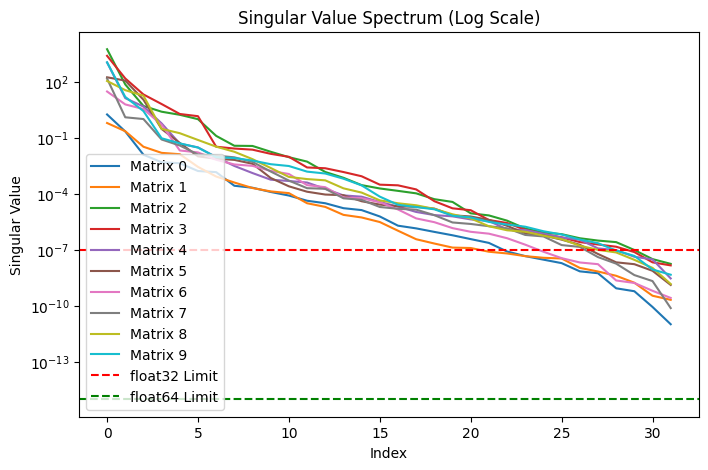

In [15]:
import matplotlib.pyplot as plt

def plot_singular_values(A):
    A_flat = A.reshape(-1, A.size(-2), A.size(-1))
    # 计算奇异值
    S = torch.linalg.svdvals(A_flat) 
    S_np = S.detach().cpu().numpy()

    plt.figure(figsize=(8, 5))
    for i in range(min(10, S_np.shape[0])): # 只画前5个矩阵示意
        plt.semilogy(S_np[i], label=f'Matrix {i}')
    
    plt.axhline(y=1e-7, color='r', linestyle='--', label='float32 Limit')
    plt.axhline(y=1e-15, color='g', linestyle='--', label='float64 Limit')
    plt.title("Singular Value Spectrum (Log Scale)")
    plt.ylabel("Singular Value")
    plt.xlabel("Index")
    plt.legend()
    plt.show()

plot_singular_values(As)